# 177/180 Fresh Top-30 | v21.1 Conditional Memory

**A public-state nearest-route memory that changes order, not inventory.**

The old public v21 lost its route edge as the leaderboard moved. On a newer
Top-30 snapshot, its Dennis route fell to **19/46**. A fresh current route plus
an identity-free conditional order controller reached:

| Gate | Result | Seat 0 | Seat 1 |
|---|---:|---:|---:|
| reserved market-option validation | **53/53** | 28/28 | 25/25 |
| unopened balanced outer | **59/60** | 30/30 | 29/30 |
| unopened full outer | **177/180** | 85/85 | 92/95 |
| collected only after the data cutoff | **46/51** | 20/23 | 26/28 |

`177/180` is a local counterfactual replay holdout, **not an official Public-LB
score**. The 180 rows are six newest trajectories for each of 30 scoring
submissions; 134 are unique episodes. The artifact was frozen before that
outer slice was opened.

```text
complete current route
  + 30 fit-only public route memories
  + nearest public-farm match at the current step
  + intersection with SELLs already chosen by our route
  + order-only front-loading (no new SELL, no quantity change)
  + bounded WEED repair and legal terminal liquidation
```

Runtime excludes team names, team/submission ids, episode ids, seed, Notebook
ownership, opponent private inventory and hidden current actions.


## 1. Diagnosis: the route moved before the controller did

The previous v21 artifact still won **65/67**
recorded live games under its best small timing ablation, but that statistic hid
the population shift. Against the newer route-validation window:

| Complete route, no learned market intervention | Wins |
|---|---:|
| old public v21 / Dennis medoid | **19/46** |
| current Konstantin medoid | **40/46** |
| current Richard Silence medoid | **41/46** |
| current `안녕하세요...` medoid | **41/46** |

The first-order repair is therefore a route refresh, not a more aggressive
threshold. The top three current families are close: Richard and Konstantin
differ at only 110 board/market channel moments, while both are more than 1,200
channel differences away from the old Dennis route.

The four recorded v21 losses also explained the close-score symptom: margins
were `-41`, `-357`, `-2,671`, and `-3,378`. Moving a quarter-batch two steps
earlier rescued two of four, but it was not promoted because the fresh route
already contained newer market timing. On that route, unconditional early
SELLs reduced rather than improved validation wins.


,fit-only complete route,wins,games,win rate
0,old public v21 / Dennis,19,46,0.413043
1,Konstantin current medoid,40,46,0.869565
2,Richard Silence current medoid,41,46,0.891304
3,current rank-12 medoid,41,46,0.891304


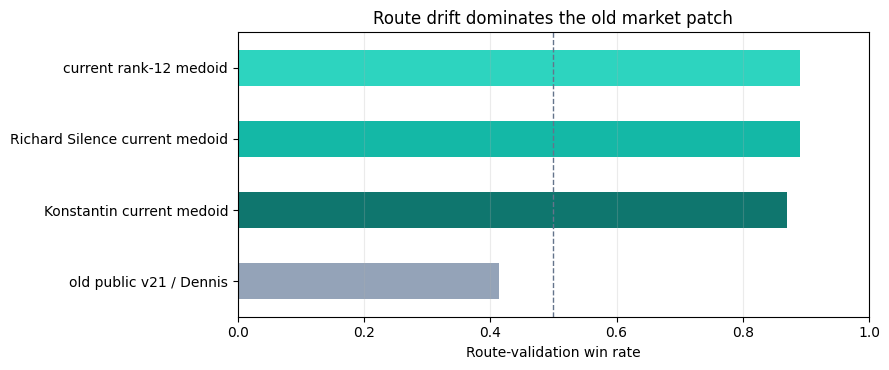

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

route_screen = pd.DataFrame([
    ["old public v21 / Dennis", 19, 46],
    ["Konstantin current medoid", 40, 46],
    ["Richard Silence current medoid", 41, 46],
    ["current rank-12 medoid", 41, 46],
], columns=["fit-only complete route", "wins", "games"])
route_screen["win rate"] = route_screen.wins / route_screen.games
display(route_screen)

ax = route_screen.plot.barh(
    x="fit-only complete route", y="win rate", legend=False,
    figsize=(9, 3.8), color=["#94a3b8", "#0f766e", "#14b8a6", "#2dd4bf"]
)
ax.axvline(0.5, color="#64748b", linestyle="--", linewidth=1)
ax.set(xlabel="Route-validation win rate", ylabel="", xlim=(0, 1),
       title="Route drift dominates the old market patch")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 2. Chronological protocol: three development windows, then one outer

Snapshot cutoff: `2026-08-06T02:52:14.073233+00:00`. The download contained
**515 unique episodes**
from 30 current scoring submissions.

For every submission, episodes were ordered newest first and split as follows:

```text
newest 6  -> outer (never loaded during selection)
next 3    -> complete market-option validation
next 3    -> complete route validation
older 12  -> fit-only route donors / public-state prototypes
```

One real 719-action medoid per submission was allowed into memory, preventing
replay-heavy teams from dominating. Route and option selection used disjoint
windows. After freezing SHA-256 `d9dc24ce5429ec62...`, the newest-six outer
was opened once. A second current-leaderboard download then supplied 51
team/seat-balanced, post-cutoff cases—including newly arrived Ben Hamilton,
Subin An, OceanMix, and other submissions not present in the first Top-30.

Replay opponents are fixed public trajectories and do not react to our
counterfactual actions. Results are therefore policy-screening evidence, not a
claim of exact live-LB reproduction.


## 3. Public research lineage and credit boundary

| Public work | Mechanism used or tested here |
|---|---|
| [Kaito v20 — 159/160 vs Frontier](https://www.kaggle.com/code/kaitofukami/159-160-vs-frontier-v20-weed-slip-recovery) | projected shed, identity-free safety, bounded WEED recovery, exact artifact contract |
| [Rayk Kretzschmar — Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta) | complete-route memory, both-seat promotion, and honest replay/LB boundaries |
| [Rayk Kretzschmar — Rank Your Agent](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-rank-your-agent) | current-engine and both-seat evaluation discipline |
| [prvsiyan — The Moon Counts Melons](https://www.kaggle.com/code/prvsiyan/kaggriculture-frontier-the-moon-counts-melons) | market timing as the differentiator inside a converged production basin |
| [prvsiyan — Kaggriculture Baseline / Soil](https://www.kaggle.com/code/prvsiyan/kaggriculture-baseline) | preserve a coherent full schedule; avoid isolated edits that break downstream labor |
| [beicicc — C20 Exact Replication Control](https://www.kaggle.com/code/beicicc/kaggriculture-c20-exact-replication-control) | exact-copy control and legal terminal inventory discipline |
| [flexonafft — Adaptive Replay Agent](https://www.kaggle.com/code/flexonafft/kaggriculture-adaptive-replay-agent) | field/market channel separation and actor-local recovery |
| [Georgy Mamarin — Daily Live Meta](https://www.kaggle.com/code/georgymamarin/kaggriculture-daily-replays-the-live-meta-report) | replay memory is time-stamped and must be refreshed |
| [cjlcjlcjl — What the Top Farms Do](https://www.kaggle.com/code/cjlcjlcjl/kaggriculture-what-the-top-farms-do-a-live-meta) | current Top-farm composition as a population diagnostic |
| [Muneeb — Cow Ranch with Fertilizer Probe](https://www.kaggle.com/code/muneeb2405/kaggriculture-cow-ranch-with-fertilizer-probe) | exact submission/seat trajectory provenance and engine-mismatch caution |

The deployed field/labor route is a real public replay trajectory from
**{base['team']}**, episode **{base['episode']}**, source seat **{base['seat']}**,
selected as the fit-only medoid of {base['fit_trajectories']} trajectories. Its
action hash is `{base['hash']}`. This is credited public replay provenance, not
claimed as a newly invented production plan.

No linked Notebook's compressed artifact is copied. Mechanisms were independently
reimplemented and ablated around the selected public route. Downstream forks
should preserve both the route provenance and these mechanism links.


## 4. Runtime model: nearest public route, then a set intersection

Each of the 30 fit-only medoids contributes two identity-free sequences:

1. a public farm signature at every step;
2. the set of products that route sold at that step.

The signature contains only public consequences of play:

- farm-hand count and actor positions;
- unlocked quadrant bitmask;
- crop, animal, pasture, coop, and low-weight WEED counts;
- public yield-unit totals.

Distance weights labor/unlocks most heavily, production counts next, actor
positions lightly, and stochastic WEED count at only `0.25`. At runtime:

```python
memory = nearest(public_opponent_signature, 30_fit_only_prototypes)

if memory.distance <= 48:
    predicted_collisions = memory.sell_set[current_step]
    collided = existing_route_sells & predicted_collisions
    market = collided_first_preserving_order(market)
```

The model is a one-nearest-neighbor policy memory, not a username lookup. The
30 runtime records are stripped to `{index, signatures, sales}` before
embedding. It cannot see the opponent's private shed or current simultaneous
order.


## 5. The safety invariant: change order, never inventory

The first conditional-memory prototype predicted a route's future SELL and
created a new early order. Identification worked, but intervention frequency
rose to roughly 28 preemptions per game and performance collapsed. This is the
same lesson as the earlier neural SELL-uplift experiment: predicting an action
does not establish the closed-loop value of taking it early.

The promoted controller enforces:

```text
ordinary turn:
  same farmer action
  same hand actions
  same BUY/HIRE orders
  same SELL products
  same SELL quantities
  only the order of existing market blocks may change

step 718:
  legally project DROP/PLACE into shed
  sell all remaining products in collision/value order
```

That constraint is visible in the development ablation:

| Complete option on current Konstantin route | Wins |
|---|---:|
| route unchanged | 51/53 |
| global exposure order | 52/53 |
| global two-step quarter preemption | 49/53 |
| conditional 5-neighbor order | 50/53 |
| **conditional nearest-route order** | **53/53** |

The selected memory made 682
actual order changes across 53 games. It abstained on
301 of
12614 SELL-containing queries
because no public prototype was close enough.


,complete market option,wins,games,win rate
0,route unchanged,51,53,0.962264
1,global exposure order,52,53,0.981132
2,global 2-step quarter preemption,49,53,0.924528
3,conditional 5-neighbor order,50,53,0.943396
4,conditional nearest-route order,53,53,1.000000


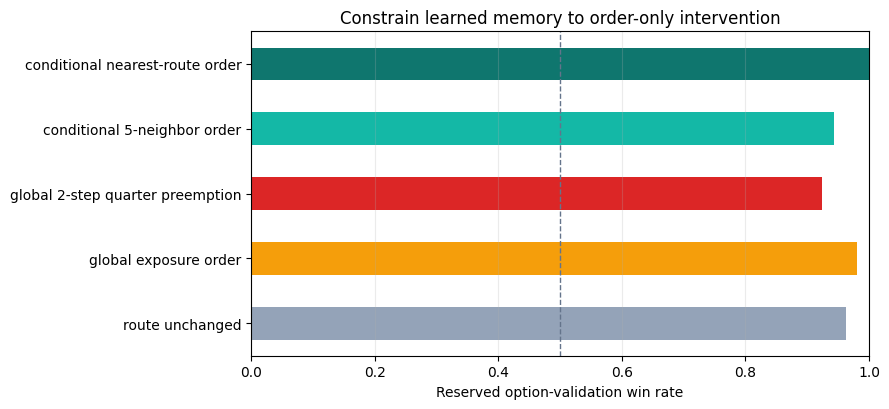

In [2]:
option_screen = pd.DataFrame([
    ["route unchanged", 51, 53],
    ["global exposure order", 52, 53],
    ["global 2-step quarter preemption", 49, 53],
    ["conditional 5-neighbor order", 50, 53],
    ["conditional nearest-route order", 53, 53],
], columns=["complete market option", "wins", "games"])
option_screen["win rate"] = option_screen.wins / option_screen.games
display(option_screen)

ax = option_screen.plot.barh(
    x="complete market option", y="win rate", legend=False, figsize=(9, 4.2),
    color=["#94a3b8", "#f59e0b", "#dc2626", "#14b8a6", "#0f766e"]
)
ax.axvline(0.5, color="#64748b", linestyle="--", linewidth=1)
ax.set(xlabel="Reserved option-validation win rate", ylabel="", xlim=(0, 1),
       title="Constrain learned memory to order-only intervention")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 6. Frozen results and the old-public control

| Evaluation | v21.1 conditional memory | old public v21 | Paired old loss→new win | Paired old win→new loss |
|---|---:|---:|---:|---:|
| reserved option window | **53/53** | — | — | — |
| balanced unopened outer | **59/60** | 42/60 | 17 | 0 |
| full unopened outer | **177/180** | 123/180 | 55 | 1 |
| post-cutoff current population | **46/51** | 24/51 | 23 | 1 |

Full-outer mean margin improved from **3,560**
to **13,049**. On the post-cutoff set it
improved from **-841** to
**7,336**.

The 46/51 future result is lower than 177/180, which is exactly the drift signal
we should expect from a fast public meta. It is still a substantial paired
improvement over the artifact currently exposed on this page. This future set
was not used to change the frozen policy.


,evaluation,v21.1 wins,games,old v21 wins,v21.1,old public v21
0,balanced outer,59,60,42,0.983333,0.700000
1,full outer,177,180,123,0.983333,0.683333
2,post-cutoff population,46,51,24,0.901961,0.470588


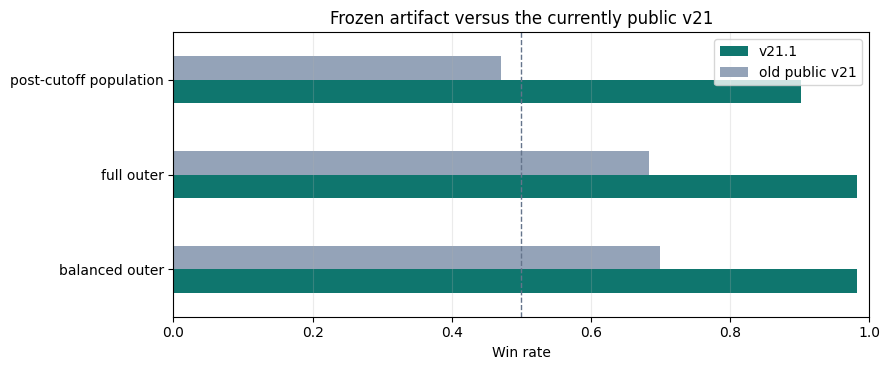

In [3]:
result_screen = pd.DataFrame([
    ["balanced outer", 59, 60, 42],
    ["full outer", 177, 180, 123],
    ["post-cutoff population", 46, 51, 24],
], columns=["evaluation", "v21.1 wins", "games", "old v21 wins"])
result_screen["v21.1"] = result_screen["v21.1 wins"] / result_screen.games
result_screen["old public v21"] = result_screen["old v21 wins"] / result_screen.games
display(result_screen)

ax = result_screen.set_index("evaluation")[["v21.1", "old public v21"]].plot.barh(
    figsize=(9, 3.8), color=["#0f766e", "#94a3b8"]
)
ax.axvline(0.5, color="#64748b", linestyle="--", linewidth=1)
ax.set(xlabel="Win rate", ylabel="", xlim=(0, 1),
       title="Frozen artifact versus the currently public v21")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

## 7. Failure audit: where the edge is already thinning

The unopened full outer lost only three rows, all against the Seb family:

```text
episode 90300722 | seat 1 | Seb (allegedly) | margin -15391
episode 90295581 | seat 1 | Seb (allegedly) | margin -13621
episode 90289799 | seat 1 | Seb (allegedly) | margin -2380
```

The later post-cutoff collection lost five:

```text
episode 90337286 | seat 0 | Ben Hamilton | margin -245
episode 90339454 | seat 0 | Seb (allegedly) | margin -5823
episode 90337991 | seat 1 | Seb (allegedly) | margin -4117
episode 90340128 | seat 1 | OceanMix | margin -1838
episode 90339385 | seat 0 | OceanMix | margin -4061
```

Ben's `-245` is a timing-scale miss; the repeated Seb and OceanMix losses are
more consistent with a stronger production/market route family than with one
bad terminal order. They are intentionally reported rather than patched after
seeing the holdout. The next model may use them as development data only if it
collects a newer untouched outer window.


## 8. What this does—and does not—solve

What improved:

- current route refresh repairs the dominant stale-route failure;
- both seats are evaluated separately;
- 30 routes are used at runtime without identity branches;
- matching is state-dependent, so non-identical route families receive
  different order choices;
- no ordinary SELL is invented and no ordinary quantity is changed;
- current engine `kaggle-environments==1.32.4` is used, including locked-tile
  movement and shed-capacity semantics.

What remains impossible or unproven:

- an exact deterministic copy receives the same logic; permanent domination
  of the exact same file is impossible without exogenous asymmetry;
- fixed replay opponents do not react to our counterfactual market changes;
- a nearest stored route can be wrong for a genuinely new policy;
- the field/labor channel is still a complete route, not a learned closed-loop
  optimizer;
- post-cutoff performance already shows faster decay than the original outer.

The next defensible step is a portfolio of complete field+market policies with
an online public-state value selector, trained on these now-development losses
and promoted only on newer submissions and both seats.


## 9. Exact public artifact

The submission artifact is **428,598 bytes**, Python-standard-library
only, SHA-256:

`d9dc24ce5429ec628ead0621a160bee90725350683d7dfcc4686fcaf511f3aab`

It embeds one 719-action current route and 30 identity-free public-state/sale
memories. The final cell reconstructs those exact bytes, verifies byte count
and hash, compiles the file, creates a root-level `submission.tar.gz`, and runs
exact self-play smoke tests. Self-play must tie; that is the symmetry sanity
check, not a leaderboard claim.

The competition submission is created from this Notebook version's `main.py`
output, preserving Notebook linkage.


In [4]:
import base64
import hashlib
import importlib.util
import tarfile
import zlib
from pathlib import Path

WORK = Path("/kaggle/working")
if not WORK.exists():
    WORK = Path.cwd()
MAIN_PATH = WORK / "main.py"
ARCHIVE_PATH = WORK / "submission.tar.gz"

_AGENT_B85_PARTS = [
    'c-',
    'o|V*_NtY((V2C6q^D$pvM|EAUXsa8WBWAY)~#h6a+=2$KGc@S$}Qwe}I!0IV5$hx!Q<1Bf|XGzy6iis{gM3*#{Tvm>z?RdH%Bq!g',
    '9Ux$G80;zW*7SjuRjE**VQ(`;Y0^m-',
    'OHN{L}ww;fH5Cwf`KBX*sx@?|<ST`*{rGAU|4m@+Wow=fTSM|LONncs4Kp{_{u9cIV^%&%uoSKS^q)_CJYzw)g3OKYy{!*iO<vKO',
    'J1sV|p(iV%z=>=)e8{cUb@T&(#eQ`_Dd$<DZZInRAl#C$ZCieDh}@b`V>3{Kvi>lk|9T{`}8l@`Em<KM?uPTl?7l!A|~|m;bzZyq',
    'NL5{4>GJ|8(^4fByBafBkdx!yr!o?99Y&VBe>G5Z=G9Pf2k3zV^-',
    '3{l0#jkGp^V`N!xp3t>8$|Dpcplm9*krj;Q7dGp_v{h!tQnQ4OjxBGwZn)rYIXxYd=e|~=c`}_aw%dtl;YwkTTpW{HG2(9Qe?&WF',
    'BlhaF=Eg_XNFgPf0Le5#PSy^5m<*Vayn<T1o@=+8VRpQjVBty@qZ~>+jW!Gd!O&pw5UhH&;3>Nm$`al1L>S3APEi8ucCaa9KsuhZ',
    '3)N7P`XYF%GIn3BzY9!+^zP@P!Cj%p1oo=@l84nc@hdp%@F;8TE8w2f=#;(^Vqgwvk?<)guuvNf`eiLqX&PwWEx_f2XCMRKSx6O1',
    'iH|m>8xf|y?9lQl%ij@yH$Uc|mwIAe78*OHjyFq5lyxY;^-',
    'pQz0?Qh?U%ZQTC@lm#Yd`2Lpt%W>$>NzjZ=+asz?Bh8o(x+@0RVL~7eZR0hEUwI#dL<c97}Y&HA25xfDkSDGAGYn)ZeM*B5^~ta9',
    '$QkdrXIYm|Ai`dl~C!d`AU6t^Cyr%_Go4rK9_5xx(5sokA}~<0y>#kzhqErZ1Y;lcj2VdoSEcv<0JA49Tv21<3@@7evRtgtIS|OL',
    '5HpDt0d3wOhM82f1xU*gM;AFEY)ZkP2ADE@7e^s^xUz3tBlyYTnVy)&TToJp-',
    '*e&yBM9EZ>{NYbXz#vCNKy~iw?djRqB2|j}ohWeZMGyJOh_j-DgUa*QJt5;`Rk}>KQA0jA)<QWj)8Q+jl_p24gz+T9s?<BrKV*-',
    'wa~K3<+-f7wTG5wTnhotB}>)ZIhII4$mJHvR?RoT^yLyHV~O>M;fQMK1ieMu87v#p^9}|=es1&Cs%tD^Hqe!Th9j5Rd=Ui95p-',
    'IcOsBj)V&j%m|hh3^bri`<lS(2ra4gxO<qM$!nCAq)DpU$DspjK1?v_^pf)Z*Oj9fvj^!HAmU`5C`xA#<hQg!oX)%rVCx;;$&W!D',
    'OlWzV(MWyzz<Cr}nIweEzeC~awbbyg#iQ34wU9)LUeAc|xbHiLsYWoU0njEfhvw5>egpo-^3u$lSu|3C+-',
    '1BLH@v@kf_<J<q+!TVJZMM3VZR5ME?C1AN)X1z!4S8IA8cHG8dc!mXgGv+4<IZ#Ip1aYNUOT5A2fmIOO}k$60tjOLmIyCo$RVHRS',
    '?tVz4r0$e2uX$C`SydFj870=z?=QrOTNa7^IxbHT+*6Lmz^~5_dG%^N~DOp*H?x&GeKo}R!wi!+Pe7|-UoY<-',
    'z@X*7@s<J+hTAt@?+X~fMY(8OESSh@8T=tOp=#6eW}vxgn4+ka2|2jx|EFYRGQg?(oP$}?K+!RK^AzncK!Cr(bjD3QFQiVwyZdZP',
    'klbsxWiwln|!^G=~_iV3B;9w9zEMm9${+^jxPg0hNt#Zl&3Wwsd<RhC}AWr>LG<j3=LLTGCbViefPO!vE~q~;E>hJo#qr;Z}%Ov&',
    '7N>kSEt!IxBo(+{ka0}7MDy^oo7pi=c{px6Is6YSnRNCcMMyopQNik%c6{~S7x8#o|@4s>3%lerCpnmV0xvcLQ~7g*Qj)72ByUZT',
    'ai|3&BH{g>^Li+|3b}4Z5pgg-}StbjV``SH~9vdt*`~uj-RE8E)cK7hsTiG>PFQs+BztvO$-;S@V-{9`O_Y`8n%&+pB{jfHWY-',
    'r*kDVW{=MH;1lNCVC+iEwZ>A#z2xBx^|Ah*Ry=OP^w&m@Dd6M-*|FN_{Gi1#|-*;-',
    'l#YNy3DjIuxko1%$(!4Kz&Yn<%kl+A;#0Z&v$6Tl9#Vlc8LAroAxVuwFGw0JBo}0Hm+I+Zk^9?Q%u7&W^N!73#Ctt7t%_n9WI-',
    'x)j|Ck2UECvmB)wr$t$ZcO6FF^Ud%;#u2zYjWA({6uPOJ4w_Pok@8t@uTc-Sxh3Z~Fz!&qbx+!ZvFLYQyjI<iQu-VQW3?W=WSiAG',
    '^tOzC4}pi^h{(!t-l?A#P_w>oKDmg_N2X%!uyy=zC??ORDWW73J0!Ly-',
    '$&VcJ|gpH6?Zt479nf<3x?2S<b!U0SY`6R;cArhPJcG9YoQ=>=Zf5r@*Fuk3c&s4VVVk{0e9>K>F}qsLp9*J^l_Clj|t9N=_glpy',
    'FY6ggYXNBU+vuW#KAR3X-ScX#Tkq6kzY*16XL=rrM+7b5w#L)a}}N($4RzqR{^oT;YK@bgK1qdqd<?W@!E_SZXEnZ@3d-',
    'd<X6HHEGIrR9J3?aCM`#~g-',
    'o5F&b?B&JRCHFfJ=Q4o5*QlM(U&T7rSi!d`+8$d*KL(HPgD6RtWJ?dzU9YMBqNqKR4eSwe2Hx%}O@xg;zYV)ygOFwR=2Ck+4eCi#',
    '9w<HZ8d@iVEQ?4l$(MU#GjUTUcv~o<wr#kT$YCYn6^ogK_f$K0)Nvz~*?C(Aze4<-',
    'eXw_`uemwHdt5Gcjs|qo`gUf!;Zq2S3_IoV+I(b&t(P$xb)5`{#>7B}oN+fnjzBi=6YVnrQ`<20e>=&;OuSgNjKiBbz1+g=_nG7(',
    'n{?QBcigY!MvTd1_dxs7h2*QXf@9fvEF#0`#6=$(zJ2-5TXIvZ6L?-7Jf)*MMa6PZO9mRTb$vk;?M(4KIi-',
    'B)5Rzo`zbg(@YA$WdSU9rz~ZFKV-',
    '3khoxoEW004k?JLl2LFT);jHwuOqPi(1n*qVNdZkA3#|22r~g5%)l9Zj5h4;Mf?uR@1KCs*e@J1NS3$SM#^XAabIfisHmW3^<dNW',
    ';3C%6-v*uu%}Bo6ydH12ekF%K)G+Pd_`CN$z4=oZlORDT)4Mlbw2yJETLfBZgQSQnM?H!k{}>kweu-nKll$g4rm$&TY$`G<a^-',
    'w$ev<B-!j)q6>$yjM6VNL7jag&P;N(_;A-',
    'AL+=BlQw&%_?IJ^b8%KOZMX8}`m#iv$&_Yi5ThM4Z6B$*A6(c?>b!ztV!GO=pwAD;k>{6l=r+8Bd(58u$M~?H^j0PkuZQZ8;yQFQ',
    'M{ayt63lahaHP#f|hTeBN3&e?uJED?j{n9r#+3aCy)p+N=FNUeo52U7gx>!u+hEALlYVoXsk!;QkaUUR4Fv;4ewodOiqPJ3#hZXQ',
    'jEM+^WMjyjN77q0I0;EWg*lG%M3H@oLbT6sJS_nyv<n-rSCfH%3S^^-eKTaq6rOkE8JfT}n@8H@5rKa_}SBv;H9c-',
    'jB{|BIIpC*aujl|H!D4SI0@enmRK=Zpj8<dp-s%(I>d)m8SAzm&*vqPx4-)CqnSP%(2aJV$Ho{konh9TqM!q{^pb>-',
    '=i?F_awWU79H!=3S^=t+M~k=co1i+oekLMqFslEHOJkD)I#0=Z2J2p-',
    'UInixZE5^b+#RH+l6qXIfr!W;dUJhzk+UNuO<;#)s)02$25NY3w4|`;iEk`T*zhNv>-',
    '0d#il><(dSOHSq9yS)|u=LHqgx&TUTSnO73EmadUZH@;rgK?)s4HY~b$V+1OQ~!0UIN{kn8AN5j{H($D5mnc4i;vQi;7V{S2Dvaq',
    'ue^Vafltyf~ESGzpA_tj;tW=iO8A7?A-d)5#lCg7desB<oxy?eb5ev(^@etq7JkvAebLUt-',
    'O4ZI*UnkV<}ZP9kM{(hL>%jelScjFyqtTa_5uHu>SU0bpE9Hr=Dz~rZ;sB6ZC&sLcH+$<7EE<M6|HHl{6r){roRVo;ShV-',
    'R%ea0E<SI64b&uE?OeHuv*)&(?OG+WCpUaJ!4_6?mPx`?TpBS@eALS3@j+M1Ub>-',
    'bSYuU9TyA`uOsraD<wF?04BA0ShFHI1gUn)qb9F^=>_L*O9RN_MSZM$&n7J^#9#qcK=fYJ;G#0;0#Fdmo1LV;mONmQ37U4&=8`kE',
    '-=5;L3WssO}Jj;qp1@8kLq;lON^!^6p2{qt2H`Bb^+}lB*W=$(Ub$VTPBwvrc(48}5zfJ(1G9bug~saBPmAlNJI9i_?$EI88>KdA',
    ')9galM@)xYmb{?EBb6HaIzq%frByml#OSRd*shdYkp?IC&czMjLJPv$UK2g~Dg&=u?X@=ZpPO3#$__9yhJ*HF}W^XMCtfWU037!!',
    'k8T<&36g)d_ZD<-lJJ_*Uul9MvD~<-vrXCw2iz&3=c-#+r9A4)ww;zQKOD*}C&qI-cA7n|en4_%GCHhM`mnBbPQOu&>7uPKq1r<t',
    '+~Ez)MH(zHUBv29g`dkIyHrRp`}?h$`@wn(OVo?+K?5gb(OfCgiw%q`u=n2+v^m!UhXiTOZr%8N6LPMW}nFjv;cGAp6gwLMFB1y3',
    '#fT^2BMKT7MR*=VlBQ>Lg(u22~H<Z4wERRux{lr{26YXod9T0!!|TPSX3b`Xyjpx726_?+z)#@5n%Pb-',
    'U=bxN&i0ur#a|kZ_;R@5{W@sp9?i4H0IW?KS-MNk2Z$qS=I~RMX)lzMI*C;Y0RRw5RfCYMgQ1DUR5LgyOz_D>WdF$s9#fC*-',
    '|dYFG})bZgmmCoPKBFI}#1#mOPdo5iHjN%XZ)(TUA^oF_!NvfQmJmEa@3yxNKzRI}iKw*+K#qMe4g!@V}R#%^ckRjByQWu>L|q*-',
    'S^Z#24Yqh1xdVY&GQAxy7e1iP~Y*Y?SamDUVcon%jW9jc$m->GtbSe-uRqdCzgo4T6s7$45BwNKk`TPg+vKl@eHCgVOiSqLwp4KQ',
    'fEyDzoWCu&-QlKogI>-',
    '*OnZf}xbUhrK^guBOUb3MS&*^<rknYHf18saBOLq7IOB!c1jv8S=hz7FViK3Z9lI{Q7)jbf!#JU$vMzl%nOEnkm*fE*Uw*vR0#eL',
    'P%;uobQtu$5ZAA)6}1SGvrPn2GL}aj_zG_bo7p*VBoAZqHPIS8|~x8J+~?C8wRB?kp;1_p8d5iGVQouvO`<N9I+%R2Z;$1TO7<iV',
    'zieUm2kpQrT6mI?{RZAB$75I~R{ucnyt9jSD6I>_6Kl$LpktaMM#$QAcq89yBz%g&qP)TyWFU7s`p6LtRwzphRDWT*X?hKF)E5Zb',
    'TdQ0=PfFBRz269NPhZxGno3iwsVn9puflk0^l83HP>is8%FQn~zah*aMKztIXbut~W;p>}>f<bfHmuK9GSNyF9jq@oj5fIwmvYF2',
    '#V5I#n+l!fe|ChOxu}9(2g(`u1TTdM`2v@ussfn_#kZR6m-3y48--rwDTQ$<2F(FD(nT<1gPLM!x8x3~60gBjC_<OL&L8AA5GzUp',
    'BAM_*zZ_tgUQD+^M&UvVq^%4ioc5)TWbgH0(bCk*gq0;)t|gyUk*kd&Pu-P0k)E&Ld-Resg>)UlK$Ilgkul-',
    '2+jg>5gvgo7VX|3<((0XoV_P@?`sFD(UBaYpYR*2v!g5N9@-{1~U6{Pa((-64xh7x^<pEqHd!(YWKV-',
    'i>yy+6=8GWb~v2tttxB9!=6<2#UGvBCWwCglB2>m$na=yD^<SoAjOYayli%xElCK5W+RU%;4^T@*{wDEbiKU3-',
    's#N^zbz=Jie1O3)NQhq<9ey6pQn#HwQ+ywETkNmdirh_zEe5=uyQs0xuIJ1GTtAj=C9ouw^%9&i|+<X=a)xTY8-',
    'LjjLdyif$)7tYr-',
    '1y*c>N=N9Sy<ovE_wcE=%kq^8VMqGye?MKon;s2uz0W(&e%5;S|5Ihjl|M!y6%w2(Hx;hSo4F>9VCWyi+gY*)SLrBLGAcGVs|3oE',
    ';QC>|J^GY<5;JS@_>-G!C7wrj{-a=UClDO~5ejafj?gIi<tLmkJbL)!9AcYbwS&V@yz%#N?WJ6Cl}yV?FxQh=fkas%_-',
    'TkU#Bj_iZ&z0;K;cRwl{rPp~-',
    '+ygCcJqhyKw<)L(m$uL8)vQFx^~0=tV4nM%dR5f(?sg+L9sY{w`~IF>hVJNK29!5;508+?@BVqc>o6C3L2T!ZUvmTWoUkH6d$#b3',
    '7EmT+9lFV#7QFs=*9K``s(#j9QVC)B21;JTziu|AfSZ8r^(@JI`@(ALL@7os>*NeBuUnhnpm3k!=}vemGzK{f{ZQA<57j(z{Hn7`',
    'iNuiWbRX`a)vWL7Zx#I%4D`T|Jw(`>`cBRqPM=06ukSZ^CLeg~h?;e$lh_Q#;BnH29wc9HAC2Iv7aw&MF*TJ>1tPLVxG%dCy>XTs',
    'H&(%t&hZ+GQ-9n96^Kp-H-&g)`nkSeG~_o5vC(P{(hac-T#-TZ^D3xqc=Y_SW-',
    'B*^PkC*!z}xlNK>mi%m77`3{0BAfm4iJ)`(*Soj(HLQ=To*U&K&eKYConr*mMrVLym!SD!-',
    'E5$?&w84I3>TR|bK1oC5dnG8NC~%1b_i>xP8ao0X2AhF5iRKCF{Td&L2vj!c?-',
    ')EZZ{!O3&LxUY@}Ao$Fj4GNe&7DyUTh#9UQGg<kVF;1%b_38R+x#!olN=rWuNm2UJR}#vtDs5|aF&a&2=G+;Mzr%o6mlmMm*dSX}',
    'voYqacWbXxS16sDlf}=6Y;E$=)qFYP=%K&DhFQ1)tCZ&!q_hg-^X`H|_T}wa2@=nz!r1(DyHG-',
    '64nYX5&9ZfI8g=X|fC_RO=x22kKi&xaJgzRKUK=a8XoO1-',
    'GJ}#e|Csr*slShp1RRY@^X{+eMkl>OrQ~G~xx!A5_Hi`2ZP^KGoRYP?$Uo5~T5oK3VH4DQ9>^2{${<l%gSkEE&zmDbkj7F%Ho%vB',
    'N;*4ZGh;j}oj)+Qo2j_&cS7Cz?lUo$Qg919dVO32V_-&C(-=j5mB7d8T?R%=AtyqD7&igaQUF<9vmH&XK7-',
    'cjeycqNsaphBGMp0!V@e|Vdi2=t9qpooy8ttL;<E<k5?qR*52@ibQ@Iw$Rew2xBG)yz9=rMr#SC^PIG)7lje>jo&g;aWMw_e#3=9',
    'qNx-i|pxRwD=%5?GP@KVb~T2@#4^_Uo{JK|DgV8ycQ=Q<_J=^Wy_rd3T}#SfJB%~g;|%YM7>T^rvh(Yb}bs)$-',
    'FHt5QB7(DWEP*+OpR%=<CKqz*r9-',
    'Dmon%(ZuxC@Fu3hT3+<Fak*c=mFwd*#d*3(xWJKFN+he!A!{xhi&QFtyS9hh`{Ks{Inav1e)Ic?}TTPa5dWY2HsfqX>RfegNsk;F',
    ';s#13~Q0*dnvR47&`{F^7rTUD4KO;-n!c97es^Wst?-',
    'o+#2UnRfS)TWW6@^lmxcXLo5x;~OGYfO#n(qg!j;Ijc~U3dYq<U0SmhJ889P_1%Hmx~;nFJ$<lwW1^xNk1gd+jmvKDCBLlJ*vINq',
    'seGP$_i_6A<$foM2emS0wxue}tnttCGZ+;|X#Kgktx*!M`h0S0nwyIo{K_#R**wQHFY9Yp8_zHG%4xeAxMX42quCw0Z6v~pyh!d6',
    'Xn|UYf=9p}%(#vx6hy39@l+=$EHd~tyXL3od05@nD}Mb)vvUr0r&X-',
    '4L%&h2DsfZMe0kh=nnB}n%_U)Rv!<18ndu*tutb%}XZMC5kNUE0@0=+1yl=~0kK9EESZx4j8o0urAg^{yaGkwflq{~V2Bzf-',
    '5n6bU#=*H)b<sdK%BcI9dQaq+!Ok&YkJ`P%%c6F4f_Ct#UMhANWShJETw2(R+PYnkpFu&JZ_0>fg=NLD@hY=GCZXmRc^9QB==d6o',
    'mxfkAuSjcuuMElF94ak4F`Z#*-',
    '2}h1@+j?R7f{cx^y9`OM6n1*(c;*z6DENCTuBx`oR{F04KZuboZx(UkN663#rMWVd)rzCZqqlWyGCe^E0qWD-',
    'vvCOC^v_x)AnUtd-ZD3y<eldv%A@VT>#;+?O&r_9zH44hi3@8X^5-',
    'U{;Bs{OyNiRFISNM?I?A+S2=ujuZM9FoXdS8yOfrn6ZkxQjJDDKP@Z?4_KvLYnHP;qJpCeWw8#8MAQ)w4)ZwVm_?&~=W$*%m<c`n',
    '-nt)$SwRc1t`gGdu&}#MejgbJHNLM<PSYD2=5bCd{yED08f}|$ze)%!26Hlf#(*u1DFthV+`PqxDdTWdM!-+iCH*R--',
    'tMct$ue6_~OmZ=R1l+~3RfP|eV97Q7ouWBLkpN@T+pemGLXHy?Kc<UqtuYu-qPu*H-^-',
    '}X>o;B}AV2C6i(oli0lskA32b4;y4TsBYNB&mTZAbZ!DDdP9#Spa?pYh7TI_s>%dg@M)2gCLC|t(LWCIl{rYX1O1B?LF*y{Tc2#9',
    'E3r0vWgZyhDLV(<8YN^@mz)=Q&JPKf6Z_GoVi0ZfTf^zAp7vGu}&*GsJUY29H>ZmTgJ7TVE{D{S3@`y6v@Go<ECX2lN=lbSCMI|!',
    '*^_ckp(awJ~IOwIf88~R~Aqi>{#SL;*|oF`5B4z%6<T74A1ta96CLX(HKtKzy7U0ZTP@xxmsb=fM{(XUmBD~LpQo!^zmLf$YN)}I',
    'd1dw_-Q*PV;#mXV4>oqut~>3u}YyTg9klQ!PI*I%5-',
    'EPjOVabfg@IuWi^Y1hF19Hs+nKUdJ3b)}u_afe=W<WflCSsRJwi%6LINgo>z-TdtlwH{vT2D4k5--',
    '<mXyMEW`=W4)4Az()#+GUp%axaYR{+l?*{Q+}Cx}OX50cC)8D>^_8nvl|k@QdoK3g;#B=5Abd#ZPG$3=S??vF@`7l%YF96&&is%)',
    'G@$M+Y5o^cQOLDmhi9pZBx|-9X#HSmc<MxZ&aLdsu(&vW#pm*qSmjZv|%D8TUV68r}pQx+^>Uv|h6vhrX(5-',
    'jIuY;o%kUnp<p13%xF1x-UV}P~H%>f1%XE`aJUkyx=9gNiT-7+|D-',
    'jL3a918<`*9(0yeVYHf2Q4kOX1HZSVf*Ln|gi}$93`I;zBm1aVXcWirQ?2Bsk!RE`N4OJL4H|KR~+YY2dek-',
    'X*IBfSX2?cbMXz@PRsy!!1zd+Na`eUee{Y&qqA7@)?GHCpojmGB$v-',
    'dZ+VwxIW^{Tz0HQoW8h`e$4`6}`9;xGgB#r@;vy|*8pcC{zK?n+%S4pd=Ocnog~G-J*)27Cj>5&yU>o`-',
    'FipnGXrH;Ol6aZ>odP;c(x=nmPrU@!@3XrocQXdn2R);`5})9IyP^>XkWoiF3Nqz1f*A4^a!oQ4e4!e%o6tXVLYy()>hEP68%I7%',
    '!fxXE#oV)^s2fi(kh<L|8Y1cQ%{ZecsGXj%QT$*x0n7GETFk8SafcO?uxEDLcLW7nKtV2#@6RkSMc%V6kaT#KV<e}bT)P%f+0dMk',
    '2mwr}K{Q!iOAnqA+$Yt8!Pn;#p-GwD{ZpQCfwSEAQGZ}aUGFBX_%J-',
    'm;PdZ*epIJUfRl(KBmTDzMaoz_v!?n7Y)7>~!?NF}t3vb+H2zt(7py-',
    '&|mS0k*$9Y6ppnifk`uI_9=oClbQ_=llVtT3ALpQ;~mQGbT7!(b~z7DIOU;e6*mca1zhwbJ(FzIq+zXIROo+-',
    'fR8hv{rP+1#jn6TGFQ7EL)%!UVAfUb&A`&fT_c0ZriA;maNcmhbz~6L-',
    '^LJ7m*m^8yyZ?7+%`TXqf^D24hZ@tX_4{0PkI=cp6whe@2^;|Q6)dDVV@M#wiT*n}RzZS}rN+6<N8rB(Zn6FoZn$@tJ_wN>c#yce',
    'F>d9PR=!jLv|ce}UqK)#DY)&rG!L}Fo9bjC_NtF>4MeN1I$AeE}CXn0x@T4SAJk<ntrC|s~=7OHTDw42B%*;daLZC1H1Kg^}^nXO',
    'w$yuiKoqxk%>^1S(~{iqS@RQbj`^6E3%Ew-',
    '^YsF1bIU9Y*@p!vSJN@&2*a%UNmR9`;}r)#^n7?v7dWnABN=K9t(std3v#GA&vVDt8)95eIs;Fx`a)RhQ*vAgiFiZ0iiZu`q&`YN',
    'Pa-E+}TfB3=xLCi8)vx?TZuCDUNND8FR>~mVRXP-',
    'Amzgq3VOSm@ru6bwD7+Lyv#6i4YwXgqpnn_Zk7j;~nw{`>M*5<0oV|YQYRO4KE_pp9zuguG7hM-C-cb<i~=pU9|_ck4tlk_M#*S^',
    'w{4-B12{CddBZi_x$i$M7c@Z$<S<>xeZn1)k}$4|dJ;;yw(LN6F;BO;ZK5FO{!MmeU?-',
    '@wXET%E3rk~7QetgB<n1Vq$owF{o<)oeQXVfOXBt_(Yx+dpKvFk1&kWzwCwGL`7Hlquw<cbxGf8D)^w8%$20a}+9d?+PX0wmTrML',
    'jUaP-',
    ')aSu<VrW^k>gU2Pz^FK9Gugj9=(|xY!Pp}uvL}!C{(&FOLPr?NC(pa)y=T%LBEoRRgC1l19W4}E2+OsKid<2hrJ=S`7#(8MQM4ki',
    'S=gs!GUbD2;s+R+pFuy!aX7Ii!x79yPtC+WIp?v2QJeZHZP76=rQS#Nc}NwCZgWh7j6&a>f8@)jt1)~_2n^kw04w9TO04s<HpOaC',
    'yX|m<ZL7X4ds>YhFCgb$I1()*z@QrR_0lA=@X`6n-glWGuinmV8+<*S-',
    '6CU<>rFOh1Nu|5+20fV7?Y`K)atU98h61%A|`^vWj)`p4a%+Ymz-',
    '{w4X*+w&#OEH<&NY(;PG=a!`Qfw!U7kMM{AHGIx##vjKW@YWOXkJJsdZxwd%StVbtvTdm*fq|%6e;a4yj9I~NNo4Cgl`Sc6?j8O~',
    'FqR(~KXz9g@C%95L+I8{e@W*YP&kDQaqE8oizb-',
    'c9`HYC@Q`B2KhJITO0=EG(6tP@D*0s*IdHH*h_JeNiR2v+l!D`#uGIj8HjSB;l2-',
    'VA`Yc6?k+Cg_G5u|T|+Ptd*Uq5v@EWVr)@Ih5>?k3!(PJ5wV2Dw@qK8U4yx<dI7XuNaInsS|j*zbIg*^scIYq(VxL;X%)leHccfB',
    'a-`=ur!^^+T8!EF3+#HCalcV@o{0@xh5FT1Ur2M~Su<Hnh7MKe=Rcw^tXHZ`_<Pdv1@N;-%a12C7A-',
    '=2w*GJO1VB2V%H?QCr2o9F$>s)5nY9V{{*nACu`sEF6FbzQ&-#wlJ`yWk62MYt-',
    'q(#%+0T4|e782U9JkdU#!yGw{1HCTxtjWFH;o$m}Q#PpwbEpPj=Ry)125V+kM*xohG1q<z%7a-',
    '_%2mzGlV)5&?R8+>OQ7|QC3vz5`{dM<d|`W)Zi(hAp5KM945E{it(V~l@G@I2rxOJ}j&QI7|OKGL~?98QBF!a6sW@-',
    'EqRjfE|%K2$D9uX9N|o8_E|mgFG`dI-fAl4y<f?(>ZpKF`oc=<T=3y`$ASAFz9{!JmzNf8z?6Sn0^&hDKb_jt-',
    '<$>$x}Yu4xi|!ig@Eumy?3CSrZ(t7KXSj(nlwwilqr&3fa)EbLCS`~1G`b=;-',
    'EL;Hd`E^LXxgnU8NuKXKsbW`Hg1mG|kgM#Xpp5wA`F(%^Uc4d<YkjF&;(vFliM1nd}62;l+^pLd@pzQ*&u)l@YseVR&>pN=g)&y3',
    '$mvnUO)zM>mM8*#bSXVf;6Qj^%`|H*;xieWOo=-w&al-u3vH2wW^7FuN(&D3a?EbeW^dA)c_us1De`V>R-',
    '24}c{$t3>bTM6QWbXg7a`?1dSogGMF0RG`fm#!?03`aWY#&*wdbfD2ejYO&?0pp@$IM%!Ns%KuTjiZns^=V?A>l6YB589}v77wPT',
    '?p&Ng|fOU!Ffam)dS6Zh}Xyj&Xn2SUY7;fYv4?Cw|m@&`eaK=;<D3l2G{;{xBy?{c_8c6@D>clp1wphIy;71FPlE2snABd*6_Em_',
    'hZKAk>4nlpW8ULL-7pViof-txBNNFi^et)MlF5*9_!1fsnFY)0P<dS+IOFNEB5rA)@`-',
    'zO*>xR^dNs=r%z<qT)(8MI;@>Q46bs+yRkKXbFK3U>8)!&451xQS?+-',
    'pmV}wbIoI6OWN{|&)J~0C`RKj>wixYEu?jTEX7vC&JW%J{_GYOjH)n4aniX`o*ckTPA;YeYa~e9=SL+0v<>8Ff6Wxrrt=>7$8gTL',
    '8%6R#Fem@Us`Rz$rbQz)5y?A>4<|(;Ou;F*eE?b9VR>t826Yub|3imh7A=I8(jRi@=F{Rj^*}2~elOL{>PO-sjA{@(NBQdLQ>&Y!',
    'D7eDl}S5a6BVSn%&7NfGWhGEY!!}f-',
    '~QY|v@`B)K=;i(QT#X(K@)b>&4MZdXT;G;grkdXz8|FpUI5QOmej8QviLLMagV0N1K2Na)#U@P~x95nn-',
    'jA@-xgffw%+giE0h+!Otbur_`acxqHgI5}W%i+&K+}e%;)lBUhx-XTdnxc0w<vJk7@0OBqCpy;R9uifpRmRbw`nF+df~IbBzjwB^',
    '!3v6oYduQAjkA)w;t%IpoqYn1Mu2YM7iS)f!JMucoVzMl?}YvvJ05)U8GRy$@N>0aY<~9_xvgU?NK5SQ@HB!*%evn6F>OE~o)P=e',
    'CVSD>rVJS*{m4r7x3Z{JR*O+w6zzHz8{HwT1rPo8o*9*-0%_a!MzTLulCV7A4KLwKYq`d^ge3u~hU!#02Vd(efa-wb#&WF|c{gg0',
    'a-qILhXa6^nAi!PwiSPMKdHT9gpT)&voc>sqwH{unhU5CmU(tMIX}-',
    '2iQCGn=`h}(EC90GLyY_jbzdwjp_6X68M|s5GW8I&K50#~l2I`+%kJ6$IC{X^Ll+lA_{6+M`{(Rg*eH#gd7;LEVlSbkN!`LJb9{d',
    'QC5tR(><Wra%$LOx5#mR}&A#VWYee{@)p(!opTr_3s~f*EwDTR^`I^y8Gd{)uWZB=KAL9O87(Gj~e}j}ae?lC++0HCP@O3#&(vII',
    '=;b(i^KAU3VxXmCZGWW;J6tTxFsD{X0W~4dT**B)^UrlzL?#(j>j4SDyql>SJ+gIMxsL(pAry}y$jy-',
    'L68wX`$G@4E5>(je;$@*i&JqhnPDXouKa4={xw`VauUtP#|;S<%)EctvW$52={W{uA?+kG={H?DmUo3r>_tvAlr<Xol7qeZ`xJN>',
    'Cd&h^Tz1v4v@m4IwfGV|r7asM$V_z4TAg=hb24z6CByOm7Pk+O$O$#9zdSgnn)S^?NCq><Pu&%e%$ULj2872eA3yt{2zWTr?0qeO',
    'eVFZT0Wa9D8EF<hqA*BLrBIx>i)!wPfUZ_?IS>3U=KH?h+h^j6F+o(gF9@rFwSTHr2c@BO}s>w|97?<9l?{2=m#%b0~Z@{GD#_l&',
    'do^^$1ng#_O73v4p;$f6CcZ0}igAz{U_+3LXwyzoKqb*R+7X*eaki5f|d7~xXvW__&m^jNjEW*^bzy==9kf{AX6#m%+HJ%0lo?(N',
    'x0pw-fmr$mWkqXK`_-scA%O<r&w@9F~!$cr|0d-',
    'feJYpzP;c&wj+2F$ap&%CFdj(Z<%X{%M0&G8Mhy&%0@4x?yS`8BPpn^$W=+_uRTRo@_i9gMKs%BPjM5H4}^@wq#1*YZY*t5p-',
    '&5TM=L6Q@RXPSe9%)HA6UUM-',
    '{3a~iA(^Gs&+Q&)CM30O>bCH;S^?s{VB9&GQgZ6><gaB(gi+fAz?G{r^UIL`GZP1NR>RHoS@$=K{ie0F~eVU(jSuKGu>!*w#uw?>',
    'Q%Ae;K5%}(LgtN>po+F-Uf(nY(9Z|kGM$0`424_&ImK>i?~Zl!C1OrqLz(YPATx!$WBkb!G|WL4ayTj7--6R>&k+H3OL)CpqEZF0',
    'QQjtC%>#SJg)fnMTpPIB!?RR{XO%4JP)Cp<7PM*mr{icu9?yXREZt^1;@N_8H;8$YZ^0XZuqA*(sBOk;uVTm?@$(Eh;v7Ju|glg`',
    'ttG%{vppu)-',
    'vmjt#Qfi;AE(>rkJJ;s`uHfQK+*TFWn*pB`BdcQkff6a6uJLpcFUb@k_#arM#ptsEe_xOMWR3PdReTFaQxyld5fzu-NMCAEitMsP',
    'GDr@&%>lu%P=bl*gwTmP|PwENYX0u3jss0>Lux%yiZ4c@<N!okwuG{77dRps%;S?7z@?2kd@6r^3Wc;jDV6VHWb-',
    '>GH<yZN|<TU1?V|f4_z!rT&k~kejTddm#a$|3o2X5IOyvsv;$y)Jmz=R7VZ&{K}FS+uG8%=iPJ<#e7(u58cS2PinD&1ds?a*pX_-',
    '~sgjSeaHQpA&4G8lXc#LSNBSnu+qG(n+<cH8$;JbTdZC6Ei$I(}%Xp7gB#<HZ|kyFe@BZe!V{z~cH?F~A=#o4VP_rt^@C-',
    '|LFvz2mC&t?E24%vnv^wSS9U)IP-EV~dsS3UyC5<G$oK!1n+JfcY@{@s}C1Ki%p*imtZR(UZ}UW@+4B-',
    'R|gyuJ`bUbxb<&bVB`*(C1~3A=Vak!;XpB>}jaWKWYM>G2aTiIf357#qnOt<J-',
    '8wq$i=&k<PiRkBo*~juk821nRkgQv$J={z_^s3q@LJ56krpI-',
    ';j(7XjjaXV{(J7N16>%j$}d^xb3mUd>1AwDtt04?k~>YmTFy&a)lNk?Y5pOHdDQb(<N$EQ#$%-k0qd>kHM-',
    '<NTYyt984R_%Q7^W1}(M#WgJTRv(6{|46RKT<)jcJ#~UHdcU(i$^xqmfKbRyoAcr(5oAc`l1Xj?+w)4j$A0b>esWLuPNcmC-',
    'H!)Yi1hoFw_+RbKBLJrSh%2%@@3oU^>%U>eia836}mam3Y4s=4h*1_RRpTq4f8&Kc`>k6VAtzWa3Hry4UwaC9h?Px1uMewW%^Kwl',
    '4^=?l$U0w_)SlB5hv;8v*&A%{kl|I#BPmY;nost+Zm97^V&8;#Ob+8=T;(#A<|5X-',
    'bJ3r3+#9u5}fh@nsj|@0`2FUp{M)>E#Xvp9YZ!$*)-',
    '$=$n9<qvESOa=K8q~FSQRHf3v71c2L`TgGu?M`CK?$RXL|)F}WXgC0E|;8%kYGqCQv8&UYl<uFt#8VJ_5r0$8uTu-',
    '#_V^bg8WvRch_I<JBERF&tIBJdL567BXWzT?iQFDWXvW4-A&U7V{kB=+{uqqEqdh&h$s-u_-uqz!kx$b}(j&|{zpt?nzd1Fgq0Cu',
    '#2o)!eOjK9TA&-V8S<@wXfYwI0t>rDPN$S{zL~6!Q?w5cl+rh%BCgAulFliZ!ogUZde)!wq@U02&xu`E+-',
    '`i59t4(7@f)>BF7zL9#0Bpmi#RR8!fA#Dw0gS7`I>>3*%AJUU6QuPs-jQaxiyd9rLTA{jjwvux|Adq-',
    'x`$;F%UD~j=$H~zjVTLl6Aoc~_#7rD$XMP99gObhYwng4=(*If)t#*Td`=XTu{oGB1?O0^3L^qiZ+v@Eeejt}B?4~3f<NigjAxet',
    'ykdnsLm=QU;v4^^Brai>7)4yxVJ?^hgGct3s(?|WkmOs4iqKRZvRz}wvEXSMxdjSo@GWx-',
    'W(i>#diKXFdCPn?cB=i85^VZ;0L0nC}MGchxuW!w4TXwbJqxE&On>M7{U>8PNuzeT}fbnaUABn)?l)9HeMcYHSumT5u=N4K);u*F',
    'E5VX54>ULX8TW3@^*yc&<f9V<=TY4i?SfW2tS-',
    '|esfOqG?rz^4@mKobGtP?iCY!vcWTkm4HOmRm0?N0EaA4bO};o8KS5JNYy|L;)XENAi+Cb`M<XkdB97T=Ru>+yn5aq*r)b%p)lMp',
    '~x+(o<G*JUE}c??KWVvX{7!6-Wl}|_~W#@?&X40Ttl$)>hkl<T)k%dd~|w$<7%^tBx&j{*<tF69Cphk4_BImXp!cRx!IgIpd-IWl',
    'ss)&?}@jOM25pevV$?xUvq{t8`{2P(-*r=-',
    '}rbkJ0FwbWITq1H1nQP5qLJ`E>tn^x@3^g#uRTu(fDS!wHdb?<H_ktBT#=!zFpU1EX*JMOn`|^<Hgktq_c9wv@3l_3)!Vr#wgrDk',
    '_K8mD5`yJ^h*KPMi;47+JYeuH<Ss2mE~<iWmr{`xozBDN~2T%C{0u0x=}g{LVr}HAE`fC<0Gd<@mmsC_jQesH0~nGhJNb^f;@2t1',
    '$?AuVfAkFZ?vj@Igis(!$<Q0CZRLlcpqbJ45{o=rt&gsLgQ4Z(9mPF*$<k#-',
    'DU>*cl|oKdVI|N7T?+LF_9fBF@;%tW4~ggv{*PFOSjTRTAPR4L8Vk#K(KaY|5%)dg?`cAOJe?DMRpcliu(vlw-vLmt;v}uH*RyYQ',
    'ml1Ke%smMVu(db%@e<B<Kv$W&rPL!{GpWz(?JAehR?-',
    '%9!e4s#J9oWf9pV@p>3$6WKv{Wncw=j_tN?S^VgZ{vD|<R)51O0rD44Q=6%_tpeN=+d-',
    '=+y&}VhMJs3l%M%_uLIl|tG4{o<B2_dtrb{LGjONy>#iC&cQ?+KrnPg$HsYiAU3XRe|bgPv%(<m1uXyf3Bw+#+SS;Q9t2$~&NnyV',
    'V*la)51WO1Nta4Bf`w7YPN@;vK$ZyK@7TRgz=2<ijjFic@}goo|e_kLb_G<k=?=+dZ{zG{;j>bWaR{NmZ))s&d7}lA0E01Lf}Cz}',
    'dT|FQS5LJHy$qS+h6yS)pC6UvC9r^nva~|FNm)<R^+lZXMYv0H2OG;WPLumvCCItX?rtxLv&MXw|Dp@J2kqxUFOo-RuRO_qcESQ^',
    'QS*Kw~!jjPe2$seMq9kn9Zn#?=Q#<I}ox@Z7^YBgbOeKZ-;<UH1Dd?F$~Y>Q*vw<*Yx&Mc?i(k*E{+-WHC9xYMSh*Ic`-',
    'hvtvFBNyY@f~eka_4IM!hXdIYqi`=&;mgSQYJ6>qXZbQVt(HB#Z)>B9>K_}RP_c0wl0MiL{h`>mMF5HZsP_=(+jKJIG9lwzKmmcn',
    '=-',
    'L+8xrtEgOc?B%#dU8zsxO4&==d8e+lbU1Cypl*hPT1{Kx`yb#IT`SChC(du$Jy&a;!)94n;pd5zwsF(Z{_9psrFwooX$q`H8BeS4',
    'zg6pzQ{c2GFzRx@UCw>S7dI+`VjGz7kcfFsqk-hK<lrjCiNsBfCmXu+ZBRheb*Bca<?kr}O(n$U1>s4=}(An?X-',
    'Dfx`7X#@OoOvqV+Mu<~xy9Gu+%nI*z`jC>BmpqH$IS@JD3@crdS1+C3&o?S}Qw>P?mm^@53KXi~Fi-SfXQX;J}Lx?f3PZ%CO?k3Q',
    'lN>bcy-`@Bw9L%?iZTo;{pGJtZ%D?p_QJ*zM+*^nF>@f(E-',
    'j6KPfH5g;jc3ij48|>&4h=17kBOQ}whl;<Bqu%C#}CjA8|A!rWH`MjCs&T_mmU`4=gl8_btqudc40wf8;&bpzyHKxlE#@<esjXTp',
    '0F~9;;?1;brnp?Y|^Fh0WnB_(>zZYU@?v_#axX%_aA_%SVMOlGX8S5xjP_o9du4%xPmRah}<V7BXvFt?9L*}&fAxGTDaa94U_J(l',
    'l(jwfy=ksI`v5;ddZb{^|hXsE}d^`wjt0)sW5)w+k9F$g(tv7SmDSIAYn3NTdr{K9e(_?G>93xroYC*1<K*>e(9Z8i~ej-',
    '08y;?DRd^pt#TM5*>hCMi4lTM+Va@fTBn0wQ)TB%k0+6+B7&S9-7>7mFgJ~+*`PODxr!cv>9#%StLQqxNBL;ia~-',
    'x?X@y!?>1S)ZQk^OoZOZCg=`*7;Jx!cglBM3T(YUOan`SNy)SCgFzKM%Z;zQ`+(47^{jj$YLzm*JNsXd!08w1Zyjm4}sGB?i|;Tc',
    '!8fdH7MSY)><PQYQOb!BL=owr>4-d)rs3fuA6<PdLBEg8fLeo5DMi}FjL-1*N-',
    'y(TqAkI#X37_|Q7QT{+4^7GCaL2=_#77hIaT=7orU14g+oD;oS(}i$Mwsq*4HfqKuDahcWSALAHWA*BLPvy2@y}{`8k!rocem6S}',
    '9!oK<dpB*5znH~XYW;qX%g0Ljdx<Icd4E^i%l%QkzGz?qyQ8eZptv-',
    '8WV^_juClMZ+ktZlGdLcd#80iZL)x$237D$^?)MZ?1T<*7$E(pU(z)R*;eh=Z2jmj+-',
    'hBPYUBFdKymhvaaL?EsZoY{YDOhaJGtJIJDS<(N;Eft1_0_sp7p{-',
    'pFj(EY{k^JBwxH)=tak9E{}pC=qrnqB4MZCQ@_aN5zIVcz&nJyuD<V0o@1lSK*<yT&noqb*=Jm!aIbFEx|6}jGdKF~5KL1$^Wl*y',
    'dP*8}1f>cF{iYN!zKva+-_V(Gw`<YkoH<>w`v&o$Axb-S){a5*|>pj1o-E;Lh-~?io@1)9PA+-',
    'wF@(5htNx@l9$}i4`k9KGL<zI{b&`h=WnWkMc9kmW+R5cGtt<^a`(b3c^kNb9F)S>BPX!VOf-Oyt{c4-',
    'XAUD#>Wk*im(+1GukFMy&wfv1LGm9QaaR!1EughFo78p0OqLDrf`Yp{L~c)n}N>k9;*s*=tX0FjU%y=<h<dI<8ctk{7V|4R<`2J3',
    'xmG_J%N9}%Nz!#`GH#H^HXYA^w3vrF%Q6U8w?VRvsNwAB6Nk8!d}(H?s}&|bq~0-1K2>TJx-+iANk$AJ*O_nq9wI=8=rm-Ei=(j$',
    'wW8NRxI*WJ$plF(}yu|<`eoKBNr;?vI3iM9o5{m?h%%p#qhYhNcB>&{0Bn_Q_iFCpda?J{~HXpQmJ3<SwTRmWlYb;z%m!{m-',
    'EiHZ$Y05hL<;X-',
    '<^evi<z=PK<D#v^%bU*ebkYh~XN`=vwV$VOZj(~VH~>Zw;JWJRS{f`DEq`tY8CWPiL6rU&}E3p?Pfv{AR*attZE$9**?E05KAw|g',
    'qplNIWv=yX?}N~v;V^>c0Kz7nJOZAfoAt(L2F#k5qoV5B+Etu5MuZtY&{w!r8PG`wcGHi4LBuUUN;7ul)TefRfDZRg|T%+mgJcHS',
    '4?WtTYXM=~NvYeSzZPkKkL=aB7+gXH+lOX+t!*4&0!2@bU>x%C=Sa=h?hR5(7mMg7vlrvrui;WY5;N$?#XA>Ko=b_F}5*YTzvu*N',
    'BA4?cE1&Oae}jJIn0Q77o~*WH>Wig(&Y>jdojR8m@CgU{Dl(dOPQB6#mKeBQ}fk5M=}WlPa+y_+cC3IHJ1W+I(!JM2i;pJKh9?GD',
    'o7wyrmVfcRVb-',
    'l#~dKpiEcg<Z4@?D1aGW!ZG9yglCv#o~ex1O2E6=Q@|*mddHyQ#{_^|E6rbdVwW?{N*K>wzAn*@05ZY;k~{Y!D|XJl!1v1dV<p{s',
    'Q0=#9GM(*)wdtX)2o0^d}^xWqOqN!J$BlH9e8s*V8q#5qfU#n4q;XmHo!GqQSAQi{d#2U<3ofm`$wF-zlv9TPaT@87E08TcMsd7`',
    '#2|$^X5b#h9=WOW@6|*%BKoVL5J(YApKDSXxyLNjUt|D|Kt=&)bP?wj<@A!dB^7SU7f@m{dn8lJ`DFs)y`JAw<+MpSvirlZUGt0p',
    'zU$O{E65fWBf}qM%y<<5d})Xk0W${FH!4@-P*ziG|JC+WMYmm*)s-',
    'Z(5@g$K?sQkdzp7>7kE&G1@K%CD%O(sxf@DQFrAGA!_pZ$8m21}1X`w`l|bm*^-',
    '^U{iQ6rYDzph+n(PZ=Oh~Fk)2vX{p92D?x;H@UhbaK-?V?wCva>)aDzQ1s==E{DcojWpSYJCfXrXHg3kly~7++-',
    'Tm9+wYOz^FDu)j6H*75+v2c9R<cR{)QHPG5UuZ;RlqZDtB+B_+gy{zEi`pcYRUM3V$9Gq=~ra4Su4LA?Fjpft1^&qW<bBDNDsyER',
    '2bhb1^v-7WA+KkED<fK;1-MYO*{#?4#6OQP-',
    'b7HEcZlzZ0o+@Wrfnnrtu{O5aBOBcBbH4Y6k@sYYP962~%inIqdInNsa8(7SM)$yu`>@xWOyDp|2xuL3hB3fTW{~*al1Xh-',
    'XTn)^-z;7M=<KZ?nskjnr@qmZ+Sce3tgC1Er5|s3k@6FM5Hhy0iENAf_QiJltIwiC3(@E70tPp&<w4js;R$jJvbB45E33Uh-fA?r',
    'b?#AhOP9~#dz;U<wbC=?az<JV%V4!~-O5~*@hRv=H{)ed+tNkj2}Mn5Tj9PDdh>CK=oS(hq4npdDG(i#-',
    'N5I$V)h&*$7@Sh?X8|LR%J56gH{y^EA*(MA<aH9FNfuV88$8RaGVV^-',
    '`bOJyL3HHKw)vED;7{WxFzAEvwx|Jt?oJU;vxlk3;<b~Wm(@VwiXc)Z0L#KmXMKmtCvqLuAG-Yvaa8onZr=|Q(4)oAEQ5~&!d2=Q',
    'cB*l!j3(m+m5Yc)+kqP8MN%9xk<i(-Ee^&%#LU`JnpC;Zd0W3hwWEGh}b=D_=VtlM#wmNrK3d=WEam}qtmXA^-^-',
    'X_sK+cGvYQa=9CSV0Zd#~@go|}76W?IrV9KIW1cnueBOmp)s1`O{oXFm8f8oV2*!%7Ez96!9pJO~*<gw#x^OA7bJZ+r$*~on{tyP',
    'Q$~>&?rZ3uLlHN)|=D*g1W$t!bBrDgaOS=l5P7>C#;f8|Gx>&hfk_X7jrd|?xI*@b^YWT>h$lc1Xh=GgDD}7iQIF*+|1G>=7yei(',
    '@N~^2rT!-',
    'uUTVyx9yrFP+{L0*wKcxa`F)qhyl^gG`9}Dzx$Iu*5KRVaN;hq;MjU>H$eeZPT(?bJu4`H9XYUTUFpK}7r%$rxq%A?}+!fw{9QKx',
    '<urq}&e&kse`@{eKo9kc;&;`d12tYUL4_NHL3wt9EJzc|H^a;pe954Xf+&ESEvl;MeoMn(vgt+Wmr^F~MQz*mtR05^`KsOyVu?Z^',
    '0FUXxz68AA4ulb#ip-EAT^AsDx*;l6j9RG3KP>fniaX4$vB_SC|M_;$`3_j!3a_=H21krWI9Z$JRWND*&_qaJ6?0OXHrxs|my@ft',
    'd|OfQhqY$-',
    'P7&Es+%kCHuA%L%=_A_$zxXg1El?@yU%NLh(P6!MRl5Gll<+zSP_RjkNI!Ko5;c{X)cp0Q4N@0n;4j|H)GtSk<Jw%z0}VZLeKx%b',
    '>_mB!gH*>@hI&eXN`G8wtE0EKxqe>}gp>40_rnr2qVDEqqon1r5OdrXRSw4I#$T3_E^w#DFYJnPaiTddWt6yh!ayxS0b&Nh{;no)',
    '*&C(x!3UnVeHZu;r0zKP8FfChhpig>St4EnfpkSxQM-lUlwX2RXs=oK11MUSE*C@w*1?Q<-',
    '1+nvftgVFJl7~YC}%d3?%xzyJd8NonM=QGD?xB^axQmQP?cwm&wePt>Xz9r=9uM2;r^r@rP>NV@H>d@bwI<?rkWuteG?k_4n4L;^',
    'F=V+}ZYFe(FtC3b8;)u1mKd#oS1<;GZJiRt&d&zM!VB-',
    '<o!*gXvU2qLt&X!|~{dJPISOGrN5X`#H@A1(>DxGwBJ814=QU!aJd~K`g>hL$pcRp2(-fy_PY{T+6^O83MmtuV2?9I)7EADHE--h',
    'RAEANdvolmq4y-;P`<t&L-zjAR1=o>5ChV0I4(?40$^jn3p`Ti^#t>pJ{z6%HN&2!4;r6Gx(qfj3oJH%{1C`=-',
    '5Pa!jB72RqV{vwvT$L+AkTSeMEmJ@xnn&Hg`bbE%8luYBhy<z6#)-nVi_b>c_^Ctk8r`^k|f-',
    'OpK5^+~!CB!6#c>RsQV~{7)mi&`jQl_Oq`DKr5Vht>bqX&ON7G7p;r5ja;wvGDuBmToKBM!-KW0DV=6?e={2H6!^dOKhHA;wDk-',
    'n=d*^2HiRHeHjQeQ8r`F1qqdE3CZRRdgkwzWci?U4$+@CRgr!u=v+>@vE_P#PKug^dHLR#H(f-',
    '2QQCilfygBYjVk}{f{!$_F$tI!xcg)@K<sv*nN6Md{jU`XNQkds80RxG!%6R>MGIBGm<0=W=u_K-',
    'W;)ch8=SEO*+yOaBFHs)VryZ**iAO#hVA_9E>lTz;69Fe%{~`T<b*IcxGFX3O9~ciD7#Uj>wn${7AK8ZatG!veU;K@pJ%Ok|9(31',
    'CsggxOsX@DPBvH5fr)Qy^<6k=v&wlFFMi|eSLg55=Hy<2AK>UJS82il`h$&g{T%KH7k7X*Ub8f)|+{f2mv;1;pFXIGI^O+agNf}(',
    'tX_G3qJshtDjAS>GtSSYfDbk(!QML)6#r1Z}%FN>L+l(ukQd*#!#6L8cf-)?km*lFC1)^s1*24xkn%Hh06a1bEVvX-wa1*4pNoDd',
    '5ce)s%c%SlM-',
    'R?e3~5`wl&$RE9F;XzdHer%gy`SSNo_GP}aX4Mf0F*{CG8(hWzIiMys1S8fWJfbVl{v6uy?pvS@ubV!t9_21_fiwON+e`^m6CyF3',
    '@RE-',
    '6s5PfJARqngTn4ky1B+ujY{pl94ZwT}Ji<IsS$8=N`)6GCip7BwZb+B_IpQW6X;y58k%u}Q;d_jLxdiCFR*QuFPU?HiSG<0RVs^#',
    'p#t?lMMR7zFbBM+XUzm_!ms+h(-',
    '(dqaAqB?ynY{n^AA0QP<wh1XbKK9>AT75CnIkC=1%^c=K%QtdXsQ|Z)XPy3V+BX!y@zqv(wumM}c9KTPnW`AkV9>1=TLM8{hKnLO',
    'KywDF00PmXZg0&!+_PxKQ3k3va{B`+3!SM8bkINcY6&j5b;;ai+n`$2ibx<XW^v0_rx9VgYI^eO`{`<jQH?3=5Ih>QDdP#B22MmJ',
    '_`CL|gQEDB!=tXV-w9Qjzih-N=u+T~d#_5;rq&=X9BXw=Ddv9;!!oJ!GF?Y*C-',
    'bTNA#QU%hmNmMO!C;4coYkb*yOu7kVR6IKa)EBSLmFalj}BJM_k7>0YuMXoeytwOhg}5U;A9U>gF+js5m=*E)(?vX3l3M>SvqH6<',
    '&+5BM-TEue*4s7q$VtrbLP7YQ|783liV?8xY$&Uow-1^Jn(eNeJi`__f8rY9ksFkf-iP}Aojqh<U?oZ3Y~MS&Q7{nYYA--',
    '+*R&^xP(r=TW6sBg(ku;ww9&Uov5@o1BfIUIT4{fvsxHSU_VXe!+E{orZFxHYK>6V;>2zY?h(0lE~_p!5fn&9!-',
    '}|8$`Dy>`1EihazozeKTfs-HZ_l+F4uRr!odIauMz|#N^bW|F6Qcpvrq85(B3x?r%pgWjEowc%K=}7^2uhgE)dN_YOm%xdDu@GwB',
    'bZc2hSR%YV}puE=+H^>~<<AGi&RsSuIuHX(^T!ySRWDwSu&`<Z>F%*IwHdxGe2R%wA17W}JS#vkd*CQJGFQJHj;K3+E+!z;CV(bJ',
    'NXcy;&KgXLXiSgpN2uFrT;QX5h`Js!-bitp`UMHd`$lg*jJ~#<XXBf-fH?E|+&z#NfPXCQ(2`-',
    '=U^t5V#~8UXjk>P9Vg67jNm6EaO+n7o?lSP#1aQG2QuXs`nNAhJb8-',
    'n=NNzG^w4~vFfn9jZO=Lb)9KfsddVS<tZ7AW=7*x272dXgs!5mnRJfAnoxwwVyd&F6Oyx7_twa+qdlgER&v-',
    '?HD$A5f~EOZ#K8dLmhVZ9jRzyW2#?)<vWp~NS$m`^+yaLm_AjQDrjK+VVf?f430w-',
    'Rk@gkZjoF%iou*<hf03GuPV0d8><?#ks;haPDwQeQ2J77V+Ek|3H%ZIKO*E+1pB~U7z!nfYm(oMdP)a+XVBuXYE~%@Gu`Y=<N<(u',
    'J1n)`m{$YLbWQvI0yv@5iAo)mSK{XF@Tm1Rdit3d&m)#V)3~V74&)iim>ijD>T`i$6hkC+a%fzJ7wGE7W@#NKl`m!}(ZbTm%Z)DA',
    'CW=3l@iS>NpoUoaF!IB<VU18B7V#mMfqKMQxotd#Po|u6x?)wXI-',
    '9S#qoUP{~m5#U2Lslmj)|}Go<!ZSg<Z`u=GhD%F!2J^AU*%S9wc1Yf87Vo98(#Msvl-AGx{W)%O~P|=-',
    '@bf1Szd*sAb<sbJc7;Z5|$0edA0r7-$mmD%du47dJf1#;t^~ICacd=cYn_YZcE3Bh3MT@AvkKXs5ZBo&BOV#-S)0_b0^&-',
    'tUsGm?<xIS{Q}I>Phlq=iXXc)yx--p&CrehV0S&=N879##$vr1d*$-',
    '5RfZ8jz5Q*v)!u_<F45S3v0G2Aj^Fu$`G^=6RpkXAs84lsX+N_f7&sVpvJT%8uyrWM6-',
    'tosCx2}dZR8glZmeF7J7e+l1a*?Mv7BS%1^4EymQteHsSf<p(!XyxcISE=BC#+nAlx`wjFe#>SEFW9p2?3)n6B5fpFmPn2D)!7$!',
    '}mpRpHbL^y6sX{f@%}Hl?ws(H})y#+Tb}ZxU|>BO9Dh9!TWBaVLBQW&aGHD_5r{K9R*le+LjXv4^XvXD%6FM4fWloVK%MFcDYx;c',
    '|s-',
    '>+DV)J2HA?;e6a}e4A6=y78jkg5WgyPT9nokTfTltyx2E>(Ek~>`4TWD8B>ObAgtshO}tR&$F=U!nOJGV;n29ZPZ;wA{cbe?4aH>',
    'vRQo>b}#$Ry(BMdHrHmy;~!V9TG4?w@3s7);(zyvoKMoS`NYpo&3LYsz05wltx`UX1=d#CJBt<r_ux%S)@IqxAE!(030JXA;oh&6',
    'uRp)IP<M9RfI51oQmd^AOwe)RbkDTe7G78Dxx|f)EPi@5xwKzG4+ARCYdVt;@|WCxA7G-',
    '5KdQJV)GrtF(0I;~lb_6q4rx4|eNXB4qL<YEqE3KOh4u}vvHg3?^UdRcuH1QX_BcY;?67|dJEv<p$`-',
    'p>5;gAa#rx~oj~CLzMl)`cPfz%|a+0clb?{b5@HT?fTX0Lzip1Nzdq0Vg<3j1WUbBVx@i1*{{@71uEYQYou!laadHhsylt$mW-Rw',
    '`j>a#a1S|6`j+p4$*G=w5@5greG#N2aAa+Wc#HJ_EqWJ<Z`Lr}W!M#SvRerp!erZ0nSf7*Rj_QiQJg|{xa=?T@NlR7$(Jj4Zi=*s',
    'ne?w(84%j1d(E$GQ_jx(60Q^YGRur-%-',
    '&W}`nXq(fc`daP9ew7Krt+jgWSjlfSzG6@4lfocPu;de5&Elmj_MeO55_tKC=^3u;b2ZJ?EBh$XRLT7{SnTChzDx<D?M+{g_i?72',
    'xtXym;3KxZRuXsK$s|><5b<yp-QlCGY>cjsa^ok?{dI5Jb+oxt<K?dD-nNBXW7+cWdmypL=&x<yc51rNa}UjV<F7(IUH@LW>AuxD',
    'tRMAW{KGh?G1X+4EW$<tzY)(HxQtqGx4E`>fo(C9>~*b}jEYdRxI6^<=0Upe>*298KEwXpXl(NAI3ORRjXCU$h{e2K0_xkF{}!s*',
    'K_<md+@lu0?)S2O(CL+a+VxW~9r=p+=uUbYf9T9ci|FBkqus`Z9LAWJJZOF!)%lf=^~bZnUxD=6wzJX-',
    'T{TNyayN5Od8)_0>s$%#1@%Hfa|b8>-X^okl<3n4)L3a8Dm_jemY`}i{*J$1(<1f?62B(4q2c}#95&UANSRJ@xDQ-',
    '(g9rEbx60iW0V*ogBl7UR_-o_dT|WQtO&7SYtmK4^<eBlCtUJMGz@<ZO@%w%3>diy=%(u>Crodh2nZk{Lt@87?wzfho>FuBW=5h1',
    'vn$YVLU3$!@r9Q{WxaYP-o0lH<?EH4Xo?P65{&_k04|4<?nfX0v`>9^_J-2tt7qe-KSwKxF8|m+Mp^5a=T<5b!iaRi?y~HgblNHU',
    'J?+nRrmfBLm)Ilj}z=Qi5wDUz@?WRGPdBRNLT|W$4)hOGFr)zQ>nY4L*_u}72mxtQHRYu-i#2u|{-',
    'MQZZnx))*)21P#jm`)ObiweE3>Rl*+h`=r;6iT9_9%H7DnwA9eF8Q*G8tU=LfyO0)L|80oyv<_baeFP!_i0NP+NOi&lB4kbio>-',
    '6oUT#zp%IeaeqNg=UPZ$z&yQrH2S<3hkf(K42>j|iV%o-#a&@B>;*xK&aQ5%uDa0p7bN%F`l#)3<-',
    'wZ0@O<;=J`tzId);O6Aq_OS_JExCM9+7hAbs~Zqp{OTZFn|a5qC)5sQzo6^q_QPZq(YP&=g6h<26^KUOrF#ij61>-',
    '|F|j65B3M74u!dXgUn*_dz@h-',
    '_vqU$;n;)csz4_H3QD~F)}P$PIrqxXKEaZdqqsM_<jLbn<10#;>$FBmYByZQndT9hRu#zepAR*Z#tH_7A#`F`CDR1Y3uW|)f6KiI',
    '|I+7@P6|Ez}!g|>|a=n+^5^svFtsn#hVA-hP6(NiKZKG&d(T8W?JGrsv4=v!u81Lbm*FwKHRsqhw`8vxM&f5eltzG0y-',
    ';zKqeg(%qp){wOX>Rt=2w%R1rG9Hlb2KPWwt@r=k^p5e&OS9M-IXa9BNsDO`DQg1a^@arI-doOV4qaCv+{^g=uwrDBa+LA^`sE4-',
    'v;d+HZDhE+Do1XzqN`EzFY{C%swc}55Ac0LNy;`X+YBkkea&boZ91L9?{8Y9=K(QLu8FhGXwh%U7X^Y$>9Xc_DME&B2q#Wx4)2<w',
    'mU0#<;#8#2rNH5{N7<+K2r5PAk)<71OXcM3RI))w_kAuEo%(E<W}b=|I%+VyT$7<W$H2jP@}HJS{jQHP;edaKuX*<fcQhc62?8z#',
    'k_4Z>gf3@_+SnLjrvgGbh#<t^<UAv)w=B4f@Uv*M~biLziY4AB4+h+}0VNOP!R!ydJ^KgQAJ;HV%RcrK$~nuOSxmF1gIbC9PD2t?',
    'njk@(<*d`;y{)|WgPmoUn;{l7=S%>;V=di!sC+Nj5^Bc5k+ZM$^>Ne^m;%Q@`u1LDxXijVbru&9Zx!<ilm?H?3!T38Foj4DvYSZg',
    'n$EUC6uEIC*?0m~>%!vNhGaObj|@W{AQhP#WB>fANr-w}g0Y?mViRxYK^Z18^8YB|hkM6!D~kzN^CLvSgNUJw?i^A5eT()IXa-ik',
    'Z@x&kTj;JSs63Q&$~ytUdMmu`K}XNU&9{ZaBuD2G7Aar9)n8D-',
    '>_VPNKH*Ui<%Wh(LTB9?Avt<J2E$#@tGodfZ_5;$CA%w^_e5<g>#m!v^!YXje!!F7~f+FiazajG*UDn6z~<v};Lj$haMJcq>IRi-',
    ')dxRsOX&Z(*me_lMFbhVR*PJK_AB6Q_Qr-Ce}KP>4Z3_HEX08?h87opZm5*p;DZvf-',
    '%wn@c$ZGBiST}*fp`{lcHU6i?=X4nIymlX>e+$l6644-',
    'kYs#_G`M@>W~^u0%*yT^XMOYe&lJTw3G>Q&Vb(9i0LcDM7o9_RUt+{bUOqPU(^aTvYYG^8tS&PsBza=I3~vvWsjKis&wxI31|P1g',
    'PzD!$;O-',
    '2@l%yq@jqWx5J<vUtBeu1AAIGbn%O1J!!9cjnIv&IuUPccQN?<9SISi)^&gU$@{d&N{T@xD(wEBfjg=w*@+GZrPaI%o+~3e%0(Hz',
    '#M(H<;;pY>j~Sn&Yitg)StxoojghuM1QLi)Ow<o#<%HUc5cUg#B4s<dhCtpaBN(Ua{LKzy`tUF2W1D|0!^f(8qzG+D~1<So{xr+z',
    'fKhO)u}WJmVngRZ7gK3(7%@4q+49j1zf;S-',
    '|p{3xlJ;VY{hVlpDWIxZj8|FAq1aHZ(cS}*kzrKH!U&<n_LF{LEGYRX9&uDIj&x_k2S`xH!F5zhq1wjYSMoXlbXlfaRZ58xE=q!f',
    '539l$FckYPoT>zB==AR;W+CbNiyrd-pfQe_U1a<B^eToGITy3aTHT|_~QmIl+F{76B@>78yMLEmNHTWM~{Iq)1*i9sZP%m+n46Wr',
    'm_3heJjI*A4E%dC1Xok_qPR<6fQ-',
    'M+_|g7p6=@VQEOn9S)U_Ti}CPPxJQ=m_Ui8`xp|?30pFLHnHgWo6~}oL*>F+lZ;Zv!ZKEDdzT+2mN1^OHo=Tn&c|39a<)ar?nB<8',
    '1bG>1aW$qA2j((V*+o4)G7-H<YZ&L-',
    '$=o47p2>uwk<;%T2k{&)C2xJMpb;tCghHT^YEjYg*sS0o*Z&l<`<Lhb(sxR}X`ML3MY_Cb{$?#1e=i0N7wa8vW%F}0Sb|f0};A!f',
    'Wd?y!(es`G=#^Ic7GLBuVaMFymBHP%P97Qj0rAy*s1kEq_Lv!^4(n<cE3%6=-Bx0z&7OXS-',
    'cgSp}8>m-LShwDqHvB6ug+lW_i$?KyercZ#szbbF{(9(xo!7AecIkbHukHv5euA<=rCUP4f_zRNr<)h`kLQZj-iJ4~>FY0zm_DyY',
    '!#ZNoH<k^miy?AaWBbvMcbzX*_34aR)7HQ`-',
    'k6{bxBMN8FS)!6%qH8LyiY6x5c;3!GuRG3A0@yYtpKEp%Fs}mHJ44QS9smb$ysx<+OovLPT5r1+=r(hy1%#+@aD{nZp&P|$0~DQt',
    'ScCpLZMUh=-',
    '6NG?D_7!&3DwnyjQ(O)K{y$ePv!8@18(gWJaBKx!VxNdh<HKOP)G)=@&hs3cx_S<>`2wHg=Q8w>9B!aVj<oCFfjn%je1Hg~ZMn!&',
    'jbsCVm)yk190-',
    'xR2w&S&}sQ)bQISf6*Vn#cfmCoJY@`DxcnjGgP#tj!Ta|%Os<85lqOsfNCanGH1scaQg>owPtIj!P5_t4`1B`G^Z2P9=@mdZ$y8H',
    '{6*b-!8ftIYiTQqDwhGOg*NaUcwys_D<NY2@VZs0_K3-jiVKTS&;Z8%x!eAYQ{G*!=>xx(x=3W>>_L1sYGHCD$I}!o-',
    'o)ExU54i`$C0a}9t``fkK@1BfLLsV#|&Mv7EPR6&&RYR(ido8+&9bSrm9Y8%fvYO(5qD6t?L&=7>2{eZ5!Gxwn1l;G#*Fms9iN`Z',
    '5N8=n|uGurz6Y%cNxKC*}AP;A8FphvOag%b@Rni;O)9_8!i~u6Ytk}XmyV6^i?g;5*?$9`GhUa>&_yo{HoHGkQlXL3)O4-',
    '0uFF6^2PA1b&3b0Bs?y+GzIE|!J_zp3w^DYE%zhz57p-FoV@U3$lRVBA)2%G?cRjo-',
    ';tXd_Ix<UbeHJXC%PCu5RlHo^=3)mhcv|`5j(06>eW7{-',
    '>|=6Z5UmCVoWSuYx<qnxit&4L|P55uf7jF+ku1)>%Xs?oU4T*beJSVpbf9;cH<9ag+J8Rst<b9BQieO&To%<dag$&-',
    '!S#!(iz+&qgfVb@R<YhyHML=DU1BZBzf+1ceYleva$}5jZK~OPe8oP)HVrH+lWFn=LDX2j*IShE|Knw7mvK>yT;;CDBN#;5N}~ew',
    'dKt6L5_Zn(kt$WJFl(4T!t0lSzp6oBmB}&rGkI2qxth#@oEi{nk1d;WO>=CDJHI#{54r@rr;$HPZzm%LkEQPW@---',
    'x17a=m^2vCo4&D%nFhO6pG6_qb?4P(S!nOCZbU52vDj6MgRiY)yN5oxtp0eiX0Qj25dZ2Rf^gnybe&qN2tT%g{$M^QELC3yly#pS',
    '@$d|v{qqjHDSoHTw1fLYsYx9?1H^`@TyP19clM6?_^b<k_sW#Xol|!@sX!C{t6f2MUyi5s;!c1MEqlN>;6Hn?dF1fGaO(XknRJF@',
    'WIQ$vXroeWvw%3-xqq(hb$-',
    '$guD>3dv?+}W?`)lFvpyd2^8jh|x{#U?5kY|7`)IFr6&#*bcEJv;y6SpWU*Z@3JW_Ynshrb=5UH4bSxWVIPYsIgWVWo9nkzhdmiE',
    '8dZD)buc<+9x+{xjj?oR?e#dlpKIB(z0W$zC39b8VRtS$Nh`>qVnu1R+&^cYW$P>bC03z2&gch6c-',
    'S^!Mbkx_mXiuz7!qwzezN^Hfc<lk1!pd#Ba`iBvBYLsuh=jv5C+dngN(yzl&d7B#Xt`&`dR%PSdPna=C9P~11--',
    'rF@b2n4$qjl;|C2rrp)f&SiNT<_#)4%i|FIe}-*=lqs1EUbwaa9f)27Pxyg`3WKRH-dyV2%1#-knEOO&XnSj#9G><e}E~l=U5?U-',
    'Ya2huYzRLwU@4C?~N1r|W8XMvv?x+8K~K)>3daBy=E|_v+Ad#5|8?4I&H9VV(UQCQu%$s#eCpZ*8c1uD6lH!iH|mr8j@Dp*@e&Rp',
    'F9$3ekfE2iw_D=?V`Eoyk|UwZ(1n7BbiVB-Hj<C2kt#O7FcwjO@3xdG({`*9T&E9ri6~pyW~KBbSQS7ky#2vZflfDqCh3T-',
    '=vB)5vG{9T5QaS|r>HO*GzO3+w=Pr||yQJL!2F^-)Y_%H(-F-',
    'i7%TFlJkYHq%X^g|XxM#@r^Q9dOyz31UeNEAXj)C<Yy((n`G39nm4`%Hy`kB?TC+1M8lG#N@9m-',
    '13t;$!6q8VWCa<cYZC0NA3*=JH29F693-',
    'yV>t*l;mkMizB9mhNy{OiUJPfypsQ=~?~_vA0}@(441p95$*$mCByTjzMyAm;if<s`#PUR7t|Uyj*fIkUCo$ssWwyaQqijBYW28{',
    'r&|eFv-{FGhxZW?A4J>X^W^;0&-D#It_rOVkGfNZM;8OR`k@5|*ej~%@c)VB*A40amD^NDPz`P>Xmy<<p;{I|-',
    '@o>l5GsbCklU;*Ta>9G7Iof&eCUI-NyFF2%8+!^eKTbq&*awPUGo0SQ;GBx0&=gv~cZwd%b$UG!xY|^DzPsepIt0g@3N&P2%xhiV',
    'I&`bA7a=xJ@7rEeuwL32JAL6~xLIXhonPnSh&|JcJLOu!yfZfq+Ps@(dQ`Rl#{Zf^G&Vjvkk2XdzK-',
    '|;!j7a6hXRFhX4=l#p!cXpRiR}EVSe4etMw;*l<*}UL1nx=>+)j3DcN;UCcIhqF<OO9Z#}bsb7p&!PJe#7!)vVQ@r!$-zV-',
    '|Rm`l&!3yakiArWwTH44#9tFItr0XNV5N7N;=ov)t*Zc)4-WU1X-',
    'qa9G`*PBRe6;k%aL$~`ry1xwx7n^qTq>m^BQJ^#_K;Vs1Tm8;sfO_G@(*M3Q796#;d-~gwGh#-',
    'SILjp%EohKt(L=hiQbQI^W#9dG8(W)p*e*;Xh=2IIlYPE{yx>grnb}nHsdvkmX``4=?i4U7x!v)o)}Qo>M^{VLcF+_w3O=3G7XqB',
    'vLbDbKXZL=unM_fL+6XxBDHsrz7L@fh?$@&okv&tUfLgJ_b*l231tF($T@@R7B|aae6V|$li>&#qah;gDti?|lQ9`H2A5{3eaDUv',
    'Yi=F!Upgk9ZhCRZBu($bKZt&7+Ba_$1rMLO-zfxw;yI=IB_|UuO?M2kh0*wraI+stZa_etY?spg5Z!S{D-',
    '1LsKX+C^*T+qwU&7G(gk^%aOIfRa^tjFg*!50?wYSSke3Sj+5UR%`gjy9~EXNgs18Ag7gm)?QE_1o;V=76A~D!#P81orlMZWh&T`',
    ')l;sksvMCqM0w|h3j~Xb;Tr*$BkkG>peGg=PK?k+ZL3m_^g(D%4*rJz;9h>6A=ps*gzldW?)IR0L<6at9Z$mjq^pJy}kBmVrZBnW',
    'PR`*G(;?ASh`gm+?J#g;qg`arO4Ca_z)=l^K4#eA8QgNc4@TZXzRvAGv-wzvqzcQ_jqd6R}VPQ8CJanYAw}f4al?lKs&LU^jH{o3',
    '8gPK-',
    '`j6J``91x{=&P+f6`|C8?{6==(={BLQ6(%mA0FUWHh)p?v4%@fUg{@!n|}E!B<Z72aBEMZk1iMB8uAcI=b5@Gw5CJ!4ZLvRwE0gh',
    '7(}^MM4Wl0qC*z>0(Ixd8AjqFx-',
    '%8+iS)b!o1XOoMKod7`ce`xGn1m+^Nu$hJeNf`aNBUcUlgIXk05O%+cb3%X|j=b#c{j_3`32*Iz=b>)Yen-',
    ')`>{UvabXr69JA&*21Ls5`C{PKg63Ri$T8_3LI8nJ6-*IcXjIS;-)%PnZ0-',
    'Q_2_rPK=<S&7)e|6Z`g~pzPJjc?c7Fsmn!Z(Rl);TrAN5i&W`(Prd~BjUp>uJCJPT#XlF<5zsNC=8w)g<1lT_k!*}bk6o=@|HNkK',
    'w9pI(hrX(DxwLA_ODFJ%?O{$QVbMu13|+1-',
    '&C5sI{Pw1Og1Ndq+0=zdu44Q9c$?pb*uWzf=E(+t!mRGK>${ONefT_mIXlAg)K3S9);yZHZS+ER<~@7+Ryyjg#hH-',
    '_2sK6z=O#%T#JN3^M=CKFzAZ*6w_GrfptGH~@4@mS;=;0QuRdFJ2kB<FUv2!~K}i45N8k4k|38HE{}hCT81uplIrOp)V(;EX`!G-',
    'XWPI$ky6?&95C%&jzw!nMq~GTxlnycOjAj|$g4PEHZXnE|Tv3dS@%e?_G`QiE<k%(!Vv<4?pyY3KA9a&Q)uAqbS+Vj7Y8$zuDqC$',
    '%KxSF2LY)?Oh$4v_ZcN}=qJ9$ur%a)T&+&<TpT@fgOD08+4U^qrz9wFsbQ3C*LWK^QBYaDEt$Jv0Qq7W9wKvwwSG#*F@SFAJ>e(#',
    '@9972qtpRttwo7Ndwkqr$E`t$sar;&vu*S8q&;XD#I>2*UwBwfps;iDWC{$;cN+N5;cp-llvrYl=>B$8t>&EkB{0`>hVQ;{!!bfT',
    '8pyCW`R!s`F+;u40<<%)qT4O%Z6T9BEzk<4GjLz(5u^6X6x~qsZeRBM@AI%ole&UTpfu6NQeRGet1GJPBdN=xl9f<|9e2sFr_?}L',
    '+D$=A*+ZKk_4$W4tI&?hJz1}Xy>UPX4I)d-',
    '9FETiP!DAgFgKghjm7!a<uC(=vBa07UH>e<i$#qA0OUXL}7l4Do8TF|%UBP2;KUq<0ch{Ikav^zJY;pa&YCW>39KAQW-',
    '#x;7hRCI@v+N=w(5y9@>jr3+NMH&3V$Hv`OT{C#UIorvy5++AY6Ck4tA-',
    ';FdxuAMEGA)N*Q*Nhuh$0&C9hr(OpXG^2D7d9_w{x!QY!Rg*2e}z1t_@T9&P7`>X!K(d&$saw^z6$^WsnxBv&3Imwr}#^t%AO>J9',
    'vYv>i~3z27BAK{+l7h(X5Phe79P^EI2_^l1RkXDY=>)gCncb%~#>lXdQb^$MdbV-vI-Zr28H&DFf!-E_SzQ0{<imMSk+!0|cySE-',
    'NRho`aDP*Eu>HHs*K^O*PzOD!&HkX5;DgXgY7?=B_>q?9VinGIuwtq|GDnLD%}8|E#>-',
    'N9Jt+l&S4vtyt(*=e)gpWeiDv?`fTL)cEN&2v(L@Ah91#S7jCOuAVP57`&j-',
    'oHOTQ8$p*(z?#p<w8%~6rRQOHcMq|%HH64dxEohzT3A1Q@zfZ?&Wjb>_h)z$jWBLj0^6(-O-e)6VY^&3NWyTlnXIVh-',
    '{BydRf{O;;+ZKhI5!F-wU6z1=zw9L4TMjy>yi&nI#2gZEMf;)TGX<)v(oSQCrcZrz3#Ci!d-',
    '417qBe?3M$zqGmk_?jK>iEN=3_4IL3R^>^B+A&;oz%ro^p<kjI4YS5bmE3c}(kLXhtHSh?m11OS&Ngi@-',
    'Yd+h^K<Y1A&&B|088c`3&YnL3dO-{yBr^)r2Jh}0UDTD^={(j}AZr3u40&@-',
    '!{e?i+<uvL)K$Q>lUy53A6(A5Il*Xm<rS}erBiD{F<sw%ESx1hv)>~od_f<@br3=J)q|pQ`K5$!H;fFUbGokXnj$>f`{8Ev7<y50',
    'Owx8~8jRDxIM7<@{(R2BXN3yN5Y@-|SD6+HtYH~?0^##!ua4Y26nJL$Z@R1Ei&yyMGM3w-@y8n-',
    'K}m@TrF>^BGf5sSFY>DW+9P;rn(n5n=^16GlY^Grr{-',
    'J2qSXUp)OiZ<?3kGTiE;yf^y$r>(|+eQ6hx;7qk7TSAjn|r!b@)uK$K{5r*6ol1-',
    'B&*3f<n`k4>mG!?4G4!%d9dZ7&_=n9XnM$AQLF&Dyu?!aQtZ{B&vGDhyL+YYEZ3XZ?WrR<0iUpwWf?gkh)lQ3PkeN8H#=1G3+$7)',
    'pN;;nmtlK<z%;!F<m10?9_)2E%sF2-',
    'iCoAd4T{!%n03?xet%kx}W_9aeebK`Rp!u%=^_qt4;oWdtl6+_E26_whs=x4p$wspI;xcWeLNXJ3cbG?us>-',
    'dsMer(Tm{K&6(r(JU>Q&P^f807;j*<rZnPR{^6cT<Jkal}bgy%eud)S?dGqPop!0`bITDHXqyCJ9zd}f9_}GZ0$8tL;I$!Kpo=kZ',
    '3((n!o$3JntH<pe<{Kzf#4w*1=a>sUe60Ve!f8DK{c<c_ti~8J-',
    'InLTzik_Cg&kBD48f*&J@=wYx`D`*lQK*QU!2XxLD*_`?eQ_qT;E2?L^vUIyH?nUx0RKZlO#e0ve(#Cv!*vQ{W<Bdhzzo&AK(&ZF',
    '2}OtxrsQ4*(l@FJob8cOu?=gCWlY{jYyyDmq4h((JI~_eb#?4GqBQ#qP#9>6TZEc2s0#dt%1vVVJ|GjSVA7D8kbw*qz{GzBh=L%Q',
    'hKYwPItETI8kk<9BKPwUm#06O~HaMtt4Wp!wP7Po={4vISC9E8U=db>4j&N&}^vbN6<M$@j8{th2MF!loHNShW(B+;Q&@EhJC8xN',
    'G3+ASUO-',
    'Q+Fg?tG@F0Em<39#UbML4v{`#aDbw7NalCAm+q~Fp2Ch0%Wulj1Q6bqq5b$cx|f8(?IBi1LJgVqIqC=)gJNkN<s#_GHFL9UH4fzf',
    '&n6H@MhPISi-',
    '*;3W_Dbh>~a4L)~{wh?E4;AC69Z@Enh0T$hHh)C;*07X$aSkdoi@~q^v%LAtrfPqZQoTE`{v4@~)~)L#AHbXFk8QjKBR7uz;jHdA',
    'T(``(^=tSGjkcF7N~35Cl1DW{o|ZH+Hv^IHIJ=5yuIjOWEc71lR-HwlJN;%har8`_B@lptfV!SZ;An|FTJN&LYwAZO(1+BotDzZG',
    '{8e>U+lu?To%}>rG1)v7)X_>u6(FPmuX|5Uf(?BdK#_S{?O2&c3t_XC?9~v>VDZ^PZbY@;US^FANcgzK`h$`YRfNYM_t6GgJ~k))',
    'r^*z(DA&UKXfd{?G6*<Ss*c!?=OxBcWuXUmXwUTDv%HiId?8<ybG8IojV)sipJ<G;IB;jStT3C8^U{PN7-',
    '?a~rDXEPMmwJuftBix*DX14g)zn+uhkYG2;op-op#9KP75T3u<nr*|O85vSWAFG7#{KlG7Cb~LH`ANq)rg@pXy=%YJ%0>r)AId_x',
    'dO9O;+p=$px`e@$H2a}3Z>Hmj5n(Dej{6im&{zD&03dTV7x3pmLq-bud?PaU?4}G-',
    'z(MQmKr;motn6&<(kDjI0R#>Fv#pHSoU!pv3s~r0eeboE!^ig5y>_uoZic+}Qk%Dz3_hO97{!jE#v9Ao6Q|-U#qx4aqh-',
    '|%MLm4#r(nnX)(Sky6doga)FMX6(HGXoh{f9pKH7XX!-',
    'RLrNH~LOTs{aKcdCPcp8%JSUn*f*cV31YL{t+_!@LH307N;;7d!BL8f>^oc^Gdut-Jg%hRmE6ugOtBe-',
    'i8Fq{o|(k4}CP0zS<W@&qi*{t=->q?aSE$xrT9XlT9`q9{<uuu`q5kO0_3wSn#8d+W*o=gFKQO=-',
    '!NyP#re&{1YQe*JePjmRSCl_VCAzPy}K{I<g5w$ZpYUUS)>DxikD@mWh=b*X+vG#wHBA<M%WX?Nk+<2JxFDmcm-',
    'ED;1v;|MAy?l#Y6jc^VH24IQnbXZNVkt&!9xmkw85lluU-?Ke&YYE7^yvs{GbaHg-Pt~VfDnZ>B2hdvMV#_h=UR`wgPSG`_Y&hqE',
    '?1{~V2*}^*phl><f(+LF{W4Kd;8b^RzEvm=SFI&6=q#bN7bd5n+uN#iRx^(-',
    'vLT*>>+T@_P>_sJJlDUOOxFuW7#brrvGQyl^^J0DHUZUatR6>VqIRJ77TuZadelH`7Zp(cxWQ(X)U=#S>ubSSo097F`0bj&}G1@R',
    'h4O~VwvCu34INC{%MN3n<o_t;7*s@%%zQI!YI3?#m^;j?FnY<1c@^n~r5pR9DUzLN}j!&t+?SZUtZi=(uLVc455OjQp3eTN;Wid&',
    '_pHwLMSxfCJ=yj-G=EP>xTQ-$hjP<?VHKEUuUGSL_vb!<V%dTkIIgN^{RByr-YrH^-',
    'A*Z{K+u@>2=RVh$EfYYgKMm9BS=jyZTuF0S+3wcz?IzpJa;4F*x|`vp3bZ|%Phx2|?3znsmV<*a*MrQCTvDUQHEZYG$RSg(_=gS_',
    '{J6E4!q6|*-Rdrd>F$m1`Actp5-%lNOH1&gT&?N-b79sNkbc3s88JZKxbdJ3CKx-',
    '=^_(9wuVBUXL94!FQ1$f!`ISIOgk5sC2DYjVxYrZg7pR&f;ni<gRv<MPYHH^5E=_iR@&M%2m@-',
    '`D5H0oR*;i*W!diy8=tonVBN6F%KAWwxt}G^1wa(aj8&EqizN;P6*e00uWECfPRcYMj=&yv*r%qXX;>5!J*)ugYyJiY`9CX>wp9i',
    'Mv-wVZ*9vmF4OFTbjXmCP?=B17-',
    '*|jO4t81kpl>{@RU#re8+rf$M)b}O{PRrYZ){44EP#2%K`<FkQncBVg3QdphKWjzG;*V{4zs1a2Oto)ReMPZRb$>v&r1j?ayP<*5',
    '!k+1!k#J^@DnDK~Q?-',
    'g#WV7qM(CNpUCV0gM`$Un)>+W`V>yO_rOaO$$yQ)3(k>8fP)4DstX^h@YDPxDxWu|*x%GfgH!!fmK45u7WjnaN$+n(iTxjWrHF5l',
    'dQTzFn9<HtYg07x+)jB1$asx7k{=9-',
    'r%XY$AA{I73H<!ZSlzHJ8Y;vBfK+@10cU(x`lr5;4t9VdK%y#ggcdmAWV|C6gL>rs|ng1^Nege4}T2ogbXMclv@<pN|;WD!sl1=Q',
    'bu=DnEtl5;h4B?>&<)!o%q!X9tHP%Zfhe$_rAbcb9CeQeNX{04hXefBrmamsQP?w;=FW3aZlg)qC-8u)#8yV0-KtJTy-',
    '<ijEkO_ykr#QZxCtDqEMO}#ZI_Kt~kb<W>6!c;EO7V-{#af@Df==!m##qEy-',
    '`1R=1m2A&xMq2;WMZ<yhIsjce9zko2ZWeI1f7~R@^Qs4vY39w+qvelmaIsxJS1v87i!<CB8S!>Y3)%dj=Dy5-r-',
    'LWI$0xR4c|<CNzJD8Q*L{6=fK9o-',
    'Z2h3yfxFxvmhXZ0{n+bwKRAHRPop0<#!^efyX_Z$u@>`H`VA9(`kxN1W~o(DC9eH7Q`5@tNqu&|oO0>V$Q|O#j7Q0y-',
    'i<nuCm+>K?LDcIL+kM7aUCh7SB;U*@(sJi+bJAI^uoH}FTO<3OYz#S5;<v3qA~SLxUXME&c=Ce8lsf6A8^-',
    '$nlrevT^j8B0_?xJ%aq{PTq?~G*4pjABMDo!`}b{Wuo+JMq)oNZ*SK3Q-',
    'ep;SQ=$*!^>aovr8Z&EM0$Oe|3m;{*w<=0mh8`|bRp>h#GEg{(GZoCat^TasHst2vSm;J-',
    'f4cip7uy<=KMXr3q4R_6U{q0w34VbW`*7HTd_J*8G`FAHtLo4^$W$S?SXg7VH5kC#0uBPd_kjaX6<3qa)EScx<2Rk5kSV+$EG{C<',
    '~Y>6k@kGm>r*v>o87o?8XaUf6gT$PaQm;=+OhU~flXSUZtGk(H_Mwzi2MoOZlQg#CGWqY#I-',
    '9wX`Qz4ep$t}^MsyEk58k$xJ6^qndA~XfIu@mJ-L1B{r9BJU8zNW>yH{ZY~U?P!vOHE4`uR_t+Rmar&zYsHq7|dUZI;To1IE$-',
    ';4%L8iKgnw=U1;9Y8zU@m=J>G0O<=nN31kDScN98SEAJInaaNzd^9o+!ojBhtZ|+iBqwIO>IE<+eq}Ge``ApzuX4$h4`M1j_t#&H',
    'mgGzUZ1W0;Dk{UAfDfBs$WJq%&kk+oVN-$YD&{X9iHYKGYmIi%Dfl&aF!g1{09&6ML*FfP;EAAD5cIW+u4_1Tk&Ji-Yp(GRZGt|h',
    '3#pKxIqT8aYTQYdFk5^u*<H+aoOzwEn+)p!?fdwaxW;i;&=sxpzf?X)uEFlz0<R{8dAZu-',
    '2|Pypnbmy>tqat^X0y!Vrnme+cDJQsd5wH$=A12bnvh0PuhP7A>(orL)V17*|bjWk^XMXZ~Ei@?MB+jT$LN=D7<b@0Z@Tc!C&Bie',
    '7KKP+eJ}HIQ18q2v%qM@!QIfJ$%azyIbFso4k1~G7_fUaSen<u;pFWS4r>lFJ0INb{VNVlN0S(d7S{)=y;D5HGWtxWhmj#598x_H',
    '~lNI+bACIrdUz_8hk-',
    '~ZS4BaN{Eqr4Zr7q1MtO|$Z?Rm!}Ppet+1C9z}Edz6&nrW;HYPBl07xL%jv>lqTd@yrmsm<9EB*}_EhNm6X>n&Z#wRyd-',
    '(^9I(r^gdvFJ3p>d7aT?R+;iIjdob9Y2D<P8t=tx?p-',
    'd)T?0Tf|`K{oLrS*<M4>@PIwmoW?TU^JH?f?srswtSamW{j(*0AmFW)Sf<VQJKN!~c|0~s!>sc9L&ms}7G1HsIKHzfx|$PTk=GV*',
    'b$e9KoE#{R;8?IbZ2WNCaw|H3IEyc^?P?VFQsBNb%P%uumi1TdBKjgeQ8qDe53{Rq`Xb9u|5b3dapHe9M5#uC?lbgn+VpzF0~445',
    'z~<7WcPq_fsY6bt+Y?wfdv`APMhxHogxl^=Q%YH+FZ2v=pWah})bwIMIHNQ1S$=J*4V5fviJV`(07F5vTwb;IcBx{oEBWt`zxIR3',
    'Td4oWZe(3nphhc?n&ItSHrwYFhmd#)L%!u*5%ymIAodKmjh^5gDw?6h9Vz%*TjZY|W7P!220lfwi}knj>>s?F86oRe<HaB^<5!ve',
    '^M0}c7V^_sZsm)pT~a)_)EM-IvHw(D*%J3k-DEI)Rk52rfvq>9{cy5-',
    'ZnyS55s@&vzmPw`KYs%!bpD;l$F@V=M@9*NCP_0yVSiGM`xCFDwR{D-M-',
    'l~I<eObsJ*mmQz*h^;@G>KTW4mJnmW3QU53RFj4*dI?=73pWn)XV1+j`t-',
    '{5l9=b2Kj~|KObl$>ccK+UWOtD)D{v;k(bGTk4*8W>RVAlU=p!*&Dk76?^5n?HK)$cT6`*Y_*lAG{9OZk5wYiknO6wMZ;(2R-',
    'iwmdrj$s&jQ^+cHK%z^jwqQiK<QFVYlGwZX}?-@fpzeDewR@`HEJFg%OlAPa<Rc;|ID_-qywytFD`nP`Vds2KufE?tb3*W#PFM-O',
    'GCUSDg+G!9eb=*e#Jul{S{?m<58xWw}S})vhR~+mD4|dl^#ei(<+7>}CH1rnWUR)`K~wKD!Y49<%uVGfmvgn~xF<oWz^SaRtlXP1',
    '@dz>TfTIh=(Tu7u`1rD+g2B8>^FkOtt-PcUSg_Rssjpa^G%h1k&50Vj~+X)aWYVOz*PVJe&R5C4)9j121=059L!&(9gjc!R7sCR=',
    'x#@bNev2S>w0u-I~=5O*<-%MlWaGdiTZk2D>XWI9n!m)BaR5&r8zl4SEz=KNdgLrvRcI5f!HOL2x-',
    '8a_7~$*R46&01CnQ@TFyW?J;+%L;LTzvw`P!`Kc8<THC$D_Fn`(4iwyUuqye!>gRGIV+H*lt6T@B;NETYeI@SH5K=$3{gQ21*>D<',
    '1Hi{e5uSssp?j`Nb6Lvh?t&+OF#__#Q`?GE(nI6`gPFHGu)%2bGdidzcP=0wpx3dBRU+&h@SMq`qpp8uGslu{F!ZsLSwGyvZb*U&',
    'D&mK{|cqiS_O=GDvbN4l(qn@T*e-iK>z-%aL?i*ygt3Wd%vTqW>ziYpjQd=-',
    '8o{OfkAh<+rh^>d`j*;pzKlHzR*}iv<taM%jx6=B#02<%iT#lybMCpA>y|hz$tIYbaW!=)LT#6$Y>!o)vux0JL{9_GxQ*O2sgD}H',
    'y)O0i&^Ef07&)=X!7Q4si{J3wLT&G=0Ue&w7KWp#4`6NY#r#LCXFdgpwxiwYac|^ZtlcBZ#@cz`PpDQ{)$F$nnFWe-',
    '4K`HFf=e#ysGEH)IAM629ylM5*cRV&)g<YzSs7d_jcRJ(44&ip${<VBb9FJ`&v6kPXzYF1Wo=Ww@Tj&iSZ=6pDR(bHpS^fYKA3%Q',
    'jwC(Alhw5!q?``>Q;uu<a5Bh6o9h$_vrSB5>0=FFL1@;a}^XlMiKCd5E3%QZT>9-',
    '{JC>3kd(nnM7amzg$%Wb{$y(|W3Z~Yra7YnQDjp+Jiby{&!YsF81h#dLW3Ze#E6cpTC%g;)WigkbRMo0RDTNpjDaPF-',
    'j63*?!V)wUF-#TPs1ooc?6zI)f;M8OaV8FgKfjF?k-',
    ')^UOJC#Ow=2N^doMUmR*@c#9y%dV$=zgB8Gj25RI#THxiFncpmWiOMkL_A>mj}PxvCaipCeY)2I?%n(`o5TciNR?I>{cD|Rihnnt',
    'p80#v$Y#e*xt21EvcvBeR|<KSIKJ4_?dpEkS&T*Iw@9vGLm2giSWh_t{->y`ow7?=iPkZk6rDdIpJ3Fh{b-',
    'obWXyAz*k^tb+62iC?s9J$}geo-',
    's5H0F;~NF1aJFq#`UVKJGii9Qw|FIY(febj#mlNi!x%<7MU6w71U=zK3Y5F@*Z4w3%owH{co*(K;qgbuS|mX5)x>-dbly2Ve4-',
    'a*UZ)Z?jtN_TBF<vrQ@L7Xh`kJ3Ebs@X4B<Asxnd@V#vD=MuDQRLI8BTs6QA~cg-',
    'Ur4H?51&^5iC_P3MXo_v%^@VeSy_<el1u)czvRN$}_4(Y~0@DcMFc`8spdIAvyjMx4_q<XL(dXwKJfxPmV#x^z7M<2%pG7(uE-',
    'NWA3DlD7Pl{d_SdRSeK-ZMwU>e~oGkHdiKx0j#AqW|-1VQa81*d_cuHadSlQ}KjuR`Yre9J-@48TV;6oC_Heh_I8tLi@g7P5OSL-',
    'w=&{7ap%mL}!I~9=Lr$BV}5k4X!ykWv9|k#o!LOa$DV1-;jvgE6Xf?sDESax3s~ubwS>)a3cg)#9N#OyObKms@ncuyK{H4-',
    'KJvmT8v2=6*>d`Xkyn&X2Dm>kmmYvZ33`tVIUx)yk3J9E@O7HMBG;YmK=}F32OW#-',
    'TsCKzpLg0m<sDzf#L~tAJ(+|d9GZET`Pmr`|vzRnt<%+d~Ph<@4)E?KQT68uczHsiJD7^Ck=|RugtTIcH~N|ckCCiUtZ8(OhKWYo',
    '|ZGQe+j^<VrzYdx<0l(K1GvmvHWk_B`PcG=PJ36VQlCGuQoQb&AE4V8^-JOp*C>+11zShJjK$iWKZU|R<=?{_07FB>?@eFeB-wTe',
    'Ffv!ZciSQD)fcS4dqr++UDd~OKMo{ucgv!%2y`PFZI)N+!fAO(@$L(on6UEKdIq|K1_ZFNGWv7p58Iu*HS>jduH|UMsvXg4{)!EP',
    '7-',
    '7?>p9F)`>w5n4wS$iJ1B+taZSJ5=XZks`u7fuhX1+kT5(${Wt|;O!J^y2E$b0V=i5myp9=^NH}ga3WaVsncXwj<gimj8Zd$fus`m',
    '{WHw}rZXJ_pQ_AxM#xH~|WRfzHH`?*IBvSIW)s_SeHvv1L`cDJBA2H-ajd&{muanZ-fx!C#1fU8*`J?CrTzTXWi!RkMAM?a-',
    'n%7w36i;a=>jThfMIP4YyYVI<;XP~e}4=#wT!`20OOYnQpxEZamyI#NF&?X~N>a+U;9a~0k8_pyI7ZYO^>N=tMN*bST?coum9yR3',
    'oe2D5MVCGtHd50up*G=~eXW2aO{boj}Po*b>XD>U9=KSgwoBcl@tzwZ??Y8t~x?!h@C3!i?iJ$biI4-',
    'wP>*uI9E;@85NMV>~{^m6z?T3baSh8M%a_Yh)FeKJ%b~e~&R+k=ZSaUHx0z20p>gcI$OCGuU{B=IgXV*M6(UM>N6X7eP#0&`VU1K',
    '~Z+h}Kz1wZu-cY>Mw9husyR?=2P&)Qz75vDS%076~dTEtQvEO9MQgQs)luzw}ZFJYA>HwuNj<tejn+IdVxlHK4Ja7tsp4GOSPJL|',
    ';E<__)3kbU*@C%RLG#*($BH^%&lmV=$F8|$v*Z6;Snoi>hB#_`JYsRzHX>OZaY?Va`|eangdc>w(N{JOifmfR<T@&Ia+%+>Qjx1V',
    'd^lU2|Df-&r)?VVVc+6TLkoJSo31C+%!qO0S%96U>L-',
    'j4n(PMOJkyz2BWhW4sW&eS9B3U?){5{K6hsB2R_Xb2E?wwsI?k{$8}GFs>2r^NfVe0^1*`dPJ|LoD1+e+UUED;l?R$KxCx;+I~pu',
    'C?QvVPV`x3AxEa=x!H3MW=vaHd2KoZ>g8-',
    'tCtnYuRR&N9y@Rm1wQ%QZQoHI(%C36IhnV*Xs@70?OiQ&ru^?1$qn}U=<%?u`UD+cDRpP~#0=FW?!<0gc%VKyE%@iqe)l8ebG~$&',
    '_ozNKJSS)b-34`ep+qZ}6ao)EV@qZ025S|efen&1Gg{WGSxr<w_20wq1M0RpnO+-',
    'y`Tj}0JGQ$OWqsRw7RmX#sXk@$vBbEwTnjV{h~QcpoCIhgBK8bRE@CetWDT4an~<sI!;=J%iu4};BvocKrVgKNCWsRB%VKN}hRPA',
    '#6B}S!il#jvP2$dc8oB@^!r_kJq%_dc=i@U$4MSmLWiE^KV9OqCN_W*mJm@tg>zO~8QmH~TQ2hf%h)|+PNmvEv{y&>@xA<+1cxSk',
    'Oj63RCn=ZtL<T!`+V;(8-',
    'hZ4}1z*k@;UzASDpd+*N0DR)}W~u%B+Qs9mQt=_*okgUvDY3)VG!ABw_wHSNBVko`@?XKrq{Xf}C0_oY%;?)5ZP-',
    'nEQT<Ugp_aEb+PpV#h}|ns*ZIDy>Z5M%>;sIxJ4eALIsw;r>LE@DS$SV-IEU8c);rQ;d)!K9JCt_w7pRrHGiyKZmnQ9LguQa<7oU',
    '-B80Zg&{^?N)>fdH`ZqF9?TVt67<|?|*tJ1ROqFj6~V|w`sO&6F$l~ytc+u-_?5Apz-',
    '@^H{=BO5GMyo@?nxN?2RQdneM^|%6j+WzHTo`D&>DXoYkZ#D>;F9y|<uz2fislG#`Fx%9&Phb&VrkiS+Nh%~iXy(t;>QyA;rKf$j',
    'B;ktg+GQejgDg*7hRBq^-',
    'eLPlV@F=?sQ2DtqW3q)umXF7gUVew@L17lx4TX58~n4&<O$W9FNUvb`FN6Qt6}N#0}|)aa)PnYqe)hQQ>BW>?^VxP@(-',
    'smcv^jL+2G6PKWYwOQNXn7oYjgPLjK~ydPiU)EPnDi4erjsDya_eb8qOaYs9*H_5P&5aqVbl=b``D23zND(u~_NkInvQay?NuC~X',
    'CbxwYU9vYQLb_eLwhUF}T(nH2JIu?LE1-f-',
    '!tDx*A;o*LL6w#hDo(lPEsJFl%A8GdzqO}0u1TyJ<~4j_Hu?KNGd*Gw*aSSZzTKJymtr}KU+nKmgGO*dS<d6G-',
    '}W_8oY{#HKbpImEe2NYWxmhOe@%pN-iaJTTnjvud4^@8$mgfJ&h{L8U~Lr%sgtbrAxriwFB1l#zx#{svupWH}GQbk;70<D={0zT7',
    'a(QmTP>(cpsEe_hvn)YViV3_};Zr*F@<gvdjN-%ZEh-b8i>3GG|TeRmPHKF#HRSdH->}gMX+T>{LaBmE4t%$7kVzz2-',
    '%MIr#0_?Mz7v<M3&K$2H_RqhX2G>SwsRPfS!zFj^Ij~I!jaWM>X7s(5PK1I_)^Vx@(CFJ0W*vKURTRSs!4T)>U~BtH;I8;;bJ=db',
    '&Y+u^_xBO5#=Nv`KjSQJEtfGsH-9DZ_k8)1ncvB9<-',
    'I(F=Fqp|eiLec0mkg9pM<3;jh1f3X1}TV1enBKj9v2YKVX3>@ou<6>$Wy>R^`_Amd#82chB+hE$YuU&(*^0qTPN$HZ?JxNLS5a_b',
    '*bYBlpEIU0!<9;KrFXb;}x@Er`Q`x3S5w?Fwu-',
    '0n;50yprTsKcKy@b%~W04$gnmLEOdR9ymKoZvT~UW2)Qrp402J1!|jXA8(wH+W=dSs`6<$sOCS(KTO0q+*lS9{CP*vCocoBj5E}1',
    '!OYr7|7J~+p7>>|A9O{Jmoas?&i}d*-T8dMTT`9>y|(n6)iF0@@bW>IUS1(H--vnLki&2$f}^0nRBC2Klw_(?Y7OTiJ8hYb_E1<g',
    'TRHvNhQ?++9yhPq57?$B%VsSSm<#L={QB~3D{?`mdNBKKm}P9!&O!hVB}dnm$6EX0zURZbMZ`?N=rAN-',
    'csx=YgYc)0VTYHt5GS?la0i0Lc|Bc~W_|HA8Ffy2aHDH^?=0TfXk(7*<0gg--z8X@)4kuZ?Krl+B~;3EWmatWEiSdWRR?Xd*YKRR',
    'k(ZzwXW_7|YEH+WxDHV{Pa03^;bT8JC+fCl4Qtg|Z#F@=x^jc<OZ{R$Kke2Jlov&X&A(|+f5?{$xK>uU2fkajuSM0oR8Lbv*yp8o',
    '(Wz2Bc0Ql^{?Dm)ws|d7(LQwG=LjCXnJ5h7g&!_3w~b?`hcN1FGi>BiNhG6|Y+4fDSw%JQSB0%z;XC8_#@YTk*(}K}_%XWgau<8x',
    'xD3zAwx3(yek+*<M;C19t!k!`$%5GM`^}SDma)gr{SNEd99j+kp8VSXsr$y^wLcc99qJqRJv1Xv=jDE4&IbL}bP=tej8HqEKLu`b',
    '#UfvSM5@l}U6)jSL8?AjaWtE^7@fa44(Y6>*HdW&G#k`9G)ZZ)kP-',
    'A(abdMZ<jF~u!J|>^rj<$BdL+r5#n0*GwfLl6VfSuL@8hOmZC<5O9<bZKP`Z}R(B{|yOBiZ5P90N6v&s5VJLyp&AjR5$6k|lUJhE',
    ')q`3d@c$?Bf{^Q~a9QSI%auoI5_#Rs`uKW$FEb#MFI;|G1;OMb|V(@R(zL_JFEUe(L|HocU@czT8_wc+^a%%6YTkU)EYlWUcgMG?',
    'PURX_J;H8q|;(rA6$tRod1R?kG2l5jx5`Q4Xx>)qzXx(r&SbNLJvPo`8KK7MdlyOb{;Md)uD@Di-',
    '2qI!|m7xsZHK;l<K=_gx&nY#G62i4!D;QV8-',
    'sQf_epJVV;Hq4#fwsH6?8|%P+(CtF(Y8~$4T1i7xkJ0YdQirySF8ujg93Fc5M~xrqzNx}z6V~?I`6K)RoWE%xqyH+j$q;3%p$hNI',
    '>_*2q_N8dhyLBHm@YiZyJ$S(EHtpzmWG2|R4G8`6_RZ8MqTGG5fMo9O*GGNqHg+qCcFxZLDSt+rq{_%JEjW`;Fvnx?@Jl#f<$DY(',
    '!M4$Q-',
    '47Q{3%=$?t{Qu@+GY}Ef1jY+hIDzP;wcV6j$IrWSzflm{&V~3zT?^)HKSDMD077OgMFVEDkg$&x9D2vd3~K39o5t3moiKH*1I;#m',
    't{FJPup=jI(6lSfLq~;QhjY$3>H0$i}cZMDF}aDL9dn?TukhWVHtn#LlY&e?FLHL8}Rh};^Fl%xQ!2L`BWxUiZQ`QVo4~XBlpv*K',
    '`x&EmM)@la@$pe=c~n7uhhno$1I0B*T5`ZDWgVM`g<!Tb0o8|!R~#%9q@B~-gx?L=*pJT^Pa>hi#ql0{pqw-',
    'Eb>18=7NCR+yV6Oi_XT!Qm=eIK%EWQyzZB0xe&r{|He-wZqvIBN=RcCbsG2OcLz!A4Sx#RAJMR=I`^A%Y`2#~fi*T*eZtl6`x-',
    'Q4d}j-kB)EyaCmoNZ6!D>)p69$W;qA|+`tE5fjnbpd;8M$O;?~GulY%}haTMq|8|Hu9fS_qDiI-',
    '@BY8?JEmqx0r!~R#_)sR8_%F_9G=5;%1lgtDH>$B6URz1Up5pT(5Ew(@)R;L@KCGN**7LL)4=bzKYto0?3k~5f}W`lI^Qf9;SkEl',
    'rYvF)g3r5`CV*sLryf9o-8prtf%80eOs)3Aep(?6QksPO}P2C_h%PvQ760$-',
    'X7nAunN6FQ<l`OCd~!1Fw*TD`_RyL2#uvo#|Lm;I2trKQ1+g*YRYa_yV&#;^xG64V}2mUgGVlKV=glI_mVzY|i%Dcvu{Je{JAG6d',
    ';a1=p`Egg(}FWbE|E$~+nh{I>CY&s4S6;>I2<HRiqV16XpJ*V~x}`e(#(nup8LPxal0HUZ1MTKDzo!7oG~xWf8?X-',
    '!uaGB$}Wv2dIkG^alAGYW4gCm6q>p&;T{a)Uk>i@KwV?ra5ai4Y@Z2{S!_*HQ~@Ltl<ge{}+rS$);d4%)VUKO)r!hCYkNojdk@?c',
    'z(@QPv&yZ6iHItMhGnd)BLA<~D+GSq1JF1L&>1F1tbNEjtM-uapffQWmTW^d0_`d+1Njx`E6}`aKNStLPx{W(1n`eA`@S0Uq3RbI',
    'Es*Nx!jumN34$dLE5hVTASSr*y7AKG;xX`mfn=h$2h9K{d3&E6vqX6+G*9W4Tx?aR2n79oexNb2z#7v)>6}KG;DXq1=V6m3Y*yyz',
    'U84Y4($l#?yYSp6?KE(vxu`m#g%NAs5NDygcAT3{<u9dO5&ht`{fcHKUn7;A6W+)XopsiN{8%u59v+d%T|_?YGy%x?jdN(Dt?>3=',
    'frENBd+KCWIG0DCbb!k)~8f*6~y%x7fZnVU$W8Z$4XUbt?J2iT|i-#5ewrpFs1IA4qZN)YYdZzGU`{%+Rc5uJ+YOx?Y6Pj5k-',
    '4C6HlMOOoHnx!zf??CnRjtk+|Fzx3S2^x3Bl2$7W2Q+`oYR2IE@Y_hxFD>yly^tVaW$S1Hu`GfS<tW@r$R)3AwFJSk)y!MyhO{bk',
    '6$AemYB79z^4AA(38(_5E)FdNVYISszC-!Gbn5FUCURL4_m8eeiu9I-%FmDG{Y===ysq;&-',
    'T<%GU>jIHH4VvE1C(}C^I|`wCY2tiPI7@vlLP|=R2Ws~hU#eVt8_5}Ro^4J;lv=!|yQ@)bI&a#&sSUW<5oedLbYhZhIG}I*bUA%J',
    'n_35rgUc3hCA@_e=kx4ouB()yUdPRh*Eh}UK?&v~el@9%23h}i@;ciuOmnnpBLlNDt66TK>@OIY{IlZFgASATh8#G$CD0NYhtENE',
    'fB1Qq06<WCVn6ZMw-*LJ*R4#t6+h2d-gGrjM<d||kC71!)vte|(bT1ZfTf_*-B-in%y-',
    'Q>`9;RJK@q;Y!1$s2v(GJZ`=g?n=r<w?uuZ?e4f2!^;ZyLphh`Xh>Ih@S>_M-',
    'AqSU$O%qpj?gFL6rM)k434y)?1sUF7f)Ijc1&0Xrd-RQO7jBD(6jcZ+j(A(R6)|btVV<GwTgvQtRS2*2<pT?ysH2KdjJ$74Q!_6*',
    'nUB33(!*XDG0ccg)NJ21oV4}BXopyW+lLueDIhQn@kqT8yN(EEGelEKDTR13{ZEH<L6L=aPR88Xa-9bRE&;-',
    't;ud0~0?a2h}u!1hV0U)+l-KcUl)*k~ez)}$u2pgM7Q-X+bw0Vo!*yCdH+3Kp?sRi`%<$d=!z81fn_ulOj(vAKT6-',
    'QrS@QQXA*^Q@nx0+V^=Vt#l5SmknECmmv)GVCK)_z_v9p7pA-)Isr_Lo<35VRrRl!EB}a}r9&b>rFWl*oG6FWu-Ew=~YJQt9*dEY',
    '%*D^S@#_rJEmSetJ$y6qpeWK=->irj&13r>hhso~)0%<5D|`3Rq`;%e3^onzlIk$~6-X*qX-!1GS4_<RdS$Z2sVNm-',
    'b#!t*4$Rxb)eSRh~Fq`)Wd@Zl{#FbA;)vn$689U)mCX&-',
    '1yDtAP$o@kv>`N;*+nEY;tYmUwhvOLFY<fOTiFx1XMkBMwDi0Ez0g_TW2It~}S9R<}pN$MW&p9threk=ysdteD>}Q)+Z|yTiv|is',
    '8?i%rqa!`sIqo_!UTWz}~g~XZ$-c<WApCVC}tI%(L(DZY=jmQ^Sr`p1Le$rlgussW-mTYhwz7<{(R>VB0DSbLCoP-SM-',
    '1G%q<MoZr)jX-6$EA9P}p>^;4?4dzx_v>t|W{*Chg34hmygC%$}qsOPn^w@U&3;+EB3C`&2vbQ9Q^|U@By%9I`Lo-',
    '0G)u^nNWcOBu>;rEwuO<+$8pDzbvkJNOp;6T`7JF<^6rFk3i%8GzoPTG6nzwW@yBb`}vIbly(EHIBM@&9>*)s%lF7&D<3dsO8w!P',
    '+49!qLKeiZbv+REq4UF~0Jvo$VzA{EsxGaT-',
    '{cMs%JlWeE6DFQ3e$;mYv|9YokgFMo|Ac?zgT7P*kEC!wWXiaFm+DdAT&gDYxNS5j|Xe(cP3+y)Hs=<AxelvY!CXL60WAf|t>nJQ',
    'z_sny&L#bWR7Dt9_3jM`o%T4}PW^W|8*Yv$nToGrKyr|o7&zPtFMo9JX6wD!<xzP2C{gjw^Se~lJ^Z#9pBvtDHjR+%|QFGE@{_<J',
    '*Azz_qdzb?t8!5A|ePn1_^1$)3B0-',
    '6luEVyU%{Ly(U9|vU&m>thd&_TfSq4i0;D#X~o2ua&t@C|fva4Owk(?<pfh&K^H00sFrKjFxUic2lmf7(*jleV+?H)UMzgwXL1yD',
    'ATM8Qj?08R*=-',
    '9bK*x#yK4kR^iK^)=z(%=J8d_*{gN$NR1PgY|~1Kkfy+Xtt`d1i4pfQUcVrL{j^Ol6lE{;Ega+oA*ZMzFY;Yusvy3T5h%iay=Nl3',
    'xOjgNUL*gI9+j<Fr9zN6zF{MEnDGvuO|c6ej!xGdN26pP(Ig%_ckFjr^hxuKMt=GjOKb_Fk>1E>Rkj!#cnlQ1GM9KX>EYg+Zbp}6',
    'ksB!Cea^LohioPpV>>QHuL>+;saFe-CFgB;CTSwG+<)q>-<*_1syn(Aiu0dHEC40YkzKVl_5jvsS(tw)Ln-',
    'W?p{LYFxP%)&mZi#o*HmN45^(UZAr)p2CG$MOsc>Ydu|O$PC(Wc%Lq=BS1!4=k<x!Q7ci4eq#5>Z29oAfy6*=DO>MuT?59fW=Ox@',
    '>C6<3uc`z`lt1;xir}u8QunI^I2)^0xRFS`3Ob%A`p=r}Nw2-',
    'B`_%drV3IoNbv+o`aucnNlas}wm9+mnWM#JK``1ywaEJU;%j0f+>wA38NHT;SH8R_sX%dy+S`ZVQFu&U8Uu$!yV&{Dz^>R)CQ`mO',
    '!>;zX+%*bejv<AM~|pMV9^%WRQesN?EwqSw3L1lMi6$v&ZbzjvzTbwdgLVO3snTc+O$YNO=Fy><n2n?T2fRIbXm<>r_%<L*NnzV~',
    '`ZX%WAQ&Xv?WVOupL^hcLhl|?I}%kmHy4Nl?fp~2@0+sp>f_<An;3nn}!ZBc3M>>bw}IN&`dlhe0imh`KB>HcS2`hv4rPDH|JAHM',
    'B(!X0~k8oASuMKK5=E()a`r^dyll<oj(3ee1YF6!XBb`}i1cH{L&%V+ENtV}dz&X~+cm&eeMX1>>HUO7@5jn<6*8<l%M2-',
    '%v$mgKr8=TPc4l)Ftgx8vYdb<nT6{UY)=4o~MIaFg!tF9f-c^dwuoqEn0}yArmaF3$v(7ImlG*lQ|PH*;{AfpTG-sq5xWpXS57IS',
    '+pBZRS<!i_?%-',
    'XzKyXqeia~yZz7MnFQ~@508!{ey>SrmQ8`M4rYABpC8UiyOx`Vsyp^sTDNP8A+P>OrGBZcR!h%|9dB71t+kY7wX)<z?^RC3(y>6P',
    'S{D;8r>a)V|M>yMIK~m)ts~(bg?mEk!5q<kuUQvazCQHMm#QvT&I-',
    'G2y=zkHq1ABY?0(fB_GI=LPGNsXwWD=*Ad$K9`COyNIppZG^^NXYwNTSTmu$8-rI4Qnt0}$ns<)Sq844X(-',
    '@eIQ(_!23TmE3|*{8K5ckr8+v@bLGZ*~hTV=yVLMdu#N3t?QyD-fRzf{1ZaoQih!_$UsZT)YaA;Q)A#`95Nnt^9Ft?^L<K^o=I*l',
    'rNTOb$_{Xm{J`lPrDN#QtACMpEAuZuHG*M=sjKeF0#R%#qsZj;4-',
    '6()r7U*l^}LQ&W>*p)7JCT;yNa7kMoS|&zVJ7J!WQ(i_h>}fWX2bd?38Ir$D-;i*)`u&Ph(I3a0|QM=k|be=*c)h7R*Rn-',
    '0HobbrG>t*`aL1)^S_gDsZED<kzbk<vrI+n~P>Kkfu!!-',
    '*Q^wA(M=R+^=+Zx`cs9su$F9c_m>4E10_npcLy6T7qOAE(<n|8ns=UQlSaQz;U+x~k+wqspd^_))c(9Gl7_JDwD6zC~MmYV!Ki9~',
    '#Nbutw3@fyP5%Bb7oQdJ)+3(CMfPhCMxEDYMJt)-',
    '>bx*zq~|o|M!%2__;@tzdMuULq|;^{4y6K+ChydUwf1{)eg0mPhH6wKFo}JMwQOzmlFA%MR%T#ejsCt<zr7j;|+L6(AY*qI6J$F|',
    'IhNxk?SI5Zc<<pI2|)&2=WqDX;Xkzq`ghSopF5qo1+^aSYDopUY{?T08&LZv8~E-',
    '?%9+fq2@F*$r?eTl=$cyg#CPfe5R%w;d}BLG0W!1NB!c>6-',
    'Ayz<EEa=t3bE@Aq*DWhk=3n@2nj>jh|zivDJMbGg^*#7CpPx_dSj8$171xH^JoymjE;j~{T>Cl^;Z-',
    'OB6zYt`@4^y13iRkv1ZPxxI?osR0LaG5{s?tN?t2U9M&CflOow5T;QrbR&5#2HTbaUBb)QYfx~A-',
    '<RCnO6T*P^>B<vd?zTD(>sgkB!BZGUIti!R~)1vvl{~fvp#N%Rb}s2U1hC(n-',
    'av7qa@I6Ms}3zWaX!<q&Z1tILJ&7_V2Y3!bdTB_?H~iFxPFe0SMyp@^Ivc9$=$gVla3>n0f>hP%;eh4fU-UYDS*({7eu)=DT2GG6',
    'Wkt9^nC+&t3n=mwRT|6DAR$?<Zec7GiNq&}$;!<`Ndr}>45uG?8tN~A49kSU>`^`6Z|tM^%gHedE?&V88(<nP#gV9mCH&!tvW1K{',
    'GB&FW6IMw0C}mqxjlo}bG@yj@&-',
    'lX%&@{*EhBp=+YM_{mNBueLC0^*}_WB=H5Ai%!po9`7|o414UbO8G{yy3lCyC}xAWF0A{OowU~G^TcORZHU1<v-',
    'l}3^V)^_D|4?Jvz?p+Gj8l=rBw+{N3ZVC7igp17|_fI#q6tkW_zFS`*>f2J#gihx*rS>=+P5^*@NeH<nMwT-',
    '}UxGrtF0eHZ5`H<|0Je(4WQM?z{)Y9i4{I<qg&wV=<cv=S-',
    '{*&E>KmX{IkHTxEK#8|kjRyCZ39xm9mWasJ}t#_F<J@K!4J05V{6P*>Lj`{i&p@P)`flP`Tt)bd<!^A}%Fp1!_j7ucvtngS~fM0E',
    '0~^-bMXIsneN1@y@)rr240IItg6SHpEi&S|^)6FxcIhm5-',
    'ho}!INnbRNchgDY5YCU|n=uB?>ed{zf2`}}`eG$c&+F<<}g~QPEVDR6*j)ZDU;A>*yN`o(;A@P5tIbnkz_*8tbWP+M!rmeVl>{Y&',
    'L&H2_nbt6rG&+KaFJ@4<VWYOkx6+2|dMq}Qrs^8Zk-',
    '~7FdEh5V{*+W~kBXhFCjiJ|<vqwDJ*l1@ga(7m$pQ?fnqWoPWflYA^UQ6;qy_NSr24pWN9`odaH^|p>vi~v!D>Si3=>y4r<+yu~)',
    'fIy*esg9R;hiC^-0;~~M+NYF(VlAlDaLyiE`6zkT_*42Y?pWYyQ3bnLv*xn`rFO@+;a}fXE0z_*oP*}-',
    'i)op_s4Lv$aXD4_R2}6w%Wfc)NTLAH$Bzud0xR<hnn3a9{Y;#29vNlRyv4HUxtY#gxmCXD)ii&7W4PrJ0$9Oc3AeM<1K=KSYAR~$',
    '1~R7ST9S({uWxiguT>L=@^qH9<-k6i26lN*Uczt%d7r`C~tV-aH-bPYQORG_o*AoB<i=t0<ub-jelL=*$+0e@pG>y&LB<Wv7+ua2',
    'sgkskG0vR$6NPPOm1k55s(`m+LGEp8bRbuej#Q`?Px%2$?WGa0!BOIewp6_Iql5a#-',
    'KSjKkDAc4>ur2={$Fy<<0g!;J^_I(W<if01|Y6kgnG-',
    '^D%}ujng4*2k+yHg`lff>wlqbKbh@+(ExIHR>fyodr)agY%T_A#Jho&hf;#Po@4MqpS=@$6PgJMJT?ar#nuz4sXmtt8!o>m#h5r!',
    'jEed9YT&&eGM}!id=bxt*`*7Wu$>zW=KSwsB-dJRd`=z0n-Df$@AZ6iyIP5p`&dd+>V<1r*d%>C$kn&kx(>2=`tV(ERuR-',
    '{Yf^2a&@$S1-',
    '0_KBHo*H}+1#xwjUxOFbk^qze7l3}Uw5*d+DIr4RDO|t>98DeZ{Duf?4Y2U2M4j}5jg#M=@XW(5Tja~L5=sk@!*fEGu0?=>#fUl%',
    'hT25vi#H9F8eMrX-',
    ')14fz+=l0~~mfqp%C&>9q;9Y&paA^{%j{JzjC#b#XRsgo;L^?v*pAXuURQ8rDbCmC8`~O9bFC7~7y&o~2m}g%0qO+wjry(j$^fc$',
    '=+urc+3by8DfoOMl-',
    '#>v5W%R%bcQ4)ewhsSD46jAPT?huqWxqtw2E^Qp@HoS@g~@ToWW+d8Cvk&zJ6jq47rT!L};G#FLH%gOHlJf5%uz89Mw?%da{Jun=',
    '|TC^~i(;Xt^kr@d5>W)Q=?d$o_eva^CbEz-',
    'n);?}Kn)lFGf4Ym*2s3nAWo;uGYTe)*BTp;t;<<MSJ1u5iJXSNwC8=8)5A$iiwyo#2LX63gUCx<y4PfdZ{wj20B=@z4az&Ztnw+X',
    '$|0(r9*^=)-%)$TFYu<Lt1&Lc%i*iEYal%&}tWIlOtvex9Ro^saj7nlwy*_IkLgu3;{K7zP+-',
    'pGJ3U}y}yFadJY0)o<<JY#myz4|9F7apcS}m8IN#DBf&197=$@AeR{S=NXfOIx5cQL@0yjrJ9&O1<;bQgAdVq+hTny1q<1)0&+Kn',
    'zv6JJ?Uz&uqF+r2Wf|HcY2WbP$po-q@dy-',
    '5%(zW*O?&kzZ)F8%g|l(H`8Pz(5b_*WG9|)tj8t=v{g)_f|Y@jwLsV=E!1A9Ew|D^KIdlSDst;Bs28CrW*eQ!$1D#f}Ot0Dm^SU@',
    '@lLKA~YJMn>#yx=@9qeDEry)%^|hiL7)k|NBHctZY4Y75&5#UA7SCuG}DDpkI2u*Fa=^P!Q*-@=t9c}CI-tkD`&qeO2^l_p%x>Pm',
    'tMgituLVX+w`!Qv*5+>&9SZ7&z`X?wQ@ytkNLyOyX~pCHWiCZi^)peY(~-',
    'EDg0XocPAGsn@EZ{+H=ki9!ZnSA&WcI_$qvPM07mKdeC-6&3^^8UW-m=P=ZTk;TT?p7krBqby9QtZd39knfIgOfc0>WU-',
    '*;f?%cNOlVjT{Azkq)4lE~a=;OzrJ8$0KWi4$8LQ&ASwsd?Mpb(wj>r(%+xuU;rKhJ0je;&&n_EX+&tVVh~25BxZ-',
    'U0MNQ&8HswtR8-',
    '<@(K!=3(5Jv=xO=7<o7%>nv#YHEWB@4&GRg^y%7O9%{gS0e69GT7jnLzj&au@m{se@8ln}vdEm*(V}Y3r>?uhK@80xekot7rnl-',
    '}i9@ALuV2s8R>~GA3oYh^S0~3LGHdyz>3_qF(H$7<@fEutgjY}s&3`_3W1s;>#%!TLH&j<I-',
    '(g4_pmw(?{Z;bQW@++si&xVcoj&v#6>amjhcICg_8H&`-',
    ')Dol5ku!GlYNjG@IL*HC|kWM=aW*zFsO7RL^5x>@=5+G+ib<Y*TM6oYMrs9%w5cy%oZVwen7T0``b)a(usI?uieoz`38A&Cjo;I%',
    'XLQw6rHBFeK(f)fZ&#Neq3E<PgMY$#vQKB63Z$5H5u6x(H^C<EPI`U!yDUMGjElhqiK5(;m(+=DQx2#-',
    '@nuBxgWc803NJ<p2*Z2q7zCO3Ln4O19nV=ekM$QqLN9y9|%8{r<{2E#n7j3gOzgsCCB3QaHJE4SF;Q+R^$vJv&1DxMhaUdyaEsf?',
    'G8BBh&La0v-+6B&Ltr9YKwFm>uspe^-l9!w8G7}Dn?`Nq7PJJ(JB8qKXLU7!?L^C2%e)?{wbf*qt@XWy-8f>WK$B`I)4?*%IH-',
    '7`L7Oi=>4d=_9wDuD9v@iteFBGdB@or=s7sDC{G97(ZhV(jgrwmaNc#?(Xe0h)YH}`;Doq-',
    '*WP7pAe&&M+B1BizAa$gd<(Ep2HHWRDt}h=b-',
    'o;0{L5Sb0@S<r!k#!?dK|$t&Ye|7asAV5qFdp?p2css`T#w9M$lAkcl@Q)xMiIaXsu|HqA^q7n&z#=gd0LP-yfW-RB!OX`bX}RK(',
    'p&nS}YrPK)>J4+tXpplLs(R<67gn`QY*t&MRg2IoqbkbRszJ-#{J(XWfnyKOTE!-',
    'T}C`H3PT3{?ps_I>gH+Gu{2NxlX(zD6raPz3KAe@@5@hn?LO&-',
    '<@>(je5MZ8+OYozxeJIanCmAai`@d*_X?A**(};`g3gUI>uH;?;iI)sk7rB{wJUEE+zV6brP^vV`q+jGOWhHU#{yq(`MBp?~4SW7',
    '1TKcbG#XUN7!>U`i_0!L3l-`^?;GwHO%~$wa@4~Ac-({oJI&tlgryZ?3bHb{rt<UGsM8%*0Nv@4+Q?T4389Sjl=W@H+-',
    'MUvsVorW>A$^yXoAX0qbS7DCfz`U@PmM2e$Ifg8dr+tp3Hv+NpQ#vJ)lWjz>$bf2C}mwdFxQd#IdBmuBIoizA$U>3t8xcU&zc^}m',
    '^^(1E+xv}lj61b7}z5o(q8mT_}hx;k?QvTnmqoaOhM;jA*{29L#RqjyWdaoa$8V3{kXw%P9YKM+7+>@6npD3&wu&MxIxJnh-',
    'W0P2kUzk~cH9`#CGd(GqK2_4_7&TLEbRmQt5DxzYzJIt=xTLa^BshfHeKpu?=b2pd_a@wJx+{Q?Ph@+0F9j;iepWi$FQ%Wa`5$Kx',
    'YCfUq3?Iij2^rcyUciGGL=1|5-VP7AA-g`Zmkqw303ddeaW5Rp8#?eUDmX~&Z_%7J>`QeYo?Hz&IQTaVzwCClPs-EKGCyA`TCf`r',
    '0DbER6(NFT)WuAi)Ae_boX|d&<NcjR$sm(}Q3ETPt1l=WJUxo<8?aWz~%u=`qTafl<fRt?IPF5L3*iyA*{;936%%yQy_nhJT%KzR',
    'jX<Jx6SYOlN_GqlPHrFv~6z%e_#0KQsWto@e^H8Zkk$&ELU$eLz^21K|WU9xHZ+5b4$b9G?P9^s69i&C2TqO<wzo`u4*5Bksqhmc',
    'neUx!tV!ss*>4Vr$V0tl_W+B?VwY1Irq%&7YA0e07<<M+8$J=Vtn_Q$8zHPpyOPM3a)ncL(z-{`225YIfx*nw9#Ql$`>uOS#U4p-',
    'bB9usNl>re8Q9w|FiWq?l1Vv0pGysO*e)c_8>vz4ou7qc%d#0zyr4ZrrS(STV@5QltrDmtM7)6qHJm}$?X;;=O!WAq|zbx41v+}_',
    'X^mVllKcyx!WaVu4zTMv-28|lO^iJCiSX(jo+E54zPAM8|1UogCuN8A#>=#=|-',
    'dz9CauY|R5w}&uiExdk+l!SPE%Km0xwxkA(=nsbPnTO-dEe5}s8yv_P;1kaG2&cQy4-2);?-',
    't6e=bD#QzamFa6)yJ)Si@kf0U26#T-oghd;Z51uG2i;lA9WS1{k9n_&(^XW0y$z{)m_5B{(Z`m9S>8nx?B@W{7?7JAmL3rKx-gTw',
    'Cb4borU^06K1Ee<x1^>e!6j%((SzI8i2eJ2HUQ^%{>e#^`nyY9=B8C$7$KUXUuu}Pnh`qe_+mZM+9KlRMd4Zol(_vqW)3V;qzmQC',
    '44D@ld1AJl8>*4fEX@27h`r{{Btq1Nj+RIPoTVbbgIhA^cWS^$R@mv}A7kBi$0*HDbS9KCzLisP+mitZ#~vv}|*cy6_};jJfm`>3',
    'wHGU9@aIsDk=asN^-;Yd+#KV}!lGrg437Tc7+<$tubv@fk+`|*sOC?vAByOYo6cDSGeY=j?@%I!C0T^i-',
    '$yhPoDd}x6)l_n#AT7kC~tWDbtn@7lxR-',
    '73NJ34c|J4Lk%)C094=ywMeAAaXjSPJSvbD)FTjktY(7%QRH(q>8NIk!p`)NIJ*H4Eb3l9iXJEg7VaeR+#&<bB*_FiS0A*q~PF+2',
    'JqX<zR>ta(y|7g*wb4>Xf;-',
    'vyp>d9?(<iH^u?qifW3qhmq>5kwFWzS7!!OW+ui|^IS@J`SpjpdQf`XI0tO8RCW{Lg3eW0ILb%;5wwdXRE>`S7Hjt%fIS0Dy-fO?',
    'e)j?v-',
    'kGHuGVfR;9fh^uk5rv(Ot;Y{`#}%BbK*)ctd~2Ce1JjB{u^>^*{sp@D&rQXj@kKHt9U1fk7!n!ACX7OE(fJMTVT7QJKMVmM=mFy=',
    '4*1{Qc7yHT>ZSjt_t<lP2O)9;jgUL`i?V@u8QR7DjU-',
    'Bl+om45*;*1h3jMSMjL$4xlT%{Lo)jbBJxGaF<bKECVoF@i;UX5^{Dc!E6d8EMRB{<8b@(s+LqgB&GP-nkHnAa>T$m6>ZgERw*m6',
    'oUW`OknQ+YUJvxD{YR;XLeqsAv5rdx>pHNb3sIuL1bxA~**Ui`gI~wV363Lq@%k-',
    'AS_d;GS?dWdxlG<a=&%^gsy=&EA_Ox)D|ID<*l0?7EsD(G&FuC;n`&R32{nN#&9FG;(1YfUaAAo-',
    'b3kd*?;5!Y$HG76Qq*mE36T~6;^oGu*rdy}>f|WOOOR{=5;9>i}FE_#Syq+7{U`eBI|GGXORAvr6X>2uGr|GvMlFzF_DWKMHct;F',
    '_$mYH710EJ|*xSE&XIa|pBHGS=M3}B*ZT@VP0do<4(T!uN_V^TDBr5vlv4~gy1dDwwX<ZgPih5nS8E?upp-Vy4OS^ljlRasqE}B~',
    'xZ+0O4y3oPkeWPYjTWwrYh<luV3O6_6bT;gLuecgVt7?mJLk*|PS(!vOZmpPr8>LD3n7qnFXlA?_DNTD&sWF@1dxqQGIg*%B8>1A',
    'at9>ECS;c}LGI>_z@X}|hgDG`JYN84z083Rmqdz0;Bha%A)5CpK9i;21bb2t*+PzO-s8ew5fCInmM5i~O-',
    'mGxwMQ2vyZ{xRS45K0V`)<C#6T(p(UVjCf;iYiYPOqH!7%-^MK6Z^iEpdHnEoR3Zh;NyF`mTTidv(J-yefs-YPhRHWM0&uWcxQhG',
    'fa_$OJ?g2j7W?+(2itd5TWrWUgZomGqcR;OT%0d40Vg#H?{pyoJ@h;*apu2?1;*To*Ak81f-',
    'R=6bP+zp`>5={QJ2fUYtDPXPxsiW?(Eb7`<GMf7Z_*fvRs$&ZimTt0$d%G}+BTq8PfrXffwa{50smU(2wbzG|{3`uF+jD@~KP5A!',
    'njqd;(9Zw1$SCPwUn#OS|aZCf&*9q4g=Q+0`RqsI=CM_;odyI*S@?jT)|m6BV|7H;!%t}jS<;@dGX+gZi%RoPldam<j1_<e)xZ>&',
    'qS@rs`0+pE8yl1_EH3Bc|8#_nddUe`}OWpOsGYqs7=RI*3A#an#6T?N(-',
    'AAH)o*Sp3uKTj6P^d;d>q}zJD0sS3asJ<ke!x6$B{?@kjRI$C<jQZIeu53o5{W;JgvW*p)Tk9O-',
    ')2VFVw^pB5%kiAMmz1*5YphZSSppe>agQ$6qsQo}N|YA-3DGw!=;#}-',
    'SZQ72=r^cOt508yKe+M1n5gob^+o`(RnDJQ9+C__vg}0Gu+OO5ZWDrRLyW0P{@xny^6eawety#qpf|?+4?GWJEP%#0WJC`yWokji',
    'hez!&HVAgH`-',
    '#8J`_CkWD>I=akC~a$$BrDAOgrlBO45t_s>+Yl{ji{w{%=a%4#3#>x2x!?PTAj!aKv&`mHkdfJfjXg_O3Kj`MtE=#R+Rldywfz@j',
    'KvuvJfjO?M^E=Wu#fJudZ%LMMz~;K1`BszNveIHgm0=B>jTqhY}XsqZy^w#urfzPm!RT<uztJimyf;Z?G@#)JFCWOJt69x;x>r&@',
    'ue?n9rhc^x9l5tDomMG`tWB7fh98kE?n(Rf={DP;DxNMW!_mAuPIC6LUwM$#Cb;TteJSw;Jzs)o&)qo3-',
    'Jz>|~u~P8vH?yK!6eRLAtN|M1S%h8m8K=;f3j(%#bnuYgmFz5*KZyl1*|;hNLOBXc%Pdi0V;+rfSYk1CKGz>j{Gze=Kc2G>#jdMG',
    '#XG*q@*xka$g3EyitEAN8{xB0DwlDWO2m;>pSste=Ao%jB@UrD1Z{Hv63KrbsjbjWFDK~wJpu?QQqTojn-Ht+z5OMX^2?CWCKLyK',
    'm|$?9mkqg8UX5SUYQ0Vim)A>rp6dzz14x8tbn2c<+@|3?4FB(B>{Rk5SLY|*_<^-',
    '6AI30PN905f`qwp@#=QmrJH!_Im416{%;vXlnXew&b<E3(<sMiBXwu?JlQ$TmKdj`?hcR&LtkV-Iz9Z)1S^iNE))RC(&xX^%G@Se',
    '(u~`Ed_KW9tr}*D>L!<<)%c4;R?#Rc=O?$9G-',
    '|@|ID3IEk&km+$5FxcMka^Z9Lle#`g0Uw;nPL62zmu)El6VJ=#}IL^_wuM;;S9atJQtqt2F^=0XB^7Lccw5|`}6AciBN#PB(A=1f',
    '0`0H%{5U9<NcfV_SnK7fu!Q7!52kk5)@WTVf+Nzad27D+Lj3h11ITj<h11$W^J-;gbv!b+TKxD+=wM<U5TdNX1-',
    '6$9X&=Fut&K~d1Z*CL+<7&-}?UlgAMwQIl%Ic{8<)V4n&}^s2ytH@DRcdl-',
    '+p9tYFP>eW6;0s&pWYa#0~Kp`#=P3eZTK|E1<W>v*r_7-TP8L<bOy)PaeS(Yy-+`;mSmLhOuPOB&98fKeDO90-fQ`t&pz?1G-',
    '?{7xv@I5(8|S0g^I^e=ne}n884Q#TYU~KTVTcWE=sJ;fF9~dXB5Ye8@bgNTZ0{7BhFkWP1K8x+i`g=i}XSJBXUWjQ9Jwn6`Nl!g4',
    'Zk0xrpkq-QD=ppqP9A>)??g^>_D#0PLN;zCNh!>CImRctG{h=Gkh~!CQTv1EWf&`*|8X1f$$TI~79R7B@#aCOax=A{7;*JHa9Rg(',
    'OC|<b)pTy_o@+tHcR7IlTI(D+t+PtIwH)W{2{%SG_%8Sja19WblM<x66rkfYn>NUB;l^m%@N|d+g^FW8F@zsvd^OM-OSSv}{j}1G',
    '4w%14E)9382!A)B4PD8jrT$9#Y>t5gfhI<1#VVZc1}lW);#M54S70`5Hb1@%je&=QKOEWbH7_j-',
    '9~1p#H*eywzNRiqBr~eo0)<FgCbwDn=@3=~hUY6Kc2zHj8_(C(S?h?_&1}_A%RtmR=N_e%<r8bv_Y`rrMM?9<ROPRtBKlB8YB@)S',
    'L*9wTC$Qv@_VXqhBP>ZAcG9^JCs!_LFdS)tn<P@YiYbi+x(#S4UwU+rQ$Ts~x;(Qe8(Q7zaylA84{&e_PZo53|A2#@%nbr}d6ZmP',
    ')Dhyo7Dl)}hw5^0?NJ$J)IqHW#}it$%GUF44`c&aUWf-XD}I^X)LcR=ZOjfBqHyWu!+2yInM!nnot|`n`G=7COLjGvDk`Dv6&0QI',
    '(KaZ3oZqtwqvaC(m7meU}rhJDFv5=UMif6Y#eh{NBmXp&t8QM{Sx7xMIWaJ=f4jTW(8{0};EW3%&_aB+%TF)%pQL%aaB5sYK^t)#',
    'xalX{~*!SHVk-rY(+SAZoiY{uDSv<tNXKw^(ykVCGG()J^P(*S1D{^@`dYA%Gy+WX(r<pKeMx5FBG7p1a&HG{Q9@8XsEal_a%R$(',
    '^p=-;%ud#*d+WiWV5A!piz_+FUP{366BWU9A;(4a%-',
    'O^)$P56Awr1Y%hQFG<&?u<}4XQ4FTvVG)53%f0t|0^N2F^T|pn%9{Cmv#)UXGL$wz~C9Bohuh!<x<-',
    'DN?qrZsbDFttEA+>q7%38z4=p|o@w+!}f_eFh%R;~S^hjuGgr4qm$MKP+KHH|O3bsVX{aL}QmWy+X$<qu^gof5G-aqq*GY5O-',
    'aTZV5cZ1H}>Yz^mw34@>>P809r<kp@w24QdHIMrgm6=lVR94g-fdO7TCbfwo{#aUA#+r{cJ-KN#fbtRs+ZCQ7&fB&k>)`p*f4_9y',
    '5ysz}Nb0xTrec05yvqkAinXl0_A(zLrdSH7p9xo0VJr26>ve|=_&M1<?WbAdK4a$8Q7pLNPvO{bw@!~PfPHEN~SC0h!w_2U>G!>E',
    '#i@~|%!eA1ON;9I;1e!axlE+4(W&IJ510$=d0Vt9k7mYe2hK2SJo`u7v{iZq#SA#g?vE>;ElS9=W)vpy{I%vlhI;+>wfqnS19|?!',
    'K&isa`V=Kj{P0#NU{dBv{XDdlJe)@-',
    'Ur}=ahX3noy1DDo0_9%mH`f}>Saq<A8mftu*?zA$wb5mifWL8`@iJ@Pb@g?VQJRN$B`R(ix+g+fT0fKnQ^%2XX!Fxz<82x>Ck6zw',
    '64CwvOoUOiOuwJeVySIHOfb0=C&2l&WaYnD?B*(673qbG~MT7P0>@Ra1{}vKQ;(0mJh<;^q3=S1!xDLq1WGbn%aYM&vz4aj&;~3R',
    '*>D?}SZ0n5$kQ3YKVmY(>8?QAg1{fi)MFI<1k<laW$M{0X#^G?cMo%@N-oJ3a&a7S|?)Z<BrX`TheyK-KU?u6C53smsea_%&Ae9|',
    '*Dog!62aD(Ds2?Rco><jqx`YlF*0`k1?n|ps3}lBR!V*t5x~xvCLciZ>9VnMc+6#9tkR;w%_Tep60@eDgYd0imtk!*Szr@=|tr68',
    'Hcu|JB;qCX#C5B}dssVO`O4SbiwCfDSv>{4=#h!)!-',
    '1gUTwc39{{bko=vSemww@mGiJG8?FY~nPr7XJ^Vf3N+~GZW*zbtVV$I3n_ekFBjM-',
    'D~9h?cLS+{dJ$c)%u1Cx1&vnxLdep9HG?}x|pKmtd``1l}4R@J1w#j&Gc{2muS&D2zv19tADc0c=q@!nE$+(QS174hX%<E8MpmOn',
    'R-ntjf%E@5t2~&l<%9z{EbM@QDEXO>HVgv(sPq+U<NIjn!OEMAp6o{z$pQvq*I-',
    '=aEcoy?k|20z1s`)sr=8nAq#&DGF%+igf1B<)2g$@v+1s&Y+!z*JH7<d$HS~0cY9!Yf<{5regL%9H3pyf({u*4c-',
    'ss8$jr{QS6VbpfzKwMb3X4{<?j~ss9f$cy~dzI@?<6+!=KKj%!nl3(yZWpFavQ^XNZzITHlS{gCO1hb$zeG&is|BE$@o*#LoY=^Q',
    'gh$bXeR68zJ3A{43>Gq(5&I>Z`hhRv}fbl$XW&X|XefnGp{4?w!#3{Z)2i@XJlim-EgaEpT5OQ9|*F*rw9e4F`PRgROEB)ZUD={L',
    '?@q8>OSXC#cJ9t68(MBLF#=+gyWRClF#Hrj2B4;=X>bKwtUF_>P@>cYCTEyR3?Bo4**^tL`h!=PuFoeZ%p!d+Wvb+$YCOtI1|65s',
    '$3f&XOeA4R~gc^?T~+wURs2NnfZh`~J*m2j+yu-8aPFeQLa^CHnnO|2nFG>;k5VhlI074J<+-',
    'v2XmLf=%CVe2vvQ6K{Iv_q`7s$f0SUpGnOn!}+wSSDZ<4XCG(uabDm`g&p7zYfZmU>m-_+`L4Zk%)S4g)A9HMndD)zE7};~H-',
    'AbjLO%^j5N1K&sV4SXH1AqxHWgl_e)DHKstOsf{JAEaJ+d$LDRPLE^qO_BM^#(zrStx|3R30r!!sJ*k|w+5&$oGYgck7dU1}-',
    '^S27|ve0H_bj=R)>VV|Ce-Qy1X5h4IYb)YTs*Ebhim+~BUej|fZzN|Y=i>eF(F`m7(RRR<vgT8&o!w(q1H<uS)Fb6fB%*R}zBUoM',
    '%E!|$LQ}vXz^m_gK+ir26?N=E$>n&DL^GuD`LqmVg4GW?wd>#5Ejxr-k&3ZD<p-',
    'vz0E8CnEb|YT8)$qe|`sEUab<e1LBHy$@>lbNtTS1okHFuk?E}|+9!5;pZm!4ImlW^S?-',
    'fRFkkvFcUB=b=Tuu}T85}yR1WMR*4UiAY#z1BsTG6wVHE4WrK5^z?a_W4pf3$)vLX(t$b-%yV0j6{7nLt(hEeb+gOXjos?t-',
    '>_#0Ou?#KJ8jJL+r9{(_E!-',
    '5j&C6Uv|<CgxNi{Xx8;|C9P5~fA|+N_n;g##qNPK{c!X99<Dn`m@%DYWfLO+Ud0}_VcYf^<JIfC)I#JYwXDrN50}kqwfK$JJM1ve',
    '0l;mP+$&0T;_39wv%hBp^hmCIK-UkA*e&JRz}kt|9~kf5i>F!ZrdSm(&}lgYtFswtUzuNa_hkX8%A(1<yALx9H|`M<t~GhjYvU>s',
    'c<r>-CL(`ZI~_Nc^;t(tW4wk-t=imbgS6w#LUuN;6B%d@fe{-',
    'bi}@_vNx)F=<j|`Q_R<I7<=xF66k&D?Xt77MhxoE?@0mDn;`P}P)MM9@8)OflmbKRdNTl^`yN>16GksG|Wxvy%E-',
    ';|9ajjUvIp6en7c>VC?xB1RR`(pQU~+H==(5jCEAorwZlyBP{TX!hn{%pmlzk(1?F~OTTy-Akd(ib3Fv8;JoPba{A*Ma6sT`+HnX',
    '1hAndH8faBQfj*qq(uANl0b(i7XZt3Eo$>uQzw_^hEGv%g6R<i$%J3hcJ`RD~>HZIhN`&yVpEe#tIR>c~xB<=L)#FYjgi3=!ou8H',
    '&K}ZGXGg>V(s2fzBx}1E}J>PS3orClh|QaJQm`dXEizN{I4<{A@9y`(b?AIuGyBix78&JwEO4$Lki)TF8u?vf^MmUi==U8HoAspg',
    'W}(7kkXC{>Wt(N&DHRBmmV`!>QQ%4Ihe#b^xElXq0>g<#uyjLYq=;9^|X~np{9eepfg=kMr$Wa}<vzDQa!boB3<G${N8n!!Il}`%',
    'q4@EVFVeLRPasoB2-jOP*J@N5iH1JQ(^|^c!(nJ$b*FAic+hd0nIq2XE_hDH#&&Q-',
    'C<MG&$WCmGyS#)7Z7A>Bu8GO1M}BCA7Uhi_Q9@o>G=n+0{x<n2gEN{Ws75`2_Mod`1Vg0>A9J@*x0-',
    'PpbwZk8ho)jv0+QJnTGokLGYvxi^<HdapENasMfUvvjTR%h2R#KlnGa!90LFF|D9cXT7JHOk=G~uE1XgaSoAlpS#0aD?tc-',
    '^rY8p`Kmrhf=zsb`>WWPQ)5=XF{aYk>cL3D$T2l*9Mc-',
    'J@fLTWCo!;eKD9?b<V)8}i<csUXRSO5;Q6A=Jo)JkM}Hcz3E<s1F!<^HLJqln^07uzf|TRY5x;5^AYmC@3XEoD@}!hPOK+V<k>r<',
    'FOX|<FaOGcimC9%1y}Y^OV?mOa?B<lLFQIZ9AZNSYIWZ?4^%XCDDAR_p88zT)G}@LEK9w+#`2|F+Kld)91mJgI*}l})a!rzOCr;8',
    '?c~t6)&xN$`Pm3+zTn#_n9TNnbnwY`ky$qaJ$%5LK$=>{yA^B0IVDP4;-',
    'c%roG@5haZ9e?{R(J%y<PEm?>+!L)e(UcJv9X(6YXIOgzdtufQ!W~cb;$)P0lkC%8Rja0?wT4iF36hpz8lz8z+@YHa7%2;Aq$*s2',
    'f=GzUKK2gynXb3JudehTCyV0t9>JL`Ce_lB^S}<YC@WeQ{OCM(N$cIin;XevWtcyibiH%ngH;$#qzybX!UC*u!k<#qnTkz_8Ozst',
    '!3k{NB7(-x46j%zO}GPmo7GZ*R#U){A-',
    '&SiyIU9S<ngo@C>Vqknk}_K5zautgwvl)UG#E`s#*1qXd~gH?_K19}=av&Wt}uroF`~&{1pQ0}`v^OulWmOuOIy0KKit`*@XZhbp',
    '2d{HELSxI@Kz&A#ST(;lO?v<5R?S-#05%dA32_5E{0WHYk;^P7?v-',
    '!c3$GSzzmfYhuhJ!<tsuJrcs`IP&Nvf%kPpbV$02Gt80`PemWDniDCS#`Z`5No1J4C`(}_Nb3>rt6XLT0ZV$HVsmL-',
    'z2iivqof%^>e=YJ1F}rIE@dP3*zizaCsI5@Gv^FYoq?D&(5kmHWB=E5J%GJu!**QUSK$7YKeJnh(BLL=%OlKBI>zzHnoV=GZIvIB',
    '?4UfUS5W2v;A+0TBdJ$yNNL>`Q@p(FB+uAcO9pHDGaJ;hT~ZH1y-kBzGlAiH*Ox|rZwzN`Ah(u)Q22-aXie0s8`57z=X(1!G-',
    'v7#q2({gZ0H|c@J}Jb*tc;IZaVgXLQZOA4M8ZoAu>ch}DKb&4z2M(Rb~Buij*1{BK-LhHEoK>!)sc#II4VGFXFv$lv-',
    'a`4htei~p3+8}T}iqHTLI5m$HUxVZ3evo_dlL94kb3)fCWZiCmi6+O8(#BzzhMICVr4u_v}d&pIU_M~)b*DrO_7u2m}P|fR_PN}e',
    '|Ef!9vz8!21H(8C8Og}=E;$kjI4$Rt>)xujI#qBu|#cAU*cS>WI^e=y9u*&jbjey_{f>v2rYU9&fXH}K+>vpgIi;0ZVl9J5L7(92',
    'ne(5PKynjBj9Zt8BN&CC7bF-bLVsE*F(*=4uzGp`nx}3VD!R*$RL6>c-',
    'ltl&42Y+ogyo$WC(Su{LecJ7sTm7s|`1^Gt&#*4*P2r(3>|XP@vN|+R9xxg1dJO%YwMwv82dw(lajW7GV*4~sSw=f{_19(_q$Pwp',
    '8O3-8Z7~+<mmoWa>-9;g*z_845uwkbb0wMTxZ+(qr4<k!mTP~-H&)iO=Qr`<QNQcWnpyiB$Y-',
    '2rGj1+?_;n}|C#q2sPSJr&?_hLtuRutHce!(SuSmZy09aQRT2fbtB&R|H)yBz6%GABEL-',
    '@8R1C<oWaxgCOJ+9W*@bSgpAw2pJguh-btZh4BTegNz61uH_I`X<S&+YY&I`9I%|7?gA+&{0*a90tPl@K@<hQ`C6XV89^Im)~>dg',
    'yxFrnarTzwZrf`E<Ngz73__8n^82<GPgXaC=sGNRH4ldG&%R1ou1GzgF(vuz7EFmp3O17`91VIgt;DHoG7Twc_^3uC97mgCxxw*`',
    '5@q0aN10+K@~;v~kCJF#R{38Go#)zB4zQA+YIK$w%tw`mBuD!0|C(C7V!}NU3)J?n|DM^Crm)%J$&2H(2~J>Pd(eh|V9D1*fEFmz',
    'jA)7)RuA)01p~3_Rez)=$>~CaqWmErbi*JWpK8QL34-Zm;{B@nlh|RYxNMe+jT-jw^qjQNs{kwmEu|6;8OScUt*I0h;WwHn{gteI',
    '8Y}{zn=h;|=xdWQmz|U87M^*h#a*5PAQht5wZvd4T&8i?^Aa+B0sIh)A8y&5GKrg(P2}JpUH27SDPiP-',
    '7n?A5HyIWUu2wcV;*ka_5DsG^qKamH#rGR<!|8GQ;jVj8ZhviR?C(_w?h0r~a90Og>#i5q8X_RoXw>eK**&WVyIhQ=FD+jlZFO8j',
    'lvE(ztx739*@&r|vUV!d}fL!ebuwTYbm3eiLPxpj(+-',
    '2N*gecM`{`J!ei#1KL2q>^=<ZPNN08=0zK6uwQ(b4%6*xSZNwwBee_tHSmxXnse%~H->N`iO*71I))nqqssDl-',
    'B_PcIw}P>{|QHE@M+S+rhEGwwi6T`(oA-',
    'VvIR>(*w+<*&k}Ma<L>nly)jlbCGJx+I97qOUtVA$Rlz;LjJirz$4BOMRRRw6O5R$IK$%YYWv<=b^nHH?ClXW24WZ1vae8vlA-Zr',
    'TP+{LIB1%j3?-Va%eCW!$pH93sYIO$J0ZpOL80?PicNK0iW@#qWse;FTKGNy=lWZQ(P0u!3JFg=WqLq%IXUz|r-',
    'RtFYRffWs+rrhZ(=W!0YbVJM^|VgFZg1i2+G0U)`$>B=9^D`g6W`s}&yR*rmnB&`oqo>Kv_af7ke#Zu0G3ZSwp^dAI;@iE{cy=m@',
    'Y1P$SEZio)NZ;x7F*+T<Xmxd+;`tQVl+!wiMr)YYfL?kvsUjmV=Ei&TzLc(F0z#!5Qk3;T;oqQ-gO-',
    's{v}`#HW&b}o&JI9>Y*FFn_4XzEgql9{1Yi|f7(WJ5!PK<X*K0^e_upAwuY0|Ph*kaK7qL;bOt`Qlc;%qt;-',
    '6%SRv&JXN%XV_@sbW=}L+}g9uSh{HwMeq{q?1`c}YH%2UP~d}^FmMuXGzoa>(X9@HOf?uEW;;p(I{Ps;&U^Y`T~A+I-',
    '6<ye|EJ}G!;XqM@~zoekGD{mT;qOx=)xs;aAlZXCTpCzN(XOz(VuHmXO%Ue$AkvO3CFFxU?eE%o6$J^$ZL&V2!ad-',
    '+`wmw(<CE_1Dw0bqcrsaQ~Wk~6so_=rNBU!9=`uo<YmLPHCv?qB`{gA~CeLvu{8aV!|Sr&I65Z>;|g;`t9@Xf(|=5@%e@&>YN{nF',
    's>6T`|I9$lL~V>GogK;~_Kt#0){-',
    'X2Ycud%2>ecZTZ81q&eUVsl5w{^8w?U$UvhFkK?98f>Nt*&)73sXjDG`W|<rw6~mDh%Hh;F1j}cW>|B{iZ$;xj`Xi?`Z-',
    'rE=E8h?LT}rTMcHfdDMf^U|FlUw=3EYv(3U!%kq}$u9WKgE<Dpt=r3xT*G?x<d3te7#B{q8Zw)So!B#)jegadue1}s(B*!ZD<yvg',
    'TxT!9$gV0>Z&|L(|#z(xchxYYu#q+=)Uf~n^Iivm&HUr2m)He{<KQgn0-A29N6VrXM^q+1}-?%MW?5WGI*Yku+%w@`X3xr-Aml#O',
    '`0D6={<+3__X2i9-2r+1{D$;xn35ze_=8Sg7(HE;ujh)wqmxKNMg#J|B3Rhs=cRRrw=(U~g;)J%aq;oABn+Ejkll^yU=U?*-',
    '*Xx<i{g8f0OMK7C@&Z4$4zcYWk;>8F&CYP;L`hclpMzMyi|YA9DvtE?8mS!@z7C)n@yx}Y=MFNq?fbVr3bnP}f48pFS)u1owbx1I',
    'caIsw6allDKG0=%3<mCP(K+uZ*yv?HY0m-',
    '@@>tAvA{GdT%v&sGrFc}TNgeAYysO5kj)ds4G=yJc=`*wa>v9z>A#QH{<>U9rVO3EsKapA7zS^&Ye%fi)>s3?rM>cH$r42@0Mw`c',
    '=UB%<du|1dBPI$x0*p4Z#i4Vo>DtV3vTVqCf%hqICOvUY#XhrqfRNEj~p*O$&GW?9EC+v;w&ZY>e27=uZ*zGU4>ye!m6s7Oq8)#Y',
    'Ed}CF+{`8oN^LVmmI;`TZ?yp|II`&5&&mZf@;q|~>hExn{(WbjCE&fIg|J?W1d#mcFS*_ZS$5gcEvx*!y>rGYu$&?e`s2$s-',
    '`Z&khHwW{B*+5==Xt-Xoi2>Y$glT9pO8NNMo-ge7ORCPL_&T}m=~=N($yiy!i-',
    'IXGkMW16F}hS#EUrf|3Kezq^NL}}^$BTzEo$g|hc5A+&k!E&I`_6%M;p6md1$nUPuxZ2V7*6cL5got^9k6&S3h^T*9W0=aOB}?ub',
    '$-~>qNwzRQgVypNk0($jj2%Gky_)J`HSuWsODlXx=-&_#NrLwsqM4%^Bvo>VfO17-W)njXS1`GzH!^^INS>-',
    'p+rWV*}dzCr6fuEmVKhXVmSZZ5N*G63}bbUSDX{4<6H(E7Qw2bEx#09N18&j<uQJE|2=pus$sIk1VdX>rUxgANGX4u}0kiHpjNh6',
    '(8>&26C=HU4NwyxhQV1{Q2`H4y=<qLOY;qooy}ODbpQs(e3{x%7V|vUR>`PUP33~=>dA(A=up8d*I3Nn`^ZVu-Ih(nY*JEt5YnLe',
    'a4?j^*q(+_Iv!|Ui(%w6U$h$77U03mvKTbnWCV1(?qek-K=8faQiEo%}n#<mm1fqrw$nVSZ^-',
    '#9|jiaV0?og)%d*}vZM!5B5^e)+#P@#eEF9U>Oa$K7{`nnW4DA`7xti)MB(MLyF9kcaQL)1tdw8Bek+1`Xh~~3e`fx;UgHQYuBt7',
    'XzVkJ8ob$L+zxw6L)ss7w^+RnB>Hu**``UB&SY{C*e8V2VCjIAIvGVECiSYFc{|)~767SE4FylH8rHXXSTWf=eqyAno^ZpZPcMo@',
    '@o-',
    'e7XU?q_$P>3|`mV?B27`~4Ga>4hvcy^%);k6mmq_||Q&&;@Ir}R<(S<=og%n^Iw_;qcATjMObsCKfH>FI*bXJ@?EDn2jXIJ}B~(P',
    '{TH7;M^f(Re9ikddGHAOvo`OfB3uD_y^cLhs&%l~9%C)m&iws4oQ};_K(N@?g|cX6ZA#%4ERc_W$i?NP+JgIVj3VT1AYPy>A?H<H',
    'EL2*b*pof55<le{0XYdkNi7l)+5yL*4p!Ul7>0e$n!0e;7wUuK^rv@D0Y;Do)j_hm6`on`{3_kbH1!Hn7S?lWng^rnxm-',
    'Y`^<NNTH1MO~~s&1M}2sJp4l;cy+>USJV{`Ja=bHxz|Iz_S5-',
    '&DkG2j4Gy;Mb~9JZ_tR%@bHBdM&19B0(eK(W=GoW{@RfhEf=fK98<b5CDKkV8ZnFTuz#FZdGg6|svKs|RWraAs!Z_3Als>ekb0&G',
    'gmHGhpS>|BH)bwY&s%l9`MV3Q3C5@A~{*iV2PX!g>&-Y<=(Az1}i@2Z3O9k;Ub00R7N{=A3m-v`>`_&;n-',
    'j0v+ymX9J_V}E4YTv$Hn2Jr{Ru<hyXwN%HHYNsvQ5i?SakL-',
    '(k|yOXHeSt{&(Hf0EnlBa{g}4kxo+I$R$d=^YXCi|gZCiVn9z+rpI7jD*v6kPuAbkp23G{T<gZwFfEw2gxptWw8Vt(3wmLNoX`>Y',
    '?+7V8H>UON*zCs<X5Gk(0C}8_$6yM>ixp{KZ9r9+5(|z*MY#P&4<&1ujTX%nf<kylpeilxjTbB#z^zsBn7@SXIycTg)*L_rSp`)m',
    'Ae5ts3lo6zQp_a#bR_hl2&tenE&!$jqZ&PQ~dq*iae-B2{JoPD*^}Un&RR8KFkukV5P*B-',
    '~p1>?817FYB*H;x}`TQQgO_O{%#8pH!62F5%&HFEbd1R;eu>7v+Ht}XTYj-)!_(-',
    '7`D4di(K)k_oVnh(#59VVw`rHk8_)?b}1ACnR2>lJ+&`KcBP?bd5{rSh0t~zlW*0&l@)_iQbdbRjrR#i8{bUYhUw=A14dz+IAaST',
    '=kf-&|pmaoV=(qbnXNltmb{dskC9{l-',
    '1(HVSLMk2PZZO84?Ch3vu=toz@ztN(pGp5JWK_YH}MLB%4mkA761lx(dz<TP*qj$zmz^*+ne|E|MKm$AniS0!ON(y?;FYwuKl!_5',
    '>axG<j%77K5Mf6s#(KkRm*i~=Oh1BTpWtO2DuiiknO+ZR@s9zWGescyEjh#a$?X!}dr}cvRWaZ7gKfL^A-',
    '`}um)Q$Vy;Y;&TtCvx)r)Fs7V)g(8tAU>um)$8xYn@+gMcI=S86Qf282n`q<4dRHuIwC9<0JL$c%UG_zNz=lkXrKVjQp}Dj@db6u',
    'f(`UQ4LBvn{t+>z8cr6mFESocJqh~2Q*KHz)|*qu9gfSbQSs4S_PdGwtXR{;54O^xj+HqME?H@w7)Kck%eU_gN|`z4}>yktPp;AD',
    'HIy7vUBWU-rL2K-PyGf0M6!DF$=r;we2m@`^q}WwO>vKo3%@Qc-zaItH?CY6O~t3pKsei>sH(|=>vg(E-',
    'LC_F}=}YnT^Em%ea+2S|?h^YIwvo{`U#y$G{tIH|0n(bhh3aT0LMiB!rY6W}-',
    '1mm+TV$%FTkcuwk;bb2O>eQgZ>kdOq&&Cw@JJN*u}Bn{{d@fdA7vqR$nWqP>Iz_m9s_ZH=#0adUrF$2IfN_^GAM?emT;CNC-',
    '9hL5;2VZEPl#j4Hi-',
    '%7`gyWjtYwPSTR;YgF(554p5ae(0AM2Kg%(G!wSRv%z!>pmF266qHm<&hz?ZEJ7D$S?7m80_#`L?<(nYR@52ixy^s?a~tjNS6-',
    'rEnqIX`g?(1HHCaypC|fcO5DOn>y46>gsX*<`Tm-LlV!hhkFB&-',
    'XD5wunHI3Pb0^|>R${jAud29ZxVFzDrA}@z<U)|VIjy=ZmQyhfp~v^2QcIVmn>cqS(FqNn%Q5*r#@XFGILGmQFgf!J4DHu2o^S47',
    'D`;9~!D>H!`I30t-m3f)1!n%ATJoy(;PG7$dggVu7aDuXIctj=O&&M=u&Q)-',
    'u=uzeZ!Y(GMLsHXANDq@+gI|mtkf5aP={B2y0<n_kQ}wab$zo&dUj*jnMU)lTTU>M?bmC_pFe4IouZG$S*k>9K0Gqq{z^qX-',
    'O9uqJNVk80rE@o+-fNU!c=$awP7B+)`5MJ(_<NUJ*Uhod^qPp<(2gl@p>=SL0XigyD~+A@zdjsuIK$-',
    'RUh9$+3t>rsR`8w#sldO$??y=$X#(=o4jm%Jrd70zepxwErp=jgt;RLa@e><1v>Dm*X@4^;pW8?GwCTj?QBC2PxU3d3$X-',
    'Ss>IAqc7D)wD+x&?lf{<YCe@s+R*&q`%kvmjE;W@Hd}QxEwJBM0+KU<)Pxk7^6&usd!R}n(rBDq&aQycMEi7G_b>2lWLK<$C0g?N',
    'Dcxdgm#sK=0JM-~;;WwzsZ))7}3-X;uygEC27$6+L0uh$&+s|93Cc$t~9-',
    '?2lPJcHh*P!i9;a9U)+<rqq5LsmVMqkSf(+#3AX`w2nK#uQw-gd7ZGP3MZ_3m;ypS(-1u^<vplnKgyhQ29-',
    'A4PmM$C#q`m<snG0Ce{iE;q#Pnr!q}=KMfoA!(wm1jeV#P#+)Y9fuKi^~S1suz0wqV_3Bg+tu^#*;aYkS=?+EZ?>A6r<(RB-rhR=',
    'Bo5Kx$}Ecvd3{ZqWha`$OZKlhs4cOXnd*~ne-O?V@&r~&b~C+-',
    '#zzFwCYlNh)_F^e4hNy1M+*<V<lCEv`Y+Nr7q%rgg>}g3{~6C#h<6Jfdt957hZiu(*wR+s*H?mKKtbuSPD|y-',
    'r_!1>A5%fCk1N+;VJ-#>P?^2EhtGAoH4-Mr$Zc)3lA6w@Ipg(ee;#k<*9XIe%}IZZiGS<J#qMTTMG!4N3b6Pb0Kw&o2ixb-yK*z6',
    '+~L1kLGp+ZZI0h5+K4D$2loxVT#UExm)Ek!y^Ua(vUA%+RuDQ>lEChkwdN9EOhxV&1|2XLxG=TbZZBmo+-',
    '5eGIcGVc+Q5ZU#J+}ccgg+Ym)f68@s@*?Gv+|{L8?`ekFjAT>bM^su9x<T<%2_)-',
    'y{S2yyqM!IUE*3@l)<CPO(wjJ<b|g{tZv&qE8ObvNtkWZemL8lktO|jr_v#>GT^S(HP=7^HEXfns4-',
    'QJYJ7ft#fj3Ay9?rV;LVYow!b-',
    'jpaTP<efBzu&xEWlip~)n@#l>Z<Y0P;v}O4>O#4mI^EMe*I#GWKl)IAVz0Kl!CwSu2|m>MBwu=kM(rh6A;u5R-',
    'I9~Bs={+Wz4w;Re0ESD(H>AOw+QDLHUxCur(uJ`g;`#RwMokn-@|wFL0<EEzn`5L81TK{>z>8TavQVpZd>s#FmV3-',
    '^<n~{k_`oAFclBRgp$gW<l!9Od!($syPeUF$s3a{uUODEOnNuAU)m>QYMr%r%SgrzA7qB#Qcw55oyP(>6MA&FF?u)3(egf0c8YLg',
    'ozDCf!00C9!il<pA8Ao6=S{i)v7dY}(_0@sJ+^+&8&JMHhSqKufYa$l`>tE2p%SvRM#XN3-',
    'Q@rXhNao+h_CoPkmYdyHn<WS&bYrX>r(@p%wOuWtx(fS>Uq(*d#jf1t)Of0YQ1etqmZAwrn9eE8KKIpeb#H*cizU8zuCq|Jf7Wth',
    'WFeQD~ZuaunExZ6ROdh#Vt-',
    ';qo9`Pg;Ot^O8T5XxeK`I<rFGe4|oi_$;vE(p*31ayHp|9x=}qBTIb}P^Avh7DZj^=;21UjW=}G+S0DVKKacX5V)!ubjnX*`pD=N',
    'aY)<lHy_U&oev$l_oV{+d18^^CiQ-jCcKwX#P7;{yAUL@E4k@+20(6q^3&tEgiAgCHv^F7h>2Y^e65FD>{Ea$pfB4nk-',
    'e`4@R2GlrD5~c!ki3ZMcm$0+qI+pB*o&7NynxPbT;VCPZxo%<GTxs#<aG8^#rG!398L>vJj40ks0Hs!2pF8rm(yGPo30v-',
    'wjMt~27eqvpLFVJGJ9Bs{hD?}gn*t20*(QyHR!0|b5PrCYdpUn?;1pjz4sf&vQv31^Pm2=L#!$+$-',
    'xKeaI)tV(7IdQ=hoUwRk*z;#v8L-oZx1lIL-vE2Kt_xoF6--',
    'DR095vPDkv<)*wTFX?JtVpX849#$SMzOwQ~{(;(u>4$CoclPWVb5zpzr}_eR0JhjAI&wLYm*J6LkBAOqF3C9FJCm=td-dVjrW}s&',
    'qq{mva=Q<9_P6fD*xyy@kw59sr7HoO)fvn+K)lYp8g#K7ZJF{p3kDZ>fhz1_v4b1BwqmXQp<%@5GE}w3vvhq02Wj-$?f-',
    ')DVST`=6V}CxQ>!Fiy)7Z;ew&_E^`eb#6$hWS$+?{&U^G~k!t7Xigtx<wCPw*qUYGqVENuz)G|m=JtbH1i!<$rMlKumn`){Xx6t}',
    '0U@F$K}x3%|ioXvadE{Qa)?0Xj5B{h*>rjBj_5cd31XYEX+iPmgxQC<aVoh0sOSH94ZVLTqH!fHgAZ|5jiM#$am)~lRyhmGC#(}3',
    'S&&gqV8M`dF@UftO~`Vf@a9j6ZSS7n`x@AYjE^*VO{US6*8LXlwxy-s4jiZ!AouowU|_-_1upE*UV-OoF52F>N<jo&oBHxYX2qX1',
    '*Zl?5mP`p%mB@Vm73I*FB`01?F)Aspc^L*IgBG-!>KwWL5xxjB5aD4-',
    'ObvOvD`53ME*?&xT4W!(MaqyXUFddLrt6Kf5Z4$;`7=j5KNjQyaD;>J65w`rWLL_MFiKEt1j`<>B_oBmdQaBK3>AnOoDUx^9!8U6',
    ';RTaRA;A|@W_NLMNu4xn_k7;3s*E|Z;`m4NDFs6ggrHPY51cwb}He8vq2)oC))xZ!@PWx%7Z?`u4~{ALu;Iqep6=$AOWfur>;W-',
    '5D@Ibro)^Pa6ODENI#FEzzP)erNCB3=}`(?<*5bfh|SYEG2uTqD)Vrd>=uLRh<%5ZDL!;B=p8&eA11Bsmt{&=SDUoftfbL8&&K2|',
    's^(%!YEed^{J5a#(Fo&E1hss;YnVlIsp44n^;JZs0XtxV5jS6cW{0tGGCmR@fYh<N=U_^7<HVA)*7xI}P7lKm~I5_`_smrN7+WK>',
    'HW!@%*2D@&y&D+YYrVh&qktW%JZ%39#)64A6y;+w^1jTs8Wn+s*siAgbj<!cuj%sWR;vw{rCfZ>$SmddscVV9uVKqf;Pub~1_TEq',
    'aMM?MF4<{jth)Ppb`rtag-',
    '(NHi9Yup6D>)x^KOS6J&r9f$0kd(!au=QM=q$J79fUWtar9i1U3oidFbDt@(p{Ry=Gxde4?C%ksatZ{SGiTrL}>x9Q|`Lb<h%L-',
    '<;x0chlH>f-',
    'NB=GnYr~E3OYACi`cTBJz>~1Ix$Di7hG>e>OtL<z(wyFdH^rCt7cv;qUmXL?EU&E5<i86cdZHKQ9iB4WLM*sB@H*@4PS)$xYZ}os',
    'S^){~{HfsJNf#l(v%{!83aFO1y^Rr7N=sw80i*6XYEQNQgDGP{tZTR@MiitzjShWY!*?92S+@~PWdfe04C9Qs3{$-',
    'W45lHP}ZV}W0o%UkCYhv3JJAD~|)~j7^oc@ZgpWnX>rI)r7F1O4yX&n&On0BAFozn)$kf&}ZbkqpvgIYQ4GhXJ?mGb_7d|lbDvTU',
    '=w7NQW;m@o)R91s*`a6%Em1Cc>yL~+9L+W+<LM8C6r11n4Ir@O1VtD22jpa%g2x802J#_ar-_Z}{BwXoa0HwjZg5^eY;Z4=K13!u',
    '#)?-<O9dMecOg4C8qCBEwxxuj%alWq+Wy^bE&tml!c^p`gYvJc{768Q?Iz?WMg!fSO)s_&-wp}yN5+kVB6j0$MA)K+O+K)-',
    '0RWZ(8@v3A*ZF10W@VERKX=+Lm_WMs`Pwaeapl(LVSl`*;8UMtu-UiM8Y))ggvv~cO_2kXZoBbusq>c}NHVVr%eFWU(N>&Cm913y',
    'pRO1S8)yi?fJb+ylFlsQBSW^*hEc6m3c%{Tk*0<P19&)=~%cvQI0v9swFmbdWG@3WM%ub+aa$;6@Qnp#io-',
    '5d3;IC0|LUMxMLfP5?-;Fpi%`r56qBN1U+cDv(5DptKV=CpBq5lH#OUEY_@+Ndhx?s6W9+jEKGn9)UC_Ad-ycdmE!Civa1cWBt%-',
    'N9TRh<&}^YnM<8;;s3^8big?<Ga`3@6icyxC^aqwYjoueq@Rrv@uLUQ67@PweeZE^yg)GgV`!3GWED>u?6Bc;oRX;JvL-',
    'zpKrL<U{LQ}og$0$BE-UcS()JX+Bo(JcQb6#ILOYD*4R*Aja8m6+!BafYW+#x^S82B_e-',
    '}>z<Yz^S_j+Q=@fIuSv!}Nu>CEY#RtlFYJBxQq1%~rzZ<Ui8-',
    'uN(7+AQd>bL8Idyj;+wMnn9BfTt0D9V1#CRrnlRlXk{{J{NdOnb?GT)w#*uqiydz9lUyWDO-',
    'W53O5kc^O_VC<Z?JJKO_DdAhu&L4A4rEm(0X+g7`!_Py`*Y}mjhVJ#_-',
    '_Cd|NuLj+3<zZY0c)<nuVtwB1nw$G0Y(LR>`}CKxJ9f^)BRicuVhw@Ej&@WkemH-',
    '8Mw2~ya>qAN?0#YN+bWa8hZ6IFSSS>aJ@+ttUcIe2Ch@0xgBZJg)z53(W)W>et$@D0HOJ0m9x1?z`}_9o%$S@s)IA&y<D$-',
    'H1vaxjN@$i}J5bKw6EtfPU!4>VJxjP&IG(owl~k=WKBpftxzT?%bdN#53t$z*z0$S9nEmTO3K@BH*hXtuA<>}BVXvo6Lqy@4g%7_',
    '2PSyjNZ;v87n3ciBr5Ra;{>m%yfU1}hiGiOP$acrfk0<SZdPqflD+LTjozF84Fs@YFB^@uT4mstNiO=u=K*Q0=PMoM~yB0>DL06r',
    'xUvW1TXLaKiO3o@$PE%&Tlv}IuboPfDN~RSf_ynG<kJ{l|(fHfU-',
    'Z$1wOB50UZLZU7rn>APgR#?lx}`^G^V&5;)d4F{*JrL}<zb$FhK@`Z-',
    '9z!A9oO&CxquW)yUZV*m#n^leH^GSb~|B9PKuARc^lpi=jwWT*!-bNVMIra*vY6zB+eCb+vZ=(P&;tVVx=^hT@P2h(cBw`^B9!5-',
    '+{P>8lOT<8=tUcsZ=eZH7j<CK~1!rCF)9>S69Tl#-i5h9=EME%D-#aGCDVD`|NZg>=HM{s&ravcPkpTe}@gtbR_eQc-',
    '4$mLV;5THd|LjFxCx2YL%w9X1LkcYIW+34KZ~=9~4)U9`aKuQcdO-Y(~-0*o!+m<Lp-',
    '<tZKJsWi_L7JGmpge!PS~Ey;`9vWygsPCA$kv07z$xy(;0*7*?jY~<?Y_J8)p?Q^5ot_|e%GJ8i_;hr@xZpjaASYPyy?@;Xf>)mn',
    'Xt^<b2LMn%*Y$5EMYhea<3s$RgSv5rPHs7I5`<n9)|3DuOlV{mMaIs6fqsE5+URMV{tI_(6!ZY&x2qIy29FMty!kZ1Iznwzd+>FW',
    'BAT8|V<Lb5EK<uTsKX%|k7*KzW&8VcPwLP|k@7X!FvThF7_cyd(ALXY-',
    'B%H;UI=r}>Z_$@uYWug9AKnTV2w?)_m`t~}+8vvMF*x()sNB4LmL3c`7*>Z`v9iBRyOs@xEy*#5fM`YSk6TN}<xT#;JT5w70Az18',
    'n;c?v^jx)YCyd742*YIH{mp~K+3_iu8b7NxEQ+0?`kN-zQc75TEVV7ghvhlH-',
    '`<4|4#Jb>+<v3RVD(pO!RUw{kKCgyU7EpaMKn)&U&+DC+~{5(Td#1f_upW<ZqIH5hA6xmL3wfj!A;=8l3f_v=+`4$SYc^tp$eSVR',
    'bNs1X1(ZKFV;HLv1nDU=E>dmm#h*Nw@}P==X&e{Sw{SLR&v|aNvYO=r%vzlq3x@Nrj&E54A$6mC_Qa=9??R)^Sb4Mmvx9@fGjKh+',
    '65~yoh!)dYK6Ub5P%k%5c4dzXswlq+h?;lMrimnIuNf$zx@?4$kj2oS7sEhlsa0EDUHhg(c<n8CUH5FdT(g<)PZ(2=a2j=c-h4h-',
    'Cr4P5TBQ^th4f02~%|*hw~AePR-xN7|yG-V7I?Lt+pz61o+Oj_S6gfPUcd?x9bRILPyNRj%{1m;;G-1%3hE>IkEWhN(x9-',
    '{mbZ6y>P1`eF@t>T;$x~UHuh0FN5}Op&$~c+lx^?OwdfLW;nUWV+1*239?2hELJH)?O&E98dvN1``M^f+SmQ&uOj>*!rk8w86B3|',
    '@1=S|BNQC0CD~i4Q8}h{TT>RPIjeh2@2D1%4O(89)6-+U-',
    'FoTE7=SkgZ~C_mJJm@9^~B17Z|6c#>9?Z(?veG+MEJqZojNtk&Ff<GHvIJa03n3j9^iQ5>-',
    'Umm3#zAXqKVKu;u@rGMT>h}*MQ8C?dztn$!<o3No8wU?>s9>KQ2jQ_|PC)&Dy)|RJ^pmebvK?AK`=J4BKMJ<F4hqwDi3kxtg`miz',
    'BJRyfURInG<&%A}=Xu^FiISV_dXqg*qg#BdX0h8-^;;ml~v(4`#guCiB-',
    '(1S*4uc))~?V=jV2<zWm8t6;baOZBD!0tKTnBEAGnEAQe;ODQagMPa`?AF>YZxK__IJMvDezcW(aT}JIYFz|L@?POfG$V!D3Vm~^',
    '6o}<lQbIq03mY(I=&SJ9VqLfC&{h$xT%A45fJUy+%_u>yA`G>RF&r)XF(k4K;RU}&n27sJa#E-',
    '@a)XB*@yb0|sUFNruK1gcg9lsALcQpS)af68kJbI<Md@n3kyG3AbjCo;ZO_o(-',
    'ytC`W2AoOk_b7K{=?l_;F_)S8<<ULs*2jtgt_)$_NGb<rczAc=rEC>}-',
    'heEuuo_T#j*~^<mJ9UOwl59kFZ47bacQ&Ek7kVSe5Nm(wNhbSzd(~kYgHeA#ef^jG)yYfE{<Jb@(<J9h4m7sg3&DNUtW1OE0;`)I',
    'C8r>ruBO5wOk<05Q`wOO<9GbKu$=n(hx}T2v(XXo^hL&wP=?I?zXKmrwNE7{^fT$Q8j0Y#6kyqd9PM~<UwNM^WFsSEH%0mhugB^5',
    'F=_07BjI1%)5UGt2QXEJ4=Qf;*dGLrH^;Mvl{ciHvC|QFnPW-_(vp-lG#$Eqp~?=8<wfH!qs!7Wm$hRFoxvUQRl+HMT4qNyQQHz+',
    'i?g`_fJP-9j;j7w?gtfrleeB6{13Jm*Ao9uMea1ddw7{YpGkBq`fg4`RaP$&I}CL*bO?*GBXxDcFT6y=MLb3(?+6qlt6cgJE*9-',
    'TTcEkss84Fi_<h<7W-',
    'iIlIP?s>(qz^dsW3NK)jb2SHSJwkpDCnx7yHh?sk7N4!d>UWVAsc85r|Ylp9f+@DkU#@x_2a{(g1%4DkT6ZfYaQ3^RK!X_v1{IT@',
    'ZHA#qyIPy3++V@p5VN^h!Eo7-',
    'CP*&6NIr_kz53LoX91LcMIYKqpX7XaIG?Q&!>rS;2wY+hzo7i1sWA={+OvAaKjE23|JccK2&);e;o@G_riT@X7IR|4BI+Ef`k9gu',
    'U{oC4F+Qa_^)jm3M1QO8_g7Sd(91hwCxbI9cifIVD3U#xMe-nqFnw;RRAZgM*x{lX|Qm)6+N4|nn=uaZNDdTMoe@t#W<H<Z^8krN',
    '9>sQ^!EC09nyr8Zo&f6Nd%AD<g#5~6zr9tA7h`f4t;;+l;Je&Clp^3D!&$jv>8gw!xs3T!VEAEkZ))|-',
    'PYTx50@pFXYUD*G6PWWwG2#XM1ur@6eu;Q%)LtJoQR#ag%0{)P4ysSo*wW!dad;Qs8boh?c}^>v*qho}cx>Z#K8o?vK|=MQ~`ms+',
    'h?$B{s|Z5wB*%f#-',
    '~;yQbmRU56DQzN@lum#KQ+uS78qw}Rq9RuS!>UHlQfpsA{isAG=A!iHVgsxn@^xEgUqgPp0g+Xz!@by&>_VjbT*YeHU^yZBhN$N#',
    '^<<7UtMQAw+i+Ve(`kLFQpp8{x@3UKV^7!&y;!EPK#t2S}P%#p&#i=B|4xOZCjOIy8oIR^u&|kv-YEk)F&eU+exG&178&0pMY|<r',
    'I`{>3S>bmcDJ6coQ%DpVS>vNd*Y|y`{+F+p;$pC-',
    'X`oA&NMoYj^;jdFHZuhOfa*z&IQuefgIcGR)U?w2GtYY0qIjgLOi`p|UFRnvjjTc{HygN<0b!D%S?Ss+X2V_D`IW}oU%laj4io+i',
    'zUR+WeT}+8=KqXQZROH3>!2SJi=Np~LUT>N%=Y`8%c$FI4lALDmyv_tO4+*LJauTfC3hl-ZB50VIQ$~r|WI|tMpTt+WRKBx&<QlX',
    'p$#=W$eDYpYqWf`q(N0Iu`8*QUV49|_O7^z3^jWH@a2yT{rWZzOU%VB@M4u6fMy*@KcLGJ3BcLMh{K<(CjX`N_*;8E)Hs(?7uAuk',
    'NX}1s+5#69V5D?aA=AgRhFsM!qQ=^)w1}@}#AQ|kC9s>owaA@7TsTYr$QsBP|I|UlkuSDH0PLrq2tC!Iht6V|#<u0=3Xp0YAh+a4',
    '>N_?}qVhpBq33={j7F*cASg{D)n~f9R4_S6uMtY4a=pl6TE=-',
    '5kHB^gd9GLU$@ETRdWyL;?3)b0H0vulF6*CI&Paj;*V^KTQE(U?qqrtRIe6=`*A#N}pJrVdu5Eh<GrIl)Ha!~DZ`d^W)mc7ms?)}',
    'AdyZuhA!7Ihmg<K<2rr8ut6sar4?r}4^l$>S}bhhU)Q;fEM@b_2@HuKUk`|X|~$u5|>cyjgiCf=L{-',
    '~wx3t>lRwKSd#&1PV7qu<&43<M}|k4?)f5uF|{ID~-F#qn}v!cPAg>U}F!M(c9{j|IpSg6ucHCFu#aPN{1S-',
    'ltZ8}=WoZ)ayQ#`U9dL$x4f;6MpOAn3*t*Iw-',
    'f_-=7SB?qDuY#SoEGk*_NF}S@1wExUA~Nxh&65G*>(e0OMWGj|NrSrl&;-{lbw*-7$v>+=*>@*$pkoTVqGEYpQ-',
    'kn37<JQa^k*mYv?#8U4KxWGp#Tao=sv5OaH;L#@5gM?z#@!RBV20fMJaA$`+vF}(V--jtg9Or{XHRao9<#f3Wr;5XGG(WiTw2f0c',
    '1n^$#AFmwJ2&ZfHN<81bNJ8X8HA(D)Oj~=2cO387r>#Npc=ZE6{DZ$d^ug8qmO=Dh6?rHKR%G3orTE5&HvV8NO%c81Fha-',
    ')i(%iU5Ub2A3BH9wv!OFW&y-',
    'Tv%u4mzR(d&4aXxQ}%Mt}%DF^(As&5lOpi0a~Q8ZUdxl2*ZNWxEAVP2np|JYJH4qn`RxE%X3})E`ZC)2-',
    '95(sZmk2cdr2hEe+h<ONzM`HiGZ7J-Wt_2O~#z8;Y`q%UZ7mx}kjxZ=c74kPngTVmlxp>EuMju&x%emi!=M|`BER*n?=5_{-',
    'zy4i2N25KYA4)vnd*%(LJfpqv1oAbwcrN%^t=sTPpt_t1Rh!4*x_-O!T;TDd$#&dt3tV-AVL|78XU;ym1-',
    '*k=lWqPz3r0(U&gs3}wz1p4IwxIM?UZ4|oM5qU6M{pw`uNQ<xr{}B=&UlU#d*)Hf#x)<hyX{FyK)b2v;#?6O_Ot1AC^jlZ>E9i1a',
    'QL;~E|>SQS9`L@=UQU#zO^Kuguj^sng`v-',
    'X)WVh3bARwUAGc&U@d&tViO&`6A9+9mfY_%a=(|t2Sll^z+Ko|as6p^F+0P3b<Xq~cI6P@$(Nv6JRXhykhAYYrL(y<5M#MsB9%bn',
    'V|`y7LT?^h&$K1oarxmxyu6gs;r?@$>ME^43SWv0)0>xjm1D`z)j)f3!nwB<B4up|;w(r24kkMkX<giUcq;;DdK>S{MEPVahfBUW',
    'KS-$8X%E0_?OeE=dxauX>0QcmBjd>}O;x_5u?gTYRe_N#OW2j3FXU->qxuse>KsjW3q?P2most0-',
    'TE7$ltEJxJPu2Zp+MeO;e~nP57=McQYq~Wm#53pUbuq3$Ox9T2cNn$r5AE|{jQG~T&vnC^lDN~;h)T32fEC<>I~FZw+6P0FO~M<P',
    '|u=rF!_U+k#QApdNS!YjX{G;$}wqMH=15G+#T1|B+&0r*m2r|ht9nAQg%O=5|B50+sDsU2Owqzx*rFvz*3ubVZJU#U_<AP&GEKdj',
    'G!Hea{D<<X9WiU`<qsDi%n0y)-',
    'S?gEY9w)+g&}M{87gMRA}csl&H{ZkBEqZj?dX+zK4o}UHJCyn=KC{&nu5jscnZpfThL@>I4;9JW<7ttDEbqyVztz07P%0pgyGrG2',
    '1@VyFlyA3EVqP{CIzVZl`V8Kd|}&UV49Bj8VIK=AJDM2J3vwCcSUNvycnMVxav!hw}k#+{@Z_<K+4yMc3mQeyp_a#%&k3=Fh1DG!',
    'Im_1h;<6B3-',
    'TPQkWRGU!IH{EpE0<M#3f_sm#Osw_Z2fxfJJLyM>r>u<giXz&t)Vux_`W5my}@N6JfT<kQBaHF24hcO;xKy%Q>Jco(_PE-iN*?`x',
    'f;zbY%HlrXeV&21COJ)%YDKvEep!;%mgC{9f~eT0|HR8L-',
    'J3C65Bp>h9?RuqqnJQ*Cv@3_;_$E4PWFVf(hqaWY$n6^2LY5BK!!S~B0Z6MWngDyZT@PiQs5Z=}^VqEt0TfKCDEP1z{DJl6B;#=o',
    'h9Bxl@x3OIGUz5hN_KXeewyop`IGt3BceXU+e{^m+9i6jY3AlB8ed{z<TarJ&TPK*Wd*+-S!_IggOj)!tW{w--SZ8tbVQ$AZ<E^L',
    '_2rpOVgkg68SN=oG>*v+J^k7x3t=?l@M)sLhzlg2p_Xbum&5YZq0V8okJ^@E&H9kE5qHjQN6XY>;=hgQ@!p6jN8Rq1V42upPUysX',
    'jGiz@l^ZFdx-',
    '5oy(<ZOLp+nqr^o}$C^qBbE8Nr&om+cMs~E_U@n1vNO03L4S)C>IxHq+NGPr|Iq5>ZkBo{50vw2HUKTH74$Sg}Dw9mzyawyXQOja',
    'nCPYmsW-',
    'k!Wld%0lotPb}!HS{?=$GH+oU_w2X_*7~Z_$#T|B8`4Yt+sXQ`GH|~EHPWQgvtIOg8<Q_=;Uw3H4gF|u2w4iRows0{>p6krryK1G',
    'H#<y8mtucFa;Y_MOl|FsE4hv1*f0ySRMBS+PwgbCSMFK^tP1YYln}W#Itvi{mwvdxHQ{i2)c)F3LWVtr0pkpRYeyO5i1&epDEKi#',
    'i^fun<!&f9OsrHqcH<<PNMX#M+J?W}H)VBT<J+Td(W3x8yDSNxI_coh*lG5{1rDCS24%1wZZugj-',
    ';w?HF&}IKU@AO9U=G`i;h5_H(42HFGv-i7n2^n2AnCM596Pk_UG23qewtFMbAk-Xpvnj4zul-wS`^V|ea2B7=jd`j<r!p+B9G6yX',
    '(^y;b@$}|O@uTmMI993e+Z($>hQ^{XRm!t-#atGk=BfFAKoWQ__O+)z&fmgy2=&XODWeIOJ;f{hSH<*ooBsdAOu%-',
    'tJ+yad46s4?jPu}ObsJiWIT<kMY&;4iTboj)exwto6uJ|nME+(+mmWmcBQ=tsgPJtP-LleL@8rY##WmOaZWn3JUb@>}b3T{HJSr{',
    '5?yOGk2H5t#X)i!k6aF4=(b?s0Mn93Zvg+U^E;oK#(wf{UP<r-',
    'Sug#Su`*XZhE_o6YQlIy7r8G_#*9e%y^`oSH!J90W@Tz~o??=$Ttb<RzHU+52IJRm=kL?gWL~AHME6uT1r%z;-',
    'sfZxH(!RVRhm3a153<gjw!D4B9-c<-',
    'ptavG)y0v`blg6kRoOI{_N|K+<J7A@D=l&XV_W=r(RiqSf$o!&CTs>|8(JmfU#vms`XPuy0)b5hy{k@XT5DD(7N<nLT$G?e{C1_W',
    'Gmq<&A`-1==Q5l478JoYP^ku4_WrHGOe-',
    'N`DEq|iMa%UwTu&l;eOp5pWYZCdb!R(ySxE9$A4cAXthhEBACkXEFL5)KTTKvuJRMN$mUl96zgFL(r>HC*B&j-',
    '^3*M*Lm!AWJoP3o&jWXOo{3K|Q`C+<5!IGHLeFNAJkiCKYKAG{}+~VB~rso`WL0Y!6Nj@dI(syA1uRX9OPUq(=I0r6vbo{@Vm`x7',
    '-6JkvwkMR>7I1Z5Q-D8DDFeLhoi6_}&-5)fqF$~9IUDkD42fnu~Y7^;t$oico2--',
    '{LTxzJZrPh*iEcOHMe%im?5%(#8?ZrF*J~k9y&XZ(t%33*m?P{4kN;?$2@Dh6o*9z;;us=0BJD}}=JpZb1T=z0GnqMsa`nSUN)ZX',
    ')J{kj+ghi-',
    'Y+r2OIlvZEcwR9bVax>Ck!x_DJtU40$v?|45R5A>=YX+zWJ!s~T6XovCZlsAvFRS5U+d}r^2&2V~OcLz(DL%;mlzP8AZ`*=rMnRB',
    'xl5tG}knV-',
    'D?uu0~9d_4DSH%Cu6M!+9jT9O~Fy`27`8{#I*J%8vl%@aj!yFqiI4bu(1yAm6977iepC*Yb5XXk$Vt75sYMDTX)0)ddZS}FI^hmW',
    'Y8wkk}BkJp+Nj|UR2+Wru@4^tw49d=jk-IjkNCU6$7@Zr$1t=w<+?%mOeti-WQpONXMcB4MbD=7_+danN^Ce&=xnpRN>G)otxcA1',
    'ZJc$-sRc?1n#KJLBuc?4N@X_)ebvC{oOrSZ<AU*E|M%4Ys)O=`O~eFgjoIIhYJF#`tF(CBxSF*aYgo^$GQ!}o-',
    'jY_&m<NNf2V^xk5`{~pT-K4(RXjLMFg*Q0~;86Nu6wbwZEy<yE6Q#o0H%EzGDh|)ZKlO1PV-Lu^!zj#0-',
    '78>&rSzPaV%A$&Pvt%H`cp3&?t+P~91`}qZWY-S9yRWrR<9xinR04-xT20Q$@gS*e`b6$RQI&%a+G`-',
    'Dq!#Ifm40ax)_lbCwa*R9qm6IBq6#K}ttU7&qLe4g8%I;<TeB1oukFU#Wb{vM)EtHe@R|@6PzhHv<U*J+cByy{03CkJSXg{{9OPX',
    ')mOtrrZ)YFn)M+n?0dB1^kNNsCP&jB>Be5zoj8(YxQ1*j^FR2p2U&bX-',
    'n@4noRuT~U&r1ih@A5>LC=uUSD@<vU_=C}7zvcTwOWr4&I#<68C-',
    '<z~Ds@nq=<seMTYaum3ETDQY(6bZP!EYe<9f@GvoVmeeh(kE+>C=gyMT_Y`5Ik*V>CVyBn$6y_4wn<i;CsjU<=Yns!!rR9a_iE=&',
    '3_Nt)dC~sV_`;=cSIpa?n&>1$x{*5%|vX`VFGpo#qrVf;ZYsLVEJqVp-',
    'vUA56G)qDL5dXZMX{{BC1i`8zQjnB$7qs@VDb^gPSb8m#<okjMpK-KBMo0tdqFq;kE*`MmYIOzE72bVb#mVq+FjsJRH!E?+A|2FQ',
    '+wrS83KF{ygQ3;fE{3ol5l#hYpD?d4jyjMu<zj_-q<<+w$|KY(AMDrq9Hu=k;!&p4Mpu2`v4-',
    '*c{Ju6H20eDuof_Q2Fexdo2cZJt+HI^zYf$6H0~vI2i+-(Ia!Ii9DJ%u3rFx`dcymIvkHN)gM8^bYaUOHNkC$!&YH<iZ(J-',
    '$64(%`q1}H}{(>$IoEJh1is&26?{S^0*f@qPWK_PQ_+<^F|+D;(d?4M+2(T;gc-vDsdBFoH4@}FT*k6U5o6K^YTu2;E$!wfNYLmx',
    '1Ka;^ukcxg4ob+1ZEu78q3pYM0qhfl(ijG7+Ql`kuM<o_>}QszP}$<(f6^vR&u}UB4k=1=flace5|z?PUHF`zAjXkZP9i}YZoW9Q',
    'tCSHqU+D?@u|02k$P)`-vS;7OR}ICH{&lyK?&*mHeO>z3e0!muaE1aow-^{udy&7?%iG7Cznm3(MI>(e#j;(G-',
    'F_Vk0<Q0H|=lI&V4iMAjj@s81VB~{X`#x`;J}ZbAN~b<(zS;PM>N*gx%~+<ckn<9-',
    '#5?>$x$Lh{H5zm%Pc=PS~Akw{x~pNE)bj)<1S<l!VJib2$Hi_v`@lPirwYdSnI^_v^&<rL-',
    '=xI(b`LQv|Bjypl0_%9Z)unJUs%t=A!>49|97LKQ8a$YnkutJA@nxC`-',
    ';uRh_Kw92I+Q8G5}CtXDX9Bt*@qtXWmyfR};2U>oy;J!y-zj4POaPE*}{Y-',
    'k$*0Syoa@81+4pHwQw^^$`SFJm;*)48|LbT4p^r2k1PC4NtWZT)K!e2{e9UD)xWp@Gm8E`XYY|YDayut&E*5Vv8_tj{Kvft&ujS<',
    'yKLuy`g&qE^8k+*jq)IW1DM6LP6)t=J&zC}m<6qVkibJAI(4=@F<=xTuS?FaCew-',
    'G&>>D4h)QSN!arT4vphn(BQfJ3@{5N+YV<3R0c;VQ0X(5n>t!lj~MK@zo1Gyy?nv=9@wwVf2H;g$$t6GaL-',
    'w<#AUw6O|DdJ=TGQHwcxpa%qZivaHcMnG0x#w%x_B9bIPZWyoC&A%3KXSQ}>)wnI@_Fwk!fL&_nb1U?E&u|j&s7_M>ZFdFEGnjtt',
    'aFhr6nq?sVQaTF=SrL`B59)htgynA2rZ9eKPzcD^hnZ8Mq;TRK26XE?=heZ%@R|$-',
    '<W+gxZu8a|zfA5_|GiNd0RHfFzz@9U{z3aE^tYD3zgm@c3lj7GX{1kTs&nfZ{32_yHMwhP@j8~3C1|p+GMY>;>9x&D?a95y#+4#Q',
    '&1Y%@uB*zbbmu-i=k)g%q7bi9YNmCPihOa^@eXO}--Dt%<WQvCp~`2G-',
    'jP`vXsg+6DH(<HEP%*b`S<H2?_&qqAv377uzAvNtmyRCr}c}wIgs(yd$_w-',
    'r<XA~##|D603dAE$?DKmaCd)bA>Wdt;G#XVr5TfHowTJ-Es0B1;v=W_fs&v}yp(F+xtF`_hAdu1)q|EYJwZZ@W+9$d`@tH<{64@h',
    '{l%cTQPPJyoI`a|dj<SPp9KDU8&U4fJxG<-KS5IITmc{Vk=%Zk07m^ZZ!~6XxkuW#wGLm-',
    '*_~jgmz$J(mzY64q+ed;5M?3EXLf4<1=J+xrCy`aU7~TTar64F0s_0;v4A8hUm?~gx|lzWH5hKX<x>-',
    '*PH&wYJdCaTjHlr>EZ8*Igug3Gv;JUw8$&n(Hvvot^b+QC-X@+mHj=aF1Msh9pQW?#@QLj-%df1r$mLps9{n7~-',
    '}>@1WJM;~GNjLyo%na8aOe{*G|rPh)W6dNY-hKr8CzYRdE$A8=t`mMTAc%W8Sz)6Im)7Dhdejg>?U;myETZw$7d&AkTY>r9@qJlG',
    'nXxWwtT;5tTJf1<Mz5N3>sg}Pp4a{`Ky~cc@`QWT{Ww{eg8fy_Zo8S8XJmv5{<?mrU=X06y^Ab%tx=<>ach$spSGhly;z|c7fWw4',
    '1Gq%%k4R<rjNhhmEBwHD&0I(XkPo)GJ<9IAu0F0d&~yn?NuNKDR`*<cMtZ}HtK*{s~1k#M=KnOMu$<7{+t0o&;M+1yb>Yh(oBXkn',
    'B0^YgI%tW2j8s>UiH#?PnMy{_QBqF!M<}#Lf~ey41b=TtomkDh!F|xx4+n+L<j14T@hB}=_KU46tzI}b73df8~oD={HH!csOu)JH',
    '38DACKIT-',
    '7tPbB<}xbS6z`8UA1+Y%*?XAf#9QE6`?4><`iYd{#%VTqKQ4Av=D!raUH6YtX7_(i58cJ%GePUU0%i}_saav=1`hBd(X6n=rNcp7',
    'MPsj62ROHlzG&4C6ZSln+28~E?>aRet{n=GWy>6)_K2B#D`5dUNQzkdqFrw2_<jOTzR$p11=DWs15dO}zmC=LJX%~qrm8vJpKh}U',
    'Kk|KJI2RXhN;uw4x08@J8hqZTB~iJCfVWaA$g)#EnAgwrbu2}KChASaDp=5YSLXAiE-',
    '}Ru%Hg{i^&H*DJI3Cf#goUtsXk`r)H>z9BzM`u@iUMr7dtlS_;VG8&2FC}f_hmU3_3u=z_=X@0{iV7e*A&7Xic;MiFiDWA=D#RV^',
    'liz1nwo>q-Qo9Ao!_Ozo})}hWq<yBIxb4c4WSXwT5;uC3%1RnT?_C^|5&mE!Dijh%*{1>nm3VJBO?-',
    'fm{19>`)_BOFljR`ZydkR_w*v{MN6>5K(d7m`xSC0-',
    '22ug8OMmN3NiU;P7)SwDH03tRo>dxQaN`1+y^W)ctV+>P7v%C;BxA4f<Me9AD=9`=r(?v?Qg49OIJSbe`#xmOeeDn%a-w^-KJ-qq',
    '?d-awe<sr5=(mQGZ5TEq(PmwLQM?g=!(T!`~oE)(eE$-L-jVJ17N*^QVRMsoharDYXC!57643jgxIwc|T-',
    '^yp2Xq%28L0Kh*NacE+0}?Jp_z;C=n!g;QZ5-3+~-rOCTh8lUAS5-',
    '#gg;hQ9CI+PK>dNI8;q6;$KuQ6<m6)#}2z(#TBKvbp5hQ3sm`d@y$-P)SqMnw;){4@YkqMjkP9(DG9Z-',
    '(wR^GTkytb@|c;NHqDYR^-%)4ViSF(N$YOQ&^|!^`nT;E3^h?ag^ON{fnPZYiNL3F>6K3x-',
    '7f<+Hc3+&7cuPpMG~UfRwtw>IRXy6fp2Tfxs=ah>d+;YOrd+K^#}>a^va=6f{zx1vj5pTGPAyHjTh+6X?4bNz1Ovo{=Xl~Fd73cU',
    'sHJZg?fEHAUQr)&xxpK9CZ@&j}9<-',
    'mYsjkL!%l6HcuO|<VoFF@$1WSLB|{|#WCw`<aCQs>pNeLJvBCILm}mf@p>wmR8uz76D6eTnK>bM-ka%XY0(iB;?l91{|}8`k!6lY',
    '5ODr4i2newSwK&i|;<;BdZPUKq6q{JDH1z5|zK1#Wfl7nIbt>v3v5X2Z%#b&upEImAx&N?{Pj_yc2`4Db2LtV$i1S=UF|ZxT|lj1',
    'ABqo(AheS9rEW#%gJ|MLG4#_Znq*B^lf7mx;_hoq9C&JKD_Jw3f4nGo7SAQ63d^S2nnZqf@IE^Pc68)wTUtW>kBmbljcY8hx7E{o',
    'kYU%F04~f`7PlgA>DFF*pZMbAnD<j|h;Pa?{CF`Y|_5pU=leFP(FTbb#glQonV04Ohe{nQod!wwx5<*5C%R6bfdoM==|3!3Nr)wG',
    'a96j&BUSv!7y)%?8bO|Ld#*U+bSddflxKe7qnnABrF9E|4Ty-',
    'g)?}Ja5;c@}AzLKNZx2@A&qe&9~E(l<+;6w?>El3o6mnSqP`A&ZENSJBd4Q8dKDz7Wdp9co{K3IQQ6tR1M3Xiv>zIc`ldNX-',
    'g07sgjKeQ|`0$2YL<bIs)ZCik9z+r!Fz7WI9se@CIH09MMIp3BE0JQ)5uw6`B2{U+s_IyQPWkVfi;RNMvvs8`t=K<0)<@Wjiprk*',
    'DE7j+(;<F>w{c4g6ru#9VJB9UfGFHu&t}CL0uH{rRxC*rIRYJUut(^J8a_E)yT1;7#$k6V@ImFEV5PXn$pqNl<zJ^&Y$K{c};}mB',
    '14HY(9d?J?IC$ltFW2R}Xu*&@RvzyuRJXOTDtyTc4HQgq@T?lYt9WdrLCY$DJR|wCH57Y(W+H(sP(<=UK}((bP2W-',
    'm2`D^F7)xF;36^Je^T?-nFQ`-',
    'R81_{Ko#E$1ARO@Dno;*Cpb%(#|`rIDIMjo>iF|wEdyc7S<XJr#ZkueH9AF)}=aMZg6Q>gJB!Jdqi;`GFDG_+e~kwPWbJ)$eZaSG',
    ')qsSFQ2I6+ll9sc+|ff*(KgvH>~{tMKuL37k+W<y?eb^pupT|vA=8%hIvphH`xJ)a4<`W5h6OzC6JXb&Lka~OFr+8L=UtgkJ(OCG',
    'GJ|lp5#rq0PHX8O8OYhCh}mW&sJTZ1{#13wKj79%dvEk71wI^XI+$O`hwC4yK?XSCSp56i)SP6w&VKgJ;RSmG}_;rJu}owj~zPn=',
    '7}OXHCR8KAY=#@wJFrsy32JuD2A*imo9%rObLt5S}}!hW5J)rQPju;PH=e-f{zUA-d$gJZX50jI=zV<-',
    'lj#4nxE(_;L7!Y7<iL;PuUdFv3;gzBUJ!5Nj4>ov@kITO+%bIb|t2UYf#aZ7)>>3`(=#rm)~2M)w+nav|IzQ7Th^Q_mpcNXx=|eG',
    '@keOqI(Kyd_R)h#$0rJ)`Dfjf!)Dc(^I#69XCaF8sB71yZo+tlaVm#Duz90S8Z`q8Lb#`sothwJB+3a7zum8>9T(s#6s@s+5X&HK',
    'P%RTYPieEuSM5Cx2NAlXZe<sv{T{94dTf@a;N$*FOXutpxmz{*sjAf<@DD%?QHc1`P^yPel_~}VCB92&nw$h)OCZPHtupRPAaq3M',
    'RATcFDZUtg%JmQ_m}TOm&Tg?au?BnvpKwH8@y;PN=JzB3p;?TuuF^COFTwP1a*8iy3OLO=?`|dzpzrB(aLzp&}*`c8zKsvb{KVs+',
    'MUOKQ)-',
    'M3WF2(;E&f@2;S5BzW(Ny6oaO{xr0#{u2tE|bOw&4qECdydQGdAPF&Wj1{ar`8x)4hB|7vARk(r<<bzdF+HR~bh>_h~gUZI#9ZgV',
    'hvUHcaD0fgJdZ9>a0Yr+Dybt1|RdWxeiB%b*zmPM&JzNsag@9pV+d)WW$Is;j<aB+4Jg`$>sSsLrxI&SE}QQwn&v=`Mh?$NPty%E',
    'OL>6P{K@oTqxU~osay-TOj_6Eh`Na*$2Ld9d0&GwFS_axXoAW!t7(X^l-',
    'C6I1sW?fdw8#NoR#r(AuGe#Xjj`WAIm51KmJZxEAH4&+^K}-n&x2^NnEk|!_`)0d|4CM!A7Y|BS?ssg6W~lkS-MsbPda*iSxnNkT',
    'y_L9vmxNi;*x%*sMU28+>z_Ea{_t(#98R{{Y8(z>5l`-',
    '@xVWU%xsclhcl+fXL}B~bm<30Yxz6)>@GT4bjEdNxFY|0e|A_Z`XB3Aigtku^)VcMvuFk$&&)Xg7_x6&=&O5F@F4Y7W$tNj;pRd+',
    'M=6YVyh=vAEC?18t-!3Ac?lN+kT4ssgRu<=cUhV%=RvVYwK{TuGqM4E6Lezf}DQSaod&#e#rg8g_#{6t-',
    'H}@mfBwExaS`pf|N#<**P}q&8&b|Hw;4v*9%DefxFHMehFoW251g3>`S)~l^96rq~x~{DR&z+%aZ-rLE!C&#E97T3;2WJ;nsAE_3',
    'qLE_}@SyuU%VV)r`LwR%3V((y%6fax)M3vt6%lKGJ*|lq;mklfe{wq=l3$E5|IxTghfW_d{mNnWl7{;8NoMNB{`OMkv{55-',
    's8rp6?QF5Ny1TA!*e62<>FJ@O9i`{*ve#&JDt0dzcW$FMZoNf=c0B;n4?@0*?4t{JTC?@w#-',
    'v5`QsK&Q|CWHnOiNYt{X~P|{i(lq#w>*W@~ds_p46mO;b#jY*m^1fSjcp(UGVrz;Pq^zTy}o>Y=PprpNi!rfiI)Z@_4^&<JsyGtR',
    '_!oR&EQqD7MvT&l~%p`5HBXsLVGxY|{4Qq+VN-',
    'G$v&0E3qM{atL=ha}2$fynMmmYhl({)q4M|LBC&!(Oyi6>v491cAIz9fDJJJl=gPxuiiZ6+4N4AvUWg^2By#Y-Bn%&Rjv(dJ+L-',
    'Y*6@}k;wITU9?BDXd|RIG2EW;F4qk&2Umby1N*qoS+PBO!h(N7a-6EZi>thE+!?hwM$20cef5U?r8G{A-',
    '<<&6#dS$VvK_R8#+>Gknr(w@dxA0olicQuU@9`wOmlm~xI1%bK)0G~JwBtr<_#7?{YQcKuSI!I?yn}Xt#ZkEKD)n>}-',
    'iXcZJ3Pn+3j|sh(dJ&hcS4!G;VT#gI-',
    '?bI>35Cu9{{K0(ek&GI&G|1`^&TE&*TZ%2%(qvvEpC`qz+Q&N7ICz1F%)ZI`eV(#7u{98~aj_qecaf+kc_9A3;kltN@kP0AA<Sql',
    'XUg=e4_!p~+P8k=7h4f&SMYgc^4OIj!m1;nUDnf7gDkXZp?ot}|sa8t~loNDqk`p;>+5vr+y)`3r~+^)L!6-',
    'KcqZxzwr0%uu<ptvPu3813^}^X+n%sJzr6O1zpG^sNsY!5Rf@gAo_|f+iv~u=4ZFv^Zlct=n>)IRmr{os+UThKb_`{`(B_Ej@n<-',
    'iWC-',
    'Y3R4x07YX4klN@o&Rg)Jd3<#;@l!H#1$$rn&+)Liof6E}O)Dlw^_c^1tenxHy`Oh|f$MK>*Q^IFezq~qesIQzK37wl5r1%Q+TJ#d',
    '{M5t#+D%n#br$?MM~VK?8)dB;Qa2_wZhHz3hg%JN*_G0Zxs-LUu)%ue40R~HN#N{)&y(><-I>J)aJVYgSBn)V-',
    'tw_t=dI1}ETgs3_#;suIT=>ETj7>&cky5>&Xg!&GLyI=v&yP6fFr)&WGh-',
    '{e)mS5@_8_A+R8ebuCugg*Xq5rJ_%ZF3mIJOx&UO&0v;?fk$OBNtSx?1a+^7Aa$>PLR_+ZY<PrCDaz>R9*YQc=yp#7~d24@8;f2@',
    '<lfU|@b{?bCr-8cRj{Hwlk;yZ5;mle62}tv-',
    'L@Miew@K;q`&=*|jk5tUV7>5wn}M_j?&ZB_{{1~`c`v0tGz%~W+*@TbKdUx5FSuZ;y-',
    'GunN`G>YGvb1dvYo07)v7P&!*zBl1jD>h2As?11irBQ^KzIv&QD0!*QSljBYZBS;t;k^S-T_YcZ~-',
    'hfm>=^<R`jlJlYT_4U3y++O0g!bFDnst$;iRsb`7~N~Vy%o4fVO;Lo)L-',
    'TZc(!$ut0OMy}#@KnxAxH$_zrGnpTM!Uktlh%MAcV?HG>SD2cWk2PC_EJW02k}#y{1oK7Ie<oPv8d9kHr04KA^NEAc5wd;b@w+L+',
    'vGj^34EJW><Avarix2&q+XBoNoyvL4@w+?UbH?gO=p4YC)oN!ef4H&%n{!J7VSw5Ekg<>E*m)zP{a^}O_Ebqg>|-',
    'P$NHJtn^$$3HBUam?wR<@#PpcIULrZ9e6^Of?44Db*_G2WtllNuj|pYP8;{I6Od1ADc9!pzFE^stf-',
    'cUD8b1MJxGp!Kw6b;N+MxnX@G0@T5zv`5O}G>5AOG5Z1(L^2sL5b<$qRJiELG)sy-Vg$pb8Y5u}sc4+l%h_(~x}|Jic*f3@dxqc_',
    '%S`BP%`FX_wro<<O)-i5gSaw@9Xpr7z+>W8^@qTt*Rfq0#wtP{viP)avi;OR~Xsl}Rz!HC-WIHvW*1Q>+!Yus;IlKIV&1W##Ng>f',
    'y32Dys_v-O#JJE12~KyrPD?<TkO$f@9-)eEI6e#-',
    'd0(6utRu?7E%n7+z%YvfiS|)4h!ftC{|vfo=b!m1_MC;5u76C&Jyp`@`&&$6;Cq+g;IG!B6=Xs~fq~UOb<($oFBVlBo+hsU>T2sX',
    'k75dhwQpKYUw=IVXA)10mS=V1VB`$KbdM_xAkoi}|uZpPv9Ync!i#^4;j1Q4{R6V~W!^gS-aB@!|Et!9D#59=2RPovHJHl8dA*E?',
    '#!x#NA@L41w7kE}V9Qn_)5YA8ekawV=#p#9xNI?!0uQ5>!&jtP~`rT;LjAxLBm?=my^nhIA&-',
    '2c>&mLiO;xJC1V~n7LXHa9&y^zj)q|XKwSf{tUV<faqb65R{JlpY*%cl}uXz)s<XsI?>7~9hReNzYo4=VF*GyY>X|N$N9f8RS7MS',
    '3-0jSZR(OV6b=JuWJeV5pB`B$;#YLE1jast-',
    '(vJ7_#srH7EuDguCrz}(265<s?fVDeX7;0+mMEe8OHABcxPLp{EjS?GJY`{)nPAMhINW2zq?JHY6VWab*kHe9J*;R8gt(8C;aG6i',
    'wd}X4c?FOkg7K&s^?W%`7+HW#AC`d=2QV)XSOX}beF<f^TuwruXTO`Cj(gq{71ZActmbdG1WQmz{jLG5kUbyvyIugY&H+aO;s81K',
    'H9EBX-BXIp=&@BItR=b`o+mGbdurzfOmgo#6RyU7w8szocpV1)pT`#+O&^1s-8)`=t>sQ=;Vmoy_z0KWBp;G8al+*AG>Owi^6i-',
    'VEROMyFe5!nN{N!^ZM0GlcGNrNY*Bf-n~-',
    'ktiCH~Y6!n4o;hbu((N^3XBZgdlD=9qid0LdVj#}S?qpCXlmlFE81IU?zg)3Dm{sOK0mAO`iR{VI9oY#}-',
    'QqUasC1Ure)E3c{ExFYYf_ernnZt#fe;8$5e^^_Dx#tSq9BM07of}{3W_-3@Y}ndFS>lYqtDg3uPRG)ua&u1W-',
    'bc4OnQmq6Rp44kHHl-',
    '^(Mpe>!fuTd)^hF_6`f!T9KmDsY8iWJ#ZP4;vS;eJAb&53pT8DJLrr6kF53vzHN&Q`>FjpLXqn)G)wUSek<KPb&Xz%#6Ea@F(j(1',
    'i8&RfQ2p2xqEiforS)L(NNG_zFXvG0&?jtm2DWpBeiuUfl%pMJ1JGf8)*eKmUUdEx#|>X}>U2SBbI+6H^$Ppwhdt#}2p{&p0Or#!',
    '1d65gG#l1ehsBw@RTX<Zz=x|~puVS5ta$T{Rt-5zelN}ZLM9t1h_##1q}Ji#fh(jHxU4sz{Ck~$Q%BL-medaUOK-',
    's~$){_4(0<zB6eo{fP<?Qn)wI`C`g3ssk%tG;{*l0x@gReqHgEDb_LBZ>%CLmO3R*{a%i8p<@g+v_3ckHUQxuADDMndw_=r@bHXb',
    'gW&T&1JMslgtkk>Fo_l>*x9tmB49n|L?$5tn{w`&C(D4ukEKWcM_Hu-',
    '0`Ii+E8KbTkPw7%s1p@0sh;kU6br)B2dMaUwCHdJ&(;!l>F&hWRPG2jiD#T++-xU*3vtj|05`9m;f(x<y>$Wb4o=oJq+iP-',
    'I&K>l{@oStsLqV<k+Y=092R@^V*-',
    '1KHw{kKENgOSQU_LagqmZJ?dE{VP}6~sIJy^xN)6Q*F5;vjCb!;+*WO>Fwh?!<&jY2(}thtcQlYJ`6JtO6!HZMwOlc1L_V_p3_%s',
    'dS^4X(QOs6;AzHw{hQ~HwP8c7iPY@gEk4wDn|Qn&e{Kf1HsEK20Pu1wji$lYzqI*zXn}k5=-',
    '@D%ddMNI^MrU|Fs_oW6mnCI_px5mV5L$q?r89OrXnK1LW@_Tem+5K)={=3u!`F%Kk#uKKsR}tfkjCX@2fjC?OU2&<fYDr}ZwM)Em',
    'WBr<2C_?I(lFQWtKHutR6odj1T-Oc?DabuSdk)I;H~POU+mSnA=s=(1PaUdb(e+%m(m-',
    'mO1Q1bIB!w%D_j>qRYUDtPBzVqR=quW~k5=?+;HdF9W95fa($?LVM;i$#^-',
    'jB%=pXw7P)$*juaZY?S>fyI}dv1(XBv?<$M8ijBTtFzS#Hyu6#6Ut<*{>*_EwV!UXbmTN<&T{m08kPZW2?uHgf54044iD|;$F-',
    'X)=`{JdOS|AbW8NM)l|kw@(BRqnb&pp>??FA_YqN9)5uj(4x5pnrKJQwLDAo#GS4j$O>MPp?7u_aq!p^zVCbm+%pLWXe=WnK%P8@',
    'tB%qQ)&l+9Tj3&(Y_ewZJ%5Z;_J$m#Zj*Cy84^94E%lZ||P+b2)AtY%&v`6<^$VSF<+*tFflnq4|!IzrRvw8qwDz9OGuFV3HTd~P',
    '~2(MvTK%tJhT7Q1=V{C<qLhRblHP3dVN!~A)MgP~&ro-NlVa@~oC@Rf3a^6_~h&pzN+7b;x^ruX4zsxGaIijSY+OqtN5?zV-',
    'Y`;r5n7E4fj>Fb3cR}?Wjy~6wCkA067_2)yHQ)E2spPpWRWQ@H9n?Fw^3@;;O)_a~*;2uTU6B%}<olj*=4Z)Z_+R=}@BZ>3H$}(c',
    'tZeWQs<=ddtlP-',
    '?040|whX<hkvy(Qy6AdwtrLpemk&Z>1MPHOIEe*c&57WceEy=F4TJU^tpbl)njhNIf7$Oh<#9QDHqFa$vX?Vo3sphN!FV@?qIz^f',
    'C+&dTfSqK6erZqx5zvGAutk@yKoK>PPyno+CUs~%N;-`aL;bk18?WG%9QU~-',
    '&k*)`PfrSW0<({8;d^W5}{>61_OF(og)w3EEr$0YC|TxF>3EZmCsmz)ZdmUz#UOikqxzG;h$bRLBZyF5F`s{Wa;M7Hyq`AnN7Pc;',
    'nhJ|Fm~1`)exb?*K$i|^mIa4y`>PU*EWr=Kly9Gb7?kf%N-',
    'D$JqoCg~p23N9Uv#?A`6_w%|he+%!$D6NLnv1RFHutEUv0NNdE$$B~Yz?Eh1^YHqw?vj2q`WZq_+{O;!+p)ZBb9{4}4tjSJev~i^',
    '`HnE=pUZDI=8uA*CxUs28IJs1rmLuz8gM<ZAISKE)L+$A*_A3&RhY+{f?!v%DvoZ4d-',
    'A!16uxY<A>e2%gT7QN1^0E)`cA1}4(2bKz0D??V@;};feJ(SlQXmDX7DUExO*JwMm-',
    '5{tIuwU;TG8s<(cMfhl;z5H}m4b$G(OP@BP<|f1#WC^+Q6pjOkoIhmBH5ha|rK-',
    'CR+F2S(1u^XfDFPAShHqO&%R!x__j(MI&!&eFUg?#(2rk<qnP3F0|_D!=niY0yx-Qpx&2z8sBR=!0D9!Ul$H_8@0mwrI>)_q0f_!',
    'o%c_mvfJ542Kfz^uOBEc+;mh=Xo6NPo06jr5s-Atg@v>9N8K2Y#2qUW38VA``ar#YTGp*uhHOH-',
    'R|lXFn7LF<X+v8I?(;N(S6@wWxN#*&UVwBy+I^`<Z11-',
    'MQD3IKaJp>IO3XHd79UEk`*W$x(58>Nu<XITzdoGtk1B!bTQs*v!E&k&vkts-',
    'g~nz#ARyjMfaSsN8?$Vf&%xxk|^`hB$#1^&sGy>c(a5qm)A}%XTN|nzAHYoPDHyyMM=?^p+4h7kXYQ6;m`KK#;)@)evjv)0*wNqy',
    'E=4{xcRrvBUo+3YVFPVpZtJOGBJ0jha&kG2EMS+k9Ssw-RT)g#Fq$cwqU&XiOO9U^;-',
    '>0lrg%X_<)v|xddg|VEJfnk|8PNT`^1BG_`p`$MZe>{M9sp>4=XUnu(JibndE^x=j?%e6<f}7LDHQ^^JQ~n23Wrwsli$ou$K&gR>',
    'YZ?oXa|sL~S<n5yWh?F=v7`lCRK0}KI|s?uZA-',
    '5Z{{&d%?CFG8jb;Kpv4gN3qv_;#YqcFl%x4_c$n;Mtx{KAXLqz7g1eH@K;M;c#21Szt%#d~R<YxFDW1b@9Vs|9WH`FmKFaV6D$uq',
    '@au1GM0wvJoux0b}>Y$;0#V$7a!4CiOrZ>!_$?+-',
    'OYuc^&9ku?xw1J&m2j`#{6)kjl&SEZ<rZc*@>Uw_843Hl2KH~6f;EY*dnQW%_3KcU9mLVX^o}$-SXwVdG2sPOwHlx$@--',
    '|k!5r7J<d~4RQp$F6Z+-eAWCP81E$Yy28mjXM^0vP@gcP7(ZqTc`S(%6-g?%D40KVhp`-',
    '6LdQhHGOBlP)v=7y(_q_6Zbf=fX2mLha(U=dt_(^{bUKSIS*P25WJpEYUuxOMY?R?+S-N=0{2S5!ZL3xDk-z(~~-',
    '=f94ol=L<{%a9TI-PaWERa$V6xpGBe@(9wCA;pq$sz`C5zxah)rT2Ja@!8>Yid9lHFOycd!a{4bom=o)&P)$YA1edwx*+C4a}eib',
    'tRPh>N-VHKEF-?Hh6v-',
    'C8PlzxptW%%F@DXEDSU@pRj&*&$Ul&C^Scj0$A{4g>=DZaAx<YLO(IzI82Rl?*3&~2X~csy7l*s+OVxQLv$r*eRy|q3+;L-',
    'Cw2k5(;lCeb5*+qL5)1Oe{>X-*ngS78?)o|PQuBG1`DZ@eZ>r_l(4_x3q5krVUeB=K=n{o+|AW3z-',
    't4oT>t%DC;q<M2YK3nTe&0Z_xEC78AG9u`K9aatvJP`>P(kzk7+P&)xHsfrWawFeC-',
    '_0)TBhzU$F|9r*8x%w??f}W?gZ2RKeZ5c!tZ@d^~E>?JITP22vQf`|g}rMEe_lJkm{YB$ARYZVuuJI?<Fy<McBU=UENnAGNXP^DV',
    'p||IfZ9{&EnL5hXVMZ1fww)WH8|?b3V+q7`$2_Q>?S65or@V0fb^yIFo~;0#)wP!%;zU-RQus@7G%DSeivQb{%&9jwo6bF}Xg3kc',
    '>~vxt5@%qPTd!IQ>D9~$}--',
    'W~;_+<f(74Y|CZb|bc#$Lgo~YWPIfCz7_;Mycyh?G=LC_s?tJ1k<~>95e>WGNU`%oc(wJ+vvE2pv5ZHGj6za!@JBTj(^F@hd9^R?',
    '^fZ(?*3K^?m+LJN5iWu1J3L~%~kssN>!8(YGGwy;Q`+te<Kc~Q~UmwE?>;5TYqI|fQWECujD3E_2E(I<H`ws25V<ZPvs`}^rUfCz',
    'ZQ~rN!68Ve5k-V9?bGS92O@i)_nx&3XROlzn<W83t&E`QgVUvAlG9|Ox6(gKA)S;?DUL)jo_`B;DQ~xo_y)V4)sebR}dy!-',
    'Q{3X#X}aE;>8}nT5Ur&E`ytUhDO!fvJW(Ut6WxA3#XR<0px-',
    'f6ZDV`WOgEKKUPH*>`VJ1G<qz5mi3Jj<dB1L$M~4z=9@h7@602Ky)-',
    '(UR=1X!YI)>=XjePIuS?Y0OwU5kG0nc+zv}b#r6p$+G`{{tUnOgb?KtgMldjO{lC4I)*_i2|Wp~HaqISJ;36kGu-qoGQb;aT5C&q',
    'vZ`yq#SEVVpS%&ON#>rj_)@H?!7I|AHqfJ?#7pf@?T{6I+0wPY|~`(jOJS=EGZ*MYud6ln#%@pXqPDj6`F*7D$o&AUUb*rx6O>R1',
    'nYdONBhTls@|q(xF74BTBOe%^l9(x`G8-AdZ{^f|Clboxcq)0_PU-',
    '9EFR$nKs1uE98hfOZ=@$9;`_MT77IJ|CS<a9LE0#)z(mjjvI#g+Co=-P4`Ee4t)+I^CQp^U`yzU-',
    '%u#=hriRimHXvq%k{9GLdBJW0Qo-lB+=dXS?io)le>12#YGUKZSkF8=5A>t7nM?>_uaXep++oPd3Y0^wP)1d%c<g=cArDS@i^Kr*',
    'bzx%sO!Z_mTh@)_{>~gLrn6fA;%6(ixWX^G-',
    '#Qs^gSiaJvqqv&PbTamJxnkw$|nx>`Am<vyzE^%yk&6ejHEyG?SLMNYlIw>yRk@+uHlI`v1VvOGmMt6rHm2WJ)%KE%G4N39`JC+e',
    'HS{gifBC+#)hu-d1$x<YRwfY9>le48zd$rCzo$rcR9GPDA&@uzp4|J}hgE5W9zJsRvFp4Ozt0i=vvd)>XpoNhfO^jg`0W9-',
    'psIp?V{9W*WWdj5ra4ES2lo2X##e~HV&E`In$M+T)#d9Jy*2uA24E1cnd*&kLW@4t}RdLMZYDrp%N_Z!kMk5^{UJ>wO?I}?j43?D',
    'AQs4{Rhf0Q?VQeojzN4>p>^3qFZ4!`|f*^lVrSn9{|cOStB+;%&12tI^mg~pTD_10X(Cx!A@w!I~5{YGgEjWw<xwYrm1`So_r)s?',
    'T_=Y!TU0JL@`weBZIpL#!B<ONidCwKO2w(O3O+qpD=4Xic`zg?QMs!Pkk=Z~{rDPPumZ)mz;J`m@Oee7X9G;5%~+*dcN51<IIVp*',
    's1-K>!YHgVXq`8XR~MzP7_y>UIMtBI6Z^R&65eKkd1-',
    'ItwN>%Y<+ro+pm6tt0Qo|h}hR_a>A1rE!5_SA^EMl;;DrGfxiDlFYdIUDwt%JS#2CjNUWnqQg1!n0~_`@4JR4f6X+l~+`Z)wdZp9',
    'sRbQD5gu|`YSnAN^od>^ltMt6WjN}v~FrgFuDN8&GvjcUa4j|E?%-+=x$!K;i6Tv2xRp1#K#&Bxufxkk$1h<R-<!L6|0-',
    '8S#+r_X5^KMFpq+L<=ih>e|D(BM--',
    ';3O{D9K6up_j&!x5(C;ezY8!z!&EkNhc9T1!DJ4_zj8`%RJ%DYZ0nk;()jouBo`=H}=K;33Vof#}WfzP)ye&Bwu;}{q>hgYZ}ciG',
    'n+gy8*TC9~^6&!|*d^I4CyPd(xoBNpADXRUN{C(`w`frFqqY;lW%e^(lCvKGuU4TZWjpwsc?YgA+acs*#NL8($ya3dYmmTMNKvSC',
    'NXfbm>IdSxsV^RWDQ)9+g{U)7G5AQh)Xu6X@)7mR%%9I_E`9&X-aRW3$`6TGh5=BiuAKx#;W1j+p+hy%y|CA{@X3GovWZ=jD0i5-',
    '?ZA4=2n`z5hM4;q7?v346FBYjXuoTMbVWefkgnp<GVEp9)WaaLP%=UE`n^Q{lR$~dyB8Y^l0JSfBd^7Z_y05OW#&0hA2r$!VHmS=',
    'Xk{m*I|sW%L1x3dXoqKVY_yunEY)|3(hhB8dr3(1SJWBp8dgP^iKC)^FSTTLL({Dr{PdduF#A}FkX2i`}0-',
    '?69XTspA#m9tfcMW;Wm;?KXZ>{vji_4$OFqF!k!oba<eD2MDFFx1vCQYr&@`y46vD6@n+;_EAZy&Q@-',
    '0+Ia)+&~i?T@X!atX|>y;=ny8zdiW-<z5!TOI(M6^-Ch_rR5FpgMjH>-',
    '{C+A6J~f$m_okSfOe)FwFViV?WA;V1^W!B>^%$EDYx;f81_|ntEF4N?J#*yjsdBcc=8gs9S)4ppWxrzU|gnSBss}ARcrjr45+iKW',
    '4^MFkj*pJguz_~S0hzZm-F+$SL+LyAQG-',
    '1mXrJp4u7cwdD%CK5c|<i*~uR%vCiy|kHwAdjKAx0AKl4)yvYjjHfL|hXozeFCDh+;2qV|&@i~>r3&hvUk#JHq2%P3xx{R6rY?r!',
    '1nW87vXVEj2Nx462jW6!5SE<5Jd=c0Sl$VW<THOFG>aSo|?R!x@VY+fEcSvI&j0(v)B9Vj-PGnWSwAb0iY?C5B9E?iPWqYp4wteU',
    '=yZ+U6?XuFD?D+3u(PLv(j=OuD@ER|<KVbwLkw&h24p&#~qSL<*)19Fd4J}s~Bd>QSh8Ze0K>_{1tt(YYW&@+%9-',
    'Dy(NS0D~l%iS$2Yy9g>U`1l+r_!I7?Cxr_nb^WpW}UWdiHD8&Fupfa`Q6qAyKH&9O}DZ`gRMV2*>@JvziUPk#oE+i1h&4KI8Ig>B',
    'V|(>}u!)N>pY#q^{w7y!}J*Z4>892ZEXgWp-',
    'W?m>HavfeFq&nu~>)Ep)iwDXInb`56Xh^kVb)?xbKHVY@GXI$Zepc^rl%FJ)ir$mESS8s?+Pa&-',
    'hw=h}C4sx3c5E9!50J2Fce&+cSPd(%t2WTYR8FVT1>zs7^^dQ4@QH?FR_w)l{=B)Vw3Q(DR2ub^_cKh*l68>r-',
    '0C|Yz?V;WU9v+n%b3rhW|U7!C#kSd*zo;?0zO?ke&^8H8CfuGK9y3?L;;)g$F59S{C)~@=she(ggT%bD2GB^%sw=+<o@N~ye&szr',
    'k(-N_*qFc7jzzAbqHa(^FnOs7itmxoFu~+xA29M7-',
    '?A)CY)bM7CcBHez$o?0O`au?tv_A(+!@qlyU|g}rgIj;pRtB~S@#_zCp%!aV9fsA=5@|olbSV1F_AQi#`_I~@`I#o_B{eyWhs8(T',
    'g<`+7$$r^l%XAwzx%AuLiI{`;i^tUGLMv%Nf3fnGJr0>vz-',
    '{`hDzSa1AU&>n=USEM(llP`HWoLj;~&Czu>}U}jYULzs1lXo$>*sC$NDi3g|#k%9QOE3+O^sJ_`^p^GQB?_LEK2V&>EEfD(;lclA',
    '5~}x{=<iU`f<d5v@9EapeZpYwVfhK&D%r?atzb8NU%ybcE&A-',
    '>&r~QQLj`7}gt$f;p5Bs(<?Zs$1#1QQ*klDW4YM<8iCIuk2Ai&VK*@q*?BRx2kp#(Pm!RXGHA3roG)1tAOtGBi)Z1l>Ere;d?qct',
    'MBL0v>{pgOYW=#pjFKSSVDm_);i7VSYsv)Jx8>t%ItwA*WIyAyM`s*gAMGXq1e7G<m;~7+VyS#0#X0%Mp|_7yufGYbo;P}AQ4R`<',
    '6%AOU6&op?E=?HdX8S$fqaRRpj$-Ku0!vx3G-Z?8K;2nB^Xb!<*5=aD(~yIe+l}qd)Ic-',
    'MWzjX<<9N3@V97!Qi|U7UOLG+8qpWL%sr-q>Hb|(fBTA29V0kx#pe-b_oCAvjY?aX<qySh&y#jc?aXTuOkz`A_N=vO3VY7{A7_$<',
    'jxyC3c27pyW<l?7L#>!QpQ;VbN}WlGFC-',
    'j`4&$sfCF>)TI$|iM@5X(n0cZKo{Z@@UMT*}{#Tpo$GP3e^pP!m^d^zNIKTMzwH@#6b+-',
    'RReZ+CBXu#q4+&<0DI9F#qa<v2PAK38pSie^t1)dhTH;j%{-t?Ehv_uGN=Tlv}gVmL`90Pi-Mr9McqwbuIgXc>FJr33dnMY^9jRm',
    '6sUq?@*gdCPi6R(4FIfHsbPFBW;_^}Tra`I5M}D@e<$;iB6SSoh#pw)bn3?d|tBhY0p30_itoWW>8?gddcw*|Vany)lRs`MlC2z)',
    'VmU(*<c+Zn_2}@razikgDW9G=kjWWk)0*2{}Jrnl&La3?`CiCgH99<#AFq8%@O1<vt#yT#&+R?XbT{8Y5H|h7GLeprB~K$8(3|x;',
    'gxuIlWzeSi>p;+*FX$pMTA{Pp#(k&*D<=D7i4>np9m}>Axjqdl=;Jw3fH^8GtQ~>*FnImC5wpfCT)?3Ev*Gd`_9Ew%^h08r}At%N',
    '-8NIXGA^4-Ov5wO+SWZftt3&gYx`)TWO?W3X8wX5ZmM&dg-9)#tm96}-',
    'wATOe+6SzI=7+PV4j<rXg;*Isgl4dC2{N4u=bKtjYIbx;he7ii2V$uDl}$U$56WYBaLZGk+gf1wHYYVecPZ<E)9t4{h8)W50JdA|',
    'mF!i79y```jm0=THa-',
    '^>qzPb>1QnZnQf(_I%Ej*}Q&eQvtKI;jr)ajoq{ht~bD*K$YOD_{_`n1xPNFXVowm`f9#3XT{rrf|^+X7b3|9zbq`0hH2qURAOC3',
    '%bYO2%M+w)J&%ihl1Omc81F$Y0e8%%CICi%REH#4`36wiQ3YQmn!3HDW<mLRdkozTk5Fvxt-hCi6l0Q=lyFxm@&b(6fz@#TK*#Vd',
    'Xv@PzdzJ;=-`(()m{TBOW5KhM&0#FgS4SOnB6(!x@PC2yZlj%Rm*<VCidZNn9Y{~-',
    'qOQrss8M)0w$87A!+%U=dyhvDYw5T+`I!&ITMPLItrIfp{e7vXSBEL)EM~RI;UmIoKA3c1(g|R+fD@bv6Dct8xWn<c%4sx2{^y3n',
    ')BCcvkTWXPS~%*?P{0d%kjn9Jt~khO59Ze*k^IuhBrHS|MqF`Rne4(e>z;Dvi`9D`Z@AxV^-z&7iXJIxkYrBX`Nh6l*by&2V-',
    '?#8lYuzK9I(aUxT@4X=PmIrO59?b)y^XBR20=Tz2%hpYOZwi)qGq1+N?$s3Cn|aN@klZ+@R7#JU*qxsv=OiJwg`)-',
    '=4lLhssVpUUGpqla7QI6e^}!D(I(Eu~m}a8cxm)xBeWtM>V<fBF&EJJ%}xjZ`Otfw>(0Sc%3)!AT*Gku)d&A~}zc;t}m!x3bMEbO',
    'wh<_pomo^ZIi<@)z$8OwX(RTCSe%(9&q8rMz)P%FS&$j^=qYJ!d1gsP%4*8C>h_k>fx=(b4s?<L>??kmf{k^nW<+uXZQ&6aYqX)s',
    '@S;{orW^vR)&(aBJTJ)X$1vbR%@Go_;~t)^l^*m9NX%^r|=3>l)c#{M5$Rk;>m%+rzQ-RlMjT@agRi4>{O&gXd<#QBmJ}VM?M<M@',
    'nC>5&6L^R^yOr?enYB6;+zJd{}Sw<1Lo<ejTT*1gv`{zH33@V`%j2X}6m4Kv(H)_F@R!uhi!&c`Mur(lJX@y!q6}-',
    '02M8&pnekw$qb4b_su>Rlhr0$Ru-',
    'wp;g<eplopa$+a`+HIjVwk{jJ{#ZROCHR>g{oDGa~Ty7`szL%Xs`a|BJd8XlcEmQHy;sV1v?h8?ur^cZ<WB8jFf_3iUCv)hS-',
    'Lb>7LpxOS@x2usmp3>+8>k;1T#5R4c|Itmmm1vW^Ifwpw)5Y1+Pnm9u?nEId)1?gCI^pulr}gd8g!C-26x&~<2l@Iwj-Tzd#=?2c',
    'f#D<YQ|_#UvO8X|3{gz=z6Pdk?xDVh5q^a;-;_j^@O1tX*&JsBBjazxn_9htF!b~RiM_JN6+-',
    'wNpiEMQMqB~Bahe$ubBrzDZ`qNZF_V~gG>`@oLm3>J~zRBn&SvM=`7Zp@vJUXp5!aaU1<I!{Ob&5<FvM#{}>ZN*I(5?UN~4BPwT~',
    'Yq%FJsC1k*dKHX1BR?*q|hEji*cLO>oULJe9AA|$vT<g~aV{3>?%+hEf9({YW%o=;1^<b@c2Z$TyHd@b#emh|s1P77~dbO#)6*7%',
    '&)~+#Wsj_6n7ux=17*G<o4|@`Mg!3k%?`GX@!x~rYMR|`(;P^zZk;Rc@O+l+8NbaKL%cvSe*HEv+ZQ6681XLs+py@=Pn>?ND{6Bf',
    'oj^WeolWR6rW}kf2OhKV)#{uf15rsRyT;s`kJ*RkdXro}g*4*rxydX0~SdlRm(}sLlN_X9$Ja^RE4uq~0E~f-',
    'V*x#Tl5Z3zMlBu}T^F7}4^Kqchw7$5Nla<2590FAb2*)(x_6%n_qdWte?Dooo?omTt+)N8VVKDD_uP(r9EuNnLQf?5QtKxkP-',
    '!Nm=0esH-yIns#%`ms}qq5rWyyM}$rbx@2TXo&ui?`*WJzvdiC&5O)aC|C`utq=D$w*v|TR*e%QQbMW?0fxod*~0@GM5}nKPQH;6',
    'e35xN3WZ^p4LQiSGwjR%?8R~M^xuh`;=V!<!vq?$eyo9D|afJ-',
    'W+j8ayGrXnW@vjz}ofBYwG?)M*BpD(K!YE^;JN@IfSlgy}Yh(9lbw03FGR!r-',
    'Wl>o%h5}`Dd5!x_VcH6m?o@AkBXZEq<nj)Lbb$!jVodryT%|%cRXITkU+kxd>O^l5{hj-',
    '5xh|H=LLMoVB~F)p2_5>rZXoK&h(XRW6(6{9;uu(zw|z>lv}-',
    '$`cHd{f{<X4UJg|`3?p$y4UcQJ~?sF6UcPZ3vgBO>X>BS*JTSZMq|2OO_h=5ItB+}ptpa&Gpu|pO`h*-',
    'i7tzSLAu#|l?TSTv%1;EwmEW~YP_WE%`b9yK})rb3M^ONhNT=$Ev)yGVOi&Y7K<L%H}ZD3U0OM`R;L&9&1*%5=&t(asEK8piTt+t',
    'yE26qoBgHV?P<VY@^UGV#g-=qEtGN=+-@;55~OQLH9c)}&~~yUWu_6{c9|2u0@I4?4nIx6&-',
    'Z;V>IZg5vSEHe*zB2@9xkd|$Tnt@u8n8Y>FeRm`(f<NjSnWXS2ONset02o75G*9Z>syIFiL!;8FOj1H}6-',
    'YJ}t$g$6`=a+)}5t3Y~bIVYivZ69X)s_ihFGFw&KMCEstso<A6=d_EF01!%u6uW4;gm)z%ttZPz>wy%;0wz9wEZS_(*x!KUa>*S?',
    '&LMo-',
    's=11P1T2LurbqP&Z=d)eX)kmj3!6wMOrqfS`;!a<mL)W9UYrne+;}w~cWB6h8`Qc+PJr=>DUtB79GieGsHxXJTRk}h4KbX%{l`j^',
    'jM;y&Nlls*L0CZd7o&Dod9G~ZS<Bg4q0;`w%e!Y}S{nZ~UrJv1dr*V+XrdKIFwR=r$4-a%X-',
    '5*J6dKszudDOj+r0cOWn|N4bGvh%fqS`aG@S~1xH!H??vO3uoaJn#dvRK8MQT8fASWdy`%t|^x-',
    '>jtCzSO>0b<9{>7g~m+7t&;1t9eyO9yJdpEH;KYvwRB)gioobRMZ;-',
    '#`de;p0p(NGd$`<C!dt|75$?<iqdHSna$4Jj<t<y=F7eHAieS*KUwY1@pDDo-jmvGmG0NGy}HIpKkoPD+oNQ>y^(&JG=|*-',
    '+pguye3^Wq{3db2&8t%h%;|DAQmZ*=?G!tE7fQL|%y&XHFxlm3o!<{8J$&3Zd#TB7a{hAS+cRFicKTgHRfh<bP1j2UC{LJ8vU`WM',
    'xBOc&*3Ax~+rl4e$`{L1X_QcP_dT_X7Krv)?Ob1w!}V^kFD4Ix*|fLev*GBNNqq)SB9hdh`LXG9`%+o6Estoh++uQi-wxwur}|ot',
    'Ue-',
    '!Imj|{xJlMZDX=?w~<Wp1ZHD<S>v3GgSA$nA27LQ9UrF!9;?`pq<AoJdqQWIAgpFc9)HsEfHE@^85+bg<o4C9Q)F8HgtE>o@NqH6',
    'PPwn=n=SzRR$#l1aT3DVzmM^5O|SV6SsR&R=gZyb=in+XO3HE0LgtK9li&+Y(l<u{DST^X)WK9%G=_UpT>dvD5~JKjg(=2T$EXkl',
    'LWJ$tj~Pm5b^v>nn5YpS*OVdrn4s0IG+un0!$SqD{BSem5wN7H^n=sFpl$1|>0_JrA%GZ1>-7=;Dg12?lZ%iofV`#uqU_G-',
    'Q2XQf3^Rc^9crO)lVsXOCxgf%;T&uw$R-',
    'RqBw47XeB1sk=6j!u4Ro_m0_13c;WV7)CEE2b;_ET$a%25awnx#*pQ<sjDj*Mfha3Hhs}DX$(m&yl|naP<(v8!XqTJ(U|<2M$oCo',
    '*uy4q_(=$Uq4=F1cpPn<D&>(XoELAEZh9$@P&*Jg;$qrd>;Y$t~}`I8>u>G8D>AAFRc~a-',
    'g*<u9d6IHnqmr%tg5z)>C<>k$@;w3nY01N9R2WvuK;yT19<n-',
    'CiU4ga~N!UGU+h6U82fIK41|nT<xo4E@lm&>&&|?v||fU16bY>2wq{`2<@)*8n>>R+ilo)^Tj%ifAP+#F+k<Y$ce~K37gA*x-',
    'eIM-224laR3^sm-',
    'L`(y6lf{`s=4?@;`&135U48{K1JjcDWw1v&eScuet=!?zc}XTG}1>cGceH>C@|ndtSYA8>WVtxuZz>za@J0I$fiHDGdS4hVXC8hP',
    'ZxH<Aaq`Z-',
    '(AETmF*k^^!4}pPm)Ab0W{LDW^&gnC+vJuf?bhtN{inJv%iTxunsvGp`*^m3JjDpuQxnN6#sH5I6>s%4@69pkg0y?+~<%p#;Njb9',
    'uh7o=2BAwUIS1*PtYm!rI|I%*4kTSine|wdAk5YC%hiEC)2Y(X{*3vDG87C!k`47gop<Rngw`6pWrmhn_Y~*lc>j9jAFXiq<oK<N',
    'y@Rvd%BGyR7&n+4@CB__fj%D%y6~>Y8>N;@agujMI1T?r7(GCtAF#_u#RpCv~`Yy~O3nk!fjfG#?{Tr0waOkIPUFZi%sL?-',
    'zFq;VD`E%!B)$BgGu_;p3%ri=A^m`z}QVeY90Hd;7cj`0a<KfLQsvFuB9QcY#n~15y$VP<um9ml{gAjp5cd$DPhn2<7E?!yZx2>V',
    'x_~zdUc55%_F%fUc_bu7vLwb)#h!=X*(4CdhrhMkDpI2>;txWlf(O<he$TT>`ut#NecdZF&)=<Mp5lowjS#_glB^gI;ciT)Efjo@',
    'NLZw@Q_j-',
    '3?CPb%h;fWX{kXHSh{Eht7A6>t8xMfr>Z8Ucy$yd2Jku^lJFbeY!g}dCONWFx724G;;pMWFt@M=hvh**dFoPd2~T%)5ID)Ha<3J-',
    'F9ky*+2aq1C<#~TEZp>e5ya+FQ+$I;BT`we%?}JurvF~`i)Argx*^`XZ~z&F~1lNbI|rj#EGDzJU^KCt~dyQO2?Xwn*di--BN@)<',
    'wiQ>2y2Ig@>dRfsUJGlppo|;C<ygJPSN^YruWTCVo%HndYsB}m=2(bnvaMP`dIX$&tAJUb{M5UhSMDw_6}W3Yj2pvZG5f(*^m!ra',
    'LYu&Fg_l7p+E<ZuQ8}5xi|A<A~?@mPJ}<~%l9K9-',
    '5S89zn$$M?u(PzMARJ*yiE+}K78$UKxs}!ytkhv38QwE!2{O~49<<E)o!&GKEGQY7n7Z?bIdK-J;<60CfkaL1-',
    'GT=D)TzD0_4NrNZ{PxP9?3myYf{q6V9Y?@S~5n;v)^pUH))CXPD1+xJGm(?1i%EY2q}wcdmf6FMH{XK3}vZVtlNV@2e#VHvGPrw@',
    '#b+j`6X)xVxDJwxMrG4z6@7^Ef}B0<}KC)8-Q96NJ30tX9Ks9+z>m5ULZy`cYxS_mwDR{;|~rSmK%FA-qt!shr7g<PcRiSW=FPq=',
    'nRTZfJC-h<69Oo$HGD!|J`E`eLewxEohyP8cIU!eI5&0DAMPy1$ma@z=(bzvFD|E;0<N<Kba;mt)-',
    '~wp!GBM;pG%JB&bjSKV7J?Ke2oM>s4~VN19zeAzFdPv6Y<pz{RkF*Pyj5@5EI9?Kqn$?5b`Gou?sYtHyjUvc<kbR5lqV;igEKUz8',
    'I7OgvCv!2y2U27~;Ui+}2I1>Ic4ouj_=5SrVFVC|V-uw(N>VSPIiV-',
    '1!68%iq&{3g4hYBI|v{850{Nhq1SN_X?vzO%yuYj0XClKwZ4qroUduc9AymIdD;r^XTjuUEqO5}~<avg^#^A+qY+oKM5NRgiu+NU',
    'K;is!z4R<5TU*T116Qf?%=8&9Oe$iti`#>)aU6yHb#FuEHZu31g27H7Ms2c@?}I&T}bO1-',
    'flae$;NH)wF)mz1I>WLHSn$A?68@ci;=OFE{*er>gqzZ9Heaj;gK!LUhBm|;HoZO?1rZ1D$Y=t$e1_EU9l>CO$^dVPl+uH$+3O+=',
    '_M7Pj5RImg<nUORGNa4|SkKM`&MZ9_L-O(s6>mKbk<RndWP%Nd+%l(baqe3$HeXcHVK>a7>5wUXi-w%NWri|$w@T--',
    '1qtaD1I`k2o7$!%+o0p_=cOkb5X+1=_IV;W_>gDMLWXga?wX#YC6?M{Px-Hd{T%m_IqKc0hs`EBfywq&@6`6{2%i)Fbj&UdHlP%k',
    'yBwdgtQ^se@DwJz39ZMxKnm$*GM#j(3fTUmAb+5!)&Sd6K?;Ty|Fd&trcP+GuFt>=YhZ-',
    'h0BA>SbX6fjl6b0A<pyR2fj+o!a;jpUz3br(%mP#3>aWQtx<qw?;|?zf}xGFB7j2(unvpG-',
    '2w5+?7td7B)&qtcpK>Nm(8w+VSeD*7)bFWb$$zKP902)+1WwJ;XFo)Grd<F^PV%Bj~ron<=ePp%o!k#_8oE;q+nsqd6smo{U+n3<',
    '{XOt-JG7vTBoHEjvfCii`LV>Tw$*UUK9CkI{GYpqn$Uemvq!se3$JNUGz=M(t<;}T*dB)quFno&)X)}<D=2>6Y0cij!XpGVu-',
    'J$X>)m}=iD-',
    '^|#;<Y9L$5##OzevZmBX!O2h9!G%YBx)l!q{)#T&;N`Ujk$n@_@MDaS*30|+g^>N({Pf){*elizd&xpZzP&}a~kVZJi>qT`(^;6+',
    'BN<Y(WhrXIN3kOmvS{Bc-xH%8y;x9rjG_RBqFEhJZiL_3CvqhGw`30Z=gnFwEo3Ywa;#f*<sigEO2`#<=yc5#OTj<eq5|8)CZEcr',
    'b>(}j613i?eb1LWF}Dk-',
    '!FyU<$|Rq<y_11s$|!U*dvR^AU0I`%4WdtONcvq)Y@uKr~wYj6J;B#c*2|;y9~NVJm$LObC_h8Y4~DT;p#43wC*~VwafkRCbux)^',
    'j`ekHiQqn=cCW1fkV?kUmJ|Ppa==PCF9q)ewaj;@#TE8R?lQ$4P1ulBJkBGlH+Dst@U5nWVAY6_!po~_NIJWk0$`y&eY+e`}jRAc',
    'is4SjpJW{2fChY$iZGTow)N#Uz7jGDzx(*(c_S*_VaGgjP=beT>u?!yt-qJ*Z#M$zPGo>dMy?=YcitZG`JmFE@ZsKD{_8RjoE>1b',
    'W^lODLee9&eNZ#sQQxqb6*lc@`m#NtU?+O0#OT+LZy)2Uqi?PeO%U7{V<#0#B0t}>_*6zwNxRoL$?&R_E&)7&n{5U!t1BmtBWx7&',
    'm|OeG4W?qi`sD7YvxPLl;fX>lbmjX$eX_Tnocryb55C-',
    'i4Fd8bb96Hy|w)LY~^&T2AEbGN<jTqWNMq$wWr<bLo0!^WFz>Ym63O!0uavtJv>9qm&~LksWg_SXA*%HPyRlyo`lXyp&y9+4ZeI1',
    'm6H5U<Q|_YT{C`%ap}{2$bLER1HVVy+>R#`Z&+V2&_O_Vogd-Jh4UndxpQB_A&9JKvwe-',
    '<RP{P%EAaWUs_y186i6?{*)^JvZ(`%Dm5yVbE#$QF%Vf*)Px&!N6RPK}0D7|3|H<Vl^C@wIOQim_R9EkycAopv1V?-',
    '6HE|p34D9b_ERP1&8e3ijdqi?)y|XM))>ynee^KTTDL<iBt9?0G{>It=aLaZJS3lBXSU7#Up}k&0``Svuj^9(qgW8{SVd9S-',
    'FUoW`qWhS&DH*d#ku;RD^&+c1s&XB}Ha&@(>w9ljp%ccvHW(iQtCZwb>b@hKMj@;px4aS(6FJDHSIP7keD`Fv|LjUf*rS>Sy0wSI',
    'Imo=Aw`R!uYjF|x_+;=}S5a~gLqFI4&?SI;pX4g4Ig=gsvc%)R<29_-',
    'vHVt!lfAiVL`O_I51^OWqQ3I>ihh18UcT<no<FRNH2gkyv`-|KoNbYndvUa@AX%Vmzy)3s5g47-',
    'H@r^WOy=GJ_+xj7uWu02%YuAaAG<=Sw11!On%k6TWY)Rpr^R-#>nOl-Jgf4X7%V@mAYT!y(Q3(oAB&v^z22M~?1k)oC;9P+Uk2IY',
    'R1v=a<P#rrJ&<#m<H}R^s;kG?>_Z5O_D=Q(qi(%JYF5VwCv;?RT-v(t-',
    'B2#hzi>=$B?FT|y)=bqM#b1^ukSEDq@w{N3uEvz&?gu$FikA!Z9Em$TR*L=b)Aa@^z5A;^SN!VmW;!HmNS+ZBmWVuXbf%cuWq&wH',
    '?0cYcmPl%s$M}o1tR#6RPhT=<ktYig3Z5GMXxGTJiOXBqWE(8?Li9zq??a`O{WjEJ7~|d(j(lUL}@63{nl^;yWxJrcQ?bdbL?%k!',
    '{VIFy~^qi#~mKTJj!?;U~xFTlr{W96A7so&n;UIWjkb6N7(;EBT9y!B2&u3bywZ(fmWNWFSN6>>8~cebh;MDGd(e5*Z!DjhNX!@@',
    'J9v^#_a89J^GiOw4!sf5vAy`d7}VRZAf`X4P6wxqGm@S<y<JdKjIPiqh{}QXaHDw7gq$Oa<4jy{m^f(+;NYiEK2c3`Px#MkEGGJ3',
    'vxbm(V@sK=2paSuUqE&cD~yvtPhZgt)X!o!^e4R3wXyzf3us|Z3>+K-',
    ')116z02wI=Ui^$|8mxy=B&*!6YsI>sQRc7?>}*JEN^r~UDw)rZzPwZUgFq&`0uXN+nbASwc*I$Pj{zi!{B&SCrb;z%=L<TX;CL-V',
    'N~SWg1IY;4q5cDY<H|Zdm2Td``cWTIxC=B2(?jd)0$qNmq1v{+kzEq<_%W*YVTZ?623P$l}G$psDEu?#niDIJ5yKxtunfFu%`DYZ',
    '}+{i8J4#8E<RDeNA47AptJaiSG_2uP=anpUm>Kj*@lLo+@C~w(%1C*pmE-dZ7S3LMK$q22V)=G3!^k&=NmG0NaLJb-',
    'Z{0nBZKyq62Dp@c%@EDM~*R=ebf`%&v4jT5C&c&w)d&#$sd?D;KNnk$|wbu(>-o;WtxTdV(gjCjD-f`Y}2xis|MD-48g)-',
    'cMBl%!2CJK5bhod<W)}p=6rR1zw3{UI&fZfFH1Mscj>0V@IQ;Vxm4^v_alz`ynLdIr&d$4hKmnT5kCH(wxE`pMnBhx1WRLfpWzLs',
    'O>uZ=?eL|QF-S!q{yY$S*OA-',
    '$6M1;|7CNa^ksUXpXR_RXzdeK>|B&EOEW)4msyE1MlY3VToEGZr#@y^H_igPT;JhV%h~reQw7nqQjE=(*>rRNu1Cug1N%_g+mo)V',
    '|k!02gWIt=34&HV?(~O$Ps>l;84<;w11|h}ZV7@DMzkCg*{M#|P!9fm(mjL}6L!_f=T#g-',
    '4d3qGOV|QD&BsjgOah4y3Q=wRb7%@Fn>Awfy=BJorBlX9#D&k7+1ecdjKWE<-',
    'c*olf`qkKMuZvX_bg(c_J#TcuMy>jjXPFptbI1jUB?~8?Ox%4g+s3G4iMy`1U~2P|g0_Q2&$v+Qs@NWTt3?{+qZU4$4lc|4I+epg',
    'zW!ShR~uC78xma=ovE+{rt)+)eUR!Y_pViVw3k|6cZC@DO?3uYI!V%^|L)Pi%+#q}tI@@(Dbz%@-',
    'eXKH?UWAueNfK3|DQggzZU<`E_4j;cjizZytC!B_lR`A<NTzmxzwNQ&0U_LCSfX^(Cq7x3-',
    'U;D?Gg0rb6Kcbm&_@ybB8}6|HBodezC4XJ~9R;i?9?F@u3*k)8cQz5QZg*k&Y96P#+U?hbfpVc)$`ss@JCeqeUiiT!p9LKZ0{vqr',
    'fy};|ro)cC%MrvfISD4D8$6in1HAtI2avf{E9?yu3dudhgYY6xW6T^)H0YJa*0;4%Q8LE|se}o(=cx88}XU85`L%`lDO5-I`Lj-',
    'g+W#6ZgeG+Ulk`2^+P*7#Dd9OFiYKC-',
    'R5iLLc*<V1$$>Ix}>Ch+EP_kjd>UE9yP)MLe|dr)j<jBrIhBE)L;S$a+ioHa<L0cfe?Rez?l+{-',
    'E91?YPpZ+1=DCWsf0>hseOxgM+a!!0@HE{8`u+s{LB=rYL;R&6~-',
    '4hxwE8&FWSe66?c;<w%G!Brj`1Wzt@O;|H?FGg4)oLv&L{oM<)YJUItM7Yjbhd<OO>!;L?b5C4n0ck5LU%(ex83sHzdOcZYr1;q;',
    'rC@3O=4<gD<P(VOIy!`gIs`j$#bnkR_`gA(!m-',
    'R%Hg&%W{c^PA@uASp&cpt&Nb55S#?dL>kzkasG#r1CLIctE)RtD9Q?drQh`rV}mU2DgirngSzw?9!a<OI_5qPh3-',
    'CD|DFLUJVS!;-e3GX0z{4Y%6wG*)Dx9mzw0MVW3^{NVfD_n2JHe}SudRAy%%URfA}OOtbUat7eFA_JX7i#L%py)O8HRSI8Kw3;{-',
    'vhN#(LF2gioVWC+)$E<9%l+b_!_x<D@6y)FJP&R?YI-YE-',
    'm&!?^I~zgR@}zy`F<d@QUje5x7tjwBbXd<*f8MRtK>AllQ+_gjr{>=u*_>76T2Opv6bAKnWgI{AamR6*64DQ^l%Q42c?@iGz&tIQ',
    ')ir&KYxNImzp94PlMDClz)*(`fbJF$Ez<2uqYO0ts~aVEh~9j?0Xe`<ijMt@*P60t>~FIrx8jl-RS!;6{pHWqu;66KimerTCc+AK',
    'U!_tcwjLi%X>MU`X4V`tWka=I8X2~*;B1|`fBzk|GRvkzfk`#TF`&+fv&GB0W_!@_1m}{G^u&#Mkz(pzlPM)7<~(Cs(#AQ_N?w(*',
    'dh<uD(rbp@ZR=-',
    'I%F0bRojnY!U#JmIPH=(+Gn1Rvvw;np8**WR<`iV2Lqb}5jDEZn`Qi5`)gGm&Gm{8>q6yCL+R*z<|Z2i_t(_ixO*Tv+e+u(P&nJo',
    'O&F^kNAJ7V+7G6;dP6jajWTS21*Y4awBh|=Lgm|l%+87B^G}*7U<cQo%%fS*F%99|-',
    '8ipCyw&VX`+Qj5g6cCOaBEE`j;p=nD1`oy;6q|rYbI>an<YI%V&^Q9m1e6B(y^=?*x<m_uG#^&Xuigzt2WO~rn<~pJHycp9FLP-',
    '?f;$v^iS^3UyS+xh5{676Xi1eM!(T6>s_!a`jeaCuLiyTpHYCyz-',
    '&6KlmD9(pq;{h>oBkiC)fE@*7JK5=N5F;R=sQxC7QRZ`rO2tAT4$1W`19tI_EJn^`+V`ZzI}Z+N-',
    'y=f_rFVYb>?9JvCcaR%7ae_PPgJhT>{<Pe;T$N>AKvN0%q-',
    'z`G)!(s6Y8tOz=Vr246fFi976<tsI=rP&E)$}i&)jXDNvZQ;kCXWTn^jjHN$CT4LPE^gPYeXrB{!gR~Ytp2}=@#7656XX`t+&Q>L',
    '5`iEvj(w5+ZRt^H?eELd?TJT+RS<x+**_RJ|FAMb_^ouAEfHG;#xWv3q}I_M=VxftFP(>Ed5v6T?YH3cSk%0w+_`jYp<b;B3(nli',
    'T>vAqT*P;;)v(?F&2d)Mr0ET-9YQ!tJ%@Ful^`1-%Hn81Kqy<JCL3*cnRtLzUp?-0nX@RQ95gj-',
    'R$f?_J`UXSPBQ;ofa)WTF&#dS-tOUgITuxBSboehZodBOCyC9|qkOM^CY>|9xJ^fOO-U-',
    '+j@Z@;C$LqV#nVtlFI8~iC&;bQH>io&>-',
    'oP?U~%whPw2y~F~iu^YWY3kN;)D0@$L+t;9{`Xy1j`#1;&%sc>0jz)4m`c4uiCve_<P)^d%-',
    'bzq~1ZS?nILVT;9)d0P222>A5AOQo~$8x8;Zc~(i<EdT#T7fJ!9G_clPh4`F~FE-',
    ')7Axy@32TZ%}*txU~r$E&5qD`#a2h^rjsoUl`bAv&UcD)dfBEU8Ql}@-',
    'Toj3a@n4tQ^`S_>6{)9oIcm3>lcluVgwjq0{qK)hx1%0gM(ceois=QmZbYvekINjl@b4aUTJ>eP%5U9$BwUV~vab>F=Ve;040@Bg',
    'LyJQ7($lV<VGax+P{`lPF*f(rWQu3Fg@mFYlja!|f-',
    '<~UnCnoyIbaE?70(aT%vitc{Uw3{Dv|&re9jC|lk`{j1DFf{alpgoV<&yE1alhN%_yA%da_H$-',
    'Te^hDJzn|z7*pJnDqUOl#UO#w(+wl*XcgVwAPCw`2<fUXqUOTswG{B@^RZjrHum{j7)(NCnO>*ZtU6CKZam1HxJhgmA~RL5n?C!}',
    '(V4*reOQ}IOuYUJqDDjs{n&3p-',
    '66M{?mGS5GZ4sdz`(r_@*9gewYS0Hy#p;!?0B3UD;49pb2q?|YZea0(s17zpTMd(UbVL^pJ>K)h>+8MD?d_N3&Rp7kA{DiLp>SW<',
    '+uBmQQcNdZlZh5`E1NgYae!vXDi-sRCS*niJ1YzcHCn8;Y*T?XXhz*x&z!EmYr3tzlR=93&MfTmBstF#>H#=;>=iEtJUqwW-',
    'a=nEZgvv=@r;+K;C^lYpQ^M>1?hYq1Cxv^1^)nvQICzjMAWrd;+74^jpg6QE+zpK|L~27R$(P--eBRUt4gSa?}pwCL8_%`GK?Do`',
    'lZwW!#~?RjIZnAFy{)={CW=CJU~l6)(%;`mp*|oiNTe3gQHv2H-8%4p)S*L8-C`M)aXRXogz#-',
    '^&BAPg@^u$(D#ul{}x0kUNwQPj_kao7d(zX*5pM5PvP<`X<2JzPOQBa;>?KFXNiy6K>sHTvDzo0nHJ5E2;VVBWB0Zjmid(jI$tHG',
    '^h8!Mm5sykE)0_;)uzp)?Pl2sM>dW11dm{m88{J^XJvij=-{apB4wdVZ4JW-PN)v4_iu0=#>{aA&&ET-',
    'y}DPI)uMx`4lH51}RJ3LN5&RPk(!y{b;C7Y*?CVYHxIJ7)a;XgpSfKq|W`aA`Kt=9W5&B5L4ef??@H5{6VzmVRu~s@u{6o3b`mdj',
    'bg8t>%Y${e9Nonb?h*!nz(St0{NkFFt2}$#lbt@=mq-wnm)}jGFo1)cHvyJ#$iJbx-',
    'T}G83$zBnq1)+2x}kVnuFVsPAj}#vhnY4#HW)cU4JlG@oy^Ks@z3#5#59SRvm(wQn&~{gAO=Y-',
    ')O@nvu_$<wyodb(~)nyiAi6%_Ty7TS;r3XjC;oaBa5M1wn~s<ji@xyEXu9m@udG-iy`FXR*l+!XEB7|FQ=`$8PBULtvh>Q`zs}VF',
    'Ik~ddv_i={dC-',
    'G8S0*q!Jy2a>@x9vB<8ru&?)Z!waxVPHpxrl&+`WtM%Kp0r=OOTohD6jMT3pSOg*1&W}Mc@%OONgwmWiE=W~{B6ZBI}*S9{fxz*2',
    'd1cW@eKlB^j%NOlmgGD>rOsU!YHvImoUB6lCips#*IQ*aR7;su#IyG>zv-',
    '@?Bw$|V|(eL1{E{&{Y6ZYxjBY2PM;BkG>>k4z2`APZX7HY*$-a(@$0-qi;(s^{baM5AQcTl)NefRk(+x!DXvx8|-',
    'Zk_#W21?dSz@7Ql%5QJH`u(1;*SXiZ_jx9ZcU*epDuSeN3*D5H_h*8iKZo_As;dsFLhV?NcZT~EF1P#C3VpCoNG(&>l!G9Y_X&z0',
    '`xvMl;NN?2BAe<&Tc%B52)C=P_(2VWMcyDTW<P%pwj4g5?6>;^w}~=9**t1!VVpEoY@OT>bSc^|7%t8py<vw+Ms8`s)!GbV^(Vd6',
    '8GV5{AkyAnnxw!<vKn{50&$?PxTaR}36^})f<BhZL|)j;S%jD*X-',
    '(}HNIs~EK70b7*Qu5PyI&S7BNi|=3eb`L^q2A}=@{Vi#EvOcT7dMYu*v5KW^>x1b;Zr=o%B+N_^v+`CK!h8#k-',
    '|(PxnTZ$0EO1rn}xx7L)>NIgQSBA4=>4Hl5w6SHiuc?F<>tK?_)JOQnK%jSfJu?c?WH(>F62hN9g=a}YlMHyKdJY*&~KI^N)QA;1',
    'gW_qM4mZKvv}4}6lva7{`h&+dazAt(nR+?-y~<9;ZlkL43>K@yPh&q^WgLV5;K(^b2%JYTq96(Ee?<^H$m%R8MawI-',
    'E44&$d1R<z7V9~f3R*5bUR%@n)tBnjMaeerI@^je-j+eN3A5s6aqZ`bKBV68g5RQtGzwIz0iH%%4v&bD#*Kzv&<-',
    'BN3LS8k0~ftW6Wa)P>2CxDI*YLiJjeZ9U}9l9m;Np@Yr3jHh~W?8R&?64)Uwa0m_Q@9ByeDf!_pN-aHAAX8nk!ipKpx-',
    '}Yl}({NBBDwdeGHi%pNM&)F804B^K3D*9?#oSExM<z8RQZ9h3mw=Gb;`x03VHnDK8sa5_a8gUH8kKW35`k$?+waxer$fbSWKCq8&',
    ';0nYLZuaBJ<N{^r`*{8rcj2z}yKxc7^G>sv3y8^*R{?YL~M4qn(gJdE8)l5<em*10BF^cJ_lb(gaC`k-',
    '1SF)5$6i(tuT9hSOBw6k*?JZ7COdGOfnsrk4WP;*tO&2QUUU{JL`5p{1Cr9+fjlo#>))P^^!kRn&oc>eO}V;-',
    'VHVaDG2wpBY$=bMy#p2vNn1R&XLdu+50#PDb=F0<8SSr~1*k3zr-',
    '?6`UOSlFWB0<G4J<HGawPZ?dHZ)1tPF}$q1^==()wu>M89XG$Hlj}~l=ZQsHxvB(squZ-',
    'iZavr!SNl|q9w5eh%i3)B_9x1`veMxRsi4+?pVU5HLQ!ESDik`MXAw~U^aS|3i1uf-FOohM_!2(U8i&DLl#6yRJ3HQpMN30{cb)m',
    'WdjlDycd?&>&-%QwK6YGkQ6=Kx)l2UL&(Zpw=&1uUIX94I+O(T#rC9q(3h5BiSkj7X*6-',
    'mzDMWkhY<5hL*&y&UmiN+e{9Gbi91&NS%^oA8&T7(c??`HAj?HL@-',
    ')`uB*6cH_>~;o)<v63DxBqSr&~rAAO0~mj8vgAa&mwlya4lIpaZJ4pTKz>=8BL?~80*F6%BJ%>@)>RR*VmBg?1L-',
    '$4#jQKc(e|ze4!a=@rpXtFdREDGl(FjuX)btDAy7k9^*w)kT|qu|1B)|Jpzg6Su54R=zhBl(K0^6Yq$jDPvr1vp*y6ZO@xTfiXnh',
    '>T{uS3^t_)(kDV+nmt<i`tZU)`xsxW>#ntC%w7w}rYCz96ksog*W8Zn~|9~}KgA-',
    '@I=}of;`4EPi9?1pZBa=_ZK)Yj#F{kxYXL7;E&rN<DW*o!M+L<s6P{hAEH?giZu-',
    '9>AgLSb>4t9P0*X6R%VQXC7fuNb`Dc)7pY~Wd7#5TI65$6(2(5uy}`KaS(UdeSlGlGrhyvo1ktNYw6V@=d<p7uAT#m<3#73u$%_Y',
    'l0zjQgf9*sR%1{&wGJsSB&Xy*<`VxF@A?Z4K;AOHKc2Jfz&B-',
    'P1koZr?MgGh`mOM);^b^X?>1;kVtDhGEzXm~P~y&NOwhZC`GAr}_Epn)<o`6@Ob}XD6#oul;w6Ya^qo#m4tyIP}#S({Hzr|KT`v=',
    's1u6a2!Ikw)79jp()=*e&q9XVzty9t^?JJW77I?@vb)S-*led(6(G<g5ih|!#ptg5!d=5vH|iKCo&p18-',
    'PIHlR9KSInMz$(o<{N{*deG)hn++{X5rikGsO2#MS+*2r7ee+3z&-GRL5OTT*=YT1G#n)9{;R7-e2ZHE`E?5>_f9{-',
    'X}mP?SMb;C+*{H@~>@VtH76Hd7P}jAOW^EgOj#-fxCph5oJYUDG<-',
    'Z}RZP;RgQ3!#Wf{eN}7eq%<AsjqLMMjcYPSv^sMMM6uTIeL(dv>u}2^PfeO>d!Bn``cxl#def`ED*v8=o@)2U>ZZ2>)9sKiW@=MB',
    ';p^CQYcRlK*VWxpTiV0e(5(RxJ~7Se!##9IWLD<hp%&1)WpTHF*V6)^QdIDi3xsyI$o+6C>kX#{eTc;$*^)W`CXsUcTdK0_jqIYg',
    '9Xu$ohx<U4>BV`y4tv^Y)0&WmwDlEuC`9Aiu2rrb`@rpD@-',
    't%IXyFf?(QY^HGwwRZ`Z_j2?3<#EkGwDu#vlwsxhvqG!CAd{{#JxpvPE9rNfw&}onMq~;6PaWJJ?&yc76%Pyo*1a?}IuZti5R5TK',
    'P*R3BvMWWhtfR{{8Zn?yAhxq(Sq}gC+k5590Ox5b!dPz>ZCC_G`7KuVyx#*lFJGV*T{&Ao%wttz%u2I<GBTs~4_SyKc^PaoyFNf4',
    '|R@#Xl{GZq0FX@lOk)1u`C4(0aU@xYE!muw&%8@WlnZ49;%xSUt?<3Y^Z>N;+m=%k5n)%xA5nKBDQFAc)BPa2t}^#4G<u1xk2iVv',
    '|xvBUU1t-',
    '|A@F@6eXv(66mNIu|52D>otvLq_dr6`z_!85Du_p8Zv(`&tW&8G^qK)NFC=A+69VWXokoI?=_!VGOrNTV%UaVckDZj_N0o9|703)',
    'IE6c9J;rI7p%9QrM5XbweQ)ysFLs_KN-V<)r8KT=+GxL`Kzo~+SNeUIM{}vb9eZYh6e6?U;yUB$-#oq2b<9%Ot-4{8tk0sR~u-',
    'c<Haow`C{!}dlHOwKziJ~QFV$3fht1kMV`*Z;D)O23A?#9pKo+Dk_T#qozsU;{j)%d&<OmKW>-',
    '{O?@Om1jSmV3u`tAo7E(&10KUn57Ko))b0IHZXC!jA7`Z&&-',
    '5oM!eyx56IY<L$lFvIu@xZFa1gkRr(g;GONmIsAeK;45nw6elY03aQK|a`bz<4WYj#TmCm9MhL&P+!xQLO>ZFXTQQnh5z@dIla3Q',
    '(e-',
    'SK9C;Ke%a6ZmC|Q>8s?kJS~(W6qG$)?C0{Ma{`Q2|3`)9J%L1GU&$~HUY`p!i!GwKF!B+xfFw^huAKgPigdiyE8+nQt%g44DyXP+',
    '3d!#hGAL45aUTlKy{=jx&WaaD|gLdBdmg>yfDHUHNnM!;EnSP!Fv2+V0nTLT(qCtOPR7|!$tRs%qS_UyLKvD)6V<;fFzGqxloPrd',
    'c$)hD)4maW2A6Y-~G;e>VRoAhpVe3sMir99#TY0VaJJrTDzQ!|1`vxPv)a(+EGU_g4{hNg7JyD2et&P}j-',
    'r!ifh=@=lIDtNaJge&}HNPt7VWV&ig#I){s((I}eKz@cM}qdWlw}yf<{2SdqR2_Phd<$w%j?x5*MuYzCDZ<=F;SoznEFp+A_-',
    'r$*-jc@bSFZ?@$(Q5&As%V)!JNhJ<{7OGPcRbH&LM4OsN-selp2orBm!R-',
    'm`=0i`P(+d)1HfWK9%~Oig+H!<eZ0AI3yS?6|o!9|=LV)z%Bg4xM^rH`K%5$C)74cO@+$uwjNhLS++a_V{woqw3iKX1&qVv9Lrg4',
    'BIMT*pGZ?7Tnk7=)Ts^T3BMSwE@FJ2yddDyFTvSoW^oCd2zKXF`$;}CKO(LAO2&y>Kguy#r=CZ#(ETob>7bDmfDNTs*CSvK7h;IZ',
    '~g3Zh^EOcVpiSB-Bn)3?$tPU&LEpAs7mMNvv0iOKFj#$f6#rA!zBY=sS=5iXO_#`Q>21k?HUzHT14(=qKjx}vv2bDz1@B7AMCGy(',
    'a5Sx9$u^DFam9$Utg2>hqF}-F~M~Soa%b-',
    'n;G#(4Ey{JU4ea|U2%i?Mbo0$f`_Wz!bq7h6RV;R%V{aA=f*CmXW6i}Vju4<<kIIV{wK%Ic?b%8#5cAN@K44q7-',
    'umz8q#QcC;K?3`}6U!nD;W`u>@hEG%5~qOIWeBo!ggeZ!}?@!XmHLkAq8hewmX&PbEbuZ@sXVzrN69FHk;*Kc5on{Jb^ALoxPuMs',
    'k4P5+t?Y<7oW28~L>-',
    ')5kIdKZl1k5rRRn=J3XNke<Bma%kL=>P{|?l2ry5JRUw^ikpt<a&KX}9Jt=?qo~=D$}3cv{mnD`58OYk=lBI)($SILiH!D~n1giX',
    't@a;x6PI5RY(s=i$hFaQ%OM7f%C-',
    '8mQmJs*Zr_ORxs{kkT_IaD`TjsQIqg2TfbMp#`Ev00Glk6#<haXMr1PNK*KU^TcEVTM6*~iV-',
    's`N*&HPln*XrZ*23;aMqBLUK(LfvYO3+=|7Dl7W=(cay;C^0pX<p$IzPZ@y$wM+<kLr5i&As%m(E^#k`p$*bvU5)JM${;)wPycH&',
    'AB2Mx3-',
    'pyq$GEU!0o^HfUbSvs0|86@wqy8*fQM)L=P<&@=JQ#T)W0j`JCq<w&Y!VOikK8j&Z~`4qNO8Rk#V+3FUg1w3`qmA?LXysufN?4Av',
    '#(75Jy~M<&`y@wY<<2NKUyAaS=R!R5E=pm>wAus_Wxm3x0vJV+S(bG5m`?@6xV&Em)0LHB-',
    '0u9qw_>MbUcjL$w&zTQ$^A*o@{hT)vAnQSbCTc@FE+5L>dD>9g1o#Sr%#xM@HHh)rm5|ftpy#}+X<u858m6AJ(cgEvBRqcgNp|RJ',
    '5HJ8jYKPcaE3kv)CWJfxs+PFdi0c*Y%)6(;UWc3HQMbYI;`#r?^W=~fsv+-',
    ')lD<V!*FW@EE#PWevy3CfEFDYDvMxP<IfyU)Xd7P!?H^N&7YZwC+9^fz86q_vC-',
    'N(JYJs&lu{sJ~($AsMKEBI}moZjwIg>3#h${W2K+<<z<ioyV>v#GK%N0ay$3|a!>u6nPuhbe5L;ytLmZ{C*JC9>!BLA7sO`=Bz44',
    '8wm;FXLTou2}H?xr(hLCqp;k4-A;iIl2pvv*{#$)UG$!$E*t3OsouCG(4o&2DY{BbS;uS%GIU*J&lMnSD7qJlj;~m>)i)(W-',
    '!S@YbHE+9l|reDyy@Vw!H2(r))oH4xY>GZ}}w7TrEVGrV-xp>Kw=Km3vH5hm+!5d7WMIT8|{?Hk*b0`ewRy3t!yCz5;yf@f!)E+S',
    '-QVYGv%=Wxamb2U^W%G9GIsQ(ncIR_WBrKfflbRqrRf3ETrQ^>>{_>h^7Nt3dwT>Id$_XAiCGTblr@YG-FoUr>iny5nIRaa!<9_u',
    'j;aO}KgANP6t+4t_cfedXTvP}VJ3KNW)VdEs`-#px=#n8)>M+3gIri$k-',
    '4c5Wp<K$^8EyoAEi1ck9Ne?~~v%bnL5=vqYV4~s=;rm`<oDvs>gYsTYF<6LhYDUDGkKS;}x_uG8cTNH(82%erM@?kpPI>tetmzCJ',
    '~$;rH=5o+di4()qYxLAL7xyKh`*KbIl8mQZ|W63d$*|OS7%E5xH-S~YKcKfeBeQ1YOVaoI^jBtE_8s9cBqsnJl2%~Oy=I5&>z-',
    'V2nMxC}l%llST?KLhD1~O&SkURZ{7H@__(6ZOb!<$sEIyRvu)u`4<;)!K3d#hE72!NlSb0xIr{v+iw{sU08wcbo-',
    '@|Jo(=H%+kc21w$;*EEx@n07My{=TL&>UipxpS5+(>{7zX_iLUq56z-M!EvjC*p<sJtZV7cNTSXs>AR|km@15>y_-',
    '`om$SeZ~ojXE%In1bf@mG<C|TQ-nh`;P>zM)jZJks94x%B;ci(|)h>isbk~uK$G!f;%SQ5juzeMYYd!$Y{w^}-',
    '*xE#sd0l<n;(dD<PeS?n=w!~P@h#ILV5j09m>vI&-',
    '=!Pgzn!mLcTLW(<luT~mcvb38FI+mN0bK89$(e#7g)K>wpjD2`{P{B&Z_v~&x=%BW<lZl94$wiGTM9@3K*()$DJVu>|C-',
    '3;%^Il{%lxJ9vznZZrVETG^lz#O)vx7KX+5_xpRA!C%L~FJ!9U%_d3S@Lrko0oYiWbJtC{U02FJZPr_}~CuavQw?eKyudQ7;Lg}J',
    ';znZ@ioi8q$0F*yNwp*pCsH#9oJ00|<U2$!~O#^w(UX{y@fF`i8ynv%dxAmKxf5TD|Ec=%nxgF=gYX7bkLM?vMD0NEv8%J#)z}Nh',
    'yUGnrMu2vt-ej|=BNbIbL5E{gW%RbUPFc?2?hviaz2=2Uj)h-C(^kz?oPjyd%_+J^mV$HK%xh=<HchuP2g}Kw-',
    'q~#GQ9y?Q^8sdXNabIGQgA=(Vcu5q%3F~!|yA-',
    '<8q?8d9{#+hWJz2ZXQ?pdlScTKqw+@7CsM%mC`CIu9{tQ2lsbH|pS{2)+;=9$|X60Y^AM6y?Al1H(_i+?~tYK5a=LEh~TzIVT{7I',
    '~a!BNfZpe8hw?`yJ0oPL&M6j%S2P5q0)KbnBi+1v^{vTzsVt~{!tvmz?Bu&0KukQt$Qi@zaKWq)TkyE|E73de%P56{mJ{cL<L>ka',
    'c@>Sy!)z#inAKfs&!W5WVV)YGHMp!i$j7f<ScQj|DoiFEJB>3>m_j_%sT&nN3&+@$vRJNAB9fJgV)e6ptq?KbaKH9DntBU&uMBe>',
    't#PUBpAP3RDsy$CBG?1zQF?clAy#<kBJOQ>-zWKI6QKYH1T%nc_S8MkW-JBlGroXVZHx_y6^PhC}Co<t9Gd>2F2yEEZ!%kBYBmLn',
    'J?xnaaqVTL<kl|Euye!MU4r1<B?PP`vY7~n>6qI^hnA*Y}#pRSXn_XziivQG5iQeFAK{+!-',
    'PzbMmcwUl?P@3~klkO4TFfOqAEJ~iJjw{-dQvIgbqJKq#K_2)h)Cp*+B)8Y12c8;z^W9Gu@7Yn9p2O3#3*<1HfiHqI2@fgm_-wS^',
    'wk$YZk%?sY2AY@pC2m892nkHkYoeLI}Eme6gJC!P9?Cv1>O<QN|*~XVpeYrbf-A=V0O-',
    'g+RtgT{LZL*YF9SqPM{<jv;lxQpcy}(Bp;TQfbIE3{^<70HbGplPUF_3TZZUGT9cwYNxeUa_U4fYV0`$-',
    'EMoSV?J$WF{D7iJ4mhkzuqH=BCk==Eguz6`{vC=ZS!AWGV5v20HJs|0C`HoL#3@N$1P2>Hf(p=Ivo`99QMLV58R&|)utgI)Z?;&5',
    'SkU#*EcKCC<0A*+qWyj3`o-',
    'YwW~641qv@KsTp`1v;LKbqN#Q}5GXx;vLQ03s{&1uP`=<IOntz@NP3yip2keW1t=EB+~v&21HnFjN%L!&C<6A#nH>i2twhly-',
    '&f@c+b9Y6*U#{*QP{N3+&zVEVcC4b@x!5`gG^e*>_wT`HSYml*Np<RRk7T{ykBEA7g+dWv)DsJ%Vn9)Z5@6}Zu1e;lpOuWbiie1I',
    'm{!}KR54AQ?vlu?;;=<%B*^C)g;!onmvi0BsI!mB!(wxVUZDK&nMX5<0!N-bk9*9c&-',
    'G*0KRk2Qzy)!Y|X^e4nbs9~0e{oWU)p%={0k^yimam5iYl0^X>Hd@zF+H7-',
    'Odj+?s<TKyTkD*sR&6gYNB)>|9!B(yR<tpz1IJ*ezn(GQgdc!n{8GTORnq7*&a1lOk#n?ESJOb%+UXZ4Rx9|+$g7CZr?=aJSfa#&',
    '{N@iYv;`ZD{*#E<2-fHw`@z8X&&&@m(%KBj-RQHTr$Q<M}U2Pxtaj8<kg>7EtC~k!iJoPSv2eO1cx9e976{E|)*KG2rJt}7!j{@X',
    '55`cg-s`%r5O(z#s>MwI^n69<R-',
    'c?4$HpshM=%+m)bVt|8?M<?R`$0ACiv?!Gp*%OnXBH7r<O$wJtF2@C%DUZLTrc|<@jSW;CRz;BdIGXb08M;Sn-O8nTe{UY2h-',
    '2uVcB_{6$_)rYvrId{?=f7P;GeAl_juSHH17<k$ftsbMz9z+e9Df1{|4gt6*oB`Y$QPy;8Z5p4dI|jBG~Zk5otepD~)Ad*!*FWuT',
    'knm%wq5(r`kQ_T2H;6tv01f?)uS$mKc;b91ouI=Po6ySMU4eDr7RdeFgErXPx@b#P&18O2h9BqZ~yRIMt~Hu{=!-Fh-Sa8}RL)$R',
    '=^BWc24dyfF}Z26T!^j{f&Zlp%V*zAjtxtq-o+?bmjhNGUmP7tNl`(({VSR<E*>-',
    'LI(qEt?U4pB_lmng`oc;ptGvp&p@%^#z_OVzyyZ_H=r)9pOi$AY4g#a+<1E(||L()9_699Q|C0VQ9HoU4@9_8V-',
    '?g{3YD{nxKE)e&oqCcSyFO|0+<vW%W3;=Bc#sn7~C^RPQ8)izx}v6+qxKEixyFxIS|H?UK~htSdZAU4DKY5N@CslIYM&N}N(fTQ6',
    'V?5<(7POI&q?*Hv&$B@Pp#cYN2wW`VQr`ffylN1<s%EDl?P}({V=Jcuob(G%9^QT1TE{j)tcMSIQZkPK+J6D5J*CJKn0cE89^r^5',
    'ARtUWx`o6UMcwqNu?Ynm8>M-',
    '6(FS81uJ$d==;5?3q>uU*BfovZydOCQUW`HwzyLplCOC3Meo6L|OJp_fALC_4~jdbD`%Lslb71ojQe)CoEdK=qqd#!f>bMvPqdz8',
    '&!s#Izwa@JnyF*x(d(H~L4sh;<P&uIXhXzpYjCep;7bbCZM$dyHLVLT)5sl{gM7yI^>G&&7wKok(8sE%s$U)SMbyKn9AX#~P7NLZ',
    'zoR3#2Cc7eLjV(s1Kup+yq`OAliW}#K8FGYWjO#+8kTIqg*QmiI-p_n5J@r(7(xp2=?>z0DkR`--kse|pxyJk-Q1-NjEE;-',
    'E{W9L3|+fnV(h~gV%=zWVe&qB8YNNJJjUaA}XdzR#l!=wV$jOSRb$8L??x-',
    'jh&`qInzqPIKt8pw#N9<JX=CVe#3hpVNeVEy(Qj~E#9*8^5?27)?`2ZI?f?v}`sICsk?N(yEk_fmVjnr|-',
    'eL6pKL$nQFJ>EHH5jz2GnYepP*55cTGHXVbVP>rnoMyLXXNnmwmSMwNkfcjIgPs!Hlbdg)EordyewY>+zX)zxN_)d;%aW?cwIy|*',
    'U!RQ$Xg94l%hh?Vx*Nc(8HODS2#dLQOEFwn|1Dca^v>stOc9M5XuA+?2q(4g6^rVcNW8HfY3bvJ~M!~g+_G?mHFK>DjJkDLvn|eA',
    '57?W%jgG)Xb=fbriynBCI=W_a9>W5n`x3`AGzpBV~1lPun++GO4a*&~-R|QFWjme@qkDJ89J+424smo9cW-',
    ';<VQ%t6f5%2`A!w#N5x_G3eae?xWb^_e^sn{?h{I`6un}*LSeHy&GF5R3`iPOj)_4?tx37LE8vPyRIWHA`4!`pRqYnNbksLe<~=a',
    'MQurQY4{Xmah`ifTE@lF=wGe?fmfDjAIox!$JMxR7Ea_%G-M{JJ||`1<{J9p0iMh(~v*cV5J+IHbC0)ff!Db-eI4mHgS3Yl?Lzwz',
    'o=OU)4UwbwOg}>^JGc?PK8A`v(AMEp)h=Tu07Ckf=7&Vfn{dcR10ynqX_g4!_Ve+!7aXWk@rs2m*sC1N|GtQY)inWJXj*FZLG&ry',
    'JDG8_xHjmBu_%;_eGyS>ogD`mXV-',
    'Xjl@`QWs3a+V7p*@0JgdO(ti4u<fZutaoc2_vt-s9|>!g`Ck~O^hNdi|Lyb79vSXr$qhZ#-8IoI-',
    'AyRJze}A@r`~VdNEf^K$h&*?Ad{G|=UE{c!vilF{LN?jN<(|ThXY~aBb>|7+Ya-zd*C-',
    '!uhQMYVzVitI|<R|)MRuv>Z>Rl=bentYVSd+!U`(TpA{Y{O15$qveuE%MXg>+>W5w=UafEa+rh@`pFnHnmRl|3GBZnoiWqNr2`4?',
    '15N33<0-)ySl`_MhI<nBx0FOqfmr*4_K{tHkno%9h+}yt~ez03n)zzSO5$oqwQERsBsx<07WAF)2_s|#{-',
    '8wTnIB<*TN*0!<u?J|&8cJ!Y18P&CgsGf7g@QjbnU!4|drb3gu9EvG<y$X$h1cA2aXGwq*=hr7ncNWe&*>=LRwgd9&uFf9cb4Yu3',
    'bqPXRuLm(YM<&`V<<qDJ%>(vpKisI2DgO<Vf!bH{V-',
    '+eCJcu4`S}j*vUo7}40<SdBPqff*l@iU$TY)RmlW5%?fJHupw3f_v_7&t6iXHIH|$u~lZUlxMehKPcUtvxW}C(8YgbCotiQLA)uo',
    'S?2<^U=qG_9bw~?qMOV_)PU$yU}E^ektuwBT|1v_5~4@fiC{)OA_<=5okc+0N-',
    'Xf1K}PheYuxMzZU$0OB1?(3zT(bJ<BmD&15?~;D6nQJ={ilzG_ux>$PRegpSQ$L|wi!nInH@Iva2~F^!N8?fM_(Dwhi4lHObo9#c',
    'GE>_ES<?x^_0p4eiXM)4uTa1KFOEqgZPYD1p_@Phm$E*qkQEdENxDPAvtIfpwQuxPloCLchFMjYhZpkps=6~Fv6zKF=`Cczf$v=l',
    'ggvKr1B53t+^^w_C2&HiK~~%1iANuGDjc;(g`VsjoQ8o99Ed5z&yw;pxcO!+V{6j*R;QkJb1^2Wx1qU?nI1xf=7!WdAQG=Vc)5Dy',
    'mEN>Tg6DKN(jmKssn!^=l2y#Yyr)sj+^UGTZ=&n#9k1*?k+}jCgQr-;(?8nnxHQJv=HQiD*^J-',
    'Sa5MwsPvRBF&7?@Iix;K4JBIYoc5=WqN1A&gFl@Vt#ob_PV&MK7!k&@L+W(M%*}N#XZoWN^jN8z?IjKe;aqJ_1`_0W~n-',
    '~Wr<+VF%AuYD)lw4ODR{jr*IPzdk7Jd7+dq#S5qO#i=-',
    '`XFK`LCOdko~T%I4*Y5WKRj~+EO^2?K8RzuH&I!4#*GT$GgHPEc#drMHs=zoA&#(Smr1tVa24S`lUysG?TY#HVKX<e)MQ1oY_Zuz',
    'PwP%Ds{_$s@S^$*Zfb%BwYPg_s~=F%KvgqdZ(Z<%odPy5e;t~2SR4m#=FiN;-',
    'Xd>M!+k$*sCkT*Xx<Hy_exKSAdbn@k)2@h@VB#Psgos#eA?Zt|J4w(r@cCx+QNHGxMJHYYDdOq>XPTXQ)CCrEKDKRNITw{peqNmq',
    'pZ_JO;LLsa&q%-',
    'O3J_2+W(mHcH7r#|1F$3%(vSt4gOP1cM&1$$Quu5!(!(Wx;Za66!`nXAKiX=EL_)pI%QBlrHR@6W%tx$zdsxcND7v#i$IZgiQ-',
    'cW3{Wc-lj_&c<V3HN{j7nHmjd@i(+Scr1`G2Xt#@EP4`X!N*%_i)_m7zRbop{8qJ3q&9}bAD3`9S6;(-',
    'xo2|6ywECtuCf^_JaY)Cvl7JCslG>E&4^6oxBJg)m$KU8tE{Qiaoy|bvk+$%r-',
    '6>v#^xgn0J0>G8bGYYf%H6#hG%f9jb(jBXe!ZB_VYs;;#`xkzD`zf)lpXC@RL3^1KD{?j#e%K#J(GjPt8SSJE?!FswdE=0m^7>MM',
    '>%^WwgjmnGJ{?N<Idu$+52eRg3g@A2N?tEpU!y((tfYeISeHNx&Rk=b0S;vM}*#+fhp&ewcDRH{qu#rcrSl$UY}cHbD;Gk-',
    '@D(G%Zk+P=#?s2`Bse6Lqe1{JJ8yYfb_0BU8|zmiG#0SfAl1(5wAS2Gea2XA=?Z4(+!@TVqpB!G06tsw!Pz$e*7=TBpYh1|LK_Iy',
    'r@h6QO4SB;&6RN=fddZUzg<4{gKW##s#$=JqL5eM~5I`X8gs<Z!|eGBGfQQI`s{)T#T(bhDPc0x4K}CabE6Ri#o8Bnq(3VafZ$c+',
    'xhniBU4$~(?>yh1AZ)!1xqh|43^2NbXBPXE>l%mmtokITpFB^R^RRSVDa4sZBqpk!KNCd{aP;C%KERfLUfCS-',
    'M#piQB<Q_+iic5ZBMVovpa?Br!KMC6?-g;X_tRECYA6m*D9LcwlipS$5wEpS4y(uR?KfLk7?+4(+JAE!i9*>J-rs?*AHxnz^-',
    'unFXJQu`6<Y;8#4W0{F4OmU&cu-',
    '&ewj%Nt1sXCy_5XT>C@8+z^M2Gy5;&BxRERUyPIL0P<Y*F934=?~RijWw_o*W4J0!YQ!1E8)+G&TPt#Ao+0j?V)0<oJaAWYCY8)B',
    'jwYvOGNwuiW(f0p?NR*+C0n1S73IH_xs_p5UoOVy(}rm@$N@Wxf@RAyaHusG86)n@--',
    '=&kBK_tq**ODF&yst6H@BK{KmLbtQmE(cAfRjI<_b{wyq)%`#p``>g@$|k^M;rS88Fafc0C$i)=Twa7a*GcoDNqRdIRO_ZE+p=T9',
    '@`^)@3WLZfop?Z7ZmV>?}Y}1Fyg-!C|i)<ZE{{`s`6kX|G8+h--z?J@juct4NjqRNs6!Zj31RdXPurQd>owwJvRKQvHpePV;)E2u',
    'gH<(ke(V*_}u73>hwJ^Y`-',
    '(xoFyu?PGOQrF6WF#3yJ0)`qJ~<QWg&@+i~91bK|rpQO?$+fL{%76&hitltqi*WVL1t7`i~Ud;ygv+2l-',
    'tu<>*)Epr9mFjpA$b;>nLW$H6D~;{0k^)XrZ8QGSOXA*+1_XXHZ2TnU))RK5%QJ16frEMVA*yfvg4>Nd-',
    '_@hzMB2X#Y4E&zYVl;I_;N-',
    'T^cU1(7b7nUXN!~5GT+p>^eT+%IwX@tw5a4S$t?dUl}dIB>K%nCP1jOweu$ld3f9NlN8|W7fO8EUdT;0u6dC=ws9j5gm?sOzhNaV',
    '}Jev#}Cv?7(D8m#Qoe=JkyW%zzUrnn1z^f-BWG8MIZ2qQ~4`S}LpUu&?^0!aWvww>sHBbsf0tY&6UJcC<!3t22;`X#&3%d0B3zf-',
    'v1VVwy^$L%AlaMc~H{RMU>_XXU|CS`pd+li91^>WwN?K5C&+tvOqG_u2FKX1?BkvJ^4tH*$InKNL_A=`>&gkLbET-',
    '#YzFLdKe5UjJfZvOqy{|I54NEKb3CdS%S8x8dewhv%>x=Q^um)ebHqwO^eH0g|=(sg`{|`>oAYit=$@Tbt<KW#bEyq#(=z`=nR@^',
    'zW@tAdYm0Op(OJ3N#0F~aO_lLiG-?H<w6{o=l-',
    'ATU&6V4<{59@y5WoY9?9lDBu=2_z7J(+gGeYb$I55yQT1Tf#0^(H?*2v==jsvBP|^yQBm&c%~^lnSG=CC7|r*2vr7g1%Z;gX$#>^',
    '~i~jzpr8*89!da<>jqj&UC4@0LH~mS$<2<4%e>HZ&mIS-kMVwbtU+`h1aFpOp22TeN!E>{RKSPGn1paCS_`8QyqK!WL^rF_{&s$%',
    '0t&LqX_nn;v{MH%9r#))}{lBFBLbj&I@07!)5+iLx1)05a3F+>CAGA!qQ&#kBc1X`lIDDbkaVk%L{)oO)TE34D+$>)O?Z)$~sbDE',
    '6l9zb%Wnf_Mx5*cF;kLM|lp9svNZy*2G~ro!iy>G;WVNd%C#_4u=+kUpbd^t_I)y-NV>Bkk`bk)kmOo$%MyfR(7FRoWRS-D6-',
    '`cUJ`AzWqGTivo26jY{?LQUNm0QZP%X+{Z4)71r}2YVsYUvcg>djYxQHfb>?Q?5wLO9l2`9i?9;tfoxDg44g74d0lQojebtc8%Yu',
    'QrBpWHxuFg#wrP8tXaMtyzPaTG;MNmUt=BN9lIMstZ*UR76YZ>F$w{aHv^NgBF#Wkw&t;VSOE-',
    '6xJcAfw)aXNgRq(6_ralG=cyHL|Z>6`dZK<G}&J|?6S;{(+k_-63_OoyyOf5zJ2!LzA7FSkyE<BC1;z^6yHbLzE-',
    '>g=7$*@Q4*D(WfE?qov8LT}i@bSX#vhViDgoVP%m5&4s}bxogj%@P5uB4to}5L5>Fmjg$v3F*!v8mlx<vmtlWnVq4lljga{@UmQ<',
    'TBcfPQE}y9#V;s@Uk9`ld#8C&ur_%atZ)9d?dP(9lp=0)nPv-q*P~DEhgm0u`9DZdi`y7#XR32=lg(!Kpo8V{<LFz+xaT4PD#f-',
    '4BnD<pbPJ3gm!=&<XE1tUFTB^D2c2hq@vSM-*`M=wMaT2n*5bo(WKJ&2%N#6gHy;+(w0NwA1UggoV;j&9d-',
    '$!S%ft5wc6^y?@r8IY9=$H5GRn+*HfOb`h4v?lT`;+di|9u}O_?lf?AZ~n$vpoCcjVwhdfsI=M^=xDYnKWU5JcKwGHg`l=}f=%7j',
    '5RGwVn-',
    'dOYp;(mTJy)JOk|Za6>^&x$&4_3t?EIr~JeCp&%&Hu1EjjpXRGfYVo)7I9{&X4=;8PVh9(ed;bCZ^Y}4*)JCGm^D>TYnK`YM-UCt',
    '_tN?wE9G9V2Ev;M<Dw5P|9bCe>JaJfp5_ISs3Vh)YgcO#t`YH|bup~MymYa3LSFK2n=Q^lAn0veE7aKj(#P0;!@Qde^WeilyI5$1',
    '8bnVV_@owsmvdbrRjpJhGh`r&-dw-f;8L7{!-Af82_#a4~c@@Jw2trqGPlwgW*zXyUHdWnv<<)=kpQ@WD)eH;Lhbd?|$vir0y-',
    'AH>Wyh~u2Z9ua^6@vj+0B=LKdYNn*_K4wy5q<7CN;NQm0t83`1BFE0%`8*UYSoW@BN!`4ve(@Etkg@yVioU%uvyl8yQ)1dvT3xDW',
    'se6AY9jnaP;iy<fdnwSgYF@Vz<!;`Ti~F)ew87zk66RoP9mHhL>yiXZ5kL=eVK-^6`4^_(P-',
    'qm@O99wTBq#xO4#>x`hwhKh=~MGkmX`i{tDmv*%G~Qa4vXqr5l+cc#=p13+$I)igfUd5*}_(Fz#5^^QD5ZqxB2uQuEk)qYG6d|U?',
    'b!C-19h}~zl7`LpwO7x*n)=bAb{_*cHemYC*lW0k^^#0JFLZ2-',
    '}9p|#0h^tcAgA_MJ@H6da_2b6Q7tc>LJC|Zetej)V8z2Q)l%Odz-',
    'i&`JImwh8a$<=(g+$v~ui!jDOD{`JNxHm2SL(Ey+&Dd*D~?p`c4D$sD~pr#fHa=t;cLVU8p|#gMoI3ZPa3!u59QwUHf}AN*lJBS_',
    'vvlY?m>U`MV387kUX8uN0MUz)(Z(B+lo+GMUH^c?A_JYUf$)xB^~tTZ0HoUy1A&2tJk1$TdjGgD<1D2)NK8RnaSWxe3XB5wMMmog',
    '`an(^8gmj(kJ$8@}eWj9_`Nj-fG4^;a;+1{$-',
    'rhLSX&!zA=s2y}}2Lm+&mjt({|N^W=WJW`~cbVYB1ndc#pM{*we=a`RHu97J+B!tehFdGEEepw@<qUJFr)K)wWQNK`}w6a_@22nQ',
    '%wumV!;*S?(dUpjZP5B3G@<FBYV##^7_CnJf1VXEPI2I@#4$k;|6-ZAF3-`qP|GvX-p)0-a95i6F**k2oSfzf8WI~-',
    'O_;I#HLcSQfnL|p4^<20Yi4!?LmTcO~FD~1<ZKM;%c_Ijvr+j;8t9*@s{4MV{)bvWL*+q`1zfMb;@4ma*m-gzXyD6@8-',
    '8g}`KAs_ROehhAu(otLie-',
    'B#27F&@z4p5zaj!3}sp7J9M+I0fneA@fdDtygn7mY3;`yc}ZXm2bPlG*}+Vk{rI`Dh`xd1TMbS2FZzj2J!4z;8AK90Wy|Xk*L+E}',
    '8KG&>CG*KEaP2422sLYc=|pFWGX~Dviood|M1{-wwSdF?#xZpEi&Ifi=9rN+={GVgcNq-Fc^K9mzM`1aGdaP_Sr5Y+skPdSW^H%Y',
    'i#Q7OGJjuTS5DZaC2i*4RQ@BbL5M8Bon4MH5}1*_t)a6eg?=r)F*QtQQTfxj^<*k`>Aa2WkXVpLErh&+;R8Ky<)sLrrI;zg_iK3!',
    'L2Rq%3nl7Ry*({=m@5yCE&-rS^EVITU8hb#|zn{OeYF#YRhN;~c+(g-',
    'Fj|>On)Qhp1k;_nLH!jk=rcE}ju}$hOtpgp;R!TR<P}nOO;@5z(IJPz#u~+W$HxebH$@<0O|^9lOn^5nC~%zfE=9rqycVMrf=r&z',
    'b`ZY2abP0$sGbVS}AcE47&H;Xv(%1z<VGz2@NaUiB32A3KgIDl8~2J58K)^)HUKm3SlN%AV?nPN&A-',
    'jZIPYDfvynWw+a}Qu{$`*4elL+pbKCi*B);muk_%#D}lIzs1+Q;?K4(^){`=KjyU4_U0_s?t<n)X&ld9L&keu=o90kv{W!>^YC!7',
    'uwe^zV#3gk{#Yy5r)yA5C2JN}tlYZLjI!91RialnPwi@JGlcV>0&(}U)~jaN-',
    '4es@i^1=XtH6ix=iwdOG0+_U2L$U6dvsJ7hRc=Ld={5@I%-w1LQN*7_j^#=9EKEgTi*&N{Oqr0b@Ws-wU7fDx1>L2{n8ZHmn=No&',
    'wGW}Zy#`BjAv;xP_GFVw1#?i3m-',
    'I<%Z;mDzX6%#Sit?z2FO{SOs1FZ2wtw|(qwRA9~zk9jcK8Ne_D4r8W~OTQIK}`Z4Qwd9@qF0d@?J>h=H=N+)-VpZVJ@zoC^X-',
    'PXiFh;q2kEmf?BxtvoF!Bh|abVGG_2yj4qRgSD`PJX+6Lbz6gFQN90pKMja3onM$tG&{vTptD0o;Ge#&09d)zqNZJCS8f;V1EI7I',
    'YYE%d!%|z<)cc$%u6z{##8`4<okkb54;xQ}Q?0VJW*fQG3|CwKU*jZ5vftkh=n<R=eKhOo>%54Xw%+XGqhoQ9m~qr0$L4K5EZz58',
    'sF_Y5*sOW)fTi)EnCg7MRfMEk!CeEmo=SubvmMCcuP<Fyr`@5^YMt$$iol_HI<7RHP{E>-',
    '(G9c}>W_|(tMVsD>4VKoyBG1RiZsjBenwB<DK572-DF^eeh74-DL_x3!nSx(x<-d+KGp~9j&C-',
    '1+TytYUsb3d7N`3Fs$hgKF;%aQ%SS!CbmP@Kb2zM?n-',
    '#g$^irp|J*~=fs<_8n$A*sX7Qk%U(&Kvuna1BCnY5~vBD=i%L&M0MJ9M;g0qwN@iM6!43kC1iCPyn8`Gyrk0%(T6H{g)-',
    '64gIX<x{cFW<EfbHy3}oR{?o5cg}l%h2{c0ZdR|0?R<4u=uyR2vpOkT`x3hg)iK~L9$VXmXvnmSIws7PeIo|yG9KfJ7WNi?QW|_Q',
    '=Fs@f@J*uD`5fRVP~m5UJj9f3>4QFS7j|W*Ub@vzW$A9|wYpOjg>hU0AJz4VxYn!19a@H#c>&s9d)MxCR64;0r^MhCmhQ}86hh=O',
    'seKpy7EMNb%Fto%us{3(ZFX3h3z5r<L`e04Y}h3@8F_ZO0c&b1`bXULtKKf>MOFZ_@*SD{Y)|>)%QiRD8b(#Y%Da#j1p7!m_;`j@',
    'At?rcY0Y26;&9lhQ!8x9SL$OrW`#n>gevD4SWWxp;=S$y+-',
    '}Nnmt@VXP(^<%uT!|w;bvU2x|*l&R;{?iHp*`Om&5b3o@SNVhT`^<h{pS7WwM#(_sag*I(?FKdEH+0H<|JuqD#XEO}d0QS=P$$dY',
    '#(T$nlgZrySUy`K8VsXt186%~{iJPaUz5h~8ZXlkZ=1tv27vSJZV*IV1Qo)rat<NV(tvPG_kloT6*!S0gd*b_XKl58|5`(V13mEH',
    'EG-9@7gt%ND?HUM|GB5FzAPC=SkTV4K%2x(JM4-',
    '<MgN+G8B8N)380hFs+|#9&N5`T*h7o4ss*DQ~6s%DMd6r%wBF5KFEjdJ4)v`ho$R-O-;oV{HU)#y+K_E+F?IwE-',
    'J6VN$IVCB2Xd9@V~c{bubDF*4NSI+tKeR02LXC75Ku;@@KLY5Q%qs}J@&?KdkiN>&Ra*+bE7WMisxx(s+@4V;m!fR7@7&lgw7eZv',
    'e?7Z7KS!TrntjktF|EZqBLTD!^!Lr~SVxpR!z3&IOM_(jDGGxi0(A;Q&|U`XO6zNL$1JV?<pUwB^@oHp^U%SD#pCIcbw_(T2l@~q',
    '7*JB<jLD-!-',
    '{obT!GRZLHxTzz$kk~_M3tWWOg9~>)!q?)v{hExFMJtr$_lf{$orp7}GEa%}P2Tg$Sr&p?`(N403CNd}@s`i?Hu3KyK;C}M32Z|m',
    '(nk7e~F{9yh6h6*xE_~|0OI;cN^eL++<dc6vI*H<4foj2ia<lujbkQ=XNW97?W8j0jB_YWjVm9b}-',
    'g^J|e)yn@gkGsdQP~PjqSfSD-RYH+H<L=1I4zTUAh`69Tea-fLe0;gnEp~niALm@slFOkTJsKr?Rxa(IrWF0djC`n;^nTuZ2M?50',
    'p(k1C~mw5T$+cqOooRMzJrIcJ)@0TYVwXu(`P%-AX5x4Ub`)GE1}a&!%NM>8-',
    'vx`7VirFn@2g*IUv3qyG`8gf<T6JL#s`CwA1c)g2xyVp`>;?kg-c?lwJc7Q<TQ-!g3rNP(|-',
    'LNZ2n`SIy1{&6C19D$0jnU)OYUMkqo~EAGUbl3c^iwQ)zez@;$*t<UVp_A=wuuW)W)X`^0!Sks12j21^POq+;hi#SNda;w=mqLVj',
    'kV`yQm5qS43pY73l(#=;sW3Ik9j=xV8^TVu8GKS+se9+PF&n8~!tS0vg8nos|cIeB-',
    'C?Zntg;M620BfUIF8Jc;Zd7ZPL4?7=W_New5;7>&Mr60fmzCTrR7JIu>iDgtqLohELN3;~Kpvm$<+9y*y!b&SmBjO({OAX4lh{h5',
    '!hUGH!B@qcB=<u1X$@&wT@?1>0G*r{V@cTve}`)F61F3wf-RK)WPOg!_c8YiK<eS^d%jJ_wMWJ_M1Jp<mw@j))H5Bj?dPW;TD|J0',
    'N?n$L?U+f3xk)OfP~Pqt5nk8E-',
    '1LRC$7IzoY<I#pdq0|8sSHI<pRbvVKw2RHI401Axu)t=Gzx;|Y{Rsg$70j&<|^Ik?rLIhg8vw9o_}H<=$I&k+iSjGbo<dH&{oLfN',
    'i9tSl4D1zIoH#tuNL})U=a&A@?5{_egXl*UISRng6Lp^h+7>Ar6i+1xlm=Ja7{kygATM`ol4_o?T5^%G04Nh3fH3DsDzUkX{%#1V',
    'D99^ua5-iqK_H7!rzynxlt=E`;ju$+RM4<4{!2DLY_nM%UWxoN6UeLme#K}+WX%vWx2|{Lb@n|^1}%y7=O!PvVIq#F<zUNr-PWoy',
    'q>M74R4%SyX)}wKmR1vr@KOWxsi@jT513JCy^fDWu+gl*=puP-2nf!QG%<|FZ&GP%0-Ut0-',
    '>Cz=bBkBQm1vZ816TIP*@d7<<(jX(|yR+Z9IH<O+4a`j~$f{u@;D37-;|Mbv8R)*&8yYpaH%5*G8!-',
    'lsPO}c(Xo>zNsIlrYhX=v30EF73@Zgyj<QB<B^+Pjd@soEr!Zy&$pk2c$cW$9tZXsaR_I&JuDcD_=jysN}FMxZOM72uFX(v7|juR',
    '*)Ma&a;E>+P3Z#7ae48OOahJiu}*4}QZp$yjeT>}8}o?T7-',
    'Vov%M9eZ(`nLYkHv(lxqY#bFEDLowW>cwzR`V5s)fG=X?Qnrfpo?KE>c@s++MbHp!YVi)k8P08n^BBjy+u7VBMot90?=<_co6$F8',
    '^j4axNC_Ru3qyANHgXJWjhxX0z92XSZkCK{y8*)@UFL;8QXun`i)~gC=9~0{a$9+#<@>-',
    'ZIrnqXo(CBk(YLoxAgO%}60*p$BD_?<=@;{8~u%dd|xMOWxjWUjh30WHu6D2Jig(^F7M86mw#L$|xiRrd=FnKxtP~GjfEyAH~i!>',
    '2y1dunJpzr@rqNHg9>vrR(nIN%otM)vZ5&sI|2`xeN~EBf&;W`JD^SoL{ZW&OBJ%uig4DYP=P0^@v8NzsI|2wfW@a)fLu;I12P-',
    'FK!GDLU-@ON1xsPQO=L`3xrr~3v$nI&bN2I`<~7^9UPbi)8I%VD_Lgh;vqxK-',
    '8%J`(Uk_$GCRB(9KIPI85@4s_br&cy*IhJKAYV>H>*Mp9JNu&sqn{tZInJ|<V#!avF}B7ahn&{<E0?Cgk3hK7f8*xiCto~0hK$Rg',
    'Vw5S@MY#yN!J2JhEu{r8Y0=UHp@+eFs~smj>iX}8JoLiIlS*USxnW|ORNf76{6Cw@|(x1Cf~?yvWozxPwTzW{6eKlz2%$D{%L<WM',
    '-M}}rHdN7(2FFz-rHk$1zm}12W~tZ)7j0{ab*HQKdTNwfeaX%PIt17GAqs>=gmc_$+mXW_i4#a8oxHV{VKLtqCIapogUWa4ylU~i',
    'Wz4^(gH4zReL%P1fW?tEG>2J7ya&q2!-OYbkf)W(e{-GZiH*@d^BbcJOb1M!p)CHyW~>m`zITkDaTSj|I#U|bWN>Vd1-',
    'fO(l0@)vGA-$)0@0R3fe4qV6gT#IliWspv$fGQz^RNM!ie}Bj9tRXjXgJ%i*iD?V}47<%yqN$8uOMYRY15dhNK`-',
    'v;muF3;)(cBO5X?A~1;T>wO3$g}UH7GTZ8wFP;nX>7rJWA(C2)Al8qQKikUR5MBe|NFP=PC7ABFQE|z8?+f!Dimb6v)@WBA{N<pB',
    'DpLRX>2wIcakPAR>$&Wdl2EfetZu~tJALUTXUP*5^B!8K@;7aZ91e{*ZsX#-',
    '=t89JZAKFYqVMo?EHFH$I=q5__=mE6R}|$PZv!xzpwUAJOl7MB}t;YH1c|&U#cb7<6XKPD>G>;499DZs+KZ#;x*pQGO*ewuKN!&s',
    'q`N+>3h(`>5KI1#&b^YuNp$CCyKBh#YGFU5^&qkcXe<P9^C(s=7{;eA5p@mpg|$b?etJvZ&-',
    'ki>V1kGzOUS^@HU$B`<WZso8ey*HCK%eJ~}V?Dn^3*{_p59Va`8l20}gRpTvo7Pla`OpN;7EX>=bh>R*4XKXORy*xoeQ_PG8Oa@k',
    'no$}Jkf_;!}xQ&?Qj{`o>j`=dI1X6C4W3lDssnfX@nQQb{CyYqzI20aOhKWF!IxIm}hS<gHol4Z=ocx6`LzcXn861~`g)LxVZ<~9',
    '54yLHDTkFDi?Z^Cj;)=CBD31{uO!l^&ap8!iHz^q`dKE=*u1&;vTz1wfv87}+acuvOE2oPoNjAOy2ZcR_aW>6tFm)VYd4n_`2WTo',
    '?VXO>3;e;+j#0yL|YkKEp1rd;&_m?uVC3BgwcX&>)Ew|XwvRjuZ&=)Vz>?8z$qQdmprAA?Am)AUktYUrGp5?rWo(@QJ79~~r1qsF',
    'sX8r^srXzpL+Cku`%l_e$p9e>Nvu2XZ6eq#5EO9$UdKQ<SVgpVwt2&WmuDihMFUTr)fZ*typV-OEYomQ?SV;$@4f;%B*>`LZZmFF',
    '>^?wq4&jOuI88k;UZZlzQCjMvtzEWCTATXgyPOhX*H0tX|ua9mf}QPRmf1fzPJ9QQj4hALw4GXH{vDY>n^(E`VIZ>5ikd{@zEzF%',
    'VN`DOGsr_oN~UM1|AdGo93ras?^6$e4u<~kc)&BqrWyhHl6aDU}Ru_2%KckVPX7b652tfR-XayAnD@Tbjg`?lV9MEVK>gMPEIgO@',
    '2;Qr?B@6ep^{ONy?O%lz5nPo<ZhxMo!bi7d}6^9B6Z{V|2`e)wRcKU2E$V5yz0JXrlzReoWW4tOG(P_~tDqDoKEaXcRl@!Q)wUE-',
    'h#WYW129mNfAmp0Y2l%}7XK3mO)PNOlN%{9FW&-Ulu9IAGyA&f}N2Js5>{Pl1kQ#aCJ-2HkjR2!w0-Pn#h3u_>}N49Sd@b>-',
    '948k}FKgrdhii=l!YAs(Kc*G~yf&EXAuvb>8YzIAWlwJpb|2U<4bdwaZg0QX5iw%GCG{;Z;1-',
    '<7wh<s)0FTGEXfV;~)?z+qC2!29vvb`gFn^r3w^nVUZGDKzF4s$6=psaV#K(h&=as6tBOdY!YXRXw|L<;n;wbB7UoBaQ*m6%rRYv',
    '$Izf)<!n<Mpq=GdSx^$8=s}r?V5>uTB&Tg9L-iDeZC{6b}!JeJ0Bpx&qeihg#R4jg;6jY4Q}8h0T5<-',
    'J90&kqXCH?G6#nOiu=5jH*lejZVo3TerQ+>btY(N<w`j-^J12X*_otBV=^0|C;7*7I_Im{j->9??gI&)oAz9JFl_+PO>)JXhS-',
    '_^=S(IwknV$NfRYaAJp%ykOy3iL-fhY>~hIr<FB(B)`&U39`I;G<8IcqGGd=#HgLb%0gv{nxCWv5tFhiigKgdQYRw|H+z{{jcpBz',
    'nFhW~;@wn~F=iq?6QK0xH=JaK<xv4SFP7-)w?|f&=c<zk71pV>_X|K-',
    'BUc;c$Rn@Xvm0<Q&uc0djtnwaJ=Q_)2Iggg@+F9hH^f!y4wkmmURJk5VSa9+VqNUFiQ&(GSFn#I>x86)4dw$BFyRQ%-2{NNbO-NP',
    '>4`ZdiI+-p_4oiXucn+Su8|0>7{h^2d$i7e|z73>d&=~msEs9I_fC-',
    'B0tuUseq+Derzqs&w3jm*hpPGRx0y9=&pGcMMRmn9=GypMqly$`|)jH$4hRyBy+Sc!B3{Moix{>|g`mM5R55wZ7WDchNB&Y!ib?{',
    'dD(wd?$B@ES<K{+?CWVlrhezc%m_rtA^@3(MlE|`~a@Q>gr5HG{4YaWJBH5wt33zdQG1#M4~>_J&T@$l8O8C9kNy<61Qp7v1s)lD',
    'zjq#|8g6@8?78+4wr3YoD-9k|E1+4zqZJhZm;)~(3d+rl>MK(l%M_5k-',
    'fmUjizg4djMPLZuR11Ak2K7s}|fRsnQB)KtMtom}}CHH$)`stIKXUp5m|E$sE;gvaoLx#FPPI@Ki!e64A-',
    'CUjvTUYFLk*=nc?hJhS<-F&;&Py)8JnWkNg9(=&_kXEN+yt%+|3_U?N2^V9fR@hxQkP1Fc6-',
    '}x>G?|rA@}_cXNmc8mKbzCJ5=ER7ia0a?&#bO7j)A~ejwP2-',
    '~<Z$G6#TWD~vZA$vQN(O5;X%sthk!w{nZBo;fW;r!49{yWV2IYMhp1``){s4GgPc<5E|84W0RXR<C`|<}06Ffoa5~xO-',
    'K9tMFaX$jh3+n<82$+>Z5JABSblG5QTHmdJ{u_;AC_W1Sh!4rWJ6k5B(zuw%PFH=1cl7H^;KMwS|(lRfsALP-Zj8NaZ857rHe1*#',
    'e|FMm<{FQFCe7XAFSuerlsnmLsyt<_uMpVAMxzxsApbd8?5TZ&e9!`Jeri4`^rIC!=F=fpMsF~9`Na9%DiKLz;|Ivq3!{*?H0PJ9',
    'Oqm2H+g;Q6ZpI#m-',
    '3dfcsh@+lYd%n$E+j{5%e{8%5>^%G3?i~HH3M*gluT?Uu)<q?>$6IpRta|pfG3%|nK#WiuahCxAQ=S{z_TPQK_WZ|x~?)1c`xzdU',
    'xPTygCxv(5{NI!;DoykZRoeRfTfC;V7K@<(5%+Tfe*8xsn-nQ3WbMKtiK$OjB^|-yGo{fKcb_XJ5y;81TKOd-BNK1|Sp!aH;J#Pm',
    '=RsEDSeHXL;6Y#j>O!>u><MSrt28<1jx$8A;&K5WI;sWJ2t2Q2;erxHMxj9y==%ar5-',
    'EQ9>EVmS#N>kcQ&aWEGFBIH^4o_{Aj)@a(w@m$%xiak8EVcWh^L6s}COg_|CU+hSz9_fOup9a3X)UM>%m8lPdcRrK!ZcyyCJdNR?',
    '10n1LRcae;`)7m$n+p9+=_JB39nD@+9j*D!i@{MU+A$Hc|Dn2Cpn)dGwIovt*$67<JKpune;Ni3T8k4(;~k*Z`Q|%_$9aO@s?yI)',
    '}~@U2AiF4pErpO@15hY1*{Y9dC#mtQk{m*a(S3FH!Z%JcRK3@<#k+YfE;h(<dfL#g9(`R)M~CK6HLEptI61-',
    'J8`;j<?C>|_|gzhb+mZi#yJAJHSq>7udB^9f8DOGqyb^+cAgS9!@WU{eBzW9aRT9O%X^R8AhF(!niO@lLM}!+d!~0-',
    '{&M+~qx+#VC83aRA=mxpkR0>HMyMMKfBE$0b5>)ml2*S|uYJiXR4P78_a=@XwD`<~YaV_u^MsNXI^Dc-',
    'b`}G2*r^bg;jSyZnwi}>^=HJ_SL=P@{(w;r(-#-`6oR;wUFVqRhk=PYb2h6if4J24JbHFT2OHhFj4fK_IU2)8fDE{-',
    'p<PR^y9~=rNyDKt_}nzlE;hQlhjU1a^98a@__Me<--',
    'wJBB`sKoenMRC^G4^SS)logYxmY#oW?Mqm}3Q=@+q9M%H94UqfYqC_7yZ%_Emmn#&P?0{1m#w<@&VM*T<yGCWS6<EawbJY|YiEcM',
    '0qD6?}{EDcsh(veI8mZf-',
    '+N=BV$ppOm}Up)GNptjpkiHL0n+d*_>+_M_E2>;c>UaDSMgdav;+!patDHwrM|GyP6*IGpMlzIfK(Hau@%QS#V}0SASZv|GHe!$h',
    'DfQt$!}nW~fl08=UlCtOZRx4Vjv8&nm<&Ufg%4&l!0I&_F}(F2kLp=_4*V=Z~Si?=-t+-8L;-',
    'm~;RjRpPAvxqd@K3`UfFRIeHsYOtS9xG%)59a?GF-=CQkhu$*Y+oo=?R|}yzRmO;{Un2QQse-',
    'L$ANx5oYV?Iy&U>fthndlwG0O8cJk+5Z_yB%m^=j^XMeYXULd$s>u(IXj2&PIlF+d!cV(yr5P#+L40mk%to`;e`XU>Q>SzZub1Lb',
    '>-j=$RD+Ar?;v`ZSuAALNc_MkE-DCFa{j}VTG}pop=k)I1JS*M$d}j&QQ-T&YO=g-',
    'cEALL3Xb*!Xf%Hm~V7Xf;$8YS}))F)tqqX$)7O=zhuK>xt27~pKxjS%f2TeCt)^4tkPQ*Ba>f>v<a^v8%v?EVHjQ;c7Kiu0_I4P#',
    '@(^I?DM{lb-m3f4)=Y{-I9=A!WIqvASVzBJPW^Y%Xf-T?J%_@J{t^0>N_-WnOCYP`)Jl)<KJ$3(B_D2b--',
    'R9S3$G(JHOjgqoK@QF-kD~dq6RdZ<MNA<T0Jsj0F6x`1lz=C`-',
    'VbBHl0pDo9T&(m%6Z$~W3tt?7PI|ZV8)Bx8_nMiEi0G6Gc<bPS8V+-',
    's;kJr=Hbj}FD_JFdo{YdYu2q=3|cBto$F~)#bIwk4xv6dgP)qj_Z!pm@J%c?u404z?G87P4YbFu&DyDh?hEb752pO)Z_QI>T%6qB',
    'kZ>6HoF;PI8I@LkJ6i*$;!sDfCJ>1>e+=Ps*lmN|w0oCF^WJ*tG3K94Q1OrXqcs77Z<L(KIij$8Zd}MtD5XTTd~bt*gb%>R|BRNn',
    '44W3WL$+2IKc`fi%G*c%=%6e4PYPxK(8T~}=S(~K%U9+IT-',
    'A{iXJc1L7j_8n)8}6|TAW{+dgH$i5cp=_+|V_ssO;{*sO4m%S#}3kO=y#~G21KpVQsP89XGWtrN%dV^t4qapP%n7-',
    '5>0(t?ZyS;%Y)2;s1oPN+k#xW|PTzz9Q|`CBH<qO<6s3%wkfaZnpPHz;wgAI16LCTC~sI@V%w1{>(EsqvFz4Mj8NgmB!|@X>x0Gh',
    'o=n^urANn9rSn=Tz%f!cL<a|6+0N2)tC3MYFDvWJz;}xb#|mWr{X2O_1AZ1xga1}PVa-',
    '%JKZ&r+t|YJsyVJ=63%j6Y>1J4g?F=8aCG=&N1kyPQ2V=s5_(O$wT7h5cL*fqSZ(}X!gKv<?HX`GlG#w^M-',
    'UkHI^OE&+H1iOCK@&xv*@i$@)o{Hm)U<9y)7@Dl{(X1I+#m8ENm|}8=N@@jd*e^`cj0UL8C~Qa#TwMq>)0$0(0IzMOqSTP-',
    '!i`Cs%)oG~aTAeTm~}_ImgS>>{B`ZAJCabhFHm!q-',
    '5c*1AZQTD54st0j>hFzjU`+q~Z<5AI@e^_Jx=vJ={gd|B;_t$i;qz~C=ZwaaRkp1Hl_WHD1a>VZ3Qd>38>y-',
    'X{d*4;uj4x_`fc5Xg}vDdvH#O?|{Pvv#x4zKQQOVe-',
    'NWpzz7`-Q(=uMN+#nQ&|mdw(ZEyp1*`MQt9p-;2s`r+AYH(iCyv_;bKl(WF%ncKgLZ(En$-bXojW{%5%qOK|glmP_?NLH&PNE-hu',
    'w{?~HpyB+z*d5KCTEkwCJ4Efw1;r_K;s<234fQLc1eeR*v{=b$>)#c;Vt06UWKcH9Da-',
    '9BMbM&y?o&L34n(STcQj&~jUh(Vg?oi9#sY;IZFJCpFZGaSN=B>a#;LP5RCf(CDBiyu-Py98yHBakKJs-MW>(rZ`95OFdoVmTl=D',
    '0wj2gXc8LV7{7^LVJ8lMbtlc1Cx5ZN|WO43}=l{&sWuiY?q#P)({<%~(QXBF`$#YZjid!m2azRD6gn^y9tAJ}wES+6S3@k1E}1mp',
    '@J~=)24z^ZoIupMk;PPaQU%sm?N@^nlD+k5~@f<b62$r3+4d0T-f5j4JDJ(NqN=j$jH{-',
    'wE9MV@oTcc{?_zemcZPvE@()S$6Qvd^+`@s0=l_@}fr9z3}0M<+*k~7PUfaP%8{e`>vL);#)OKe#3I&)M;ph2?LhWnPG=dY37Ob<',
    ';8bQ4<7G^C$Oe(BNZjIPp~7dSeqV*k5LiI;mqwkSJ~|)XwX=^R>5)cUfJaTso5OheLldq;LT|Tqm?gls@|Kdrw@`gC|W=|3H531N',
    '|oE4?qYtmztmxyVbtr;j%B+=59`hLvW^j*6=(JKvM69?6Aj#5(=`4rlH~O7)_3TN+;)flPG-cc+~_$>`ug=omn-Esxw0A8D~v6G-',
    'L`nFdwngZ4d|kRyZrJnmf97o66dF@Rms|&?FtN!C=s2uTGh9t!pGrGPHVFFc%Pp+;eUG8{jy6gw*%_k747~O|0)%4%H)3G;)|Qzo',
    'fJ5on;)zhQIE_4K8z1IA;oZMU${@StkC4kRyaNPg>$|h*LWLUgNtQbJ3sa|@#=-+V51#Z0#C&q(hkqTb<-',
    '{$q95F6Tyma18m;<V0p9I))oS~i-ofoE2e41brkvHJ+3V!xz&~qlw%T8UA}=`8S5vknjB`3?uVHTqG;X_(c7rGvYFPa-',
    '>`GvOn?$YuzG^r0`3>n6#ue_)-',
    '|Zsdo!$;*NKpeJPB_Yc?pUIP{WGlH!e#N~o4umdxZW1VdZ`}v^((Pu#^p}=$Y?Cv?L+CaX&&sbdkK72TVC&2rGVb{tsq+@--',
    '%sC9%NpC&TExPWq$LZ(Q#v5<;jrBmbN7M;r6_R4gD0K;>kwl&`W;b?PCF1rs-',
    'l?KFoRctZ*S_m}|4R$uD6X)!)@E68;il;Q~&R;8qwF!!}?9rTIByUfY%2EE?`(IouOd<F8gs?xNGR#S#I;P@uvEL)3*li$*9k?xu',
    'bx6kgdJh*ST(oj$epdi_UFSt-dFueX6q?=Nf~)Rk%XbdQj?ej1NQq&A7w4Z)vs@+3h<R^fNaac%Ur0<7_ZcM|8Y>F=HSirzb{L8Q',
    '7zoR(0Dm~Yn4gOnb)c1jHr7|afQB}PgQy5xO%9khR&9(Ns?(fTjQ^mWNlmy6pldp(ZQQAvi4a&KGRB+;`}4Vz@{OrTtgYT^@ukTR',
    'ZQ{D_|~>w-',
    'wtdRymB7w)<FiS3W$?DO455z;Uz2Kyra2+1q^)^hMX5c&@6@CVGYjBCk%fziyjgO%R(z*YG{?5C~R>^X%=3r6FqKACi`-ME-',
    '}H%*_G=WKCP$C#+r@{gq70r7R)*pkalDdi;S=i1Sz6Pnalhn3OZw4aP##@*Q{+U?z<rIf)786OLmnlRorccX28qtf(&TalIaB&Og',
    '@pho)Slsj3Z{3ML=d8tpSi<Lqfoso?QMsK9)`J~i294E6fdg%Z2l|B~r*_1LPKk2&<N*#-',
    'bWAiq!uJ6BBL7e@qoc1fZwwrH%K$j=Ws=r5G)q}lkWn@>aAzvuweK^6UB(-',
    'jCw)?4i&~}u<J|z2nG1iQD=i5oUV%FcZ+)w<vnU4Gc$gvw;eYmZyQ&@F3{$)>{(JD{jL>w6Bwz_Z@9h9QREs@UPfaAB!*DBtqU-o',
    'LSfUj$|aHTBIji4^-',
    'Uubv&|Ithr)SyMzk1@u*b;QZ@)~g>b`#xNBL$+;nn0``ASP@yx4nM_&3b;3q<BOH#34%veAn^iuc4OPw++NM9JMJPK?W4*3nV%L2',
    '39j_`#-_VRb#OP1&%WA4mShNLFHS5B>b<Gn00FEN<nf3}Zi_j)T-68Ok5xDgwA-pc3A;bR&5=frbT4GHx4#?<`lj)MmUlKdx02#`',
    'tEiK{+uMNG#`*q}aHR;_Z19!imBV`lEX7Zyd^;L0Ft62=_Izti)EoWiEn(NoAO&Hm3Smd?+%!}8Ic+~8wK_+K()h-',
    '3H<d)rGyTOTeQew@_soRf3{GWz-{!xmp16zPqf2*Bv*5W&=s{Or9s3jFEPsCB{8i7ltm;yeJKOn<*^4(|THd;RH-MX--Pawytksv',
    'xk`e<0+&L<Zh~LA*a_u4=>SwUt_eOcaq^v>2-',
    '#ePx)2wyAd}H|Z`e?8JqVm+q&&wZbwySY~7Rsz5Rj=x5Ro(Rlt*CMw$4rSi;hjH)(F>Z;3?yS9Z};j7+k_C-',
    '?`HG;Ble~Rn4qhbA_#YcGI;E~Nbhid{|3g_ZJ`dQ(_V*DvbS*vLg^W+`^Dei9jpLbM#}1|z_oc}C`uyb3|i?<Y!g}Fty$|@ZJ0Vg',
    'T~YJC)eQ%)H88C>amfN-P?7bBblSh3=o(P}ZoH&?T~AB=r-',
    'Q!;`o%0y&ZTu@krt1_ZpWi(eMmG(dqDb<Hr0T^xw@6K%6z(t1}9h8F?l!<BIm)7%FUcMLN?J?MNwqQ<9yMk&=&u?-^tCFYTX`-',
    '!L!YXr4!=iN#iv{A6SJ4kAL13-t_s$9Fa~T{HF57ExhcTE)^(nqCHLUSipd}c~hrTxFOHh-b+lz1B%+hKYDwSE!-',
    'LiuJ#ddBxe*@jEQ9t!K|jU&+gB7KbbE2sX_L{JzrkBH#fF<dyb@)j_a~4knWTYwzxj!$_OLJhgw;izKPkPD7Lc+2DUb^wmG5SxvM',
    '=RLAb$$<!i7zJ*0cq>FcOcIZfBs8OOatArjzBV=EJnzlMikmyBm#ZFd|Y*A9cSe5bBOWO;yRW^&_6I$#TH{!cY%VpL9w?S_;L-',
    'M_CpV>o1{2z@Nj8ZP*UVHhrhC^!dOhwCQGg<5wm@~5%jf~PWi_8sfUL7>ELjzwx!eQkzv$(!@D5wLD-',
    'LA3XC;%*-9%tjvhP<fEOAM<(kR$64spOlQU{sN0>GfH;w<VHiP&(l$UXy5741iaDuZXey7Z*U-n*V{okEw-(Bq-',
    '_uIYw!XerLN<=3ym>~9g?5B<S@~tHPC4pyVYqB*K%pW8?AFy=;in3%?b@SYrdZQ;q<o54iLT{r|r?B>|Ulgrr&%09>(<@_YQ-rc@',
    '{IX1o(8Wd*f>MsL}<7uK&pq%1+b*ff8?yPbDgfl8&QlJ4vdI9)N9<k7aLoiT}ErdT&-)NQT#Grp-',
    'b5X3;!*J5ETmV#ZVDH&)zN_v_w0;CG;kT4Nk+2|cTJYCC(S(gQ2c%Go;c+vL)il`mF}ofzz7HGM{uFIgoyh~|}ck9)SBBUwp<PxO',
    's3`rhT?r`D5h$CCz@CmKEZ3Pty^-jMu9$Cr84jZ2k7)xW54<gaWG-2VTbLUgI>Ba&BuL_S1mp-',
    'wLg1bDtZdY`kBF3;-WG*^mgWEQGuwL9ti-xi;7PocIpBn4P)d;3i(yM}Ax|C>Uzw_8rlS_rA<U7Gf85Trp1=}LP4Z%2FKfNBT>WN',
    ';q}cs>Uk|M#U#WkMb!Yve9t$>w*Sk|f*!9B(*#v>2#>unpbvc#0+*yLBT6d4Y27k-',
    'MvHY_M^C*(?O`V&K;m1w83h7uy<FQ4x8oAMZJ1c#G<0-{a0-',
    'JZ3zJ7I%{m0`1yujN)2pm+S&Gw62r4Lhb^tvM#KsGUp@bv+GCpCb5=FWA%y-@33ohg7aiTBW{^v27SB-',
    ';Ww__(T61}kblZ*Wp46dWB-',
    '$SciKjR{JbKli&H6_mM>8QIz!HiV;GFXp><TIk7gII=H(?l%RF3g>FM&=Xun$C7~WxOE2${>320C64>XuGFUy|TI7eGu{%T=f3he',
    '`arf>8CK|A(3YZTCh2oF8N>>og?JA?GyA9I_e3)vFTH6d*{R*}<EV}hio`jlQG#TLXCh%H<hddKKGIUi0|YiAP_QGODyRjm}ZzZe',
    'T2-LLCOds(Gc7}S~x^VJG2L9fLc(p}0*6?$DLjh9_9>I=KFH`b;J-',
    'MLq*PBa~7$Jg*Y8XZ4ZipTVA4+r|i76Jk^zZs?grnJ+?ek2{uZ{G{oI?vc~8G!+nvr4R;KB$g!k(@A}=d8z<amwA=8%Kh~B~q(5N',
    '}Jy8Wbf8D3!Q8}-8DG@KDX%Ua<*S+0hE`v#8vNBy9^dZyhikMU7h4#Eg5N%3A)FAJ_t4*EhD8-',
    'z8*JeQ5>B4V`r8VYc93e40KC@ONxcFcxGmk)9}*?-',
    'CfiYwkWqF>Xc(O(%*24_!J8)jz~|vONyh`d89P9TLz3ZC~U=B9HpQ)fCi@(Z#+2Tc*-',
    'B><Jdz)?aWcp#`+ZdqSN0{2S1z9NIyL66=rB#aACZUkc4H>Cc3u1Lj2S)*-',
    '}Ffy%meCuJIfyV0w3@Pw+`9>ZmevN|hB^DxY|y#(6gTyxO16G5|>9TvIzqgLsqo$+DOAmp-',
    '^P;pTL6^)2F>$Kvfhljw?6u{`~|*8>Y~WXPa5mpAjmSiVB&F)Q7bqlo7S-vTD1A-hWew83vm+v<Eiu3td?e(ax*frWqWOM;;9R-',
    'qJQgt;h)sej;oxiABpI$NJTIjy#kmBP0+UHS8u(OM`ko19!0VZccpXV^rilDc0a5Wdzxr^nuefW8%;m;k_YWL93{3y9h>KA#>6ue',
    'Ps>OLBgB6xsu(g5;=%A9k0zw4h=9d|05}+jq8+CR1~%>=wQ4NYl_|CN*|+n|E(`s{Jw|QEFk-',
    ')6U=ra%lVaI*ATW8>dfc75=tB`8F^uKKkKp)|PnI2Cg0fc*yI9OS2q7f@PtyS4i0+dPQ}S$Gc`K7AD3T<pj!4Lsx&l19m_BPQ~n9',
    'Qgt7tgnnEa=XoEQM2_+)jjwW_&-',
    'nG=QYzoX@%$kjNWUJ&>)qhxTOhibT*CBRbk5I*^r)}_I3t_8m%B@D>2thoEzAfMhkfyrEbtQarE+QoV6mb)?NJ{J*Aevo^x>*SdD',
    'bBLljz?2yc+J->Ri#rbFL=cya&UUGq|AdN0+-VgGI6t&yW1ut|}dVx%AkRIrsVy>b{`HHG7)f7Tqp<mtTa%Mpq0c26sR@{@^6-',
    'VwBXCw9Hp}3<MH~O6f_8`Rl6RM$>KvTr9A19b=AG*@L!cx;3V72x$Xi{DNubqDSE}iPy`1Gi1>>Nx1{1)43C=z!>tQjfkhhf~bD6',
    'mHw_kRhUn@_Hbm<9Vvu)TKM65*VAprc(EP}weTfz>tw<Gs$aSMvLA$8IxQC(miR)Zci_UmPBPC9BJND&p9e$oW1m+xCR&~zHrvy_',
    '@%n=N$Q4$;O)<}j7m&c5ullB1!z!RL>7OT?>t38_jc&$QtMgIR<R9C^drR^M4NUnswF^pR94!45pI5JteZx7ur-',
    'k<VykXkL6Rhe_ov89C_I-',
    'fvr^Ji9*XohKQDIk<R=x$tDxj=Ms!bLu37+O4yxL3Ut@<c?vpseMu*JL-j5F)+X!fM%19f-BdCeGIj2&JB-hA_jSH|<@=+#`=WSt',
    'auU#8(>a1wplv`^2I4|w%Y)3~dbJl4b7Ct#y?fu(foTf@snfaJ**1B=fxqD?nHn;qvJL-',
    'X`4PCV5l>qucjqhTpOO@`?jpgY2}HLxr2x(yq2T>7j2!MEM#Q9s4<b#{|_>;825dEbJ15FVA)Bbu+R_~B^6`3KReyz5#onAfzS#U',
    'q3IdWTu_bKz6F)~NV~j+YJpvSw@EnRqtI!HKDO&M4NqYsA;89Z&+?J?9OFZ*J3qo{Mz#e%jq|5<iBQB`4cWg5c({@Lg-',
    '6c3Vi9?OfCAXKUj<sE$Q8RQ9&&qUFEs<uzlV(;^Y&@pi5}PbO$w{a`+aRkkW{@UZ??y}$9Ie&K{m6=LeC(Ipw7K-',
    'k4*QI1Eiu&f+f-?{(x#9l(TaVqwjFx2#(W8^UsU&`IKde?>R74)$&oFJFVb(KwOPy#(eXSg1THTG;+MVU&p{-',
    'TFP5C}jL@LMO|G7UMScDFifzt`lvXjY5&3q{RW!lkp_5^q&$IT?S<i8Fb`R62}|f_XDSx*K+D{BaGhlT#tWkcJ31j3!F#Mg87>vW',
    '+RXvgvx9cwWSQLEZ1RH-',
    'a7yqDFGX)>ygC3B0^)Wz_Le<yIzoRIjqu9?8JAsxQ~Iqt}@$M*D9Lgp%CgucCWo==b9G!?b=X=5n_M=6NW*Shor$YUkvI$Swz-',
    '2Pc|@(=(|J%)ReFPd%0#@?zXjl=JtmXF={!$PhFNPspu3!no2YS>u5;xDcE>36W8Y`TV*tzBC)_;S7>t_Vl+S!Fm2SzP8$RP1bjE',
    '?fA|r0A##|a(8ET_pH?+f+0D)zNXq6>wV2RIw$p6;72QaIjPMP0mxa9+3Yrat-<C36?r{yop-',
    '%m_|{q(Hs4K?vs*o6EK|kaCmlZ?@pKBFrx$tOpT2*vfAkGj2Kxe}^!N9h=sg>V;uqA_B!+t&lFiIfiO}7@$ErAG-',
    'b=T==$VtY;1c!WO<Cu}pT|}pr`vj6hx-j`A=<q0n;)Z8`lde(L(Yd|298<x;Eqla@`)&0`ZnR}{brM2f=UqqiWqK}CQY7Oj-',
    '`T1#V>V@G3>J38Bgvsn4jzBvYyrog*S{apGKYIm(Qr9#n;<6yLBg!+1k!REFV7bidBC~`(k{z#ALhM&#r2^iLm!^jFiCT6P-',
    '}YsAwE)xb-BNJER<K6>n^g&9^Jti!;a{$_SVpt4?l(lU7~Wz^m$@q2%9yMcD8%`fIcItGpV3!2z)Uy8)^@B-',
    'W3LK9trs5{rp3Z^man(yR7S>>mr0q(BSexW+#UvsRo4jomdho81ksJG+A2T*2*`%V9p!n(zsjBcTBR64Yo*x61l|R!5cZyqxQk<p',
    '=TXyoC$&`1C1>|1O@f5kS|DJNURcA?<Xx+nM<ajMA>jpR-',
    'B>qsqEm9`DZZF|0+jGksTASN;J)t==h8w0tvh{`%#;OI12Q;UQZ2G*i&$+dHL|{me>0GOIk`A%HB{n%dXfO$)_FOKcUi7UHQYRI4',
    '}M?@`Yg?F~-HEQWH4c<MYEG%u>R9QcvAPSR)3=}rxfXUnP%+q*AW2Fw(C+Mw`)a6pt5F(@rtPUUn-)Y34?7sPQqDnI8#jkAYyPZ-',
    'ZoJb${4VZqN=m)HHiKR@OaNu+P}jf9MLvilDCnBx>_mzne8hf>&d77_Z7fXckq<XDu!X9B1$O7w#c_&ss%vKMd4ZU72PfGu#Ym<q',
    'n{jLt>#Q`PoZ@k#fZfh^YPQlV9s>i1VAITB|IX8+n?XZ1;krOM#PFE}xLZoj4uF#BY{;5d?V1vol4k-',
    'G@y9H`~qds1kYE1v{l%xov<Ju!U7gz3wCP`I{;x6c;2S(fX;pibV4=ALaD|ImhL;JiClso@p?Q}gS~6!stXPAfd@qVmJyzr~Za92',
    'TZ6vR9UF_Y9}wQNmki7`O!#83AiuOU8qV#il1~18kArtgw&g;;=m{Pkk|O9D5mi35Ku2VYlW_@pO5EJ-Ih_sx=b2hu8C2+%LX0HT',
    'A%|XkqAs)AMKz@zu)8*s;!HHr!^`AS7RcI9=`5H7HFAfufWm>A5b8DonJn4Lx`PY=#0F{VFG~MmbTn!%>X7W4S?xXf4O&i1~gbvw',
    '`m4O}{<aJ<~`)X3vfGQ2tKWr}7*Gwl$;Q8s3i5@unmFr<`G#F({pDotbAk8Dqy5c}m6e|6%XVderrzDACViKm!^R!I21vhzbsX3W',
    '7eU42m*?C?e`-Z-1RG|M%YHCf)D-',
    'R+Ta(!#Vq`wfA0Y_i+psb%0&zX3ndC?FZwacpl??6KJIO2Eud>bks%QsLyjm2f4RRd(33N@kY5rbvwt)pfJ7U-',
    'JcIRH(JlQ^X=la2AOu6F+F{Cm}7_g(I)A2*s!m2azs5o%P!TqsFU^;zK;F#`i(SR<rQ+W=@!YtaWm<Sd{;^jH?^^8aDyx5b?w03o',
    'o_Dn*H~MK>V|`KlwvE;2ymDVS&U;sF-3q=t)vakT4KScRQiSZ++D}x6_9vFc)xOvMlUn)V->8ItKgBl-JqWRU=m%i^YK3^`mzWWw',
    '(i0%y0E$0z>ahuP?gF?+-',
    '$OUb~g0RLYCHFz#c6>!ePr+GyM|(O*1RJ%K28o%#UU$+GLkR`7A8;*~PRIQsZ%NUBc42E3vbH(rBYRu*%G<=#x^{9%#pYZ&~65vU',
    'CNp-B>kr`F>DOG^0JY8SJL2Ll1W{6lufXsI2-',
    'NE%m4!i$K_DwR;zo(g5SrxPM<~i}Q3TmpAnYFEKJN52SFGEEfJb2uE<M5TqL2{W1)OufGoV8<O;SM3nBHRjHqk*Jgh04fV$!W23(',
    'n{^qyv_9DMD*CcJaxSNcNpTTC@C_toptWS3zv!Pt@y{PU+m=%!xrTAP=B%nDINZ&D%d^~Dp9Mdd=ZL=wvO$CNp<Ig-',
    '^jt=6NUY7MO{6|nL=J%gLY!UpNNqPD1+#c{dXe<viomU`u3M|d2f$jCYJq|7s{kq$vTWZ6wK^ADo7c`vZHqN}I%nq(_t7lL3*gKV',
    'n=T5&YU@S}6_q+Z6yDJCmR@%gEeN+6Nl~2&rMz_XP44(=?<i_RtKj#{?{lZ|^K_vz1d6ih015am4?uSNg1X3TnaD2PT_W1o3oUa9',
    '-Z0~Tel}eZU5QtXXUjH*f0C@hG!%Rx?uf=XNK4V?)G2sUC>gJTxLO#uWM=XE2Jh~vw+nv8H+8VPFm&nc?kH0VEVLIb*u{Ja^JXhL',
    '50x_3)|0A!;*%lz<c7PPK{$EjC&)vT3ewf;7WmPIV5%iGtQmO5k;d{=b$Ta9IF?Vu(FVM#c?21<!0ip*>Yx}22@1h(!P23Xu!cIX',
    '^QwxC~TZMr=fT*7TnSYd|h7m)=|0`TB<y$X96ud=yC#1p7{9|6w2KfGI04I0M9D0tp*t4U>wy%Ndl%E!cfS7z<Y5gRZv~2uL)5W=',
    '<7UHGgj86(?VS`w?YgQ-',
    '8+CelQZ6~e25Dz_ejpDTtoeK9RP4DZpy3djI!>j8L@}<1Lun$~c`6pXKF8QjE@dYxGYvG52lgB|BinX684HpKl`RcUdZ?C6nNFRi',
    '%r_iP>FrU%k%e-$h`v6??jQY}}#u^*aRj6b4F7W4h2qEyluJ86*b=X!>zLLG>J}BilqIP+5-',
    'j{uiWOnE=c0u*HR?^*P7K)R4ywcW0b8r0DMY(TJ!;*uf&-',
    'MbIKY1xu0s*ib#=gx7(P;IeZYFKdePtgiHH)}q#kd%Ff#479qTM}yc6KcqXM@hAkbjS^L{SgE8}$Rd1|Cz>y_B5QZSmI(ol%xFrl',
    'WE@?iV?$HV<3&s+hI<!)^@~U@VG1YbA^A?y?p!>bwkQhlM+YfWb7yPt<c(i=UE=_#>;MOi=ncg@-',
    'L_$|1SnFsmRte)0K~|Ko6e&=vxuUrMgd1|O4!q!+Nl*edtFKXB(#MsG54hdlZI25O=#gYBOiWdIx$WaCH9JQ#`N=dfns+&nZk9Z`',
    'AIicd|rj_!Q@UDlb+d@I%e66iqu@JhbHK4!9^J&wxlvIp$p?Y`{yo^3&$66Q?5G>=$jIXc9?*#IuIZpUV4?1Y)$u%(-N-',
    'j!k3{;cA&YOf#TeB8g!I!<X5%l0q}r-',
    '#lTG#h1tks0cv<{K!aXcSO`Qiv{T?Xnan$Wu6MDwn0~;iKypLeRFS1*f}W)^48iqXMliLJ;xyTetL{Oz(1kH;2ca+X<=H%TsTNOz',
    'MnqUD~s7zUO9J4V;pk^q|l0)`^~$L~Pbyzs1dc2P)6=#3VrQLQv-Be&6QMC^!wJ-TSrq%gB6`FDmR!#(2g*@Bwg_%+iiH?pg5*1k',
    'R9D9`_+_{)P1E$|s{O$<*PX=?LAA)Be~&FqEyF<epQm6ZZB*car$QH|{)!Eg}d$+tD?i%y8{bFyCD@qy;)9Ze&aBF5Qqdqqd27QQ',
    'T4ja>1S-x!MV}WwYGxj6$`s&t^%BSP0d+errHrY7M(b!=bt6pcMrKLsxfL=yj`>Ot5p%{xvTZ9-',
    'YbDF9wEvqB!7YWl8yI0dPF&f5>TARDy<Ozb@vAUY(TKs1DU?>CyV4T<&Ad1bJbOrAEBIqxR4I!f3UmW@Am-7-',
    'DTNj+K9aT`+p*y+ADh+-1w{WMcMUjaBIgWeV<Jq_)sU$x-bvLK>ahcKHR)rKWRJ)K70VOa$-',
    'FPTFX#MQ|+Mcjs+7_<KM|$EqZ@$&u0Xz<i3m)+K9<WNt6MloWVhQl(@F3SOaRgUO`7zn~|qFh%BTv+4T{*j3D5*y`gI95BAo4~C3',
    'REGih}?BL~LoucDwE@n$P|FHa+L1*=3^}Iw2?jH8m$2WVdn#a&rcH6;3d;rX_bvjjE|2a{ZH!6E44dq6gH(s0{#(X>_8R;AA_9A`',
    'Fs<>noq2e>Ri=*lCmmNdQ;f9u2jZ78<<*zmIWAa2O>X(_}ln0|e7WZByh!8K8L)MKNV7WYt252Zxd!75lDbA@H2sSP3K>FnH5juo',
    ';b-XV$Tq?}OQ^LJqotZzG*y+lgmocfw+d&<{#_fapFwNE`yQDp4W)l6Bo;1#<$ErW-_RlBl6*`ktTL_~u#qxVq5Yz{%cDp|r=e&N',
    'JnCsB&`_F48pZtyLem?#<uhkc?#k<))Z0L6gZ`;#yMp8f1wvC@GTXEsN3&xH07J__YPp_eMFJ0|#Ks`Dua%&kZ7sX~-',
    'DtVXj1+!~AqcJlkgEAC$vXyp03bQX66XpUY6L(iPpE@>#A3b?K{pV0~hqymQCX&8J{y2R+fa$Z5G!Dbj2N;BbQa@^RacGzzve7}=',
    'nxFXn(&I~+jNCAWw%bcR2raHnkUIxvwE;#8P;FffPhR=RkI1=yE(3bB9`t=k|3lG+BpKbXUd!-Hh?cx{hxFX@3M-',
    'tCcQEj%vxLv;U5Vna1ruYi_h6}iH@X!LgbG14lcJMtJIv>rH}*B^XVx*}kMBbJw$k~mcio0!N$5fqty0NGI1b%DwLbggar0#|H~E',
    'f19dv~ceR$YBg0a`6C$lO>iPO>d8IhqUo%g?SFZ~-aI3Jx*<>*4gh>=u-rDC$#kj<;e;!3Fukoz{z-',
    'w*)hdt(WypEGy$ZZ?_jwa}K07uc<q+WWb`Snc2$@v`diZ!KTzXKDh8j#a-',
    'klF_0C>m#7duRD9Us5d|>cH!gjl9do41}Bf^N*<_h8SimgwDdIRNQcS0+a^$XNpzeUa)yZ8exa2+Wm-',
    'RE{fnc5;Fw+gDoRGNy4*j09#Hh^egZ-xTFU#dd`x10yOz`O_2l7xf0WqmYb{^yo7x9m3dMnoEDzffj@1UOT&y(j%aYz<y9@uI7kb',
    '8Q%J%!z)tnC(ob#+)m)y=F6*BsRPpEczjkrz>qu}N!Lv3a_w0T21&q}SVZuC-mYW<4f!|Z=Y90WPN@c&pG^iu`>wWa=l#X-',
    ';EnYtR=bbg_B_Z>YGPr`2eJq->eov7T;E^|e>o4oa=%%a-AamOnKdr>C!HB7Cn@@1R#>t2IB+<p^H^Jj~nqtn}N1drvwDO5fnT-r',
    'l$W7I!Jg}m>k$Z@O{yWOnlC_SVRd6-xS`_W?oy{(=N><sn{bzO<*+-YRGJcWU6bY_!wL)|t^AYkH``FAtgW&!fM-',
    '9y@Jl^wOkj#hB(U1}lc?AB`aSbP~Pmm}%&W*m#sQ%79z?2V;$RHIfwd)uq%jh>}$E{pJWFSJ|i<MF8aL9qfomP>*19!$*}zW+|J;',
    '`3RlZ_k0`BbecvhYHc>PZ0y#ay>Xz8}_YGtsjrG??&$Kb996i)dvq2^b(P*j{;@tC#P8BgH7@HUCCP@UX085FXxrN%1lH?vv&P(E',
    'UNP{7MqT+sGUU8g&6fTpPwmY%;ClW<7$$l)=$$D==$Vf7BX|Ocr}LHJog^I#twCdhkCEuu8Gj8o9X&RKW$b}$-6PhJwzRprp7-',
    'L8~IdXFuKt<B=ca8moD(?-MAWH6;XEd7MbJT&GMU04{o?oYw!EL>7=}iM#B_ymg*;)Luq#9)%Ll1hMpAB-',
    'Cqy)UzU0~FTcUy*^M64;GRF#In*BZR9bpb`rX4SlcZ_~;y5J|W_vu|R-HxIKJq!r$Wa8)HyboF`Uo&hqsBse-GXoB_c2np!HK6n0',
    'ljNJ<meFm`O`o__MDl`TVds>55`^ENRhcTuixFyrSo+7Y)|he|MCd49(WZUV|$$;+FFE{YJ=}U&G#X(>m$$K)l>lTO~#mQY&%7x3',
    'OMRrw)TIC_f7~k@*Suf&kmSsPmScq<)g7Hm&}PMwKPYlN=k(DxExju`VjYKHaU!H%wCq9Ei}jk_{fQc`e7!lXVO5Y>e`S6FS})-',
    'xFL1q=e)Nn-8S<{;7uibj=#B3RS!d7K6j77J0ieY2+fqmqew2~EzQ?vew>2x%wT&zfu#hh%4$gCrQ3TBV-l0Ez-QkY+5LMHoEBoH',
    'S;%$vc43e3SXs?4XMJ)=PLwcMYch4Mlg7&$FtSY-',
    '*76MMZ0~fHJ)5WbzbW8DK~OU91_k+F#TfxI&~DKsenPIc!PeESCTT1V(_sVqelR*6S>@{aJp5&K%fSeYPQ%}2wxr3s@r@GqFhJVN',
    'ZCY7Rv#u7lEg*33EUbrfCgTNpfKG#za$nB;GL0MVc*Hw61}$fU#V}hU-IEg@z9*z`Bxg}}eGB8UVT&IbzRx&|{7Z2(7)s1)TJ7yR',
    '#UkAYvPrTJz+K`xU8Ap5lxAee>&u{VR$sS`L>V?UI*6C!qIJx}kQem((7aAh70lQB%}sZ--k^4BQn|4&bquJ`Ngn6k-',
    '`vf@VI1wFS*p5xf4D_jO%S8%*Xd@K!rt%`)b9D95pOO;k1clAl{VS0gHN(FJ6OrIe_H~zl+V&mXISRe(07R}w)bQpk=di+k0s4%f',
    'Pyu-{k0a;`w)&dVwW#I+xK2<H2Ig$SZ51&WajliD-d13V~4`=XnAvbT(7}r5G(s)U?v#Rm&-',
    'X<Y0PWoMxi;ymUPr0du1^kYBWJG5WE1M_DB3BLgB$c?SjW|tgk8`p6+ikqI)vVGp7D(w5w%;E0P!CTIE|>t1$pq+1xg<B^Hy@yO|',
    '(oFILLv`(ucrjCFd*+{<Oe`-',
    'PzSKgnv%o084?q_?^%jhxQ5AJ9LJBFf2zB7qJqlUpvFO=PDBvkrl)Pi2{DG+0=7pUBf{7tRH^c2G4azL;*EqpQYIl@2AVB8`zLey',
    '>&jux+Dm9wW2!K-',
    '3{RFKVaLynqc4C%>RLn?|8gp#iz1p5%u+dh|bD&|FNjQFElDuIz9_zC><ax3|G79uPTOT_j&pneH6Q8+Ow><}*2vsviI6DUzg>AS',
    '+uJ;5wXZWVIYz>v~34^f!-)3a8J(+f_TSpXe-TN>xX!BKjIaqJ5u=jw&hU?Zse0Hab5TEk-WZ%1S7D-M?o5gg&56Ug-',
    'i$%CR|&7hIHR$Hzjvq4k_tw_&tdz}shfq!=M}Lk4%|f@XSir0ihL$D&56r(Sp9){Onx<!YZj;mbMm*Vn&VN(DEs1<bO&9KhwN)ff',
    'p=)U3&?tNU15-*`X<^txFtKc3w@4o3p%SD4niz8_WDDw90cD@%MVKP)-',
    'Vp?kAoy<hmCHbcF$%``VLDQznCzvKm%mz#6$*K72It*|XMZ@b4Vm)b^sQoO2bZzztn);(?L#jAk9TX|Mo&FZO9*wTx`VyiUAsZs-',
    'h+Y#;wSsObG>;qQ62l)AHU5Rl8Sz#lV$?j-',
    '4=!bmzHw+!_R^5&1mfTCT(Js`!DCZrq6_M?ayuJ@_qskWAyH_eYH{Hs9Rka>ZD#XNhv9dG9J&V@&9eTErQqKBt?cH$`m$?R3lRSO',
    'h>G`eMVVLmSUmLaJ5a-SGsb~We-zFH_)72(*YfC$BlU$!g>1}jq=QD@#B0p=*OJJiO+>^Z*^;xqr&*X`?m~W2>(aGw*Die#{CtE0',
    'BpV>ie>tfb={d(t59*Fg;)5FsQt3smDCBIwwq~c`jFDKS$vcFlwcNxBeOF)OEhh*zLUBK?kUKh7_=&<leAJ&I8hd&r`czyE0ZQO)',
    'srTcc@)=rc&j)8rVw|DM|F*Wto=APe6spO29HA;iR!W$V70I!$O7V60J$GnCVqa;&QxO3n>^^(<V>D}$;vWbmKgSg{U>aTIhKJaI',
    'kr+VI*6pTl(m=}<M?9AUAJ6(<7GhUHuyPu!P$`#YrRNf!6lB7=Du~XQ-XS%;Jo91!4GrE<1dJ}Ie4>~Q14|Wmf-qk>lJy@fPX0w|',
    'k+^bwjcH(DA6oYf`lmi1SoH?h5bSuu*XZ?%U6ZJ2cpP<Qk6*nnqB#~SN=^W<00`!=(4Q%U+TFWC9HEK65C25E(h7gyl{rz(HJIFa',
    'zdvW{}%*Yy0e9+4fpYk^=|6G?d4Kb54%g@%^7~-0<81cMdZ-nd4kmbIxdHJly4a|8qH>+6<-',
    'Fe>n#Fs4PIX?f0U#(nxZ!7p{CK2RK%)c;ar4?##S$blb_CPRuG`qAeU|7PR4b>BtuPw9Q!_WFGaa&z)Vw{9>rz6p*)Fo@$yQkgl^',
    'O5>~4kX&I-UGAIc>AZ1-{Wv6)KuwMBZcLtb#UbJV}l>NomO=I{9Isj@;<brJU_-',
    'E)W#myN(<=o%eaL|&CUh2+;v;1j2Zb^cP9CK4%<{%;>>V)Va(@spO%V_U=@kdt$vhv84+=FbC0$Y`{Ex<acqx*LGY#je+jqoNtmo',
    'kyMP~3(3{<ifJIvap@&(&)+;-+Js4lf<?;>G?KZ|t8{bC|WX%#lt+g+Kvo@#hzWtdz3frx$sjEWJYT)%tsi_7RaIXGpSo-',
    '0PZv9)Uh%iR2*!U+4x&sNWGwtKmw4f#F^yOlp=m?9xn{gJbKJ2X3UMOEek`CV-HGSM!ce)l-',
    '(?2a{l@hwy1=okW+<hMI?dWogPVo;$4IE_-',
    'j#66yhk0zu6Q5WakH&bnF=|4kwK>fcuLTLro}{>dXL_Z#XyjseF}`OicYd`tsM*)8QGFE*tQPsY-',
    'Bn30-rS_Kj>Kj@Lb;$Jv447`J-l?LmC36dn5Xk@3L)fYT6EF}T1epE6b5N$EKgj~Mzl-',
    'EeH!NVe!+88h^En`BW1;2cD)!Nc7csOGh)SeMOHC+M!UgGrP@jpV(3W!KK`WT%pB0T&wnlSZBBRuW+6H1TpwPWJiSfgF-GFDo2p#',
    'n)35Qe_5cKnaDN`Ah;?sw7ne8!2h%LsA7)WhIczs78TET-a1wSNEAN`=Ikc*ePn#x-yPi2b^tOBM<C!a`zZ-3%LBO$dbp-CQRr8m',
    'J$lt~!EDyzNPxgEuUh%C#qm=yjcUVK>+3NDxi@mnqo=b99<U}qAu#Y<v&0B`KEB~Eev=#1;j_~bbtjk-',
    'U7=1y+y_4InLJ&k6TyEvyCIk283NLk!R_&5hc}mt61&gT)SLSao=fgc4i!s?|FVdX{FNKHvULx2TZYe(R9(qu3y1va9mFs;%LB-',
    '^8E5biP7}Z;ich@y|m63*Lo!%s+_j@X@uU3V*U}3sE&DO-~T6bEE#7Jeh6kWS_AWRJ${~V`2eb*);2OW|y;?-',
    'B?d%q!DS4}O5v+Q|PE|-xsU?v6-u=}tTP1g*<E%7eb+~AXDykc4#v3b53)q&L9m6gDzri-xBFZN<>P;$&WSBMKFfmG12;TdMfTF@',
    'hAq=ew7_t&>PvWDQZ+~J?t%zZ~$40QqQz;r>@DY@_G1jmF>2Ui6%uW8r`mk-m4j=j?Nz7_8ws&ECukAH=}%-',
    'nf@euK!^8!bPR(OtcEI*r}59Zj!5&$cRQ=B@FuyD6srs=fAG4pUx*9gN&IX&UOMu`7sF1~+-',
    'QayT~Oey_0KtVlka)uux=ITbj%`Prk}j+pj#e~Ae7Rlpy4X=J92q`A+K^N=X3r`p-',
    '<+9?tw>~(&&ty!&cD=M^B9Xl$;dE)|qlbpL=5N%)VNf5}tzjREWRNW!MXVcf=&OAq#ZGW-dGngB9{?}KHono#W-lq-',
    '`kB@28YIXyh9BH2(M95@hPOO@7PcYl#fy(hVt*OSn6ZKljSbrox0~~3O0?+#WzUFNlN|toDbK5u1=i9r~2zv3-JyXl&bWE8$#xE-',
    'OiP}Z1l02AHQtK`s5EZjqI8;g}HiIK0r0GqH%}>`FqSKO9iayvho9@BC(#RAg>vxdJ&HKVWS3-',
    'Pt?!Jo46D_Qc@IT47zX(8!Qa`+lbqDe$Ko%AH_Dci5>Cd3Kx}g2*d2eaM_9MhlngWGR4WMSX+silhYc89WDkBu05{~m-J!ecVbD-',
    '8u8s6MKVn%<vFz+In?YBdhivhJ;c)$85yD1Up*Rism{2eK8<0%yPBM7k8-',
    'SxRl3Z^=*pIm}ynvU(v1RFk{>p}DIXe^93>roT9!r;DL?{^NzI>t7eXgF<RVsWY9W4+YQn%jr*l#;_H)TaC*m!A~>*L=QNr?I1Sr',
    'u<>5<b;OcT!xm`d}v5HJxY6cr@cYzM`67OMiKUDk8f<j?1uK?x$ED`sH!zzr59PVaI`{!S2rj%d*;1S-',
    '#O0qIc+xTTN{Xe&W7)awJr?Iv)D^7&)T^N7l`>~(Z41UwqM6ECY;mH7w(ckz0~TDkyKH3bw8Tw|J=A#v<T=&hOEz#1Zd)WFF8)wm',
    ';P_m>}kL$SXN`mF#B`+uw8P>dh*&^x;&RT=%e@=LeJ(C?lDG~&juyn&YiVBEG@qW4Rw0T^gta%%<y(W-ju)%L-',
    'WGL769Iv2b0zd4Sv>Zk%gOO-',
    'S+1eIkJgp@;5eY$r7YQ*Y34uzPPi@b8q@7E1oZN)uvH?H!PgtPi;dVdtn*3(si{o;7a2HbD8|G?POoxJt{LqIClq&0+B?gbtO2Qh',
    'wV6`hrEE{F<P}^iv5zAO2=l4hlz}hs?n4*I<d#DCcKDur?^~=eX*WGdld?TNp-QR)VQX%&aanDCdB{sRo)WbE$7B|8qL-kmhQhC|',
    'M}8{{ZB0#@cQZ2)$A)^x`5N(SFrWD%|4X#Xcq7?OT}70yYfS%piV4z3|hG(J)ZZ2E8aDzLjtW2X(yh?H+cMeF_X%CkBKXLi1kZ)<',
    '60ip)ajD@Yl>JbkOzRmG@G79b}kH@!je#o9@Kvi+S<fuysFf!?rjzH;p4*&ZaRrEoIUKIJ=?z4g@!xeM}|U?(Lrf6uA403e*82q&',
    '5ik~dEy9Gzhh=F*(Fd*yD%LRT=UkKp-oiLtaTW+s6K%Q)9%-',
    '}bxPgVtG8F3$1fpE7UKb6R_JyHM4ma<M#}NV2Bu`Cfl!r=O1t;hk}4dwT2(2&-x+I|GBge3C@go5+-',
    '_(UmY+6?O_VMEdEVhvN3N5zRys$Gm(${v9UmrrS*5v@g>&!YbmzYe?64+)0^c&3OJ&!)_JgyT0>I6_ZQ5_4^4;*Gl;~*<0lz{Cuq',
    'E8x_KR#YE6L3XpWZ#ru8Vn?@g!Kgms-3h-vv~UN5sWq&FdWPQ93vi|Hh6zY@&P1va@YkmC1Epe-',
    '>q8qkai)tGf%!rB^IzAAC=>N7Qq2*T*kCf|fqu*!}Y*@#5{$37)b*QN?v>IV|M}K5B6&qKKN!$5fdx3rD5&rwxlsRZ*H9p0Vp~bj',
    'bj+no@v5xu=vz7YpunMtdNNtB<uZqSaxyIo4jtio!H>#^A^4nOu4JcyNr<QO{mn=nw03Ys~3%SsBF`*-',
    'cBm>~o9%!e^=(UVG1f*9R|Jn|g70U``dBhDyal&Yg5PngaLXd?gsJx%e@L=nyMm9N(mNQd>Z~?na`}VXY{oT`|l}PpD{nY}RN|L6',
    'Wa^^6eH6b2^5rpgvmntaE8B<68A<XvzW@HZ=L7ex}LBJ%36I)7n(i^`}<*&GQZ?WJT)f$93BhOu<2>fTdH}1vOAuIF|R}E|;PxCH',
    'ww(FfwjCED|;V`zppAaV>ikDe%-',
    'SeBRz8|M)Jf>mnS9jV>b#`!ieN{P9mgJ1Hn{plc9h@8oE&LJT4o0kJ1=#+sP6?%nlZQCB}ob0P2Xkb#pg`{BkXq6|(l@ZR>taiRW',
    'r3=o-#qoU~6d^niRL2pv3>-pGK`WnHO|D1cv^<=GLr(BB;KpGSj-V%{B)RcB?xtVzrJ=@v6l3q%C%;}SlOlvKSjjU-',
    'I+X4K~Q5oz^z+QN|9+_thlLvBUHSD;({C^J``pfeE|IHivzk`PU@1UXo=b)i7i)WR&w(r)Qe`zf%va9+n7J48tpP7RiCEYwVb_!F',
    '7s@aoY@EttG9@o7%;L;g)w}Z!pOOd$+$uILt_Z$AWS1My~IVr7i0PHX8&CV$}cd!~nk=kn8SP)&ADwj)><t~17+3_Q<l)5KxS+)3',
    '`q%4bb$({b(juy6lV%~TAd7H3H=W4BlTMg{~=xL!=YTP@FTUVO>5p6Htt7+m7X05H64hPtV5f$@QIj#KJJ2hLcidu)Gb#t)B{4Y<',
    'l6j~o8Aj(t%Myc;n1SNOV*()#iQ<<wkg_@Kom6-n9Q`IjqzU5v~y<gqDxe0Cf<t#dlN$r6H+)Cc4+tVJ``$cPALho-',
    '!FQd^SYS&Jq&PwU0*Yz`Na2P45WErQp7J#fuYG)kW*nS!wW1@Bj^}}D*+ti17v<%=Lvh+)Jgte9y@>Xf+ls1dk_KVEbGF|$#s3p2',
    '0gs#D+`-',
    ')Hg+PW32Tu=w(#JL*j?liwUScl}9_`|h^Z(>D>6;+bYV&P#`gq5&VKj!#3A}#nl{<3i~mx)T<e0Rq>vfixj$r7p+rVkj|`n?S5Br',
    'fbIs?qt&lx9Wec!{v}luDQg7f-',
    '@$6=|OD)RROiDrZjSQicRzL+wa!ugMX5uUIhBvd(n<Jysl)6J`9`>gDzZ#;*C<84UMED|3kM2b~{B4{8HJt-',
    'p+;B?hcg5S<oW?Xkx;5k&Xi;Wh0B=HyL;TaSi0Z0wRf_2I_TchQSF^W@P{$4BK^s7BvtPTkVYtn*%*fCyB1dSDfg&pWREtaC3-',
    'nM!79qp|EA4~tYhdgsUfER^Bn<b;ghpV0)@-z4tC&Ed#(-',
    'LNu>zRNajt_qV?@0dO+GTG^!W{ur5(%aT)yU{>tfVwlb$Kp=!0)+PVugjr7+#U5?O{dXzEhRADAHkI$g?fGPO$v#k$dhgO!iT+K#',
    'vCKPb}HpkV5*y$;E|s2tnGN=yf97CSo8kU<j1J>2{U#%x=u`*o10pSA5hME(i0l)7sdW;cGG6XynmF<UzZp00y~G2+be}x?Fn2Dq',
    '~{!nMOAh?b3ab!TG6fMie#-uR&Tui#NP#dJBB-g=<IWWRotgMnB#T4HLv-6zldAi-?O|&*=8B7?6xVN`b(r(IgHd&G?-',
    'r(0z7a=YrxvAh^QU8|EcI|PpDh|7#5Anz~(W$P5c3KVxC4{G!L&i@v!e_tY2T-a_KU_Ap)*vi7~#l|0~H?61K-',
    '<rGzlo^yzuhIW+f5Xh3aCBj-',
    '@7zi0V=4Ni}6vc6Iu>f*l|wCXozz5;^%e*K!hk<t3NcjI1;v<>V?_WW@^xYd5+$Ua)ODzmFRlCOvQZew)xLE#;@7e_cJCr9`}(cj',
    '?UJ?Btrv@{jK%YvHF_(*u=46$Wi)B(ZXfmuKIi(mGGAK-gPbpLgt?^EW>>24eL(fTu??Z_H{kNEz$5P=5P@TdPZxqT*$<S_dl8k4',
    'ElcyDh)?gXCNA6{pR*K*$4DE@>MV7p#e$xaX);JsNG98Y+U^)mk1Nvv0UTie4YoG^&~t1>BYw=_S|gAf1AYTS22Rgm;A$N6}QEnV',
    '#>W%mOn_|e;UlR;W-',
    't=%<1%$EDlS>2T|cLCPJArB1GQWI;B&aDIEP0VF{pw=0Wl(t?oYp#FC9gd@Ec|276YYlL8Zy`?#*7Y%;cJ~lE8eb?^tT)%%YyN)M',
    'WI-',
    '%9Q@daP9Q(yykMbqQO83`k`>>#p{qdZg82QzBOe)J=`2^ns=~O%|9WwiK*L_JkXH(QJgCVErLy|PMKG)#4+{nZ$Tn_=8Zw@4w9b)',
    'N1hIMRdjry(lT#v_qM)iyOZcgUnmYtXtlze101KAm#H(w{{T8&349S_a<JXV35-',
    'puJI?%$C~e7v+VU`Zhm{8#l=JC?g!x6MxU!p1B^t=6aZ9Kecr0b9Mqd;7&m?rSiByZNg#M>3x3fsdQXblJ&GuG9BjVH;xl79f;<`',
    '!q2if&p9F@s;hq5%Oc>!X9jv{%-o&T6ELZ<Q1A^WCqPw)@e)iK-',
    '=vJb3xalOE<Z^4ADnjhP%W?V0SL;hpD`EypZwg0Y7M~@Ba0vczZD$fft^YTsZX@cW|ApTS;EmdOH4>0PLq__RuDQG1jca-+MTWu-',
    'jcI^>DZqhlow=-u=$ns*ng=Gqyzqs9jc9^^(U;H{O1fPAv}y!sg&6N-',
    'x~LAmwu7So<hm$fAjz+u?WsJ#FxBJIrRM<>~1+_c94DU3Pd|>_y9&%Pll{;DrBDmDycPYD9Cs+)HTIZD;Q&@7mW*=?GVV-',
    '3Stf=(z3P8@F3s%{Gm;)FrjKlz|(RX*md&M}Iah<H@CvFLmGqAJPf_=od8O;k*u2zckY~u+(;9ChTa$;&sw1M)A|>3JvvFJ@RGMl',
    'E14m?YTe*wif2Bd23SoZ6R6~na*CKnnh4R&)F8ijCcE!t}@1BR<gzq3|D{FiZ#%EVB=IBgUH(VQY%}shvRf>gy+O-',
    '*ADS{HMOOqBo=fRZXL!kUl<xtMBMfm(8EA*!VH#IZ_)CdY`mYv!n-',
    'W#?EpT9=~c#ajioAvt^b{=z@RI=2LHyMtY3X{v`Igs%*g9Q1*IJO+$f{Ftv<CmC@ftoGa=_bx^d{iEEeoWXz6#~opoA*Vo{i^Ky0',
    '+-HColQnf~e{-',
    '*;J`ox3fE)VID<a0RMze6Ck&32V*{gg@N1E=@0nt(n?1f%rx*X9pGA^f`EYa0`u}YFJz0jd%)XwIe~GeiQw0pFLWhtk_ef23*w2@',
    'fZw<Fe?p*o?9%n7w!D~;^5b0GFWp+Cr_SiGf?0sTQWKWC?huDq*AfKcBE^LqkX((W#j(o=k)@DBAwe~RyQYh#gTh!SP36Jc|W*!r',
    'nBbfqko|x^AYpI&c1C9$#-YO&9D#FklIA52`w(I><dwS(Zd4&@A6B-',
    '2qnWlbMaLy2Cet~AP*kLe82cmb`*r>eD4)Xvh7pFLNHVGv?`xMdRpwru?xGG$M8Jox-',
    '@AupA;f0t7xP*$3@?m+}9(2G`n{rS9Jeex%!f|Til#FJXKP4R1|5w21$0d!(Z5~);#Z!?Y%6wrnQ_p*Ix0ow*Lgv`&2C31Fdh}uX',
    '*#F3VAEoKG#ChU1bRQxsIAfJar(}p7Eul+I#<1K#(cADezPi6s9X&K40iH3R}*zE~JYG*n7v?db&`H+dhw*xp-',
    'm+;og7&VQ~wRV6JFX$6Eu%!dq?D%W55%UZAtRw%=j-kV^-o-',
    '0a_n)5~9nIFwOZkLcP^^I?}IE!}dD=yW|b0<`(ObOT|$t+n<=zW14^&^l@BPvv4jx^z;yt;BMeo5BxEn-yob7=KxC^ETaB=!1y6q',
    'VMI6Ny?=ueE*ATR$>3X5?EZ~_~S;<4HjN>4|NT$-RR^D4WY0W@Yl`tL9$-',
    ')e9bBXa=cTQn98wk&ld)0)c&4)6C#(_s%<)pkt^;S4kV@pr~_dWXFpx`{*Kp=VN~d&%X)muc9Z9*bl7+zV2oO48aVOou|X%5IqYO',
    'seh=|@v@^mj|2?A!BG0zYWzp{}hvQDP0{1OH-2zrJmsbnOH%?5WxExBwBYyQCf4P()tC`!oX<18A>}=jbr-',
    'Y*0U4V9`fKyFj7@LqAZHn^2q)}g$<wqY}Y`Zrq$*1P)alo2<Y4}#IaJ|i%gUh=zxJ_o*>6Z`fcX#bYg?ll?a<@ed7I^iml93VIr&',
    'U~3!8>?pjkX}kZs*mAs-J?<rZzY7PQ`HEqbyye;z<7(k$@k|yGV(LjprUQ+5KVsbJE?w+J-',
    'y&53wX8g^ReVPUyp_+wWSYj;|Kw@%HIO(FrY$txTeSQtM&Zb}?|T%LZ|Iv1-',
    'n?8ksEOE6rhui9+!!WgOzmK(i)6lUQfa+(bFA!tab(7f3s&>0BM&UiD)ez4tkd$gXRX{%)8JbUY7_R+cY*Uf}Cyd`IKNDs(4CO>>',
    'B)>yF)M?GN+o`+AJzN=GbKXCqqgDz$Xij#kraVcA@pf<6pp8!E!elX=aUCXuSw&K-',
    'RCG)^Is8ti1vWb;uG_(>5;(DFlH9n!Iz5rO^c-u?ygSrIgrQsaRiYMu4^q|tddob4XZwxgEW-',
    'K}}4U@x4xPci$(pq*{lA#p%l5W+tc#K2b?7RZQm+AdhxBGcg_AMvg00hXtwYdaa`jm|IiEhNn03n)(gw3P4BiY1py)R<drmC1Y)F',
    'pjgOSF@u;iJo*vTT}E1+&A+p+ZyoxzFVp+#<C^=`*B^K_Aee)ccbfQTVCE*#L>QsA95PCoxf(eE~voGB0#m+JEdZN|Ga}NY4ymz&',
    '+N=>Cl>-',
    '1J)p^{(8sV#_QnHBt6^#|CkdVa^|^C0)59aJ*BcDdWFBO>pCI&ZF?L>>F0j;YVo!d?mkq5mKE$^Jo)~L=xnjni(X~$*#pq7Eu8rz',
    'Ms+<Sgxf=TQCr(U(;`-Sgd8-',
    '{TCW&inu?D1`adH};MKFzbZHQn~7Hd5ZN#VN!YUZ#{m)yUGAHP`Ievzs9EA2Jrg%~$Sn_`g|8NjE0b7JjL3=iOFNZsq!&0}A$rkx',
    '-OTHBo~5KcYT<su8rfv0UZv%YYiI1?PV-R1?A(V#4zVmi1CR)Bxn!DIFb`-',
    '|V?!g&_NBma)^sN@CJt7nXt?<DTKc5!iDi1!6~7|<876(h$N5*_V5)Z&r0TW8$a`fZP?K?(vmyAdxfsW^Z37Hv3efW+l4O#36dzX',
    'ltdBL3IENxNEGP&Pm(Z`AsHgkW25$m%k3i!SZ`zQMwwFD=P{fR2q<*AP~ukKV<*r*wbfKWamywIp0M3+d_Fp(^vaktnI%S;Jb;d!',
    'lzpCtj)`9ee1NBnKG}dJS%dZmD8<GE3&(s*K6>4!*5F>zmnfj8)~v7EZv_E_|3R(CEMirv2B{_PM_d8ysYck5&70b_))~E66&_#5',
    '9ghZt5;4CG%Xr;_M~fXY{JR00{`K`3u=N0~{*NWObTbg|K%&=xeI;!!0=gT)gY5{15?rhe`1j2zYF&oP3U{In-F2-',
    '5M~>6!YA>BAwGH=Brzt7}vEeI%95yhIJ2ync5ZW6Sjb*k&mudrKQm*)Hl)wy~;DkZ5RJ;q3d0&G8;CG?`~T^M*Dp*xTMPUQIZ~fm',
    '16I$169AbKA*a`MVb`}DH#>PP)_#qd^<LVY|?4ioPX;sq`1<c7h)l-',
    'V*O8D87*5Y;5R05)lSQ+C4%2hgU!;B6_`42_76Lm)fUF9ckO3@M^updqdlBTRcO`nMXw_EL4zTb7B@Xk>FMOl5Q<Rs%yH%ariR3o',
    '1N3;t$)01<!I}l6T=_T@)Z~*4Y54oHWH7ltKx4r!n@?xY?%uzym+_un>E4Gg_CUCEkkZ+Sf&<oXlOXx!Jy8tUkNjAFtY%Kxxs{=Q',
    '3vau-!KLy<=}BV<-kRZf-_NZPB)7_`u)kjho!h#W%$1bLpM3xHUMIi&lRV6-',
    'k772&Ut>2A+r5)ISPoP#=<;Uqk$Y(DGxSC`%Gg9ow@iR>{<BZ(F0&}mD_TA;N-MfNKF(T$tfkkF<M0>NpYAq9-',
    'jk3NUgO$oz4Cx*rBUxAyEA^Yn`voPOS)gqs}pjYbBcF7n3TuP{jocIYV09t6q?ZZFzk8W13K%aH?Fq7RA+-',
    '6S<X82G)7E82@w8rz=63T*LFOF4{(|`@ZE9gw^cmtwutc;5#SG`-',
    'O#m+#X4~DlrXCZ>rFHz^bO@cogZ9c>`(QrwvQf*sC@O+Aysw1d!9So(Q#vns=!bCs~5>io6y6bs|G-vkmYXI8V!)jNPh+7(-',
    'TZbsw;fGmIKN87964bwm?o%S*$4jrgO|3j#SVbAr1`ac6`5%_CwIw*z`~+mptcOnETh)yGykYRpo(jF!<AlRngkyKG@BIpmNnbqR',
    'MZhB`<E!;d$0PZ`_ZSE=NslF;?M4^O7Nse;$9|%Ya<%RcD%?yH%B}0@;Y%O*^wTt{(5(y?-',
    'hE4qKEL!zmy?mlLPfG37q&zaV%O){4HgNytk9d9w4H)ft-',
    '`Y24?#sQ1nS`UHcmkB=+(y;Co2w=blud@yu9sdXEB@f#PZ=LEETubZrT_uil7>Jg?@s`s3ZP2!4_{PQGu^2<SNF43}AlT>0=l+sO',
    'Itj>B&W7fMgs@mkhwSykr+MY*o<=N^nFXz$+`E#jM&gYvSo^pj@;tk%LORtI#U1suTf*v2Q&V!*?5@^|!{pQlVCC+fsw_xv0G)6F',
    '1AWH_=dIHB)^<24dM)juAUMQTVu6y0gy2?hxUFNzdaPU;`B-20r`+YI=yf<92Hj}+17#ym-9p(0s7S?oRmHX{-',
    '=Q{RUiE~n~fwVIY(slq1Okve|MK?V#=;uNjIOTX<=C_F#lw&cwR+f4zJA%B(bay|Y2YgEwAnh)X8wrW36m-',
    'ks?t<Rk8aq9$={4s>9qF#o39Z9b6|j5t@_dqdnTV4~)uv8ZL0w$jrTM&=wU06o0}?~<*K`8YMSXD>i2sxtotTpO1R}=k-',
    'CC};rui!_cMJ{y8%zDfd4ka$s!ze{_e!#vK8DOk(JHl<AnYieHlp+#9`>+>2eZW36q)|qw}kw=!TY}+w$>35W{^JW??ZfgOlJ$S5',
    'gi*Qe=~_MRkf+^C;>{w#VAzP1UmE6N_Um7HuYVr{vy?5H(qJG*0$MGGvb!28~AZe{6{Tfc^1+pvbB9;zdW<EE);tv5RKa#MIw2Sc',
    '*+ynxyH~FWmYKt0m94uGh)MOsH}u;y#p?n`WM&lyD=o5rY%92a$I(;+orCq%HX>+T<OyGW^(m{SK(S@H=2F^=E7TjwK<)O^Nw~Kl',
    'KUsOF7>TtVl0k#Oq^XCBfY|<Z&-{2X2|v1k$W5gd#D)J@K$eh*)lDuTQaUQPL95B9rLFviS^WA-',
    '`^v8K^WWT?;Ftn8i2tw_eQ~<tPt}7fOwzFZ>Zt5DYQtjrZnfkzUM`c_(R=s6k^;*nF1>L>pW?1!)`2$Obc&pX_qPwuUmFI<eO}LB',
    '-75~izS;WCh$9S&3(xi>3|!L7FkdQZw2}>OlyDr4&4UhhUTvfX(E)f$WHvDlJ?~_?ZZYgUkTBy?vRZoyCdzxvXcmiV(oY$F&`EwH',
    'iz+OvZh84w~3;S(q)!Q(-',
    'XQ?ty`*S18AW@c<b6Zs#{Z;#TUZjYJUiC_Tq}XMYQnAv9<&I?LFlB4fY(Z?N)YusoxNlDYu5k&&6$5zFmoDf_6~5(!NpaWusU;nD',
    '(#gsnj;+9$HE~$bW`Zf%`Q1IaFunwFIQtbLD!ViMa8kGt@@7oj#~@L3=ZNydI}R7c4};Lc%6UXO35D;ur9B7mKieJTjdpf2z+;@G',
    'D~9z5U<%`0Q$un^-',
    'l(;DTi2H#5WW+T!l;tazOb)S=*#H@((7m1|wZ8ozcy$STXAfnE(K#V*qFNN8&|xLmsLU_$QNyLnJtX$@?Cy+fcKE)s5Ug><TCF*d',
    'I}Iec@aZ@Y1CQ~G6u;f&jySuPyZ`|pLlMQAd`q~m_o5ymLqMLF^}rO&y}i-',
    '(!>*p5I>F`kr(s(1NK9Tr1LPrFka>p|Qq0r1twv(y>hYkGr~OjCh*vIY;X)ILx43u=XL{Y@_@PKTv#WXjrh8c+)e@10C8ZIAvG$P',
    'IGb)kpC2RT(PdcbXQi>~eIOZ^y6)r@P?-II`W)2-',
    '5{9D{=<YFVT%_r@|XS=Y*Oqx8q>HE<dx!G$_oU#R6t~c=S5`AnLqX9u%yxM8aDxJ`t<e5%H5o_p~6E;6$850gJC(tDwvdvj@61C(',
    '5q;umkEk|AcruwOF*0K0rqvKow(UJzKv{)b{<efAo77OideZU8Icm0_&jQ@^tN9@p+NiJ$G;ef}q0FJzvrO^t`<wmq)0a#zFS<)O',
    'uy!xDQ%m4!%Q0r3C-',
    'VA8&MqTMTyTo|k#4g0OGxMY;ZRF@gREQCGI3D!W9Vg@6V$ohT|oL_`o2MVV!|V0NAn6vt;j{wL9W*WGqEBK1|RRl};&{#A2${;Dn',
    '^rz4i$VvD2sL%sS5P?h2(2lPs-',
    '66dHbA4KqQ8H{fBqc+?$);{kY4yJ$Bv39)ePk!^%@*Qh&TBcPVW8o6EFWV$4ofxNh)|a6Y9qW@T#%Z%r>|$?67h2~$Em(~s3X=8U',
    'RJNAgrD9J3_m#XZKTISBYrD}{)LY}As%TdR8D!!OcMjbm9gg6`cGL}Y^8T#UKU8wGh3~m+BlJ`oi~Vy-',
    '64O}9XJypWx3@92m_^<Eux&RDXMHtmJ%=;Qs+NCgdTX=F>I`J~v$|dV8zbX#3}~~LQsLgOQN_fFkS6-',
    'b0X#RD+2;I^=f5f!6?%;{K^%AtOiAtBJya`tbjTy*{mlF*xzA$%5j_s&?Op)GfZ?*!={zr;)dS+MZ5S?Nuam^olW@7aKwA2NYl{7',
    '<d$`=Em2o$;+l~)@dvIgfzXzL#s!b|(w=;8fLO<O)=ej4FdwC&0*YzC)wj^XVtn^O3gWs57m&_8)6-',
    '>CZZX3aDaBid%*IJh`l^_R3JZw(;E8Qix2;wXK%60KwxRYQ@gtFYj_3z}&@=|szl#z?7!=q@x)dMJjT*-x03lpT1P-',
    '(D>Lbci}DO{Bh035R?y+9?`n(vHrsuv>elz$$xM%lh5&&IK6{B%aexj6=V5BoTRTR;gsY+OkgLR8=u>Qt>6i1Ol99!cls=3qOel}',
    'ItQZoi%0qvWtY)R3nD335?aZi6Hub(tWZhOi>Z_RvbKe!&_HZ$jzy&FGzr#sFo*_##KNj{I9>p_BYu_tM+yd1Y1~_FJ9l4<`z6G8',
    ';rXMXe5No`B}qj^E-',
    '^i{w^!X?PerNVbQ@sL*!dwZXiGMRxQ8gz5N^k?ET>+MX8r8WpJ$4vm=YxAtG5yicsW+ppyz0GW>gm>h8M)TCNNdoF!X_8ylFE7@X',
    'Un%zp<N%hz0QM)%Rcm161CM^%Cm&92ubN41y0%Nb(!_nIbqE7A0J!Mt@hf@HcroL~;PRnCQ1Le|TWqtr8Tb>r>b+o-',
    'mH2^uK<5oE<sGalbNlJ^=o3q;K_wV^&#0;k7^xhQc`hzvQeG+gpYm3eu`u-',
    '?h17W7DWH9YQ{W3bajcb=uA|Wj#+$4U%Y(tB#@{5Vgq9iKd`KTO;Q=)wySbxQinY1Q6P)?GM!My%tih9<Puzi;~Y&mV<CpUzYC(u',
    'fmBZqaN)FP`daF*bLUd%ITrT<Y?fy|fmyE9;qKYf9ISrwYKV|mU`z)|CGR~Vm)u5N?aZnhk78>ZgeAA_k9+v_2n>%c&b<u#}oL%C',
    '^{SL%Io`s;T}+_uU0;@uxMK=dlpy~Vh(GO8F$oPSPkgo1TV9?qBjv?G1Y0nRN&f5`(tHm(S`G^|(@F8gMdR$-',
    '!jqyy798k2eZHiYrRoy#qAyo-',
    '~l`q%Ydo?pW7o?xN&xt6>9tf@6x#7~mm5?zDK%GxgFbD)aIu9@6f_eFesG1=C<576G}FL5tzk0QH7&dfDk!0qJ(eiV5Ev_tXedWE',
    'LES)M#js~y^;jTF#!p+*#+fzqF{@uVJoCFv1YoiAr~rQ_@q?>69Kh3;3o1c)>5Xf0af+k4h)-',
    'vSu1&+aNMJN=kku8sb^Fbg7cvS6MZQm>V2%hj9F+9Uc_^tbf350Fs+pDBpf<DvCc*i^B<d>;g(Wu2b9{P*5?)iznH_7u@nR2BW%y',
    '-~^}nYMrca3<JOkoANr)Sh9OCZj!-A-9gY<7xoDddgUt#BM#fwiZndLsXoZ-',
    ')c^p{nm%{6Xd)tM7u?IP(Mm0kPHEW!G*=rTjcFR;U)6{KRGZK$xZqX{#g)i12k?vx?cS-92NCmp~1-',
    '3nkB?X)t8AejM}SiwGz|gQz38M_b^;2eO28LP36_k9Ia25*dwlRb;+a8o#SwLWGz~Bi_kDJOmSH%!q=l?G_T^ksqc$bW#1MG;u*c',
    'v66xMsD_se$k^>=(D#OVe+BWmasM%hI2d_>azi6E&?sqV8r!4~wy+PlrPTx*49NLZ>)Dp9#r^t9KCc5Ijj1-',
    '!~RD(NDyvjT5cbLO!`nZ=}dy_rn^FZN)N`n)R%zTtC_U2~RDt0f-6kI;Pl^t|h-',
    'czoDpCoH)MaNRA&+tu$w42!OR*CCvEPC3j!;y{h^9hICaT7gpuj(n*0DoH@;^2_*T9*1t+a`tDejwuE1AL7#zjUSz)|nh8gTfO$O',
    ')i_2S5OAaxg00{_V3VsEpCb6zX35d+w^9QFMhP7XoT~zG|C?ZGYB_Z^WLlux;D&t>_OJ&<L-',
    'Jm1(yATc@^Z6ED~dPfaO>#^#=|m)l=SiVRx#kzWY$;=cH!Wkf`|U@pL{VgpnQPt9o-',
    '*+M4^iYl@R*;?#Y(aL7C2dZ?AS({kf!PLeiovaE;Q)Dzw-kG#zMI|g)PT`%`$j62l>O{qpwRXq6@;I#g#xF2%ySf+<@zYn-',
    '+>+Bs7C}P*akxu|Kr*B}~rP&39iQZ`r4;!JdE8ezxjE#P67>~Za4ca~RM%0H3<!JHFSoQ1U{e-',
    'G9<wt=V*_Ei#zwoPKE8hf%SARFD3az#uS36Szrh6S-',
    'X44^&`s+?ns=kfNwcqN)C_G1sH2^S{s84?fTQ>D^5!A<U3!Y7CRO|Sd)VMj57V>KMP?Y#TxJ9%6@=rMywhxrdsQ_4H>$og9x8n3L',
    'Q^PC4tHSA0XOgV+gG+QVsnOd|?Ng)HvX@{w7bBZqGh5@x^bQDJM9S)kz6T3y`i^J);*bMpCMApeMDJrM2?;{3>_JW0+;9-',
    '!vgGQ3uTb@!7d+8Pwf2(f`WM4cPB5x(RVlvBsp=>J!p%+>woCGOTggPivmx5#{cS}=J;RLV$^Eo#o}O)xy58bFjCBr|ybe3ghqOc',
    'Kt9=*E$=2%#*<ApNEekrPr-9%664++OTvy>v6;vF4vB2n#8%m?qV{#A)r)-{1o0+qFzpVBOK#F(4>rBy3S#Pu3R%Ljk%VQ-oZ|}E',
    'tQ*wTuW*4{)PMg3zEI#T>d_?Ym5YoOfEyum09(IEFc;)T$&Ri_?W1(`|yeRb|5=^Ye5oMNZ=li_f_m_yncTb-',
    '1kn>^)Ot&@*y+s=V|F+uW0A$ZH?=3Ddtq+)V*s4!6Bly+eXS6T87B7-8PDilx<mO4eF|DD?Di>D<V%rH;b+z1-',
    '8v_fu#rF`{4esyx<!m+a=DPMohZm}J9fj2)b_Z@dO0vk`RPU)s?=D(M3mNSmE4@^tbmxsIzF6rNrqb|vA;9`#IK8vcs3erQY=*6S',
    '*>JU`jJfOJ9kGF9>YN*$rvcOaJlH{HbU1Yz;<ie^<FxLnkT?3eurLM6^?Y}`MR;&Qn4VfxN~<P5`y6Y3F{jzYm^|J?9*Jhk4idsW',
    '0?}*5*sQj-bOd<j^zqm2E@8YJ9oh_|p8U=Gmp)^n-',
    'TfRlZz#iqFMqmx6^3TG3wvX4d9dZA=Iu$7rh#EshyISpqEWxztK51rJasD`8xN;ba`~e<N_=t#8uWP3ac_LaTPC}W+<1Q$2%s>P6',
    'SG)sUP)yYE=F00*l#qz9{CrNYdj}Ayf~1^CA@7AjM%N8pkGr=>Ko#2|G`OxJGj)n)-1f;&i<89>eDC~U4oD6{eY>|0LYLpICimC-',
    '4#E^3ytENo7lMa@du^}NX4K|z2vY>d7VHaU9tS(H3CcN&z;AAHDl-',
    'Nj)W79dAqZ{ZM?d71{hD2w;Wdf%iw+OQ7?{Ya5}0@9~6FV=Y3SKOVHzF_vRS-',
    'PcnV-k~TwaT9Tl7l@i>-O?$Q$k2c6&r}u`jNC;-1b5~2%?{BbGnZ4?_&8(ajIz!TY%#YJ?|1AsW<_d;;RbEgg-BG)|B=S|>)9thP',
    'aqv*%^fikpfkMPnPk#{m-nBJZbe;8^M&ZjFZBVYgb>*XvY>4O}Z%*AzK&Qj`=%t3R_V@5m`j)yxQ`knk4$+p0-',
    'a@@jeogxLw#`{NJnZEQfl2y=Y7^Zee;(7vaIHI+COdI1;chX{!_T#<MqywMFHRHeOB!4a3yj=7AA#yxOiY_9!i}Ib>LPlIY1Ck3u',
    '5h32U2fV}G2N7_gDjoo(B)udSuP3tl{Ct#r|})#c5yej=U}r}Q7%f+eNo%^G<nV&X@j5qap~eVW{s&}U84M6*i8<uRpd)*&T&Yi;',
    '#ti{Zpy7>BLUwb8?ArB9uhDzSr6Jss3<7YadfFpIeZSmS<M=4{q5qK1-',
    '&#a%4kd%;uF`Q6m;kC*QWWhc33ozs+Ae$P!1`*YO`y#3c_CR&SS<cIDj?&@fDh7k`;I_`!}40BvW0K`}E{t0i{<%RJ#4jLFwtLUR',
    'mkL$-3E<+8y0oU-W$nV%;Xl594R8Z`MFmXj#_Pb-U%-',
    'd+0vfguk2grg3{3rTw!!{Ax=tmKUS@ZbpLVbml>kI|`N98wNj>FL$WcM=drOzYkV$aruQtFO@adoyBQcZ$?dSL+E#wAa~^4obacc',
    '&b{0D7`X*)W2YUOMN?)Mj+++K>O!q%*N3qvb&{prEd#gE#!kmymCzuz?J4Btadq{YdFz}eA*0dwLyP=RWdVA4lYH4kuC{@1E9P!@',
    'C7)!YK4}-',
    '=!jnNGR>H!<V8pxgz&9s`xcAN5P8Zjnw(yIy=Gc<MBv3E^wP0yES(&P0(l0D1QY)71x_4*R>Q~oQo1mZgOGveSQxL_$WQ4bFOtG5',
    '{S-ZnRqCg*%Ca}R&f|&V@F32R8WhX}ert`<6qHz*8-',
    'i1vC=(uV$G!K8j(|st9JF981Zr2*yqcWcWp0N@f?a}WaP}!ORqn<0V7&=qx-BoGA0Z`!t@Uz-fh%EDM8i(V#E|3~uob8^E?Yy;|j',
    'P5I^eYHShx`ZY(x^w})3BZG!b3Vmw^Y=s*_SR17Xj`=gG(@|4*8EF($@w)>Z?|jv^7bs?Eq*C+cra?(@7A0vEcy3NL2jD};io9Qg',
    ')UCM`>^@q5x6Q;mY>iMh%QyXDe}_3C#M$oXD@5o@wJDT1Bg|fO{?cFx#ekW>jW{FadSs5H-',
    '5}cEl0&tyZAwsdx@DnDvPGOmgF_7hIYA^dRq46>y{r)v2wRO)$-',
    'L2vL5eR^tWr5!TsCqSD4L&u4bJQ+kmsb*K7g$XGK>^rQe#_`DtX#Xi~jk*|E9U5Zn2^RVR|adcmEq2VuMfnJtd4By^mDh??BkT^e',
    'y()&OoCBl*&cWxPxCYAK6f#q|P%k?}fK^#!+bNO{rdy{iKdQ0a5h3zi3&f)@3i<^JyR06qINes>)09;eH*QRISsMaF72x3@7aec-',
    'k3KuerN3S#}rU`=O`OC`-',
    'QX~^Cd&5M57yM<{yJ)ekaKW>IrC=1(Wg)mAhnO+!c8Td8iN75a=GH7G9lm#eQKY(RW8lGR0)vV96rC5%sDqnB*Hk*@nLmhQ+HHuB',
    '?c^?H}<w?|TilwAkY0GYn!}DxaIIzx^^{z9PcpVCcr-*pc-',
    'z$|R<QNDH>g~p>oTZI&d>1Mg`z%SlhH=3kmu2>N_=Ow!*vqA$9S5WSeaTi{&oRUvpWV`G;G)5srgOc1%keP-U#oQtd-zvSrX%b9?',
    'yQxs1#dT_q~6u3WO{jc5CRc}qrWVrpAbBCN=tH%lZh!v!y@C>0Fp?!+DTj+z!D!=4*l{IeVsj|nri#{zm*f3G~?=Ksk34?;){y7Z',
    'ADkt3Q)|RW9MPWmsyOGKwMPrgP?Z<HSg*`d@bHxZc5>Y2<OEKGH2?G!V}M0cufkfdwMTT=u{ATfNJPgJ*2y#*%iv(gnGPh7<4MQn',
    '`YfvXTRK1Qh^g;wWc0aqmhp0<){$8#0I3o6x-',
    'gNheOm;$8O?_lGP}z_C#7tWEEB2`z7}ZbK?p*Ww$02fxT#G6;3_1HtYJa>ObUu%h#y(xmlb%z8y7>$*tjYeZoc5Wxu=au^M$tk-',
    'O0}%GdPHHa{OdFRkx4q22x~XQ%VLOM|CbsitefUvsNG3IYrw(TX8I7v<k#Ay7sS^Op#EV$&p>?cxtZKVVp+eQVSXjX!RDEzpflKy',
    'dO!6A1Kuki#P<k$>}}eg2c|P;OpbLlQGiUG*xoCY3q#)fEdT`fbrDTB)Db(D{;G--',
    '~X~D}Pg$`YouKwzLI8Iv8?_aB)z`2xpz;Tr6<ASuva5H`&^Nx*Rw6Xs<Pf=iAm{a!xW>>o&{5=``8C9p`B&%tCe;54pb9%Ax{yg>',
    '~7uDgJ5pZLy3Bb@~PcALv)TM^px>vnk?+`hL=IF8!l%9`-',
    '85BxH*<k}r<XJa7f^Mrrr=AY+c^U@(4Vt7Xz26XQYQ#CNmZ3(0@grvpBvZtRIlM`!<dO0%odnxJ@+EB$>zDaN}-',
    '@}HE5PsLFe95tf*E<u80x$~rsno5Ntf3Mzl#oR>W>vCS+LGRV3PpyslCFwnNu6+tX%lHnY$1b^&j-^Os4Q;#`)-',
    'KD+O?ZBe%%;#)O2kSDptR()TaOP>5#P`8fr&^gX|3l>k()Ma=I*|Iw&&x?>s49u14RT6SK^I0NMDr0hL7WTI{aFhQnWf{CF$BJOw',
    'f&7eB4!VbD4K_ITZ2SFnQ?F*&{@AKN>A?+Mi$l^a)C-!}HC890fFrw{Q>)Ub#t{YPVr-n_%;`i9Hs&x^lfu+}d{G8*P%2(1{D3Jx',
    '`F4XT{f+4!JYETuXb0;1sY2zOy4e5xFkBL)f2mU5GFA@K*ASqHDceUW@v5<d67k+88tksPCSEf!4c~=}ApDs~r~`9qX0vc2C6Uin',
    'W&jfHxyDU%^W$o_$md1!`_}x^qfeywK@@y1rKX;>R$TIna>M2k(-~_LuL8>KAyr-',
    '6F0B&NHAGoZ870L07_h$yCS2IXW7ng>o6~wi^jvvoI3OugI0YTY>zFHNZFnJ$6R^+6cx2ByXraeV_ZYDhdjh;RkV4e4f1w?zN;>;',
    '}C)e27jxSrOjGWXk9{^jh?rC7$@!iUx>W5j##6gy#=={fqZsq?T(M;Z&wu!y3fxcq;|)({aZs_)=R;(%!8Zaq<h5*!*rKa!zo6&F',
    'E8<|$$3+b!oYqi3vItkvO2z?+;#noan+gb*psn>FEVs9z}t<R0_U_h;C$!h&G|!Df}ZLoGs#B#JB2c&N7i)1nut>FONGuELv<U!%',
    '^uWbU>EO{+1(W}AY07$)q>iliY;MVZh-NrdDHqcOm~<O8OXD$@*K{uD?)hrrza=LF?=iVNnTxzCd!X%+5|W8vw78Nubw@la479YQ',
    'ft;35BJl^jE&NB;*3EWp``oebsvMzc437sL>JVuG4=m%mn2;o4GI;rWPDuBdUY<p4$C*59Ue2fS_KB|&;K^^oR2K#NW>?pa0Y<Cl',
    'Oi?NucPVem*WHqfC)IS@PWHR=U0F{`4Lczr!&q`14(l8iCO!+!!$j1-D_JCsLs&wA-',
    '|dLsJz*>O5=a^w}IqsJJnsZgPNZBoD83~Hnqn@V87Sh9w>738~{lwiVXI2+#gxXu4z0ynQrl|Hy(n-',
    '#_aZ&ko~qWGQBloei^wnu?vphIP*E6=cupmzRR!2xeeMZ9Pg$_W4;Y9W8lz$3tK}B1SDx{seXQR^}`%;Fxlu&45}?Jum*J1g^57o',
    'rRkkG_0{=h=X8%3+`)dC{wb5pH@$%wscllE{Om|A*yXq(6#-',
    '2U$yZs`_BSmTfLU8EZiLfh?9DWNS~jO=Y1L_hkJI$BqZ8<OV|v^BpN~{<*@Au@e_OBb!d~8cR%8d(U3hf1kq<tP;0ELh)ywnON0Z',
    ')t-e2-',
    '*$yO`UsTBJn@3>uKnKg)oIB7pF9aiPYx|%juWAK2rz*W|_hpoqp+!)xCd*sE2H>z&%foso)LHcyh$8Z`m?C+gixrG!CN{Vzh5cCQ',
    'ZfY}DMsqOx@^#Y`Js|}%d2}Gqjb0`M=Nn&mGiR{I*qPO<lF|BYo^x=d5X4PN*W2&l`+QDjehc^LATAP`+l10myu8uMr1lDaJj2iO',
    'Tyl(?qRMytwP?6)&uYaME$hhZj&?9_{+uM7TCQ`i{Z#pDxbQ<lo%>w-6-',
    'V{2k*KS!(i#68@gCMPg;zMdk^K|lj{Bl~U>xCq!=FcW_r^G-bbQO1N-BFO~5T|Y1Z4g`z`*ER9x->Yz4M*e<-',
    '@5N!uky>^V9$|x7AqB?8BIrKw4cRAyK<K68Cq^yy<aK6MRLQ>X9_&_^JnEa#DNy~CO~8-',
    '@6T*;Cq*2#u`23p{qmJr&)zkOogdx$*Q?Yli&)4*iEx~R_1Pw`igIhAax-46Q=|4$-',
    '^z2+{B<~#U#aGBH0$)`*^1g{8|T8Xb)wU8#(H#R^WyM>loP1v)suTniEG^KBIWg?+EZS4rwx@ofwc?AaaV0Wnw15PiqR{s%IB$9W',
    'q|3yIC6XFTM->stewzSGGL8W_fX-`VI_53srFjL)Pas-hZ|b#+&(eUpnDsXql~HC$f%=9m68?Dlj}kwUKU+Uvz3cmr%RWH^z-',
    'gM8#BuJ`Zo@Re*HpxcbYb$+HR}k(>n?+Xwk%5<AF+R54*pS5ex2?q+={!3!Nh<D0HPwOwm)}c=!9YH_VwZ<z*P=pj6V^Lqkew=*F',
    '&Sic#}CHjnOLt;FxrUfF*KeS)Uhw>RY#DGfS=GrjIAj<}B>yIu!zTIC8RA>DF3JPo?9!~Sp`n85*<IhP5RM~64ZTA&_wiy4>YYE9',
    '~FU=@{;>7a78ADh<b{=(XqWsXk1HJV>O(z{NZ;(|A%jkUsWT<1YN#Z9}eZgbvuqmu|5$CxiD`E2GOmI08II(Q`vA+I5Nh%3CMYbm',
    '%2`unhTpUFpAzbrPf$icKx?U;VUzQx4ytFI^cJv;9=mnhPsP42x0=f|<Joe$Us<$4t_s@Jc3mohE;JOpMGFW05f3Au^{e=Qv+no!',
    'j*+wBYQn>FFl6=%)H)gb(hm96#<u%o<(e7#10Gj)~FT^H!<0N&14E#!6P{o+Hy3uEHhO1!r}a-',
    'H||hY<+0(eV3utwUfCaED*r>7(l50Ku-',
    '$;HDb~jom153D+=iX<?t@>5l2X(?k2DI9s!@ydn}J&Kl~UVy1Iw)64XFV+kv#%1&7h4}aojxndVz31kr50L}TdJM(GFPK;<lFGPu',
    'aYqYd_-O}drDY^?uu1sn!(~Pep*$B}`R9>}NZxD8U%bsOtV8XD`W4#;=754FBWf&=}m_Ndk{(f2_VE(M{HugCwl)@p~Y8QqJZAV-',
    'KIcEGygq=-w2R#A4S0K}%_^=yhRQUXmo-lq3Z@vq!eg)oNB53OzNOblNX$ym!a>d*rbZ7sex`;45)W1=5BthvV<}L!4AK8csH%}I',
    'bI{B0pYAvT!ef0-',
    '~X11aE^8Dw6<Fw_`0HO{`R^l$&@6$CN{55_FEvPc8v^>dv$?m=KDzB0Co25<YQ0N}yVS>yO4?olU&0ok;27InlX7u^U)`Q;bP|KH',
    'pY?5$!>h8?wIiJri^(#f~>e$K7{N~+Ic@vTvTl_0EbkkO(Aa)kp4<k`S=!#9&GzilSyMyQ!LUfpZA6+i$vrN$JAdn}o*;wB$&m4a',
    '@kArD3T1MU4FU>Y(@U~%>c7@zY(NoS4#UTs}v)Xe!9=1;X$E339l=gu~@lhQnT>U^M3^zjgNnP5LtV^6mHJnB!6H*#!Tr}KlKc?f',
    '=#DGW3XByv-K0Eo&9a?{btRy`eTWhp~@$2#r<LA<Fa4rjYq1Nw=*Jyl!MyJ(w+n&JUWs2f<K6i}OmAx0MSEp{3Pb1x^t{R(Y-',
    'ST(ExQE$3HShQTev$%NxTVwfGRxzjmtKPAp^Ey&>_B%<5O%5O5a&IYhFW~IRX4pO4|jcu<&FNDs$-',
    '~ujA>y+*EY*R?OZR0J7KwbMMOUaAo1uj_q1b`sV5NphMdZ&&tf-_yG<;VpLt7C+r1T;NorgWY3Ye<U(!^2ZnoEDc&kyh$_W2Yw-',
    'B9{X6di63*L!rh!3@}N4_0iQDChKt`41R*)s|TIT6Pevm|r{`|Ay>BWxS`NU&;MVFgd6ZLs<?tDKD|+sdl)2$J3}bA=p?rFR=4$}',
    'RCb_vdcTcIjn4MVxZ5c|37!E-',
    'p}DWV~*rzCBy^&V03RSF_vBybX(PZ(D1T!|hRH3;l8du=9ytn>f9hGHG1IGHej25UGm!ZKG%EXt_gf33;VkEO`^;ahb`>OdCG4+U',
    'bu7KX!4;{x(Pqa>#lZSEKGlRck$0f`5&YeYC>*d#pCp3lPKIn(37px*9P(tMo2b#{sgtLXQ#O4T4r_hmM3rfpdrV?&fbc0j1~N_s',
    'i^*eJP{fK)n<gaBkhl`|jPXJ;TA?8m;#p?;>9+&|&{jsCrrff8*wFc{){AK^<F4)E$#sB_1xL>^!JwYfzn@j{YLqTzsZ>1;?{adu',
    'z0S^hhUtqb#2|B015|#!I>T<cYo^O~JEQFe<yp_R3nrAF@p_Xtmgv=I`&6syoe(jfwmor|p-',
    'TsNOLqnCf8Es;B7wX!6v&3RiR2tf+A>n2jD+{6TiRT&@(xacbo4Bt)1RUb*ZD{8Hswn;^*nRl(kk=dCIl?<(wHwEnkfT9i7IK~aD',
    'l*h-Nc<4gL!O#$MBL{acod(l^YZB^vfq;xW?%}Z#7oYiVpnnt5Cl|lbmC_v?VzJRep*;1YwA55pQl*RLQ%eyo$+u))~-',
    'wJ;;Y|qY$CO<>sfC2ubO8oqyFt|%X%sNHQ>$i53mY}I%QQPOcs(5*}iX$5)+7{6C=f@U@+@`Sjt|`~aAYU#GgkJeIDckR+WY-Cpg',
    '7uh{5gP54RXA4fUC){w;giy;ehbq5K(0EgSM!S3tl*f|*x#5Kk(zr57Wm0QoMDwc2L(nWt#66`O)73Kb!Asb!xf_^68r$wjXDJ$u',
    'd4Hk0H?{kd3ilX7A}5<7a@8iI;S<p_@+Y#nzE<>n<Y)LC%;ttW|J=5xRu*nZ62A*kxF1(VmHE#tEj2}=y$?+#ZA5KdDzL=n$d5!f',
    'U`Feizr`NF8<B>ly{HPdG-bZ?+_BjxIXM(-',
    '9Bv2ltNpd_LNSv^BhHN18|@E<>n${_>jQp#MZ9PbbFjs^eEqx;SOT9omG5Kz@36K1>IZjV;gqZg?GB9<M3DnkleAO$4Uvi7qfZ&k',
    'XvSYfVV?O!;e`TwY%c{;8&5JA9ufNTEQ7!dJma0i58B1rA{2Lh0p0!+V;h<$H4fa-0-?l1r{r)U<?cEX$c-',
    '|9?|<0PH&I0=k%ZQuNiVNTUDBU#aRI#Iybs6S|0{79&TWz93QW|$5c`1scfSJONo7Ng6Uf?@&<eVb5!D%0uJ#Si`9%{<3o8){a(x',
    '5bNuKyV0TRv;b-^C@>p-UUuk%sT&utkTFr+s)98ly@#-',
    'rKeo8uJQZH4)!?48E2X$gr!fMUg9mRItmb(QT!pfDT(7sM_f!$oLmxI*E5Us0?gnQ>Q9eBZ_7k0JuMi<!9R|!<&Cob~_@iB(6`nd',
    'PVx<Z>pY8bKT^DnTL!_I?(uBoT!f|O6KIQIYGk2SFl;4OE55b*=J&!UKtLr($Tz~tIrqasW-',
    '2(6F2##HL2ZN5dX+u6MIP)p0({1nwM8N{f4qPEWSO23?%ZyFgHo91E{3QgXeB$MN0dJck6SU}$3*noj#^lf~>F(C{iZmD1KJLuRX',
    'ehxC@h@^=jBEae%InBXq3(uckiOE=%#^y<dudmo4Iwyj82YL84Sj^BpcJR(;WTNhlQekC#rT(@>MpD9v72p0YjbEr#FMM4iw7BaY',
    'a;!zkK}V&Ut4(!DRCpy>XWgI<TncZo77PS^_`b^zhAA{{Zg6QPlz(As<33<^9w{)ME%FwBr+P)FR33*g0bFCF&v0Kku2~04mF@jK',
    '()ar|E;oqo3mhV&`MZbs64gYBd(XUW?ncz-Dme%jmvpzNi(!eM{|ZZ$IKdIeg!YkwmyHR09R%0a_PvpXdU%YMgY~%1pEav}onMRa',
    'n=+5=n3B^5iu-1YBZuHDv<-',
    'c@PG1Jl0JM8!aMmZlO8@@*90OVlW@Fp)6NV7|WV1EnLv8RkeZIuC87XH=yG8Hduc<!9tW{cTgTKRXR`=Q*-',
    'R`>~x#wC%w2F(5Xk}H+l}(Ks@MA4-',
    'nTgC_bIDS71m=df_PJ50u9A|W6&UXEEXiwj3g5j88^DW;KJm0h{dFKF@fz{gt?8&WIV^v3@@(lv5o3?TP9ysf!?0d&dD$PFpF>aJ',
    'YFC4%nQjLNFL{k%0_$lUmTkRA{cZjlXIxrydrB34NfELBS{AYLzBG2S*85Tno3BD?l)e`NRz5Hr>_Yd4nW9RC()xxcxsa6eIjvDo',
    '{Nz7cgEl$x<D`K^qw&Oy)_7Ey@5ovyIH&<GtJlPxwKv;uOeitb)KUiTi=_cUE}1o5XavS==%z@0sgTS~-',
    ';bUh7zy6$x+0Qe>Cu1uVN(H}Ob3!u9Tzgt{#E#v+A!oxh*d!SJ})fP7Q_@_Z$$A)EnAIRb4X^szk2+Tza{Tlv(?<+nq4`+zVP1rS',
    'ZE^2kdmsCa!KxiO}1<FK{jO%QM!I-',
    'IVo$_>0yea?c5{km~(j{ZMNMC7C>xYe&xRvP_9oiHd@!qW&DCBa#@5DM6_{;Z)e`k^al#ym$de!+v_ZlehD5f2-',
    'jWIY;cb|7NwFvygaQhtT&SW`d|o=y;XI$t^S<OXgXZKUbHxP3GzUb1_Wyl$1!}MqU*WTrJ8%Ces1Y=ZoYF{M&UtA!TRPeNU@FV?m',
    'h719Mny*&Tq?aw<iLizRjo}`H7&(J1)URy=8wq?03nt(s4u8BTK}fXCCh8A+W(iY=&)UjA!@6tZxd}ZFdB`G9Zrj8K%~y56pW4f}',
    'gi${VEP~Qt@?IEGK(iJMp!u#hq&hxK9!eQO^?_?keZ?S1I%^zeB~c?q~N1;Mo=Le7*{hTvhJ-IcDY5*l9jm1YdsuM2Y&_{h-',
    '4e3*P#0Oc%Dk&(FsrvMEUeY<-',
    'X8kCRwFh_kqPa?|#0y;EC?J2$H&+TT9<uZ*h%uCrkWidrW9VO>}mdh=>+4rO}w=Jr3CcW6~;QjM2Zj2`&pFA4h^P&Ualx}4DC2+#',
    'ySzHD(VyKv(5JYKDssAH*&dBcLNP}FB*)UH!+XbOOTU43%X>Az~K>4TMj@_!!YbS#$km3?!m=AGURdF=FJR9^_!5?+|t@9a<mc@i',
    '}H>(iCMj+nEL^WJLb3>dOCNv*41U101|f5(44UHP$e5p?c@MRSIv<qf^XTJ{ciDy@l*<`P_8lqE7%sUr4d=dOz>lXB7McOTh)wW!',
    '^}bJMs6g+9G`5~udL6tA#pJsy^b#l6JeGIy^R=W`A%XV0&VoJW7j<=X9)k=nZbnis^yp|9bpIf5e#u|0oX5sLkoCxVy;M^FcN74i',
    '!IJZrP-',
    '321ka9KNY7tRRo4KGw6hqzV{IytGrHl71|a7{x@%H`g7X!j^(M!B|E1@W84!2y~<#VvqiqSMF`*7J@b3hh8*$O`F<nDAyjGb{3)e',
    '#OxRT5aDStiwMa&Tr1UUd7t^?uhqlbYs|=Q%UiWKo8E}~CQ}gDo0gCIgejF-bOwY)hJLgV$yx3nKWubvP1hH95|YD%UNHFrnX6%W',
    '6=cmirFJmKd*O{2X8LHvl#^#X_#jMm<EW-o2`5@>CrkDdUBBdGKZ%V3=EqJ)Z1k|QTX;%3Dzx9r-',
    '1`axIJ+ol*8*y}s6UG+67<Nb8Nk9#AkQj#CSOxCT~8*;2wV!DR;+@d5gaa%@*5SV<S{rZ?d(;M`um&Sp3)zDwb*9tAXqOJe3R)fn',
    'qJXAia^ve84AZ<gBeDa^*Kz|_au8fvUjJ3S&stmN&`(vNh|_o8-l7$ZlOkntJWpHtmgbk2Nh-',
    '{Lh<HV*}XCnPd&PUYV>Arzt0~$zxB}9tamwAsdKkp3}An|LaOr8p{nh$j3hL$^>(Mwn!Fb<plv4GQr3}uNYE#npK-rWcc-',
    '#S(vfTNsc(T~yN4$Iyd+!c`Ec@(8Dvb_vviXeqxpOnpZzmuXP;Al_xDU?+Q#BWb|6rqaJZ~fV>2GM(QGAXgZQX|kK3p#y5V;ra#-',
    'Csz;xG}2eU~O0mn9b9R(jO9FPsjnrWp>o8ZlTxuf@*=rTQxn{mN*Yc|%@^X|0lx5ZE7TJ@l9Te{d$?1DX`hiaX9xQw2;O_WV+()^',
    'Ag<bzIzQOk}g0PhF(obyU}ZCm5BWxKa<wh)}i%lQucaKKcVxbIY5jwxGu#W_X33Q1fW-A||pmQ=1ZhO}$K+-',
    'F%<*pwc<htp!u8GnsyU-',
    '^>L?hn3<o>jYAbdWQj55}A~5&c7j7ItZ0B{N{&yEm7u=#4H<&Bh6;{gxA%)ozVOIrs=w%)_xc9}0+KSJDbd^_XT}_V&X&gw5`h39',
    'NS`Bk%DGVSVS%itGVXuhBcrirRe&7?lZ{zd31F=2GaSxycUbC<34`;CT4WSSQ;9M|4Ln-R-',
    'd`JUEH;ZWT=e?A+@>wK`P2y_26s++Dgag2lm_qJbDY`oxSZm3TCVZXL0&OydqPFJ@KTT(xl6J&S8Wx!MHC)8mH!;wl)174Pr^KRE',
    'Tr=RR6BFMZYTvx^b|1NEI+&4t`YzpAdOcs7%p0?%FH!kR_KW2Auy%ax>jRAaW`l#ppImfdu$4FobgxmC<5W#{&<f~!%=MqJ|*zuR',
    'n|5d?Rd2XP!-',
    '{dJGTR|EP<)@SOW2T_dG2>GY`w=w12fpE%v1A33=!|MX8kH$JU$bTU7@XX0ont9h&4dG?YK39PXJ4Rfz%iG0Rnj7U;0N$qZ-',
    '`N@@mzknomisLQoWjG3IbvSkxeZ}))7uq0T-',
    'z7m7!8|~S8aUkU<+}ZgjqR>zkbMuvREhI@D>h|E#7{;AS1CVNe3Su`*>>r?g!yCJM63(*lEw^eoZJ2Ht3eW)WQB(0`Ni7A_5o5q>',
    'e~;ENAUCj{Uubus;xs>dkSoFDDZU*(j^)u(6sfE=%Z6zF#$X2t9-M?tDW?uKHJFM`8wE{-!RRRz`j2T}D`(pBd-BgL+fDGvqd%>x',
    'azCu7a@fMfAEMw(vVI&cBsl910Y;riGCAIyA;@oj=x*9ubufiKq<rOKn`_UhVQ=Qngj6xp`=v`+Bnt@}FGZ>$cb5Q-$>^9l$-',
    'yyxJMr3;~lLcXM0l>GE&^<kJy7ic{{=cyqPQ=Mn$uPIsvdidglcMxH59ox2q<wRxvcRI7gj`){etG)lKR^0jV+@mGBTM<id9K4JS',
    '1&BX?~=mQmM#<25=PmJ?gmuCZAAvKQ#hC^<gEwQmv8pHCl?+Ap(RTxzumQ-',
    'c^UlTrXuLr|_nf&7hA$)%o+48M9o#7p3OCQPJW>5#T@p~;y7ABj`45+1IX{I2ugrkLr?Vl@Il<9dOD-',
    'EpoUW_I$T{L9vNR#)eFX!@b@jBcbwR5qaU+qWb4)a4ff@;YJTFp-nyQy}o8jBt}()|M(Pt=FST2o-',
    'y_J{eIx>6;&2RKihWryJLfx6bJ9*~1x7g|r4w{}y@k1F>v6sC@BygSG?mJpbJ+icLW-',
    'l%K6j#`$@XOE2^3@x*j=s2I1^G<80CxJ!xjiYf;)>^>3y_|Ee{Gy(i6Q{I@@Oq5k{rwyDEf%szxQv<>J#<%-',
    'm_#~b@~Djqdg+^I@#d{d&*zGU$)42v6$Bxt(68`Ck;c1jV77%<G3;KUjSTHXeR*Jy*Gj=!WZkY`I<4FBc{b)(6Pt;%nPuc<JZpQ6',
    'i#`uZ2lurpacED%&9BxlP?M|XOElEhQJl-KQo45Eqdj<ayZ8DI;swm=y1gwNI+ymX5Z#aH0yctWQ4`y*tz%2rMr2D}yM5fYhD#>E',
    'aOcY1^4nlKx^+)phD0spcUKc_O-o0vMrOw!oGisMmIj4YbD$k6f)*-',
    'QKp47kfpq2@F%2rV*qv2%tYfg$N^iF}^Jv*5?xxF~J7I0QD2KxQJ&KjPYH%t1PHnvWxad%LwtH!C8_%?TR{ZuEPCECr;KJK=jJ1H',
    'jzLe|PPVTU`Y|4ehMW<b(L+g+GI0<@kl1xJOj}$n<h^VJ8kyLv}yZbLOkR#);txVI56**@=!@b(**t_)$?IP95Dj%XZfL8)#&lwH',
    'i_Xnl|y(|Sz*3#vCH`8Hh1<NbfS1MP*U!0mp9=q(L_UHrChap(^t+yL)zqJOlW>X%tRSNA(bB`sdVP}^k(BQjAxS#+voysNK!dZ+',
    'caO-NsIr*LEwGrTN^Y;uCE8JY1F&-',
    '4RinHEhm;{Hpw4PJrW+{#8OX@N)ro#2xA$~X4%xy!!?EKW=US`AF|F?PQxN>*u&0Z#hhY5Z>yGjWJ|BMm0tsY?W)Zc37q-',
    'd;00`X*YE@N#B9&1)_auiGOwA5s>$`hUh#dtY70PYt97l+7jR!vKTC4El+*cqQcu*~gldfN{zd`YhsMLDm9y<?e8=x-',
    'L+XE>!h9mShD>`1WiOS9T^yn5MI=DIO$ILxIN6U@w|L}I@5;;_5e{uCPvB`>JUk6$1lE01B*Y&TljgPGgYS5HlMjq0=*l^5^zB`B',
    'hHdkoi&^Qaj?2^|M5eGB`_X@x|}@MOL?iDjvtNjGl(94Sn|W}|-^9w7JDa(2p|KuzeaeWw@aJ(r+n$dhQMJDTUwMV{Iley@=P-',
    'zmL??Ks;d+jF${U(Xo49!kZ?n6(Znat4B#Ego;JrNRv4Z33j5I}npZXY(q$<R%{KWOTX+s4;Y<U(9(Mc0zCDD$iHNqPL+6OPP!A?',
    'pQyV(=}vr2a=!8iR<{8?wAME4EKxU8HO6~5+5YbsQ6;Er9AzksR~-',
    'k`>wP7Q|H?qxgv(VkB3CoJ>9=u3?zkpUJ43zJlOkoGDG$AQ0jZVvr9nvMVg-',
    '`MPZNba1^^YcDWdB_ymn>$KzkWLwI?H+=N!=gX6vrq_+19=j9yfGUjpXO$wd);zlt?ItBV&wDX5sf6u_1RfSHOOyTYImq7l6>kkK',
    '=cXsR}uZ)M=usyt)dW;_eusvu+xhOLC%WNW45~$rq?ZSp(^lp<ejA}vQMZBWbHx1!cr;Y>jgj5%-KPU@}-',
    'Oa07<+#7Ri$(jlqU+Z+WaTfkT$7$>(C0K;n9p3ud_mHJEhV#qk??azIzR6)Uf5=#1rA1g3p(w{F0i7lkP=rH_$8hku-',
    '6F}c&V_djM3h-bSq8ou-',
    '9|J<;Thzt8Y)@WKBIYXaG!>@(4Y`yTxi&FIL4C;pq4569<oEEqfO^H>%gXaP7kgAtZ~@Y~<c}*!|!G!Hbs`vV64nDmmMnu;2J+sW',
    'A?>K8Ij$_{|-Se#L$5!gbqy-|Y3go`>w_anmd>{%gb+9T+yRrgxH{9ckA_(C$9LSX<Cf230od_yMW{@3ODg=h-',
    'BPp|x)OY7(=FR}I$%Qe8X!gi+RNA$^;$^x(owCnr0cdrg2~g|wE-',
    '7F{Q>!no4A4AP^x;5*6Xug5T;w>b#=N5AYUAhGv+KQga_&9;}+rv?are8QJVWfleX{3UH%SnZ5uqhw5QZw%YqeT3_UvmsM7Mpi$u',
    'Fm1XfsKZK={TCpFld~gjT91KHdrDDp{4v5<Blcaw!k5S5W!E{Sy&oUf72|or;p<vjgmcjmZTlGO!npP#{W(~kNJTVk;f%G&2hCr*',
    ')xKXEpSTQuL3B9Ms^fOY!ieU%IfROd<egXJL21AIAOSyQ869kI8-CCgHxD2qXYDCb0ayq~Pe{rg^R#i-',
    'dHE9V%30ZJIs8J4Q9>#|Cg1(O*A3b#kLry0LJiLSZ<cExNsAA|c{TJ6HBz?2=A5~`{Fa<(LuPFj(NWYYRkv$dm%ObvZ(^-Z>E<&-',
    'e9(u@ma~2+`9&B)-To|vM$#Bs48Nt6%+Og6-',
    'ik3WO9uEp57BXeOh=tVRZpIkXeLy^enbwY$2xK9U*g7F25uc^xfHI_4ljva;J6O@@t(nlrM30v?8Tz85n82gdrtLAV`}Mh{Fh3ai',
    'w~muph4^X#x}c#YFy~6#db}U)FTS(lh3;|p(<9vuJ~fL)h^^Qy~0<NOKb<$l2a7Bo0%lkE;)TNbYJldMSJwCDm!L};k4o3%}~K_1',
    'tcv1qU^9<SKsfq!A}?h)h=aFSl4}5Xake+w3{#@K8I=`GHdVqkh?sjGFU&{P{cGSyg~D$^iW0=^0j}h{8nrmyF945wc_UDU6XdPo',
    'vs11JR*9wK2GwOH<#^iUF0{%=#>ytuB&<okFiUcS*?cvdsUUku3LMb`&^q}AkU%wKccR-',
    '*<81aewHRRr7;sCh9pW9di0PN6rxZRdc<eH{q7m(|N5Lcow}}TUu&(s_u5*wk>)q~P?@j;1+bbayAT&GhvZ%m>Bz(qDqQpo6^0a1',
    'coke7R_CMZ>DZnny0rTIGPe=^bWiy5CNOj3BKXm#y3p%qu~}XE?Cj(?s@#nMco9h5;YZl+lfI`u+K4wZU{&~HaI^R(mPEOKus(7W',
    'H|q+fm4;oCPm=O~7Gix|VOs_gEAPKT>0ntUI?3Z;M2i}6yOjx{XJm@D&rXK|Xr1>)5H@;a30&XVsn*$Q`Jv5mMzdJJ`OahbepvFc',
    '(NYOY*k|kMa@$+;+uGa&uw{En&mR7vFt>hyM!u0%Wt&qCym;yjg2l8Pc8PYg4l5GIAfx@ul{I^bD(DlfpB~3>iF#*2g*P0%^9aIP',
    'b;rZmPBrS{{^qx!b~8C08c+j&3)Xb{>J(`A?+&X8fidG!D+dx_hdf5rVD)sIHT!T@pOdi`FG`f^y~qW;ap5ZY-FLdRw0v1#KowhG',
    '-P%5;_#?aDzg3FP89vENyH&H!Sy`Mqjq8vQ)-',
    'Ct9Y;#kq!IrAkP{;h&X*fiJOG6$zOJyVDrE7BkQ&d`;!6HrH0A0fi<KuQeGH=VhP$8N)bCs=%Zc*1gx;?CPX!}|w1f~yZy>kxbbX',
    'vI|h7nffh48PP0o<*2hfNahixd0sfUkAOXI%?WXz?9Bb?$fuBMoNW*Mfn%;lPkZGOX106{6D<w+OVY?rSq)<}_hwSTNj>9ZH)8zP',
    'I+JiT6BiKw~noD!*ZXksmHJM2QlES~3Sn35_#k_Ldc}9jg@ToVW8TxsC2;p6_P^jW1po*`wn9jhD?|jUKT8DGWLE+Y6WNHXBWI8}',
    '#V>+Pkiq7^|`c9NKcb?t(sY^)j;VcbEI&&cw)d6~Cc_Sr61`wBJOS>BPU#I;Zjac^v}gbpOm`UxeZxjD6<*gye@FvtA9C0UZf*Jb',
    'X3ZK`R@#m1{%(^ytH&j&$1w*y7$P(Yl}Cq+BD#=M|<`{_0T=1X6~naKEvwwsl%`B$;X+#<aj6+hcEbp7(yD!m`pcMmL?g)Zy0sno',
    'i{eK8ZNKX$<rC>^cM&YReMA+5XU9<6Kf$7LIHpjs@6EFI<rMsdGpB+!#8XF4#097x}ZeFW}={1-',
    '>f$q==1K0sd*>`H3~oSg@6z!|b`-_n%K+s-',
    'Q|l(Pa0zDOQ%_sJqoNtJcR0#dl9d<mN;=Tr9RDCq`k33PJ0zlcjt3DMqZ%>h~{R(#IE$u8yZ}U*}iT`p=7n(@y5*xwcYjJdCc%h|',
    '8yo$88!~<8Z=ZQjxCpiNU(vu6E925IhPeqarb%E{*fuXMd`IlMAR()rbTk1gH!B`B;4){nr8ItR(b%&T}lYKRhM3x>SO{y15Epz6',
    '@3LUMuv5PnCw$sUDY<u1sKGHa>ANlU#9yXhYKqs!8JU{lkvnx*KqQX&&@<e7>iaYt!(tc!kzcc;+UM#P>OWMKZrCy)AeDoCfETsk',
    'D;zu{aJOyj&d+tAt99J*BR})$Z7@Y$sTd)a**e0H{2%3MQpo{A?fEqt|3{2~73WBk24k#b;*xs?Yu=UIFojTxS>~4eF141{1FZQ)',
    'ElFBmN=0XgJ~q;$h!CtPS9Sy@njzFqMSaZ{DBAOuxJikNh1}P&oE#%|;dDhi0Hu%dhFZ_DUL)fh``|_USl=J%f{XGdy2cpS7Ik=A',
    'jcuFh+3n4E)vjWXqN8a&jZ6t?N$&YNV~IVbdcfm}QUeOU;V?%!r<#&~>!=Ce+Mi=2EX_cRCg7lxmgIa+J*%iZ<AA;1LX}dz5I{QE',
    '4k&pIbrEJAgX;DTEb(d4Do*Ko6ixaI3c2z3Ox`8_$dJ7sO=&Kd;{XV;MQjSPFjF*y4-',
    '}RS5l3nERl!46)gbMb4w>F;zVQX0%%&)7&8&gNHZ@Phv4k(!X<Us>p`P_ZEcE#;7@FNVAUKFGpk12Bs<0h86o})7YVOvfhtbK9-',
    'gs8FGR-Y2!=w4>OW=er}Ubapl}b?==w)wrH=;3I((5TfI*@mEtMhD$X9KMO*Zii13<-^Hqm&_1=M78csK!ly2;{3Sj-mqjYbrqrc',
    'l`f7q#*vFJNkrs~z#?j*^j93SYy9DDG$jslL;0=A>_RqM3fHH$Rgw$+^rd4hd^?U=*0Vot_K`&jSQ2X-',
    '!J*#0iczC6?ZYXv8S!#e(q?4Ihf#$~zben7KvAr!pl0Q&=u4JKup!$dJ$maj_jzY@$1B`Wn1n}2TY`e^()k9V6#<!#Cs!Zf?C&jI',
    'V1y?R4K=V*1Ri|wG?&6G#hSQf*%Ca!wp1vY~O!Xp+9%$^bv$ojmC7h#QDbYFF#;w^s?zF*t*H|-',
    '|DqNQQwGWQKb4&83PnHE<|i65695G)RYxa(10=mD-6L0z$R|9u+S1@h5JQJxG+=dD`mk80rwF-OQ$8^P3YzsVIyx)8K}+x_O^H8*',
    '51T-',
    'UiIGJFJS52|S~b3JyoJojUXoHVwzd$m7MaI6b0`(q~W)`>kr2GaN;rXhj#&qS}sR*0HrO2XTF_H=>&;Lgsz+vE(`Tkr4n_v4wT>t',
    'ekvd_R7@)r<-g;A5sqr#MFR0br+TNVlONZE~nqPj0h)pBwB`<YCss27qQoH`{G@&%<%1p|-',
    'g<XFzK)hmD3LEG?`GKhWo4fHeKM{ma`u+2ZNlo0q*!svD~|jg>3n+0HjTA!tZg*ljEdkhmKTqG;Ey`RS7#_~*f@K#$aZF%P`n@b*',
    '-<Vq8pXyvK{9%2N;+Zsl$EHG^S_t3=^{&e&wq1YEW_KTNW`No>3HJTo^-',
    'c01fWx4d^Rr(AXUc#5A1wI2$L7*6+Q74+>5i_Rne$R3sV+|2r+!~9i|fZx@Y^JhZ1gi|Boov2S=th3vtj~DV8!h3#U-',
    'iyN)80_lNz{&lT8n%m{JL|z$oDIQ02|*ol=becx@Vq7lgjf@oy<u6N^|QG)yI1f7(Fm_c2^v**5eZQvC7onOWf6V)xB8Z(i;Ltqk',
    'S;ipi2a89FTd?|50&kVTA$ms+`7f<PTKsr^FZIj06Ahh23L#2gBBi;)F7|<H{5r2f_@*Zb+y)~BXrCf-',
    '<#IhcnU(Ckn4GKz09>9E(1HJG>nal-yHM{n{*x3;kOZ!ddCY5yB$(k<MW%_TwXae{N0J_`8{Ul;MvM0V%M}^ozMl^;w(MCkBrx*Y',
    '9ACr2X6^wa&<*5oOogiQ&?gv6P>ggcTT?W=}i?%f*~FLnhxI2H9mWgU3_t>)ok$AW9mh|HMghpO*~YwU0ILSI-Br5T}EdRe_v!Xc',
    'ggb`q>4+3<QH1#9;yMCWOaV?K2Z-_@TOQA+}s28XM-',
    '8S3;qasFz0sO`_aMg##%Ak;ghyyxY0!_eej$5h5NC}y}6)y9>WZG|BJd#^CQ-',
    'eMS{9&?c}{**mbe-@v8?d<?i+2`g%A!m|0sO@Nr^g$Jf-ETf@!yQouqrvJXA)OBZYn1=`)`tK145PbogC^)5Z*FKqt-',
    'CDwVu{dBPQg4E<Iwi$_Tw}sv^T`wj#W0<fH=!)(7?rM*#w>sZiL0hcyH<0qkzQ!Tg=C+-I`(hMf-kf)q*CN-nrt1P*OQIXUmUe2;',
    '0H&?pdMMeGk9IYM4hPr5X7{Lq22>eg*FES<<mLV<X88KzDl&Y8l$8@#nO<Z5^D(KoN2Wt(!+~;Z$DMJ*G9-+w=Wu`1r<J54=-',
    'Tu>U*&A`IT;<?_kOeWx;SnSd#lXp959?=FMz{115zXsT7P--_O`inw8?4xKqtzAh8kG<%P`wWmL7d9H{(2Wy03@x1ZRS`o#{;U$@',
    '|kunh|-t?jGQRuj>NfuCy@itoNf+G;{V{zs=w6K*=o*nC-;)cJ=w!CnMhZa}9#=!3dXb?f0m_qAbyccY|`paON#U+-',
    '(Ph7aS_fnQ+W}k-FTVw4J&i*6kpi!XMFA)E!bEuSwY>@pQY5tN8@zKy6=No-',
    'd;nl3mt~T=>gf(RD{0AI%CE6qGyqCukwB5u(OWeT5af@#tRA!_FRjy!d;PWjAs#eyV;4$+l?4f`TNi-ZZVPI$ti?Z`3;|a-',
    '#vAiyz%{gFY7pV7|@PpPn@|`|$UBORf3=LJ{DXlxvpnEhwiIy{@{ovS!>H)5H<_jW|AcFJ-',
    '0P1=zS4;?vz<I276mwI6iN<5OQ3z}}{e2)2LfeO6)B^x;>_M&4#neEC|$)+g7?Teh5gu&-',
    'Co?_S@_chxF*8D?}59U;B<G#jaET$GPPmDO9)zO!|~M(2n3?jE%{7gD1myBm=pZj0r-',
    'l=dGqGO1)ic*bV%V2BJ0#9gp?YR$^a+sheGI~}R0w^p2TyTn|}AB!ZOJnxkjb&FTp`k`xBt7tFna;I?R`akEd!Dqux8)o$$V!@6g',
    '*?&cB?KyylrUj1FTe@mY_4?`#rf+{-',
    'E`2Y(qm&Wia*dL}m*~{f`uMhYuIIlM+*JDD;HAd>WP<C%`vE#aKG9g&J8dGfm8H5W%e&psIyjRKey|8_8E+>F^M%fh32z%-',
    'm5=Yxcj>Kil~~O^;7X}?Wje|pDscImD6|N1Lk5!4Ro<$8w^|u=3^m%^8?DJ-bzn9hu6ye9ylQP`&1hIF2-',
    'w_Z`qu5Stctx2o`iWVxzzAa`(BWAyQ&|9NptP2E?$v!k3&>j^v*Nw4lC%C=VupQ+)EC&R2p!I@V>pcnbc1y;JH$?uN%`@yGzm%_d',
    '3ijHAY?aJ99Eyqcb;*kAE|YsJK3W_=l?EY;@nla&b?1h`3F}9V|1#`DrU-Hy%9C*lU}0dDb7HZX2*Evj+K1etUPiJjw|97_x7@pd',
    'ptl4W;X8BbA-J7Tlvy2FHi$p96c{SJh$pMZVF|L9VeN#I3|-',
    '#9caa?D9#sG;_<fyYZ^uT^C*<s#L=d!)`o$TKO#ZI+GjmxSSEzprX?jy5j27g1hr-GdbU*k_*<4f7Nd&R>W9LA)w3X+FXa{lrMQ9',
    'xzM4HL`eFD&B~>e!g1x44_?>H7q)RJMnilhT1ldGJ&I^>zPzXC=$$&#WFD7e{S5*}`ES^H|Abydlid(;R>F|H*lTs$XAv}zx}v%C',
    'L7wb%hAENr<#RXHvgu}cqMm8>UTwBNU%XK`3E}a9b$z0YLnY>UVu>bjP}C#;*S$U!O=xTF3yl|*YWIG66<hqG7+l6-',
    '#FhLZtW@7i0{I4R=FRQQ`5Hw*o-K?ueF_L#wSI;3CMY$>###1m!W$u)!>d3pwn&Tziz0*_z3d(T`LC9*mKfX)E8gK6;M8U-',
    '11ZH{*PY#+c%x4jse1Cqc`pCJJ|HZZ{o}TlI*L`TN+*jxA){GqFgRDdE--IUH?(VyjS~q+1`*ztlwiGAU9$oyNF16=uB;XAev;;}',
    'o{H}EYD_BW1)j-46l%bT?WHWf|8<WAhTU1zkGt-7hxXxOO)(GiFh}Z*FD1Xl>UcCL&KMS=HxUL(z3U3-',
    '$}N97*U$fr+MyKG%^v&f^wj#&hJLGayoeBGLZf$^3>vFU#%Q*PqWt`|kOpbTa*szhcM4D)#OQUmxLpF32Qg?>OwY}#jobPnqsnI4',
    '9<D(KvWK_oX#FS9LCMGf^E)z|Depekd)A|D>bBx5Y;#2+_Ikk_m0En>)-',
    '+1#z8s@mh35Ql`aMT~t<Tw@_XXgPqDd6Kv;uO?hObSs^>_EXUhYj6;-|KydU<l0bXlmWB9+-;a6Yujct1)w?|dv=sd-',
    'nG7SOx4q?#Fe2d7$#|I_l=X9vp;s$;Z}DH?@L8H0>n>iBEEG<rtD-G@hM8J@#TvEodMwasa(Rybh*m)3Ip-XO}eIVyw5#~GD|-',
    '~Tk58!S`gGmPv3$L!)|d@ox64m&|yuTSo_VEYxG>~zXP126~gAg8+UtH{tqM;dJ@6dp3<K&m;`YxiZ+H78FW1Gowff*o2P6Z&(kE',
    'P=p#xJ2dHY_?C%Zhza|3$a0M+7I9-',
    ';&<r5VtL}hJl?Ev9E7ZJb055i&&SP{^pTfo4Ua#rN_Udpz%|h8f3WTAmifM9wOO(vG?d1W)sJ32uWUDGa%JQNYdhkg$>|CGwTq1l',
    'wGT($cB+*j{gBnp{p)Eg&)jZvGJHDmdh(2h5Brf(i?;8c$l-VdUnlJkOq!P!h=;3u-',
    'JAOjaD@2Gf$0ProWO}^RAL5f)!*Xl;xaD%w$W-jDl0N0j~j#ITkg&480zOMabJM7Zd613xn-k_nVNyT9O7uGIxyautgAP-',
    'O#6eX^f`1EO=N<hV;ovn_&fHd(@_;Xou1pjO7$N6Rw_tUW$)0?tgk#9p`-',
    '5P@Q9W?EY5>kw91Xv<snuhqEGTwl!UHvZ&#u5>iFqZ!#I_;FkS|@Swo&ygy}i&8m$L33itk@+Q^Id!+!p27Tg@IkYXk;V>n)o_cg',
    'jDa{Ke8nbqE`UGaLIO<~K=tK-VKe?ggkgnHcWBHLtl(2s5(H}4ngB=>Ou!xax|uv-',
    'N!d~jN}SKfGwqbG^{tRIUXvwfj6Ed8$H7;LO&_5QwgrC5;H9?tsN@S28dwefEZCdf<hxF`XTzMAE3**QKyXPAEK_M9!;=iCC=(4)',
    'PL^X*Y>XiDa}Bal@9ai#f*TD*T-',
    '?q4SxXJl+Pszr7%nYhzx?*uix#~JoICq^8CgLxEx$PEk=$CFyPo$^<uGM`q>OMCTS1DB6Z*m8;)ORc$?>_1s9_xK1*!NMafJB9w?',
    '>^5UF#KiOpI6$GbzSf8LE!UaVD%XTDz{+OU7NK{UtsdMpU$lFdVwfN(|6KvO`#5*tnG^gt0e;$Z#*#RJSLb>NAxD1Sm3p2=uR$>L',
    '`}H#`NHO0@B9kf<9HsK-',
    '+96$KlEL9LtiN^<W9XX}!xccpcqvmk_hTG5%})4wEcE*U+2R@+eSO>(Oi!`5XX23*V>%FJ@k@IJx34Cl)jfBdqP2;R@YH!=D|`r4',
    'm%k?eeeRQG2$;n-',
    '!(X1rE4s9%m6_IK*z~eo5po+V)M2bJ%eSc1$3$@?oTpXn<clO%_=}*co0^Qq%AH({A5mv(Sv^pS(oxp&PN;)gV{B1tq2hX}@Z;S|',
    'SYNVmY1Lc`Y3}3}X8IeL{~mB(e(i6O&(}o1a#!;5v>A?Ae|$Xp;ev1e`Z@_dIMH=;I4n}xTW?Db4Q&qa=k(TcXUVN8>{4ZjJk*#d',
    'ci7`{5bU4Zp&HB~?rfXQ*HOp$a{Ej1Tef7Dqk7;RlqXuLCFS+uov>+>hCbYn8Dx{wR1pfq;%U{;LRFwMH~bRDzqdx<z?CPMCkS%g',
    'CJqJ(3D2&uVdAJ@VCR-<obCkp-ptg|vC*p-g?BYBdu6{qt!QJoo>q5s+-o^_-',
    'laQ25(M>kp{O3Pb}f$ha4N%H6(fI56=}U>_M(#uL9*T{9*?A((dOs`xm)tKbYNuMsjAK1L}HpLS*sOPb4Ipzjq9ow7pe?Tw2t2eh',
    'KeQKE7h*RMuGI_&XC>k4Z$B4XbFD}k*PTJOQ*2=GEd(~yNf3EZL!au7yI4%+!oW;b^n2-',
    '+oJxdJvF)iL1U$K6rY${_T8+VYc@OCna^M@>s}ny{subsd&>;1R@Hp}858Nm9<PikM{fOa)v4jPGC3bM!6YGS^Cw+d9-',
    'elvrxPB>zi)6+EQLADzf5ZtCBUY}o$6{|LxiM!Q599#^lYHF^ow!&y8&ODi?L!_{RYhVgV{4a3+~-',
    '~mc(PO^(Mv9frrfT*v|0%et@>{ZlA9vZ@{)n{mY~Y4x5*~QO|C>^Yk;aSra>hE={&$pvmqH?Uk3u#oOrq6WUs6yWUyFJ5^_E$I6k',
    'dgm}Bv7!;W4`AL<GD8LWBORqQY`GFf_2oKE5kv5d{g3x?O_d-5+;z*^f-',
    '2MMdt?aC<(zGhQfYS;Zri#&|QK8Jk!#@}(Qga@?n*E}|IEVtb{Dq@cP_bT2+Gi<VOHjk~s#<>L4qU70aYL<Ux562IJ{^lzw$4THl',
    '8ne|dB)ST8O2)!;ii^V_3^<IIGp0ycO8HBDfj5Qjmryov@XjpEOQGCza;3Y-',
    'znT~YjCAP%V}X<Y){{zK{WO8p&$tvzUUc1@G4`<;bOjT2nona`N<Rxq5*8W5;PAom72|EcSNv;)csvo_5>6Rp$%^BMui`2Zc~ToS',
    'B%Z2`r@kN%X~lGRn1e+s_%+D)u7t_LE+(UL*SiPP99ewh542)O5<JyD16?LOTUM^MpLut54t-',
    'CUh8l*1@VWxHweaI3kh$1`R`h*55(fqkfZ*AYkQ8d04A>9QA;E+@OG>F*iO`y^)fc4Sv08yQ4biLAPDEFB_gbX00Y78=bvTRbp!V',
    'yN$4#>3lpHjul}-3EN0yTKWlC-vot9dZ=I^BN~WG{Z(6$soNJkJu@*dFCNtpfjan~H+sw2!<Uq^uCE}Yz|M{mmsOVvt?}yQA@|1=',
    '4;sKm1oPFNx45YXzj4mrm?(L`G{BC4OLvK9g6U<TA=6kS@yQ@aS`!zc{rbxB9yVKcn7o647?Q`g^`bT#7cP~z7o+HcvfR6D<s`K&',
    'Ws_9pi8znR@7WhqG=-9iPo7UPx(W|bS`L<U@(tFtD|9n^r*LiV)%}nRH0C92E-',
    'Yvk8>2!r<)m?>nv+xB`Ln8f%*zpeXB_87qc{&Nzv8mh$K<_)JxKUtoC+@!w)jy{RQYhQeS#}k4)o#!3711#>vrDPwA;RA8za(6Bd',
    'ZedFGu>RhZF^n4R|sm#cuTX4*}=-',
    '4(~OZT&2_gY&p*C;ZpWK41>CNR_=sS;e$uBmY~WW{Cqt}C1sOTlD+Ob)xg;}+eKw=P#P6%W#(_88QH$mN0Ba;_v63o1vGI(@!$(h',
    '>s1gA>)mrk}0aj(<)<4VWekVOVELW-',
    'Hk|sQpCeP#X?cG24$@7rv$$2u3x^y(b5~qb-|K>B&))AzcO<vM=`}8&%BHLPei$47%xqw-5--nv(xK3@K>9!Xo(4U&7@8M~oU=<O',
    'K1czap?z`Dy$CN#`F6&JX<7*62zWme8`VKo63r!@BCrtFNjAeB=#?adU`=Eceo?0w)4=o^P$e`oB^n}COf`u-mM%f4&3-',
    '`6Fs7M61!bSVa+N3=YvE42;<((5uzo+i8>vVL}sU^XQtzV0creI|K!W!Yn%5b3xT9`O?@uzcbnFT&vhHXCfFk8by^Mp5qO{k3d1}',
    '0g0HFzr`L{N9U{^_+g4Gr&*HTGi{q2;>C$y9|qT3b70qt0v+RfdPYMYoL2yyt2zvk&xF<$fvs@XiJh6w(37GhS(=&2eGbgYdI*r+',
    'tf|OyRs7oB@`~JnqyW{KvLAPj`9Z5`{_`Dqk=6!ldcFv70h%)!4yQY$q$je8KG}*C-',
    'd+fkB)RZ3q9t+BqOS!>CTO>IT~12ju+<^_=)H89kNO;|c}jm&fRA!QDe%q3j%5^1Vfoli}>am;Q1uQI-',
    '!Dx2p<O^QDr2@&SG7^f#`P_a-',
    'B#SAJ!=qtm%lF$pjm)NG`f!F(Qi3$RYNCj)=8@<Q4g2HHT#q{3v1?{CVQUsa3Odwj>dT(6kw{s&g;yw!Y;)*L?^NiI)2PrKV}to`',
    '#jI_g(_OQJ#NplcR$Tl(1WQErZwh7RfXVs>#(>g9f(`FFru@04ThB$pW)$PN=_dA+z<k1qSwzBw=c?8RAD^TKtsa9h0*oi32Yy}K',
    '32v<6B>R_W}<>lj5EPd}I@shOQ>&(pG?pOR-Kpme8jzlpMPhTJ|l2-',
    ')z6?uP?s@6e}u`?@aHTibdahHsT$C5J~hQEM=$ZXFUgo{>2xE-;N4Kx?tX7W2`U8*LorJy>f-',
    '|1a%gvdo%>czJuV3#a|FVpIy@V9mAehN*KyscUF?SAz550(kBRg8EF!X{Fk3oYwek28?&wid&tF!*Qm6PU08SMU$0k4cIoaqT*;N',
    'sfmRbe%Yg7%6b*Pc^vRoqE_~Vvp6o#k9$5jf$E!>W`Bj$rqtB%;;r9b8uZ}O91tS;-',
    'ZX(bif^M~hL!cQBg5C+PzsrI9P~P)GxY)7z7;|yT)fQop(>?qB0b}`y17t^^Sa!{t7onZ_0a`2ty9x}{IhFH*0hD_>nGa0x3y3lt',
    '~YhJn2+Jl2yn7j$h@n<vsx<#1#97}qiA02Y$tY?{VoV-uQi6~hk>nk>OxsUHdVelxt#{J9z~J10@d;@Rv(<0pW9cHL1)dP5^m!@R',
    'SpOI@+pEMq`^S6s!6p*#no4PGJ3b4gh(vOOW_P5#e=5`7{xy>k72X2hHEuW>Q3f1N|1E#AMu|7<>*boJK@t+<}Uf$2zw}Z1&*ocG',
    'Bo&rQa0I+78&N+y~03X8q@alB1(XQ4!}|Y0J@XHY%t>?^-',
    'Gx3ZCrALOMc$gTH<PDg40vUoJ9Pr0Y^NLH=;j58p!(<=zW{#vvhCxTdT}<cYm{0io?4F7~-',
    '_m9#w=c+|bF_&3sy@ZC|G2#W6uc80&LQDyghi^c~vbeQSB|)rjfyG-yA&d|bbY>`K3Pt&RXW<!8Rr_XqQ8z20L!s2^ib{By08xHs',
    'CJ)LQ)>fHSksvXgn|{_S?jHv2Qi5%#XQzduOP@<?P~CXC|&`rP8$=hS^PA#-',
    'a(@pGiL0l+mlJH{cn_tz^`Xq{fO@d0bZozAD%v=;k?SWIi#_HOv*Q)i5=J(7X{ENLi|tE*THfx42lI#4bHF}3d))@{@4`(*l>&=j',
    '0QJ_R?f4Uedy=A`;^;*48Qc8gboLwaD8KAVpVe0`du_Pu{^l~M4T#`nBlUfmq_5dR{I>aP01P*5spb0J0N<`tH9aF>RujXGhvttM',
    'bJZ^u0VbJl|5hmY2Rg1(o3A5_K#RV$_=yAgjT<KsO`2K5ThB%7g+d%byATB<?eNd8$UHQ#7Rm^=*-',
    'I#iT~aW9>#*x{TetA%V8_<GI7$bo~|5plg(pR;FH)uTcn)MTr%kAOT9{!Ow8WP_U40X!~)D!mUkG*x2Gdnk62SVaGJQ~#sy^5WY$',
    '2=&=P9J}uuTFpOGX0Md)2k%9QbWi}E4PzHt$HQb-a`{zSTyA!o0uf&v3b$5hD|R6*wCeX-',
    '3V%*7;j@YgYni95+QZj_cIQ`TT*TNf0dA>Yr+k9r?9Y;;y1-rWx@Ts?Ejx$RaQ_YW(W4GV_`Uq84aBqM+)fp-',
    '0xZP5h4a=XKWj*SM${p*F7~R~s!E+;t>!}~V{(5FRQ~)q^qr!ysj`y0TP7kA{WA9B88tqRp^j`Vw$5BXM8J}=cRgSq)BvqU=+Rk{',
    'OH{^>I({*z@1=kSKb>Rqa26OjbbC`q`6zs^_UEW>K$YU#!@@`bypyaMa-qv$>75Edk-',
    'mxvV|t49nnT6@m}94&vqN7sLM&Y_*~Qy)=Jvno%r9uc!1vt-',
    'ce3kLZgpJqU3;64`6FGlaIv$-mobbaX&=7~Pae5<=b<(jqjbMGTP4q1{heuLxWi4h=-@awuKUZ$*6qJ;63f=~>uK5{LVEjao-',
    'sT-;vS84`#Q3kw%wJwZ<LxS?((rcUVXWP5cKT~zUo-XBJ8rP-fF|nY%SpOb~isM^;VoHZB0Ur!8^<^e@S{ad|K!BZd9cCSn+z;<H',
    'ql)vb;rV)I%`NK7ojwwSxQ&RWEkkUQp%cN=as?Ai!%Z%iRvO6>!3jH6dBN26E$j#&0jDX8%_NQ1+GLir$)FvxlyGBd=jJm4h`S+D',
    'q9SKK09zk;;f|lV`CC-S(|R($RDD`$?ZQx;-ybFlne-JND#KUAaJozqT)HKOoU&O=hw~vW*>S*x!3!vf0}AtowK|xORI)?Qxn6!h',
    '_U9fo+qP`{=0NsI4Cx3z;E#UywUwYs*`Ys<x&sOWt9Ve>EXnVRcP*ho|GP#UCg%Zta>a-',
    'XwAl9b$w6qq^6z_d#U8E19+>yO>$sC_Y|om`)D?P9{=5#D|*V!413n=GYJI9x1?E6zvw0`9m-',
    '_?#G=ozQbqGL?`8xyiLNN3fwAK{Lq(QHvw0p>tnJ$ZUW=bV@|=s*(&dnJSf}FpteRwr6b!sinH~X<qj0nx7on^hO0!v41Q;M2!WM',
    'vUJ;Py*$u^}xhSCj`2;*_X~wg4TgIBAf=fXr{fX)YH341vb~Gll@xxk|M_c;iC7nhBk0|&No78OfMP%z$UhH3zyXbrdwZjnX^!Mx',
    'N=yzo?_4voo@0FXv_bvUV{aihdwJP3j4oSN=9Zizv_*a?PK5rM)^?hHTvXm~g!?syu%~mzMMqR-hF6WL~@G@AaMY5xR(ngz^)!X#',
    '#W9=y9*qVKRlJ=H4;U4(IRrRLM^N5ZbjrrNT99Cj^cwwvZ;8)9~;bu~8$#cw7;t_v+aXfr<uX?kYb#%(wUwL%rd^Dy;Bg@Wn99!D',
    'To$apmsx@WsTtTT*tQqgOu%;2+d1sd)&CGVZcEi^QJ2OG+VQ|Nv+3Way|1&LtgU6>nHJ4CZ6zmhIv5DpazKrJ+2OXLVq6$LPZ9bi',
    '|3;i@-',
    '3a5p4u%C8K37g?6UH84mP<7*%aW6*=sI|Tlc1%vX?R6KhjQI)$He9*<bJPR0t^DdV3Hf7#)+y;4N$&hDs%wecRx~}f4^M2-',
    'z^@SYjimDGaqewxbODyRhVZ;jviLcf@BQWqIe?G%M-',
    'GL#3gz2N?JmJuyrz5}{<JC1FKrUu)VwW(*vm`$nStZ|{4b?GLh1`?yWDTO#&j12-',
    '#}39xbNn)&^#B5cP@l^n#P_NdlNxBZBSeGa>skTpjA*Aw}TnNZ}GQgY$+6MEQNLs+qu5WRLOeL@eVzyaDJY;{GWmn?h4K%P&?!X>',
    'F>rj-{0%H)ZM0&-',
    'oOmzd4nuY&WHMn!3;WRr(L03#u@^ckw#a2kk3=Sa&BzFO{1l`V^L{YyLm&!OgQV!r{aXf;spK4%KA4J_4NDrtN}dK;jZ$vIsy>DR',
    'p>5*o9$aPR?hgB=s1;^84JQ*D^C4P?%p>?eaPUe+GpS;g_ks~?@yITS2mzKoYuJA21Z?!E%%ogJ^Q6GkhDKSB=OLQAMMF4ERn&hX',
    'iFh5D{f!eeaV!bA@zR2WJ6Y}WbjT$FiT(kLItUKcC%MWE+K29?vBaXuG1@Ie1VWI`QKonV;41e6d$stPE=sc9=DLh7az~VcULT;b',
    '<*7gV~ZdBbN8Tomr{5G64ikUuk)tYoxP{piOa+5maL6vc{<9b`I<YDZUr}=+k#fNntsB#ztIt3Z|T*K%K~sQKjdzBRTpkAB>btH)',
    'Z%_MSf9mOA>~yB7l+b#Uj`bRvVD89TTK|=YsjOxk;v+Rt}1M?T~Ov+TrNQtM=jMq6+}G*@S(X_E}_=bslABf4lZ$|j2BKoZ_!dYr',
    'Ow<V8QlkaK6+t`=IOeb;m_7mh2|^AJ}-~^F7id=lus^{z`SjDQ~@k-B&|6rAD8^;U$pe|QQQHK^41!<$LIhJ9>FzaX#can;-',
    'zLE*o0<rzAj!aC%1UAV4s#w2ama`pUt$mjl<h$kb3uBkFpMR<`3|Dx6Wg!yqxyxyy{iX%hjWWCUfMw+{+8SD;^UkD;a9v8y5#Ay;',
    'BZoID7Zy>&^01Oe#}iy?Xo;!HQ26y?_F|&~v}-Ka?dA0Uvm;r#k?EYv0SRJs5wQEeE3-',
    't8r&>mW@CG+3r1!S$MKLChbl7CoL6j$edpl8?fHgNTC%6R^AFLH!k1ad!en}snw%;>E)wpU|qp>KKu)I$2yZZW!zRn)PD4oG40#o',
    '0IZO?%RLk<uUx>>lzClwhwD4k8XwPEpgBJD*H8M|VeqiXJWt9TJAi|aflC&Pxr@!+IuP~@TTNOq3=&7@H>oRnf1C@t_~?}f&FQjF',
    '5!qs1M-',
    ';fD_qV&k6svWE3(Ke^c|I>^Ei33|dM|;kcy^$f&CKJdOdz^Dq)wTsU(gd~jK7NGeUT{(^rK_DB3Ah|zGcT|derS(MLrkAwTBaGXH',
    'dq^_KETN$H)$fwG>AYgkOcz&FuhuxZdM<ZOSck>txkJ+VxF;qZO=j&7EnmrHS`Zr{<`m(u9lMN*<AE@%<~N<JT#iEa%n3;HB><ut',
    'X)Jt}ba=`D*6E<Irqz$+&*Og6VpX?e_Rg1Nw!*1WhYbiCy_~XlBUFZIc|>D*T{v(6|m3w=vsshO3NU+Rcyg2i$o&{_NUaLTGclQl',
    'DxW(j_T}Bf}g;M!i-N7u20Js4Ol$wR6MbUd$IE&g3pqLD0gc=Y;L6`2Ap)#ctVhaN;DFTe{~w8f7=7#)JB-',
    'P_GI<A5P%X6bfMbtTTF$gyV2Cf-jdAd)yK5eD)@n<YuQ8MM-',
    '~*W{dE`W|Qc8@Fw}AbGlw{L`zvzNvKP8q4Q%4gQ4?$vil1$bhxfnbWg{4J7O-',
    'sM?Gumws7}}0=g}}rv<%U+_7954Z?t)4|XVA%=_CpSs+H;I&@m&tzo6NeGfMC^5U7@=VY{ue5qZgs%5jS#T)vT*B1M<Bd?kauzI-',
    '!d;~J%H#CE*g0m5(IJ#uA)MI-&h~{)25f78tVf%-!EZ#Q+fx+^JEZFfKrLulhVrmK1Ked{E<h-<Kx`C1Qc`5Ic-JEOM!Sj4-',
    '1)1`na~;vTf~Tt~`ITd_y>7nJrsbpaLb4F{C-',
    'i#T6j~Ek|NdFcswmi+Lf8=*_BK5lfg|I>uxxQz$_LYKb9RKtJMU9}4Ycygdai{|zZMUa!zjcSAJE>cGHkKFdfjOJxDG9#ciLFW&{',
    'pT509hK%6Kv612ifA^=08*$8vgOziJ4Yo8aV`IcC4UzDgkhCpfPncef&g2>H+OKJWj44c$EOVdLM;4YmJTcvpN%csq-',
    'o53nR}ab^dxA>g$qbI&`}~XP&EG*VgSudG3D{sdxB(?RAec%n6(bC4SbpoNRx4?Ks_F@k^%n`{yeUw#4t=S~tFYd8A>u%RBo#9#1',
    '2^*V(*+Yz=@FCJ&=FS+2C^cD0kkx|ls00oxANl``k7>yS>Y?-$r@?+UP)jL%;7g-7y(<jT*}uR)Y=(d`7OpQz?R8NxHJL0p-',
    '`C2}Uz`sL0P7c`v_s@_ey<H+~sW0vN|RBuC4U%MOg(<tgA4T{+=Mo?1&AM9!ie6MO8QtUayuDMGTf7tr3pW3;Q+aiBxTUb}dF5Yo',
    'B#S2G8(X=|QCRCtY7HWTad<ByQvv`*`!rWi4*ECO6>G#7Nx=WyaogbtDQx1eFI25p<Or(wd-CkTa4ov&?PrLUkp<V{igod-',
    'C%q2;U`*fUEqc@_+FA`#ciMG4i1k8k#WW(7#8)A&$C|;tzU9k}Nnh*HtV9!^ht}U+RHI<&%=ln}?gxg{CgjWOFjh?fhGWoTCbry7',
    'OvS*6^?%;$RZQy^+E=~U2n(X248=NGn2V7S}rq$d9q#xlEe|QN@G(<t{$x1gjK8&Ak@$e~*Q84tu)oxFoF9YEz5_!bcCnI-',
    '@n1FBPauul6nSDd3>_c%~|51XB^uO`!zM1q63(&JKc|B}Joe0%j2*{&j-b<H~-',
    'e54yN6;%3%x53DQKaM6aAZ$ZvHO{BrLIvHT7MOYPhekJKBy?lx8O6d$~Ko4W~S+fuA`X^wA8Tt`kmL>_u9II){gMLxyJ5fV^-',
    '^`AnDd;+WKK5fsajNdUx#SHDM){ExV-LZ{EJ!8u|5A_+yEu8h*$6{rItBCnlLS-9JoZW;RyC2P+-',
    'R?KnsZ>l(@Q4&&(rGw}oK`C1d2LqtD4ZM~XUUUa`uoF5iwBOw_=1TWR~u3WfM`9M$M#sqoHd7a#7BgN2MROTB~37De41BY5ycH}n',
    'zi+#)i?g~D&Wv5(Ub=8l02AECI1Zf7N!lu_=Y$>NYkH*2PV`qc2PuBVOqA06FJ|5{FWa#^NqIjf~6y)jj1_=je@1C*iiunyWKbK?',
    'gvHHB_wB@<CVA4X6<kUFh%}Etm2(QJiGL~Va+M=$hX;gKyC12NZ#Uh5|TXU`zTqoPjP^^ES;%mF2c9hO`Tdp%={#us>BIqto<<3t',
    'j99qesn$<hAvp;~ERnBb25bpLX{`<sGx7q_&E?*SYA6xhxT9NYb%D~J~g76K5AsfEN^=}<xHPyb{)6mbOPUX_~?i(#|t!95GJrE!',
    '!p1)#*d3w9UgU3)L<qc|g?!)eZbXl%cAZ91y3?Dv<KP3k+f=>S$7B1BSKWkU{u$&UcGpcR|&law32v@*xb=UP31Cb_E@vdv$=&_x',
    'i;8!*aTTXgDonY?Y7V4Ux$3-k}^i4^3D(qqUS{jlrK!E8T&9&$m`1aRD-',
    '6u~ox)$`Wa(Xm?KOauZ60?L}FY~b4OL7dIHFih3{h6J}zIO4rvztrc`?9HLEoc<YkGBi>Oy%`wxLSJ4aj@w;8tsXx$wT<rUU6ZWy',
    'P=ePZdv^-p>SC|z|iGKY2S=n-',
    '$F05c~CFVhbk*v%X#0nSM3eQQXXc{f~lTPa`Sy1?goRAbJ|Is?u~4OdDaQ_eREQ2wy|6O*%RE+e89aY?Z>T#1iF4IQ14=`C+~iHS',
    'uwqQg%}+yi)^zPce70i3<}*lOj-vOxsjLaG@5M=@_d_7?In5TSKr<IS9bA<nm3*fmQ~Z{aw0cp<9&YdRxW+0oK$0f8iC=9srFvuf',
    'wJfxk%zzAkeXn+Q&pASo5s`o<aOU{-;>-',
    'KaC>z<=}U>gEt{3vZJunphXhxCBU0C&LaicI$K_(Q!A840^L$kT^H0~lkrjAIox0HQLJn4w#n52W34+g$eP`x`@+|E1E3ZXmBCi0',
    'tNH8l*9&7KV82`2U7)bqc71SD6&u_rG&i6-RLunzBEg$66!913B$F2tu5r)-',
    '(wV3xw*f{xGr{nce+b{lwpmZWxA6Vgzfj(UBt_5h(spex@q8o6lf&s}`fabURHO&`hgvzx+6>Z(=&gmPn$tc`5Bng&W=>prwq2PQ',
    'z)zzrcCG|=LE=zh^jBl@jB>fbC)dRUP$$IOiUE;djbbD-hxq3C<XT}|2Q?$K?*rhkJFxzee=VUV07uv*sw>ChFILwNQ8`VzAg2~6',
    '=ACuaQ^<acHW{o|--i1O-FM3pX-n53*XwxniA7)TwvOirV!sY?Rse2ri%(m(su<Hx9u2tqvrOR}hHgWrz-ekE#YRlP+Rj1dqz5&1',
    'NmyfhE0fgt?aF*Ce!*(KMrZxIVWya_);>`K61va0HLv}QNJOq4HDz_+UkRu?1kM~A8!t02u#S6V%a$44_x0pt+$*EE(@TMocrn?E',
    'iQuiqqt|y4<mk9P0UBQsu4m@X`wu-O94!+`Et9X8Af^DoTRQbQcwJWgn>m&HV?HcNFsZ-z*i3-<!6BzX^9ZR-tIUH?om#Ym3Ra61',
    '0PPOSSo~$?7bSPj&U=@vsE|~Dxre@LxD*$D11wP~s(yBHKdQI35f0!dRD&oUm{?%!yA;|37Y;)}$VZ6I=@ERpZtLfDdU7dJr&+MH',
    'jP>uF35|L<AFDoJ?Huu}dQ}*uTcVm*EMkDVy{5(gf<xGL5pB@YKY6Jffk_db3?Q5*`Lsr9SUz^FFwOFXq-',
    'J7|bd){Z1xAo<~a<TQhv3|GgS=YWa>&w@~MQ1MEFk|bo-vOW}VrZRhr?ca5H2ty}ZF_S1xczG2OcPmj#d1d;584&u_oxMFf}@ksG',
    'UJF%reb`u+D&3)FU=XAW$LlNd6!Ndm%c|TV^yMJja<4%bX7=oZLe&7bp5Glp{4Ch2{WQH7<{>_;ZW-',
    '?`mZIvQ|EGPiC=$@TA#Y5#`dIra0QoIMc`VdZ)@u;%=#S$%c}cTw?BWHp?Ss%<88Pbwe7q!-',
    '`k_}<~Tqf>hb|5$tTU%g+ExcJV2jds!NF#Z8R&$`-`_>%XeA(0*NfAi{X>;2wBc{I`F&?<#9t0j_YpqjcCM>I4-',
    'kIyVLcGY7%dZ!XEE5ZX%@t%1~TDwQ(L@bUxkwAlbVlAtr@`6VzI4`IhX^I~QQT!M!=3RK2;fYRe0A+_1HTJC!ec&g+*x>cElp`eB',
    'DKMC#OArKNH_Dcf5m`V+g6_5-',
    'G8F&nHUIAX4qK^)d!1xQH6SJZIdornXPTP)x0XZ6*rX0=Wrg9ON>tB#voD+8MFb+nE!(W<NFJ4gQCSd|6HvAlAcql=lou)j|QJBK',
    '(N5eWFjADG}><XV~yRu#0G1D8PM!ab>WnbU2}kd>YmatrVKOLbwDA{<?$S8Ktmt#pckhW+*|{=BQ=KZkIVh@MFVJNH_BvAdbSl$;',
    'UY?mX3r6psk*k8-!Tcfzi-',
    'Yb*{_)eSCzBc=i5JY(Q32mLLzX<Y8-q<LYJf{q*qAz}Xw9{Mgjy>YluESIk%_bP7N*iaqZRl8C?F8{~Xm-VR1c2WKoBM{J3f(WPq',
    'l)(uUL>vGwKyUy-0YOo5`0ZV9_h+4?FHTZ7Cm`_bz1AMqO4?qVo3fLJodtF&?v@|TwE0=}DDIeq@uC9nChWd@Bwk(M#tJ-EDIu?U',
    'b$C6kM77$l0S;pG4Y2jUOL0U7)>?B17XWdIbo-',
    'C%yz1nOh<uRgKjLdA6Y$AxoV@RBHKjgvsXfV_CD}u!Y@s5P;Z%*7{yfPVE*&+?a@8ke)Ule)<0h#UH^_>$P+Yhj&%6~izHE4Npz~',
    'I`<M>BO?nhs#jo)A0^F_tPx&}9bw)q{e{=kT2<iorBD3qe7!}FgJd7vnoX_q;q$I){F(R=&4QPv`oMn^BKsh@OAy746Qw<R=6q4J',
    'h8uMYqMyZ8AOThu%EU{M)+d#nf!zdz>w^JA7ON9BBz){`Zvbx{oia%|q8;9m0rwc@kfUx@&EyIDAx;g`Er>hrvfqwcP~4ezJ=7og',
    'oQ#=HN#MXsDG$FLgamBzcTMAE&DCLb2LJZd-|XUGdUr9#-',
    'NwZepW&Vm|CUR(RF)7Y%oWz;;h<}7#KYOj{Kx5+Y_Pd}>%&QHsLas>xp?eAoquHVX}O_UNLOwnbF)fNkGMj@jECTu$on`YLCduu%',
    'm@*oHrF`J*7S@*hRlhO0|!^N{C9xyD%{i(%)v^G7NvgO76y4zf}U%+^<+)4OrM?&+o`Hlpv)yM!VzIr#A547f!3WX^!V+H|;bX)g',
    'IzN?Y1T9|F%Dpj&k_@-AYoArSx4}xre@Lc`-ig9dzTI)qPSZG~#;0?g(4{1r7L3-h+*LgXapwh#9^+MXtmPuS{a;vibVZ-',
    'l+<{*Gu<!*efEuaDbCMi(b+V5GgK>n86nCgc2w+}JxpMQByc=$|!mxKiu`$1vGy8fCCU+sUYJ<S_T+1oJ4H^vgdo76RI?M{vQ{rr',
    'aFLGMaddr3Vj@}j7U;9c3xhT(R1ZVpb<7SxrFoAyO6ua8%8?{@>l^`~0<^FjcrR2Eo48`4S>G4sVYXqV6-',
    '{T>D#hQ{mp0EZ?)yWcok?ER@Hy)7G^i4l0TheuH_vnn^(9V{NUtcSU6QAANhz@%o*5FCvSbW9I)45y@P|H&(|a9Q4sMBUy0v6z~G',
    ')Q<iA|F)(mRN_;%L7%U?9ECmFpcQYmSD<C%m0b7+U8h6+kvpCByP>O(!3+tn&GljQeMZAdJ(a|R=T9SY9AuTJd>ulkmTWpJ7Fox(',
    'Ql0mX_cv4iB>q|2;xBQ0H1ft!Rry;Y@ryagEpu^GdQO_@PMLjp2@ro~GA$PSYwzcC83KO_&Fa{R;zR=48g;nqomVZ5bG@?xXJKnp',
    '6lwHJYtV%`pOwKCPXx^@(sVr)e?~=XB{dwrSMOBS>;f;IgIfj3qUiqIABhwj)Dg9!bkIX-xA>}7ct7>`8Q_LQde6jdgp2o5i|YH#',
    'tEB{fM-6tEgf7YrA*l>yph}LWIp2~aFx~`vRxBrr<Uh7!(!6j#jcB;`)ReK4!HaHt*2~gOsrffb58X+Wz94hcyM+ClzPOQv-lX$V',
    'M=jUYp_D;GEcgG=R{gS_**jwjza7kb2Tf~1Nx?feFFHb(-',
    'KaY2>NCWChIgYQ$PHHLG3b<BHTh*&{fO{w;B~j$f6mQ#?yL;!<@FSP(`v3>(0n(q31`Vb{zP1S^m*;fh6gpRKz<;uM$b}=u@8NGP',
    '<Bk|-29Zno!nOjZ2tOmfimnOhhd#U$v$}ZTb~-&$ZP8|q@U$-',
    'OA~?~z6e1SwbwOaMgL6%O!{M=cM}VOil}^1ys?|#?rqG9KoNOUmIUQaWxE=GnwO*cC*RV5M%uhtONz7jzcnh~0TKX5BgfOl%HcC^',
    'MP@;hnr_W?#LpM?>niN;{{p`HymgQ`?>PRkJ3CVOqSl?ETdKa8w1}|$n8X(qUZp10ZC_{I*x0{-',
    'scE2R_6W1f^bPD9(+|<<SHu2t(`}Bo2X)f#v{Xatc}Q{Y-',
    'HqM3`sIFt$n68OVQ^&<QC{ASZN(e^AQawt&}Xb2nziej8tSE2Q>@haVz#W7wm%e=+PhaySN?+5up!V;a13_LagJL-eR;x5z0z!Tx',
    '6b|R{03^XlJEXL+p)m}OH!F?PIISYoIVR@PCi{|3`a3D^(=OWt7tGS7A%~L@5iLUvWR@2-',
    'V3fb{g!{L@B(VL+sAqLpvcYbG@45)(5(>XO6z3PPb>PxNPk<;m1m=?{jwX(Q=xHI2>{1fmgiVV%vpx?&0nmzENyx6z3PJQa$DY~)',
    ';XYg`+doX%Jw-gA-',
    '^P&qFhXQu4_mVj529*Pwx8d#JF=MXZZaD`T~)QXPKjg(P;_{b6Pgrr{lq>Q2sWe4vZ_h74G2lp8QoFKFLBzd*b=C=qAF1T3a*qa{',
    'cKZ1ONe_b=0OtqOj{6OWI|zjB1+5EiAz?I=@fmYn;yC*mG7kcI|H6wMJ=@?;4YPms7A`K2wX)-',
    'Gth68$XvSuic{dVC;}@+4kSiJ$I#OX+I6+UH65L!#m<2bMRuCZ6Z^bN7iyKCB{}}wd$#E;ms@7z?@dTena7)Fe@pr8ZeRGe<#Po2',
    '$cfWIS{p8Y1QJqtvR{!a_c2Lr(b<Oi*J-31yrC(IPYxsxAt8Y51X3E$h!i(?=!_WZl7b=PsfpaKe<g{-',
    '$9+hx#mE%s>1Y`cYZhw!Oa7MD+aOtX}z{N0()a%_;&Ww+2ik&Qg5buIsSX;yI6lR5Nfz@^-',
    '!`5l4r4PP}8TiJ_>?(BSgYyRW?dM{G9a-xz>Y_cVoxDto?ngSm=5gO4&QA@;&0(`YeExL0g-oFL-',
    '`Y3U*yPI56Mivm8;GW^tQc^Y32xb6uMZxKMj%)n9O`)io^!*U(@`69Y8;XuSy8WACO(^p)nh@d!KAr_sOBD=A%#Mk>wP+fjV~jOQ',
    '{$ma!P<-Np*J-',
    'fW7$dBAF$+4K+IskIiC!E3syO(#w~UKrP4+8|X$O)f7ONd^K!AEB!tj?W2mPkaxo=;;${)HVqA>=9IXqdf<6?^23lBDq@U&7>0NG',
    'O#GJo7w#iupWPm!=={W5HQudcIC$!-_}Wtz$`ajw=e}{?1Ko}aZ?;NKFf+ex`XZ}!tu|3wvXuUJ-Dobst!LZet?0^ht-',
    '{O+C?1g+RqNk#$mnaj5^;-y(egqHfMt}`C1E4W7A5iwfGn8!u1HIpVu1$t)u?-',
    'B(GaA5Nt+*lFP?myt4_O{NzJ(m)dOa%fC26waIb1$}Wo=R+*=c@@Hv%twrQfT+kc^pl96F&cCF86?*+*vWY6egb>b6RK5J>wH{nQ',
    'fJ9H|m!ON2)>PL$am&s=-)&t$V@3z@FV07G9XNJEqOq&L)TRWM-|lQ-',
    'Rl6uSZ_O%5|LsD@*YCd)(5gi6^4O`&GUmSu)Rw|C^fxYJL%%dJqHYE6ED=P!p#70~>Is-rn7e_eI6vaIDpjY)><${e{&Yka?Oq#0',
    '*S8O}E3Q;;U+zu|lSJ7kn7p?|qwoiO4ZJrSI}f})<_$xDoagbjSWY|1XmzMnXegesa<7&9(}9!H79o~Sjh5^I-',
    'Dyc;6*vRRU+HOL6eP_H=lQfz>PpF|!S9Um^tC8rr#PK|lN+?tJ(v3%*D-',
    '5qv^1XQ{f)3oqVtrv7l$<_3_LlTd@`Rtnet=Ql!J3=MDKzw_~y;z@#uy<Z)N4<_5om);>wqJ2SqWs|5vA;U_5?VoYX3E4A5sgs_w',
    '3yn+&yJ|6^~eKZ{^tKcnH5^Gf%Pi%lPBg0_DF=09sPTNXvIUHf#mcKW=N0lAs1dNpzvKF>TX--#8sJ*~IhRSMl!ubv9p<w-',
    'tDh=6M?m(NC8iSNxodr(Zfnr3uF-',
    'o2T>TLw)#N0Y&&w(}Wf|FtGV5_7m9)+juCfK>SrErDwDwrjMpEe&NSS@+fE>r8D{&GfzE!lB))-',
    'PP@hZdd=lEqU5Ir+}!Tygg!P%G>Xi@g)a9n<u+8ht+6cGKep&fZ%y!dm%ICG*2J$^Y%gi+4KcV@f8K&4e?1<68kV%WRK;xKDS>|z',
    'eEtXu_$wB_H8`Rbc?7_NPWMo@v_@!uHfgA6?;5?*2dww^X#0~_emo<gMiVWD8bemdNZIs`_xrza1T3dlEz(mkr$cUr6<~a`R8Ufx',
    'v-',
    '}G0Ez8Qt`ptUF$Sxbx?mO3{CZ(lKVDOtfo>cchq0%`mQ(A&d9V9Wk%6q#h{V%<?Ya=qvQUUWvOhTlVsykJo(Q?xn1wd+;@qu$+o$',
    '{LY+Bp8>PF4*R%ZWRkI;{iz@}>w`2Fp6(cyOd?d%nIH0+P%tF@6Em`>ODV}jF@4PPPlB}W|r7;)gK<S{W@AaSlDsy54;Djpo>DE*',
    'bK3HRpq-1B&NS3x3pwL9LFwR9^OYGTjk%slAp=??F-',
    'vGJ9amp0<fccZHWG`hCB*wrZ>3#$JF_2$x1zmBN1vNr>GBtYO2);rmwv&jKJ6BWy?&BhosBEYM}0{2>|#`G|R@-',
    'q4!jym0|R2GcnXPHH7as5Ci@DsmBk~0ln!|*<WZQwKo7GG*V<AiIaCE;alfDL2twB&5VvZQcm3DAB1*s{GkH#*C^XX=+V0+BBoiV',
    '{+?>{mS}f|1Fm6X2h^vQOO8#hWXs4n|J2>H1Ap_+wfE?!u6@;L5e@I|=IYaWVSODRO+4nt3_!)H({5$|hR57z{Qw$F*S2e>T&9j)',
    '#i?{*VVO$q(pc+SD{{Yvfwb+h|3Qm%VM*S&nU(o@bw0>1n+v1g4t$WB`wk_p8^Sg%PUoNta%(X2tLGI!<r7YOL&D%Ajn!d~(*8{3',
    '}cP@ZX}*U(ag#fccy~M&BEGWkW4RH0xZqZ$Q$TD7ve?1S*ky#^Tre92_l&J&_1t#;)Ew%1##*?_9Wjzj45>D~oq%K^;%8POJY=Uf',
    'Wau+n1giFls^L*L|HwSype&S0blZiLpGKclyQ5sQpbf150aYJod#=X;&iLUzyaTEr*b!R~pUMeS8j@OBl(exY0RppIa$E`FTm&r{',
    'z06u`g{dY`K29L?$;-QmH6850S;>5SbvmldwbO5ij*=_uKr0*ZcE+jo59TbT+XuDh~pdtLExv(pTnD1C)uTcJo>a%$O@3eL8-',
    'wY{*dWKe|$bAztzF(cw1w`nWiF4ITMsuBE9BvziRgz(gRCMyEDDoR3E%z~-hlU6T9q;By>%aj(xF_{}zYH<-',
    'wb0=e)jjedLmnsZ^iAE@(f6)_jV;BMF$mc8%tQeDdO0P-',
    'NK_Fbw?Dd2z{hZ|k!9<j~6{I0ASYdfp<tRp~n*%jM{&68vq>d#?;TV54buJ6Nv8TzV+QS`LLd~oOBFjd(pP`|YXOY4f!wX4C%!ym',
    '_a?t)qIt$U~;kI@wmdek35C}-fMTjso~oMYs<Gbs1t({Oa2tI(ePxl9+4!^*p0q`oJc-YrPa`--',
    '}l$*xyg2)Eis*PS0dXsT=6+)l&#8hJhOvj4t*(?)QaS~q#HTDd#;UAelO+`tL2K`nLU_L^m(bNzjZm8f3E5>k8^@y5<u9b}d*GMA',
    'pWYa*gO;a58D0iZfe#M*8C`n1~lUW=HDwJjZBay|Y63U|yN_q92cxp}mfeRLBDtCfBNkY2OZbaq<RNS2<pFuME+iKtqCo^*U}MO5',
    'tKWzK%7{G#3g=|Kk|_a+~FoPOuc^I&n9f~#{Sor{n0DEe+C_X~n>e489}6$2c!%;#>SRJhz~r4E5y+iU1_)?0U{1y3Ak`jOJOK+A',
    'tzxGBvJ0QE79@#J2@O41W#dmT`=y0hNIC})Rj-lf9bfkSzgr=EfVub-KXvrFwMf=B43_od;ogkxqC2xjuT)>~orYL73^3*~3Rt>y',
    'lwntm&icY3f^a685Jz1AWp<#S8$HZ~5eIQr3yb7d_!B{0`Hd4#^p$X^V9>C15!7#)?Q(R0?Pns$dD6?-',
    'hN$K9>YzmC>)ymLhAmJ!G@vo?w|ipZ@zmq*Cf|7&oLF6V2`UyS<7i&DB&r0g%)h~4LVD<Yy-',
    'tCv47<zv?I7y4kz<D{_wM0<5HLJNbF=7Gc-Em}%us*yHU;bH<!X>FVrgTyZyYN`hAoWt?Mcf{F__*gpD*?>XRM|n6;B4|{ZV6}Mn',
    'DL)AAs2}LhkuNQ_pntgU^2=cRR|}dz*H@S9+Z0O%$EHr-I8I>bX{TDP&M6eCz!nEBr1zO@YLaGXhmyNt=hXh8jsza-sPE$x&R34E',
    '*S7@B0uWGoOS^fr9pYlWel7ku)N4}>XXD%y9yz*N3M~gZxg1r3rtazSf*P=Vc8ofE0S_e~Ltkt<rr~<EKVugAY)bA(cOuxoDFKDH',
    'E3vZAIe5R?ciwx&fW~v*td?>tioaUqKV!BunfncjU8TGteCQ=Q0{=Y4!r@kMX4j^%{?vM>UA@sdpq0!xw2%1j?;O-E>CrAXeZx-',
    'gDxzlZL!+Y460SW{d-C)3*%W$PE?LyJHZ}n6Ajem?-B;4;V`xl7^|F5R#8(0<8*N%$#Lc&@`gPU>p{Ay{4&Ji-IBywQni<2STt5J',
    'yWVQ;*YrE;^kTIfAyOx2R|LDdQH3wP&V0lFj@S;cfPX@^Q)iA|q|B4g81R55<ZQrB;>cYK8JpVK}R;g~Eedui8H&Zc&4&7q#pi-',
    'z|0CQnbzu=ikRJJizzw>x764cr+KOxF{nw$w|KxEJc+a6#}Cp?FPlB$^-',
    'c_EAaexHWsSiRclA{^?}zZ=R6dFW5B{LxfD$<)HKg?aNR0qa!T^<_-',
    '`oSxZ<ma9<REgkBJP=g=Mwe~axh3BQDO&pn8!WLmaLDbq0asR8kz9%hKd?3Yv>t-',
    '~o&UVe$w$V~H3&AXiSuUNC>A31?m+pJBVcj%gOP(~Q9&Z-nB|jX_V$xY_R^gS7c)VvW+YT{};@piJ?Rk2Pg-',
    '4idzp_nj3v+>fBX!N-M&5nnGBycXC_T*!HOn{0L9_C+sDM6GHe|UM8*<MY2|<XvM)OCgd&nz)?k;eF&hLN$A|fmt3uDIZ-',
    'IuNY$=V?$83lb*>-Y8E96P^HiA@aGp4lki_Fy@EpXCX2ofbnd!4~y2q)E0jZ-',
    'ZI5IsQ!geP~|Rr^b-4^$y|gUL~5gDc>;fUf_?Jw@`y_Iaq(q)!yfKYlCAD1?#zy-FnsY_Ff<C@<xf6ubj_Ws9qB%qfxeYyFa{AgH',
    '!47wn&FfsdZ@LrYMae&^AW_d0>T?F|FX&-|SnL9&u-',
    'FmRiK=22kG@ua9YHFr9N_{;^n#SdN4%Z(r4DK3MJ^^K7ju+B0n1*aQyn(6}T@e?H1m8ucC`OfPNfPw9>ObeYSf5(MdWA{8LsM^$j',
    'jp3h=O{>6gVs}~yt?Cu5`J>UKmb*nSOQ|K^2j^=GQKSS89#mHh?oLVYb|GmB9H@n6^?l7hqR>>M`Pnr(DLir58^X12Zqp2w{1_N+',
    's1{qL->Gp2)v<}-!U%?KTyC3r>pM1l1d^|?WaeuM{6VsnkZflKCC$+}76uk#lr2>s%YU{S@b&UclZd&^p{{iRgvjZ-',
    '+9JxuB%u&?E)`~j@w{W(K)yeuyNWm=Kaz(erJZ_rULEFi_`W$=rldNp4G?cZwQZ1a<pP1A2*l8Uew?!7_*p2gd<=dpckaQlst`H6',
    'iy6x(98jIu8_?ho>v)^!yJ4shLXlNnU@!^aHRk)(SgZ!5^+CwX{60g~kUUyM;VxmqG#;Hksv&pjRvOp)68}hbR3s&>d>3qS8;lII',
    'P@(7kYFYh-6=Q)o(?G}m*G$(BIKFwdUb_?#qX_w+%IjWz62cqr=dS7hd&VE$P;`TmV2G7APS(e@BJ?}Y(=5SkUmuBZ?U^G!kjyl-',
    '-`W?7BO&*i!?u1&P;aIhz{QmuG-',
    'Pk$gVxMw5^Oz^|6<m*DKkKNiiKows?bUs`e1mecSx=zL1MkpDWH`)rMqx&ueX+e={x&vzhNjK(epX-A&ed1dit%%)A-_zAEp-',
    'cP)lN@yOu!E?h?#?Q?7i<sdtr_E#9r4FtR9p<_^=O_-Tg4?7b0H(y{zAAo+hN1V25B(keiwH9mT{Ss$EmI;~xdUi|LHXF2@z}c{f',
    'jREP=-8b4*_Dad)4vw^GZj-?AThyGkyZzYDayS3xMY!@p4|nkU$~YAvQjL?<K6jBdu-',
    '48{Cp?ey~(aSry!O(}i8>nY*p6DhyqU>hFIxE*R7wW@o<{CwLL^4oKJk3O?9e`~VIGa>$4nG$Pw8Y8}Zo~|1<Ogi%?GXtw9YBAoN',
    '@I!jo>jGK_d)x4vWQMj04>YV~Oi^c1#&7GTel-IF<FaGZS2-T;wbw$Eo<8RT1~-',
    '4kyUR@F(hBPR{PkVM=7DR~DWcBr8PT)uaIYp9Tj91lpDV9srFYce@!<NhDW`Xkwaq4yJ4Q-',
    'X_hUvXmSXS01?n#auiv~32}ge4%vj}uG-',
    '#KSvHR?mo|@m2FDfccsr2F}jnw*e3~%iFWc4$h<xjC+>9Z0~hvG!$E9+KO?r~?N*Sk!&bUz(5@}C8?NPwuR4*x<{Zag0Hy3EV9cy',
    ';hgJ!c5C>o@b9w5~1VQj^OMU|u0DsmCsCmQ=5&Kleo8s9c>5_e0jU4h43fKmFJ^&6@)X&|*lTa-c`=J3~8rxMyCJd72H-',
    'UqGEfYk4k#@=97I&;4%BEQD;K^*C;@zb-X*V*K>aLG@OVsE+mi?pBpR7brxjajE?D-p?GaS%vBR4RH1P-',
    'GR^$Okh836Y&YQLBO>PCwMmy$KBsbohAnuWPN$vLOOJ53l|ffjFLx#JizL2H2K(4Xm%R)8@%Rcxz`xGt$Y)(YsKh_xA@|`CQ$HQj',
    'm_EF^Ykq2gzxTvYpcUpt;Xy3mb(Y2R(po#&kqL70{Z<tKgb{aHlcT-Eu5%qrDrc^4SgE#$E^c2LMm{6WB2KAhOms;>K1-',
    '{K17W;mxM4<OnW;Uhd#XUJfZ3J#TDw?r5U4iA{Jp!w$nZmr!6tS=ndJM>*Wr(U0yFZJ-',
    '_8k4<a&;9Xz?C+2@t}j<DihXa0SZPTK%kney*AKr)p_3E%_aAr<AWx-&k&;i?3#(hT7E&d%Q=<W)vRG|wA`y4p!s-',
    '?|ca@4W=n+cJ#1wuwrUJMxh<ucx#Wu6si5&T0RR72Ko}p}8{{>0V2n^way0S}$0oo)N!D2069Pcdp;RzKf~A<J?ug*W?enMW53we',
    '^|=MtM{6dmg4s2IP~YQb1N=uap`-',
    'fczJ%6$e#MzgG*(T){)NCuHvhRSyXp{d=odXLhE0Sc4<V=^XW0l>FvG?WeX&svV8+(kx#+m9lya2g-mgM%-<!?6@Qh-',
    '`|qnR<|g&z@oniTr}>#!Nl!%19!yQt)$_XOsJEksciX^nr-',
    '%p^_%YxP)Rs`5RI00$<nBA$3FMb7go0+D=e@_*ZJvH#%l@g$A8HBK0rOYq3$V>Twl7wdvFT3m+MzP{i}|5qz_F;=?4x<RtkBK4zg',
    'U~b667{Q8yT6Sx_r6b{Nm_NqHrno#r9$t^x=t%XJyT^3Gy(EpUiu+BC(NhkHF!#H9!Bk2uDtOIUF#qOa8c2XQ<O)UzOqOXHI9D-',
    'vx}<P}>K$LphnONB(Hm0lI?{p>kzSt>j|SpcK&AF}u7yf4GW#yh?-',
    'NUnhfpT<_YY34HR)Z83urJ<OEKd%@9s#%Iq{>h<`h%Dk<YAN%NAO65-',
    'lC&%Ubr8JuRRzMP1<chp9xDweV`QL66_c+bTiq5x8mO8S^x7JymG*Z0JVb&{X7@fU4g>(&DwLH2PxRF~mn&p!zkMejImkm#a^V@(',
    'p3@GH>J!JSVOkS@Bcj>_~W$wuA-',
    's5#igGZa?ofYZZ_}Kgt?rt&lCn$wGL20$T!>X``FBcn?N@9bD+*7iPX>9ZhpM+kkT`3EiYqWblkF+aLTV9!OohlQ1di>68nym4q%',
    'mf_IwO`=a;TBjb<aF4?(=SHoE@fg(@iPuRwH9?#*~K5?0@Go<nOa^)46pqM*4X;@>~N2<`Gr}?M<bXFyOm0nYx{E!xPs{C2m3S7U',
    'fA7MWXhk>ZPp%Nu3-',
    '~dAn$ZI5voSz#Kk`#UN=YVKB+g4)8=S&#@DKPagN^Sp&8Uc{9|C*ZZq3V<>75l9%~{KV|`dgW;_B^>N91iG%ua`?XxoczyA<b8`b',
    '#tWH*VBa50d=_UB-!5v*iZ#M@LF$&H82?5_N^O0fGiQz=zLF!ubrJ+=*W>7rEC>m7q&j`R(98>UoeJe`iD-KMj+*FEXnSwoYr-',
    's%UD8#GkPkmtsjY6uARkZ3rDTJU=5dF$0aIvLQczg=9nb#JntASTH{=Y<D)lVJBVe(0=wAc62jM*8TwzvBD0z6UrLndj1uQ+kf~p',
    'ser784>{u<@mmo^L4Wh${2RC(mp0V@rCm!W)iWW&_O^_{D=PQ3*Ct0yBmq~*{&{@SY|S6j_hvdaC~H&RVzykoF%Brd0c#kWWyQtr',
    '+H94FV^$Qbl;`8sXbEFtkZ)SIPo%P+22FeBSh{RW|sOh#t%|Y9rV8(<{Yd3lwWl}h1P<suC2wDW&cUHrrjI?h=$^>%CkdnER8|7|',
    'I>=bGT1@Nw>sVZ4TTe`t0Ft&&zi(|1q;*&2a~w_OVSK#G)+A_D&y4)aEvN@>`BPr(x3fQR%7)&zC@E!%LCBYaA!ahcCpzX>{4t#l',
    'DCizuV^j(qY?-{D7pydH{@SP=f0<8stDq|QhqJ}8evhdTH@S;b2uxT;Y+bQoqE3^-',
    '4nL14_851^ZU{(ZmsNl&<wbSt#hLq(mXjYtKJ+90H%2xFv45)T61=B%foB+xDJI8XNUt0)Y52FW5~r<kKyT_Pp4TgLRZ(WO;?Bnt',
    'aGCm-',
    'X^$MD{&Gj@+`Y)`0kZfoYnJ}IGqzy_7k2XUKDN;$aM{^*YLjd1K00s>@(tu_T$vmhM|5%k9Q>ttUuDTtSncfdbN(zZn<DNWg~v9<',
    '#RU96=9r<n`>hzsR`eF3jFy_(<tLn4Hiy$x2mE^Bi9mNW|r?W;>7}6s=pNR+(z+&bai6m4;uVx`b#9mKS$CR$Q(SSHI&xi+^<Q+d',
    'A=sySx+TNlxz2Y`irWjcbTbb7g?e}SNCrjfDKZ*{w!bKm-',
    '<@vY16B`vCCYn8V3(LlKWhLQmfO>Y<GJ?p)grIeUTrxwoQ<S7<8;|2cP+Icoc)p$E1e5eu2kNl8KX9J8#F^vW*XA^Q&*;cJ|5U)D',
    'sVl2-',
    'uBZ9o(~^h%E1}i#9^uJNINz73F<;ig4eoJ@~T}<c}LLGrgzw7?j8(&{E4}8h)N48eJquj()Q=R#wNWi#Ovl_#TWW^>1C!$qlJ0{=',
    'bE$`s-uYq)mnEjce#(sP9iIA(?~B5U#@7K=wg{R6oUVbk^@q$J5ksexyck=-',
    'f^z<~>~vALrYZ|9Sn1l)g{(_Jyq6DH%LZ8rxFkG^uDB5uAI)q>7Ios4COC;NrW>1AAA18oA)MR&u9~$A0?UzHKd;;f>cYhZfc$dX',
    '>?G72=obp1;`)HzBd25-49CvR<-km$$`3eC+mo?+&eh>7ns7@bK_Zdz0OCB_41<S-dZ7uhYvOb56r|`ES6rDDBlx%Z~C-',
    '9kL)#mg1!G#H`RS3mHCBA8VH{Yze;)E)+SmQnoxH7t}u3KC3@f1K_htqy4jM%2#;*N+cB`)=_F~*UvTosy&mzxU{X?X2niN)`p7z',
    'nyl%odGFo-rbppnJd$B}Tq*6+4ZQ6qWYS-&2Q|=F^(r$*tJ?NAzE-eV>tgObg>099&k%2m#KFJxh97H;8OHI<)h4gz?i#=zB%lWz',
    'jzYW#?fB<k(5)|7x6y7qQ(-nBxc9VlJ2v9}E^p3rxuy-',
    'Z;|3@DeXC$vcLIGvQ6Q0NRd3abeM9^WgwBXfI#T6Pj)Lvbn7{+MxgNyLrl)cILo9l0<+1rT&_2v?olVWa{a6^Ig!q+)^cF~9_fPr',
    'Qo+FN(r#tE5j!&<<mX9vfYm^kX>?63@X-',
    'L^2Q8<u3Xy}9M2#9xW+kST>bV$x`blzygTp1oPt?6HnR7Td8Q286L<=S>e7I2$bkixo=ndezY3CmCIIR|Y7bzA5C@j0H=cggBzc9',
    'wRPE}Q*%=OH7n5km!x;B7CW*KCrz-',
    '*2rAC)!gxpD~_^^}cx!lH5mn(ei(nirL#1lt8ckw^2XolzP2uahcuW<gthXc7Cl$i^?=WBr@7x*+MXOTc~ZEvvcG(pP$zBIMJ=Q#',
    'cZls%CZUyT9=_Ry?3Z^{rgb|lk3*C7b6T2(nlmcRIU$7-',
    '%Abe#h}BId1j*|CSHvGFOEb@&0B;SarHGcygDKY!~BNO7FH%p1Z@et7(I3irL9>0@p`(nB@(ctm|)mu@))eEA;Uk{$r@Xi8A4s$*',
    '58VQ2Jic}`y>ZLgPROn%36qdXVoHS)1S4teb36~&1&r`?Pd+CPSB(DlJKh#5kC3n(cR;JiGa|k&y3|It~G<4st%40qP*)}5hvuc#',
    'h+u*$&VkV()R3S=lJ6I!H2G1-1S=<rZR7~Z}~G^m^FmPMDEjaDr-',
    'l*GY#X;q^;Mn3SnQZL}t~BLh~?%CWP5lN;S7bA2%yw{ZU72iq>`8^7y;b-',
    'e)QP;P*pnAnu)Mx|)YAN_;ib9!aca0`S+hz_O~fjW=axN+oO4tfh3i4`p*O|D-O4Np`36?IIIO`{QQ@t-',
    '+af?GvqltgWBR#hJZhN3k6DlZkD_e4XD#DwDU{yPs!A`s_Uj#%3$~*+UMU8DCwQ;4bx6|D0ksJiC67^8=+!*$r`eW}gd*I>#wf#`',
    's58o4t&~MMwankBHn%Y+uB&8)(dK7cyqAoh(V>8O8fbcA(Pqp$*cO>@HGcB}L_Aak(4K3~79g`?lFjS<#oQZo0QAZqNsyQGc#%I7',
    '+mA|GX`4Ub|p(s$2aZf3qrSk0vw6<s-3~9X-',
    'iqc?*1zhNh#&Wi`5ZYpnm&w?F#A@$?Hnd#U4|+f2TOk@`hZsq^ELnCT^V%13a^Z^PsB_XhP%!!B7J#L{OSE+(Y@P)A5+gG~e(s`E',
    'Wk8^r5&u$a{=BRB+r0Tf--!}c&}Yx=c6yX-%j7D3I1l-',
    '~b;|7Hf6j@p3_ne1S27O&k0pTf`Q0OT6(ynV*8l6!;)d2u<A?VvJ<KX1Hfwt(}B?`~zBu<F{4<{Vw@CYR~O@NOZ6)=$y>!k0Gi2w',
    'W&y8<=3<Ny3jwbn}k_g7XP|r7FW;n0?;Bx58@|{nhjoa)_UuXfq9)(Q$T7c(@qe+{bk6uL>w$4CZm|+`bK8)MGlWAWziaq28qhRG',
    'Y)oi82-',
    '&u|4|JFkd{EOLC6=oUrUS2fLQOWH%DZO}M&GEn*or?N;Q+SrN&WF{1yCp&8oTt|ib!`p+NPx94d4_UNE+^}bKCKFSu3UZdWVGBOC',
    'ku-|#ns*uLZUwp<_KKKn}X{~X=)mi2Arf#k21P|cJu3N5wO;By2c#Pl5_4gOf6vLA2T!femt57e9hACXW?@-',
    'Pd4UL{UR4QZ&FOuueIcRo*rLelKA4IgD1pQj)(P=A#4?LPu9T1Q7zf)oKEqU8I)=uz2Maz62!DMT+gth>#u{SWUvM^|rnNEs6&8V',
    '+rcIu;LxSjlyuAiCXCHy*5E#*@U+5LFx9l&VNeJ=+dezIK~sBEU{t-NXt%h&SjFn-',
    '^lihVFY>Ex;j56)2S>88t_SI4rkKXz0UjBd|$RmjN8Rkh2FX;uIB?5JrQ8`nqB?78f2coT#>Pncakq0Y#f--ck?!9`qP8+EsPERG',
    'kTz^Mtd7&RqQ*R2cDk-',
    'F&u?1Xh_tvj=i3x3MAvX<?U<}(n|p(D=xJAMA<f@?}l8s@OUNJTCtmYIbhP+2q4UdNA%O3U9@7bCFM(z}ghoF%;fp0Apo3AKj%Ek',
    '*4aA>CU~cYQb8!a{tcLvy%Y9Zw^`xP{vxuI+?!Hv3jGmhQRKf#U9`F;?sk>#7`p7a%E=7}s(QlsLKX_uZ-TBSqD<@+cjlIKC>;My',
    ')wF7j+Bi0nc8}?FZE&vl9npHI)`;Mz2|6Ol)%KiAeArV(jZZw2f}pne{wGA088};4@jZ<#*Q}+?ihcryaLC?i9qNiCeXP`di749`',
    'X9VUDq<68?EAfSj6wOj;wF5a>ON%_=nlFZ=n5e!xf-N-bqFmZk=A;;+Z_EExf&$)GNzucc0#$o#p$72=+nLr%nU)$1Rh+;hNKQmO',
    '=UxRdYUQ(8O`L+UOQPlgUFZh6SnJZf<KhxmXEZ9e)Wq*%)t3)asXTW_VnKpOstdJ$30GwftvYOx38@?`~K7Mwjh>N}hy2#EB*V*O',
    '&dsxA8m%h@tn$&I)^(Kes!zr6|PcHX5FPZqcbbXzOrmXnhBz2J~}jp$7AS4gojTK2GB`k~ej3HyL!wR!QM7qgtKZHBiFtVXXz>53',
    '(OGmir<ZUI$L6shs|FIEpFWpD#B(!*lz!kiQqfQel=s08-',
    'Ndy4=@Ww<`F62h?bC!tegQ(zeJM<c#9Sp>@7?f0*l#e71MsLPy=|HH^5UonDgRs3A6BjX}$Q<KG<Q2)P1CBN2$EL&&n8*+kSM$gI',
    '|HQ)C20F%)`o=wB;E7#I3uq`|qMHP~J$CT{TPlEk+Q?@PfM=tL04@0?I@kA1;9s)pU3`lHkF{oRZmY@#rU2%en17tBLX*xKf!kv3',
    'tU2E-_Lw|8)s)h|r;UN)CIDC4jz)-',
    'FZIO3aO#drZDJ49+*A3vrWdEYXY2rqNje=4E<3bynNG;};$I8~vEdyskP+uSbUC$8@L)Bz%bW4=;a%gL;_{v%i)BNKp{cQiff0+C',
    '0GXr1xrB)#LS-iad^VDP(|o^*L$|P^2Zid*FkVtQD{=rDCiwqd*>(y5mp1P5^xYU#!+R8ft|}w)+kn#j8&CzFP-',
    'c`+kUylL?p25*SN33x8n0*?oT271Zjw{o`<HtIz?z%$mka*_HcS7bFV5+Ux3Ck<5p+K|P<At8MmAyeyQ6Ufaci;dqC1-',
    '{k%+<dw=`!`j;in&gp3V(VMG>Rj`&{7@8>eNY3kip*`j`qylXD{Xhi(=`@q_f})x+1GC?Sj|t<<a8Ig4&VDP8)d6YZ1pBargc5as',
    'yBdABi<{_oED?!s!%IP4L^Rkd}=IFW>402Tj1q)JldfP?Rq_=f0m41#=#9?T+$zU9GPpj`+01M^Bf3~>3BK$F$6h3E2lnJK=-',
    'IzDFlr^gcspjLV8zLeKLO*28~@r&&P6=E1%<LnE@_cO>}OLgF-at-pP<_J~7x1{KNCS?;Xw;W4aaP4b~SAFXsdRlLr)|_hAZLnr&',
    '0*_DAL<nBR>e$=uT;tR9|B-',
    '~(SD0djfu{I1QCU|(JHzk&2cpO~<DRh`Z%2jg&|&L8*)vFBQ?)wJ7=H;TZSKPVTq|46f*CkJs7U*YSJIjx$v8CGz`(T)c1MZauaO',
    '7Uc|kG@PgvmO#(ICcd#_V3Utzs22ZUzuoK1iFU5FpGOoMZ5!XwDcn9dN}VPS$W^O)b#dN9;@Q{0<UNJxlB0iC~KmiH#?8h;ZpLgs',
    'e^soWv_%Czn5zD7L2RPhfjFePNICz_EyF3iQI4egN{bzxDWi0Kftpomy|9>ND@l_JPNO1BSS2hIa#TB6wYOgeiA$7jlTI?^8Sr6^',
    '#GW0!}ZMG{07*oK^*JEa=B6fZIXwkqRQpj{kr$m)i0QV3L$b>yFDh3ST;(>R<GX*s&A$_{i!#UzTH`7j;Cyu=iXd&*k1mp^fB+gJ',
    '>=$G_@8W4$?8dMUfIK3&0D0)3)I@#ge5kz5B8ZSV-jxloJl$!FFU`Gz3$m)bQ#T&CI*~*e?F|*Znw}%*!i*A=ZjR{mEYJ5&ouk1e',
    'iBiJ_k!+ZGU9NjI#7Uf0rGM@Y=xBH$p<f77Y~<ZfR}D4&FL%G#Bak!ig*CF2GiS5p%qAH&CVHfO&*F}GPwK&9kyJyz>bMWlL8@D3',
    'IDl{UvMkyF|*%T{s)+Da1~J7;N|srx8JvTs@I|b5wwnoUP|N$G|QXAFIr~&n>%CmtG8T~Xj?2(!u3{fQ3thpY+skp!_nbU<9$8WT',
    'GfU1cEvq)Wdxx|MPht8f2#(IJLtOW1n#yob?{EED-',
    'I2NrABSo&}}sJd{!;r!bV&bfXZt;NVf=!o?BzxL^|PrrcIN2ELG^$>ez?qadWtD5#apUj6TG=b^~=%Xmobuca+k?qV`k*h+Sn)Z5',
    'V7-QG0N8dT%AtQjUHcX;W<C@w-',
    ')Ta^Z9tF6&6O+pbQ7Id`_s>5VD2Wd+h_h+ihXTVwjviJ3id&(qVKQSqE5DZ*TT4{#}%AekjhLxQ1uopMxErU~ul<MFC{Ve&M+9(t',
    '!+;MQAkF&g#TXm)U0H1t2Wrp9S-I)?jjBqLdTaGRxzD8~jv#HCJNAM}`>7?;q+_W>HCWvX4UMqf-b*kdKeCG-Tk-tX11PB>$YV$4',
    '>!;ruAEsE*GbHq1ryr1d(Qy7xW2b5<!D9#G-s9}%LqIF)IGJ|pF%=u-38Fwk!8p?@a>-',
    'fgE1w_DYE>D=BP(CV1KV`BYMeU!CUA12Z})OtkopA}43SU9~br|t%8!c}6R51sbL?_yo?ry2XD_etcMq>gXPad&*H{VCNBwZ>w;o',
    'evDCIn6fAXrCTP4k$;B#i4{xm1C_m5E4J^>rWW)E_OqqroV)Av!Bh$10>wrWPDEok=*RMQ+alME0va9zTQ5adxM!)9^?Ir^1mcrm',
    '^?Xf2&e;MfBQ@dtMU=+qwLiIFQ2DuV$Qx}VPV6h>6i-',
    'MwZ>7uS8eK5FzMnn5EMNkL*VmR{Id6s=&Z`Anm=!|`SVrjo*C_R`K))~m$J!&R=N$%c*x|8#pU{b-',
    'X!zdK%_T9OGM|PZkyB|k_%E8CtX<uvrSJV+T#lTj)lL~URtT)`^~bllI$(8C@k5(g45A_ruv|NvP;tBRjRRY?Kf)nN;_vd9?%?UE',
    '(`kwZA`&P52J0h{ho;@y!uP!_+98oO>^zCJqnNKr|A?3;_oUTvY1E#RO$u#_HdhgE|XF?9SmRN<4$;W1Y-',
    'i1jrc6EAm8Np7eMb$ZhNbrq8b<T2d!97e?i_ydTE%8m;*?g4p{Ium~9_&iCYqt{;sM1O^H0A2wgypa@LP&E0ONVL{pO-AoX;dE!_',
    'S_(DjA*z6AY~B^-8j>;vH2%GUD^g8)|-Tf03!-',
    'EfK6{KiB+n@^w>miUG546<dfsI)F6gHyge<)+QBQZj#)Dmfzxniu9}!;5KiFODIgw%abHR-',
    '=9?|AjyEFj^JoIKJ%H6mo!X=Nn!0M`cJF^}$CwQIl#TgVVi$1<s|w+Y{<+vF$CCG@8Gd@#SF7ZedT7HbH$1#y!hnODW?MtM^&e+$',
    'Oz72j|mQ*S%R@-K6eqwOH5d0N7=igfgZ2J-29IJ3tQJtro`M3d|>CdN{KkR&x=m|09sgmhX3(hJO-',
    'OZ_EdRaQGX(iOWd!hOU26TD^<p@F_&Qj<pzG5?E3|Rhk-',
    'YPqw<fjqw_5lcLe;8T5cZV(phyGd5g2>NzQ1c*FpmZIs`SR;L)*9dz!+S%n(b>oI<z--RSUAjqYrfb%&A9f`y>D^gjh0;5{T7qM~',
    '8knv|UZFIVi4n6Oj2WYkTIquiYp3etheXGu)Z2WRYMa~TG3v5#BxDj8?5B^9KpF{nZs*G><Z-aa10UD(>wMyooKcD-',
    '8Ti>`*(Dc_kX{?P}yd(4At=oII3t~K7_~eE4<K4?B`hYbU_s{|Sqwe;9x+e{?i{dMBk|DlzDn0Yhva(w%57G#h;^wFoX(zQbN(M8',
    '|?F;b!(5HE+y@`n-Jg6Ni()Mte<?*U~@%ZrZ7&d~cLFB+aH)fO3blAF(408Wc=f<*)R>2i^-yl?mMYHSHq&kl}@i>i-',
    'mqygOc~jnw^RcN?bGT?^`%cGgn-fInu*%pO3~H^vPDQg=KIO2s{$yb?sH4aRz}})Ndk1anBM3en`mq9*UVB<OTJBG&`7_O&e!Xa1',
    's<JUXN58>k6>lYmtakRg^uzaIcj<+@G#eqTczrvNC4Iibfb*kS^!mpCwPb3uXZ>o&R-^ZORM7-',
    'ltKy>1<I1Xn#8Vir;#w;j^!p+SNoUwE5}M{z^0wRsi&22;orey-',
    '<7Z=({SBuVm_3^*kwgnLDQfyHUZVP&$!ddby{U%~TE?WqmU&+L%WFGv=K#8p+2hu9Bq-ZY_gUyPCYOMi?pEx|BCAcLlMUjLS!dqj',
    'unYWgjIuaML>6P?;NI$wx=sCkPUeQ9?%Ha)AxD1C1M~kw*|#()s5M*u76Tzvq9Q~QH4spIASeO~q6`oa6afKW2>AHz?YZC86Mf_M',
    'pocZ6l9IhMb7iiTi~57b=&;ydLF>4=e}B_Kh{LoWpBd4yZ#a|!p98!sN-!{B^O^=<LUY<~c6IYmrTp>-Jqpi!O%ni!SDw-DZKeFu',
    'eP1O|VaeBaC7+_wAcGb%PgfbcLALjneDRTC0idhhN=;cbyMl%;;KK~+fCN@AB@E*iZnXzqRQuKl;>pF9yUouvE*!<IHW=)WPVcL<',
    '?@eGInU$=~oj`<{Rf4CHYz^T5STc>R+LHXoq3a(@Ch<R(Of0h8{A0<~VpufuypE9|X1&?k)i+SNV$3@rC64vWA=1txG%MvV1^F!o',
    'JY5-g{Pd&wp0`=eFW=_qI$xoab9~}wNJVstz@M1v>n>%{B<4--*G_-agPRr8yw9CUqc$L>&`;v7`i*^Gxzh`t(vAs1=#`awLh9{f',
    '!3uiJ#);MSf`#X2+7uQHH<RHcbj2Gg?jP^tGcmAjxaRk1@>sE9Ykt2D-',
    '}M~o6anS5U~k(+nt}WMH?MWGb=g(Mt@<4Ya9^`1czzcIB>`G&NjrT)1O>ELyK#d@hL2T$CYEQxS?x-',
    'XN#rR0{D~ZRy<LdbY`Gn*TW{;KJI<QVw{VKC&!m1v4V0;Vg-HD8YwmG~!&h$USV}E@H-',
    'JmR=tqL*KGoH>eX2g+^+9hgtxe*%uj#us5_YU-',
    'f7k}&Gt_vD7fmQ?uG`}(u#uG^b3Ftp*I_lhGpHwLPzkNl%IQ{y@M2<draU;1;Nfu&l;&mKD}ECnmS!7uYsi5&&<ty$p3}lg&5#-',
    '}ya4Ul=Zg;030oo>wB$d%He#aLXcZ;3dK4f?f{f^^%tFuZn)97?DhlInV(7D381Ig|vbqc|!A1D3e4ikbnO4J++m2YO0UWmA_Kdz',
    'P#|>~Z?v^D=+uu0;rtA6izTB~FONC09w(V`}GD{u*#<nSEJL`ztha5b@xpu0~c+^tumh)p`G#<2dOgyKfpye5nVFi5i8vwd5S}dw',
    '@F&OsR8tu09G0C5}ov7B|M<kiqb96ah)HeAUelG*oYo&^Ck+U`%+{s{;N|zezI=l4*DK#nzJKYETs<I9b=1QTJN@vRT-kt52ToNe',
    'hp%ri9i*(u4$YaMHC4_e=dr)5jHfpin`f&(o6WsJeE`F1HP`D&g;aVQokwF}^^i)KQ{F3Jx(mB-',
    'Q7I`;?@?ANjb5|_GrRE(GYJ*P@<UW~$eN@*CLR%K%z`Ex{5h)T9KwP&fTZx+A5sMc?4(DT!tqT#HfD{V54Ezl!<$Mw9(RR`^%H|q',
    '51YURhY_T|WH>zcpDU`@H-*Z)AQ>|h-dL<NiC8c|%3eKcQf+O;6x+e_Sc|5@v1aAw&YYYbR;x8I$c<(LI$tMG&-',
    '}L~0Fq!b(n<k(9Ol3O<M^~!iN?Kpqj=~RBywSV7E#}&7*E_#-',
    '@NloBbdDe>#;>LQc~%vxO>cofbfQPpR(xb|Cl1zh8+)6JR+9h%ynLgGCU#;6wNJoUdXoTt6|ckXoVUgHRW<o4kyI7NLaxK^u0u`N',
    '-`yXUP6Rx-',
    '0|EK$9zl~xIkYaZYksa?D%9N_Dcv70z{c_R(4!wUJeHRe<gz&Vy@)S%hws8%VP^{XG_wo0KufjifKMR{Uak`_9<dAaCFu7_D7Nd9',
    'SSl1ox8G~P0AA-y#DF8~2Hz6E(F5@2wd{7snJsA0m;PJ_R?U6!XV~y+t4Q?)Q<`TC1THGaSkJq|-',
    'RY&)p7MR{lss=#lSPfjF53<!(S5^v#kzGHo@~6;!PfGsF9#2W-SsYF*8$Gx30%eUAzC*|G=gaH2RJz2^?Ty*x_$uqBcC-',
    '27QRbnMLLKPRr=E=+<N`2Hu`dSTFK@}SyJ>8(n?2~q@%(nC(NBTuf2+gKA|YDLMY47t=!@kF1)S2b)H2k1t#)6mE3*3lY4klu5V|',
    'tcf(e$GRSJEqXAQ6AD2fhZ)nZSTm2_B)`s~KsNaKP@qDhXy3xKP^);qg)C%mR<K#WgI<J`e25ohf%58({6Y_WmmzjwN3$LKE?2OJ',
    'P!)^L*UvsXjuRVTpcMf2)*jm)OoL^v0E#OOW4R~DCyb}79$F;J2ntib9tZjWRt>kH$triPMO;y<>dS4IQs)||r$eod8c$&9huW}@',
    '{dZ9_SkMHT-gl1cPr~ZXwmV89Q{YW(>gsSnx_Df$FublhS7Rx7KwLJ=k*(HO9H-',
    '?96VIdII+9H>QZU<km(@ciw=e4~@0Jqc)Dp_OHn>5!`gj1SAsEg$JOw;B{LULUk+)MuR)xWmaHN}*~FI&N!989!-',
    'H&+FY%W_9O97b|~025#^-o)5xvK%1nyo0li^#=qn$!G%gbu=m6%6GeQ1KF~$K24V=t1KKr8-',
    'prUk#KKB{e}%2nyxcs04mZq?G>0~eK%8DmEr_o0&D6Hj`E$3`upoq9v6p`hksgm9CY3__p9e*kM&(CML2vd>XjinKWDiqsju<5eN',
    'sMfT4EAeD=U3&Lro56u+e)t9Dez-{;St9+iyoVgP)<^Yu<`iOA*@yYBXq3mUs%dU(+^<0na{}K-',
    'S{Y`?yEBQQjIn<8C2h8uMp}2_b(uexQTkhWu<ClMIwgWf7i-ryP1OOAP|2v%eeoBd6D@R-',
    '=mw7)?6OwZbNt;|f#Lsuz@GZ_qh)Z;()#YQ?2A=7+jiUV(R_b3seeXiw=$YPiQdQPRy~R48wT{Q}%E3z%hZfn|x`$Wke<G?*`P02',
    '9&JS_kOXvsimrZV&0lNh!ZC&AJNKu3Y=*hIB$FGddC;avzQek+ZGF`LwU9@Ipv1uyvaUgD4^nmB+)<${OC@Se=^6#eQ{jU`K^>^j',
    '&<tl%iOnr{;lBPNPlfD*H#j<HJE6dF=S{Wx2MY>CLWs*4w?d3=hW`ZRYoeyIFU#@}+b|{76o$y(5>fjBL8~Ikc@9tWl}nD?RTJjn',
    'Q+sPO^RbxGEtSB0>BWd*LfJw>LM)zohp1aZLNH0;>&U=eY<R83ldWOMcnZITur&Dp!h0AB^Hv09bqM{V5OE4VdbA9ip9<tl6}Ml#',
    '4{MuT}^2sG|KmGS_68YKk#8lRR>UF!Hi&T*|gyICb}^cxZ-0p%m_XFI>4)c<-',
    '0IK<MAx=60qnwL@CkkT(Wl1G_r07e~mXR!Xllh;*7;ZffEsez^Imp?^`aP$$FGxV5ea6&^W>-t?<CIN~-',
    'D2<y@aVR@fcu6)l^eo<~#pyzPmnrLspn!6siq8|p+K70VwaV}B?&4LO8c8;UPX(^-',
    '9EE(~RsrD12)Stp9a8|I^IA^t&@zYh8c(D^*p+xD+0EBKkuzuTSEGvDxQPSV3F_*8bcPuSatPS(wB9+0BqF$R$LLHcVKI$NyN3Hi',
    'a9~?}vQGFDY*S&7vDii%#<Wt%4HxI2p4PFDxel?}Pww-',
    '$sFCBl_`t)Xq)lHo4hMS%|Za#b@8H<n3Zv`2iJ(n!_Sgk`KXlc{b*w*o4LU-)ZoTQGl?A=c-ZKGDR>JaM>searI$0y1o<-',
    '$fQCB67_+;p<w+|9|vctMD(RmP=Uhj)I(kXF&jGI04TXeTEX*dLMm!6K#GPpBa^@4>A#Xw#)xj&Fm0-',
    'H{*7Gk@U!oE^^JH|EcZz~<~FyT7KTCFve|jUs)lMw{BH>gg8Zk#0W-',
    'uZzcPc=#Mvz_O$2%quKds`;F>g8Q@`)Sy>w&6hLRh@}PV^FbydgJJzjy%w)10l4<#`F$Zq9b_wYWxDF?Pq?>Aj6h7xQi}wzH(3FW',
    '!B`%2_O|Q5{2Lmjl8kE+V}=#3Z{LcnCrL;O)XMZ2sJ8lt<K*zTcC~ITe$7WCoVGW5?%}WR5-j*(fCG;zTTj|_@eRowRW--',
    '`TFhQh&oKRhko^tJJ{MX=<yJb;Ag~$SoyHnLhTYTBM0CD*)|_3!qjCix9@wCrb)D9`CZ(q*RM*|<=JZ|pS9Yfll6ZM^6Ygv6(XiD',
    'RDkUI{y-',
    'qub9>wEg*j9Ff<b6MY6K1nWAIvO1r?K~g&uD%=Hp=f=|5B>9oD+<Ihd#b5^1vmL#eQGYgTtpP?v1d^0O6l*Lnmgl`Fiobv}FwAz*',
    '4a{RJHh$F@vh29Q5U>q<5>khI3p5!g1P9xN!W%NF8#nzbv{4zDA#rF{k{dMEP1=o?a#MXK&gVoK~C0K<QC$iNSBJxCwizI<T9STH',
    'D+SzI_=O!E&M>`L-|?<)rUOgLyaG`pg@uk>jO)T?U=nIKP<|jXq2$3~Ds&bg$3&?zU>}_n-',
    '@Y$7If0K<$?g@=nxiHBZ=n5?ZU<bb$WF^n4<X)BWaFGhcQ5Qm$uVx+*V|ThzUN>cjSZaojeP>3Y9Ad#0v((Bt20H)_@k<K8i~uQj',
    'A8wBNj0NCe{=J_=zDKB_EG;R^S#dlMEDDA8JOizg%Ef)#J4ya>~SQy&6Vw@;%buth@BE4cD!k$V#6vwXizfMm!oz7&pau#<jti<5',
    'C)*(`Tedtf?PBlcrhT8D1u>edqIQHdE1E$`2@`WBbn)^HXH=qSe|fS1B1KER=l?m6XdZ=$~E9HYXON}eqSxc%gV88weqJU+-',
    '%_^bGi&b=o1rsG-)XGg*-@=33#_CouKn^4QsaLU|f=nSe$%Aw2qSa`MJHCVTF<nHDNvuGjD21u0QPa-EajhaYqo0}1N9UV~VDD2C',
    'qHtXi!0tC1(rPQ=yq%wt=bQo+PblpUb{!YdO8ot8SHx7W6?E}5L8%OK>0*kO7gb~zi-',
    '>1i{Ma_HWyn79`9j*ehGmY1COIhoEt8l=8mnl_!M8tGf?C6S<E_+CCbgb8BYL-MpfS$|A^HWFst5X26F41uvZ4+tvvfHK@t{m|EE',
    '^8*hkk#4J2Zrx@NU@iIuc<U&VYae1YD7w+m!TNv&V4d&qAJQ%rdwt%j^rd(C^#JLxgGGnIuP00a^{yse(^@hwY)qmxpLn1D$~fhF',
    '*7k~7TL1-',
    '7R}lmhs>Bv=6}l8tv7E(A$|Z;7jEXi=3J*;>o*F4pFr`ly52^|8v}vlJ<?svE;{*`3gvjy17M+2b{qcug~lntG=xdryO6``!FP#t',
    'N9l6uw2TV9hC~l%2ER$m)^FKIw?&@1>5%V^wNr35hxT2m!j(&x-CGeK?BrvAC)X>dzmBr;tke*1BnI?&-',
    '7K6*V>Df*eqFK)#pZQ8YIOZkGlHvSu=;b5_0>*h)2ipR5bP~pHgKEc@eIfQaG=-',
    '>#brrQ?YaQVyz;mvtI{)QHt)Ir0)J~nmeqK5NDBr3)d-',
    'uTqKPoOqA^6OEDyG3ytg0rm}b~E4up1zG45SkO&Ai7mte^1i}Er&UU+%_s!f*ucv-Sk{Ba20OQN!D>cvVV&t^T4NcLauOBBEtrhA',
    '^Bv>v7%dW#y96G(MA+*R7_+d=W}SUk8B<@h?wG5@C-l_tpy_J2@(e%BWB(M`Qk5<Wd$#Zd-zm*$}$7l{7$H^nLaYoJtil6`tT{QN',
    '?we|?mCL++#v^ue>a^RqUL3`~B~n7ckW01LbJ|1?mlV0|dj)4I{VD!H(pskANhm&}YBasBgdQ4mVh4<zRlZt$9C&Nqj5YF{>B2h5',
    'D;oGMG6iIQGWV@a6H1rr1Oom7i_iN=S8?X%Xg<k#3oZpK}#B|&obXD?pqXWWZy?#how>m@+DNu1<WUH|TrUdLxl!^`2sKg!hI&OC',
    '5czL`a_0b|k{vJPeY8H~3uIW}rqi<tmDsk-o!qQm^OFP98F--',
    '{inpRgu9t9Xs+U6HuNy`cv$L?m++4|iyNQVScF8a{=_st$L==B&30CTC}}`$S1#Jei4D=2vUbCfn@({DJ$r&PsB=b{u_ROZ4^I^l',
    '3>;LOeg+*>tw1-SvepR~d4bgA;Nb7Lk7`#~!?VSD(1h-aph#yu5bM$vdWx?j}9grL4d0tP^{4&daFt`EDnfdo1%wx4xC;8-',
    '}r;N8ZWzg!1|R4!73l5n8c|!D{_9g38->*=wBJ{Bichz1_}Zr#GR$Zkn$`n1wzl;6&bP-Je_mL;?4>J}cTSzb&%L;WW*vM!Vmg@a',
    'IX`?LJ|tVg}uZiEXqiRRilA=@HdQPbjYHhnc*%4BQD4+G~_;!tdgwp}@O-XD0r!+e&$^qxy?n;a_dge|ai-jq1{R<97Lv8au562d',
    '9+roZykoy@*(|8x^+A1SGXegUjRvX18$dCanZGnjAinP!@eG<VSojPQcD^R5~{bYU_8!p`PZ(vV(f%{0{X8(m*KMvnfve@k!Ptmx',
    'fhjUN8IIv0fA!meF@F2!a?M`Bj)jFZ&vo<{;t(B=R@K*p#>Y0sZr7%*6aX2y#qBJQzpZp;d=s`L93WxaO^d^TGJimX4&ttWSkgnJ',
    '-Uj<Id>TeBTy@*)cgCR<YIm*L5S>c;#Sf)>nOBC?oLhJ{zN@1Hv=~52E3Dt-',
    'qQImyzOQfAzk%Cr9s-xW=Au@kKB2<^WTN+dVFg4x`F1$(`{}&Zfui5w1{g3oWdtS85M!MWgl}WR-KC4Ji8INB%#R3KPNseyyFxZ8',
    '+hQs?AUU@7LZdxfRe8aGftz-',
    '0tl05}CwFtw3s>{c&G;fZwJKRhOdTg5s*=HQTTo1#{1G+r_cDzZ*a3^1O693;RB@3ZQdh<ZNGj8kJ3x^2Jyite+I*yX9_m(0b%)`',
    'TRbfq9-',
    'pA&nI8U%7tjMm^}<s{5mxLV`N%*kojW@ABqG`4hNLAYx;G9+_#>qQGt4nixY(^YTZsUz4b^WpLQ}aoA+uVw}j8HLY}o3gXnL4vg;',
    ')-*i7V9|3@?Q;2&gGsp#M|`>Gk#Mn@W0#A-',
    'LLq+GKcmBz7i@#&YbqXi6kY`W<(+aJ@eQQ~aQ6zAK@v$hTKZlijL;~Bf{QJ;q^bY~^1y^x7>91KFs{j(3P=EY#K#|VudUrb<4h}&',
    '^T2M}aP>UQDusK3+Am7_6DHXYF)3{_+@(4s+P#+MV$>Fi~5p2q2pE(>IyjdkWC2<qNh@@-',
    '=^y(+)7FvoPA=y8kMu?$bq!g#T@+Uk;3jhc0|=jZ%>%S~805@7QYv)EV({Z9!xJk1x)LwE;#VcF8;TEe_t4?gTVN(8*YyaLeOcvU',
    'O)dtj~LO5Zau5$1C;+IAF8^2dHe4MvYga|^UhUrV8yKvM%ezK4IFvoyFHq2;xWq*MiP{OUZ+RiLa&1Etm4Zq6r9Vnhw-MI3(Uyd|',
    'elj|a)L(R+ig`90a=s&w<v0T2M6z~XFZecoEx$9B^kH*X7U_Ygr(b51wtIB@QR%NQsYTUqCXw+cSG%!q0i>>1>y!54>Ju?B<-',
    'IIZ7d=C~72`$d>(-',
    'QeYYCv98!5Zknt6Kk<TGu5+Pvhqt{0d`YZ3NZrKXWS(uMz!q}T=6qpf54kAWliix$@If_(UXnWVz@k}x8Bkr*y{s6S0Jkh&Ucgkg',
    '$FOsQqul1h&Tq6;-',
    'Z~(aV>AP(_!tNGpSjeV&OCt+&kx9w&Yg1_J+^yVgxv*KoS74tN0hK4c)imHa{zf4_DQvJUOcR`8k}B!ekdtKN0l(v>&tk-',
    '}y_#J<fUYD7&+ah@NI~2zhN<4`<Q!zcfTtnd$caTSHVn&Hh*MkafJiP0flNJTvcV$5-',
    'wfyEJ|TUaaDY`Wi#_m*OJ>{b7)T0B}Dbb4_^pqDqxo>V@OBM9Uch&>=YO=u7HZdp4=BZupFdQj~rb0=~UuW8L$oBQ5S-',
    'j?d^Rz8|Y!OB%6H)mJCU#-',
    '1q(jd~3}9sf2L%WiamLGO6zP159k>XwoSQzSrq1_Ygk7iPL|T(tPAUHGO1J3MeV=FNMzGQ`<=I<d+aO1+Ow2k`Hx{;YmqOhuFWPi',
    'AfdJnW#tTzfv?%f;?Z^91Us9d(bd{O2XB0DPy>lhi!kJztmXZmh%l82?EP=kM7uE2&0-',
    'Z2E@Rb_!>2<}FVVSftgS=c&#5re0yER8};`BWqg;*cN{&F$&RYheOD*PLEGz>+<r3FX!XN@Xntr(e&BUH(5uoGst@MZhT?U9RVe7',
    '-uCy=9x7%zs81W`WqQ5&|Co$Z@|!vv?eir$p0vsFz;y{>aDxQ(^ao4!qNJ9H^l`=6YP(Ox4F;Z>Z2A4$JrEMs=Dt9PrACD_lp^OV',
    'geHl0;ko9*tnePr22MwAoCyA8ya?(4r4ssI<v~%F3pkT~<w45uw3Pq0!P)Cd*8_U``^tlQ^nb~Nrlht9{v!_(&w(SIl8Q{Xe)Uvu',
    '+ylpUH&pkazp&Q<I(s+S`4XXb_xNS&@_V-',
    '!A3}2TYUnqwb67r00IjWxLq97VM9JSwM&0V?aXP`_==D3Q?Kw7m{c%8;#~7_1FWpnt8#dGZb7V*d15`%WcG0h%gTI*|27U4D$+Ns',
    '(x37$@OobUW+jk}>aJ!ZgVt0F)cYcc>5B)-',
    'lQ}2^B{^^1a8$rXrUgZA|c~G%F(%+530o*4>(z`o*(e19JC3%*bvqZ!cal^G77y}lxOV@~Qm_xsb8XRrvnxKGU$$#q>ou1M4yqJB',
    'E)G)l>;p3@ZD7Ut7n;ul?(vZojGj@Vh?xEc7?HaEB!;bZQJ}oaA5Q_pNIh>cJsa%m6g`Yodbg*s^yHZu19Yf%KC~Wpes8{;?YcJg',
    '?%Xq_pxgMh<=HoSKo;hf8z+9qmu!o8yUGj@T_}|YMlnp9~3mZY9kVWxYnHL5Ihxa<8LxG#@WZ(L`jO%#6M1bR!h+=W@DBwqmKgQ*',
    'mfwcsw8U!z!9vGuaaWp?wH-',
    'q7epH%?}YFhShG*NEp3oRB+*17{zbGv^xdeno63V+XAex#2cZQ1CE8xGdtQ7L`kwk^Z>c_KFW1IRYguw04Gx&#mJ{XF~wkw7nBl2',
    '<(lK<%)+{KfY|0DaqW+VnUrrQ}@0FLH1g|F>iaZkRvG&>9VRV)q}(P$T^<L~2^mx&4oFsMOl8^}+v84xPxhLN>^UH<K<1#AXQN>{',
    '<a1jGE_aA8Rd@4m)a3>t|y{*iSht9Zu4+n3}o_x6koeoxbFEfA}4%lWci8TF>P?uFgPbC_blrl3F(F?XVfqHu{Z)^FUymPAOfx)D',
    'xBGy0fVLBag<DE|wmSh2}~a&nLpxQtQvUdQgtJ9|*<H%w#lGt@S>bKPZ{hwc4mq)h?h0s=h0>mYtZ@q>U>M+m&f=cqbamV|2YAvb',
    'aE=JMMaj4c$)x_if@l0Re}{EAKS(%^Mu@AW=+#w=#q8t&26P+eY6hexGX*nlm)3j<CcAvl_B#nwzl8u=;2yp4oOWeQY1@h@9otNS',
    'vk#bJ{(cwpvfh{VQ2(9zXY!Z*Te*H~Z^M|H?Gu%$<6t_&o3OTBm%N{LsdxS$)=2*TQWtXs_yLqTS|lF_qtV>qYNtAlHJywbQzuqe',
    'Zi?++3D|Ze1#J)$Mxl0hzVdlA6^|;Q3QbNvhQZ4n~Je%Iq>wra3s;0LXgsC3<j!b<1#$;(fu`My^WBKKCdfmpefHUE1bkD{8aaD`',
    '}MPe+z<by-rbi4WQAx;mH}+pv4yOBZ9eflogE2WP}gpWwCkISEqvp51{!*glBwN$Fb<WuWdg6sXso%M@c?M^{j1S*H)*~KzaV)H0',
    '9flmFJNuV{faqG%udj)q=pCa8)R(n^@^Pa$V_QR9Yu~Z+A`}|EqRrMh&k2mv)HRhSzQla##CA_o^+s#~#vOf2kucn|Sc5YHcg+t=',
    '<zLRrU79bXp~OxQ?PIm25ssy$Mij|Jj@8w7T&Vg0sE9e0u=?qOznQ<AwJ5@sq@VIf>o|!?IU1_rp?6=vLBF*E=HY4!rS$ZZ&!4<>',
    'hpKfJ3=8mV(l$_*;3GPfV_V8+Z6Bm|kK*3NxdPA7hF1_%71dr>NT8d*|Z^emKVJ0^eFf5Kh)xXFao~&d{_*QM7Cfo=>k;9PF`80f',
    'E!Q_|-qJy~DNd7`G+o4ZnB+BU_oU-cNc<XzJuoe=4r&T^@sK9PGWPo6RfLg#M2&(f_w0ky2r`%$%{qu0KP?qkaOO)_tD%Q=1dIw~',
    '!f5$~q{gTZ~5Ag`QQFfKuS!)YUukZX-O%*o#=JVgx(x^bXS|eJTc?3>c$H6-',
    'UbLbW43TT7_M6u^qN5qY72C!PfZnT8ew~aX<5PY1=6=yar9^=B2f%Tx+4q3i*1v>8z@?4JQ?SdVcmRSHV~@eP@ndGLQCd+8EtCG<',
    '#!z9m2!8c|v_zvblmJEMKKEoxa+tvA0&8m@Fx1Z?yoe!uafm@a(#`>Z@5L4|dQ&ZdWu2mzBOWRYl^kFQuz$(&ZP2x^UkE@r^l=vu',
    '>fX@Zj-x$~6^v?dp9lvbg$(&x~DX=6=;`4y#-',
    'jxy>raS!dAbz<p|58F$s?Czh1}Xr~UQg=#7C&ByH_Z7220HGDLSLu|xNcy<ExfTMwy@mo|-',
    '5A#s|lISQ!Z*=zoz^73bEIsP7D_n?6IpaE?I3e}Vmf<<N;UXJsD#7XbQzx;71GRrYH|9VZy<m*v%`l;=EB<twSTk2M`28zu6UY6A',
    'lMM^+B=T2lFlUKEI(R*MsU<LncJY#-69#E8^UauDR2G@hFn9NUX&rE^V7|-',
    'AmRg+mO26f7NfXR*C7;|2RN8tN+t!<J^7Pr`E~YgcsMzBuktw<}cfGGe7Y_BW`ubHb5Dc+!f$OSQd6d<3v0W#~tjTQkMN-',
    ';TiUQ90f123rbgCjTx#DH8>!02Eyw>Gjx9aU>@VcHO=b3R@i#kl6&byP&$lKOzM1SetPz@*?n#{%-',
    '9@NNqCNkG=!Y)M<gu^bC8Au!R+C80(k@>rh1@!xu-u63D<OVBor3k{r8B~qiW<QG<>)rsT4wwzac>GC#>ovp_%O9*fDOSXwEc-',
    'm3IKAE>J>6(Z@t)-',
    '&3#tz4#)+8j9d<W<gmLMKVA)hGSzkElmzG_u^!A9|bvBNfXO;w6Z{*>KupwGSqkP!6lW@7mhT7*khwat8dN{B04LMhc;$j+2ZP)0',
    'cuU(-',
    '~X*Yq2aBDM9esOtblNvy9w~O1DO}=$WJVP5+4__mVO`q&*tZbgbRaPl9tHoIFV&$d973d8ZQm|A<fF;Y(_O_`%?CTDCPM<qMPE4}',
    'pPhR^HdDva?mlui@%e>z`Yg|}wF6VZS8Gn1XHsmzwLLVueR^}bAU#M=e(wm@ZYw|+3*YLG_UAa1jR;OMVLGpIcCcFt*VR#D}KkiL',
    '}tf&D57*|0f=A{lNj{L^{uFkI`un?>@%rI~K_a!$ZTN;e0PKJx-CuT(zZ@N#j9n%1jU215RMDN{~kGfs2DeESQjR)6pa6wiK>Lg5',
    'j2rsqI?Q1B_hcldFw=*c&_t(^&>?%;Phu%)Z$&R7Fs|RM$tKg+<`OH+vOQTU7QKunqcSW^sID4;H*Qdg=;G;*S+S(Vc$zbjn4IjN',
    'eo<u(UM+@`;{B~DQKKE7J2|7cJ`3<y0`L6sdl+eh2Lqhz;1Jz`-',
    'XwS1XRBd#mp4nc(i^se<4(msBY}`&aD#vF0aJMLkvAQZgxO8<~2i@_Qq<8$`Xzt=B-',
    'Wl=P(bpZt8`sP&%|=ak%9*v8tp7EBoZ#`;E#ZMow31Twbbii=#RXeIbM%bwwN+L0=WXZg`L|7^tlhQ2=fsdh3B3Up=e4YMjQ>2i@',
    'l*;y9qV;{xaO43YybDR*&v->+wr*=k=DqlANq--mw~ywUNpj65xx&~XQ)kP$;`%TSh%d3BdOL6rz!X%aXxl7iw$=k&Rp?%3AY1%5',
    'GaKKT`W``ZT`viWuTZ-?su*~96ulRO<Fo<!K|n+HjO_*-cX+daUEgl-',
    '6xPK)cGrU<1pfh6!_dhUf=<NPf?+5XA1h8p@5^S_lS1e!LqUUhNpTkV#oiS{%#N15lOAi!ojSj3cXYBcAd9c%Kq*)*v{H2*5zKta',
    '>F8PBi<BU6~Uerw~Pg`I9Qv@<UE-^QSzD0U{LusXMDC%>^H6?+1e83Et?+v#oJL>YABhNcooEhe(Thu?9*-',
    'b=yi6+mRMmeUSNk}^do<$m|>jiwb}yTLRTcaUS(#UNUxeMpFr2yvypR<oOLF_I8wi-',
    'AUk;%v-*Bst?$iV`5X^dlv6m$qW7|*i*V|Xt>yEa7Sj-HvTDOdoAPn>9md$kl{Mk9ZGQ^rzf^&!GO7&wryY7oAmM5CfJMS<??t~c',
    '+F)<-T1&2CgB$~-',
    'xN6{Jd4EF7%Z0vXAZJ>hZ42+x>uQ~KRVl?pQ<xoo#G&>;SZ)G#QcoGnr?0hpyMOmyoQUAN^KVfb%ADrU<PCSNU2j=Zwta+>frW%X',
    '#Xi|Ml^(&fc%O}H>q!nQpG!L&!HW3+Icx;ZU!{i^j-',
    'W^xq+Eww+~H>)F`YrJcZ=R^tcv55sk*J!&$f08*$ZmyqHlG#3)4ab{B+sE?jQ;$-',
    'x103k{uJM+ebCX?Rxt+bzj$UPQJ`}4e8CLZF%)tNW+IQ7z%T%5^b8AomsEjd*PMiN}KAekdY|}<(tXJ<Hga!cibf^t}+t%#)3YhD',
    '4syfx}#5yEZa4kE^bWleLI@IqN&=SI6MNI!-',
    '22FqtfLZ@HJ^Ize~s(Y{pHxH0sJlarNtIv}flBvWQxyeu1{YSfi$c<t#_w(IkY0mp_TYgWp^-',
    'n*!hLR7MyW?W!6EVDxl5V#U>|PWZlYFL5+8TVp~&Z0>d7UU<<+fU>c-',
    'B2KP;{EET#X{Tp&#mRwh1%PdfV`Ovc0CzcgbcvY>(*yL~=3~jJj3VTfP2c9R);RW!1X=Wv8PBG3`vR;NWFaogy<QI;?V_%Cx}Z~G',
    '-l>Q<;UD??w@}_uWUn}ZHb==VkGZUpw`1i6O*;pdxlBiyx2dSddcKy-',
    'WVLK-S*$XrIJALf(RLb8GpSFdZq-J&*(Th+5(cDmntkMLsH<!qw1tivnW}!5!$a7prEK9b4ZZ8#2n;TljEZ8HsCgO-pDNWq5MVnN',
    'J7u|Z=LJ<G3Z96oc~N#|wWmq31YKysjhDEa)mv9+eGihT;wXRJM8=$dcRK5paI||*B(6lft7LH40*?bc7aFK{WG*=0s*Ut^h{EXl',
    'z|h-',
    'z>2mu^qiP$&^Vxe#+SqtQY0PAfXw~x8E1)Buxi!yuy<aax+@*Fd&YX7e1(>x4Q(5JZ0Fo1vt@a;S&y2|Di0`z8Ikg1E<XsjCc2N0',
    'smQH{ery_5;kLK)=5QnCKErXFWM9eYjA4Z3~BTZM=GhUjQiPvmAj8b=`y&MO$%YvwP_pAUkX6Hx*PTB+vnS}F-',
    'F21{wsn$NKy|rFZtKT*10*1x!X+?T4Kt&%l&**HEJ60}W!5C-',
    '$+yl%c1HB!*I}eo|(N)8KW{^nq<INzi8P)wVIpCucnej_g^jJ<VRkycc#*UEAa<4<bnRb6g`=dg<oh?o|xO(DB;^5~x5*qen{r;2',
    '&lEV1ozmuGGqwa?D#hc%H>_@#raIuE-',
    'gy_8IqusS>tenQyZf~`9qrCbAz=d9_raXt+VuB*yu@+6#M%f}&<Aj`2>S4728hINGr|(m=oz8%81>`J`X8=K7IwYpZi-',
    'Jpa55eY!UtSF!vdu0whNnnaW4lJfD;VKMKR--PdJIc1r>n4AwG4eRbF0L~_id-%9r-',
    '#gB*baG9;a2|(IQR!O=!%ai)?TBYSf2E=s77-uRy`jPH<cA1-',
    '8Fzh4tvrVmeRQpWNj8LGwcj>bUX2E3T%?!C`tHYs_!m(eB?CmQ~;4m+5SMAVRu0wTm970Nte^=2_i6lG?blui6(L-xjv#&tX2-',
    'ns#p~yziTxh}KxIyE_sEQBr7`^wvlMUHZ{sDs-sLi>F46t5td6yE1JxU@GCm+M>*)R&qI;?z-',
    'wKk1#3Mg$o+p^dbwj*bFd&P7_&XbZar+DKWa}1ge*cP~>Kp&Y1#`;<@3Sy84gW<CAt3*adleiQW}<fiQ)_8_@-',
    'f8!yVI1nCQqD^8BYxj60dqm?*+rv5^Itrr~x8<xj`ji+m>B6_P)E&^Mr{w_7!6iZPzxZCr~Kz}s69^)@@PwU+VFpKLMRJ?HcX)$t',
    '_7>BJJ>qRVzmtkcy`Em5*y&;iNW1&LD?$+!?+#ov$;FQ`oi6vuNO>_cER~3_<s&Q~v$e8n2hmAUx9tv~a9I`UB9Ywa91J-',
    '$Jc1p&f<iB>L^DHaN9`HUU5Nz6C_ZO+LD-LcKKz&V0M4<WC0tepi&b9FFFNB8t-ikMuI}68I=}`|g-',
    '7fwyf!(@aP4wnIo|D0is*uuhzL=WOuWM3n@Fnh9-m&6McrSMhTffD`xw*-',
    'EJh)56n^X;sB>`TlYv++5wR0$r*7?)#=*+@6EcXdpu9c{2r!cIZF~}GpV9%#Zd$_sYMlRqhQQkAYWjaykl3vbT35T58MEe84-',
    'SQn8A%g<0((VTcy4(ISqmDkNNwo(va!(*pbn0gsxh+mM%h~>fSPra&%RB6<ahUceH<Q)vcC(2F6yHpfG4_>i3gyzNfoQq7d>>EPV',
    '1TR$i618HpR{aO$<PP4gDzR06>4Mj)}S;LDNLL?iEm4ol!!MBk4D_B*elmO`L79WvmT$ySCAPk&kxQ#hWO9=XFUbpy-!^~-',
    'ka26WK70wk9MBuJlc*o3)|ZtCRtZj8Mlr5w`5LD7i9DL1|1b%JeSrpiDMP3I=uM-',
    'Krz<(S*ie+p0LcGXFsQ>?>0EnN+sZwv)+XwfAY*}Xx#2XWaNYl&0loqtkv`F=yYCayDGISP92x2pm%yj!k2|&CH$OWV%DdW-lM8?',
    '-I{x_RgTbupDd@=P+H3x4=$9VOmN3nk)A~(rn_w1pS;+sEc)=H!dbJvK~LtLUD1RHUvsi#d_3LS(97}LFXDQ$*Jml7NH%D{Z;{Fc',
    'B^P#~fEY@_Z#`;vnZV3?AKl4iajRs4Ef4vGWuYa1g^P1OvpV-Kfxn{y!i}}Z`~Z+vxi*?IpPDs!ZOVM1ItVeg)JBsjXE|lN9H;gY',
    'x3;?$?fQGSxi+@nBJp0t-cpL?<dd<LTUpShihbDS$9-kg+igDpjkYJ@=;F5J_4QT~*4nDnL(0-N?LDyV+2{-4c5Kl1B@-',
    'Y~zSx{^?xnKccl8g%){zd_9oY9T*wwYxZ6<CD^-HswE&tx^gl73t3mKK8S2Epn*7UwpPV)f{FrVT)3-',
    'S2}Y1Uw)=3cGD`>EEeIC#Y75;R}cT$W1pNxfh#rpKnz_IBMpaLhH^#o539WJT_ND^<N`<8g{xBkCn|cGV%#ZI9+v;d!kh#pP@V)%',
    'TH_@4RAnj$5N*>8iVrJbKjDQ1>y$^)zi9S$(J`3JMuN#ohoOAqJovQ8+qo8n!v@_iv4+A>sHI)f47?&roR4_ZG^~y=~=Il3pICX}',
    'y-JJq~M(g7RAphS$sN^*C<sCxQfwRtE?zbxz6|Y7g2Y&G^!eRYiAB?}0unpNH0pTGHf2#!i8S74&U7-w;+m?HBe8UD4l4{V5o-',
    'UfO~#;SR&)u=963vhi;s_5eLM!8_w%)aoyCuUsZJ_j`R2MNo%#hyB5cz464ZETRkay1TJ00>1Dmc8l20iHx7zdDCebY|+>5k6_g9',
    ';?AiPhW~0h!s(d4HH1gG=rWtIGCfadyELHN{T(uysbEElA%B)UTb0|2UQ<xAj_ivj+XkK)c6-',
    'o$B<gjCMb~syx})0X9juN?iQecobts+9@zzm_?3b(P)(+>1?(_bnswS7__P!#2)UZyfDSSF5Zv$gz=qE)?yN^k2$o2TkuIJyJ!#t',
    'fg3CKP*!AoPhFB`ow@@OIyzN=crN${yB7S#S$9JF}_uF*W6UIhWlK=DSi&D!k}d~o4c49B{S#hM|4vs4m(VM3QS)Vq<VN5CEwTXz',
    '^Q%`2}HS&vEgBmux8b?<WC?rGD?tiG|2N0<uaxqPVk!r=5sr+K9wkmc38)3L9u@%@TH4;DRg*P*~2oi*m)Ht_0uH1?at-',
    '5Fi1#d6rtlS#J>^^m%<6CTiS8PTMn&^>~t2+3#?rOgBZ>JAG@B~t4>xKpweEW#wV8gO6upwAz+vY@l%RU0>uf@Qc_lyl?Sv@S<i6',
    'gnX$NPy?XW$5jI#YP=^peGn9^lgu-bnq$JiFB*DGp1eG`aQKpz9(?B_x{|_tWoWK8s5bSv-=Zn-ia;`T~@Z*u-',
    'uw2jCcja?s7FX=beHDPZ@8T6>8}2dI5&#XK|S1P*-ZTz7?V>*;d6dO{J)9FB;|Kqt$4;&erzmz-',
    'j*eT?_JOU!Q{G09USJK}5GXJ?hQk_nLBB$@JiNp)1>Lks>x}Hx{E>$W9{NX-pR;v|P;uwV_XzKl9^Q*b!qZqd&OeO#FE!!^dgnt>',
    '4_V@K*<3ZL~do#FjRIK;ud^QO|=W+ve-+ZL9@2K+lIlr|pg7JyesMk7=VWwq)QiZt-BbEDPP`vG*IIay;wNn}>~=SZTU}JY#JLT?',
    'Y1pMU|>|&w2ph!}Ff?z_E%2iCLruX7;zdEcVA^6WKN@qqE#ifXATG3PDM|J*fi%55xzg3kd7pQyV?3zSfBA`fTeLmb1(k$n{>P^J',
    '}?*g(SDD6<>H^A+jrhdw)vdf~m=;WT09D%S5g2`cNqkSAWMVW{}r$DY!l_OXDb6Tat+O$h6BoFm444eH#VHuXjqA;JY{k3oOKshW',
    'mUU@0S(YLwjV;qMQ2gPv_0)R$@EM1vqn{1D_wQ)6ngPK;VS>WEh>cMysUHa}(0kU!|LSUEb+2tAt$m3G{#rV;FoO$+(4-',
    '59j^_Y!1-zsWD|vN{O+muf^IT%D}`Li|dW*D9Akf89vxgHa_1stEJD*gO)#XtVXdrhJ0_6F6Y!^(z#gmT)PO5pM-',
    'o<t9220UG6)obeTi3yVGb^NGEUavSmc);g+5(lM=UN(7A@!XU6&0!5PDnhqZP|SHEnvox@(;xuqA&vtQV#E(Vopok@L|iR;HS&*!',
    'AgjAkh;pX44pF}6nYChDm|xK)?fF7&}K7wwPQGYCgXMtetexz2W#yFfRa)&5~TvscUL_BN7Fo?P1Ou}5sj*RBJ52+|wgj`EABt&^',
    '7RC~zF`#pPj^a-mJ_7pvKBS2)^)1XI}Lwi|w>n^$W2iB^%dLXBr{sBLOPU@~l&;I^4yz&!NwptYP%n<o~{b}Yx7-',
    '=ZqfAH+vJFdxWc0AO3v5o<g~4m~s{+ZtLZ_Ftb`y#coUfxB8AN5kk_y&>239}ddp+^luf{^#_X;^v-',
    'c`(|@C&ca21d$q_JyF6^kb91))RqOK(Py!a)ajkmA-uwGYS~G@?iljv}-',
    'LRo)wLz}lF$Dtz!rEu~b2D+^RgeebZ@^f+wP3|)s`8;SMrT)*l<DC@J|D-I#eETE#W^fO^-',
    '_A!<ATR7`#lFvyG9(Bi<;=?6?5vNxX=lWmKt_oK;s1Fx;qXE(A6DdxqoQrVsrdm&AO{*sq${#%vyf!4EvYuKF+HNy-YE4z6NLa_R',
    'U0Skcdu&0CRrKvf@$RU6c8Ecanq`y6JdMQyunv%dM0adD(izz@?IjwFO(4wx8r8^oxB5nwI?4@e}ClxEma6NVhJZ>=RfmC%CY933',
    'Fulo3>XdTZX4>=jF}e!Ml6T7qAe$+ieEAwEOGvVKgj({ncZ?%A~1{%?)=%{V2VRdo{I{Gt@oFG3o}QJg;iJSI+ZAExLH4%g7hAn*',
    '<M<@yS3m39TJVPkrH)dzB1k#}*3>;nyHk2qm{3uU9tzR9+mUY#udt4ET#>I8V4Q$C5i1wk(7;7|D`er?Ipv70%;k*IneV*bzJd!q',
    '-qr^}-',
    'W+3y1L*c}GR;+J^;&(kSd!>H9?#7MGjS%qxxXIp1g_X%~xQ2jMPvYly08fBtReI8<$~_1}{XybRk{`f=)1fZ9XRIZ0zz@c7u}VP`',
    'NcPFveZxLdMM?ddexXf)bN+u@*$BK_9B3ITnVH|6K_qLR?q4fd3dY!5*B7VhU8{rgdSzu(IDFPG9dJFzU7<+e@caCu%RofDGF4X@',
    '?1Nv|l4KUI%?$j(o>^r-',
    '2VNXu~9?=up)OkV8@!ak^xhR1|fY#Qb8*_Ne{F%Lb$Ou20P1)Cdge5$q0v4)r@)2L!^z1XT42qc$IVzD#0otm7`>d4F5q>lFRYUS',
    'EtRgPUP_8g1qbjS0w!Jo;>SVV1x`r9;lbYh|?#Mv0cVn0EdgCdm@H?q%3ejAvVWspm=eBwh`IGnBU>vdTV#ar4P>s{o?*!^3&e@G',
    'Kup5BG)5ePMa;m;D%-',
    '<+P;fF~d1TvsnBI7HifZa3dUCT#yS*Oji49JAG{5eD%K?zV|7x;S^^ti%jP^V752RaIm$3stsNrDII4Decvu;8l37kFO`8nP_}uU',
    '<hZW^4+iB1nYVlYvD!i!`8Cu@(46LqF>f+vGNI}e*6Crb!EHCa!c@82x35DqTm=A6$KnXKpeP0kV#P-',
    'Kv8gb_TzVw?SH?sBd}I?Rd;o@zbv}68I7Jh^Z*_~a$&?P#J?8h=On%i<*w0r&SEL@D<ytNd!b~i%ysqXaK!})5t}d+CTnsg?7MV<',
    '-)g0J9!zv=Upw#LTL%8yaP%GxtW3{3WC@JsIqH#GC7ZrZ#5UY+ub3L^v9;&7{jHr0@6;EM4v+bXdJO4z+SD>a3Txyr?M_;0RuUHB',
    '+3z3SpSV#tX#Rk#S9j#0h8mFqed^L{RBH~Y*D$kaqOBe4w<q|PXD0|P4SxlZ!h90As!i@SdsUm2qOL6g=YkC)TxRxak2T?3z{z8J',
    'Snx-<ag{ncvP_L1g#*K`X<#5xnZ0>w5f9L=^L?^26+)Ypj0unD#LF&hEOodplTDWexoCAQ_6Vi|rd-',
    'k9PHOK49~^YrTc1doGo>qyep@(Y6-3-A*!xlHvhbe{p<d~D&=9+Wk2-',
    'X06L38urEawVpR*Dm)~dY5&66s6nLeO^+e<`NIR;wQVVFa!-',
    '|ru_e!7bSjJpqrsY0J37Kg??$ec=IVj>oi2vcSFXT|A1m+WjZC^+(Dys0*hOwGr3*fumaSsQNx$$;I<C-',
    'D0hKqaX7tVkX<h09@<$aMYE(fsP&DDdM2*qr=xzCI^A7hXRPd%;UH=pKL8>Z9FZevbUJ&Qz$Rqw(f?^@1YbBIHT-',
    '#AdADu^9XTo9E$)yYB5y_}tF3bzE-',
    '5Xst=MuHgLU9m=;MGU+bs`a{RGwQ@k9m2imJ`pg6=mFRJLzvur|eNkr^OP+?4D!8pJXSJ?6cF=x>&1-',
    'crnRgyh^H4p%mdG_h2l%+LZOO<0U|x^A^^(qRtLXqx6FfI1rc1cPdv_uDO8>y|pX;URV;JSL`2Ekht>E-',
    '7p>n;B0cXfC5IV5#?2SLhxH6M2mHGD$U$aaHq_@`}M6Tkf&Zz^r_Xj%}P4}KUQ3;1{-',
    'ppoH%Lc5c06Na?S5^3T?Dn0LdIk8)yV)W6a7Uc#tCr*w?CkVfwn=}l_aBLuTi7{Hpk{U^s%wk419#alLKXUKEavv~PZcVg7So?DZ',
    'B-SSI(Mnu!^5CiPakj;f$ELfE!%#3IePk)E+1QX7`D3|2?Y>af+-E?6-)5$=c2twH+PN(;Ql2ZaGS;=3ESMM-yrk3=E;xF?hw?5S',
    'u<Ro!v$CBHF1PGfR%XCZMaOdcI%%WzlR!cW@;Kcap=R8BRp`ITDA5bkCa|;VK@C*%sEpH2h}9#4~r>RSRc)TjhT`hS8ZF~)!;Tdk',
    'niBJ5Iu@qx6u*|Wp8XChc2@Bn`LkMt7t{EqLcF~@@NEGD?FSdg07x9pxxfKDVdhX+dr!@N<Eu{{c%jtM7PzvTy*Sw?tu@<4MpX4U',
    '3RYx=|~&pmvQMhMKyTU=8tf}-',
    '(zJ`u2Em+b0%)f89g2E7vit~S7}Z!232bfp3BAJn()3qoFIcE530gCo<KW=gKk2OZh+HuABp5Ea7APFZ}LcQWc(M5?xpNC+H9(Qy',
    'A$t`+HR{+t$VLyOGH3gLl(O<ev=MCZR6CN2fnejiA^6)3rWB7Hq{a*&+zkrF?%Bhz!8=<X_ES8Tbh5vk`wI!HfttZ_1AA&3=ilj9',
    '_f>+(u(#sAghZIeaXn6gk;mz;FHM6DOZ<%5XBG2!Jb!laqz|?<UDgKHa&&%BYCz-yarIANjU9|A^67#-',
    ')O3lQ`Dxu0lDA!^d<{~eL4<ymF#TeySp9tcz3IwnbBv$qV=cOQA|Ya-',
    '%t2Nd#n!>J%3eo=^4$P7V2Jj*{mKHrM)x<5ubfZp5OI*q|Y+W@_E6YuphM!{^qA8k!s{h!j!@{jQ8@aeOZpSF58WDW!mU(M`-',
    'Wale!bNWHDXfmA^7<lJ;MFpha%?%NDa8*wg*5*!eNA!ISFkHL=@KFEzjh3}S$DS{o>iTNJzV7>n;{-4}~qJ#V-',
    'A6`MvO0Y|zN6kp^@*)35Y{;b!p+jFvUSDXFj19Nl?rEvW`Qx$y&GL<GheJuQe_~9wY7lmt#K)hDWK7(;TdPF5Rs0ul-',
    'QqPy@4))}fkHo*C{KGIm)M#ApW-Pnsm!qh6-TB?cbp$r<r8Qn{tQKf@{DldX!9iJb1MkwP;+tKZR#5!;1sfYBY(!f7-',
    '2lPO(ZPPeh~UwDocKw{z+8Pwuo*Rh5ks)+xG^j(L1A|3<j$o+R@V{<^+L0mg`(JBhto76g4Z{<lk_m#^VT>3^xNn9|7A&}u}7E52',
    'hvYeib1cx;wz_Q2TM6W1quPd1I{RXd0TZLsqbyE-',
    'D5qA7<Ws%7*ilC$grX!_p#9T1RLQ{gcLPn_dwKjHE8)ISaIC)h%(DRHNi+CqnOb{Oj-d1-?g*_m)sDsw~RX-',
    '!oMC?BtM13ysZYa5$ZN~;L~cHXJ8qjKoHyyKhA9joQ4SNnHkL=Ue<5#U1VqGbD~Z2_&%6A3x(OQRbVX-',
    ';nmKVar8_5Nho<)D$)2e9Pr*p6klC^W<bD_UMKFdD-',
    'O|Gt=$#o@JbJx+mh;E@nTaiwr+WAnjrgo;hDcKI#qRw8NEe*B=APECAhaWmztKON8$_hcViHXxRc(M)qXYq*Gkd9mz8scxlv%!PW',
    '6FwIWT*P#BfOdi)H%cvd2pkF)ocF320bvyUD4K{qo)1S3vkSnf$E+QLh70(MpkfD^7SfkL7o>7N(6V2^}swhvQ;OEJVWa++Qfq0L',
    'k@aT1^7Je&i~OJuOsFFX(lfD0dbD<)=ouoMta-j9^W4k7ZV{J<9#bsaVR!2FzhpBv%8@vt^-',
    '0TqZ>CXCDmGx4wNjw1uvi)XgTgKHqPU5!S?(3LiqZ*<!8bWaAaFkJLF2YLCkBY$h9|c)JczZM*VX_c>T_CHC%Mtrh~JbrUgs-',
    'E~*s7La|(9^Sma#gG+SAeZZB{C>}vV5fE{ar{Bf>;RLWe%*Tr%s$-',
    'KZmrfuec}ToI~`ar9EFl<o98|pGS!A)s!8=DJ#U?S)^%2e9(pm{{;}}}uo&W>1N~9`tI{^+dmX9B19KT@n%9FW9^6h({DHqK!DD}',
    '*mOFdt-$1Sd=Z{VWsakVIb=W6F!TzF{SA!@YOD+AN%<$g93aEw{3Y~B2CyTnk?bq)7)%xp-',
    'ruS(#sXY?b4^?(dtOnah=|XwVr^H~RgS5eF>*;tlFGEV>8eRI;r_}ZE?)!vSzx-XUf1y5Cos6d!+#Qz8y-',
    'q?T`J?4}Y28a(qj95tEuP?^1x}xq85SQLzDve&{oHM+Y<0NPx@YIZX}z&mya=uQopED$+#gR1l*-jUa_?-~H*x*^r{8HMb1e-s-',
    '>!|u>AW5s|3<<uq>(Sz<w;+>)ADBR$aXz^o$WLmcs8C2=r`lNpimpRrA@@hiprMoGq>9(@QG`-',
    'uL=Heo0WC45Bcjw8$^SwDAQZeF_dZ`-',
    '3OcKqn!BrpTzpS1on;P5IoK<W6qO)*}m2dz%Co(^lr2>&H*Nz>yyWLbIeP76<UeR7pJE(j9DLqs=>XxW{-',
    'U0H4h8iF`;Hpx?t)W3iob&xZkR`!CIL^k$`^eBDvWu-',
    '4u<(&hQUUzpmR9bP6<WJP|UbKS%N29W93!LY#)jvWc#j<vD$(=+(VRIYGYM0G<8*G_ZT3lLe3*mE)baWl!5A5IRsC{Dy--',
    '+j46}YmjV!W_t{J-YRGxbhXGo=v%YWDQsJdVw|ucS-',
    '#X>%6XsbJ3Zd>$`C50RRB=lX{%5)JRc3$*VY#+&zEslD@>vv{w$I>R1xN^rx)+9nftb>MP$UpFEWZFVD|98DEZ&kV+-',
    'vKTb$*M>onP}wzu`kQ!vi`^cwq!!k?NG?|U6a{DvKOENm9QTWWta$L%k+VuI<X&C`3PeQb~HoU&SmUF?gtarDGLtB()78B^{YY2n',
    '4FUaKeOm0M&O$9MNA+B;p>-',
    '`50q@wK@SoQ*v6EvWM%5B(?OfhT=gH1XT<F?ZCN|As%h>pMl3B)5EA%B%M7i)#zbROtPr2V>MKUrHytU%R`D(Rg(2<Tr{AhmTuhh',
    '}DZf!^nF7acHpH7}?ePJ=5g(eOi^p71JU<?3Vi6^Fii6*DQjOg~5Ql7Pt=k@aX;bz)%YSYbHe(`sa;?kK)n=T0xVx!@HSoSfsh#&',
    'bH*FHoo3|r?odFF!Bqxwyd+8^?NL{duFXY)pn<IaT*=yN=|xvj}-',
    '1C=$CiP(qf5U`y#Su$>(5vkA8{Axu(>a9T)8Ljg)pqFQigp?NxYxj`R+*71@R!(>+%|(00Zbj)gPoNPyM&$v|=QIOsJ>i~_m!2Eo',
    '(UZfd!u9nhk;!x6m;+tbxizj>oQkH-bD%@QP`Ojp(W5GPEFn3YDvtX0gqyB>{y!OL$<LFq1-',
    'MOchvo*E_OU}~ObV<+rlk>L%b5GRD<NcJz+SzZTkw$>#aZ*ei8R}UXc&4b7d^&F^=0CLqYe#VR8qEG1j=&W@oj_3Hu%t{F1_7|?V',
    'QmfvE+Vf#k+i{7+3bggE`kXz1Pg3>N<C(DgGVtEK{F||P^1Jb4e|l~UVp}>M6{J3sPM+FZchr4-',
    '!rlF`zPLc6S9W*B(=7t`HU0M54?^9#vdSG{-',
    'o>OWER)#K)73~gpptghigSpnPx`~S7W`hqg~?I#<qbiU@W%vDy8HL@wrR0Xh9j9&Q_9y6N%gsQ+g)VyFp4MfIwGiGk=J$yzus(|f',
    'OAYfX6;Jx@uLXs#q@*`1WA5rXZRXjqeF>F@%5DP;(0Ik;PpLv>WmIB*>Zak_1wzPL2YDSOINREQEgk7nL*<mw2k-',
    '1M1s82TIO4GGF!-_qUQCTNXe&veo-SZaz^B=eWAj1mfDpAJwH|)8qL<|T{;fV;dAPFqthv>Bt4wI^sm>jvqs9lYLP3GRjbj}@UHc',
    'JPw+7ADTDR4aPOSq&TwuRM_nT3qLkexEtWrbqFZuf!fkB1#W$ZTp;)rWpnFG0&9}1?sNvu!U+mn`a<C6-',
    '25_rxz~5eG*@IrRHI7;p`XbzFwFr}5Bf79?5PEOgxux>L$`vy1uG=RtYmBr4wMmV7I$NKl5m)eAR`+vwbSo#LJ$k*Kt3F=6&-',
    'Ah1ZjD>)snGE!#m}E&=mxaDxqgq0=#{{38<Xz+6KL0cQ=qz>R^)!o?aR8N07uA-',
    '(e9yr1=CwU>WW}*SUW#X6=Ujvi)DI}@q)@D%WzTLY$nBiJYL`)hc58%^`aOL=n?%nNlYB&08O3f3-',
    'z~PQ#1`^q_nmR$NiNt0UwDno;ea-*W%k*(<9jo(#{@jQLFy0ubkD6W8F@zbz<Hs<pT5ts+LDlZTVTL|F^(wm(Rh*Lp-',
    '%JFBt5z$&G&ORYoS3!R@)pjrp@^xqj)G4wf&d+b%uoP5}>UpmnsCUEY}{Mj>K`S36c0wZjO{^G^GYC0L^(0AkQ5;osz<a<w|5)Q*',
    'L^X*|{?X=V%O^TSLbU^Ty?RWOR3lj5$RhiWf>3VUs>Q4x>jf+*^zsx;p2=I+s0FX<#&p{&MDJH9{iX73}m?GB1ue(3D$&Ugxtb(3',
    'I9Z0Ht)cIz7VzBGq8@sIg`?)S5M&z#kE_^NoYk50oMhENj|(+P3bsm5WYXpQD7@?~SZV_UoH68x;*z;If`T77b&8iPk;3AFlldod',
    '|`^@)s%<ekoIqnbJmYNIn}Y~$shL9Hz=+{ZPwN$|3I&c-',
    '@R2!i2NP+J6BAiTMrWuzI4Ke6U)$k$GWtu$f1c&@nwJE_@^=e&}q9Y>j1E7hzE(q+k6$KDOS`Lpv7w(2=I?A6nq?0q5ycQ@cwrz=',
    '|jFq#3~hIU$y%F==UH+WsMba*)a`(+0ot~6sO-',
    '3d?Si!};e<BgABvcViNqWcXN2C|2pk>}oruiu)r97>bz`pkb2;&Y5@^YNh6Ig176WMf^J7Pc$mal{8hX6;>v__27UqvK(*rZ>ZTi',
    'S5o7l~WKE##*G6e<Cd&{e;frc`(PyJ7$Vt5`!M#cG249+)%(S$7j>+s*Pw~efsLf)R?3i%Fo5Ka3MiCO6C);nUn&4s6VR{UTAuD4',
    'viEiUwq-HbSLkLXEt?ZB@jj}4l?zud)B0}LS4x_SuQDTYi1xdlOaNJB|mC_s(q^NI#!WI^QQAR7<UNa;=}4c%xe<I4Q()fa^qijH',
    '5TlK^rk*c9I!X7cTk3K@hR|^!*wlk1Irr}NNA0;-',
    'F<$ArIRp<N9q;6s#v;VkGGp*IqYSAc)YI0GoPcCU|3*{9E)Ld66WWgU3o8&ADpW-',
    '!{Nr*c8in6Y;=Zszg?<pp%pyDhr6OJ9Y0Vd_UhyAtkH<cp4=WwXB$V6#jqVcc&>Wh?;8hexkcgS&)4<_)S;-',
    'v44@mwx~T@8AY+z1FVg-+Tnc<O23v-',
    '|w!iEcoDVA~Ri9B@<AH8)Gq`L;4!tkx6@o*Jg0YRHAFgb2$~yi`2J?KxyR6zj>xI)g=KF=muRb$&@V(G>>GxHu8M720Qp4QeCl<u',
    '%Nssx&6<~Wn`0J!yMU_~3OsDSR6agJyU^_GHkkqInxH=oea!snu7`Zj39Tms0$D#BeP(oW<Eiyjt#64!kUDEJ7RC8bR-EUf~*RS0',
    '^FSmhGlboUFrMFA>6WNIt>%#NgNrgx>Jtc$ycE6fDDyQ*gaTOUx-h!%%3sKR?2k-?~h(E-',
    '6TvF7rbvmQRcJ_KJixUYRW^W+eWtB>I3l53)=s%2b>0E)gTJNW|_H>3J#7?CO;r{L+5Mhm=-FhH)(+lYcRv_DrPBpRAT#U!$-',
    'V7Mk`ndS0=gZ0)8``I0GBcyOGRdJQgq(uu90yCCBmQ^Euk~*b{kQ3H(i=hgs+}2fr+Lp!?HP#{<W8oY((0hFWMWM+#=lj~&I_$0w',
    '_mST2apNU&&~}p!~A=31gi3A>EcageSfeOWqWc4&G=GuKKClTseG30OY?PE*61UrQmvcvs)@$9yDnYbme#A-',
    'pQKiHz3Sph7o|nX!_C5-',
    '`I&N@7jcUh!r9?LAD~lR?g`}<Wrr7PLk|trTqT=#$!~*jR4CVH{db#3geqe&hY=)QnpYW`cbaSLCVW}4*Zl=75hK=9nhq|DNb606',
    'Pe@&;%cQoj=$WbxEe8VWXvJ%Gs}F`e&AkABmQ7T50;|wq?!7Xi<;Ao+WBg+AqU-',
    '=>;(Rh0rHHPy>3@%Ah#0Fst6qY8fP!=OR^4SjajeUV8=tntBG(du&4wLn&a``ioLWSe*amkMO#p9A>;Atn$EQMsala>EAJtJda?X',
    '88@hn_U{A{uY*d?zJoz?I_UY~#5`x~`SlU<{EoX;DMvw$jfW8fhr6E^;yd$5G0tMxv|8Eh+RQ)w2r7j+?*w75?n4&R&7M><krdON',
    '>`_vU@OecW6^h0ZVn%&4mq6^SE`@W|x))Z|M(z4dE>7qO0CV*+>FLVGtz2>)b4@A3kAYe2_&9h!{;xlLiVMC%jsz-lXGYkRC|pG}',
    'mYcj%U_Swja<M{u&&t}lJR<h0hnRRm33&(Y43m&So-',
    'K<OpKj_g+6EOK1?d!Vaw2l6)*0`EA&vQZqz<9dIYc|#$pGMzyWxtzoeeMQ&f0&biCHvP?Wuh&th_WX{<u-',
    'oO4N<vtr;raDGw=x2{vg$FN!oQPZKkc2^%f{6P^hoagowH=x_T87S<K{vH0I@zXS{lm^GA6aXLuJtZwB|_2&Q-',
    'eeUqTvK82~m<o=@9$58tg<8l&b%SlW!P$@Yd4eA5u{_Cn6hDe7n^NN$!)-',
    'I&lw|K5Jm{lg)}iioxgLCSUcCJ$DtG_HNqCcd6kQ*TRQvHzzz8}6BADsx<4;k(G-',
    'L8X)=pNPY3XBzJ7@vASi1xWWFGbA<cwlSU!z?<IaXtm~ju1$bs#$J2A4?j>wIozV-',
    'f&#B^3!U1273!|mC|<ukTLQW`E|m*SImx3|B(r>#_xkR!@MU+!pcxLBKf$Ge5MP>Br_FxjNv|+f+N8jcuEywy@hUsM@wvq3PiHIv',
    'Fvoda&|!t%r?2<9XS!Vyl_s%@J|)E*Z#wPbVL08;&ylPWsM8U#kuFqPA9PjtE4QyHOsn3_phTZ_ska`ugK??C1Gd=^S_yi9AH%)b',
    'iD<{{tK(7=$VNm3D!IHgY$;FqxvBdN;K-l4^G3K{6L=jf-9-',
    '0&y0c!NuEU<@wthmclXrVx_IXFI&wxQ~N+N7;xJkc!1I}THO&;{edC!iJi~Fh?P0N0SGJ1#24onAD)g@39frIzGyvV?3Q}_Yv`a-',
    '$n!KijVU8GK?pjEE-',
    'H>&g~H1NDQe0*|6Zoir}yvYdka5?G%YjGJgYwEnzB93QqNL00zuN2LO^TukXabO1!E!}&?>v8rw&dZk!b^6*(t2`%Sx*^j;?36BD',
    '<C`zG8^t--q?9Utn%>3Tx#(R>Wjnhk?9ja)TOD(xj>gps0&I_);cMA2rCFFS`rCRdhSnFo);}5QY9ajn?hd*{NdLsQy-',
    '^1Me66=`wBJ5^^xK{DvE$a)cyTOD?d@1NQj2#$i!?F<=@Ok_;*mG>E~3o(mlWJ$I!d3J*5m1yHe~+BF=w<TRJvMEn7^q~NK9!<+c',
    's9_;wIch+PHDgEnOH?DRl*w3fMr%C_CRAHo@>+dsj<3AvHP_xGzYQnW!GL9!)8Qnik^yy}JA2f4#)cwU}x5rgJwk`=k2`_*?H`42',
    '#<B7G%TQZE51&sVwO^-',
    'g=+fjY1!SqxG8aG(i0sDB`{$CoPXG6w+O7q5bSRKhfcwAaNjhB_8c)!a6<DC51Vyc%Yz$LrScgK>rqzL>!djDGVEHA6wo=aoFyqu',
    '0^{k@2Kea+ct4(3B%00>}q?K(jw>(KBB1b8>VwaIE|zGv4=?^ygF@9g>eLJN(wtv2iwXD?Nnlp8eBH}^nCay8gu&RyVpB?^UK)9_',
    '3>11H1*o)gFqmRl9iW8Z^NI2a`do1C#-7KsPhu55LJ3~+muYXP##T_son&Q`#p)EmG6A^n7)F>+jv5#O0qDxdX-sQbzm}`x2NRCo',
    '-m!Ut0^zYA_kj|v+bFX?{UlV?MDQvYj|35ZpalaRNRs+N#3<k)U<OMn+E>$xGr?Sa}OhmsLW`^;;1$w2E+~#YqozvoT0=O-',
    'f$bugqAqfP*-bHKmE$bdb+Qy_C1`gKo=c(#B%tnR!Xvng^U4alUvVx@7~qpeYdS(3od(-',
    '3A=#~19|R3kq_E35tNqKad(ajw*EadqyKiW6ib*>>wpw<ZoB~7*=*5SNZKnqC-0@)KHMxqLk24^>EX`1bRF!-',
    'TcfKCq|9x)a%IPKLWj7>hEUM3Xrhd;Hoog~TcZJ^-',
    'G>{b7sC1z_;fFbTP%C+9u0pvRDEXI<!P@`DO?uGtz`LXY?`m@&dG=63*PHv^Di%oD<w+c7w90{WrA>8-1&@-',
    'vfHRZ#;5zep(j7&)jq*3!3!zpY#b398+?up1*p+ixi4znve1NPFQrnPtPv9F0mfP!QR52RuMAoxCbB+AF>c1nf5M;s6d+coHMzX;',
    'T68|u+4DY6AkrJ<f~rEhs{N++%;GnJQ+nU$=`AR<rGBl;AmHh?(d*LTGM=pu(@$-t2J~_KT=pZs^W5H)eOq^$@J%-',
    '3*)`~5MticYuSc$)b~s=a<ke#b8j%%X%!Ds;RD4;}=iu?@>0P`X=G}TTbzThwhWe$+slAx%TxsXCvrcdenCtVtnA5^^H<{FDck;c',
    'BdX21Y)kRu?POa%Jq1pjPv*R?lgz4sWKgo~DeK)L>(sZ83AJ+ZVdK;SML(*={Z@)C0TF9HB*3fBvG_2+r#1^@S9#n6l&JUw|XI8E',
    'U<EhP5cDe+dpR9_o#Atyn=ngx~To`4F!km+5nWt*!;70#G+Xl>nar0Wml-',
    '(GLXOCK1y6>NrV_|&^z0;*;{0b=t+z8;97kuUok>mKdbV#k_wS)_njCi_OF=oY+H@uyPSTIgWE_R#ouycgxA9W&2+>={D^*e5{8g',
    '<GJ+&K$^YJD|$6vg7nWq9R~N<IBg43yNSw~{<?DwDVxM=WoO8&jX~o85|Z4}GKls9aV&$@DU*+}p)lPD3FyzIMdIqpdv1buU*=<3',
    ';B<=O)L`WFxPZE53vn!FZ!L;#-',
    'Qeu8#9t#Ll2KG)L#d=59n{mVhSxp8pZZG$~Q(`DU}0^E1*bc@2R;cOFv6j%M7Vwo6Tx!Ca(}N`JH3VdG8s87lJ|BAsTFa9XSy!*z',
    'm>ms{pI0rE;a2^LaTN!f73lNWvU`~s<Edd}}0d7b*|*_DRRU$<(oIle(eH@efoV=XcvLmN4pPlb@YA>eBlRhF&7^|KTf66k-',
    'NbG?7~>?X5E(Xd~YzGBXo-',
    'I^Fw7vIw{l1oXkmKL{YoM!$sX_TmB*}L!myj@eMn`ck}ZnulLS|b`Dyel{Er_vZKreSqHAyJ6nbai2Of$DH_z~nCcWVXZcmh8{x7',
    'q48t%^e(6tGy^&Z=|*T61~OxV7Jun6Q^p@H7y_hEGWc9W_9CVa+A8%u}>98`j@J??=N6~_2q%L25@h|zQJ%Wp94waHjA*-',
    '7^50=70<1TzAGR=h1=o{n(geJtbeefhr1VfQD?~coPpMm(<7IcNmrwre)@N!oalwXO)DgOwtUa-',
    'vuED+zX$g-oL$#>I@>%%C!4FR9z3S?Huy!;m>r5!;E}c-H7k5JPeL-7KaS4j%{C`^U<NmL-UF7x7(kqOLOIRSbof_&%ia_EFe(fA',
    '*f<&CRIw=3(;cjeHjEnUK3O=szrZ_XRG7Q&kE3$yby%6eM*Mu}>ud5mZKv<QUVfyzUz3NIdSA6TInkD%w>2X@{j%#xgRTQTW|9FA',
    'rH6K@+~Pt8eIxU&B!00az&5&vD$Nd;tND+|n)3QudGn2VRD{V<^9B{#(Z);x@9C3Bz2_*B=+SN8_8$5p-',
    '|^M#wH51J7z_AK9kGXG*G+8{o6BRDp@t*3Zn(zs^QlIcw5op&ODKB(>6#j|PXcSCM3J}#cd5ZXC=exR_(DJMs(dbJrQ-',
    'O^&K|N?FK<p^=H_}!m^IK|d8UPEV_Bpc*WRHtx=!>=sLbMcaOxEz>GveBO}-',
    'r53|9hj;ek~JmqoEvZ>=elM)d(7nHpy`&Z8Z|?3OpA@Y{1Z+XYat*xP=%8yI`7({s;DV!kh`SPwcn%xIJiQ{fW(%+BCX^?Q=6g^K',
    'GoPU~mehs5%!-',
    'h7FU=pf~`+a@j|s{X>L22r&@tiGrzG5DsNTV<8;RyRC!jbFp8S`B&pkZSFz7j2+hb=%BG&TFbI9(STQd~~M$+5B-',
    'Z%;et|RnE;mTZX@-WC7kR;sLx?q($9$?N-',
    'VCDkxW%?X4U`_+Z>}aBlv<M6Xe8Cp*jRU;0fixLUm`UL?%cywl}2>}=a{2nW5CuWLe-VXl8)sx4kKGGkQsU99;8n#;v=Y7Up%i;*',
    '_4y_<@tc71l6c2dzVo92K<@516&)G2BD1#5&Y)IE@$@!YTV8r{`or|N5a+mgr?bLnB0+KWcZQ!4G(`pB4$LP1U5oot95s%nE*yhR',
    'AhHXjXSrVB|AL*4f2S%Q5D7)O2{fAy#5WL`w2tMuexd9FVSwQhZx-',
    '}R*+SoRgPFA2;ONTWqGhVJlM?SQWYF2RCfff$%Mm31&!2E)qL69~5-HpE(%lvb~aEi4IaxjAz?p_kVFW{9TPjM-o%wZ?ol^k#uf-',
    '|0nkdj?1Y3brqjFFoF4FFOl^@}U_UJoW{}=Qr7G<q61$c5xt_N@v>T7w|Ov=*dh*Y5ix)0yk<|%&ANS*4o|OiKsH>J(%lO3@Gtok',
    '*$MA&<0Dg>VfCE>-',
    'MZwRxU3Z6m*^H1I&uVlRgpPeRP@PX>#z(&`p`ewZ6ebg{$*e<3D*i)ZMeuCcKj?*KReBz#WpF$nj>5^ObNTAAB0pX6S6AtX12s^n',
    '6tMH8^p-64I;3`ouK~(|HSi6|CfXtCJ5!a|+%#$0icjpCpoIWv+>@<Z+-w=5yC2vX<Ke#=CXdRC=FZy=Bnv61S##Oy=R_6D+-T-',
    'm)Fux~e_n(;XH412b5rRWRCx_;gNj*?Ggc38rS9@veB8-LLVwMP|p{O^=)xwP5I*T5>C$U57Lc%7^-',
    '6E`|RrN4~k6(fBCy3kD^p8@9Tmm*D|#)UK9++~(#t(qmeI(E0B2(GDjGkIgiBi9NfE?ga5pvb9>A27`TkW#mqCIKn#!^mtX~r^RM',
    'M$~Cx>%$2`JUP{?rFl}FKn_m?BNDW`t!dv%#84|5TEO_`+ww9MUeXo@d$0dh0ktbnpvZhcTIHKQ)vc|9sR(`X1*4<szmffP=^G?@',
    '!KWQQqTBnZ0j$D(@1nXOfh>VJ65acn{$rfN`M!Xvom47TKjeyf_>IX0)%|P)!q6wC_B!oPVmHEaWWcQ!tgf%;lZoxF?l{_y1j}fL',
    '}K1yUzvp*?Rljrm%zFC!AZXYsr3s{e`-',
    'U>r#)_8Qc!1`i1yNt>xau>FJh^*h0Ky9q(?Lc1r_J!^1$8+;Dy7ybv*+Tx3o=z|@Bxn3f^|dgQnL{!SkJ%ESA`E!%F1?Z3#w+vy4',
    'eE=-',
    'X^J7ON9#U*Ot=fbpWiZib)I&2Q#)IfX2+(@6<{hkii=0+tJ*0>D$+0N&50s2s^7JDk6PKU>iN2;t4<!J(h332`<5L(TX~k68{<yT',
    '`NL2*Zdw!J%wf7h;+LMV>#0+Z(EH28(A~BDIO3C{J-O0D&+3fVlfn09-',
    'Tu@kN>=G4qi6ilX9Dfy8(ol3t=>XZKc`0m$lFe(R+{d8co`Ks{a;VFIP34wJ+~u-',
    'c56_27D4yk5TaMLpaFJsa&f}(p~X(VWRG)4;O4l1X6|VMBD~sbBFO6!21acGshj9Yh+c0dUk7rafT{G(uJ<B&o)*34<PT!SL<8VZ',
    '9cWyyTJuW;i?8c)EKA*`JkA?o9TMC9i+|Vp;o53AZ8mNt=NbKOEbEKdGKh9V7MV*_1`b7M+V-qE3wGo5pJMa(uKnk;qV?teB-',
    '%6;fHqZUxHy$R<r6xgcdi{0FZ^&;d<j_VJJHadJb&%4nm1s?nR2gzc}k7lm89%N)#YFXG=R<US15QFa(*ngHkVWXq)#Ebm(|I=4~',
    '@yficj#oei%}vv{7<DR68pWvklNZB<*tEJ;sb6G+j18@DoMP9(8Q@E`a~8+`{kL!hBsmXnbeGl|HAxJFG=O`Pqvvc8y9_yLyQmm5',
    '^0`siTJxX)Fr!jrX`ey~p}Lm1Z%VLiN?+)ks-f2-DH1i*pK~lE8x+?)-VzU0K??bbifB_dX9jE3ljnUkidq-',
    'q^<_1Vq}op4aw6je9D=lob9M^a)Gag6;=xlxy?-',
    'A4{jCS>to>H0#0DSl|Wg(}Tw1g$?8TZAhX*f7Xs8go@un7MNe8+I!>r4&Ys93H*$lg){Ruk}6)m8=cN7KHns%YSeN-',
    'MYpHS?e~I&I}Y6}Y;q!Q4mw>!RA24}6&y!MPpsr`luLAB?yr8=wme$xd%clVn=k0+n%&;WjVmwqf7Zh|j7*X9kncdRda-Y_pO)xi',
    'AGWo)Uzngeh~{W*a1a&{XLWyP2rs@C&$cXm0|3_}s@Lm<pTwhc$ByVmCF1fL<xiSX8>KEIkw_MtazD={6R+UpYBcqyc%}6-',
    'T<{TTVox6ZL4G>4Tcsfp6jt35|EU6~iy1mM-',
    'T)L~ET6?dV@P5qf@5RQj=ey|v6cf!v(sJPiScS&95B7pq_ub+q^CSv{7gj<%Lh8yz<_uB6I*<0$wRW+fpVYCDXn0a>Wso(6yYf(E',
    'zv`;KDF-PB5%Il-AZGBq0f3J2sY)9`X37X*ggAcL5sRqGMk(Av!wQ)Omz(sRfkEO)z7ysCOb-',
    '4G$y013cO4pAx8D1>7nrSOC#rzaGxEGVZ4GcDu#Qdczvr1dNp6q>qRQBVI=*WYR|K_Ij6Oa85x{9G&E)%r`|WIz0ibl<flyhO>3m',
    ')>T0=<V;dWOfkPPNecIMN^;T!=`_a+P=H!@LuxI@Inp6;=(E+2&H%y#_CeQ27dU~@@Ry6yPl>^nKI-',
    '3=|VB$GWbL$SRG79z3)dTi-wu_x;VJg>2R*`^nFN&l^*q$s{nCp!SrzU?>CKB#lK=w7Q3wq&JTJ2&4QH)I*8cnoZFwlPFf$f8rPP',
    'DaE&5FCxw&FhLMqKL@)XJ*&>!D<iG}F?Q_yKg{({G=#`8_PQ{;4g_hl|zV)M~wd?f^I5t#cM86P4G5oU>1pv3M))KGEKF=ZFLSQz',
    'Sv-xw(S(x4U^bVO1T{-',
    'gXKGv1iU6<?UEIWm`1(^Ex35eScn5WZOBH%BEGai5J`R6$JQl^^SU5kI=oel6Bcx5RM5PE9h)6H|eZmUdk&Hd6a%zb&3O?fFIFL%',
    '0GF>X(mCa_By>#Ush)~n>G3wHC}ari-Z;Q!~8^NyZ%(NjHeb|-5J)_mBys!?6zwN-i&w150p7lyqVeKcWdwA{4Kv$8_eN8D<v-',
    '1NQ6?~sW`pjqb^onk4bQjKVP0*{XD1DrraMs0%!Z&UDtI@sx;8C7Y~)uEIqk)v^*a}sLqlyh%v7r_xBa*>AJ6b%Nf&fBmT1FSg&c',
    'Z%X;;BL!M@)!`tv!By?uc4U;~290JUCv?XPleRXP>db!S*eZ~4L79DY!otthjqmQd}3z*ZGm4mUd5N^A_p{`z`XpXzE5-h>-',
    'ZPmLF$Wjf(w%<Ly8_&xvyv@S7r&udke-|WZU3h-N{g%3D*m(aM@ArMaREOyMz1rS@d?ze)U-',
    'oUWSQ|0C&(4QtwcFOyKRPl*s_S>*mY;+-7;as07spe`WtXdZ#U*O6vPGmCN*0U3VwRO0&Rd#kPgH-',
    '+wEk;x7~sT=PGw2{viZ8iQ>rCSwk_}i+V(99S2i(zuQ#201@HINsQ>8|n_v=1@!Nt|rCxm_5yi=onQ8)adc9qmlB~(*p8lucPQq%',
    'denXFjY6wDAhzHnuTvF~*NwFUjQtj3iemMY_D|t!!C|rEtm@{2&76g$?{r|Q_X@dy=ED72a%xnz;A-',
    'P)`xKj*>5LCv<M=jmdYt3bP)Yi%A#l0C9hkFm0n6;yz#_#Bg))bo3a!)G`mxQ<(Ir~01gaXfQ)R5VV?Z|(_{?6!ftTvlaL!XQAft',
    '}d%vN#>bjrPSdXVnQL8SZDq!3kFRoDLoIl5Vfb+(E0$e`b)*Raq4WV5`zDHKzA9S8D!X7j|?O8?FJW8+mgxR^UQM<Xl|MyrpnorB',
    'AMHz*Y&wp`k=$Jr88H6_p`Rh$md`<J8wFvgrS?Nij8M7(QGBx6=ZCZ3TaKP|04iUz4Bup^xR$>L@SZ^9QgOUuSXbj7!&Az6^}(z6',
    '16S*1g<V*O7Iv`C&$-?Rh^N#UI(j57Ba&zwz-',
    '8sK2(o*~n#De))B1A5A6)pkz<>Z!mtVB~f`P9lofu)*TLlK@4d!)7mzE#ttwN>O$NOeVKold5yOrkqQd@gp=+un=WSSv%sa#%v9p',
    '%y3qwgVc&tB*MZNew<F$Py2x#2ogQ0VH)hzEXeW<mbu`@qzqF0G{>&H5k;~<~=@C5H-}t!S>&Kg~zmiO`_;!3gys)`<H-',
    'gXcIkHE-Cq0-cbI@QQ`r?=V7P#{j+}Bs#Q|VE&rGQWpfF$PKsy{k!a<Ym1-',
    'uAY?a0Of{%VwLP+M4AGpGsQZDvR1eJ}OxKQ;QlCbIEq_W4p0Su&}u5&m{nE?w*F>&QG9n_o!86_)UPPVzhxOyXAmj+FJgfxkhi!R',
    '{(3beo7V0-N%u!qc1w^iJzb(y$pkC5#p>KncA$n8cQdKgglU(2J3)~Kdns-',
    'nzlMU6&jc{vLt#+X3vddIH;O0YTe&31G+jZ{5ecC;DS0sb`rQBv-Wy8CbjUgn7G%)vC#;JHRknzAN?Dptj>=~8^LPHaE0SL_KjKk',
    '(mO^o>zSWY$zeZp$DLzDc&<Ol^qk9@VqEl_(}idG-=@>9Kznl17OU{H#&f*-',
    'rI6FUMx4eA0L9KwX?(`<74$5$i|>m<6<~09xQv(2=c`|CyCc%}vH6l{l6sQ-YG$v~Ah>?w4R=kG1Mh<YR8rDrOxQ~x^)Gw%w_$78',
    '6mkS)Rpq&)AU!TVlT}3>AMf5FpMG$(Ii~&2dU@O$+H%k#>l%R7=k~6Ro8g6EM|r9&nPe-rpK<Gf>^2rSX&!wp+w6|3u?_iRVg7Re',
    'q}%;?F{Ku5sJhJ?<>#Pw=qx?_Zcw+$Yt@qUb^)B$=ghtTO0MY%)4Q8##R~5K7UOX9INw_rlM&_0NiJUEuFJpV&pE2dN-',
    'Q6P>9}i`%Qyi3tvrHtbftFO%L{+6U%NCMY1<VnhjkkI4BQT!x4q(L3!U=C<C+Cky`|<Y>@-',
    'VEPCF@5y<6eMNxzs(t$BX!k&D5!4tXc}=HFB39i9##QUA>i)93Xd5X9sb_h6aSv9$UODd_M`P}qxgtB>bwe(sK5{lRrIQ747;vw^',
    'HdpDXOZbb4Dk@-Z<NF#5Pd_kfyrFY^2eBkJP`tF62X&eR2ZrT%mu-',
    '^a_R1&Nt;j(590>M7Cdwj{^!U^}I{#vC4VCp2CkE^<(0>Ub|NF0030SO&N8U7K$6*=1R-23k*f-',
    '@lO+5Q}rLTCY#H&%&(d?VpErxjgu*ysxIBlY3cRB~J6>>R77pUz>HK1W@61oxQN7HN*rH^2u?zwaPndH}^|#bXTo`{?2L8AM`NX#',
    'ft~uk6Y|ad*huSI_eKLBwq{jl|M}%j*@@_sSX!uA@(fxQFMRPk8*Xnl-UC_91lNAunL|9+D7p3F}pgL31IPh)^g%i5u&7nJ^8};H',
    'mf4B@2rP#a}<~zu?iKQrF08Bcxx+bbXcnCj|pXHa_dqLD4%b#;-AHCtBHqe%wlIZv9`q81-',
    'LRXxfT?_Q@IE59Hl(t;)BKU%$vVPF#D4dLtoPPjPu_0mSY5gZq?`Hk!=BM$&HQ!?z3oKRs0+3K)ZfniD%TMMrHzWAEpj^L?)u|EM',
    'N0=4?E#)cNfpz1@rqA!8aY6TCcJN9*qu0H~%haxM;-_o;iur=3{uVZ|@z}I9tlCP(KCV6uVx2YUpWhhom$`+QA7ev&F-',
    'Ym7vQ6U?R4u(}Zbl*(ZqfnCCst33eK2pMEZ$0fRqs)ac=rASr2-',
    'ce7K|tyr9EtQ=r_n>7ybZwN5hu}PH_;iz}NPQ}h;Z|E1iJx_&Rg}+m0weoUmy~rT#@JbU<RdNsgi?;(XGwFVuVz<y9w!U<oD2;8F',
    'Ivm{;-',
    '}>i@v{4_|oJGYf;VA8|$3@0YjLqd__Ym0WBsyI1WHm@AF58th1pDG3So^YZp#EU9_Ib*we(^ymLc<8|@$HLV4^7nqn{uf=1*vY!M',
    'poOC*xsKQbG#j2XH~HI2(v#Y2#2Q6M=k00+Y!x&gCnq1gEY=5SdjX?h5*+m^(xHFp%A(zwGBC~2=JMP@2ervp9Wl|K8Yvotsi#)M',
    'Y7l45E#^*F<n|LP$v}uy}9!D2Jz?Ls6ZE^D8G~YK$mH>Zr;7Bs=hovS>YgG)!adtW&8uE25_5>2BALxf@8y8arNA4KC}^j=jxbjH',
    'aqbZq22Y>DuPRzw`j*19csnAGHSQ~RvIQir(sS&9}SA5I(pfO%u_n8CJWua84AKJ#%u0nwh$Ah);F@(XdRL94u%hlWj=U8NzhPdj',
    'j;FG+KAMhVXIXO0hZnEr8a!WE8DdQ1k`(fCHS+`Vh3fLxxRkYL&Ibm4a?xBd^6-',
    '%hD3mBb6qlf{l?=0HnQ3`KCm!`)SKG?d|}(<ZgYK>#m*HFIQ5=#sj0PR$gRKek8pwr?oNt~ZmF>{*Mr8|<MdTJb^ipIZZz(8tTyn',
    'yCcUd<<{wx@ow9|^7Gr~kobj-_Z9IPp$@=)MY)(ykzgxk1;Yi(}U2mJpp-Bub3w!Dg-by0T!_%zuIS#|uqZw&WhA?AP7!oRD!S$k',
    'e9K_<NIX&LB>$zc}T_U;r)c(vO=Sxx`D!0D^cgD5`oOH~e-RzPoaDV5#ku81If{-',
    'ns=u}WA%N>MA9N61k>J^$k*!_`t9d43)zF&!}INc1J>1zb-JJgY{o}9*Xu@}bSq3*H3%0%!Mefkr|-',
    '8Y{la6gv)&X8hwTQ0P#ytm5MPd!rZKM}cwd)F+5usRWR?{#a0Q`;IdeR?j$#%uFh3fd17c-',
    'dGrpO}5EFbv5#ayU~L=!+0hl3g<<?hNZuXeARW+K`<qj7(xYb$e8W-',
    'zaOmXN~^MlhGP61onf<hCyLzooj0Sv)0ybM|^~Pt^dfN1WJ4yd!7l8f!Qt;Uug>){(uR6S1XUt<^tfbrSVr*0rb^Wy0^l!Kzhvr|',
    '39LxzUf%E34a!oj5OCwlGK!xx1!J+;tx>~l?s)Y@Yx@~nTPuWxGv6f&)s8pk3F_u&SvSz#=Eus1iYQa;TCN1jcO<{V5E)&HdI^X9',
    '}Qx^UTyWm3AP`)gH*(MTrSe#ecl-L6(T7yZ?{OF`o{FV9CeIhryJfb5>b}oUt!{DHNbjQST>M~vwJta>vJ%>H-',
    'c;L&17a+<XOkbmTa-',
    'Q7?SC{ZZ8xbHO^$2mH~%{YY$f#?iMY&K`}j>(~f=eNL)_22X3{P;8*(~FL~b{?4Lbdj1n%XSsTpoDz7IpnR6TR<%ln1i(EzsOjaH',
    'Eyg=86XV!|y=;%*RPc~UD-',
    'Q%tY*E8iMo<*8Jg@f&&7`nN|X+nEjjoLI)ONzesH~s2EE|>d6J%B*%y}5&RiXCrtN2EC&R7Sw!mRR0U$vjwICRLq&|6Lt_VrXb(>',
    '6YRsmGb4#gb$&%0)D*1!T~yPl;j>SUGC}kR1_VpE|pq<GJ%@gT0{^80-h$w*}jp4e7|HQV(Z<@^bS^5wIZ-',
    '=@jd(=HL1uvrx7CgcUsNC#|nGKK6c*x1%dNj9AH*T#g<)kc58co8!Y-meUcD=FgOC2L&s?jR={%x3-2-',
    'IsD8aZRy1P*FNrxdFR#6b!+$et#v`k*Chqds8;E#WtTtkm9;9Py1>B>N1nju$<d_`uSGs}*OeIBMewlx*ChewyKc%7tu>d%$p#^8',
    'ocNewB@yG{upAKu!$3Rif_rpq>KEH>Jr}vdQY<m$k*p5zzxpBD-kJ3@t(95)K4QI_s_k?0j06WjU>K=q-&A&=h%emPW-',
    'qB}<uRIx^y}}lSBg{RVNW05>z8t=qz@}XEJNV#Ee(QBPa-XcKI?xgp^bso$uaEAjPVBC85vcNmPncP6sYMMbT>_QfS)CDKFJtd9;',
    'AZmBFB8mhb9+de{ah*EPm+xm*h_&v3u6=mM}T=9ELtyf^Yw4|#|)u+M6OTyFtBiSGCOqZvwXu^RW58c;g@^Y21Lgg&+uchb~jF`_',
    'P65-',
    'r{qi<mt)qfT*p^9G_8YK{KVt2F@{cEKYbN9zX_Fj@96eVGytsv&U@7LEn_xfy)bqL)6se~!`9=HwVLMmuJ?iQ=PP6NtCLH24Rddx',
    'y(6aA)?+Lk6dJHDGspxtw|Y(}^)MV|6VA<oZ2%;<Z^l<CojbHwZ2w(<(5ZeW=IiXhRBNV}J`Z+-',
    '*@N4y^>`FsLG{9o&sXduuN&vC5IV3GJx-U1tvufJIFB#XtU7!xytSUV$euW3HvAs6N~Ln77-',
    'Z}mop>TVy6WW18#6q;U(}Q%f7>`9<C(qd!!?96{&7%6%r7dZg2qJ9Oufu5c`W7Tn{n2YeqjU4<Y4wxkok;7g)rT?{*YfJwGY%$2e',
    'qI}Vv~NeSZ|TdZ2VP`6VA71xvW6%jyAF(;jcf+KA3ksGY(~kZ;BQkxFWXWCI-',
    'N&o2tLtr<E3S%J5?aeqPAps|6J!WwI!q3q><N2DcmY>*^V5I9;}L<N7M(W2fPc2ZLPaiLBHO!%1N%cZqV!C%3*m@+<6i&Z^afys&',
    '6#{VRjj-EBB~ASUm<hfsAGb(*YMwi=bibvthe+**vi^k@$ZMMB3EofGPzbw~Y<=M$lEM%7*LxZWYpPd>@>w5D49&Rq0B|5~1xpv9',
    '(C^FAK?yGZ`lBzN>+{<mE<6(VkyKk%wLkIB7hU?@dTgvu69`-',
    '@roH%S~Gm&Fk}Exr%Hyyp7(FoKL%t>QPNe(Gys4`cD@8JCk_p!5M`!}$-',
    'A^*2w|NHTp2TuXSv5~T{bFtfL~j*sDNfnNA!P`}e=p{?lMd+F=pcHKaO)eR~?Zm%o)w}9WcWQ?Zmyv-uFbuay~W90f2=kK|`64A$',
    '?2H$5mE`sJ;7fTZp8TrhCk}9qGD{HS0E*!^|`=D;ux@Aagidc_Zf#Pl7norbnska+QkIy6TR}<zZvoKa}(t+Eqr%XRY&hjeEoc)5',
    '^lm*Ra3&W)<G#imo1M6(p?iNx*vL}zTL2tpPIdHYy^oI>-HxBlA8<-',
    '25`QS9XwSV!V(+V;8X6!ala0)9IY`}$&Y<5P>x%J5rPeD}LR?#%iIS_8VKz@}X`!&)({G9iuXu^t>ojNq9ghRU447P`R@Kh#Qq1R',
    'lP@%vOUBD6Gm0EIbCw|eRe6WGpcc*a7Od%&%0Wl&$8(ZV%2u_|8M5w=8mI$Ejp>SIny#i*+ezVYT>8eI^{a%X<|+DB@`S6TZQVgG',
    'ZA`XC4@?{d__xYw@s;~odcs=EvD_-vM3vgd2`bzGwAhvX)EY0Fb}VfHRt)!NEukODT-',
    's|e>7AB~NUal$Ta`&EId0nJXixf8P_)|xE}LL{azvR=SpjpENYDEeQaMyslaU2014W5iF&%8hJ|eU5URDKY?qN>s94;Dzf2W$KQ|',
    '8hvX{7s0#pIwSF8`Zzfjg?65ix2`hFgVQb+&em^P+=Q6-rP+CU+;Hq^cet)u5;JbQHlI|SK{&p+8)D)rw-3-',
    'JFa#xVW1I?j$E!8_3wkV8M=?6PM~MH|PGK{hmnHGfnRGbxmmoAyZsg=UkXjw4%4Qzd^Uld_Uf|)>C^ICiJb%-',
    'Ilznudtdvv+Db2U}!C1HiZNKgf^8NboWXVb^&1_(cRvL-',
    '(U|O{VET!usR2w}{ul3$`Sny2b=mI&VIoh3fPs+t{wM>8_v)sAYQ}wd?F0wcG=S@HyM_X<JXMVi)i4u8=>6*5?luh0(%g*zypSxa',
    '{UBSU2nQ`d8801EO4k>=(x$W&PTMY*;YfjDOTWpUH2W{d3w<X*{=IdIy(S2OMPdq^N15Gu$J4MFOVA-',
    's!#*Yo(5>?D^O`+w0vDoT~#WMYba0vP&1eWj9$<xsvjoVoe&)uZD>Wp`*{z+}ll5^`K^clRE?#5uM0@88Y7SnIP7hmwT!sK{g5S^',
    'm+ia`An;@q)M5ootPIH*jyclW}->DV1}DqjM-Ry!YfP=jr8^S65vKM}ka$LFF3v(W}<w6YKG!=GAyEM}^V+sgXR)E7T}^P53yHuq',
    'a8dm?T!A`7t+9v-',
    'm+@UvZE^Qv7lP#erD>~cvVXRXjzx+BPZAg;;CJ=?E6rsz}`q~0i22yW9j>}Vp+?&GGsnG$<8k)hHi11z$9{E=CRDHo`j0oI5?j48',
    '(BJkC7YT$ZG1e=>b69_!rPS}m!(i3jpUdDMD>2&RO*s`>lX;;h<QzEE(oi%?^fn3;ziqLb&r8zH<|Y8|e~pt5azyH<Z6G)xboDhI',
    '74u(au816ben2?yUzx$>K8W|wo@ACdN+ipWh<0w1yOFRcdG$cVZ(U5u>?c*RS-',
    '>aBBMxVPG5V)e)K^!ocLm3AD&E_d86;;zXrsupfsx^WVrO1*B39!PQ>kIctd|8J%IuRCv9oAW}DHdBFdmk6r?(~--',
    '#*BK=ZvRdhOeLt7*UDA>qg;YfDRqkSSaSNov87kIJq${`WaBa2c=h5BD$D?8ORBdJ2-',
    'eb^y*V&*WH=BK(;bGDyvK_lXO)=&oTs9zqvgYOf_<i>?0{%n6E$nDV;SyWxlD=EJ34dXmlctT=;1wQJ)leKoDAfMTVSEQJ%7~-',
    '*Mf%u7mPpF{`WA1%C^VE>T-fcqJ!`eao7<d{6ecISN`<SWVdV^_vDESTM@{QamRsz+mhIb-Alv8WA@`$Kw^)6*acjGsUF8n`hHr~',
    '<dE;%>mcZUxv%&)SD%MdHwe9Vfs9#cC+2=0&diZy@*du!tnPNfF7G-',
    ')&bS87FOJ>n0pO=8j_SUM8UlA5e!0Q(4yB?%?#CEao0E4E!n>Sxfz0-~T-}Uqd^f7Z2S>ve;;8Mk2bpDbDw3*KG>v8Bj=Zg~-',
    'Wt+5IZEW^9+jevs@hU?BsVp9c^}R-Obrko{4QnWFtO@ryDIfgJ&(xgeNlOe|bd#X5vBPvoog-',
    'o|u3$|*;J0;orua1RG4xRlgME?D#9PT*R>2`w>eI0OHqb%FgdEW8tFOND`OIi?JjSIrXj^G>4#LkjIr`RxfxO$CPojp@D7(W;a8a',
    'T%hI+?sZ`hu-wnkz9u!hhsJe_3VETUJ`^IPF^dK^xrNP6XdYyVq~PR`7-9dh&SDCHpcW>i^=V3?b%pzv6vMd6R=%u2-',
    'iP47cL=vFHQI&_eW*CeFw84q9ac1t6qxh4k(yXWG!@82yz^X~q}k^JpyOatOQr?s#^-R_shUBi2w55z`x&A{kwc8@EDd*q_Ly`u-',
    'R^4Ppyi$`PBId0|}d&8K(^!xowYz_+gVz&hWTcpQ&d3UXxS6^i|;_kqKSH_&aCe^Oj@!&=BgF;K6&kze9Jr1q*pv;^-',
    '&9v_XRO};wDY#X+Tu=EGdww_UA$&*x*F6VA;I@fIpODgP<h;KZqxCNc6ZKn}iwL$xm^MIV$5ElNd++KahiELzZKJy;A;4zgp1Uk1',
    'H{`-<1D&1zsG){QsEgW^Y_9uJd5R~)Ky1T(Ogc^qTpnLBzrHCQwPY-',
    '8F{TfMaEZM~i!OYp(&AmV?X0*332LPk>zubDy<+Wink6moE@S}b&!xEBl;v*|Yp#J&rCx0+y>thiCZ>yufWP$qNVF+l7#^929XY!',
    '-Z!l9n&3R|Oc)*Xr?UM?v?(7}gZNTee9`8@E$x<2h*8_OUFV-',
    'u?pAtXX4@LcfDokv**YX8Bmi_B`5XRk9vajtac5ylEy<HCbw&Z12&QrUBM;mYQu;{P*X}i7ooAsTxQ@%!n?L<{nrnnn)mDiFcN{~',
    '|?JZLufDn6`eU^whKYyOHjf-{iXMHe}>;nl2NI<}n4{Lb%f{IYa%s@~~i?HYe{XZK+T7XqiPjnB!=-',
    '9L34Fa!9(TvAIr#}6QHPJAltnr|t#XlV4EWVvV{G2A@5yj0yRPXpjBmRE3;Y{qg&S{}NkGqM(^+VC)7jwlGXd(M_x!NksQ18WVrU',
    'By~g-',
    'W1}_?L|#oY%2tl?QmvMZ0T4U<GoT`Ko86}>#J1(4q#lc0y?)w@rqf%F^8t(lR5)dd|PJ)W`e3f<mnzVnFj^!oV3i<V3A{UfsyC>5',
    '%on4_jkxkHGo}#okMHGyu^4K?Q|PAw~B@rzJ=%WA=uZp-',
    '3vnXiQ>rlyo4#=YEbczxa@nTuz{fd;81pt&s}NiqC~wk9qW{$`Xw{hwRyM+HA3p7wzf^QcOkoIa;fSpelKFwIUA4h=^ZjXnR8>L&',
    'aNlS{MMB(;DFQ>ZkRPga3mjmYd4+l$m_YSN+z~A$E2ZD4wiVxPPN0cnaORcr?*@}Gm6k9-RyL7CPMupc;vsl%xo?U#x3r?DW-pb9',
    '~Gsu%~In!@J8qHH3FW%E$|12V=<q=)qN^DZK{vnA+ut}n}OiL;|{<xpbw(e=la+l5I<f*M?`xy7kC)$quvGIrz094)#<G2s0ndmj',
    '<jkzB01_-<KA;|IS2b9P#tz0PT53}$h21PRX3i-',
    '=jdYraD%A`@7`YC`(6nscZZAABa<PY=l}m#BTFrAwpjsvl(T!=B&v0hw4F2Xl<RR#Inc8s){)o=aojwF<0R43obIKcP=O~Up*`Et',
    'GDwvLq-Mv!w$N|bj==2BqprRF>DDC71{a#=rR^(~wpmOIfQ5s5P^C!ikK5m2F0KyC`Epha_)l)qgVD)rx;g4V;r>(>@nMb>Xk2*d',
    'CioO9xPi?||CGdA0X&+p>19Eps@&<OY9T~l#d(P`o7O?j*GlO$IXc9{wE~a}|4Pn62SLxSoPs_EyX8jc{8WgDqKbp*RM2U(zvX~2',
    'SbT7<vRgz29oCHb=vYogei4+qtKM+3jNGuA9zMC=^Pv$#avGL%BP>h%Nd>?M;N5$;MzA-gP!=9dVvHNSI|Z1p97sE?q9isxX64a2',
    'z7+ua%ol<Kx0$1RBJRSgMsO-',
    '>T2NTe&7mh9PYug_CY4@~e$M2zQR<)3glHJTveg_32ZW{Dkl3O?D?Kq>_ca=n&QS8TPo+yqB4zTKAv?c{K<i+w*lCU8NXo9w>~pi',
    'Z?3wniSzy`etnC0C1#?D$0;P?I4B(o&-',
    'ofFLh`iUS34#x4JOZU>a?<v#qR)KLVNXY9=q+xRx`oC*ZRUx=C*QtgVk;j!Vd)rHucIPU&TI0$-`PHf+~)>-',
    '|J@vSu9cUE2{oUAHsT5zJof&nwHl0>aMxI(R&Cz7zrxxHX!pg`U`@fUQ$v64Qr$y+D)Gxgz3}zPvlqb}gO@=^QsgciHV!4@DehP9',
    'a%<k0415%&DSsOc;Lh@B1GX<O<mO&GKa#gMmrd1=aeKt~JYg&Bdv1kY`+2U3QhjnRHZ&jG&nL&P#>V6?*3a?ELKCO<$)V1dY_#05',
    '?#kjR??eQZ+4JeIxfQL|=VWyLF#+D*#JB+4x)<^#y)m~p2eXNA(>i{H=M!pCNY9e@T#m!{THmTkjabXIxFt@b0^MV_W>P)CuVBZA',
    '`(LY-(N=qluI}`kS}nBS95;sd-4d-',
    '4^E|z!j%`gR^<+R@$rmXmrJ;6K4>lX`dvi+B?#xe@ZZ@1f4<e$F9FOMj=dgLE7wXQNFJ;X?+P5huwHZJ0A=(w*fM21m5o8<6#?${',
    'zXb);|jB$_%yLG505297Cdxi&)vn<|yC`&)FN_^6#L-nQeYYyYa_s3f0E+vrcEttVOF2s4en-uRl<#k5#a#<`T+d8yEU?y%K>xKH',
    '{hOyuLF)ISKW9I2wj~lkxGK`u-',
    ')w2m=7xrPyTXKhKSju+u8$MqW+n|!jC$^9BMq}UoL8hKBr~iq8iKW$cU`Qd{!?3<bD`+ggAL%q_x`rrU&z9Nvz}H)}US2uWo@?#i',
    'xF_z7bFk=?g|7SnFSGUe*EAH!sxi8VbThB5`)n|P8YTBZT-',
    '{Xcy(H)W*!|xmPaVrE57vx58P(VT_FfZ3hB`zSI#~E2Z7#BxWJ7juHm|cv73THBqKaTROEop@c9xC9f*9)ktAmKn^0@FGLpxi0zI',
    'biix0h>e2bZjE^UKvVv$XlXV;@lNWy@l&?*B~jK~;AGB%_aBkLaNfgK^VlD`<>mcFDn=7In`)p+7l0RDLNh4w7;-',
    '#O_>?O6S682>tQUZi|Q43D@|!VShfK-kYS-p|A0DvG6Mr{qw7?xV(Mfi#s_?XMRjA4g%>usAD@`oEitYVAcwX2fUFE-',
    '6MDwhV6Qf>!R-$6%@Pol6<VsQlyJWZGKfqm6A~<DnZ!8H-',
    'cGf;UDya9j}Yzn|7DvYcOo@+9>dNZPpl;=C6+6tfM_X$B@TBl(!pRTadSAYsQ{P2{5|A0gYFic}K&S)oxx3_9^yo1`L#j%w#gU8t',
    'bRLtwLH3JGFI8bsG1t3kTj-()H%6(NJr{^n^8(UHb^HVsEU0KIYW=w#Gux=j&y_finAjXlm^7>UuU=jT?oIJ&mj6c70dD;DTb-iF',
    '+~=*MSwty8`!f3U%_=&HDEH^uD!Rb^DLeQO5f{xlBGBh*7sX)*YEid=#u&<lv7Gfp&unyk$#NdCn}}AdVSNI`Ql)a|Dh%7A;=pZV',
    'p@Xs*{~gfJWa(v$ewou2W!??T;4!fqnW~s(R3${~RJKX`gLus&fo0{-',
    '6l6%d=0qN$uE!%O&NGsFPo*c39|Mn}D%GF7xLAZJIO2>9%`9hcui`QWe{3s5I+Kgvj$PUu}iYo>Hrr>sm}Xn(9zY1NP$ybMmEs!U',
    'Itr6TOYNA3&nN6Phw3#*|mrH-',
    'lHp0}9ncde#b-<PP{Pb`f0Di1t&Coyyxwd-0phs};bYK3GDRo#dm7Ku?p$v%TE7yfERs!E4v-Cis-ZI>3SC9OAYcbsrrjSdSloHw',
    'WTiFEq_lBoNw=h_=_BjggaCTngc$^;|N@cuor~<;xMeYWrm!kjsP0(JDI5b+~U-',
    'AinOdJ$KL_JQLuGhUgOWC)_RVxbxY1ItY6m*hw3Su%G`}+@$#)0Rx1t`d%*DLRh-',
    'a)7f%7NrI~QT8cG+JlmyeGt!GWcU}p{W?sA<PZPeTKAN{-',
    'so03yR^=x3s{R?q*4=eT17{9PMC@$j16kN3Y53K2@9o3M@;xZs<wP4hG&#deEnD|y^tLwj%-',
    '_6nprdaHApOOyFo*41(jkG)6z@C+gH*6Pdm5(lu_D;n&S422;?>sRe7Ksk$}KD$9cYidVqKrUF=5`)2E-',
    '}o;e2)i?)M`J70QcE+iRug?*c%(S-*Y~Nle{ZuDmJL&$o3yIDo)LUvL-',
    '%%$0qKQ95vy?lb!n)ve|9>D`@G^@@33cJE%)=ijFSi0yD=2W0nWT93z_VtqAYTAg)YqsuL<_~qDCii74!3WC`o1>;lepxJ|fd5`M',
    'l&?P3mHJT2$t0U2#3a_*dKREc~v_f=$gI1N!Yw1<*$tN_++wsI6?2(Tr?b7l}nIFX-',
    '1CCs#u(A(6_QltU7h$qA<EOwvAno8Dt5XrFUk~qgLe0hY2ERR@GI@3V(}O6@LAjUwdS#9FC*3P3!I?rnZn6TgJx`(d13&DYv-XI0',
    '4>|dOgvyXu$_BHR3Jakji4Hv(l%r#x>r^$$dC$(>gd0C)HCXiIBlECF=IzuU5HmX^Dv|yLikNDb;g-',
    'J@S91T64~0R^qfPzTFz=&tS{h&1r^(GF6L`}STZi8R0~+)|>Hy0@7vE5R)@_ffX9CZ#fr>1n=CWoEWX^VTU#$d1_NmQAfJHT~iWk',
    'Q#l^f5dU80$!=xNzs-Y$w~1kGJ++6>b2GOBuCRdc5=e0ODP>O7q;H-',
    '+e!dwhir`(pJ7#ID>wjgBibE@{R6=Y<T>fqTJ+%k0AagdpF_Af}ibI+lH`s9g@&1Zhw1#N!&%)5_6-=j-',
    'q^>D@mjei^TUH`I)`&|hJ8ZAa>;?HVv^11Po_GIywhO}%@i(5Wf(GR{>G?`FT44y{gVq6fnG;zReDJn8qJ=Dv3Up1nn{cCtAA)ES',
    'Jf`?9qRYq8kO1Lg9lIIMG)CfI?wwv~9P<bJ`j<`bD5K-',
    'cACzZr!Ri%3K6v5MNqYUQhauhZvU#6mh#bmF<lNAJhTuL&C$#IF&bA_w>Z{P_Mez2V$se<qAJw4O`lLkOI#_j3VEVG+IC-lNzTbm',
    'd`NS)*UkxxP&n2Rn@A7mf&aK($oU4aUFCO?)J1>cFa4z8#fK?zo*T-*>QETrG#+N`*KmC&PSP{WztQO*&5zDTJ%%P3-',
    '`gSdFB;K4J4rT7c++W8Jk}9o5#M{0fG;YTPatuXt-',
    'n+2*({=$CdPw0xX8_dUXmwj;ObmQGN0^t8Xm0IGr6GVeHj?p#d8W5Y#f&_V(|+eFnMt)qSxtUS7q=b~6RK7}DeD(YB0HlvHYR}?5',
    'chmT)7d65H77ScEDE#qZ19)D8Pq!c(!6hAh?H-wx`tk_DMoik18;u0j!oisPN2?)Iz_!Hlam%U8UDKZ(Zu700ji_iNN81|-',
    'hwsybcEmc@m)9(pY;S{KvySCeVE#GG$1LeOBqCp2Q*v2c0G-Z?v*E>+HFX2Y*_DS8EqqY3Q*c^H|)%z?k-',
    '``Bn5T+xVD%NeJjTa+Dtn~20I^3@GNAF6l*Qf1Tqmmf1;wCc$vEeBXm_8tnqEh$VyPVR)jTSp`x29_BvxRJ%t>5U~%T!LvWpX9-',
    'Md7h6R`ng>^v89l(Oiu_5pXHhEqJ*$#mHfl8ZXz~@FMJ##oC-',
    '!9HDGB3QuA<F`{*;UjI*OgX!F@@tf6qfkCD;I;roF+x}a7EEkZr0)F!23on!I;J##><64H#|763j+ltvCO6}$LBKwbf&wrMvx_KA',
    '!<=#4BrD2_k0i>7<o7!8$sot&Z>*1t7yFbllzbtL@Pbx*RqXkKlXIvN#a~9#MHL}#X=EcJ6u;Q1|HzJIT?1V6l5n`jgKwzGwy(Sa',
    'pEM7}|kTQK=Cml|jtw?|x4{1<y=xx3PBw}<&V;25%qE@q+?9+u4?04<!#~ZB{+x}Dhi`ypP2EV#azBIEt9Pq1(-',
    '#gJ$01PtgO5Zaldlf=+xd}@EK!(}jPfo{#)I3%CKXDAQFFX%#ioC7CiG&`e$M%HZyP5X>Pi;Kew9@CRB4$1GuCWgz{ye`%BRSZ`n',
    '>OI|3E1m3p-exm<tT;yO=A2jn$Awu*T)=&WhSizQMkM)%i~h-_Y7&(^-Cg<h!3Br&RXpuO`jXeKr4Vm3(tOc)J-',
    ';5yNIt5g5z7aa(7&?LtrYyGe^^aEF0b;c`iQ2M~Rb?;_+n*sdo4a19@8G#}LGUCz4Ww@<mRVOVxFx1Yyj5+pHIc?&Kb56n!oprLV',
    ';BC<>K+IX-V4RO<Hu<Ru=suAZ$g7}ibqozd@{F~jOi&{ut?B@{*-R!CuX;*br>nwX;&;f6S(il#ic>nx-',
    '#Rk!Gnd;BW*Ubhz;@{dsGDF=}fedI4n^?Pr0Q1*$my&?^rljdPGZcnI!@U1(5)de{+^Yv=6ADs!k!%t{Oc-jMWcPU+B^^JkUjLzJ',
    '&kWEim&cOS0)X?^p>k^wAa+8CLc<L*S#i+yNr99McA$i(%j;pJt%>i)J^YHN7dtU9ytmlzk|NMA33eg!I_hPl9AJgXA3&8f=TJzR',
    'LY8R_qT{us;=blB(S{PNz>c+1Q%~^5U5&zDz80*pAJ3QMT#AYc?YSrH%YostXTXx|)?Fg);UYAU6+tAx50Sg1bXwDs%k)zu6-',
    'L_j99>7+APu!2|<SFXE0nNs)DlTr*c`B|Uqar;HtJks_s}5*%$rL+yE%Dr=SEaWx&LMGEppgxKT~=50umj*Y2+l2ez9Xg5Ld#zle',
    '{e+HePe^oAn{s}E1H*pS#9_|_eyzPu>kjjXb_7BI?v$M*y6(mLXB7L9RuH|3wd{)m)p4<?cul)YSa!CagOgjA~?X&e%BouP;Y+fD',
    'CxNT-?pVm4UJK;me&|1?{&}Ed-G*p-4<_QF<q~Y5C5jkv3EL(;|(_#(!m`zD(=z6J@wB)xqt5*p)7D?U0=*-IdsE4Tudj-',
    '{RK!<BcbPMv?8E1>p`_epEOSfg%bNtgHsy~*jUyDcXdEw-',
    '2p9~Kr)2(?&z{O!g_M4&g+fdrMQ}*`s1A3z7hUPuCJA)ftV5xHkOSJ{P*D22%M>@PArj5wL$%yJ64~C90S#TX`?sLw##{HoiOS7>',
    'u@SJ!A_rQ;(RBJSxUW3ZmNst19(hcPMs4sF%Oqn5$voU$J)8!eZF`W$i+Au2Kb{nVVapMPDj(YHu=I{iLu>ncW^G(XPv*U<~$TRW',
    '&WPLzg*QZy()J5mFZb6QA}}URo-j#?$mG{p+xL-',
    '9?bUk9$hRSyWc29K|h9b;oz18fd`4%U^Ox)cXqP9_BkKM!nZv2wDzFifNSBnx31(!7);TKxJ;)Vzo1PDl_nwH8FsgSx+0(1b;Xm7',
    '3ilf+ETfDP`P<>)-8o`3fDX5_BEL_f5saB334^}T>Kx-',
    ')?!!eOB{H|8ozi9Duk)i17v7Oppj=)HdpZ$p>(lFKx}Q&1Qa5Ry?;|wtLO_QnL?N3%{0Ggv51;eGE9QK|l5|m2JK))zQsc+s)~qv',
    ')o5@yE6cQ#I$~q=J;mW09{%uCX7F(ztW+kcKSNDsb&iLTi1S%6GNbc%2@v;H6SSQvvn@wKfg~dmQaEGC<4R_ZY2Y-',
    '8gzQEDpQMSlhIzx-',
    '>{!vEGD{cTqtq%w+2iJ?RpW&Se<<u+NtO455RTE0zZ{U%e<)k_%s;CqT=&gW_ug9~C*H<5;R19vW^GTIV*PdQCXk!msD*Hz=L0t<',
    'Qg?+(x9pyO*?MiZ`_x7l$Mb4h`yJ)aTR^(!Cw0?bBvD@BbjN3IZQo5E_;3uu18kMyN;kS;{gANDDtM}T=J8dtlipl`OVxB~uQ|}7',
    'w*_o5gqV<Wd`@*VJJ?8sGBEKGNad6qU%grC63bD4iC^9?{RAz<Xa8#(`P1t)Nr_hj;?BvRF>Xh$yvc*ioV%vb;rehfx*Eh+8sk-',
    'O6u#47S`x2F%VkHOa+M(ccKB|&7uuLx>H!<}G-',
    ')wt?metnn7+G?wT#49X4F`WbwZ&$NG+6CSKi94G%xOTo*SI>h2cTS!i1APwE3MO|E7XCzvv$vR9}8+0nc3qpp&#lj({E}OEibEug',
    'P;r8b2~%B0&Owcq&ChT58y>)#Oyo9QY_)-',
    'q0sNvrBU)Qi>=v3^%kQ!+K5g6>UoV`DW6Bpm&n%}UMuDf(X%qxaQk_rhZREDB%yQYsXMji*(~3B14E;xlm<gND6Zz~n=n^|lKJH`',
    'r*1<H_<b=y&I<BG8L`vVg7FTs@cN(3GDiEVkU~V)-',
    'h2{pfB4#@vUw>Kfor$(9xL}{k>E?gxO23qR?S~5b%6Msg%P)}j&jg)vMaj%-',
    'FM@~HqFK|%jil^S3k$nfkZmkzM4H@Haj{Tb;WmA3xcg>dD_Sd&D9>L&-iF*E(2-',
    'TKVu2s_Gg<_It;kPB&|Uq&}*Ritk^oe!2bBeYQsOeV=n?xvbhUhASaK2(_wnuqDr5eEpL2*zJ}bh3_|<mD7pf@ndNbTIP2H3>EEi',
    'v8_z_^pPOQgT}D?0uWh7Hn5yhqc=LLWZ?j*$WiCv>fI2l8l2)I$`B1aT_Wt_JE5l6=UjJ4b{f4!J(&C>+8CjKpsJEaRx&gYQBiW<',
    'm?I|2#q+YFb4B>9a@)jGHd-',
    '|QB8@aw1?Q)SS4u|E^7&(=3#P(W8ck>1Tda++}d;R&Ox}#eYZ;dV}4MXZE{titV_d#bPM{TG%IqZS%t|v#~6(2v~+XH8A!8)%0{R',
    'I5ui#$rFr9!<&@S-',
    'qxPS?I#BNwZYER+zrSL7*JmzP7t)Mv@1XT!JFrPy$5ZoWuQ@pyeMJXeE7>9N3W^qP9I{?M$gf?8H?ui6<s>2ELO@LRSFO}|;6M?-',
    'bsi=6wEJ^6swN~IG82C=YhvwVlF2*>Hz3gO|b5iqXgKJu}J4i<Q?-',
    '^3++steEBA)Rk3P%1BlAa>m;gtjoTN2p>a?HjxL7lc=H$&jNn^%@p)pB_%QnH{RxUKvBfXF);dYB(q>dl#}{`<N+4^{hwlntB0G1',
    '$onIOO)J!9J0=K4&u3j-#orm3IQ{}m*{qJM1UQZdw-',
    '>q;j*&=M&&1;jxxQ{A@AKy@MDioF~S<2Sw2}w&Z=;alC0m~`Z~v|08j!R^Sec@llU^U<MCK|V=`K9v|uPUgDl=;L6NRMkw<UmRE+',
    '(qyE8irrvAh!P+vEGW&4uhLJ!%R9J&P*qX3T=P$eovbZv1{sw5Oj#%PV>XO1|;6KnJK)T$~pN<fKqw+))Io2&7B6s?c)ctvAxdU#',
    '_6qJO1c%O$sAvE^k57r)oHe$kuuPf4Y)g*(q;yVE@$7b{7V=j~#{Gl#dl@akxnC0E*+gbLq{_HAFG;BnD?@n&Uu<Y`N|lFslT2J(',
    'b~vntKEkX@5<yfOT+_uV|Eg*&}=3y5QUVclr>w>s7#tBW3HW-Ii$(E_t@+LDr}yA-',
    'WgcDbyiW<yXg;iWCINge2(3rr~4m63@9E3I3l{x*DR)nmhrSpNg11ylnflidEsg0QtSH0#dw@VP5lEkSEVRm-',
    'rx^AES#;oVoYn{su=XnNdzFnx<uuxFVq-gEaR=Jq^FCip0_;I(Xptsk;vLVh|}k4O6S_Uw{{bkuPsW`B8`;DhyX$yWx=ZZ_(#?mL',
    'n#?ElPQ*kCqQ*r2$i<bp#}_PUqSd?Z$>wU`99@j4uC9vNN!EnTVfudGwbAo|_GYDN6ohLCl(Qdi881?*<4gxn;;B`(cua09|*WHr',
    '-CWLuj3(8om-Req&xHpr63X&Kinpwq}?i^Z(eXr4OvrH?yf>CO81V`w{dvK3eRhrvi2)vN5RrJ97n*v#gRo;lzx8FVkBiu07mhm2',
    '<MD?C`nRSqleD)r0qJ4m*FNq+|$<gZMf&F9<WVe=Rf(603+sZ!AF<^JbUBp}}V>0)D37%$~5*d<kMv%;>oNbAPLQy5>(lI#IPar%',
    'h@oMm#*ly@f|>qYz|GgNvZauw(|fCflBc1v27gmATKo9F~M6?D8$n&Duiuq(^@6teJcUYOd3S87(>2Hdfr99D>aM#zQU1Kg}5V+g',
    'ma=;+Y~@mo}`k0-m)DQ^{emF97I$aCdeL`Fw`la<-BVs3UISfpmOzCmEnZG-caV2VM%^XNqskQMR5&fYt^BoERsE?h4Xc1El>DWK',
    'A$<{g>A-M1=%CcrRKhFVS>h<sd~^@n`_JA_~3^J{H&h#>@PmZJ->7<lf?F>Ai_%zhLCs0-',
    'KYk5)YdmI{?G611XTNZnKKXIgv30Y2=YBy|%!cH>Tw+iA_z-D-L-',
    'M1pKgC2;%LdR1cDB$MQ*LYMfk+}GCgW|Qh4=>;q{m()gyzrnrvxG0xJ4Sy9j{Pec9|4!1ic$Hq)9-',
    'GY8t#16DaK0L?hS5}RJgP;H>5Qwvk6r9^t7JrW#$_!8;UPElw}3l1otNe{xcI$W`yu20i#ljM4_*B!!1w~@-',
    'Qklpk$J6ID@`W+su^^f4!6qw>Dz{L`?8&x^VX%kK`Pgi=jq2IQxN=uivNM#bmp*vI`~_X>!gTaYG2raf+ABxcxYtCd-&U+((+)l-',
    '5qZn9>Jf(*L~<ApJ&ucOYkz0ngiBaQeJKG1}X*S+8adkBYDD_j#cHnUL9)=G#;)$YCyfjdgd7f&?JH`<>7BMsXu*nP@vL;NOmUKa',
    '%972tdI*?H`vb_#hQ=RkHbCeXZ*%*^$QdcHlq(<8e2H_nznD@pKSC;r7<dO#SelSlNBCLi^SSEbr$m()D~z+>3#Wd*mhOsQ@cao`',
    'tqaA1mtP*hK^u);rs+Arcbr|>XoCXg4D(ZJDc73a7YTX)fV@M!#bPkRI<CU4O~8%b^6p>4SKWDqldMj1;jiXpm30;cD;4Bq1l_`q',
    'xRT85_v-_WxK-VnptSu>U=HuAdg?$4!B}PwgPv_i5Gd8m+9m3YFz$A`n;)7zY*k(A$qEHIBC05{UJBC#Y9~J*!!?s<f$j+1rUaBS',
    '{GAEa7)oGCWZXcsc;1pYFleIn@6+3NeAx(HsG|kVAV9TXN^)*S5M`%+8N65tknN%3^pvvkSO|m1#i)x)SidcVv(TkJ!$(OI)-',
    'B3^>JbUn#&6os17p8aJD=7AXLWOsj+<l9NW|QLB-',
    'vzD*mK=aY=^gH<oyF+<m~apI-y629y)W!2nDDlBseSZl*?^Y|}PqDyuOo_~ztq!XImUY-EaR6-iSi3r81LQh-',
    '*<DawHBygoMZk0^vRN>Zo-',
    '6~Ds=wo4R+I*oaE5!O&fi}0WLQC>O&#x5qyBQn6IT@+EM?6#AWf+Ob!CsQSx5P|ttM^}`w!GK*1VXo~nLuZ`mP;0;fo()>3%C3~n',
    '^h^CI9EfGe8@AqvEx82ZkMw8LSc@w5D*>Hwo|Tq4=)Ro3(5`vMDYm_9!a(V^L<{@7oM(wEs^@78bnob(FtRzXev&0t@vvK$leeWC',
    'tSJ6wxZGc_Y&8%&mnUhhILffTYn7e&!0*u70y+r&am$-;!J6_|_7zl(x^h3;w)Q5b9`4&5Y2(n-|J?2Z+_^jONOr_|v0zk!i}WT-',
    'wA36qz;uv>+1udOfj4{B8gx{?*$DUDCxK*23{&ZtY~y&sd$%iSOU7UMj(2=xi&Te)yX2qoc{PHSR=#AWv4MU3s-',
    'Sc4*WuFk4w3cvdoF*Ji)%;X3Sd?gl*VBtrcW5>Pmfy9F!$N{=1E}~x;y*GY*a)iD#q~AuuomLptVyA?If+vj0x5!IO^{KnI5hDM%',
    'h`+>m7P*$9viy5@luq?7t#&>l>$Qv-NIKO)71T9ebUgJ=je2$sany(O#B*+<P)Ua}j%}`ZXLeGHTs8vMaSpus-',
    ')EjXLOTcLkCC%$Tg8?eG!Cout?y%1ODq1B+{HXMHnh0$j7_YUSD+K@Z6vx3?u2IKZu~ad;T~yB6$QB{%QWVly5tm+FuT^9x$}O^F',
    'tzAfdDlrx!T6D+NOooP(lSL^SA8KBB9&lht02RpqGRlsmW#9^{xjuDK(AiTsP%m!H*@W82=_+8OZVQNssmA%!P1pr;ZFsIHqomri',
    '0G;?5hzW(2IY&ZK+Of7=Z5c4avqGo|ZOIFqJ-KjD_fhy^mrBp9;N`%9<<sM&9NXiCu~0rm@qX~`33k#D+uc`_UiNU_5Y8Tj+Tf)h',
    '1c`SrD#C6V&D^pa0VYLCD#8$nvUAv>YL#~8$=tN^_J+e0*N)Z)L^Mn;(`UCkFqgcwuj=BYuC+_~5jpPhZyMc8pE%(TA~nh_HH<Kj',
    'O~=ljz#Car+cV!S3DPAh1rV#9Xd^Ao5xs5Q#Dsf=G}V+MYrV+-le-DPf^6u(n(kfk$xcceZmuG^k;h0FUxyP`hS9=Mvlx2=lW9V3',
    'tY>n0B#M1C$(H|DTHVn}&WUTuARW|T(pLuhKVpBg3y2aPLvta~iP9HpyRCYs?~C^A!*Ja@z9UO1IXg@vg!H?x%3TqeyuT;Q75TC-',
    'wk^IEA_nC0!pi4N-',
    'Yx<8r>ZZ2X^KF}O=%?pX*&*B6)e@hwfqCZ3<vE#48+j$VqhKpLUJKB?zeyjR%Sz=)$h2yh*F%|k+2Exa7aK(MSUb;5e3f*sJ`zh@',
    'g5~%Y!CGQ!*CQ#AyxJ&LYw>g{xhSGO`ImzmI=pZ+3f{kmngO-jBaOfE!NWJ&Fc~*IFZab(N-qguNH1ft-Th5A5iu%y?MX<!^)clR',
    '2F6HFOg+1SDv$H|{(cbfW+s8NKMHXlGTDf32(Mp?Tb6^Vr`{Oz5y!vk06PSIwdEx<R-',
    'twM3I#(M<B?!EhuLSeve&$h+{x}>Bl4XK8YWtfjT5<u4@Yx6T9yWH0Emqr$+8RaXc-',
    'u>?*16{IHK$(Cgu$ABks1qSks!X=b^M9hjgi%VdkcIVEB&~!xQHQ7bV}M8ECYJBdaaJ>{>jzr-x-',
    '1oimtPJygl_e_9Bs2dt2x4`%3vSJ8bbk7{RUsqi=H0#))Tw+B2=mAvRST&+?Cr9Q7{dZRkzf=W<<B7Ia<L+tyB4cqB5otZSfrt@F',
    'V%L@M*Rx1?@Yo4cNF8hba6vAP|$rX+j<FVB8mnB5lyRzAznNi{qX@tbRI!3GO#bdkSz=?Xx}R@SZNO=)=SIy@4GiV#OF-',
    'z;!(@#@NYT~pBouO%a6QmD-T7|zx5PrB@&w-',
    'V9ifk*0*{%AL1=9e*8s|Bw{jv~KQnKF~!YR<c(I&K0@WZZru>4m1+N$Qo=zrF|jDvWIfT8-Z!N7s9C>j*2lZ}9W-',
    'yV@PL+w!GCJkMi-',
    'lNRN22pVM?B^gsR8mGDAEh4VHe71Y;aW5dlH)HzC<V+0u0Vq0=Q{Pj^J!VW>_=5Gnb)U(+9whm+ga$dkNW8<*j6%kGQ^m)Xd-Rm)',
    'yoeGx$d_spYl0+;4KG|wSNS>WR<=8tT&{1fs~69lorjh3uV%IOCLa2Xd;q0-',
    'Bq;4CR<9dCvDWAM%m%DCt93^|3VPKgH=Dl}J};gtep!uJa*nK<5Fpw`HB|bY=<s)vt#9zUHyWeYw1Y`8gZd|HvJi+SQLWyIh>bXz',
    'Eb2lsI9-QJa|Z2`sZ<60(zquV%2_GRt&Pm=vMx^%zlxVJvE)UY?7pW%>bV^km=z$`ns7TSL0D;`E@K!33-',
    'M+)(zIb+2Ybb{T%9acEg(?klT$B;td^)1zfjVukb11v4=!|m988z&FfTgj(1IJN-zd|(ckf~8Ha~G_fp!}mkJtQs4~p~FbagJY&R',
    'ps+kLbD^lVg`8o*2gIG|yi0^Q5f#o1MJKDocahELPRt^3o={;?TA)B&m^`bY||ksCxNoMbPzAt@XDOUhLoKb!Th9P`Yf$>5rpSTm',
    'qG>Q$lBFu-dU;;Mt(o=JwL^s?xYl_6fCD#kw7AvWI$=TJ<)q%PiP*gPH5RYe>&ZoX7Oot_(+YxLi3lFhUM%+s$9fYvS2lJ9*P^+5',
    'W!?PEcXfL-H<_RA(y`q|(KuxJJ)e(<`YsFE%bSeOnDB@KiCeQ*+fo(f^w7{l2R=n-',
    '_4;tfjuF1Pa!&vhC#}womb{gfH<5oaXB6_Nt%QZ$()eZ;#MAo$7rxX<*Uj4rsGkW^4K1QR!YaDQZ0SZ<2+ZURB`G%lbEbQtRZeL&',
    'ZAPbJCftvx_p<<xzRr*>6^jrvxZa`FgF(o*C>e7i+uO*DQq_Qk#5%GoQD$!PcUyD+-',
    'zlUZuhJ1i08E;BsCue05)#MjKZ5|Gx7&UfJGMt3B79b@al-',
    'N9TAxcE!w<_muBU3d8_m_~|u7YYqS3*2|B<q!PA`tOoHvqOP{tT(^sU7L!agW;_&{=z&m4NkzO!5>Y7?Ngh7??RU={|F>u698T@)',
    '+H38-',
    '*V^tjjnCX$^a_VHn6>6McH9>PZ_#I;#|2d%GVeoIgznaZ(TpQE67)PGNMYM*L(b%MaZeMykUr;E2K$`$m5o|QruXOZu`2($am(V^',
    'eS(wg9DEf=`g%S_V$tSnD<XNGLrC=_F5Kq#yZ!udbzrM28!yzN`x)uCycZhvc}(*@K|>p1lca(ciMx5o4FXtZ*V)}-',
    'MjW~Z>d~LluCytVlj1Otm2I*4`S8VYnd`)XVQ;(*i{GXd^wELBNx7I>DHKro)kQitc^07>a~Mza8qa5Z`LZoUeyRb&Y0i!H<r~+)',
    'zBD6AbBET+zZ68ZM-9bJcVzK#rBuTVCKNYV44q?2P29~P(fE~WynAZ~B`Behy!}~W&zoCps%i503}o=Jy?1DEzREninutd#U~bD-',
    '4}@;hTc6)(tv>VD@0YA1FB<Tt+KQAxPu2@1YrPB?C}4C};j$UmAJ$Q>EsobPT=tdueM%BbsmNS+lAE9icxAG=$x!^OYoC)FJ|zzT',
    '@vDnG#fZrUlL+1y+Pj%+-6^Hu%m+eoh9>PWHF0bpCctl>f!trH3Xa_PbD1m@abYWzuU=0fK~C+d;rlt1FL<5;bMFpZ-',
    'A?4nMX%75gAs5G82U3j()>KmD>u5Er-Kn#V~>Mv(Xp4*>4M2>4E4@%`iHivFjIiJEoV-',
    'T3KFyXHG3#GChHZ(gx!P)JLCDZCY$~1=?Ps2#blT#K|M(&GavcV{M{|Oc9wT%qq1N$2P$v|8<Ts1uGuXlbHeNLgqB~uzX>GL{*5w',
    'XcBX|xo;e=C9!hmg7;dmx^X}r{(cXH^U{|;>$@B~h)>+;!d41Jn^8Uiw5|pB_M|P?Vx)a$R^v088-',
    'rxF!+hniEzEjgRz<}>Z=Fa_;%W_M2mL5s*j^6u5E6QhYbb5>H18!8oqvfVku9hj%J9L?gFgm%}>exdvb?FS=1_MI$?VOel+9+#$l',
    '(536!sj>ZR}m){ct5+4-',
    '+VPT)hP}o$Fe$Rmu{c1^N(%b*|eOr9Y2QaZgyoaGiE(Hakq3(*gN~4WAT@b^1*xT&7B8uW4yXW<f6!q2Q-',
    '7N$F=v^8vmj6A}B9q*{2kGnKM~k+jjC!rE<Gmkj7#?)`D^#^iXV#-I`6H#24-',
    'SJ^z{E#!nZfYwZ@$ZxZ*)l3&PI{?v)0{(jWDCvNG*E3+OOzPrpcK2>Jdqy{TjUBG-',
    '?^K9C>WwqY&aG2?$cZ`3}6op7bgPyCIGal=a<%Phjl&l9u=;GC+`t>w$uK~%O735i(hD1QJ$aVF2&MuQPv!(CtV~e@R`E7kV-',
    '7BJ>PrITXTu*QO^f>nW0yG1G1^U;o7>o1OEP<OjewSe|s~e4Yvmh$%Ym^eo39prC^6XVMO1#c1@b=schlBxo_vl{P2y|NBwn6)W=',
    'c{s|)b{+ML$6_#;-u|-56nx&3Yjg2k3YlQ-ol$oI=U*Xj+Z_(9!N3ZZ4xQ0)wCT>cKfCCx^1nSjTgB3CVO%Ry2apF+0I8W|9Udvi',
    '?J6tV#TAuBV5UaXMe?0t>p&WIF)NHH)OGc^M5t;HhS|1V*jpup$bg{_9IwE#G{}l8tm)PohVA0D(*(vmgl_EY7y-',
    '&>@j`T4)>6IlEOTN1{qla4mgk1PkOjt!AKp=d*Z-',
    '40VeS(tk>Y<?^+u)?=N1kkw=5nl~=Wtl4VFs5jM9!)%$ugL^{_U4Xn4w@v)tjzCYsar&Jso!yC5VP<W$d(S&Akl;)Y00m`*?=iu<',
    'wJ6|Hxhj}2=_JsYLLJ8M;IkE%!p!JTn5q+Aw=+SRCa~EUR@5k&(osg`5o_C%}Wp-cp5~P^XO}2`G+kiOEVBl_^3qPpyQG_QtJdx8',
    'YnOJpsoKIgHGeLtHBDsx#iRXIKIVebSi7P}&*yjFw8xi=;Ka}pv4DE~;xtdl;zE?CA*jrXMKC9lE;BMsgp>H6XY6~0xtzjAm$05B',
    '#)AkBBMoc}=7SHBs%;=9HHC2<8tdf%*1C`3##xTqDgNOjFdihrdw2!myX?r_ieV<*hJ+X`NzF(-Hd-rcXDGs_AiqzXhIq9xrzJ!<',
    'E=JfsQ?y<|@C<x$PDI>ef<1sz>rQ)Cu%~5-',
    '<*o>0q8DJx<9W4tTa`4xf$Z2okB(0JbE(+W+{CMMqQ<`Ni90_9TmJcDXYO!gT5OXsi6EC?)q)z0Ik%2nz-',
    'oahHFZdv8h`2C^@vPkpCLmL`4PmexUKh#x%eb7!pM&J<qz=TJt-c>Iqklxc-oHD?mfGnqk5wV(pLLn~4fF*4@;qG{_C*m*g$Mp^r',
    'tG7)vlAST6-r-i-t=hMdM&fVa$Q@trqD;F7Ni1rAF^9-Im8{|o%g6A*Bh$h_fI&m*w==s{k&*iXTf*zNr@+aIix;IYIN|rs5!e-',
    'sthB4psbhe?@QU<F<mctX`M|W2+6v29ul^J)Q<QI@Agwi_7SeQZRZMeREo{xqt`;p1TIrlDFy-XDqK4h`w-',
    '5G^e1o{v8;Ltg1i72*zt3lm9guRqU7QPA}STuK91G4<CWM8q3)s@JUOm)Z@|Ni9$8Zj0f?8|u17Mj<iZS!8xB1nqr9axljBf2jD!',
    '#$nB1=RSBL0QLW@{_FPrY5f_n6?=jAt)B61#;Ycn}xu~&N<Awp1Kn~+q)LkE5HkCRLEaxq8WkCZ>^0=%t32l}%Oo|V&qd(@ap9rc',
    '%ZC7wA3{=Gz@-zaJ-ow}p&ZdEGp&1+Xy_dT(;NVkR>;}>}|>a8x;l2xsZ!$*b5sZbnL9v8W=4W@I?KbH<dc^3hKxDcQ^GQoSK64h',
    'I3d-u?4gb&-Gb(rl&f7bMTZ9^0j{G-_$LHNFFLtW*{lZ_N;Lrjb1p1&t&#iYZ{b4;{f`w`)<pG-c_lJk3eIdKiOY_D9RM&hxnd%|',
    'O8k7h)B^Er&c`FpV$da4iq$+yxZTpvK12Mf*eV0Y{Y)hnXBSkte0QBfu@ZV+XIqTB5ox0Vet1guO3n}sZT_$2*w$L<w7y5dm6er3',
    'cJw6Fl<LiYy2%bJ!Cg`srvJD@kELTNA9*{bf?rS*KFLW|Eg<id>ip3^sV_7MLwg{|3(xeD9Es2uFd6K-',
    'm3d*&ymxpSxK;Mci!5?jORUt6c}aBkN0lWyPPwEJEe%py7|0!0BeTj#89#1(zH@F*{0beJvxvtIyrlM9fEsnXYm`XMqU`@@Zbcg3',
    'bqt%mgGV9m8dDB8<OOO-',
    '&?UPgc07ueC5B++RZb{3EFr?9K@ww#q7cFl9c4N(SzvTW>XE3){ic!@d?!bgL_AxiQQx?<#58S9OQi0L7PR*AWctwVFnP8sgk$<R',
    'PpdCe`jmPhsOYNu9=R=3cYbW0l0EjwncbPpg#-^R5;C2zQaK5y1W?XI<Eso~5F8mn7XUu^kfTzbKsPLixH{cFuMcjM5p?O{T--16',
    '{GaY@B?*&2`b{qB+{h3RMxP}fm~9D&&`zBq%99nuAQ;m(ftIxTioi8Q5-',
    'Sf`Jn_zv$#UM9Lqf8zH&mPfyt6E=&RS*Zp+deA`T$Mfz+F|U6@5VO?-ec&-vdSX?-',
    'r^8xURFh@0TystNGe)YG<EK67{cx^_haan9iSH<-?E}sB6zQNouKKlVPeYWNvDS$g86=Zm4?)te%xXPbmdrD-',
    'A1%5yK)#Kseo5oAY%{zUM!Yh-#Mk<}hQ_;lx?muiI-',
    'C3i`;=SbAJ8qkCk=gsq`Dk;w`5MNz1DeLi;bfbf>aL}?2J?m;>%5O%d7~>(S(=Hq_of+&|a6k$t<h4*M}O}d7NuJm!4z1r*xvu)R',
    ';2`=u*VU&ipUYE3+xwGW_VW#-',
    'h?W9)Hugx^TI3V^${Hn5?`fr9|oUq10S#TaeuuJ7YB!?4GfyAAcM`@5*9M(CcQ7csWFUzIZG?JsQLCxczWr*UA<UzRNrP3OEOl*8',
    '{bQc72CqaADIj`sdDs*|ivHIeXb&GdFjv7~iqG*6M<uX<k>qW*J|GinG;417dDv+!VW5gS-',
    'U9PSDl<&oW`Q#DpS$o%jQK3v5n6HZ(``+A3fo{Z3qG>i!<?t(}(Tpm&vt&r~6kvWlSOr0(alF6+;qY3DrmfuBNi?G@jK_hPyuzSS',
    '8Pa5W{7@%@z4c6EwsIfdext2f7@Rm_HyD&DGOFJff&QE}6%RzqLmKThs_l(H_LisCmTu16yswho((f|i?ypiOma=3k<ge3aI8uBO',
    '|>b(QRyJs1=h8zFq7m_ZJU@?g*eUoG-IxaxY|dr`{C#rJ%rIBq>&Wbd_R$kl$Gc5S)eEo!HaKEI3(1NgB$UMJJ;qE?VwufNiBk;8',
    'ySvx{q!dAb|auTl`8Pti*k1A(0(<@MDRKyZ+xP@b1hr<sVIkB?$$bW5V8ZnwZ$?rW=(LW%4C8gcbSW$PHLNzQ8eX!wZb?}4j%f8w',
    '2{^2oaV-f?w6AXAHG*9mei+w5~6H8vG-',
    'K5a%t@X=sh;PBzQO7>zY_crZbx8u4@Umg?1`$iAVE{~+NAPR>$HBwU*xPej}Y}S6GB?WBruW(Yb-',
    'a}|@L?E`^eVT`KxKp`~Bu*bnzx`#*#P0QZVdQe3>&-',
    'Fl;=L+6i^bnv*H+{MWhr&{qso&P2R>W<NquzBYc=mwNqT&<MwO`wZro>d@FfJF8@Th#d|(3gb8y+#-',
    '0QyH_KSOEtu>zFXgn}yme(>G+Yd!ud$S>VSk?dd$%{`fNu_W<RC=Isz8Sf`w5lJ?LCo6DySyfqOKuFZ7oveBkIOUC1ajX*v(1Qi#',
    '!IjEbS46*S8x1nH!yt*@snygoZlFQ2upCCl%G;l{&SK5^+$jy7kadZM|_cZ-XQg=jJ-kW3yk>&EwO!JkGJrkkgo)_s52mkm$puRX',
    '&j>0{V0%DAY_$|aUJ!;XLN29pN3f)TE!COY`EKAiixN2XY*RlI>F{plI+-fcJgI;O-',
    '_xqI2l64OY0nIQT?zzSgrl!&{(72gU7qVRqMF#(VG5p6~BH5jPNt+EMBgwDs}uf!(PTBmZ{m0noL$9X&1=eFvVxEu+=VIbde#|-',
    't-',
    'u|c=>jip}!#x>N3V`O2?B)NSp`fxB{Fvh^7V%L0OpjNu1#R5uP+z)S~`yV=N}ov$*4pxVT=3ZjTfH{*Li!bT<aRd1}SiewYjX!5!',
    'HTEg)cPQ6DiQWgDb!Jv)&&fd}ef!#|r3oVTaSp7QwZ5et;Lb7jUYjiUv>Q6#-',
    'DTh5ll&Hz994peGG59hC}t`vr)tU%IBJSwl^eU~?)cmR%iy$JgrwZqw9^W7#DgE2{z(|V6U<jQr@=@7%0@krNt?UGC8=~hE;4!x=',
    'Yvr2HJM7jxrMQU5f$nz_@H~-',
    'G0N*v|VDnu|3<?QkBGE{KTX?0p;UsYX1My6g2@rUTyIc$2!D&Mx5nsG?>(VgJF(1PwQS8MHZA8$EU7rJe_@~TEzX{P+NO<b<2@zj',
    ';*Rt4f~jX?#enqyw=h|eM9(3Qo2uMyvfc0}5Tl5~7H>^WPX(<6D2YiV`4sU9a%E~wS;1WFm)`L9U4nCrx8ozurwOH3=R-',
    'q1I>?rzNLJ*)eoqrS-qV_riGG=hCG076a95;&X|!_A4n1(G=Q<BZ>U%V{T~XN_*wuItuqjn#dk2p$n|JfC2HW2DYmE2cYgqRpvdH',
    '#P_z)RNEzUdnK?mj;2n2U4Xpb_Qu<q4=3`Iftn^8xPZQMoy8v0+nK5Tk#9tYZu<e<}oIpKbBdpF|)lG$ydNH*0`XvQmzD**Q6kx4',
    '0Is5w;*P|ZjsIOBX-e3rq-',
    '!BH}{V1(Hl=($`#50TDvx9r&WokM(#Fb3)uAnU64E+ss#Zxtpxc|gLcpXckyODE`0;<#8sA!eMj7N%w={Pj)t|z)Mt_obSB6LE=l',
    'Ofzn#AytWYh9-fxmlgy0anS)a(<)ybpRdQG2*bkiR<;k@%CH-',
    '6T+KM{Ho*4)x1s^%ekKlMhhl#Qvh+DYRn3(ac2T%ybE3tx9+&1^U`OqzttMd!+y=eh!SlNk><%`eZ8@0|dyP{kFsI3x9+{^t3}C)',
    'wP9yk?JV&-1%cZjxo-ean^Bz_;1&|M7VE^18CouF&jvcAbwoEG;(B1HN6R^DDJgF3Pk=mT&9VU`{?#bN`VcyOk{`b2$1^#MQQ)-',
    'X@2OdN9aDAejec%9Qh#gH&*uKfwr;myJ0&O;xyJo`xI|drjqjX*7OlXxl3>&&#vu@2B=BaEy)a%hASz;qCdjrkMhe>8dcAlbaj4`',
    'O;3b9UsnYu{bUT*V)NF&4;H_bEI4kpZPo}b<PWw`}HIJJ$fVDv%SDO#YVS+))_@FS?pQ>%KT^9$MQ1yZ^4_|v|8j1yUk0O)gF_-',
    '2T}(Wrddqe%6kCxl<4Td>oMRVr*(V!l19ernKJDw;;x>Ssz3MBX?R?Y*ZFL}tg$rId@|Fv7O`?tHvIV47Gb8JU3GIEo%C_c)#(~l',
    'o32e=o!%O9^WE&2;gh|sm9x&($Ghk;Yu8WNY0oD{J0j2Y74!6W>{qA${YtdTuCv+gP8S>8s>W;B7f<I!1n&N%_H3oTlIx>MK+KJS',
    'c<w#7RB5&|?}36Vap%z?HHDiElk1_~^)0*G%>%2{!2PW-VgtOW9L+rki0IWO{fTMF>2RBuZZZ>(Clj*cuijg0hWr)vKF+G4D&{uj',
    '{Vdu;QhS$#)Q?G``E3~3qje${p_1D7K9>!#Pf3n~S!i<y?(NGzG}bBk#e|Tt;9+}Zbqdo6pErwM{U8BtzHn+G0PV!H+G)3;d-',
    'ra==!d^L)H8>Kxl`oH=S^pS@Z?r{NQurFqn2-',
    'r{&ZFsrgSYU_9Q;XZ?&xTAY=JsBHDCaDc>+OK;rgm;DxUP_TFu;yTbJf_4XVAl02^U!F<)28l)X3;v#2n8}j$zy5-',
    'LK<N>EXvgE|Ojvn{@x4)CFzPBI)o*xL0U_Z#%1MbSNf!ds8lRZ%9Q;6QLk*z-',
    '&_8~P6*Uc}*+xRQEOY4ai+!AAOtQU35(MOU0*L@oB?fD}aU-IjRS%KA6NFVA5y9@Tur5xpZyaBB8+X_?z(b#>t&oBa~8)<kXuRYl',
    'nd(SgD?{Y(Yfp3M}L~bSEr5^TT0ZIKz^;g@cM#m$#*`I0^Wp#^QkFnVpiG*yau_8_c7#<q;<RCuL$35(2%kZ;u;MPUbIw@6N7~pn',
    '?%gZZ8iQRIq(e50l!*Z^-',
    'lGQSA;pllk>SbH_uRPlpqikE8MCH7OEa#Vc9oh7WMy_$j25@v#zwJcrs5gFLG&4zCuq$&Ysh5b+lvu6ekN>{RU~WK3<>iasG+zD5',
    'wpsBE-TuN{vq&1NthH_W@=UU30W+op5z3y@L^5x@6I|3trtywl<2w9AHbwBL{K+rcyyhzyNLOD{iWl<dlv%moQ@H5;Zdk@*2>s(7',
    '7_m@0(Qzz(>`^I#2dlxpzF!9UqOWOz8|<tvA_pC0TeQ=JS;qI?+;P<R2I#-',
    'O6qUMFCh#no*SY(=&?2?t^s%@D0<Kz<YuEl85G(=5$r|Kqt@*8bUpYsxoyqSdvcl(uiwSbirrPd!DniKnz}jxcCvCR-tj^sxPw16',
    'ai-Y<+`#rcT{8Ai@8&8f{uJExIA?M@s-ry=`qYsm#-zsbjljXN>@(rJ!H;atbBVbw-',
    '2I`p$*6r7RLYsI~rAj(yx)?23S*Jm!0GnMGm)3J4Gg@`Ez{wj>FR(lc<;}r^HI#9%vd}(`;J3t@{o!mK#8$YW;oA$R=IH@tHh0FI',
    'Yts{@4x>x27<7STc<%|gR+<*hgZN_nM35$DKvw%M)+HNw2sJMt4Lff<MuS82iMsI$?}eR5k1j1EmVbyoPjVp_tMG6XLrtOc(Z5+t',
    'T5;&qGV7O=aTMRB=hEeN2a(|vtbjscgdo3|V_Mza&nWzC4>sujQ&{CQeE>nFYq{Boz(d<>H%EKxIRQ?!wqlvn1JY)#S(j|g>PGhX',
    'w9vo@%mI2$JK~rj_Ty!v%W)s2b0u5R)m!Y?$LP0*(JITTwnJ<9$(7ssi7{hx0mmVG8I~MFrGTa`PZVmVzNU9S9=XG~HjAAopaP9h',
    'QoIJq^1Nns#Mib8Rv*7MtR}<Z7S0`KnlQ%pNXTum-',
    ')Stm^MdQ!%yyRmX1*yV{eHW;OIrG&RL%0EjduVj{gT51=fqE$s9rs&9|7mFv##nVhbgt|{Ze}v6NbB)kjdXOYYMX?;JW9bL+AEPX',
    'u;+8q(XJ?^Rr$Vb;6^9Z1v%0{*bn#cE6fU&LyTjbJ(8XJ2@vNn%6M&+kVHRCeyfY-bz<Jcf<34Tf{)+``*eI{!5LHjhqr79Uq;V>',
    '>YW>Wog))ilA&bjriDG9d`EAVOL$W<S)C68`znQ2hx{X6}nSbZ?SNb6quYnnTyb#JAtFk2D9N6iAVWw`&@olx;qA&nak2Kv?fo}Y',
    'kP1Zo!)vp=4JazEkuSMr4%9jdqftem`W;GaLc!7B<zZht3loaQi}PZAy@E0+k9{UP*1b-',
    'b{O3gwFij=@s}hE#g#wn`h+s`HcXb`i*%RYFW>OgNAqEW2478ni}^?PJ|n{pc0s4-',
    '?$}FSH?wnrPDKDhAE&x9IfmOtFJ01QdUkl&C+Rwq)}V6m@b~jSaiO*7d1G~}6>eJ`e+}sp1mI%>ZqoyJU>r&#lrIj+QBJMr#i!Z_',
    '9BAqLPaUoJoz48DQVWn0^0G3@YiFratE+=~bZ}?GT7mnV#5KZhqRO9ym#(xMwMsjAi?%;%g^W<svqrw;p3^omOqOJ}KlygiqWoz&',
    'AWOi_so72I9Iy}c1{I&@HB@dC>5y_7cQ3PzA74^QwR2ixjlon?XDc(;g+*P}3e^p1GNlaEeh%h^!fGJW?aA}w^yAqauE%6*jD4$@',
    '+mhE?bl|D#*As@jFI;H1SRAs;yUkuXdp}SkJB<+<^t|V2x%Bq<N<3|rWGFXZFZH9A-',
    'GNekbZ2C3{VRuDIt{KJG_z?7?{;>#*^<1UJ}a?v*m<+M_(-~UEp%Y4z!=TL4l^R`Jwga=-Q9~5Uc;wkzq9%X&3Kdd*oqfND-',
    '<0RjFSC|1*`{+BB1C0RrY@RJi60KZ`;5E{I&Ls8N+D%tHsH0srPk$2R5&H_k4q?(`#n0!t1$w-',
    'tHGFzAu=;m53gWdw+|wm3=71%`$cXD)(LqP?z!q``%c?^`^1QLG=086k_o{ac{=Wir*Tv+q?U<*P^?c!Zd2mA-',
    '3GAINyvUSiF!UVI^#u4C+?MeMXueh~MM&4z_LIz1D6q0UrHE)+l3*eya^HTN~!d_8M%tei&GPX(-',
    'yNF45d?GwJzI2Q7Cy6x);WOO(ALB#-XH{EGt(qkbHV@khefCxSZ9g?=d@6|4GiGLvF2?T_(`0dxktBN4l;L-',
    '(D=wF9YlZ?PpdqHf>1NFD^O`}g}0T?b3O{?o^@j;Fp?ZCFEx-',
    'BEIrl+hIfm&T({&-e!-hm5vsEDEUCSjhS#hAB^G4{>A!oBkXMUWNAs-Yi|%fliY!Hp2WHVRAW+&x?=gK>d;lU#9QBG8`;!x{a>I1',
    'Xo}++-(oAf-',
    '{QU2t(b6P^uKbHaS~gI4gOzrydI))d|<CP>gH{jt<++rI0ATk5A|uH0e(2Y@w8hazG|W5KGMFnAOe^^H)g2z(d$iY9v_1^rD-',
    'Vuf5rp-ZRz{=d*oy9P8K0ut`aUG)KGD@_I1iDYPS*THx4bm}ZxswdE}3);SFoY@Y1veHJ|zmX%ViUQ(uTtKB0Ot@)+7Sm9~MpI6Y',
    '9#6Wbr-',
    '0!THwO1vWl$loh(;!ZJMWfAe`?$d1SwPCRgf8~9%G+foB&Xz`MaX8irl+P}H<Qb*PKL!r=|En3_0_#gpystt)G@^wUsI^EzPfy$y',
    'vo(}>h~JkmJi^)=6Jri$0J=^>{4@b2y4t+Ygd*Z^(5>&jC>|VYuxVIHy1%(5DoN*i(lFsxy<w^HblY!DYu~4@D4uc5>ZF`oiPdv#',
    'p1$7p@Yx;8HU0)+5t0L%VwBGyfQfSUqTGn?rVO@B<t5QX5Riaw6;)Z8|-iDMyEY~Sa&INSPRo*qahfEc{m-;4+I4!=K=-',
    '1nk6Dpc$OPpB@BylYSj`S9{V;NTn*Z~w5!plXR~`KqDUG?w$#Okf0DKm2?NxDwOZ8u&1pC7Rcti6kiNag8d-',
    'Mi?#|Z=b(Aw|hp|4IxX#1P828?pReJW@xkZgGUt|ns*xSt&1j82SW=EN?fPw8D4*2y#8sf7*EfmpwDP9Z4f;PN5_T+)4KcjfH@jF',
    'RojF$3k8}D|+b@jLmr(>yjYXzG1p^mNFc6jFswZ^t_s4K5GKb)Tj3$i)>6kC_!KMNG0Kh7J+=Ct@Tqm8`ip}}{4F?Q`1GzKKslrs',
    'Zg8>0)iXierU7D|jEHShITkOU{)>zm+XqgI!T{*UD#+sTs2@u$v|7s_BveyV{x{V2c!tB+d?%OFwb)S$WQRnBXrBa3^z-',
    'oB=U!+V%-',
    'v8PrQ$Y^GS9&*!{Kf!F%A3h3=Rk3!yR_@J_EV0C0dp(Hl1g&wB>vV=gXKiEUZzf?Iv*wF!piZ}*XZqB*W0{>u!<)PX#ce4XtEAP6',
    'C%!~sZ!3pi!s4?%_M=nyxBLJa&}jzDx4VpW@iXI}OCfM>PuiQs_Nwowz9o)h<2h*O%eX<t_qpj>jdo$2+N?>1g(>(%B4|Ea=uBri',
    '^?LABF1!{E^eG%-;kvkY-X-z;=YG>NlKtL%6jW<d(7j<NQkm6!tb{4J_Ji8|D3SpAYuXR%?Iv46!0Q-',
    '2q{W)r=Zm|;Mg!7lNu=Xa9)P%sWf!%(Aeob4Y~-',
    'sR4^sO!zWA^Uf`g#<L&3!tFno1<Ij70q#@$QZLqR&cFBvjQsnPOsoi?e^Rl%fSboNVr9M0U@6H&%v@Ox8xF~rT3;jKS6OwT;Vb><',
    '9U<p=pHwN7FTb8T&Q6`$=tuL@Lx>?C(CUb3uCTb5{s-',
    'Dp?uBOZ1Tj?*upUA@77!>onuvC~j|*6f~5_f|J%Ua^novpe@$jr!g2av8c|8Msshh&k~`hb;d*`_^jIyi^2qyQ<#R3ideqpjVa4v',
    'm2NPZxpZ_Lo^Mf<XDM4>b|D{ytASEOdT)G(K9Q+JLgu2&p^sSym_0;OoaYd<M5bFs3%n0$#`S-<(<^(-',
    'Ni~n!d(#K)v81GQs8Xr|2KI8n|!LB)a}Wi5Bui>ke%X7r%ZR~^+mImxVRKSHGWGhRhi#QhvKuK5SPyMZ`q3Dgq>y<Zc?O~b-',
    'Ua+#b~6-cD73o<?csPmg>S7m_P07o)<TR0__qMLCz)>vd%-',
    'z_jn`0yI5PFnC~$h8r^GyPzw=vCiqyt_Tobe4%y0IU&NMEb%|BWdxB`ME*<iV01HcMDNT}ZY#lM1pO36~iDS}2F5*XHAj-NaDQ;u',
    'NHfkFeA8#jDcgnTT4|hHxNt?oMKXWta=yAQn2RTEdMSF1(rh#Tw^6G@d#D>VPOl~GGX2ST~qtx-',
    '8I=%NZDEJMIfa^`rebrt!O=VX~%6-9IM}&jRD2aUzIH+Y_t2YJy30yQi3Wohozi~dl6P`r+>#=-',
    '(DjGzwW^~8>`bMmO>AJM8ZHHT{b%F)E;y;G4_%{{<101$!2K;jb%cBdjy#an>Q1e@kzCkjrv$G4*O)G`TM&}O|{R(PnKc{w)hfbL',
    'pmeb9~Qxb?$YXVq6V?AhmqckxTrcm^+Q_8naqm!}!JK;-?(h>gO=y762-',
    '_w*?>bV^av*ro*Onu9Z54|cq(mo^pq~u2fBeNlAvqE>5pWn-',
    '^Khv8N+S=I>1{LPytveWUjKx@2ze)!_KJp4XP5Pr#L#cA6^@`N8o5<Z<P1`N}%1gTsW67t2#mz-',
    '10x^W!b&rKj)S1aXNly2y#<sF`@ERUDr7gAI*N@dutYu~X3hZ;%gckwZ1P8kp^ZLND`?s>Wq_y*fFU^3vs!TMQR=kz8`tgS+ty`(',
    '9n5z%k)Kd=tj1F;B29YxSY<uHZZ{3lG&>ecX?pS~0yqDLGm<blI=3#Z5$VI3A#h<AKCX^PHeb{J*bh%!F$7ZVl7O?+@8vwMveS5T',
    'fZ<Sw%M}Jv!TFwp7E;QBJyTfZo0uNwKO8T<<<7S2S@mN@qG1YFn1c>P2a$ND=M%H`LZLWb@^WG;g>2=|CG~;2DqjR@)!xyB5N<>2',
    'QQ*3&VeXL1d={yl_?Mh*02Y~S)<-m_|ccxis=l_i|00YNjl!8Z;if_7o-',
    'zo(KZrr3|XL%2Q>(8k!9FR!i@!Yq?s4_YafRh9aRq5b&3Sf9b#jQOZ2!+>}Z>GtUS_ltip!JHIl_8K_2q3hP*JO*Fa;mx;I9~A=(',
    'odWB7zTq2X=j*vyoB*z>G3zYi}gK^92zmbKLaAM5Yom%3xO#bb}?05pLdGfGS2IX(yi-r@?793Y)IFks9d-',
    'lrzH(Nxg$XhM+J~*9JBL>iKo+`F{x)8b>c$Sp|dN=g+I_{_HK2!?*{p#_u=kc<2m2g>mBE?%0EPSELWvsqq*AN2D+zm+W1I5Cmd&',
    ';$@+CRt>awKT>=lixa<YU6Ymt$cDMM<*si}KNB^lY!CJF;xa76Y$-We%LL8Tt^HIBTpMz2K+($G-lgp%Yy-',
    'U~fBO6uQJVo5h3yL0HNoSM3J-K<y<T@qs!@Ronq~N9Q|L^fNaVIlqUJ^(5KUxSzjwbX2M}wqj-',
    '+d}ngO5EMX^7KqXWrH3;97*Sb$+}6g@nK0a%a%107g%m+^B$URLmVy+*~<>W-bT>yhw0B+4zKbxX^9%#JWO-Ry#idxOcd2EUudF+',
    'Y^?z-Vf%ojcl%5F2u(Ok~-va<~cj#3>|UMdVWT68iqUM8z0D+z+<}Gf;vesVAdQaKcVq<F9g47o~3iTX~Tiv-g}2_xR-d%2<&-',
    'vIP}ipw%08})&p%<1{QiiQ)DJwm&ayJgpW{~j;iR~UIKZz`y8>7D1kt9z1;`&f4!*oZp~=Sq6jl~>a7nO*gu?l9kIIaxub&no4{=',
    'aNqg0)VE!ONN6b{c@{3?$spIC_7NNJ94x#LHRJL~%EIyON+e9bYe8JXdsVNrG=k(O@ioz)eAtHn>Z{IF<I?WJn`-',
    'HHz&g;Rh8mji+DU_FsRKFI?0bSgp9R{nb^dqC#nI`fT%BdpJBcBfsYH<hCbOYy2X`k<If;9CuWHW*q&Q87mNLjGC-',
    '8S|Ju1qRw^EHKqXokRM_bCwdUFujgxoQt<si-',
    'JC7MROIui+<}J$3T|yUE<qizgNfWr~&8>&C;XyxNmw3A)JoRw%$kF*{-x+6(^h{$#qEpYf~QEz->*e}k#)hV`4U53pl-',
    'Yy!c4(5Co4aH`u<p&q!dUU-cLc6T5*9HRJY?fmmZ8XZ>g{F!CGK5m_M3AvQ=&nAQl`ME9a-',
    'o3wS09{8W+X}tg6ej#@TX+(2ZI(Ef@<t=<{ZM=f#$Zsp)^l^QI=R&JIH(af^eL6`87x%?a9OK?#Tp;eFT3P)9W%8bXwPU>Cd;2SZ',
    '?OW~Z9oFE5vhUw#OsW(oKcAmH)~oaSoU>8s13a?OO~avf~`MUsoP%?4Q*XOvc?fyrj|Hhgjuc40=Hs@^-',
    'Gm#q(0`o?4+_}FHoMh=ugnFXd+}8RQC(_E%r*>2c*tDw8WRR2^=-f{1YcSx?wNWX(1?jy4}-',
    'O^rK_~`R9@3i%EtJ7lXyGve9T+m`951-BQ9gy>^r9Qu9R1C*y@GiH#n$uq<_FwT$tp9hBCqd$Xbill>jhG>lGz>SZ{26@wpozhL-',
    'l(kZcRs5@xypX6)^yH;o84J&nM5v=>nvnuI(ryvi{^F_Q~e={2ICQ&xoo`GL~6V^<Ly=JStSp$!+;RbZ9196(6RDmPsYyNZVZP#b',
    '}{E@EA<n@Jzub^J4PND7g!1vu+-',
    '8D`hS{b{CeWq<YAkMBU6>jYxs?ky*JeLvY_sd@hswkX+N2l1Jdd31PJA=3~L_5J3Angvf<DusrRS0=k^4Xpk|F;*|c+iz2vFSd{D',
    '|B$2gXHO(U<ELe$Ck}wA1Zhvc2Dl(nc|lk4leb>bt!c|yJI&KE?)$UcVJVB?{{F%#-',
    '&Gcnmq+xDqM{bQa3^2(gWVopN*`=&zxERV87VcX$&<i>1OHA3+kdm>ybS(2Z`?1VQaC3pTN!Y8s2irySt{vZMj7@MF>J;`Jp)e-',
    'Bf=~&DJ^?#>V-',
    'Qt$h5l=w;L8mx<GPbM`>?g(Et+6ewV2+6on7zMgBIcm6znq_+&0ukQ~fDjqP8*GohUUv;mZ>;^4vbj}z>O@;~dPxCq%KeWQD(Y=b',
    'r2!A_KG*gqHQ<&KEt&}>01-J}oZRyNfn|v`)L$70G5r>ouC-=7qP_-t5<AjC%#;`LReV)aNz6Hk=Dq7X`t-',
    'iCJTJ#YHQVE!Lo6}1msqXw!yTtDbKG0TSyI#ofZ3Pn+XNA#9LGr~U(W=2~+i@dOd>-',
    'YXKi#Muwsu5xgf7#~G`ZSXojh?<t<@8<+x-',
    'kQ<?XTasgaY10FO$&?e!Cim&ziij`I16%#nL=eC;bFdLw5e_Jm(8vXeDuQE^bH`x=OGgM}9k|K4Y9J>3HH?gt%2fVqQi>FTVH$5x',
    'z)A%Gj*^EY9X(fO1X%2|EJkIJoz<eQ|8?RJ;DWk+Kz*V;q!a2Sl|+`B7;Y5BMpR=0jRNCzyfBHE<=H*fetf-',
    'LKaUbPosw+x|6ZP21Pe-ci*rvpmd4ARsg;qaWi-v|x&-u6)z-',
    'y4Pf7&lvT=KGjw4zobL4TvhDl~xbX4Nam=1aJ8iJ>}_dhHo)@wz0u^m)i}<%HIm8D01lGL_-290{GabR;Tce(Tmcq-',
    '6q#2g1!n~dtAehU|)E*ocVHa%jzEZz7KxehkEODJ!gmRZ9Bg>vL>_pc00}-)JY(dUv-',
    '(6bkx%GV1f`x7q+jb*|iQU(Iu>`<o2dp@4wP6lFc3BK0ep4od9ds0xM(tu<+FTJ>#(S56quchdyb}kCqBsT=}vBr0PhnUw7NRUQJ',
    'pY8H^XBw@=}toy~b{R$VS`@jvq+5*Iw)>Mp`<DCp+aycFr$22JBPmJx=fYD}qpVNq?yFWXaE{liv|;^&5Z$p*XYj7`E8BDp!;Gyz',
    'Iqjo;))NnbXT+SmJ_^@QvGY9B_za*Ty6M5?^sV0CEu@%>u-Wy-',
    '9+Ipme+t0YIO>@Y{B{qV~tB5l(8+xgOQ7C}u@4M0C0!a^54isR;ea^ddj=2YwuL@4doE;%-',
    '8WLA6h)TS_*9Ja0gN0>h?STewmjB(+-hE)K|R^zLyDqMY?yHCzwx5uu?7Lp$Rv-',
    '{G=R{vTq)hqVG`ZPc{Lj=6Qeu+V{+>U|W8v}1bw{N$hHcp$c_0gCD&?10UW!6Gges6p_KUVzk^!ef4TS&-',
    'uX>{1i*rBi`dwHiH^^VVd?!OtO;z|(Jh;G@T4-',
    'XpH730dQCn8_qv_N=si!#|a<9kc?(diw7!wI3=*gEdrV)k$ecb6k>P6c|#{ppe+Cx#<rbu4crEG)0q(n)yejq82~mYdf%yV3d&&D',
    '-RgbTF*9#zo$JJ!JUK-=qXZUHIxO1_!mP@{=v^uG!n<h)(y$dN^fAYh(*&(2kD4KjsPm#Fx+>-',
    'mu4g$*wquSi8#V)ios#=TZT^VnN<@WVgFLE-',
    'R;6rQW`A*^#sQ74^8XRor`%{?UFgM*CN~iQB|cYnaXqLHv#z^7#l~q%Rp}IgIh_r@L>rFoK^J^NWMV4{+mDld^6yaItv<$K#R+kq',
    'v3<j06U|Eq+xqCMiv)*pVAkdE8ik;r~{=7sb4q@nvhcdY;Y)yA;6^QRMhCduTt#y=k(gWo|K$n3rxg53R>3N^c$)5ufI+l`@?iFK',
    '`CdXcApk$2KPy_={2*SnvB5APnmBwlj=0`Z|0T;xn{SPs&+ko_hOZk1fx6j4dSUe7yOjKD?2APK%$jIL6!8JeAQBHXENVvxA04aD',
    'jP(O{iNa)Jhp0tS^<vUx9AhM3J^spFPpMHM=c_$GlK!dP8U8dik~9W#!Uhj4uxJ`+9|wk|c`K>(?N=YbjCy`sZE4Nlu3}!&$j^02',
    '{B?bTuaI=jTT46+3z)8DHO%qrs?b99ctqApOsmlN{%z(xN@w9J8*J+TF@G6o0j#)(w*SnHTVIAJ(&vGIKvjW7@ngHZ<g7rpGa#h<',
    'LHh{*ai2v4qwJQzktI-',
    't*qKnPh=UwdSd7)^Qv#TP64<fVG9VIS+@Y?4|GS)5VAXlfDt#H%^6SdxgdIb4hG(%Yji*R$=G(?5k1OT6NP_eRCab%UBcLOx)Qwt',
    'sVDV{UIo=fgIdb?9!QYCvVwg8nCq;gFxPUx2)|0%$Jojcwj;FPl&TB77E3vk5uyVWEcA9d+#i?g>!fyo<QOuJ+#t#!)v{dn^hDvq',
    'UsG3b*rJ@S}s!d>;l&vhjZ(+nGAZp-rjG1g2(alG=fF3IcNt<=>1zeiCr%0is_J?6P5Mjja!pAGZTv@+gXpe7~gNbI{`EDb!Sd1h',
    'x?`+43M?`8vxmpI_1)OP+7;mT6v4YMs;_!f#etFg(M&cmX#A)d!OmG%8VFVC<x8K7tKSR-e@14AN6?@MqbK--LiF;E01*hvf+zB^',
    '!^*c;Kud&K@+{xsGgq}d8yJnjIXZ`Pt+oTu;=3rIB%&g5H-',
    'GF|GLTFuIK^$6{a1euLR=@H8Km882nlJ5mLCl8K1p4TmVn%tlY2bV;!Ff$F_H@e0Gm`@aoe<xt;i5Jfdu52l3v)`E)u<aTaXF_g+',
    'LuqlQ>d_!^$tg%H)Il~KOxrK68%-{okub?Be|qO$wks;3!p`wf4v>-ZZM^;);#JBm2-',
    'f!WHr^aqPR1CIB`mO0MP)7QDBxAzxd{}$L*OFtzEc^-',
    'f7&aR3IXufvOBGt#!OC#&;ag_vW$lX70x%b+*w0LVN!#`Wq;MMPzF@LVX_fqg!bf(R`QCc33dP)6$Egr1ni}$sWKt;9ZT5B-',
    ';z;&6bw@UO~2t|`HmKDuPY-EKHYP(fz&<HVA1e~81>?V2@`0aiB=ioFH!NCDH@TQGL%)I8pnsLT2@N)Ec*>U&C-',
    'A#`jKMxazT}_iOKJS8u>gC>Tv89@B?>>iS^}Iv7_GYGKZ|m1zg6GUWtt*p|Sj?Ga+C4M(+oPzb7SA>n#BmI3V<wJFYk;|6Cuz2#d',
    '%(-+zFE#w+YNHOge%LYyC;<RGPyye;3=GoXzFzMa9*A?N|-',
    'b?|BQR6UMn#`Z5z1MqcVdoqZ|wm_U66Wn4KY76wfOiS5vknI(P7HZp?d|O_h1gAFlByb00TGY}L+Ztv#0XmEMXQ@z8eU62s-',
    'fQW`Vsggdu;@GGv>{bIvCEyxDdZk+qAf8%F+mY%*l6iw3hI8oVaOe9H&7Acq1#q&Pi_}K8X_bBiVj85iDD6<zyMK)0T-',
    'M^qIQio_{$~I=CRN*dqlK+)n#qp6*ido$yPNU?yR}|!4y@o@%gn99YIZQGzk9TVm-',
    '&XsrLvy$lEq&^w#bhKYh{2{<gMN!_2F!bR`$QWzV*l#*-',
    'AW|13C$3d+@!ic6Im8+%r3<WWt6jtku(bOJc6mJIyWt6LNCH|CM{Z>8mYk?$O#aV0_LF5Z~cb&RQ9F;{Vl=9>)fyGX({AJG}7M)b',
    '@o`4>BOI%`r^5F%tm%h@idCu@O{8S<A^I$!lr6{anAN}ZIcsS9~56w*e$4V>dhMKuuoaEKmORn-',
    '}7(W)J1vM#tIdvQsWf<H9sT78!9@5*p#}%>eKSjb{!#1^)=gXM7Vz$6DdUEuCwcoF!Nao>iD_w*%KiGR7cDp6*l*K69!T7zrcMw(',
    'f7XcqLj-tzLvO7;$7&Oz#cNrJQTeXzKD2oRUHpIN&ODhKhM*tyr$X^+t6dSt7A7yAf^Q6wo3cjpnxsm^nlU%;hQ?t&iVTmep7JCd',
    'an7&wnW4Hy41{;D1ySXZeTO#*%a$dr23>KPp{rT4|;F&_e-TV$~@YU7Q{er{*6_-',
    'bno#mxi+E(&C~b%h~}zo3tgeOtAOQ>GfC3@;4rv3Q7)9#&UQbzfwVv@1Nc+9wA#IVMQi0NW*Ij?zs^&r`6Kw|z;PG<=*0IHsX($X',
    '40FRyJ6WlfV5>(#To?WQXFQA+a^CETH(vntb{Q&kn(Akd?6*`d>?_sY$~?w7KLNSd)Euoq_i(NKoTC8o_L>$S(9`5V@j1i($JUqi',
    'D9Z)i{uZJTm6!mcU>HP21sP;gkqcySKosW*P=EX9bIxhs<jcA1i|!7}-',
    'c@T=tyQ%j=7Pv=y?n1ro6mVVzs){f4tif2P!975%Nb7snn#C4L1?Y`EIamVg~||w7{*wAo)|o8$7ca;UL=FPqxg`0MSrmK*=ox#W',
    'lY_xE-22)mZa4;c{V)cT1=}s1rEo*vwX(Xq4DI5ecGE~?pS;dmIZx4Ue>(kd?OL6F(MuzrTVZ-vpg`q#wDg?2h3-',
    '{R9MNRmdna~v7zCPxNVH**Zai2>D~KE2$;c?+qAHgb;AFk-`v>O4yVxrZ<#nPemPLNNUQdx=XG1{AeS|P*-',
    '1>f`Z2^>dqj4HEN$lLsyPH=;-(z$Xb;4ynOIHU{JW!#n)0}9SH+D(jg+Mg9cBw|L;YPFXvjGj-',
    '|r=tSEv@Lx5Hcgq4MxAX>(gu`>XxQH|Sw??uA-',
    '`FLVs<NXB1A+7`^}z2%o;<##!V?AB`lYO%Lm`%>20P6Oki0Q&HaLV)@x@cMI8_E%Axs#PY^<do0I&P()$WzKFL%bS(wXh)$98wH#',
    'H;2oQKG-D5_euC2Bx05C}>EKmPA8mjw7aLkqX{EX(ISnP-',
    'x2MDl3E$OK`1}ITiGUo<qWVa4%@rQc;8p3e$#y+Aeg(+|nT#%l?1*nss+MXyy#+Fe<vBYTH)`zG;qL9T-',
    'cXheXik@_BFOQAQ)<g^yHK(~;fepm>8l5?UpAXo9-',
    'n}82AKPLqZNc)Idoek>VY^V8@$sfQ`qu1WedBX67SsjQcOO$ar9rE(ONC(HL$u<R8AHSOQ{P=GTnR4Kpsk2=5235VU(`b21yWzP?',
    '~SrhCH(7N=dGr&R-Zxb}~Qc2gwGZr`Ipx-wz5N9KzFO^!(XI#R310x~2U%5qP<PCG-GfUaJNZUFOH_nf^b%r0;!Xj;Z6Z-',
    '#cOPOV7&e%?qOtv$vvqmv~$rdc7#}-rP#xk9@VuEEmKP>$Ts@jl|o=?KfV-',
    '3C+p;_07=5Q?pXZ#^ujDdVjQ!I1P=dQ}Op;(1$Uxxj4xJ$lUko@aaO^=aI^Yw2u@*6Kdd1NBKFFbZn6Z#BjLa2g^FUJ@d*u_%bT~',
    't>UJja`WUi4M#X?4teel+g3Xo2g4UA8Cf%r9%o%53G|h(DpW6;80X667K%h34|e6KhHtb!KHYQ=e}c+Oa0+H^Ru~{9aL9IIz9LM=',
    '<ATL3j1JM<P1FfAG&+4t;&=1bwMx%Puk}d?vJjtsh29r3tSt2It9@J)6!>l|1;6v^H6sKShSojZGFF%mohNhK67eo|5b?#m%0REW',
    '8kPF!F>Jlp^mr^R7S(uGif(RiMNW@){FpzXBEDs*_&MYMmIl=-',
    'qP$7JxV}GNXCOf;my!oev&r`Xox9*g8#v$40r8r1E#OGDejdhcJ~u#~c54Il5;U^)18ES$+h9u?4Nfbb4?g3Uc3$1Z%zdd~Ix;vF',
    '=cm=E$EPka;c(17t|z+*^BO>hf4-',
    '!$Ld_<Kr%ld{{;luT+c#!b`70usVKk2#)ejK|m#5slPW|Gc*C=0Gls2Px=IFB5v|3gtRppn=T;O&QG?@%08<(rSOC~PhYda&f5{o',
    'Fy{o~YhX*7WFtjw5TQJR)|gXIlCOIxV|imC8+;+YUnYR^6Hl41Qy@4u<BVRXcFA2_tWv2<&w{z*KnI)?6!8@O*bV(`hHh0P$5vBr',
    'cEK-n0U$IAt4k&S%|?g-',
    '1$@ZBpn8|!u<Pe);|o$*6L(32&Rr@D5$z!PFj4j#yLxtl{U*DmJvE1MUwzXkvscR+X8yCmF9Z_P~C#Sd+6X7%6x{$l&$11LuMZ@}',
    'B4*GnDcv3}K-`T_m;HroR$S~%P+o+^FR=Zn;FfX8w)jFb4`B&B5kI>D3a)cWE*uxO&G6hw8XJ)ftB)n0wb_E_<mu1UWY{n1@A-',
    'wPN2X`|x-',
    'sA}141b#WDaAKOmIWou{h^HhJKYYxf<rD^kK#<S&C|vJ5<==9jNvHBsqvV6}Os=@Y?P;HZwOd@MY$0i^%HBdj?&##c;o6(-',
    'ryVuR9acHtu<u8Ru0R~H<$kiOezV5mxSk1)xvXtJoeT2dx*e=iKo-BoVt*Niq6YU-_M2HZ1lSx9{23m8v27Lw-',
    'R@@ve7_T|74NV6I6?4VyX4VsApE{nlv)<IO+TUy6TwUFqHDK%vMK+4=^RLQEe<dIgBqO)Rr>UrJn>kS7eq`S?^E_Mfaa>w(6LSo8',
    '{tNXsL-<eTri%lDrTh|bbvq6a9Ym%N@ih=B)gR-gH956f(70m_ISj13oJq;`qjZNpANfC#$p=K)k;*hcd#jS#Qm@AaVomy%QL9$c',
    'A%q{C48x0+T)xoyWG9^Iv!a*6<j?|o;|2@BGH%7KcDY=*FWfYlHYCgRCPQMsSWVXyYEt}C2qaReAVn|=$BpU(i(HPKam^zXkCtY{',
    '*KJGIw}h*r|qnm3sX~$yHl-#G-?gEFr5>-',
    'K3<Wt(aIqr_3o6eUTd1ygG<>^1gFXta2r}W>*<x32lv_WH`27!8ll113wJJ4Xsge7l9AXoeThX?$Yustqz)59-',
    'r|y)A9l+2Ga4T=V4*il*7oh4;EhLY_O`r{D~rZ;eg6W9?!J?BCrnK^YZRX+-',
    '*8C$RVk~rIlOWs;H`+P(TCnl@=;FF96<()<p2%*NqHAVVDr{5m9O+{Fowdldw@||+UxtdsMpV+-',
    '!Q`?#<IzWO4Ko5J5M{jZagc}FF{Mq@@l=#L10&&thFa@1BysV-AAx3Hg<gg6VIkdYt1@nx(Bd5f5oFuam#|)j=O^It(|*RY1Zkdm',
    'KBr*@^#yjk5!1iu?*^#wP~6eoksgloV9<w-',
    'suh+Yp45}pnP2&mr$7>fH_#~4$mEvEgvdyb4c!?F(JL;!D$#jJD1jhiI?VJIU=7iwEHb|FO!GIK*Sl%?%`9(yac65Yk6WsF2>TiC',
    'M}BWa_?qcSi52Kb=Fh8eN8`_yW%S0EBD@e4%FM^=KgPL%qp<GBKRCv>=Lfej8N!=0g2XHvinz<s0|(NWy^QCkJ&hyID45WjYaF`n',
    'yYE>9=RD{)Z6uz2aWyCWdIJm3uQy4oScZz50{nE(qzl+gh)|(++x<xpB#VV29f+I!8P;%K%6p86lL`~l}an~RC6H0oL07h%Vp@|Q',
    'mdP%q-Fz2aBuDF3~p6c4hpHA;e^x54zI5V>>B=i-',
    'tx))9Jp6}zbbU<ZK1xB9+63F{yK?5IM0|y{q5!L6SJj^d3Ur94D^Wl_A($!Vs$oav09JnXs;^So8Q`@D6Y4Ksl@_9XH!B0NvZbF0',
    'Q=`$u$#)=5gN~dF+21{o*o;e?fKH;%3x<F5vH_Misb^`8BHr^sP04BdLWgW;)w7r(yqO8yT!>3tPl3Hh2D2qukHlH*0Gof__jAsc',
    'z@I*dFOAS>}@qAGjwlPqyj!AE?3bqlXwL}yW*ST=XN#S{&dn}tFmjoHz(DBru40_9h#4>D;psFIE)spx`9PAaWne2`3~^%I<R`hp',
    '0^&qcTj!@k*?QVk;M=rOv3HETe-YKPisFj@3sc-&OQ5AAHF45q73^1qquCyoytMG<#siIJB-',
    '}2(wl<D7c1XK4eL{Tg8Xb+B>3h!w<hoNW3+_iFaA|{V-',
    'Mdj0PgzTsZu$A;o_+vn>FIuxy$e63TS`+W`}yVc3`8|;ryvJ?05GPpp9X_OJ^$;F0S;3rF0T$EgAlNhi8xQBbv7sv9$-',
    'AH<815a{-q2XtC)>dMMUmR;;_L*ZLzk`11^EAoA9qX5lZBFQ64R?Dr~oVcGI$IbB+>Z}MQ2Wybk19sAGS&O^ZSq>p^zP5z&L<a-',
    'z^jNt8V_MzZ_I&qo1=6ZBG&)!#e{DhLE@=+(Na8m1l^x(L1t}&uEmBz*#J)CbC_v>1<Dviqg96TZ8wbq0>bIDHa$8)s{&ek&wu=L',
    'L{?C9eNt4&H%`Fqu#{H-JQo^AE`m{rF6Wb$6|Epv0wiFdPyYfNcWS_s^9vv5ppGV)_N4zKy0XiQ?aTkihkcHiXnUX~wiw-DpGpfd',
    '}%&c1z8ae_5P&9w93>DOq&nrQN>+mR|^BkECe^+5(>l_MTvaQ&3J)yasb+Vre``sF;x_r2mMxRLLQ>^n#}Y;((U-',
    '|oC4B?tMqp!V-?YF#WIz?@%LC-Jl|Ray<4D@s6H_Vg>Gs-wNtc~r$Je&7zvaNu*kjyL*?Mew7i9cFsIDl_F?TRkNByzD0N<TMOA6',
    'qFKbXEN2-29zxmrQaO0ZCh$0FkcY+oPQ$v5Yv_G=kjhDu8$Kivym@Em@F4ifkX6Rd_fn>V6OtsAE2xwS@b-<tM|F2-',
    '1z2Ov|KyNU&rBQI&+;)ysWm#)=w#K?bK)v7kUI<N0-EPJe%dCOZqBrJ-RDC>tj~&EOI<hYdKvw_B8L*H;<49JP+)`W$$+>tjZa-b',
    'y4?q95FRAxZKi<)Lr)EdF2BO_lKRg|MVP#xbjPAwxqp;dc=*ixWB7Z3ao3L`>)j*`Fw1pIYUp(STR>ZX??c);Rm=)S+CI}HdqV##',
    '?sd%t37(ii;5<fE*kabJ9IcWxHonKDI`d3TiBujx4pla52yMrtaDy@dqsDPM$Imk=A`NYu0Yk^$D7kU&kwXJ361=cduyO>05j9{p',
    'Uk<F%7e3kRK|gz^;ts9miW7HM^gyCWzNcZbHz$qsu2+l|G7y!)_%OMd#|YZd?qqHx|=I~2q|*KqQV$`nm(HAR3b@hzdqi6KPen&&',
    '%$^mAi|s%_-qdMlf&A8-(pSIsc9SAZgs;fufll!=;LystTY~f=6`Szu;bNyzB9O$-`yv+PaET>wiAYfl-',
    'x`LflQ@J9bVs~Xm~PO>G$*w{HR8HjY%{BY+s>;S=_<YV-KJ{yQ|0!&lxH!s&n;(#@efhRQpdBp&uxrgp*-',
    ')&#7M^U8FavVX}{oe4TMVhx|Alao8u*ihtiSQ|M!G?N$pV4^Y5VfUbORYUAmkXF)f*ou;Uew|k*dSRu9d_vJjUZy*Nw#o+sbf)?O',
    'xk2Hdg^!h^+4DLxlqge#+dNmY&{b4Sv-3i;1Nnd!9N9wGGZOrvFAqQK)0a)2Qb92;#;W<-V_nqC!h8;gC5qwNNo14Q@-',
    '2_o(X!5PrWj)=jN^Y+)0x9a*^DOT4>^=N!1pUtGrD<^&{WECH0b`$euys(yhs-',
    'v}533b1B~PCTG<>cwxOQq0RN8MUSKm!0`Sv+{7nfvVQ<`9ngU<1NnfIq4(6sS?!#BEgeAy~^;tZF6c6sF5Y1-GF-',
    '(awpsv}LCtFf$Q7KQIekiaRqb*7CCr}An)23zw!)BM;3w+hJ<5B@zZjWwIjDJ@PAKU6!Tx44`UMxzIN&C;Tsm1nbLzQ!2zjBoHs4',
    'Se5Pl}jv0j~h^1=F2ARFR)(=4ogSbsi71*%A|kU#P0ihXrgVglxeM9aopUrk26Da@O^7N*h^V@bvGUM!b(6MNO-(kM(0vs7T-',
    'mB;J#W6*X<Jwk{tC};G;vZVZug9cufA-->i#q?a-*8(CI!ot!KmNcv#%B(x_L^kNEW8q$Ow4SxS(xD8)Nh6-',
    'JUqk#SzPh5+{%ue@!iVA!))Gv)h_jNkTbuWSn2a?J59>54e3(_bxM5HW=*&}u%7nhC{eCqH1jB;)}<!AoF?P!0INz_hh5^J&vi9b',
    'rCD_2uQaQy|OSUQ6grQ|{2)H!SYhKD5f+6MKS5?$Ul2!{wS-OvcFIz3fYMfldl3v18z3zg2W_Z9-',
    'icqTX1p*<?$W`Pr=m^?LGe|K^QGznJ*+;vV^H;Prvxy;`y0KD&cAz;hR*pMr6@H;&J5R+F&8Ns{_gm8kIi84Nb7w6!3z$R&rhhq)',
    'jB2Aph|*+v%AXHf3AWFeWK6@^mFEMhGRp7DXnnuqc)M>#LiYp8<H?$$szYKKd;w(0S#J$xw6YFVdCbX=&B)c!*+Z{_sBQ;7nPA?O',
    '8kjU!NaH-}iEm-=d4HsslR)btjcB%v1L@Zsv6y_p2mZ!BGJOoD0I6`G{UqLlw?VZ)H{^T}|V?cYr2I@Z76J>_V%0}d>X<Z-',
    '0=V12SvuyeuNVMbJnJ8QTwIL6*k`vAwT@{2)Zc>A8nK7LuTy)e8jCzGH!-',
    'M_sB9cM^<>EpX{b3?#=CMNv0Z_Sl6C{HFS`V%L^*A4qTHPG!{HAkD~wNY92vE@91kt@&Lh1yfjlMCK;mUHM_JRT_!#edx@EJ4$dM',
    'yVQ4mw_kK89b(&PH-HbLs|Ty8?q)=Y<)OsVYlaJ6*?z>ZtvomT|4?~aY@D5^XdDgmv}tisBy}_rpIOQ;#+LrvG4e0aYB>Y^RElM@',
    'RGe3*O<D~s{=X^clNbiEsbr~FT5v6y4jwoVsm*AcEwy75%-',
    '#`x3Q|{a;=PdR)y*0_G8M1$d1*K(Xi<3E;IRcS#z|4_0)K?S>o#>q3+xd`-*tLp-',
    '%DEy#9{spj?C4z~Y^Kro<dV2?hT`Oi8SKaOsM+C*ImT1>5Cl)pdi7raZPor{;=vA)EkO@p_NGpzJx5ZsUYOjutvGO7(sQdQ4K=5J',
    '~Jc{6_uyrw?IpxY<QW`|7{t-',
    '5%MHpBL`b>Yc{6dziFPWnb(~dhU}t+T9w`5u$TV3+vZAvOnoFo8KP6V%zHnNM~H*Lb`2jjuayI4}KW#4u&ePRpK;_f0G-',
    'pwaF>*&ZnxSxb=)rowh})e#6a=VW_=&eLd(EcKe4R%yC-',
    '3Z)*cG?**Pne++tFe&&;kcc!$ZQGSA(v@sjsy=p7_9sGomz^5SIrv=h;+t?mJwyjgQTni)dE>*5fqpysx;DL)JewRGrR;w9`CenA',
    'K)`4wliw+QIujVCK@|+Yyotf!cudSOZkKlPlhSu^F7|LH|RwttJmx<}{eZlXV-',
    '9_gHA1^f=g^Q9f83TZ}H+oE8KP)&!DvDW{;r<U1&%u7Y{P5G6PB++&XYaloN#mE^AY0n45;J>5TcHay=f{-',
    '=HhG$(qDS!+E$8}w#+c)B)d_2+%m)p6Fj~)M15tiA2b-',
    'yD`DNhEUhzw=lzIa)@U9Q&ii$%QjBqQeB>r%PA0cHTyyI7Cwdz+Q2flYOA*8^gY7jL$1<i$ug@2Q|Eqck%19yuJ&ZZNxhe`rxq|%',
    'o*z$cZ^cG0Gu5-',
    'sjGH3G1_U{kNf^d?J1)Nc!`f~g=Dy_>Y?`>0^cNAJQ1Hd;7H3$xa2hMTn;##ZTXV}shwZf($djP&&j6=d7nYz{MlVkj37M+cs{m|',
    'dp?gbPB&YV<<(oZ%Rd9iuv8(|-B+bHB{?HuKRI91&HVS-#{MrWZNEd*{O?)fH5-xN-',
    '<((5dqMO%esj!fxKIy>Pe}Zs*fPs{;WgSaRKiKIq)7FvxIG2zPWncnIOEU5t_@xiJ0&2)vx1E7ZPUM{m32id_m}e?{+JLEDMf{D>',
    'zvU2A;k)((MIc@Xa%d!FY(TBqzyhqR*m0@`RfF<c(Ha1RCHNl;_kiR|?t{UvVBRO9-',
    '&1M;7=s3)>7_{<)<mFu1fM{sBa_p5f9l*FSQytdmUBNwiIDe|Lh;w9_Ps*c0l&la^4;nh1e5f(u^k)oK4-',
    'RmO7Q`mM72dE&`n|<p%z0l)2rNlCM9O&d$-',
    'ha`O*y^|7FGuRbWZ^<VR;7KJv+4mMNyt{4Ap{SP<JBlXa~cr*#wX6)_h`e__Qfvv0P@AwboeK(%*s}Iwd)-',
    'w_5N^2bqR{tJY=J^y2DJPO&nfh`!>sGl75hQWs4in$L=$0q=ln=amjiO-',
    'X%dVe76;EBvk)YzSpj9z8c17#ytpdziZ5vISEH#<2IWWDliDi%=)>4-b1=B@c@7=K4<;-c&(MgazB_buQLm@@BQ5&UmvRA={m%J-',
    'LyE;ChZmQ(4G|C@gPpV6@qut<FgvP0Yf{-T2FuG^pq>nlaSn;S@a`A-',
    'fgqBc{jt!y=dG((5z0#9)xAPdpR=GGm%b+W|5!memgCpg0Q=S*FB^y2iRHsHQ;fA9^cQ+E!K#bXEzuChP-',
    'QsZyt6Ajqv_f*%XBqy-IeM1g8sfi=6H@tuwB-#dJ*$6rFC@LLCNL3m;<+`d9&C0%mS~FNN=`&MlW-',
    '>HJS^RKhkVzqbV?sR+KOJ0Xbt#l{|Cn|<Lf_1}f~d~UC_0>_W5%g+7P9KPl11cP~hq((Q*1dckQJYl(7g>KlifV}j;zO}a-',
    'x5@oFsBt$?xAyJ+B7yD&XtbMiBsr)>8I|C{H3{h}mYqVnvZ%E#tI>HPtMDaU6+6YwB5Rghsd?HK<_ml>izZ${z&nQ|9_g1Wzg?Y}',
    'J4>80&CUN1etilC>*cy@DR&6}jPcX-c6tBy94Ge-',
    '{eDG+ws<{y_lrOYSN3BSmo_&f%AZh&3T+nQkeX1=$g!Spb{9%+&86M<5ZTCtTRi(G2YU_N*(oQlE4{xyTaSW%wQAcZuF}7S+@?`u',
    'FdG<&Gh~eK8Z9DiNdu$x;&12G`O)^`>x@4%Z-qt#J-',
    'Ria8{V!VUsJIDVbMKt{_B0wnPF>EM4lvEV5O@#Kyh}yL=7*Blo;Aa)GrGR0i<E0=aIc$H<o-',
    'pA?$O<P%yroU0!Hgg^lM6dmb;i`_1^3oi%sL1$S0-',
    'k76m3TEI_=+382uVav75UUNR?&<2nq@cITCp5Is_%#}lX)8XBuW`|=i7=c6fc3bamohPpn{DdDmNxV3fj!jSc*|lAJMviN6xke5V',
    '@pA;nHft19c{2L22VAr5)q%5=dbA6VdnN;Uy`E~@ifG%1*A<m`U9wy2b);!Ey>)Ij+p5X9!_*E*?X7%XDhdb@*ZHgRS~2{hbS!A@',
    'm&ftY*2I|>R$FgzE>NRsJG?xy>zl@G=Fq7DYt5i3wA(SUUm||v5o@fAdf2EhXPnelr~2*GtxqJe1xwG_XzDxNQ^9V?#s6AP=4*QZ',
    'I~-',
    '9Sl*`s)ZJLshxFAtNfEen{;Bc+x&`90)dc@_}9^H%#I=pHkR7#5Ksp;0l>h9*BnyX<NR3#0KcI9PBZ6vkAc|g&`Qa)Kd{;$Y)XdC',
    'cLW~JS_u-UM1dfG)T`Vu|$eJ5|;v9QMqJ<&dJ$r1yL*i-',
    'R$OLBt7xwWw?{%X}0+jf41TkCJCoulp=*OiJyoKO%AHbiR#_@(=AYVy`^pRNsiv4+eF)A<y8T(Xlp!1RnxK(%seu|5C$*EB1uoIj',
    '>lH=g>H4T~*mK(1*-y<+w}Dk{jnAPKkoMD>e2&<KKijQP}kODf)BCqIx=#Vb5Xt@o(ocdF$UyKAMP-e$KZ-',
    ';B2p_rASELa}aim&oAS>mK3L$eRAes|985d!768B<!*dAQAihf?uRaySF0uFlnhX4tMuDGWo0<3uDE<h7WKTmMo*vjaTUui=eiX^',
    'zLSG+h`^BwLa8pptJbw7K^a49?4VNz_j#_tu5PX`x<N;4@G3wl_>#Ul+%@NdyD6O`&lC;KrYJDFJ>%|Rb0)@ZQppbc<g?^^c#a<!',
    '6IsTy;aXk-qafNC$!egylQ>Y2k}hHzy3|>L|}(yAF}r+Tqlc_SS{i%54eYO`}P^YGG1EsdctJ}6U?pKFG<~+T|W*N)L8qb{KcYQ#',
    'J-qqE{o0M`r)M0v~uxdhHPcyk=uo$g*AN|e<S$<B)+i$na0B!-',
    '<aSpa8bXUgL7e!vc$$ZYvAjJfsoabAM?+A+d_p;w~tb@#VYRP>y(*c#;>FaNne;TI9<AHLiuRGQatnBQS*gOEGgsCMr&*J+}9Q&-',
    '{wBGKgqzmwe}xO{h6?q9}-`k_3gkKG+~x4hOMjA>zVDV=#`5iTs)^>)=GCmyCL-',
    'v4~fy^Fzgi6x7wLa2IXC?7Ri3~{V2HG>)5qH0Aagl@wWl1F2JpF_dGet^@Cc_GUL^jqp+Cu=I``-',
    '`oS?Sb6|K)O);DI0iv#mMisR(lM@$)tGs?*P>4*PPBwVmPL6UrnFC3#E#m-',
    'cQA~>XAb)wa*8DtqEv)N&{V86M1!%B!Xz>qzE%rHc#(G$XcFSfwIUX(fGW`FTi~c&b)lua`S)u&YHLLs3gY!J8KJd-@x+To}=-',
    'DK6TyRsU9Ne--tdaDxoW5HB4f9%9<RC?)T9GqPZg{+3*Kx@ZmehhZhZW|cC>qJ_ka{ZAI|$YVzi{8)s+S9l1Q_7{-',
    'pUpnsea87>YS`^_U|sJT-',
    'I#tK~K(G4c?V_IYz1GC0?{4YyJVMhb(j;qfsB!MqN4Jgd72Z5HE>7Q~F69nE4zU?ewF5a9cBRqV9vignMn)o5~2>YypWcUlI#$>(',
    '1>_5Y4?cu1#Chnk=3NLTc}5yS%X~4NTH+%a6|Mz>ts2=B`EEE8S+Jv+4-',
    '#LHQ4L%G{3julur{;Idmh(*%p|SuHyzSux9q(?hGN>}d+(-7|te9hYHep+g=@WwMlz!@hQpFG<(h-',
    'zFC}Oec2!17ppuCzcA(+qtv6G<ep6b$U_40*^yW1vZY-',
    'g$YZ?(j2Y;I~&B;H#@5J4+dC|vMDN^WR)$)dxQVItL3)egqGW){VE6tYbb;d^m9fJ&RNE~Sq()O{TD0G&Y#iLu_0yHpvn{E+DZoO',
    '1nA`{MF@j;ny?!PE-fEo!P6S#wT=TyFvuFX!{CGSruDb1n&d!FS!ESGh)(VlBM%-?XUT5>MRnoW><t#Zp$Snh9ak-',
    'S{ylp?0~%}6wB?|5Gdw7l;h-',
    'N2CnL|WDGWXVsEqkNHRhRouvW(>Xwm1R=KD68+%z(VPYZq&A5@`fKlbsk)PCd7J9SuJ<wHMQ?WEoSsmx|?)`b7~Q@iOl&RGH13g=',
    'IyU%Hjp4|AUIcVfe~Qhddx?$R9&2JD+n-V!-',
    'sKbLjm&f!Z$0@lIleqRlD^C0Xvu;{&MvPZqN)zztW>Gtc1n=D4a@bJ&;_PBnJ2<*sSg{ZDg&`=A`+ojpv3Q^d=dZatqn8oyOt;U*',
    'uX1l0-',
    ')9L9rW|sr21KnOdQPdh^PVJT_rF?@zlmlH6_jYB3Mf^l+t=Zbp=KWteb9^ydQ`zr3)ULST59DP!(N@`IOop4HRoIJS2g9iDGYH#A',
    '_F;kO36aRu-#s)%Qx2woiD$E01ElA|Ix{!UYi$F<QyJ|$!Fj`I+LR(Y<-eJcWqPB<-',
    'AW2*=4&`y90PH=pTisHLx{zskw53n=L<zT30Eh()76F6gkXG0L}GH+&GLZ^m=ZL%o)<{z=$`zj@?SFiDGd)^rf*iEfVY&~_}il-',
    'K%`E%fn_x4YZVyh$@n<<jl1x0Tc2W!X?gg~eHU324kHOaMd+(RyY)x+%-`}x1BJ9+H?!?}w<+FB%j1_g-BN79?QyN)hg4psAnm=Z',
    'mFCyQXp2hc;kal=ALc!qQ4O^5CvA1Nr;$^^(P8P~P~yP6_|zDFgq7}?<08-',
    'qfYW3VLAI?*WwCK=RJ(1_RqP7P%p2;QL+oBF5z2AD>~L^C=sjJ#WbMMwkDa}f@i)aY{>&^DdkuLF+k?kyzLtkdaQ5f1McIt9jf)F',
    'vVX6B}Ca<-fW7G?m<%WQo@@2<|n(#STr<a^u32Ys1TOq6zMyOTVHg*BrS_$-',
    '@Qm4DVz1_TT^3~#Qdql%dcQU{hi8IrFal^(xLPHQPPq<tF_Zj>Nm(bzf*lHuxCB%Ifx^Go#bhz!xpMFih;JuGGhoSwIU%1$dcbJV',
    'Ag^ZpT_1Sf)KB~sZjx^JJURv_JqenZS#$kW`P2<`+9wASl?^=sdI(NWu&8mJ8B<4^myw*Vfl=Q=dEF7hQxg#snyH~PX&xm8!Yo^q',
    'X7>^va{~jBu1>m^NN9;{Z&RKBOrtu;DjMiP@dPQ!7^={q18q<nQG`rI!2d#S6;Bfs^Miu0}Q@<qPWE=a0tTYm*W_52EziiJ5WOoo',
    '8FujZkXclq5L3I)3*UPJ6@7W%L*s(d@01c04fGO@`%^d^z=M#Y8WalvF`EGCg)M@5{_vLio+M{+@F<;}?Yj&!1keur;7;@af!M-',
    '<F2lbDTep*0G@p1F`E5!`E8&C=`N&G?_kM?}S>hMNsiX4`8B{`zvOyZm`8r=!%t}uB|Q0wjOBDS%aInL8-XfH4ZFX5-',
    '3nAWb{{QhGXoNiZ39J!^9dJk;R#(#}Cq!XpdmeD~kVLqPIsC1sX)R{h`xs}{Ep51iklM^hLrnmAOxz2PanDS#Mnp10}|2n#pdu=|',
    'iw_l|F2{z+eMQKhxP<<oi&tD^|C+x*ydFXh%W>;U|YeR$JySXPmL=S<+XfnA;FIjE3HY8FDmAmTJhU@?d6cr{3HH*mby64;b<M^y',
    'NF{cB4h{9v>@_x_0!9TEmv!6PnT}Yc*bvV4}r~wT<<TaK#NUln#@b0OcUKLJ0IbG45ilH+VEv~8UlniWlKm+U5d1MR$jTvt}g^Y=',
    'feP2_s-|UNXB!cRfBp!CEi|t=Io0pOsxIjqrBJ|c%tUk5TeTK?G<5>ptdnfQfNPOY_A_%J4nrt>k`hzbMuEuu;cXU+B*W-',
    '?89X8SksaWEH-bk=NFwhn}j+e(WdY(_lm%kXK6_9eBEjsPg;i)UFzhht<Pfi5sj-=vdB~>3SidF0Ze7M-',
    'fnSh#^H9FVwf$C#Zi@(m1#k^$4zjx8-CKaB@-',
    'O1R>5wcyc=v$rbX4sQnR6ICY0Om8P>1Pk^MCL&jlir|wYdPl_R~t1Cc7{KHpdg^-',
    'Lcp=6+^jWNZu?*~*7_KJQrGc*^orNWxD>Z(F3ee%?%h5sPa6!<=0<J+L(O>9^__@LYRRVKx8l|lWX!YOmmu;y+P-',
    'Oc*XGZb_}7z{sihr=?Z;$Z>sChP@%*%EjuV0{gPY}Tbsp>w4+_}yWf{4`*Cyu-',
    '|GA9(|LrnrZo7#83wC~NNi`3_Mjd*e>!TAR7X6D@ytTZIG?-7G{`p;_wn~-',
    '(H^FZbgXZy7%=S$8Uab|)cJCwF^U_bP9gQWvQd;j{H?VtH8s&<W%2G@*=ytz<o37Tbcs*548<VWO)Wn18Zw6c{xN|>hny2=Z3W93',
    '-=zY0UZTh&tUAa(G9=PpbA3^VqChJ0!pZ+F|ukUNI7Sxq|+SXDJm^MfC=4t|m);J`l!}eMz&z4U-',
    '?ssl=0KcBuG4K3Jjw27y<7VS>Np1-uA8V!ht^JWXPLPD2AxKRu8GN7i`#JIf(xpYF4qQr#ba|seH9~(Sq3=-',
    '(**X7EOW$z2Y9(@nZJg|VCI@xlgtcbJ$LjzWi=-',
    'ej<+Qw*>+k|2WqB0s1Qy%@=5`CU7T)Cu9Czn?{l1X$3t`w21R_s_<{>i1pMP>J>Hr+j991WGywbWwfKzCN$Nac1t}I|mRAdq%vH9',
    'e%+uq(AI8{*!E#$;@7(VvCkX4czUq=~l!E9CC-pPEaz*4lYq7YnU8_>SHJ(N83PmBSh<?FlcoG$RyBSx*vxwW2t``~s3*vD0k=G?',
    'lp>Xb9lEerWP=aKW-',
    '{Pk$D{!4jlL_X(8H$N>lz5ImbB>)_K`U~m{Tubv6^rC}FJI&JO;Mc9qU)wnYG?@a<D4WmHuS63K^YTS5h_C2`$&12$rRe(-',
    'bc`YT62$K_%tZ~ZBZMgl?8y-',
    'LN#yFMG{YquTS?NREZ?ksu3kR_@0yC;=4*2q_4^lMP#Fi!2e>)Y2Yy~aF*?$Vr4{;y`b~b~U%HfmxldVD%zg3NIaw%w%n}6#OWWq',
    'jS4v6Y?=sq>x^2<|vs2%k3-',
    'mAQOM++81ntZx9ag1$fsD^9C=3VHkI{K$srVUve~R9hex|>eX%3t(3e)0p*|7L2xSYP92dsFQ{&ol$1ugFsR`IRWTP)ELe@-',
    '5Urvt*>QsmZvp#`sP%r8zFmiU;b^3GVOMXFuLa)lrRQnfOaIoU&xG$!q3@_rJ>@?$<#eySz!2!rd>W3G{2Z-',
    'EHmE^E$n)wr~Sunv`nr(Bs{sY}6JHqgAOPuZzJl1{IkjMmH8IW7FXf7}pG8vIB+SlP=<QWd|*EI(?XxQa%aM!za8HnUWReU8J?rd',
    '%{5VAWYPHuDj}I@U~V=yAl4%-YQzEq<QneiuqM1F$ncbudIIWmE7rEi%@ZQoj5#m<0ExeO)O5v1Z%e_^6#0?bu`QpDK^`-c?m`-',
    'uBB2SC(ZA{TBH{EqSy|SGfOa2OGcLa3W)BgOej=2F;9agHvd}+1%yk#8epeGl7e3X?sO#wVNc)rct9Eae%gfyWJ-',
    '4L(e+6oQ)5<4UILd^Ua#!LjD<Sgb~7z>uSAN0q#w@+vdy}M;z+I0pkdp=vW$@7K81vnEDUyk{4=j(YPX80M-',
    'VFoLjC|3H61!OSCsZa|)XLK<UR=Y;#qK^;>(X4_9>@&*!QrUuu`dRxpvOH{Dk=RCB7wDdcoj1NQnddVZpLCAth@?Y<Gi$Jl%pp^+',
    's{IBb>_PDfx11koW7iq~XsfB4=XQN&LNAiHezU3L2<v`CYPM+`N;iTAuYP=R%2tQ*T>k}bXNy)&l0<MeYSM<eu%@(v^vcyhTITaR',
    'EkPJY)?r)U<Q2p^jlduC}@h^%n;ac)nFZP8jTPrBIw&i;N`Wh}8rKhaY#%1_(7K|CJ&@nx95!&{5Y_!V1_z2PZPuk*?S<*fQ!8}v',
    'sl$W(y{f$8=vtIo{PZG%nIMa!C3OB^xJVi7OYfAPi|@t-wRiH~hrGWh$7P7mG3dQxtIAkYsBFxy+TTUviN-',
    '+78dFbaM`N<j0}T5Q>H=UL^rgcd(}eMRnKkZ$fP;v*lxHH2c(GRI7v`IyxHs;I=J_Ha%Q%r7^d(7ALhl2BXhnl?uOhj{P|AKou`9',
    'uJ;5ofZLr*(Th>us4)CcJ}Z!>E*4|K;Pk6J;)og&=~8Bx_xaLg(7+YGyb%u&u_gj^4s~L%)o?FKn{hFf0jqrdySk)t}>L$_mJ}_@',
    '^6Ya0wmW;kNJJ&ysjPD%QWyqP}^^<wL0tom3sDi>`BmSZHC&l(kv3odQHA2r*p4!%NFnbb+j?*dMVA9uK<bq<aG@-',
    'p=`Q&6tAsvdLImc9{VJoTLZO6y<PHagLSY{wq^R~&Vi-kTbsG){j_s3p?(<xPUpmIkIFc;VNtQH72QWII03SwA25E%r#PEO=2Il;',
    'Z_I9th<B@S`BhTx#kt7_R%z)1wd<mVM~^U0s1EG$@qil(Zzt(u$vnGnyA?8DVNR(Dk`+An`xGe<2SGmB_S7qdars<vVQdiY%@)KK',
    '#M9u@A!Y%+KjD9Z6_)a4@7O^m*~o%ZDqK=Z2nd$dfxPB}D0ko6MP)H4H4jbXu1#OWJ-9W5zzXW-0+K6e@w^D6%L7<?%ujC9UTv-',
    'B4Y*H5)fpSRQF)~j{n=SgGIiFmWHYFT;A}j8O5?)4=g#?b@ESONag^1g#XaksBu<|cgvzznqu*S)g6x@j>|T|8fqejbvQtm`4EZb',
    '0m|O`-KukZh_x&<^c&<|NIWdXXdU-kzTWR<@X+3bMgTe|~RBn4<qdkhkzDS#`K+A=rPI4-',
    '14n?LS%SHNG8P1<ETLVYD)thDOL6KcEf5$8;SWq~JP6s*{J@2xi9HT{w=h5>d&!(DD36^1ZT^-',
    'sLs!Twh@2+WD`CW&0Gf63^^thn6Swz2b`#PytN-h7fbK7KvGP=NiG!zc865Nmpi-',
    ';rxTyk~|q9GSp)<eJ^(|dQX7Gzpn#)Mbo6GaHgO8d+UFXo&LqQ~Q}peY<mIg5MBB&cf4YgoMOp@Lsrb`i*x_>l$;tY$jYAs%W>+k',
    'WvO&3cQBOKxlMS{UD;N7yM~0eL>7>cVbNEK@w8)~WZqT!qzunl_)?JsK9Q2l%X(;filmdXr*LSNIQ&XVz)dyHr+GwP^26e|27!rA',
    'o63uM5Av;Uzx4OWOzp28QLeq<g!M8kaS9B(+cF^xX2m9nau?@u=0}CXV9s6rI&uBuR$c0a5YEaa_oQ$41`Z2T=H|k;0nnn{T*Lni',
    'BkVNZ^KMPW}vRw=ey_04IU51bVa_=FMcQ1O84s+ckcHF9`yRBOe=1rc4w{2~wYqOWFbxD%eW9<d}1OAyizyK;ZV0j4n<wcs9G>bx',
    'sU-',
    'g{hPU5EXCUe?2$jf}RlHn>A$Zb(JckgE#2aW_y}}&|2x*zbd_2OCk>QrpVkRkd||<_^N$u*`b?Ho+#@?cUk<mb5PfJzy>L1{hNNd',
    'veQ#VeYjVb+VEWA57s)o$ZtkFZZ@4d;@vIq>QES{15JQ)N5Q^liaWFJdEJ}gH!+lkgphIt(`}-',
    '!&K1Dl=W`=e0jyW>hD)27d*HACY7VZoB0W)RXB-halHdlH38ID#^{H1MXZL6BE1ofbbdv(SA$<{4`Fq~JANX1z+NTLd?XsiXoXOH',
    '~=E>`aE2;E#Skum~WK%5Q%z7;cu)25p%3=2TNnRjvRctrIUgM^`PetQaY7YBg5C7XiaNYLmEj@;DSxQQ;nR;Bj`$qrc`);$6A`fx',
    'sw;#iEqko8(n4-',
    'vEQppBe8n$NpN;1C|R<ngbJvLcqiS6?(<PiG33wCYSBWA}qF%KtqfBu`t+<k7aj3UMLB&kqq{Zw@VrFx&f{CQ!vc~3icd$Vh9ewy',
    'Av4T~kW#I&1K=Xg{KD1J|}wz+PYt})2{=W!1g3ZpV=wXuixpr8+TlDcrM9<MFrP1asO{;)Ssi!PsXjGY##t(xC|h7e#)3sI%B3b#',
    'xe<Q?2MX3HPhzwMpFYF;?gYLF0{X}Yu?J7H1VxILIHkCyL=c2fQKtC`-eU}0X5b~Lb^74@km_r!|R*k$!O)M$t@JYUKye$@m&-',
    'WA!gJn^~t(NAGrW(J*lQP;@!Z`1*>J(Y|nM&E?iq(9}l$#7VIEe5@A-',
    'u|dddOxz*Vrk^=bhclD)wBUVK1r5n+@UjO`*0;1o_FSB$R0Vzj0&?U#JBU;LdJSx=E|uZj)(d3Z%fsuWSb6oUK6rIt{XivNR8IS0',
    'n5vXrXDuXwkjVyEl!u%?s?!vc_hz}-RrW2A#K>*+|xyA`z)c%4e0Y|9&fuP;q-',
    'X*5^AzKf&T42Wf{i)<32g(sreBoXgE~2s=LxK=@)O6n)dc;GBg}0_GJ&&?owTz)}Ei`$~m5}o-',
    '~vWYNNcWcaAHqqK`hicf5w6I|^l=V)@mg|68(1m(NmdrC)*Nu;lNTYkxNH_vz~1D~b#G3qCMP>pDDMzupI1;>iUmb#DCf2Hsd~PJ',
    '@Vm*5~FdeS8`WTDguqZP5Mld7~Tm@bR`l$8!(uI&@Z5_y|?Z!@4TJx+I|Z*_BCxlj2YMy1wl5O8#3=nyo4WoSF@4(W2k_@cYC%v>',
    '#r6_Pe<kl;n)qq+WZ!YNFn~QvvqbyQ^J2m+RB+3*O_s8B$oS(AwkZow3S_O=oOH_ufY8j_^)Y{pNeOQW^ensTj)y!x1cBJI3XMv}',
    'p7~b$`RJ;J(u>HtIJn=?;tM>@$&-3`REJ|IsI)^8g5mstqRX-t<;{Ev$rw_-',
    '@*P5O7TFBI~}jf1~d*aue`%RB{WO<Y|=Vb*glp$WXH~*xEcXG`66WuUbZa^jkXMjb$h`!HL6e*VdK_3;iR&H4Z?5z~={F1D3`1{2',
    'WhvD6<kvQ0aXYD`Y+UtJJKPCu0g(q=C)8sQ}{rP1!adK=Z}jk!eY-``JC-Rz7oJbA!iu>++>tk5<Z8AI~oVg~+vQ(&T+s+zO3~+(',
    'sMu?mnd6VZ6OIYNN<;oz6h}E8!lpOouRRWC%wXKkS;yy}Nr#@Ogmau)!=Cbfu37wcld(wV0;=EK0(p(<PZ6l(VPWB?Q~EQ5m!ALg',
    'o!&N8hSc(wuD=@xT<8SmCmwl2P%GrId%l4TA3pXf3T-',
    '2UmN@sM|DHZT{a9q@}#`^Aspw;Rm7r*ezz_M}3{plfsacCb=}2mdNxzi_xNacNt^145fVE_(a?1-',
    'B^|DiII3L*WO#R*=C3G)MF)KC(Uk^XiLu?<6?(aoGlw6(dsSAhjK|+_iKOml-',
    'WDT>^g>AS?W3QWZGlQaj%Vp?`B(BS+Ra<=^?nfmernX6=`eyYWC-*tSIPmbmNBmar}#}ms-RPOWI+@QaeqUmo_rrSNuD19o`sx=j',
    '(K(Sq6ZXw#GUg6K=ZQZ*V!ZB&m!t-',
    '@pS(*_)7|LKA}p>2wPt5h%U>w>Rl;>@Zn74ushP`o9*XM)!32XHhEsS(GRP4{r}^UFWdsFw3Oq{<fX`v<So5&99dmHG5Y;BipXXz',
    'eaHA8I{VZH2QxQC2aYyOXG<P_Ya@wdfxKS)A<41u|*0crv>vR)kOM6ieGsAWVjJM>PxTHh`*27?Kza`%s{TMDL!SMvq^y*L#EZSi',
    'hs(F3D@lr%DO4<f|+n>7tz805cREH=X&4QucZ+UX<TFIpfsXX<WQuD^dOSRsdR8ic<r~(_x|&Hd>vHw-fPa)oNH=JD7;)W99&?BG',
    'Hr*`!QW_NX%I6;Yu(R%KhH!#DTXJ6FT44<anT^B_)6)|-`4lNf8HcsIloh)S*gKb7#z#-',
    'ccj?WO$HIR%DQ1)@)L+ZW{)<~%S~hUyYc>i7Nw*iDrL~wp}q6*3@i-!ByW#}UOrrg&LEncfXVc+EP;p4l?|WB=PZVDd3h-',
    '$(p&lvN3T;OwGS}yx|KnBv)*sJ$794-k$hHDyg%nV_-',
    '_|*ExVY+^UI(TE<c6JOwc&Imiigiw~;_Y_<hzL%|_CCqH5(%R@oC?$~xCU8|^?#O=53kNk*q3i0fY9c7L_tzL_;f!-',
    'c<^q2~tYBWI(7_WAgxAA=DR55~8S^Pq5detQ$`iY+X8b6R2CGa762XYs|JNIoz-uRerSnhv+=1g*d60cVKoG^tdK@Lt+ak?)S4(n',
    '?&ey`CSIqo3{M=nKJZ8tuBLzH(j_CmpLVB7Cb*^_l_!cr&r=0-',
    'P3^wcZXM_5#zZa15@I8w2jvw`2Bs?$}SgI5x>mA5|+;(co&+=eNQUe}7=F%J$&y-+W7)_ksymqJdV=R+CX}(|cyq(-',
    '^VFA+mlDO{uyxD+_Q*q9b8)^T3;~*YV$ckMrY|QO1oJmG0;EWt+8@K9}W&xPe5w*%BTbNI1<%dv`yq)n&@;x@cLL8P92z*Rm72T%',
    'HpQ8#6AHqS-MKz{dOp*J&T5?VNDx@!Vae$@j9K5Adi8!Ah8g_QQ-',
    ';<oiz!PwVP&HnnJeaS+=oszze>1}=#nJtOIr0>T@+H91YU@G|XVYf2ha1OL6ebtea!EswNPT-r~-',
    '2vaH{|C?HM8D&h%*lIq!t?aHsLoyd-tI@XSiiXYaz5T;(OxI~Bqpe1{Tx~6Xqb;65oU6lqcR>%{cn87&nZlPk$TJMtXnu;6j4lcU',
    'wmkK&?!r*}C3M42ONPTh4P6!3cIn(-',
    '4O}A6`PHp6(bownA8Tf|Jt>Bh|M(o*)muE;?Ug3$#~JuwL8SDcORhOCPAce3nqSbC09S$ZBx~T)g>a%q_3G{JAuf5^+2jfBaM|zX',
    'h26HZmd;`Qe}P0^$_(h2zIC@R#DmHy?4#_sD~_z#gFZLU>74;hIN4U84*OE{8r_su8uE6L@BbD<ZkYZ4ySE;!@Vg3>;S;4=<99~^',
    'M)eEQ=v%(=SxCv5RE?)SRg_l5YEZX}RPAL3{nSZfe0yVBl-GdUV^|)Vt6k|aq`1w47l9I#AIqIfpmKALZA@F7#wj991!7)=)wkDk',
    '>RNw01>-a6SHtn@T`lOxMOvAi86O}-OohhwWo`AoT8hhXMlLry`fAs`t?V!S-',
    '}^Z+U5+q(91XMip6mivri#e|s>81A>^;LRHxKDuw((ubt_Gc&EAXlk^;e53t-',
    'QGIQ@UldCaR?vok`96y0aiV^md7s5_xc$O!@(1B)#)D%;Vzye~Z!{Iqe?1zqvK_>*NqivDEi^<waIs&b@7|<?n#~q7Gqrb|@PT0<',
    '(qxyh-(yxJ-`aRLFmwW;AY%d%Nnzn1uFZyz1jKp^sL_=lW64_q`R5X4bG;5AUHrW+Uqeb-GWH*XB}Is0f$f#73T0p!3(l_Qke@-',
    'OUfgxZXZQH?rG>S-{oM8}Qwd+qI`p?Ds_6@5aFdT<V|o;UA%C{eCP=rRm>o*gTVc7gh4&P(0QgIWf`N{=)#@i-',
    '14Rr~ZnYDU112&9HaElykRm>FH0Uy^-792gU;eUHHE1<;}L&iThr0Hmpkbsij>u-',
    'KkneVYd3@`0nsY&&BH%sU%E`0L|r$PR^IfQ5N9#uMkTPQ9mEF{G2ITBxa1&qM)?8X}rtg29)^LG%85aj#-p7oQs%>R;^}NXJ-BBU',
    'G5ML*GaVZH2@o>_eY+TO7+XSf7$GN&rJ*6&hL%&!uP&y#@lne=o?#MLJ0FVYEgWtvV^ae)nY5@-',
    'k*4C860ec=bD3_mERi|LVF=LbD!^#puSklo4wcevB7#R1SCbb9foVixt`x8*A?6~x@(D!L8XmNL#~cy1h}$*`TOjDPDE8vmREOE_',
    '<#<*(2J-LaA>kuD{rf({dc&;o`2zcLWUH$tmIiF#S7Sa`^Ww`orRjO&1x#;ILrPq6E6Jn;BX09J-',
    'zF~3#!d;*JM4aHSh(&91ct~>2%L}tvo*i2N^Kvv&vV~^vE`i$+xb}17g4J)AzBV01vfVEsel%;vE%Uz*RO#Yn^nk`@OzkX5#X0G&',
    '|F~eq2r_RpfQ?kBuy;+WPKl9g3@4B~<YcyN70Xz@LT-hh&d78SU9NUO&})j4&T?tL25)cW+X!Re)i3@w#lY3c{bo&7(+ceI2Z)XR',
    'T41a&1sKhi~0Yt6gt!3ZKu0c_PbMM{g%Ru7g0OfWV7hakIw4W}#$ZY?=+3Zv2)P^UAdETJ;ic`Q8nJ{U^ZfmT$O}2b+v+?vz?~`p',
    'rd{ZxCiGJSNX$IE<pARc8qsACwwwWYqS8T<Q1$^kYXjRak2Q=X44BTxP8Z_GxM|FmM!qK2KV$mNtv!_B#OY&3v$t=kaSYaH?sgYq',
    '-v%@FJ?%sGmzpK}Cw*K?u-^K<npwa}XEXm1b40Fz_S)emnO>P<8w%40JVdrb6#Y9-',
    '#T7Nw2SNTTjP@c7)3<dB9G3%CvbBq@pRv5jp;lr>k8a*OEnEMw>hEQnowRDl;BwZ9nea$~CH_r|P(Utp$_s^nhX4ibqppk7VVobZ',
    'HN94I{+{Qd}LR;rhJ5_ckZjD@&D+=s`on;(q%)C*2ZsEsj|`a+segd1&}r3FQz>6;c2P<XSw(y^A?|Jlb5Q_?~%JxaU;ttRpmo&d',
    '~I3TJu+9u@j=<;?Yc3Sx(j6ccrI9a5>|8#Ee_skR$mloFa9|wD-',
    '=~F}{5}|1aCw^KNd<yg9zgX=*vmE6>LesjVvq(5?KJeWc&Lj@b@wSX=4t6j0Ve9NzPFcHV|pl7Ql%!k#*&wusI;0U!@<`5gUiyFb',
    'TP^+Zh>BRAIqf%zGGxIX>MPjb)I!A+?p+#>?N<X$9TiZ>aE8DbjKH4U7kwex`}$g)#h4joy2ujOP|gV)D!A|rx2q{POHm<Cljn6b',
    'c8NgMU;VBLeu_w8)2v<6xKW<D$5&fWaBYZb|Nt5V{n|00kEd*prfcXpSpJg2{&qsX#ryjglSa+6To(rzG=MEvS+ACEje+F*mKJGm',
    '<~yl8%DcKTkq@@x$_tJ|_>i`k?cT%{e{E_d05zYhM))dNZQIWp<zJ1@8iVIlI*0Qx=i<4b3|NZuPpFOk#AW^*q5FF}!}L-',
    '#S#H>h9PjlBey3(G_uHY`=OI@>|`Xpcp5xJo^+9d4x9^Py#wqn&A|<G3@%Y=i9yD+`5E1&0RD^JS-*$oXF5=*BH`oZg-LVH!oIQm',
    'N)$rFX_RdSEu*F)n>J&ZS;IyZfl-*UkOY`76o&QY_v%(!=-',
    'li@hxLrAEPrORrp>m+rf|3qIBZG1o8LpTHZn`W!o(+)*n3{N>fvYS7=wa1jhk=O^CJSco231ZhGq$1%3g&J#NG^(NBR+oi0~?C;l',
    'r-Hh!H+^Dx|U;*5EJ?Ir6(Wyq<x!G=T@9#A)rV1|KSmFbya9w|;OwuOopQ6K{^>ZM%(4ZsE8Z<s8cGbnmp+=V%TD)~sCmj?0`FZm',
    '}?Lqr-8k&b_v)A+1;;`+xr*i?cIIcSaxZ?^(B(!*a%@MPr*p4N(<RS5#l(G9SRHe%#&t5-',
    'hhlvKPt5)pnTBuun9~a9@zmd>nw9GR9MPLT1k0Bd)wrl;B{yfpkOSjp^Ep4;Al-^tASI+AoHO=&Co!-$+RNNQG;-',
    '=0bgJW&U3o!(w_9WN{Estyg#WibJ&Ja9#Gr<B0BOEq<XYFb+ASn2(FT2ZWgEG41_1~n=O<Q}CV7lT`sW!th;f|kqpM3!<Z`@G|^_',
    'vmM%YF3y7uVqP?Mg52cDMpQR%$AB<z8<lX}`U?<2(c*ms+gA^JD)n9KE9THtiYE^%BPH-rx7K>^>N*WpG$8K+({NUS4;??|^w}!u',
    'kztA@XeZ8H!)PIx)6)qTgzo8+tu1r0X$j97@&NI{Z)xVx|&DXfQb{RFg%-u#ny~sG|ksFs;o?U~=j>+n`w-',
    'w7?Ctye%fZg5D29R@=_UjA{{wgZvu-tAdzb+gjNWR<pR$Zf@j^wne`P4)pqYdu3k926$Dtz<#H6bKlwgfp+`Y@q0#j=XA9>GKgUy',
    'GuxWaD{fwB2mY_JfsbYx(wmC_^E5Om%8Og=!sD`Q#t2^4`^@-qs;?&6L~G>rICS0s+w}`;(^nVq<T~c@-C2e4UHy8-',
    'xlOJ0EVDUYdM~MK6DKyORoQpKZ(zrxlrozWxvD=Ov6Cb?<hI+6mFD0SW{+Z_JZUqGLGoK*=s$M3dS+XUJM3Z<!7FwDwR7ER|1!&M',
    'm%LcjkR9^1bK^(!oZw;y_ZMQ|%;|dbY9s#y;nIlRPIPNPJx*>BU+XT<F6XF5{+d{oDKl5LC0Zunc}eSaD+hAd8(iLl#`*=Z0s`JF',
    'ZCF_!dW&_~Y!b4vI>OXzcJq%#<pH<Y`^op9frydl?0SvXNcy_Y9>JiF_wZ|76>bs*el1Nza4fevd2-O#-5GP-',
    '<R306i`>(p)w;7KObuQyCnR?A@g{Sk>0k@4JBoVQimuXP!3clo(6ORnjwq$ft@Ar4mVUt=T+^&zJZkCQku!dMm<SbQGvlA_yU9U3',
    'C+pC-',
    '+1OWa8|o0OmcXiO@rH3JIhj2OepL<KzcFN&4^13`X<&06M&;suJzSY%MtDB*he9x&a;={iYQn0KT|ipFz*Zsdj)qJzpB<ReFor*$',
    '-(RD+dMhm=Y*#9a;4m*<*ylKCz>h*_|BJN%96&qX?2%F4kfwz8lHR(;^qg*gIzDZBO=o|@PE{JHik_S_sqFeMv+jN;!hh5|Z5`jo',
    'e!Dv11Bs`h!9af8Lu!AiQ>*Kuc$=G@-PQTNng1CFhiph+9b1#H)D<Z;H~xKIprFOU-tGo&=g7_#5;jg!C)pZ`5%n3HM^M{Nvkh}B',
    'G^d_fo^FejlR@d$xT*f=l9;gBW;u0}H^|S84(Af}jVU+R8CHaab5wc8iBjJ_DQB>|#xhqQOUn^hhO=43Hs7Ul?chm0yHh7#mnAfv',
    'V;wt5=!OAi5PZE<G`MtKLYh#VeRd2`lbW}p?_NsRCfNze?@Ppbw{n6;Eb5rQDttv7j!r7jP%q4*54(rb(&VsOUvp8HV~w-',
    '#;~;M&HA$)5+GV7}4I%0w<nzN6U%5T^1~KruiN@Lxck@K))~r|us)RX75X)9?`1!Lum9KAcRvz?bFT1{3d1(74*zf(wpXLpr#I%J',
    '2gSUJ94Am}X%LSG-)r?Dpa`0}t=na1l4;S-',
    's8oet3Dc(wQF*_Z=s#77?zLKD6D+~I139P)$%2$J=V(t3YBRK}3rtFF?yWR@?wTF)L`O|IJ`wx*23V4x+OFbg7bK`xRx>XE$?Z9`',
    'jbNig=B*?!y^Wbu`wrY+wkd9#U4?%Da?}^buyWQad$B*e)3`h8FRdyFw?B`(C#@D<z!tFHK-RjO+(f<MmBv{`^Hisx*Pb9Nqv;Vq',
    'B@w$Zb)N)s+z&2@X{%1=rol|>)J(J<S)XJY&e-',
    '<9hEE*Dn%VOI|FsQKV4d}h_g}8p8pR>t)d0#Nf?Ce)RoaRxVHa9eZwErmF9e0|Vp$X1PxC`2*xhWQi!pWSxjWG|?0~fD_lIT{-',
    '4Y*aLL(lsBG?<xHsxbXUdK7c6kGyWjXHR~&R)Z6m-',
    '>KmI*^Sq{JsbZWj;+`5Lol)hOWn!wYS2}ZULuUkr&_~=u=Br2q~L^}!sZ@3xAxH`w0J~#WxM|$iKKG(P4<n5jPJd=dL#i6I!5EJl',
    'TlAxY4vC){P4(bI!N-',
    '#WNG=^u28C$w)gFZkePdvGO4u)uiPCxMn?bVQ+l9}4_~xo4CoNG5?R~5n1IU&w~>AQ$p7q0e|rg1(~+9&tMy?ubrWXC?{c^t-',
    'Sk==3U2HY>2b~$1e^8nzepqmi6J5lhR3F-',
    'yaO~ES~SO}L0$q2qRO%ZBPZ;_6l|<u!j8Z%TlW~T(K??SNTtw}{_`m*uK~sV^C^)%VZE=}GRc(8a=PQ1GGr1BV0|(dW=0y0^Zsyx',
    '@bJv^3L|Ux4h_tsydag!!e~=}B!;~GKZDX&yicg$^6}@&sQVgho$dejIYqW+*`d&~>gCNuJoj$X0is#wRZG}jPZflTohf?2uyA;Z',
    '&)hqD(EJFCtJ-nK@k^Pd*PUA^oRFRQ81t_MjfVkI#Lg#Oy32Mv=k!DL#W<_tjK399r}Argnl++&M~vCn>z#(<X<?0r;n?Lx5vHG0',
    't*Lol1r{eXvL7tzJ{7{NCO&7^H+R|gp<Bw~UUWYBOL<_hCDh(oezEeLZKjYyMuGZT?ECEK3Ve6IZ2{~bzcq!@i2YpD-',
    'y8ucD_g`B5?Fx!+jt`t!$zro7L>nPAPz@U`!$`-',
    'q}svy)7O_%(IT2R9g@2qn26w0K(Iy~zMseDZZX+E@((7ySAIsH5Fii0oI#k=o~OKd+tY!STX_RBK{_<EIk)Xp38Q}?krOtyy-A_b',
    'oe?F;Jg)PYAQNP>!?sv^PQVYa|G}fZpgn&X+Dj4IyZe%Ljpc8GO<!NkNN|v?Q23}NayZ!ELg{H7mtk#h)Fm=)tmlJGs{!Bt{0(7r',
    'FTrT^lTA#$9(sc>S_`_)$t5Vp>(}v$19Jdk%vtmFUqI3Wv#W|Zk@!V5B35lit3T_>D0rDOKaM{IrmCgg=TV*n`pi8Ru(JLW0^hL&',
    '*#U#tjZFQh4?TgekRztMqC~m5QcsUzVKh5&7#sWPViRQWW<|EocMa3!9Rcod<vsMEpYG)+g0R~*0iucW#NX81PM6n`Sl3U=J0rt8',
    'M0M>k*o_!(buaN4v)&K;0cH*s(a)w$i63f*PTBHu#)0Q%?6#f4+`B?ZvFKPedT~-',
    'qn3?U~H>keDi}%jC1izXzv7M$(aK#m1I=rH`CqKtv6<>$7AscNsYq}vfF6D9BX|GOP_v;0|-',
    'h|r;0_p9WYcgIm`BU41H#lWEzVQT_IaXi~PuG}elxkpoyO}Q|$*xhAyD)NXw1Z8a?%(lI>>2rJmvjZZ7A)NEPx89B9Y=E|K_Xg+x',
    'TCPj4|IA1P@zSQ9dszsJsP{$OGMSXOdrVK2o^`rqWMT>ot>0w5mA{o^zgJ_P}JObi6d2bZVpy8f}Ru_uX^lH*|Knz6u#k^TB$4fH',
    '2XWd{Bm4Zl=Ho1bSufD$aMC*#U5T}*OF{S50d7V77HU`5fr-Mb}?Rst{H8GM`W}`XR^@W2W)-',
    'eb#_J}7RkTvLzVu;Qk2=dr}RVcF&#t9VFD{*UZhCQe}{H8Ox_#AOy&fB<$QlM)@N1MFX{rphbQT<D-',
    '5FK@BWaUt*VEc?g%2=<?)XLl1#H(sTB&0bUU|BbGD;En`4MJD$6^SpB-wyuI3H!^~gCzTy=Vj1Iw5~|DPsofyM{CON_?PB844h!N',
    'S*ONr~JeVCAsye2&#yAa_PFE`G<&1{1D;7U~%yMN9rX2VS2uSsm$v-',
    'EcI{hcz}e6QYzpHVeAxFyU~)h9(SL5+|S4<E{L9P4mm$Ri3UQwj7FRA{$ni=#NgVD9+}G=nl8MU#|P#3Zb?8Y%2L%Ppfp3+YIVI2',
    'dXk*OH)qK<Wh0wE|qL^$*rTd&jLzNV|+fH!cz{*e$Lho_-c&N&1|MVY0TO5BD&G(NGEPRiL2picu__GRD2R8D(4!{&BmRWz(BZE-',
    '9ZW{?4<`(NiIL+g^^SoB(hk04A#@hRyg+^U@lA8&x3i7hpKU&_u=z7wQ{2J+Q?~KEa4CM49#v0YrY&8Yfj5)9Q%2UIjcj6cVKE1Z',
    'M?WHTD8IyyJC&<E)rd1Cf6jtN>Its=2hpqeb)T3Db`<KZX`e8o|?6X_OkIj_p6KDZPu`ihv@d}1aV8HTcaKNd+-',
    '%sN4~$CNZByej{PBX+U;GLJmuByrC!?+f;<@30vcuc>v8ws;4X~TR6T3P0;PVnC#tzBg|cuRNiy4O$`4kx#QEJY7+yZ1wW+X{Wvk',
    'lR#3=$rj1yiEO?^k}&VN27Z}NuSdSr4#)$~^Oe?FyP|EL#cj3rUot$iK*=TrK21}dxeYH+L3IynNA&8dhnojgVvM2>4Tpo!tO%+-',
    'SvC1P&7%ysJrXosx2y)HsOE5yEi+EoEsI@#sPU}mM*^j)8yErtjWGr`0!t>Fzrjjyh@okPfOMX>g2d(%`zk>e{{Ogl>9zbGWCC;6',
    '(6YVfSnRIOX<HcW%Z%1oZy`0pC@&w~ZsL+j?eK{w!YhFAx?-oA0i#h&2WQ%u@rLoH~11Fg&8doCg!Y^<%$-P0*$y_QL%+5PGlJ4-',
    'G?g)3)Y{;+<rbruRvS0c}w>G(GvVwp<y-2}Y#*07@0VElI5Jj*5dIK7r;9sTZ%$o>f#nd+qnUdO}b9K%WkJihm-AHCt3x}#zIkY*',
    'F|4IK9U7cMcAqJBuLC;*Kb$4%*C?;cW=$+eo*6!7A!-',
    'dfMbMml+M=UF&<EDwNaH#)Ojz4<9fj=j?dc+TE$q9`a^>nU;H*i^SlVMMkOHr3X1h+2H39@O#e<>;=RTzBTj%4FX?tO6Ccp3i;Mc',
    '&ZqC4;`cl39454dt3SLaW4sZt{Ofw2^T+OZXPCscD@>`_yt56gDrbt_V;#9;@Qe4TN2p1_eF8U`)uXlsmoek)nooTx-',
    'IpIb2BH%Vp-Cs<<}q}@gD<HAH6PAz1Y#RGg;#+d(cSiSGoG$)avqO@$<O>j4S#law^gh{H&hED^uu^2MKFdXX`x*#oV(Y^)4sACF',
    'b$kxjie@lfQnAn>Zm)JC{TQ{xxB+iv(M>I&!$I&zodeh~@trN!gZ}w&&(o_@XtR!h1d}?5Xkm;-',
    'PXuimwL+zVD<_s!&Bh=Bo{V`~k~#XJAuK`0D>}66yI$HCGbz0%d(jX+!XHWI0k*s~7fCOY1fV2CCZ`U2a7JKHv(S3c>8RRDF(zdA',
    '-`a^t>goE1mmdn^}NfCAr=Juh-',
    '69*Zw>)yy+Q`%76E$2Y*nqt!5;IK1N8^eF6Ilvlwz)1HNA#e{@&Q;$K5J8`N8MGM1mu*K)4fs|s6k#L+3(TN(u4#RdJsE7B-',
    'p`Jgj94UESDW1hEGJBXV;GHUyi`-}qk-t;#2$H3)Yd%u%wXJ5E3M}n|>IKd`%oiA$w^SamMDH}G-',
    'tsk((cu|p?qoEp(h1P=l11qg0@3qGF!=hD3pvImWE-',
    ';Sb1^&!U3tBGz6_!)J_=9v*Fm;B#b0<22qh2FZPS4kDQh84CBpyCSkDSP$Nwn)8=q_+&hr_h~UUnZUV}Mo7-',
    'j^Udv5Jox4>D}o8D+YB)}<{;W%=mdeh%FMP`6d+OVnHL(w5}YXhP@l=I?rT&@x%7SNspXyNy=XCeMo3b^dNk4Ftim53#w~+Ka(rY',
    'Sl|R;*X)a2tO`XSHOiCDqH^1TtDP76pywxOiRscy~mGQ);QfO_1;>G9FGc+cMPyq&js3u)jMw2!=1c?Ct25<mC`hL@d-',
    'WIt&<=)jf6U+zVuo2^-',
    '|uT&GOKWxjn@SnXnC`VR!z5ufZ;l3*nzbttQv?t#VwUXAoHy|Ky`TSBd|naa=R|v)yc&E41j_?sY(n7f0{b<7<~bd0;Shs&o;DDZ',
    'Wz_!Mh$>O}V@)?T)94lp%#z8@=<roWvGMEt022qhN0;?G+$48^<(1`arpK)nDK6Ctg0w3$iU~_+^7Qj9bD}sXS!b?Xt2G#lnYYC*',
    'ex{i-nCN@1%Jjy#NeeB-H7yaPyvH=z(;K&`sX-tvhB|?{(2~v%a(Fk^~GF+irL9SbsZ9^8`B!f-',
    'wPiBH{G0<t9_#9$ed_*%d1)`rlu1CvR>yXd)opem}7HGB*#1Mm9ahn=YMUZL`?O6Zm`-',
    'Kjno=y7&3wH~6cG$ZY9^>C4F=yXf8n&O#^M_1yK%=K3C4V2|7B-XR_<j|N5!%}Dd@t+{ymcm>-',
    'A9b5DCye}<g2UL`%B71*%hr@yzq~2x*Z1&sJR89Qv6Kikx3S1~p!u8mhFX#8G%nc{qqB4$0{Y1{(3n$Lx6rd4&?A7^t-t`C-',
    'Axf=`O6DVCi)UTzhFim@@Z4&5$ioo|3p%7P+=aFn>o90tw6FBNOS!9A)buad*m4an8(ZySrb)-?v8YL-',
    'k}ofMvCKan{Y;@BlNwV$0*yus{*6!Vl;z3wt!q!Jd9AiK2e>`*(G@`TFGS(70H2Q#D(XP<+QNs-',
    'ozd81LI?NKB4Q&z46utz$WC{9HEPa2hZ@Lu`onQ{EK;x5=l4q7@G0VwF-TSspCr<}QkMGHql-pm>)Dcq4?o^+rzOIYE=XEJd!w4O',
    'Fy9Fta!UJF5oJ|GnzYs;={N9!^^HZwBv5*aEFk^AkBWvcih2z$rU)_6Li@usC+D|JAGuhRuFjGe<i)C=uK|%!Ywoh9yZL?{3?I^}',
    '+gLqebrM}ViV{3>yb2mJ@ZeOc6$JZ(f9}BhxtrY({o8tU9qL*<q8<^6?{KkNFTD3`j!+l)-',
    'Pg8FVA3Xwu(%6s)0fB5?$~~YT8w`f;O7KHuhqslBt}k~nN8Z2q%pBmnuj(h`QC7<KUQJ=ZP$GBD?i=ZA$S#eE9x|1m}1h=KU)%Ty',
    'vhS{y~20XQQ>wOaKol_1#0}j0vagiST-',
    '^V@m6yTxihT^6WO|GbK?myPK0&S1ZAY_oi?MNbDX{7?ql7iZwupDoW;=3=F_F;#=XAHZ!4pHN|;N#qAUI-pK`|o+6>8p)<@nEP;7',
    '1O<`Ft%o2fLchHCFJUmA4A!~z3riJ4k+=LSH{>VyjV?zq^t$$h;xW+&&XF;c!Ai8O$<rOH;@GkP`}15ewdYPTeL-',
    'A~)`NE8VOyBP54vW=hc;We4WN$Hn%lDI)(Wv1@wuEj6y#IN|%2eH;JwN=f&F`8>?<#U!c>i=v>^8eYAcFzIU36U$ju5>zG8CUT=q',
    '_2DNq#<$DeJb<L=qE2A{ZOh6C!Hv$x<h^R=$Df$(?nrLkY>9jWsAQ^MbB2zF);-w>-U^70>I@)&9Hp+|M;-',
    '=c`~Dw!~Z!^mY(x|(j3-b2stY52A(iD@xamg_Fmx}2DzqLtSy5fk{yamY+zpWH{K((`ogG-t4Ua-',
    '+KXjjyQ_q}r+2Lm#kbB#9mhYMXLO!jA5Q{5YIo#F>UUW2qe_QvsK;sESK<>NZCBN=LUuK+m8PS)!n>S1*(L*$(8|K?vgV}DNcXn~',
    'U^`058M|#B)R(qlGX2%I(&$wzvkO~;X<cPJw{2PVo>;`tr*J_(+l|G0FXf%j1Rd$xyXM#IwCCU{I{80a(th%}>m`{2-',
    'J|Laujg!QG0zXJ6*?SvUKk-',
    'AP}0JN)yB;V#>4xe(5U3TtGZLUkbi3UY4O3N(+S<#z@YO;FZT}n_VNAqu5^R%J<*drncl^|cj%T5RPn-`O49{%dC-Fv?Z9He@mWA',
    '|i74=XW{PgHd|q|OGu~_^3%II_SY+(#Go&ivVi7H0+dSgf`gqWd{Sw{hySq&|G5z8^#{Swn?IMA@Pr-;~L)ktf9{2W&u-',
    'dCtbAJ&&$L|jZ$uN=AfY766r^Bul=O$*^`Qv!LoDSWQES(q2sY_q<BAi|p!<-',
    '7Z$GpW`nqDJ|w+9$8O&gtWnKnPbW^o}KKt9pAeTt8pD+-6BGF2wOy`+SNPC7!{c)EzE39NI~Gg9k-3r3-',
    'yihijjeW7B2WzRpUU2QV(x2@?(^pCeZRw5ctFNOsY<Ict|ZkMGOQo4^1J^PSNTEOg6xvApmx>UGdPG-',
    '}@K<dvviIwgsT+sZ|oPBDm=ZiI%?O})G5;#AK>v~16m!|hIdVut&!L?}d@~ZFK6bVvdbF9wIo|Dc_qOqK9?*{|gMrbvFerFVL0Z$',
    'DMpe=?nB;FLEkj6axtmtF6q;2#Aw{*rsZ;LFTh2o8Aps>||F=>@+(E<xEQmHOsTgF{RbnrUucfAO{vDKd|D%p%`qMokZ4s3Q!xzg',
    'A_%X_|7!h2i)c2A1EgE_&yuzTh3o_`CL%lLkYgA6-',
    '$9vjxue@(W7F_H0MyQG#Co!@xOAQMnVBuQXzZc7_9ruNGtG78YOUdO8fJS;8o*V(>=!fKJTHC$`dC2l{TwhUPNEIa-Uvl^Od_<Gg',
    'bC(tVjUzhin;2`9Jnv;9wR`RRabTx)r#*+v2QQuldPOZBNCb2i1_77F2v#!UBkQs#YhDM`(^}gX|@azC}%d{Q;`Yn&=lbgLzVbM-',
    '!_KMR)-P?dHBX?X+MU8k?@psjtzTWMqJ6kx8Tl!vEjSSzS1L?5qov(*|UY@{wA?&pSRxYS-kZ7Ij#YayF@o~6$vfT5l`vR>-',
    'gC3Oswr0oaSEKblxz)hlmAS1}mNZqzErUmZ#Ae6688kdpF8lai8#@IGEk>5n8a(m!k6D~>XwZs(7NPZj7NI$RXeZszT8VZI?7UZ9',
    'Zj+Qx)yf-~zvE){nqGpkcNtd52%F3Zs!%Oo>vX$cu8rORhs;M4Jn0>d+qqOsuX6c2gqv}(>h+R!m0q!Qb6~Uen8s4iYD7+-',
    'Jq)Dkombapvs`^m?hiM<SD96G7YyD4JDO7N#l*D#h#C#2hmztzPA=0qE){uCv3lG8K~pT&D+mhOYkBfW<a@1>+(*xv$DX>>bd$9x',
    'XnX<E!BrutdNz$}V+<{LwZYvR;ci3AigNdLy2=;%7D>F=6NzC!Jx}t6-gLHp4i#|Is`9gM-',
    '*F8T8Y1JHX|hJEg)XqeslWKz`|%1W9uofAuB;wp2kLhZ9#Vwm(qr}%iq+)$#MwQw+#1h@u<@>=hg@mxn&<9)($Ma6TiXoj`6O%&n',
    'XDN1D%uPzM+gCgD_kC*nq$U$jG#j0TlAV1V*WJ~9*D@|aWy{!J5<}fPG>~vt5Lm-',
    '1_qQjw`H;i9KKgKfF5bL6VA(R?Xy|LXjNm}iYoTunZWW^zmOLBGH8e6vKUYMm0@~O<|_y{XK0nIC~BG8=-',
    'qr`9(vIrNa=sZCgi$aeU`#)Q0O&g)3po$-',
    '<fxizc1Mqn71p((>Aa1>4Ls=FpljJmRMAn>7v_LrENKOCR3qu?GE6UCm9D4rG`<r+Cvs4NY0=}5EL2w*e5KA|1dR*K~9UY4Y_ic5',
    '2@X^c*)UX4dU|l&?>lG=1A*mt?9r8@Bs6cEtMjv0Zhrmrq2!CB{F@^RoUGAUdY{n;%T%43y4*K{T6B5*8Ry4?Lp1OzHnOOt#NgF5',
    'TcoR70=$4JsWl2YYpP#IP6-',
    'L^K3l9Zl$xcjM3>}Tyciv?P9#MS81uat175Y;(Yf|zHyi>Z_}yQkorwmABe4c2Dg_BCln(*6BOAZhm3w#)#$5osre}!`xh<RcPgU',
    'n{c|P^9=fTp_CA!ga#jOttlANpdd8cA>$m5<Vs;`_33h@M{i(Zn)n8V6tGf<|tw+1e0TVtbtQ*6&h4_tn6d>SV>92WV(5h#XX5nv',
    'BEs4c<YK4Ocb$L2xh0@@L+|%HeY%lwkU=Dby*RUMV8<LOT-~(OVH;0vD2_=GRw)$&A_`^tF)#uX-',
    '&L2*ipKB$)f3x+8w4s@TU>|pLB^qoRI}IpMa|#?bJk3zsf4#I@m4A~&*LuEI^kuoOEzJ9DC(3p;ACkf2B`a3AFYTax2<vF?{M@Mx',
    '!wPgW`8yoY-fhk(_`Y416pN7mdh@|{a)=)|_cs`_p4-',
    '$9PMm?oE%NiJ%$cERoQd+H15Ocjv)Kp;oJXc=hSGumgD{dxYqhteI+bU!zTVqiMGv91P{VCa1s|86%c-',
    'jrZL?y!U^c&2f<V~71V>OYUQC?)>YW6j^0SF7t|)j3?<uC2$g>&3vp5|p7A{TffK6)=23XQ=U*nPb_`K~Zs-l?tC$O2EA3DFw0-',
    'E1$W6s|ftIs)mx=u)lt`rz};hoNYAl`JnoGe>k7iwA9UVGElb+CIRZxY*fd#|Wxm{70r%%jnrr~E<&rWd(_!LzN6J3MkKydM_4lN',
    '90uZqU_vIXYK%@*3#Z3T%w*z|(0%&v&M*_bU~>Jp#h7^0k9<<K7)5{<&I#yh%3dqjGyW)M!6<yXyyBYgobCXUyntvIo<NQ!>!qPQ',
    'CQ*(@~?Ry!G=cVO#cK_Ltp_hrz^^__JXnwo@F2N0yq4@#06kwc~BzB`k(z39#)QOCJhFUC2EXxi2&Cvhzn-#>b*nB-ApzyRsjc)?',
    'G5G?ivN98cyn)iai+y0P%jmU_$PAFx~H8rdZx+1Y@*jIAl<YzXJDuuY8|wy5mR5*{0xl@<`?3wH%iZum!p6%`l(s_^jLX1|9d$b9',
    '%@5yK8Er<!#IYHW)4&yK3#xJQ02f{vkh5TO5aTolvPsksO1kk#uA#tu6>JU|M226QpdKuE(6O)cSd5Wmlocu4xE|^M?G5A`l5eEZ',
    '8N#(QjdsJunnBWuA>Y#~$zJCDVRkBwf<|r5P91soQNvN6V>fmoc%uwCByKu?72sJ3E`a3qYKAI-',
    '!OwdfP2|EFv$m))noc(fWo)G||VoqqXOT`VzqwuzD$*UEL&{(yq{*);wcb42^V;n(s}4DVT?cbMk7vjlx!fj^fJ}xcPaK-',
    'pflz>C)S@)_y_5syS5>dDlhLUW-aJaYZ1#=c~V4wuo!E+^PCO*|_j{#8gjP{)KEP=!3P|COTSaAr|eKX`?Bx5@sew$%S95h2sv^q',
    'HhYztUrd06Ve4)qMGX`rRDTF?b1RwgAUp(iUfU`@f8pG8+qV+cNj0pTFlw#>>c*hSS)zVh$(JYueCK*e&rM2A0DrnpY}1RdodrVJ',
    '3ha3T;Y?u2lW%Qcxlxhhr7lfNy!{My-',
    'zhh;8eKUL}veBoM+kL4gH1}nO7U}w-reTJ}hJz9qeut+#c@RzR<TliCFUBE;e;z{C9Da&h6A6C(i)w^Xn{%-#;0sdp|6cVt-aQ$@',
    'DTjN^P=4ZB&?wllhsNW}M<U^L=$TvL`BT%-',
    '==mfpX1NHynAAc<#tfF$#+1tS(y;cf1cZ6tpB@EyYE7VXsYSUvPxl*Wdt`sD>u5<?etIx4Dy{Wy|o#3l&VFtcRNAS0Z5>;UM;EW-',
    'Xx?^X4Sg`Y%2)z*e#?bR0+XEt08YBQCEJ^@3N-EKJ8FfZY?bQq1X12>oKLo~$S3W;nM^C-',
    'nuPf7;{agS;PqnB^Zw9|P=I<6o@B7{=dq7_3n*AXA93j<a)$r^7ZS>y0~U+tr1u9p}{S)#xL4<stBn(i+-',
    'fpSxAlAErLW)urgKkV8Hrmh)<@5>(dnN8gp6`=l5Q#z?HEgW7;|w|n>wriZMheoDLK4sS<WPCJElbM+hUW$lQp)Cl?dl()D%&S;D',
    '&S1ty)NP3Sof{yBUNgJ3Vu)1yf4dAvj=p=Zoj@yc?jUK}@oZ02csWz3mP=CS=#wDd818yt4FZqAkcu!xD0`Q|9o$f!sdF$CeaPR%',
    '~!@s(nW+faL9{Ts_k1uC!w4XXy_tk~`q1d~tr$1{@2H?uHh@02nDpZ8I8y~8>qV$xho7^kS3VifNZUdw{S@2WHIYLYZN#p)8cvva',
    '+0vy8DI<fWFcM3Bcx^MVCF&~bQX7h$nIlnvWtFgkzqBx5vbHw!XrS_eA*=Cc?94+!AZ{6uF{99*VIyiPxJ>wXKVZ-',
    '&_*ZWFlGcB51#QpowTC-Pn2;PdI4Q_FQ<?h!p{_{5}Qm@*0VNKuhR>hkpw^pdUK&R4j0%S<3TkXe<!K07brs^)#Ss&VqqqUR(cu0',
    'n~eQ}m((u?m-',
    'cQd3vxK6Q4LcZ;LS!V&*oMFBplxm0Vw<o{|$vL~Puk(V@mx&12U@PJTUvG_8<7gAVSoIIvy$8JEQwndKOAn6Yn@xeIE1TVs?h8w7',
    'o{-',
    'X&F%D?0mwF>?dIG}@#KFS6npRZj@~q(!^Wj4lxXqwc+g<O1MK5m)A<K6bC^sFq`K44)AF5{?7Uf##ZX<Pv9=&e*rd_4S(|#4P_y2',
    'N|x<eJ|7K6B>Ukc}$eg$ReIcbBFX*-',
    '<en+|>oL8@T`kh(N(4+gKRP1+bEHKV#_Z*GJ7iofgY8B5HVV7OqcMCF+CldV$&^42!&tG_Fhum?F`hP~CLpxs_8GxOP1^k}-',
    '$VQsp-(90*S0@sA<r(yqO*4PT8taR}nsytBy^J*;-3v}^|j-',
    'w9Mylmc+k;JmmA(fPy?#m4%+)`ZOA2XfDxbNJfGQ6hUlX@DS#34I9FSWE@9VD5N{a)0HTnsf7eY?qO;&J&dTh&2C)ly;0VIe=a2a',
    '=5}6CMVYL?y)WaMo(ZPBN#7Ue@=#L%Uo6rumKNODDh}WqIlC3zLJvD%p{t`45U6%Gb@e$xK3<QIy0f$ViuZF`QkJ_a9fuy46iF6#',
    'LM+lc~Yzd~BdG@-%KW{PPhdwkLeAw6+oZueYGkXX0FB_Q*Kvm4@-',
    'Plr1$D5nK4MQ08w)34LwU`O|M#)zZ}7zkpZ~hu2CgxtHtFTJPe5{@0gJqp9;KRVMMHdsr-^h!s5~?XSKVra{M*@-',
    'Y?hDI0?A(KQQvwv<gS<#8abmn&nXHh^W}%A@q4bp*(5T5Jow*W{_M>JsTh@RkGm+sb5dr3ycdS3d?jb;fF67w3Ipy{6vh$=cAf!^',
    ')g3m#6tbcDFC`&s&2z5hr!)*r^xG_UI}nh|Db?x68KMuRQ)%az}Ij^71MUenQ2Ds|1HdA$Z-',
    'j$FR%0DCs%lU@#enOz?#I(H{kCP^&|#X8ZgMqS={Wxx#i-U06xs-',
    'mi|1Flm+NNqt2F2V5+|bM9BeCo(TmHojT}ul%-K-4eO*dG2UtxPM(ETr`B+<DxZc28!eO`hddF+@kDjk2lS-myYjcvgPuW`_$+Be',
    'AABS{rv=Pm4{D%E$oeDzdDgfHTnvN>OqtNWt_pscP*T!D+eQj085bTs!Q8~Q<;4rJymTVmneIx4#Ecx0(sb-`kaE-g-',
    'E}q=_2pk$?IW@7n&j~v!_(7V|h|1>RH?w8*AgMn13ufVe6#=*d@~O%KN%^D_3vBn(O)NWD#PX0a&}295+&(uKp&^OXO7M_DUHz4#',
    '-+($Y=b(+Jz%@AOsC-f3tkLVJ(jLy^1tP+v{j{eXm1ZGM5ljr^zO@1JmlUQW=otOB(M7mX&Bl{#5-',
    'CV=nLFmjO2apsa7>VM1k@SVBeQ6t))u=d;b#fiD5Q_#jNY=y-',
    '6nok6`vMGdw$an@`LSq9SuzA7GJeUJU+5jKBvp;pPTS7k5U{bl~Lr?uO<GHv{}6UJ;pSV4N=JE(+B4`~zkWv08$@Tx)c@c`_dlSg',
    'Y0IXLqRz8jq#d%`W6Yid_hhcE9QSK7Qws^i1nN2!e-',
    'Yg1#jE!DH&B#9MZaKR3CvU{T3&YG@Hfhx5R{COYa<u&|SicUXkoJua>BV)C|pCM&>tqs3JZES#6&;rr`76SMpuCw2?shxVGTjlup',
    'K9nnIwzJ-',
    '%A>!=u3U48285NqV<x@Gd_Pb)XtwfDO+TNsBcTPgnHB=gi(=&Hwr~t^U?f@^Nl@(Ta?=F8$eZB8ll^>N>Ft4I_Y<seh1)@HEwAm+',
    'd5qe=-JrjqmeO0A(Cxu5`bu>1wk-rzZPp5Ly<NEKVR--y@Pqm$k5Lx@-',
    'UeFtgvO{f2N}jZ(k+)N|k1;TN4STJESyA3@j|x)IeT5p^m~9MbxYONS9K*$GHO(tZRhq(Lc?KUKKY0>NYi5;Jo#;m+=VvBJ|IlM$',
    'bTHSrKV_d{qV~yvgv!!>M@?0ru)MmrhduvwVh0HV3G+)J+%C>>)w{4hy)0I#h4a4qiK&li(Z9wd$aS6D{Za&wV6Zz>;f*DgV5hw=',
    'JR8`(Zr3qqGB(^wv-bVBv$%rEqmoXimP!t}tX(EA^sH|crqgC`^t?T9(F1<1@37gcn~v*R=WLR*RHk<|fjEQJQ5_}D^fF5<GoDl)',
    'd*vFo*lk%DWfkZ=A`ehF{fe~a<oXEJBO}$ERdM#-C33{7_fy-dHo026^!p})>3tB-',
    '+VUwJxH$#Ei*~#mk^|#eIuUD~T~s6Ea=KPFHg;oU+Sf{VTo`k&O4iKEZ_}lAEhOZP>L#SK#gzD8mOXyr3U?N@^_J181LWpIIw5q4',
    'Lrs-G4_AI|g@hQ4BqZ#%($!;6kFe}zcgEzFlbHu=Ys=#id^y)kxzGGDf9(IJdH5;GYQs2ByQ78Nc-',
    '=1s>@|j=$?sT~tsI^q6C39QBi72}abaAWe@j<tS(Oe~u3|pc41WVw%ZBs+==!o<Ww~J6XE6!^i3th<1`$wDu|WlFFOWt+u>nLBuz',
    'B|5pM93!zS-9+St`s~HAYp9QRkhud0dCquv`5MC+!2)=QoKludVKXPK2(1<`~Kyil3^Nu5c$l-MjWF-Hnb*v~ql*B0hiWl^I#oje',
    'oe!>OWlB#^1zh@3REq&hJ|s>7@f4A1FY-t}L=-',
    'Cf7c_Z+MI?x9pbn6~iORR`b?ugSGph>O_YTuU6?=Vb~d%kK6TJ1@#34HCjwx56gek86scX1<rEXWY?{lBXpsN26KI>E2__(8KWp}',
    'jyoAhbuTREJ$08uHD(b`W5jKfm-5Y|Z+k3m3Z>jriu}Hdye4hS=Iel3PwNw6-',
    'gXKP=5Io(sn@T3xw&xEiH)R=7hf!Yvq*}Wxseu2b;h!ERdmmf=_BtA*OkeaGzuSO-',
    '8yZ8Hs6oOUTt1pcn9DbvnV;iiOUsSE8h&<y4`r?6i#0s`uO(%HLS(o<3~Aewc^0KNJPZWM$+#B)z&loev3k7lzjlh5GBhq_^zs8p',
    'LKH_`QFuAVL=tDQZuEL6^%>l9VeVT5Q#CqYfW$NmQv#*TeO-O?@v3qP)c@C5&~bE-aj0Cgu6-',
    'Fzir3H>Pr)7OSB>6@=|M0JMC(iFKPbljt+;JfYgLog~dQ+?S0fPPmT^(M-Srlp-?Oac8Qmzk2lg5cK2|8ZFa5q&+aS0DTge?-',
    'Ax8IE*GONHbyUA`!u$1@|_;K3zw+_10X&PJ`Rv*vT}%|b%Ng_cd>I0S#fl^Jph&(zh33RNi2z+PhY&TiK7Fjyp!u**6fFW+L0ciK',
    'Px!gn0VgXsjYc#e+=JFRb!;RIC}0UctvhAdK=cc^XxQf&39o&+%Z}q;^(T%9XUrI6_Vz9Izr#!QU9%3{M^fG(!hxGh~eO8Erd#az',
    '2$}GsKA{Qo}FC!{ZiwX8I#p}ietTH^NA=MSLsb=S3TeLxHWt$x<RS+#WtV!X4XXJ1T%l7g`>>o;ka(r_**)`nizK##wxAdic8Gct',
    'f!hr_^azfGp4=w_bkrQ@#y?F!(eo;@|OXEjiUBpxR$bM`Hcg9x}^Py_~9AritcTHP#mtHYu%*m!KRkTd99G|QQa*3Cc13AiWEwHr',
    'Q8M{C#rCT`Q}zxJf1wLvF3l2kdXE8@K$`dI}n6BaE9UDWwODC?J{&LMb(173mKVUUn}sMuv)mA<Sn?GlC|QewX`hd^1%MK?lvhOI',
    '1uEqQtC($5ZTZUypPJdBY*nq!CZ}p2B()V{CX#DrCnHl_`ZBi2Tgf$n6>Ac*cz@+mqrfQ%I?UKx4c;s#qd6x*RBnPEB;zZ*2AA`l',
    'zZt;M{0|J;>YPwYaW`Tvvv`$PS8F09gAI0;Nk)<Z1G38g#U8k>C;LQvAW~9@K~}{^Iad+`mIj6Yn2nTp-j^*ilv+|F~mWy>s-',
    '8!1h0XkJ8Bh-rq#anXK#_oSuf<<ytWaqUJ#nKNhzgq_jlLMpw}0@mz$CMwz2oU=LJ>Ud`o~<7FyS*f{wJ)=J|?;6^ER1;`ZlemIN',
    'm{?;ciT>UaQ&!RSG&-',
    '77gNiV`})p@Zm9AAH1aed^7@m7GCMTf?WE3z5h(xYr%!=$!`@=yHZSrFU>M+EWAZ<^p*vwzEy!X<npr<?mqGwPR!WTFfwPa?YX{S',
    '%&Ypf3jOyo*qWCa2@QY#y5Svrz-~Y+XNnv4OKrpw++Qu^zmCsQ3#~ne(@5nZ&Gqr?!PPzmK7!+J##&p!oXbt|MXrE6~DUEvh-elA',
    'Bp7+#LoelN&Gskn<7rdVz{_;m~SBNRAjFMc=t!`e%eu<t;L5JYejss6tLWT)X}#H&y(DWzBal_uXwyntK~Z{cG=*M%6039;wsNx{',
    'e+oT&!3bXiEb{YV-nx#<<7lX>yI8|+Qo0o<gE1k6>SpmlFP24J+P@FNHkW~YJuOy1-',
    'Q+LdLy1gQZoVhd0|a3$Nl=elc2vy)I8aY+-(DpF<u@dS6J*pD|<m@XSa7)vnSwj{phl#=g>LO$4abTo1rF+HNeeqi^q=<%s#-',
    'Adz+>3Zsb^zpv|6XvHv+Klijw}uKkWgX8XGfcl7PE4>iGTswMLgep|~OEr2+AwWnGIsZ}B3k#KkR)42twx3vB&r!7#dmMdJyBz_n',
    ')P^lKL6X{+(_0PY}C}IgDJ<bZQ`*kC#H!7LbHntw9-?km4;^L?L8)!u^n54|J4buBk-',
    '8zZ1;RW@DjFoGv+p}b^PrtT}hqee`k+~lBEP?cr=8jC+?_o5b-ugr#D+gR!nTJ&*u-',
    'X<zPdat8fCl?od4!(MtAFb?GLNVZXT|4hHyP3e3>rW1rEy)+6mbO>=Pr^rpq)7Q442Ca$QfvRAw(iFPQ(?$((X!j!jiwqDiv=(34',
    '?ndeii9#xQwcNzmBZhXEkX5)o*Cty?Z34T((`Kqw=AbhS@lu;J-',
    '$rgXEBid##N~e~emPvL#ix7l}oOYhTok=uKwTF2GIt1)RLb_JY}z`*~}>I)|b1er#JoqgCLuzS9}>d8#*ZT<BTg+&0E@+x1*ZA^0',
    '|a{u$dUo1r)a7cCB)=7$DPnaqtR<a&xEWqjGUUTzG(H+0D^avN{=W#eJMNB1I1O!ikzDhm7Bs9yYu=?W2fZ!JS`_j*~g-',
    'lKd6I_fN-q~#|QAJv)F@06<h#BCDW;>AA#SogfX^{~!eUCoy$(-',
    ';g2ZJz`8O4B88EL{SkNssjEx!IYsO{oapOUmjGw!P*nwt9{W_XFFnsq{s=H($r`{u(9vYuKj`?(0^B=1nat9D+J_iK2<vs2|UTW$',
    'p*#%6d3O1G#_dZ4p3LSPCb$@v_E*=O<sMTaJv?2Fu1@JxM94wHcS2HmT_nT*}>}@oM*@wzm&S<1ncvBvl{-',
    ';971!1m+d3SXf54`jA#8(<c_xMkqcgzKz2?d_f?jBa|bt!bhyaC+D<)AGgU&L;q|N55v-',
    'aaGvtxpnM%<ENZTetn@M%dAgiomtcGJMdE|Im&Ua=Yz9LAHdo<c_Jhq-Asd^W+Tr5H;CUSecq$_=w9aJRpjf(?w`sk_v!~c%@8N!',
    'iua9wi6GqBm^iyV6#g=_*Q0TPp=zbF=8*jST9iYJ)WZ#pwJZ=WlYkrEG%7cOOSFLRr@Prxnj!<H@k@HLf0J$+KD>t5Pp8(0&ZSt)',
    'fE2H#@6X(@luz%mQ(DF)PCK{)$woDv01X}FGq_*$Q!kScleQ>F_StAHnC%b=WA+(Uk8eO%GBBvc2w~0apT<=Gs>k%N_+xOJp&uH7',
    '<C*CAAOR;C16s&55M16mCQmMCuiADciX%_Aq2pTOmgm4^IW+TecG!398;Mh}c<3_SF(&ON!b(<9z-c%E2{#Zxh-',
    '$zM~_Iw>MV}X4ttuYR5^WmZtrkOghAtNVOhf2?(iN><V7RnWRKIU!$WZvclUaS5HomiYS&rX?Hf4bXJ`9>I%#+jBhQ9p)om0mwQa',
    'y6iyg&Na9$@-',
    '(misgN318hdhovVM`^+q1Lo)~sALb+aBX)~MJ#YOMyr2ZU0ojr4xkNv;ykiOje%CL4VnoBd_e9}%RC8<>mtLERk8OUEo?`&Dkt{#',
    'vRB+Q=+$?n!TRN0>+MyCW)llyg@3?BR1Gc3K)Z%kOAf<j&`QC-',
    '!D9P<mODI?p_tST5M{Cu_=W4Ax6vxI9)+xgQOBN5ZR=}o4?i$IzCaEL#B-)0DNHiTc9o?H=6;2bL~3!Y`Rg{9Np2T-{8-D-',
    'jTDnIR(_tIq6rmWp*dCK6a-UoT|TuiR4o)!&E4!seHWtI>2P>Q}LxEtu3FX~>L%2ld(`{EW_lz-Auvd&kxKks<^!{zu`>?(zt4JO',
    'aJ^88|$oxVz%TVwK)CF6^D53eDz^Nle)5T2*ek*d{*!)w~<`P1z-#b$a_GdBRU<D43s^dmuyRS@j^-',
    'K;bZ3$>L0g9wFE(Xr*3nT>}HxZX2<P2>NOH^J!s7JLd!(ZAj1`F(`UXDt4ivDl+EYqe(+e)bkV<(Eu)s}}*VYe=eZ+!27=jhntBq',
    '(*brnC|OIpODIF>bFMdIgfW2GHuo#7Wx;<I<LTA4^vxg4Gy~?4e?HvR-',
    'P`ESi8D+L6;k8xbDqFho+=#_8!3Hq0^r6@dj$YYufem+Wh)z(Uy{T{3cI1s_+^!UhR1Wy=Jd&PHNzD`~2jS#WK*SKpee>b)tc9Go',
    '`Oex>Gfc%?8b<{lZQ^uU5cdUg*$}P&f5$um5wX+_muO=+PNB4o7VMp09_!*ESoij_use?C7*$k!+q{lx0Q@dRcQfFqg2e1W$2Xzt',
    'Os#o@r%pD<I4+n9r*;#9vKl?N>u(Os9)Z106iSLF`Z0P#%DI)wvV)oc94J$JfAac|cU7tXu2tIcNcU|7L>k;OAu}K=d_VzFV)3bI',
    '`^L^aA=X11em{Lg%pso$j^&4Jw5L9V_<pywbH91CafJUAyaTllWJ|;!k;@VVEaU<4yIxJ<bjs(@Cl-',
    'w7Z^>r@n!*&VANxm~p$)<nHIjG`iYOw0un2pi%XEi^;TB*ge<!us??h3VsyxQbXuA`|AESAlCF4I?VoX@Qqp{=7kv`PY#0s=;2a>',
    '?r@mCr{iMZ7n)UOqd%9ojpgl$UD&y4jc{{M+gsr6I0if3#<x*zb4&K8u-UuuF15Y?A_UGxohs|LA75O{U&;FR{Y5%l`-',
    '{e&+mOj`WLF(h-lTs>xx-x;DQiX>kMCkTMeset%1D=i9+*%rU4bZP=YfMsO@wQQt);yiG<k6yg!!M}wik?4K=8aML!|)R%t-',
    'OMzszR6n7_t_hZ&#Kg_F)3@%sebnw8xMyj*)=v#m^UqCm?(3XS)stT=%|_tQGa*n3;wo|Bb)Dht!g4R_id^;!0}_WOJ>cDqQBr*0',
    'V#u8KjX$_w3ZD+3ch32m_O8*>DS<)Y0!KWlnjoEK}raOlRU-q!A$_T@$sJ6F7BqwAa@0gK3OO`r-',
    'io0^m6tZU}?8U#0+4WOtuyDLp@&`!QS7J~1yyN&O~aF#rr*9JZA{t9V&BV<@=U%++)ezU&zHywsUhx56ofZ5O;hV0Ujr~Aj@*sej',
    'HhIWK5AH>FB;u-VfMSJi)HM9lAo1wWs%IjY#kZxYfwfW{H6tD80(7>F0;k$|aelE&1KD>@M%k!bT93_KPqi(G)pSXgb-Sw!qb$!)',
    'Lw#5f^UctBhbVnBFqF3sw`ibyO;n=fF*aK5R2J-',
    '(lHX(ouDR+C)Pao&k5{?Gsq%UKLMV)^Z2MWDjpcz5k^iBDMeovF_9!zke3rSqqt*^Iow|!?by$dRfk-',
    'Vv6w?15JSsfN4J12f|iw9zO0B)n5eQ?<uI>w3*;UKSdUz;b7sG&Ej7Wmiy$QiYCn!6<I0naMA_IAhfF+!$5HdNXpa|SSjR-UYB_5',
    '^pgA?!_T4&ke(K&f4x`7HNN%TdIw<Kmnn6=;kNx6|3RLF|RBN<BilcHT`n@NXJ&)KbPea_UuqtIN%IyR3*e)`QJ)-4TXO8Y^-',
    'RKJ_5}ZLUj5N89!se3>t0U4Nd^<$a?bk9=(j_sy2>HU2X(oJ-vy+#afOzlu(1><dvE-PKP#Wjz-aA{-#4l-',
    '_E<39p6yI{LA9#OPShU5TJ2(Jl&T>#dic>@;{=z&b2C(E0L;j0EqezqXwHTF&`(xkzDSHET{@Zca|t<z-',
    'yTTH}SIapwHF(Mou;Uga;v$?Ub#hsEN(ATHMSVLX{dTx~b|KNU>kNffO8`_J1(2PC0SH7~1q6~kX!z$%n|8ec6A9ZhuQFPLnUH<|',
    '0$$VF7@RGl~HQb5t^Zu!6tKeNg1+`?)`19Q>DG(S&W#V399SaWT061AOdS;5uoFwPtL(aKu%#)n(~vtLO;yR3^5E`YfL?WDiO@Av',
    '&U08?{2MXz^6lP>$o6i^Q9rMmgD??biR>P0tjAeB^n%IiT<9w3qymIwPHhOH|D=(eBaM1NSYhlgteeDT-',
    '46@>Mj<<xf%hRN@8R$2U<ikAC&``wrh`tN9^rl^*l)MIe;r7cuD9nIGE{u+jf$@I4DB6>t_Eyxqx0kJ!@j~|_LpBQ;#bqVh<ZXeu',
    '>6q-',
    'QQ0fWotxGP**gUMrkM*n6fSm}BvP61#qm3Xw6FLk8U*xY98Be*|Ho%FmayD!arv!}+17|GFS9tMOaHKsJ>5cTOS_?Vs5$*RxHW4R',
    '8k<@dD_U`)yE0}Dny-HJz@z5lr}T3BH&(6byt6H&eaO-y_tnlfYw^gbP!8>yE|Gfs%bjyLBxb*_Qj^!7aH@3xkc&F1srz&)c<Olg',
    'f=f2!TC=k$?VWB6;+1(<x{iZNY0ZO#m{+Lni}<LKn*v-MOTE>3C6Tvo+?7laPG`ngW_2|AiCeW-(_j(s`ky-',
    '8;67o^R+#cLc;kL!w>l;Ikn62Z+G!PEWqW&TZ30@EJTo=!W#`kM`_yoBXqP{}{T%j~k1X7wxJ5UPC|!;X((t$bDjgz+=H`kO|fm4',
    'zjSsLN82_mp`5D_#p@W8SOBGP^#I_ViE}nvwL@tF4k9w}q2(tjxy2;Sw}Dm*NFLN`=L60}SPkT8%C1Rp{?$$Vq>7?`UIo7l{r$nd',
    '?QQ_rcG(m5FQOQo7x8?yq0gORB}LNk)}+!+1x21?_ojw4IlOart4)%T_#7$FwwSHm!_y-',
    ')rP~sV<a_qCqgxzF@cNXE#I_kEW+wUvRC-',
    'n9g<2C)H5=QKM(H;EMV^5g@qKl+9t)N<Lh?_CFU_>9SSTh1N^BdK^~y#sjsgS#Ay&M8fBToc)60pC9Z7x*vgc!#8fzX;kG7FQS;o',
    'O-jqD_ABZ|J2`D4E*`Fth{gNTCG8$Kr@l!^B_+QMSL=d-',
    'c3Na$N9>`=*%9uuJ(;MRshFkj@XnC)q8a?vd!neo;qiUwQh`SoX6$iq`W$wDc)OQ(_I4wtIr6$HW%wfW)Jz)+B)C$@j{j+*rWLSz',
    'ncwVN|L_^hZC2fEe2OJ;FAHymzvh5nSCF^|vBOuQ8gmQU1Dkoy$L~c8f@!GVmL;||72)>uRiVV~wesw~gu*S7frZgNKviovu5_=3',
    ')@Icl-',
    '#2|C)!sX*D+x?98C;jp^A)?ipyl$PkJeE0^W(Dph1pMP^Gs+sm*Z2E7%(w;AEVu3L&`Us#XMNX%1HBm$uwm9sjnO4C@Ki%M5F}Os',
    'qT@Py&N&m|E#UZIC3@h?1un&W(S<bM}No380VB;x&OGpi?{~C5yah3VBcj8#%gCD<kJ2;zD{~`U?LN{(dwL^4z;@n0y?4X@vzn3e',
    '(~IP26gSy-sQRHDA(Mwrt*oTyFuhoUKjoX%lZ6T8$m@M_^pP~+?r_d+ZNtwJ{3`i$70fiWjil}zX{Cgxjk_Q>K6`qJbQegE94yZ>',
    'O%Z|9^k26^$uh|CN#(@>&^+-',
    'hfky7)IU&dcxh=$W~|l;yMG0Dv<eBg)~xcq4^9(p>$C2!Kv)01y1ZsU>HDc4*2YV!ekoi(7>N!PInkrCXO@9b+uk1dM=*9H_i~cK',
    '#qBo!O+_>h7ZPIR(6P&x<M6QJ+~C2qyVTeM#Oi8Mf6(I7gTJSFwVkA^at1F?cxRFvW4d$O_nr%!@_C)SI3TF(!rhKMKt{D@FWCpg',
    'ou#MvJiLUzk=t8=UdlPmjX}<j3#Heal{dh=C=0<*z$8+wj^smHh5PY^r9SD}FoXAE0#ESuelrseYH}r6a(9_8mqd1jn`ArTL5u0&',
    'r~fT(`m2vD!4+cmwxy8|8dEh!$rT*Z!+BYvCfR{xUL)tSsf1Eh%|=xgVU`nMLYMPru}9Q)#=2}TYjZ2hP()UTy|MLkDJ}xu@nIa1',
    ';pE+&zMANEvIzA1f_-',
    'd@p6`9%qU3c)N&jlm1%Z|Nggiu>rwnVNbDN*1%dqCk@$I#OO8ld+H0!(d2d|aJj<xT3?|OXuDX?^+a6QNK6;p%k#llU)H*VZ!1`A',
    '8pC&0<A^v1SPmMg;ZUck2<;#xSDr3}Ld^MT%86OWBGsm~6$2XAGkyHVLeoNSs4L7x&E9EKlm%dGuvn9-',
    'o(Q|Xd$d($cPQ#6Xlz{*+H&Wmyum4d-Th>O4mG5Ddoy5nuyD>=rYyQ7>{!C1DM?y!;Ha#W8+PI-mmgP5~J{bR+%6DroL8Ys0SM*g',
    'D>*ltQHoHL$lJ$UrqF3T*Q&Ta^$Y~q#I{_mr}Lr!QzSg!gL<3MzPb2POoe7`(kRUzM2l0jGQ<#P%SG}k|_>zZFM2^<?-',
    '!SPfw@^{bpvkh$gHWp)Dn5uf*YR*k--)Nk^&`X1!5MqzNwmQX;W<!fTtf0Hc5Q)Q2Ry`vIpd)CB1lY-AKLuZ-',
    '5Etl{S?4(3FLm3|V9A7fNhX*tCZ?VDwqO7AmRW2=X%;Ic_K-@kHy>B8bJ}0;L=e0SHXy0f+UY&f(XLPeU@p9`_s`-',
    'j@<+pw@}PK{1W075cN1VAv{irc)1O$ayczeqwYeS$+^T^#O9S^EAN?0PX&<MXrCY`5y}WF+PUC?Je5ksBn_l;^wKwe~R7Uf8p1;W',
    'sQoa<v7w7Mv-jZ;?9+t{H5)`<?ut<VWy8hWglu5ejpwT6lwSez54)qbgBPV_dh4+)zS(*RZkNvWlT9MOxzcuqrUNyHhtkH%0(ORq',
    'Z!38@`*QQcGMeOKRu)75jDwJk}x)6M@-',
    'N>ra(^8|u1l~K4e)JXT42^lKcH>P^FYmUSkQYXqp0NgH@J`GVJN5<8z`lojz*javuTo#4{;?j}-',
    'BJk?Mx{1*90k}J4Ge8vs=Cy^{TQOA)Env<2>*SCJGmYYBAC3R+Frcwpy#@IMvVoiKNgjCmn~o662Dw1UjH4w1~l3QB93ua`XeqrM',
    'D&@Y5iAeed>iZ@!eCeG3w8g7=FgqB75nvODWbr3=Wld8SBKf`5F5NO?8ZZ4Tt>wPz{$5C*^Rx?e@w3jC>^N~<-',
    'LR4<yi^G#l230WC0o@ojJA;&25Qf2blysTsK$@&{-',
    'O0Q*F^lBPCD__ljyqe&z^^&<&V!iJ$HoxbR_QchzOZ!*7XsjgAKSewwyf62fJw9qf+?OAVLhE`$pVT(8);Q>e~*$RnyA3K7sl8@&',
    'b#_s~;IDcX+?mw04R{`VL$rAAE^cy7AUyt*8Y&ic#$EUL=~zNb5A3wh6X=VPOTzQi-',
    '|bh6^5bg=Vz+kxw9$KQ_+g@@PpQuyXc98Au)j{7U)Ot@8n$FpeQvsY6)6kF&c?~458NyXW2LX22%b4U03Kb;J4(!2Pxgx9TtGV2s',
    'hD!Q~ASFjJLilmMxnxK&3MYeYXW!Kt}$Mw9{q7nhnjP2~xM;MI31FCGI0|SOuklH)ViJrcH@V)(E^XT*$$b|k}@_ngdbmgh6Kf5;',
    'MDOBTSj1PHpgAecsoEcJm1kwG~aJATM2B@4ZUsxOZh5>Wv2tEx<Akif1^J3Qxi^H@ouM(2X%Reh{;MA?kkvp0`73pODYV>)7E)<!',
    '~B2nuAHJ{Y>>`JBs&%t`$vfMKB2Y}$Y0+d#TPMz^57X*A~BAVcywMWPiAc@WX2GA4QyEBk-puedm2mLF&^^7K2TFuec_h<a!=Eb0',
    '*<=5D&fkm~-',
    'yiOekaZJ~sr`Ok$M~No2EF(g`T1H4inbHNTINig&LGJ(hw8l4TPJ=Fx#{e{VAIqO%@jBSg=q*4gdc4}0<yo;@1FsV#d(2iG!YOny',
    '{M=2fTRIG#9~-$&E_Elb6QO$0%KehAvrnu!YH+ZGfGRR%JB&9uE*+m%pbg-',
    'k(B)G;4wX0rwA*QGUOOIh<j#i8_^=djOrMABH7O)#a(40*?nylA?)?wLg<`fXZw?+80MW8_?}5SLOglIW>*mAJo`c(ZnjrIm!U!!',
    'l6-<yiO7r${uq0uT`Lwx5b+YxHNz--',
    'V9>iqFjy_nt`<r^8nyqtL*P}i4yE8|YZIDcjeER((+U^9=9@4YLlKBRd$m>c9IcM~YeS!8tz9JGq)P(+%ynke9_GL)nDWj-yjt``',
    'u8CkFPuXL-',
    '@9*Bm*Yz>5kVzupmGJ9T!r;G0W=_gfPK9+t!?<ENF_ffZj<!HDp3DF^Z0gf_9ZfsgCTE5j@9;a1xz*`%e*SP%&K(;fOyo?h#lpdx',
    '`+Lb|NOl~L0bZXG=pQlqc9M9@PL8+hnBgFQS!g<p8NJh&+m6;ILD`ax)rV1@4q?eA&kaUBJ2GP$lF=Hd@n)*}(2@gM>)j5{Am?Pi',
    'UJ^VN5Jt?$vtqN11>v%hL?P~B7vm2f+NvnL3TIWH*1C&))A8O+5wCjZ2?oQtlwSDO@7wY(aFPyGFu#bz4yRB{Dg@$xaE+!w@!MmH',
    'vSzIfg7k{Khlnk~~e^-',
    'X|Dyjdzz+kxMr8C=26hV_3>E77u4kdPu^tQ;%Y;?6>CulKnW~e7)r5j%!g$m!9grWyh<He;F#l)_b%8I?^FhmP-pmtYq$!bT2A$B',
    'xE<;|g-|CJl>4wq_9V=UzUv0RwWi|Cgz^ng}>qr#f=HmaX?c6c<A9)CQlr*WaMovG=>69-',
    'bec_!Brpxv14GO5xzfWErcEJ!sDc4Na1-NM;!PY=)2U-',
    '2_*cF!9!AKzw8!6viKZa3}(y@whtv9&VWL*;&8c@?ZUbGabOWNu4{FQ7o9I;eb7Bkl%2VJ`*4x=bXueW{~b7;%HHi)sGFg1dm2nP',
    'c=DXosy@D<31i)m`A1N+-',
    'cvq9$H&e?G{qsc+NgQ*mABLPEuTtmC_~$@cuw9qU7{;_Sj??6uZ^@o73gZSK%&P=X)j17}r8OE9Yj0+)|IIA4nMLDM7K!Lwjb&sR',
    '@c(z`b^fAr>uS!d=u``WWKUU7B2;PUK#Q$ko>vq{XZ^B(YEc0Uxde0|K0Yi^KJy*Ap_r2iI*P-',
    'pScK1av%yD;cxHg$=<IC;{f9vgWh&6~Z4d&d0td5{;us)S}S#4e*AC{&GE&x<46^tbpTerKy9Xm*A?i2Qow+sDk0QP@$6o7M9^oS',
    'GcJW4t!;Qbql=dkaroncVMT9RnwGy@&r|$-F8jpJ^F@$vwYnyN#v%U_Zy}hqwI}zI-3(0gqM3Mf1{6Fi^NXI-',
    '#kQWlkxjX`^=9rM1?6m_6$uMlE-',
    '1<RgSQqIR)<oiXi@7n@YunEXvQoZIEF)2@|J^)Owg9iC#neTeYOi(TBkCU8k8tjG51X<`*?>4!z>Q!R~|&&A-',
    'AnY+lY?tCR=Eo)O2mOXn~^zzsnzq;?v_}$ElUA4|+KRndbz&o4No*=B4uW;u}jVOLYg+?0;6ssUT>$e7(l~kl%Z1_y}KBbR5&HI+',
    'k2F9B{48QROw}~k&^^jf_aV`TU!JEUv_}AJ!6TuPGSl{ab++{SXz+;v066X%z&qFjLmm|@>4*L<jli-',
    'G+nv)>_YmC2%Dr`qWtfsgt)yXVfc2C<t+XFp3hb;3^Q%;osY~MI_^7B-',
    'YA=la7kG)7sf~hnpB@QX=6k2uff$6@<QQz4N_kqQIoHeaEhj0E|Ra-Nt+qhmQha6VGUqa2kcOo$dlzFvR2fJBbjz<maa^tJ~D66l',
    '?QXnGr;x(o&`(UfPQxq<C%WbvwlhdAS!-1`Kv<OCDJ;Oa+fd5__roJo-CVIWR;gkxCFSr^n?@exu*ANAVl+hV@2Xkuu06Fchw$Hj',
    'Sg7-lcxU>}0h%izlbHiD%{;zReh7$`-l9@xDt?J$r<_mAr2Km6&PtSLKq&-l}M_cEU2I4Qec%@E+cYYp%S-',
    '$VrBQL@PCp+r3=9Q{gM%rMug~RWi@#|%HwhHaiV<wg_a#Kq?ZmZi5^2UX(qA8nFYWtJv@$td?t7ul_^!Ap%=6nuc-',
    '=)Id{J>Gxoz}ZZ!nN1a-',
    'LlNgl9y0lZV@1vLYi|l`9G((LEO05L?OQwIAJnGc$cjm4p+nqngX=_$ZC~zYQ0u;0t7gWTCZ3<!pVmO%ah4D+HjG9PYtf{jVg^+f',
    '~KXt#l%oRCIvJpL07jE7YM%bC(uI!N}fGNz-El8IroJUa25_ceJ*!}x+#0NB`CbKgfz!wKldTi-ti0lTDM0pz4^H8chM^ufWmm)E',
    'i5kMg}o^4KfyI!uHh@ci8x=JEGNd|Pd$>B#=}r7K!w%=>`>?h=Yv<KlimpN2Qm60cP4m}0)#w4qmA`V3bO*z-',
    'aTha`7STfN=I0DWt^cWSzS%%a=%>gQN!9bJCCP_Q$LyL2|Jix@$!_}H!_5d=9jpa3KQ=(DJ^N80=|g+t%K?wFc-aQh1tc}{z*2-',
    'TAj0MPi)0^Fchv6W4KWGSqFJlXtE1OHF<?S7>i#SoPes_c5k?b;x24(QpK2X>DQU((b%0&)DFbj^^jt>@ygz9M`A~ckRBET$5qjV',
    'HZ^pD=98qbkmP1MFS<=)7T^DjmXvcqaxLsV!JwtsYdwjXHMJeEJFbnW$0J90#Y>lZ{W<1llnyzc8@FhxLSO#=i7I(~=H>9tX82Kf',
    '9g_jn58M2JoUFzP+bvMyZDh69`j0_~+2+~F(w(!B@J=I8C%WW4x;JDI8{6g<*)dmb=AGIbr{hU0?XhIZg0px&m*lGF)&hD+E>^(6',
    '5^VKMpu^x*?sO-E*S)cO5dL%gf~IEvw+e5*=uNv4ja$W{=O03G=>x+pd29}!#`-ZdR&Zpt^-',
    '{gr?UXhKF_2SCT2Z!AF25!Hewga_BqDw#^%K;sz1nr)1j6<{ZLAvQ@&XVJ8u{6L*#Kfs`fV<p2p|gy^!DCys?lZEd|2ynC+ThH1J',
    'C7Exv^Pa{PcaO#Jx{JJH}I}fokQKz5eM1yHEcxs$Qj9sg#ea{fz<j+531vgEV*dhwgTPJNr9Mlf5|hFUZ~m)#yF&xU!@5O6|Afp3',
    'qI){8fUh&oFDwcN}>i4GCCc$9EUpS%tjXC@_!xC4^p^L9h8)r0e={^*}F7Cz&UM*SmiSNjzWbcJ%Ds#zk-oKg&#aUM8q&_kOR@%t',
    '||Jruyl$3V&4J9yLRkKeN>;h-',
    'fi=4$7UkeSK(IA@2;?)v+#a3a3#Sy|U1n)yK}V{M0*JQ)*=&M}=l8U)5rEHa4S|J)IRhqQ|T+<Inilh@LB5zCK2?QE;EhDcRY|G<',
    'c<_<$xTWiLTDiYwc~RN`yin&fJc{z?wMYX==T%1%(>4KPg~%lX-aCYmpogXZhaBXSaT~N7^}2Me(=~s(+ONC_vAJtiA`KEj-',
    'P%rOz%8!mkq5{o<t~Ec7xsZ6)u~E#6*wL^Df`(mt(IM`7Sdr}3KF2r;4xM{`$$?EC&GKe<@xHtcgE@T2lh3mRi<lxwupUrTe~J`v',
    'O+v)h=!Dm~nHf1VO8H>8i33Tn)<SkkoK&dUnQehq&4?(Hyd-',
    'D~M6)tSnat2Clr<7Y)(7oTjocPuA9%IPXN7PiJZpOt1>spLx#r%>hMRA)wPxl_EUW(ju`4_84){jamzM|UWM$^Uq0uUga&%S++DC',
    'UHvy-@CyR#Hp5+H}TOqVDpVXQY-yflxyZYJ6_D`1iu^KaCtylh2Govl>Ma3EdJ@7Ze6Xv*!7@2`u4|-',
    'jaiSnOEr>{P@8<;C*{wXop0X2Qh?k&jg@;{@{><ox`3MNW0B#K-%L`<j1Js_n#FUhbGz@{(Kv>8^J7G>dJyH*t=)Ch-',
    '8px~Xl);z%Zi(Hl0$6Qbm*|(`1vqb8(e8eJ|=jRJ`WhuAIa^VL5?SU^H}FvBP~X?zY*`$-',
    'X(lN+t7;Xj5mF_wFc)M1zAbYZmW5<OZV!k$Eck5@J>>74V%h3GuL>IKyR3#$a~K(Hn5X)ZvUINHY2hm+HX4oFQrd;v}+V^fMvZUq',
    '}=TQz?iLsl|`#48P6-',
    'GmV1&n*q6e~vszsJNZAzR=!LC231ETLO5(OV!YVDpTeXRggC31C1Em3<hUE5anTmD^CoH4Zp~`Qzw1@%qB=yNYi_PJwXb$=}cCcH',
    'x$D8P<2iGWHPn@0@n)Gy9{OEc;4xg|+N}mt^1C6D<J2LKmiNDqT;qK$K#?vw}k=<V<$2ELHlKs{!HpAQ9gsLdjD=brGy=X_Bx`k?',
    'oT8U`-`vJNejTd`%d0IHo5vKC2i+*FN1RhioD%1BRO{<Rwpx7t;?wNt(3~tri?6xSqHh)99l2*4B!^Ne_U3MbIB}TXDJ-yN0=y0n',
    '}caBefy0kpm&Wh`w-',
    '*sEEr#&}pg?C?f<fiAZ2ok<^&}KxjheP(PuHLM?=(LKE`|*(R0&!P+Koj6>pB!eRRdvs{4{l$0f(s+_&*sD4BgHuf6<iwI>)rSFc',
    '9j3N7FPwh(cfaeiV0lBId&W14lAu*pp@;8;2V-A1a3O6i6rW&JZ2nR88-o~+C`A&LnCN-',
    'f!^42uNA%**^MUq{L?|5VhurBzivzkTOsGx22<XZdY;UsdZAuMs=fPmHLXGba#*ro3a5Rrr+0U{;2ZVB{=V@7j=y<FPdjYNZVD7d',
    'xVq`~jrsj)JPLAdaRY&!MTF%weBM7LncS_Tr^j9+S`BUpQ~?FT7r$CMR63W}TuSYMz%%G1oj?Y~!TcOQ`>E5s4fJ$c_4{vm9AS>|',
    '`All}d~+@=7}lCxY;D8d<b`zottaNl7L%CvaZyNLpNl}p;B-',
    '*}q5j5K>zKSRAA<)`9t_DZ<7_vm)qI7BfaeX~)yWE+>c8#O`!8aoyy&fFH%+0FFTCwePrxpmaPVt%*2_L%oSwD9Q11_YaSfN^#%J',
    '`@;(q3j`O$eZrQ~64(76nvyBE?o<YB`a-',
    'YHZ39I6lB+)B&H?EYtLA|BWUK#!4=@1PbPRgYY`Z=qK0%bp4|`k7XX?XD2BFsH_$v$ba1q$mtptzp~F3PprBtHm55_;9TLQXX1jN',
    'tP~X(Q!PS(ty~M=Vh&>`nMHsO_}AVNO|VIv!9lqbQ&?p)4Avc%l|S&=F!+;5j$Iro(ru4cNa0Zm4!rmFO#!gLsqXJ++fF%CtWv!>',
    '>c@9g>2$H4$!sz0IV#JYh670bt$&sfm*2ovxU3mykfURnw1Edy3()w3@#tfb&L#P4l4p`X|^JI$5?RJ+H`5Dt(g}zt53&HWn#*%n',
    'wQyjU{Tf97J_;+;-',
    'ay`m5VeAS8kCakN&;8IB%B>miPMW%WL<FS!Y?@3WvW9baXe7(~`B;RHnCYJSNlGLcUn45G{oKuzc^uyxFWzi87bjNMp8NEiO|jn~',
    'j$XLf+f{RNE>@Bx9pJlVb6YboYyRqpy?(A5H&)%PO_n;63c3$(2q{jUeSL-',
    '#1vzd2sFI>Aai7D$6^~`>tqQ0$Af7W}ER@rG3h|YsH$>OX4(FGGO{N_hdAOQ#3I)zpL7J(jJB#^|F}rw@#B3sBH6}+en>qjN)h$%',
    '~dE|!tM)S&Uu<Xk{xexEFh<52fFXm%I<nZtJ8sWnRk$Mu`HCLHcmF9K@l8wKjBpd;pO$uW*>KYu~cxLW#au<u&qf8mZ`v=r^x-',
    ')`0`sGZ$#wFvDO6DVhYE_m##~##=81>y+${MFZ$4}R$D^vN@t@8Qj^G%?g;XqzaG*c>&pFD9<tAIuqX>sZ+j=DjDfkvt#RbBXW9<',
    '8#bqg~V#4l>a0MA_ICt!1HKPRI;$!OE5T@;gBh}~E{;9q|sfj+<4n==Bh%rSWAc_J0Z1<zl5*SAzhLq2trrb4QuBhowWv3C@w*&q',
    'Ch!S2c-',
    '(m{7+y``Th0pZ)(W^s+KrQLdbTUy0%`Zl^MjO0s3n+H9pUU+9(w^g8@d4||VBG&x1Ybxzxh!k**#tk$_>Q5Xg=i_S!omaVb%^mdQ',
    'y1hNQvc6M#Xnus4?qjz#=0Plq$5il4%q$?Yjrla$OQ-TyO_hG=+8(Y==Y(WbHqcpw8?&5QfX=S;?;4g&c1*TGA~}C*qGOQyBCbjj',
    'eU4*{VQ<KV^N#W&+@V6QY%a7J6dYA*Nv)qlx_aKpTmnal#J@<$(C3V3w=XeFK--pzPbFWX^{cVEG%K_)}=?nJOpSQWsdpIvZSg+`',
    'yLO}ayQ}rjPRUVeNiUbHM;3#H=|E%hsZT8RPnR5St)ekr_VBHo1sP?OOMM?ueDoYyItlfR2HtA;N*?f5k277Qx|9*#<#OXnNUPb*',
    '6%rL%-',
    '55Lh%BVMhSw$Xd08REgY$ltMdgV&ggSk=&VbeyeM*8}6A&Jo9oLuBacVZk5w{!ng%i8Jl(JHNtCR_I)u#$YjJ@><8Cj=ZM-',
    '51Y7g4lTHfu}1%ffQ+Oq^f5;g-',
    'I{u0H;2wW?8X+p2|L_~BIsbN747J1@p3Go#^0)YN*LOQ{X8$9{sqb$wC(zVK?jy0MMUTssp7;&PZ8Rx2{ALU?)!`ULq*@&>=wz48',
    '{FQpVnqs@7ix-ya>Z03eCeAOk8@xIG!jgE_7EPDTRzBYF<o`^^SySXH8qqBAZuP5p;+53RP@%HQ%`Jtsy)=IfU3_3!oSd|PIgTXZ',
    '6jdVOlJ9V+pjw{-r9NBIqls{`sqUADUIV+<o*4-',
    'VGeUyNmWHE&*5CDS1}c<I7rW{bC=#@`TD*j+yvbyQy!LSYdrLQB%pa8*0_jXK9@ozC#n^;fZEUTz!o*;bN77DnK5by8}*_OOR3ee',
    'lZOTjWfAX@OFRpsGwE9rlY#;cJe!esV+ZVjWUZvw$t%GvS-xtlg|K`CtR^Ud1}%)+X-',
    'i119$NzJ_eyiP=Z)gDKhT9~g0cjXU^WOX|&RS)=h)XWG1;!{*HvUm>I!&3xmb?O53S>;&FJAnA?8&F=FK7H)J-',
    'pZBMJ_a5!WXI1PFbg!QxX=xua_l6FaA>bUuc4Gkj;vCI}uj`|gPPhIAD1j>1oE>nmk2;5SCh8ywx47ZdA9Y_^n&^XV8mKAOSl7Da',
    '=aQ5&qhM$!$T<xjk8rdXEqqBMFS?KqNPkC;12%+U^G_83xar%F-bZJ@UP<_^=U!O!)F^`-',
    '^GFX7hJ(Sq3DyTvHpXto>)f?``xEHaajJFku0R}X`5ydCl`JkmmhwFOT5e2TJ<n&HZQX1-',
    '2fXld4T05mwXHpT`X%)%Tlw;Ey`+qMGtxL)dVzUah2(nxiRyNk4{0*Cu)xT8#7Hh49gok@!K69C^=7rar99WD{5Mq{DlO}Z)-',
    '9}`H)o<!lSE5;{Oc(^I2(-G8@buxP<CF_l}?7Pmuk1v1Ny@v0G75xmp>n_)hh4sJ<3<K8QI>lh&i`-',
    'Qlf^dCn*Ki>~@9Zu5GjHdRE96LdG8Xv8Xt&L-lXU)p@;Jt=3{NNiN&yVF6ZYoI-',
    '2^=@^AC0YB4x?eUbwPHCuC%`P>cc#AyyBHCQW)kmm_!U8;ugx-3tKnYT#R=RUXn-',
    '900;Ww^6ty+tjrv3F});3idHOE^de2vDnj`2KU_ts=(zl7kow=Smz8RL6t8!-;XG(jxRY>ofFa44TQ^*di&b|2|gozo}N8RW-',
    'zK9T3crqmRdA2Sl}>(?kan>W<^`22-yx<7!pDik2hn#iLQe$#emip9Fu-XQXqJ-W%Y;l-',
    'TO{dO>}kBHsm${lHNy$hHBZ0(wJxOBK}dQ|(4b23s3n-7jLd&h$$-',
    'J<5yZ?${d&tZDk6t4n_ra@~or4F2vS4k#<Wo|Z)%C#{+JhXM&Nd~6S+k+39>FUE(=V-',
    '6P;8!w161QsqR+zK;+@ACRIT`7KzGlF10dICuCi7Qh?;Xi%@k-CSyTh8(rZFPQj_c1B9eef=4Cq>J!iTlpu(lB2x-',
    '{bBVdz;}YxaHsqgHx-zQv<AvAV&Z!E%c>l0#ps+{f$+7q+!>>+X83CVw9dpLTivA;)i^-',
    'vA#)vi9aIMraESz;D&%#;*Rkj8(1Mz>n6VGT<^m|BMBBYbBXky0q3;^)!Z`RKNU_?DH+#YmMh;cND+N{~1IJPi6qGKhGtk8)56LV',
    'MJJM9OK%AA8u4nn;YlXtzWe_vtB0wBwNzP<tN8YwHAd9CH$9YEwEoT_j#~5uR6|lN@PP?U01#==*shgz-9mpKD0;ga?O^-',
    'qV<6DLYc9c=H!vI_Q-40M+cBT_~Oj<HIL^p{ZA`2d-at$w0yGU6cYevwK2@_Q<!ckV%l_X<ma(I3hH6tabWTR?%jKBXS-pU?j1{e',
    '6H1j?DQq@m?uy(d26k?4T<l|OU}qUC!`bcbtGW+u{w53-',
    'r;jzOWwr6cNq+?l7n6D&NMW*MPJ8+Mdw*twS4a6~8rTsR!}A&+J%=|1(&n6!opY#ntDP~jrA97~AD-aj%@Lha4=lx9NaQ=m?X3#4',
    '_<G4ZY=6iNda=4qgg;!jdYWC<V?G#$t_Qq31PD6g@$K}?Tw<OT8)R?b!ce~%RnHqr3tDu&MJ;tFh3pR^&elZSDM3`NU;BTAeQndZ',
    '?)UX;X;M>+nUu&-3Ej9Ul?V?+R0>6f2(SI`^P4$+=X!KKKIb&laqPX;-fORY+Q?NRp>wmeCK&^~ReGEMxRgc&ey>-',
    '%eOjg|BY1COA<xOhe3pNOx#EO7-st_1Bdr&JBq7<KWLjaB(U1D;*c$PN;Uh0{)@zCr%Q<{PBD4Q-',
    'TMwKMqa%5mpDMNrFI+Amwb(YTaHAZ1n}RFuhO^FQ$J`0uJN|70BnWpW&PHo(DV(c0;`P{zYAt%ZeLRHG+q$$kl>?Uefs8G@**%n2',
    'L#^6Zn_B7x>s9X_E9gx`Y(^akEqpPYp;plNpx~vcXq$OwGy>XNsbD2TpjoLL)=Co@Zf&7@ia&Ub;9M62D#Up^FJ%7PBd_zn=zJ!J',
    'i!hc+dvZJ4&TY0Ot{SUjXZl)w=;i+GfKQ)zyRb)(-24+^ZwcWRXpJt<YJ<m9KkTsqU4G&Zr^1-',
    'WhuUbiA(h#lA4l&(E`LkWzvL3t*Ow1Wg|n;FU43JX{jB!R1<?zvhtALV@%<7S=i&TRMDT8g4#m%_LR2w`bTo!xwa*qS0n|8mIs=D',
    'mTI-iLnmn;}J~du2<Xo4Q^VejERylO94vh8QbDP!P$Pc*tM!A5@l}h<lc};+xUT+aS+2c6P;Fzjj?Y9?Z_s+KBp8sKGvCb7yulW;',
    '`fbKIK58-',
    'eqNRTqKbV232235PXDgR0i&KzSWHAg$i_GDfzJJSvoenY|f0Y4i}6De}!tIvLcQB2+pXD%M)&fp28)`B<|U!@Ks&5bO3|FOj8CGU',
    'V~bb2NhuC;am4{GF-#GbVq)(aDA=C#_`+hMl{X4(A(I{Lmo48KhEMA$q0aaT^~5dycX_wTjh_amv$?m!BfYODFd(-',
    '3Z@c<B1WZ4d8lmC@yBJ%`gdJ?|Ho{oCw?2jMa<mNbl_B@H6(XP*U|+}{um&9wvc@tixXZ$76Y|JfEATYK$Td%#3*&Ej!?on6f_MZ',
    '{=s(y@=OqBc;eAbI$K#iTXe^zxTC1TN%Ju`gYtLDlx)su*Su)@&Hi{?u(Yy}uN-',
    'p0u#Th}&3`MSsfpNz^oG(z#d1YDKSIz89#FW^W}NoC&LMHLG{n@A^V=0}8}}WnOG3&-=$PTcr<ivDh_<u-',
    'MzKCctyk1*<#hIM>z}=MSEk=QVv4dF-',
    'f6%sB3u?7MFl8(i<yg)4C0a~iM24z9rd%&9<4fW%bSv7X9byUllws7cY=K4ekIK21I)E?md1#I(LBdxLQfGSeI@)pviB0oMGoJbd',
    '}whjPx+XzO2pp-4k6UFaLVDC3j1A4O#pDcWvwH<Rbk&CP-UkkrCz6`^_sMxiq>8KW2NG(=CcKqe2_$TJ5uay?fW`CLtp^Uiy}ayK',
    'JkOr_^d*`CvnO}P16Ct_(abiR@9Th5Nl{+!(x=liis6edyf4NY(F-',
    'Uf>3th>2f$?=k|9+=9FC}P#1;i<!JeePqLGsCMrp>kBUm@tXfS_2xIS`=D~YiIr|s;|K9t8WM+e2FQL!y{B)Kr(wn-',
    'G)JuoYq}Zd*yE!<})i(w#3c0$hH#UztxQAVY`<3C!j8WKC9MvYn#N2Ft3Z^I5+TrGc@ATG%FyLKS%Ekn_^^<ZM+NS(Od=K2OCli>',
    'ERAyhQX+CotC`fouKRs-{~VGL<$(6oPNMxY-Y%)nLYwsR<=*w+G=8Y+>YOmVA<IXX>qxlkB?@p-7gKj1vWpWTG-iJO+l<nHPbGTk',
    '4Lst5On;;<$XDI%e(DSo`=<E=PEWJ28&{;$^1>}Qch9}eoBJgO>4b4CEOYGp?P|=N@9PDT8YPd$$fvVSCYrc>M!tSWi$wP9lH%qR',
    '*irAm*)T5zw~IlJo$h7mn^noOsu{pT}-3Bn9aQPu)xVpBbZhG+JP6h`-',
    '0H7mW1+6+e11QJ#J^THv0y<X$at@wKul|(?Vv23o!Rsw~#7c*`4nF;Z|Mh`1^(<<3<jwg567F3H3f|gJSE@#ijspg6`IVIst!OvT',
    '2I<*KL7<tWGhr(B3WQ`f1fZ&;`_mE`z(1BBcRnAv%?kU~}wE-ApgN%~rZEHR0(BiZudl9F*)zT~<S6HbLIzSktiPD_WFp?-',
    '5=Uqu{SnST$$d%AfD8&Fg4HbJf;#260c_`ver9PuAHNE^SAEGJ(7~<AaS&`~?T;bEh-uZN|ih7+72Og}g2&pI94tExsUCpudxfFA',
    'tyJ>XH#ff4)rGPL65J1@T5_u&(UOi^FZw(i@95O$PPh{PMunV|&mgJYtWaRJ~iPmoMN?j<V(mrrW=Rn&B7mV4BGf+M5?Ny?%c!cg',
    '@y$JZ>$L6P7wnI8NPKt#-|htFb!pVHvd0h*pP{K6MPrqA-|MFZIhFQ!3dviLq?tZGdxS|6@0p+uf=(QX)p}eZ@4U-',
    '_P0$hs315q$@B=Nf&W=>@Yyv;GM=87}=;=YxvyP8ILU<+n9fmMS4Oolg(g~jn$D8ep%4N5=J^nPh;{^$?8=6ryPK59^=;rYj65K!',
    'XKKMPA>XBJE$F_L?eaWP-gDc0@@YE?HeMfI8lg=<fakWFn#x(nKOQF9sOel<YQBf#A@rfFE$=%JY@UgPVdt7?lb$VgfzjPTNclau',
    '2T54nir(aC6_k(-x6;WS&g;>>@;ZgfJyfwLC4X$X>)YtbgDmx5=34o`sjMmgL)<l=<wpI(I9TkR>q-',
    'w_m_h63Hr0BIE15>dRZKc?D5I??|R;>Hg*tl*h=!x6_&fm=5;mf0u@lRdtpmEz?aHqA#7?s%0%}aP4oQnP|Qy|E<`-<Dv9IgQ;)-',
    '(`i9$ZRe%Z_n-vo9^~MTDyN9O6p}or2#Q}uoANpanX6au|vO17&c1CIFl;`uxYFy=vN1%QI0u^0g@?^Ix=|dU&pjeR>9qow0l9}&',
    '@oo<1s3I*oFgT@^EGOJhG?vNk-xHrrhts9R)5U@B^F@SOPcRm+<WzMDNAR;CD@-',
    '7vc%?~*OM=sKBG233ZzGOpq@Q^!nxDhtXy!hN#7>_zXb(Lon=$FM7^W*0es%|>au-TwbBY;@FVD1t$Kh4tkS$S^w9{W~S{UrmGOp',
    'v1+@}^h2B(DMq)(7o0>!!7HtdH*~!P^1br=tKpcwt9Pq1%Qn`Pb6)4=U-',
    '>9UU0s44*}HE_l<TjXYO8)T9f;X$dKGx}ps|U;ef;H6NkrG-{nrgQhuY|AvdR>gjH<D`hbC^;LS|&!ZVk=pyD(eZ46T6Y_X(8K3-',
    '5gudxgCrWKywW)h5ozq+8P3?;tZa<A>b^NYx4P#47aR3$D*R;TIZ#S+B$)~K^URG{UY}L6D(fq#ZX;5=}jdxeKhxAoDcgH1fHPKE',
    '#aR^5-',
    'X4&wVss$}a>oTnt5wz%GK++y9fkII|#94h4zt+RfQc|h{R^V_nLQiN+)Bvfw71o=U(Z0RQ$6Rfd3OIbDB<~*i*VdUs%0K6j)grjv',
    '?hD3nFNRoO&d`qcO^l;<O$Z!-X<p)^HrJj{>=dlX^N~90M0mU_rH7Fr)8YO#-XRY<*Cy7?re7WrSIWux)*c<+m5RG-',
    '{rb%XY}=g`0p}^vmEEBll|z*E?eq~sg+?rYT5>}vv6FkrNe4;#G@Zrp$@#x0alF2=qUOCSA%qE>*EC}0Ubnk}Hy0+eWeYh}XApmI',
    '*53qZ6Vag9N^|l8w+lsXSj{Net#&5P$9-',
    'pAsk&?HB=lkRZm&THGE)>~8#`$%P5)IS=F}br*Ou8uj`v|BC5HI0CE47m<rk&<t*|H^m?D4G@s0ly`nfPCo>QcU)O%V#P`0MeJ?W',
    'x9*v`)zz-_vx^`5DQm21+k&l-}N-@oUK_><NS3gx`wpteAu+DG32OnpUa#}Ady%-Xoe?bg-',
    '8L3cgjNa0&bCohtFFIzyJxVH6VLr+wdF__ETKP$hmH^e-',
    'iH1`JDL+dXIs9#pj);kg_wZpNWXT3+tiR529mh7r;TNZrbpeB8*dpT?p`tXYUDX)|3;&DD$w$ye+du_olnFVT+!Y7?SE)GrQ`8T?',
    '@QM3CD%3-H;sKv&#Eb}!*$QKy?9H}P8;`>A6wHJ`*>%3EHb4WNWlkcbZU$D@ER=|hZE);&{ZtE~iPo(1DI^`z-',
    'AT)#Y7>4{^zKB)+&r*2$8sqYl<_A><+msK5+jTqj%bczpD`3`1{JAu*vyEqJ)s?13o5!6yF={@{*U>?gg`<l<t6r}i-',
    'l#o_jaf0gf7-G_FF~M=o%r{19JWWn-',
    '_1sA&1I#rP2JMr`efV)pQ}?Ma*Ne3+%MyzSc(fFGWgE}uaV8dI$v1P@$@w8Zh=0in4Xa@Ab;RwMl$*GCvbgm-uXpyOrCD!0a_5LY',
    '72&?j{PI|_PWtyzp*KsVyAWEK{PsYy#wjc=$yVE1N@!xm70BR9IChYvYTS7n4NF#2YmQ^c!YIGwDV?scdZqko3CGCylF54YZR2O&',
    's{chPe^ESjh=bSWRBi%@K-',
    'GCoQlEIn{*8OLHn_p_E}!r6g~ZL?scgPhph6aqB(wjedKSAjyb(6>iwz9RdZfgO9%R9o&P+d_}g9UUC>dy&e2SfP4u%+>s)p1zNf',
    't>cvQ?Uk7Im0JW53>P{2y)zX#1VHZQI^lY12w{3DSD<CFU?bYukya6}TbT_d(vnUk=!;8&Mi``GODtLODsUwU&?K-',
    'OHJDut1Z))(zg_i+-e+DA(9+ducVp||Tc@9*t02)A3cfWg8_hpMHhL_*$TbH2YPVx_w5b_(l7(0-',
    'p<$!_rEsXm%V_`Nag?|+L*9(vP_$#PXI*9!9|exuhvA@#nrX@ZUhI{5@|NuSM_;iza{%<+1So6?dm0OM2pstStg&hwpgd&yVziBb',
    'P+-',
    'S_s^g)C}Tp?_S`YG<c_v$T;T6qhGz0P~y+{=`(|{P~(&$_2j2I9wS}q5c%tG<SaP2f^*=RF3VFTNDV03KwBv@?^_<xP2YcF5Dg44',
    '1_SpGd$=QKe%$H<x}<jGekch28~rtR|fA`K7K=HGz-QhdA|Y{xN@DfoH|`3qb|{P0h8;rgm0WpJH7m8(i(f)fU&tGm9oQn&fQRBM',
    'mQoN#tS^3HUb)W38JxBkrChOcG$g%c(^tL>&xW;*v03~GF)7!Djsr~SY=}$w@CSrOb1M>=wtYz*fE&q`49cXFmEaChlTqFYK%4Ww',
    'ZL{R305i{ciKMK-z#`^hQq5qZ8ipY8557>I$}#4_A7EP{%zbgRd=yDj2AY;(-',
    '+)7CFI;`RVLWsxPAHK^=MsZYKKD%XW!uXIPT1&fJ^Wut~2jLi@BJwd26MHdh-iSpVN{;C0|<e+ZMlx?+#k~YqXSc9;yfOP~<Bxcb',
    'n0jXZ_};D%2jO<LV}AjK&$zS=ArM(^i9D<L$GxoX!T8Wz686Q$*jlO(*p_$S#|D6;@@I3$uTJ7`093VC%(|`9ZJo-',
    '?Z`xA`8+(?i%Laod9x=$3(<xv;Kl0=;2FLhlo`;X@%)_dgxQVU1Q%rwq51gfu^fgonX?>tal8K<aF1Lbbfe|9XH-',
    '1%>b2C9mB}Md1iCVzgf^$tgoVT&`-',
    'f)Wpo=G_!1X)P`Ej1wF33oeQ{ED5U1>X7~HeLp5pq%!#!X#e{>m85IF60u}TYxiWQAcLCijZ8_Ess^jz4UQl_~hZL<3(BO%78OZ}',
    '9kqlOYqUQqwtsL@A93naN5KbUM&0rJ(Wi6TwM9E*ivV+;@FV97S!gSr0Zg(g}$HLdtHj()8e)K+&c@-',
    'Nn<*LkUr=Zm1*4e{Ga>hB6+en2>)6ayu0zqla{e3#gj94CtP-z4!iJ_DmQ`l0O`2+C|j7i1`7-',
    'I(uJ@7GN~8u<k;PAX(}V^~V_AhqyNUXCu*v^j#UO5b<6KJDX#Xc)^~CnBGouSW39{sp)90+LK$X}Q_@s4&Iw3&emz)alLFbd`;Uk',
    'Hp=u)W+ca)l`n2?E!pBCqWi4l~j4Xr0%Zv)4AufN*kY?AK>=<=!o)eoSYh4h-',
    '<C4WaVOCEH%^;9@xqxpq9j=`B?RZM4L5&XFQGAJwkkAZ$>u;$#K^o@@KSEsQkpHWDW0*IFmRagE~#VqS=Gxq~hKa!Gl-rE%zf+!9',
    '(Lkigl)UWw0mbfLrde1ydKg_KcB6_u=4JRqOTFoIKTrZlvDkYd@w2R9#@!FM~Toe>Iri6EfcDVj75<*t~Tf9FhmBbe8V02gfU`5v',
    '2*UoXMh=c1BO*QKFqyB;NERf(rW@y|IMio2$X|uCQyqxcjFgn~&>*t^%`4wc8af2D6ucOkNbZW=mL-',
    'y1Sa!l3sY%6MI(Ynkzf!0|yF1kTH_z5<M+?;@O=Xe1Vn18{bs47aM?M7UL|Uwa~?B{1AJE*{eki`$6a4u2k)L8o|WCH~xOrWZc-x',
    'OZRzw55_~Fc;}lWx^rs}9nzj+27i-;bS^fELL%cRyP@Hvx^f#ty=CX8RRa*GDVa-',
    '?Ivmv(4Lj^T!|WAhMV%{=k7aPE;<xzi{W(P0h_T)*LgqCw5O3E%u*ZI2N8F<XtOk;rVc_DIN^>k`x7>2>@0Oiq<UgT6h#=&J_l1U',
    'YW;n0AVEWeW%UDJwnUYsn*ef8AmGtW4GeS+}Oy*tiHYv8lP-?{x69Gzp2r$<dIsylQssa>w{sUO!REtjC-',
    'q}Lc`R;h>eF+#+FaWtiRzr?dw})_r(E@+Qf6fS(=rzYccvoY$Vye(Zc$=a}762WnCGuO{zGqfG7@SW?pQwT^rL`9ks50%aJrKiTg',
    '%)PaBAYzL&>LzfrM)>j+dOQX?_NG@YS}z&>`D4(^hAJouklM4B+z1qWKsM+KP{|ES|2Xb)E<kyw{u;c`1YlWzb=4Sd%GL4G!Ov8d',
    'y?KY?B4HSLN#aCGh!`jwc)PMEIjT*6_BT0py7(#M;mS?8%k;Xhoy^RI+8S72Z+k8yMji2Bb{=)?#5Z9YL`8qk55Z3596b=r7NP&t',
    'oMWvqO1BM*}&M@pHs`t*)FRYo&K7VM~a++;H0S-',
    'cwfCRkLP+AZ#BCz=?vzGR1t@!2SsJ$ISKPsZN_@&TzDyOv6(n4%2(DTq`k}F8D71g=Pp-x%kic%A*@!n`7@DrEO0M9_qWZl63x-',
    'IOyuUE-XSLgyfx3}08Ss66n;cKr84X8&&phq_Tj)y0+t9zLzmJAF24j1nNUks9>EoNwW_p<-',
    'j~O?CxXmyX*Q0X?ax&V%am?DcO#7aT#2JHZw~xf(B91@?u>>T@zcE4xsnJH@8i|qJh!DQnHsgJSnh7j{fn6kJ*dHY59fi=2@r{PC',
    '3$b5o;)>6yjMEPkgNWcW9PMSu4kTItQXWN>L&=AhJMuK(ZjmqKT)}&uQ#`snP$|fC%X%5f0RTB)z@Lqx7EQ^ZENhB!qntcvyu^eT',
    '4r(j7##Hdv3t;giQqT$*`M;|!$iGu8u+b)IPY$x4MXS)cQo`XsjveV&B4K^3U_6@8n9TK)(ZC)_hs@TB)q*;eJ;!Oq-',
    '4Lysr054^#Lb&KRE|;dRlAXp%ZdFEX#j~ff?RhxYFpsTcR}qM{<8}y;q?6tYH|y<^HQO@iWV93gYY5v#}4*zdIk3sb7^4W7Xyd#+',
    '7vhly(<jSslN%MP+y4fwMX>w2}GS&^ti8;zNzwQvKfK%w&rnazcLBTiLpA*{Yy*57jyUWHw{hs~=3haN-XjbdULQg;6Jv1b*g~Lm',
    'zoKFi&{llwVqmK|Sc!bKM($4ukO0!_Yt4Y#Z^Wt{KW<MLnhEWI#noKa1&r5_&fT=b2TlNKMQpHe^=V{0_H1Z7k{(8>{~6xe>0@{j',
    ';TB8;r0X9DDJx*Zerm<FiYDuhV8gF}&u}EQbB{98ySZY<gOeCiPN@om0Z2f()kB(tB{b0uV(<;udg0Yo@X&WUObwTcK60j?9F$eL',
    ')_x6JkbbeyMGi4ii_$<etXu?A>2gDDg)kCoRv?ZwF8?Mb+DB^e*0`mENv3PimVizL!^H0!ON6S|iUgeLb0#^DxK<E=U%en$X3Tx6',
    'e$eu<ZB1fag2XY*XLRdNgXY|2#Z4$TBFQ4L?x;<WW%YR(n<P^;#DNzHtLv$w_I|VoI)Ma^Af;8ov*tQIK9P*BMbo*{FZFr$N|9Cq',
    'FZ44;(P(up6wp4Q5apRxfc6sBb3<Z1YZ}3O&Kx7e4Gwh=NY@L@Ce4=v43dL?p#m`2PLn&bqzW9S5B^#*G^2wq3n7g{Q0KC#wH8>s',
    'oKK*{gr;kzw-',
    '=&%H&^6F*<#Z6{J*b*crVtG0vEdsx2=uOLt~7bVYe9ZGrN=J;}#;mIWcH)F#r?SSeGn%<mvz&`tX1iu>^e6js8P@=AfV_kj!RzXm',
    'qRtL9UZKu0^gv2|A>g(Y0rNC{N_+GM>r^&c#7v}9v@qOQk^lZz@+|xxo&qRocKK8b>LsYb;Ie&d>{Z^`L-',
    'L`gH8}>zb+Jo|8i6OwB?NhM6ACie*N2O$S<7(8+M^P<w_)RH}AT;x<eab*{j`ttG5rEdxBDhkw+1Lzu1y~#Xspv5I>^yhs^?<Dq!',
    'GcGs)l#om+q?G0xY<cl09_&J&a(RLzxEOfk*l$C)Z1UQKZnfQVBV}a`(3T^GDpStmhT5LAH1xciJ6;y7stm6Kgl=sWqzS|@Ar5wW',
    '$>dNsfy!~*!eSE+<8-',
    ')N3~bKUVS$%ZLrh)dvWzzvDA}Ny*Vx(>e3*5ij!tfv+^EOkS2sslL}r`D@6S2`hh&I=XDq^yw8%+bet{EmCm-',
    'y;9MQNKj8WZJ!#UMZ^o*{)E`CgaUGDlWdZmf0~)c#s}`3;YuCC9?dIt!690_wP;khsE#(?P&weZVa^scGsvUw4ASHB-',
    'M45j790|Pq;j)q4S4a1h>3Gocx-Oh28Yf#Aac1j4aDHzS<ZokX;&%?`HQ!KTkZ+IfCvBRSMgmMlLGdOodfGN#NfB`82HP2TG!A@~',
    '#}I9M8Dvk;4y!Y-I2p%c!b1ww!ZrJz+K4LFTctTvb%@?{(g&OFABEgc_~nx<<;&@5Nf8kRoy;R}WY^ocKY?us-df9YnWF9EiD)GH',
    '(9C{2WV)j3l3pO(R-',
    'b~Fp}EvWkiz4%<KbGPIC?Opo1N=!EP0R{A^1$k8?6^{i>ftsHOMaL*_Pev;G1YJTP_<^s_Hii#r<(hx)`4!EpKp#F693$y;*7wc8',
    'l-',
    'muC{O3wQ?1i)!LT0It78FPtYNAy=LNac>zPlmc`v_dE9L}&8l><XH(8Bvm9?ZW!(LhqajsErwGMgYIK2L?=N9|)<AEmfsj)*lE7(',
    's_Lz`Yc<s<G{-lclmc34FpD`!!2|1;Gg&k8(Vt#573$R;S1;ak*Prc4!v9V3ruJ0|Zd(d29vZl>LuyFiikthzp6gZuhFTHm-',
    'EB)ob@$yk8t8R$g2uG*o=r5KUUV>`mifDzx7oDN-tb7bAVh?=}7MxSh@fl#!kr5?h%;di}(I3{1k1p(MurWP#b$EZ5DnA`b$@t!0',
    '1+9!ko|ed04H}u7mt_*bTq-&AsUT&mg4mRn$cZe}&%<NDvo%kuGHUaJrr;t`78qknbmxoh$fH1zmS5h;>k-',
    'yJmlqPb6`Sy1yR1>YP6}pm*O${u+J~#-1XTUORDp!FXwbNhl_n~w=~&FS!qW9RmV#TKzV-@-W)Z-',
    'w^&B{u{lS2fo37H(4rP(%c0YHG9X65X8{m7@GPG444!;zd-{l`qBTK}xHWH8;eR}Q3ss5Z<&$gqOHk}@?=Dh7A>~%0M5e%n{4d-',
    '2bng@hHYqd<m+6^&!hV$vCO_(3D^jC;mF6=02D2;oeSZW?ycH>Lq@%%MQ7Gh1Q5%`;Q(N{HF<mq+SiZA=>DbpLg>ZET$IX)4{qzB',
    '}hc$ca^4^4YutCLaNHT$zFkH1V=le+u$fLV~^JIb4%v+uqVM$+5wd#zgdLi8_?;TS(Izpen@l0qhHLVG^x_JvhxC!^?VzZieBN2p',
    'RQv_;n*8xjrh?or>VHuxJexkBuwI)oB5?jY+{ZM)CQU#t+C1Hcmr)|`%SHExY2kGy8c?iR$Fqds3dcF)_41KlB8vWt~=+^CLTNK@',
    '5*PThpE%zJQnN5%6iA#osoPUuEwGl{{dO#nB>@FexXt{4K{x{cD!*Mkie)K#A*Vx}{g2AfkCzktExy5e){TmxXtpB7~{tu~>@3wQ',
    'eBLj7ZLAD4$4(@>dggy-wkzWAdew?Da?Nsce+0yol8w1Jy$(F59ZPeH?r-',
    'p!r$WK_IYYI^W)Pr%yiUhkX=9~75dLE3(^D*B>?ICoDYkY4uY0P}a@&P=ugOICK%1HY&=zoe6ZBSoy5+zfBr$^HXM##8Lv8I?#?r',
    '7pC^zZc!*)$(o$-',
    'EA^=@og5NcIz!L+C(xeRRZ<LB1dOr1D;i!3Vc5OdE4Mz_&~;;J96q?QF{{YWDqE*?GyG6#Z}f)HF7R((b*KWcj=BV*}EoQgON1|l',
    'CSDu&JL*8o!_$Hruw-Z8b~y#MdQjvqJPa$_sp$X=2-',
    'CFeW$qsTYQ;!noHwd+O9|ErBIzPo%`=BR)F5}#srPwCX{&tDgF~7YEV(io3#t=q>c(*pv>5DpXOly#qt$m+c}LAnsc;-',
    'lO`^!`%2@MHqsTjANb?R?0Ih>>iW40#3ZIQW;u)de*>DP-',
    'e2~*t)9Vm6oNO+Prbj}%;FrdCVhY!6pSTCtrUDRsfQbw!8ZqC%U0v=HqzdFDVwceb9tDqh5qPMLcNqO;2!g9L%`Bz>xy+lq!{PMw',
    '2jLby4ZK8-dmFPb~b2O<L#GV8cBI#GqcuK3PLps<$ST=+EPTum@^*Nh{OG&H^2(<JuJhwR7c%w((KDCxp6LD+4G-',
    'ltNGdXPy5r@CttgCdk0osV<~G)>AaEEw77hZMgj=Q&gXVw8uJTOJ+bj|aV?G0eZN;w#9((4ONwU{AEBi^Yal24WyAISOV)ew&2tw',
    '!KOX7d1#TBxr|o*#tIbDD4f*Km71&KmZ#Ht5)cf-}*6a7Dwj4?LjF-iA2HY{VbClY@%|B*xf3A7#(+C3ba`2^=-',
    'SwgVM6#<rFgSM<fD6IJ;(p&t=Mb&RyI3~##jndZvpZ8{{)$5X_?gjJjS0+RWGD&;(Kk<wPOtJjqhr{Sg~o%M;9^YIjs)!TZr5<C%',
    '{3l9vsotGFTQvdo{QEjC|p0Y^<c_0Cf#ZIGzZ+jX`>%>Jdc1?o3$T2S%JM%Yq^8`Av+j1-',
    'Vsnh`_G1Z4KMKbiE>Sgu%@l<>_hD)>BkBegzatE?aM16m2uR&Uyi_=5SPU1FnF5Me$3USu9|(}>hiA&Gkf)j2eeSgrprwqVmel_;',
    'kvf!0;jt&NjGnKHx}?FF&(P2N*;4#fB5jm$UKLlTj{n7QAwHQGZ&sF{$ao6l@e2J>+g3PnQ1g}#;Kv8tp4b}ynKj{max8d*AIUaC',
    'cf@G^!8-hSkJ@`jImBpOZKmS<#80sZ{5>wc0ie+(m=CLmfX)okL;speWkXs_U_V#%(ZLxjROadE5l5QTArV0e|WA?>n-',
    '($R#6!Jx}Q#OyBpps2c^=eSUxMgGJk698PW5B(`<)zVtBe6vpz>8tX}(dn$)+0XT$^a9~eb7w@4~vs0kawJkR)wHzMLd(wF%mxVQ',
    '33l=nK>D%faN8$zx(rO9ne0IverxC(Shso8obOy@zgs7U%anZ(N5t)Dv<^*4Xb7&|8fhn5A-%vJMA`+-',
    '~dtq|J3{KjD#@$V7afNx6>bWxbr_9Mf;G>%A=+fJN>HM|s<6@c4WB8O~`iR#Y31Rn`1-hy2@(hF`X*-',
    'aS>hxPEfeEXepS2&%lRh8jjpbh;^X7v`3=H{Co02yLKud&l{t&Z*<wMy+d2vd!SoT`}iil*?9_B-',
    'w_Vy^)=fR6Lqe#4(lkE1(!>ueJR-yx5r0(aKJ;Qkpeo~!k+5p|@b=O}+NwRXJZk9pUr3#Om$W;QnL41!6y=&!6@=~qli1e{|RS%t',
    '!G+we8J4A6#^I8Ix;)G@+jnJ%t_@WhaU#?w@el^TyO&YKS$fv*-a5NyS+-K|UE^w|4u6J2$(hp~;89$+lS%4R-',
    'cZfy?yTP6?RxBfaJMuX7XiQ0tZ6EBj=v+m(NFC0;_+0)tCeIjon<hq5ZSEDEHm&aQlqJ`w{cC(>As8uKMl?in&a1VJ>5%~WGxNG7',
    'z29-ow2-~&Nf`QJmI%6LGY=sqyy)d<p8(995Q?T0pNcGYCkxw4SXKj(g@6-NEOuhQjdPvpINv1co!Sk@KhD-ce)unQGGn4oQkKfr',
    'pLAes`@1@@P;4bR?oerCeW8k6kTLMiBC>7W7TWYG&sIIiAfprK0I4vCKk_7em;d4y$Fl5(WsdOAZIJV%znDky1mJ|9?-',
    '|)ydJGr`WIx~M#*6{=e7uoPW2)o^5@44mF-TEcdS#a}Wj+g~g*zdLw8fvS{oPDT2k=*-',
    'qnXEy&5;(88et9YL96`6Mz4CkvwE6Hff7IMg)f&G>*Q!_@_I4R8ep>J}s8`<IVDU`b(35(v_}yXAf55+e)d?XY1Y;iWP^vr0I4)F',
    'I!<Ct<<ZRp7c$asc0}q1}ZroT5KHFWXow<%Vw2HP@y`WZ+(D5lhmUr@d<>sffBw4EpUl~{yvzy+4Tl6dN;GOkw__=mKHqiy39rpd',
    'a$o2UCBvbO6{^}Q&N&DJBTMXK8x?cSg77eO7Bv8UV)I6m08iJRXDnUU|UjF)JUu3gkgQtyjr~T<d=rZuA_{rC4RbPjNz|6O2XYY)',
    'rL~#6^E!Y@Xh|@;WO5J#d0$qZxCHhJy6}{=J6h}a)4-5-',
    'iD0yDp`A|96F3@DZ`4esGrMnT9d3XP64u^i}y++7L8aqcN2Tv|ATyEcJEso~;V%=t&QNwBW#Az&ey9r*npT*1cQC=2j!&BPoIdMF',
    'ySVVDOe;$GGmoV##YGr9Y6D|`Lht%q|A0@#U*Uf$FdMquf#j6;)lltiLYC)7VDE5;3m3}%=!+^ZLo87e4m&WBS@0kr+qE-',
    '+S_vh^}!JmsDs>@S@)6Y|U@)VEon@aXxfHVil+}O4DrQtUWA_PI`U;OQ}7DT3Er!|S7JuAR~nZJ@A);?Rgp8{xcKpl8$E+S)cPG)',
    'D5a5lB}&#yk#z{jNC|1z45;}ma*Zu5{b4Q@kyKi0qB9EtHc+x!T6+Scm9UQ~z)xO?toz!H#vDO^Vbl0*?Bi#{3DAZJAJ37(@Y<MF',
    'VkuJ_)V`wytP_~K)s`tC!-',
    'EZb$EiEal&ZG|zpvgW9zwHX^Ag1FpxdU(!uXTi_0$DVFaO8wgd{(r`WYG#YJxXO7`3AubV8ZCHVhXMZ&dyZDCmYgc3o{c|&`uI3U',
    'Bw*0_jfpV2;AAq0JXfU6r^VGvqt3t>5LG#*TCkBz>)V6dZx0(ci~HS;XItSu-_)j$b#L7wG%g-',
    'kjXwTvISY%%k%G!27cm|?tApmGC3pAaru<*ad6I;U@XI_8;`z8jHvS_4A?uK9U~#}gH%zon%)X_U-',
    'J2<xM1{U)W4chxjUnEh=}O}_cyGTk{8D83v=tUklb(&nEkOkHtdg`pBZna>aZ7Kc!y>H$wYVR?rfdv<k917xrW6(qcIDVCiG_K6n',
    'jIpYF}TCv)ShL<sQcxLGCrI7`Reo6((abHvdi8VG7OFR`~OCV^i7j*LcYWq`Qd(|t_MHsDzH07Tf_1>e){`HyqoSiXg&`^SnIa$=',
    'xY8*NBM2T0Q>C0ots_sqt1RbWZQzdwSKJ4z7Z3p7Hzcojn1DK{YNX`9sNK5@9|P!t-',
    'D>&Xf}%dB%d(SrDLp)m&(b$@tyM=h?eN{Rx6PQXmYAwy42`3DSZzVa2^Pgv(v8P7T^xoMDaDOD%a?wso-',
    'k0GY;qiJVMo(_5HWjUp_hR=O3C(?iF)f%I)K;3&xQ@8Byu}uxb-;WKxx?-',
    'u!8`nD!k%JB#%_>05x<dRbWfSxGJ0$kskDe9%&G#Uxn`1=1c=a)=%;SJ$a`n2i4v&4~)eoUTI<**jf(-',
    'ur{H<gqbCyKVNOY;frvW@!i5BEv#Y(V4;+?^bJ<-',
    'u<5k<H>^aQ6ipLe_t*2$Pax#!33Vnk3nlFdoXaka#(UzI)7tI!!UH!(F;y5m42^{F?O05{a&@$iwT$6%!QZVveY@G729O{{qg(bu',
    'CsLk{d(DPY5Okcoe3pAM!FP@v2`E3PusgM58h&1V}+fbW9rLKuYWGG7WAxLvy$9;hBl4g%UiVW@D>W)lU;x2Y_vgIebn?@wN@=G*',
    'NtQc!d<5uW9v^HshED^3?XV=5P#Bzu!*7<CI$vAPhjVx2YX%mS`|*t`FYT@W|*t<*GjiT3a2<6M~kd={fN%u^v@l7I5Qf3%-',
    '?qx%WFjIiKg_QsSd&Tz>Tqm3fzwxJ=a6$53s+*DrpK<LN(=byxFr(ufvlkp;4#ToKx+tv<ld!JLSMm?mNROKac`+`qf9yNaZop3l',
    'Kgd5V;K!o2g{DlR-',
    '_0B+x=0W|4(*FYX;mI+Iu3<w;%^u5*Dqwfb9@0G6fcd!%x!bAKGIOGI0A00b$mhuHUFKVCxm{J~?uR|j>*b+~S=DNWwX;wB<gS+d',
    '9YTOsnZ@or_j)SbuWe%3-vXJmEevay~CDiC1N*6tv=b66QHMr_q0(haQoXxx9F$I}XgYMW)-',
    '0z%;rr+=gNVw`uB)f2M_`Js{GzU!OvP`hVOSZ$Z{ou`c02dVA&Sc%E)y}jf2&FyKAZ32B)t`0*&{qOnYy>(MsWR2$e>S8{vSeL0#',
    'JvLRRPTl3J{8~`Tlw;HWnjnhViLkRp>9nX6dZk~y&W-hpJh*BpX=C-x);y9D>Cec5yf)a7jg3O5@Z|~FMdC)s9S@bEZ4bFr-',
    'y3tnom8QBL@Tw<J~W<wXW^8A6+2j`BeX(;A=dWn7QFw(B{;H#S$QCTJ~=l&$9yun+-',
    '6qT8PzW{%}5yAaBCtp*nPO<R)b$1JR*R?kc-&!y|E5f+^Ua+J-',
    'M|I=lG$U<;7}2T2txgR=2CPY*y`XAO0~n465<_kNc`$NdcVpxvV~MV}IRR#-&0Aex~waj-Go}sU-gYrh=w``|1~UbAc@i=dhOdQ?',
    'gVp!qI=^Vm^+S%5rlL$1LX0Gy(9N9x$@J4!VRIMW(lTACs|DX(L}Wuco2v$<DBjKC0sciO&7u!>MjNbTD33$OeDtb*Q|la;Fl`Gu',
    '|bSRNYlRf153nbTH$(Th#6pZk|D{KkM2J>H^GYvbvHE4s4Lx%y_2c#x@V?i<<w_71wT8LLUt03=3M<<HkD<A$nbyE$871LHLB~+W',
    'G?o#7Ti(f|Xxpkcq<3R50Nt$}7#%j0S8S4WY;3sZlz!AsVi!?Mt4$O2gUog2L#-sv|-GV#n+1{-$)lc(-',
    'ZhgN)N<t3TBx@?iwMTFyo(I4<?>8(6HAIzNom2*l0<54zqn@TH8o9iJ0$MEQ-',
    '@kQjBIx8bk{&(eeu+XoY#KMR?@2?t{+G{wU5rgq@e5YpVTkEAtUfW%MiK%f-',
    'yUJbuVaJ?%4zK~H(@ES1bV=6v{`F1NwUFU%q{Ng?s)()#6B5N<dzUuGuoQS68P#sSS{nokC>I47ThCGv1*De`Qy(Gn>p?nxXQJ}t',
    'vhS@d^o2u|wC|T3<YXOeyrSvxBHZqO`zb;RWGl5)77Qo6`j>ddrxL)+_c8Y#e)4n0!do)6#-(<bM2DeVS%L?k)<D9a=UJqOOpa-k',
    'QB<yY^HwYI^t8|KDX1~wBeE&VYxOc2v7F))a`nfBE?TgqD!~4F6&0BixIm<(-',
    '_a03nao|@s;JNIJSP^FQJ1S?V6!n9&be%x?!e2@w?*_tPoALBjX<I2EN^YaoWBzjw9%U(!?wq$RaA0LaTKgga%RS=UWrT*wWQrJ;',
    'COvb4uBj-SuQpZTbkAJu((CIoNL}A{RPE#=xKsKPa%@;G7m9<*q;>9+^LzQYRQeT7<^Fn-BTDezYG-',
    'C1bh5mZ&q8I=zDxWBtz=bh{aBmoT*A;;-@_OquW-t*(AtLB#>+)v5C&-',
    'ypeKXGSM<Bwf!|*Jcfj4jL!aiCx^R<By;|Ij7Gr7FytQRFJyKS4KD&^&Wxi-0lOb`#le$Qt3KZQtwaWP!>DLnx-ydTe#wq|mrTBN',
    'TgdUPeEu~OD)}hurO^V51A15$pI?FbpoJG)uR|>4ov)GZ@W8Y_$jn;1V+OxLO=k>+A7xBE9i~DD%z}bcqh|G0_lj9q<V1jnhZSF2',
    'lymHeHGIUkVXg28FCG>>X!0VqUK#dgndHWF2soCJ%8oKXTlS@_0#3nyNTLYXK%(^65ufdB460he++X#+LuLFL%J2E*kgZ7{?;lk3',
    'Cw_nKvc{%kaNN$)gsR%>RV9!mRlrDeQi}L`o7y|{3q=6H3UiFSJ)2~BT(YcgrJ5wA{x80PwbY8-',
    '7w5=13iI)%5J41QyB<&x9>%^F+=dr!otjDK8%eUTcLiQ7rbw(Z%Y&W!e`E!sm;^igYJKJbqtRD$-',
    'Hd`tX*oor9ChyELX*F%(ab6jP-Q7woy2-H^X9#LL!`-<gk#J;td<O&1GCEF5;I-',
    'P`4i44&paYXP^P$wgh_>ecSm!l0C~qD)_J$o5?1nWQoGUST?moG7TW|_e8(3+6pp9FX!vas=gxpa%VtOh?(N^w<^XXWLcORX0EO&',
    '!bTRnTrPGm~(c54l?yTMoQ%>Hjx^2WM(&}W&J)^i0Q=E^P)>lFw(F;|pQN~~Kfgz5gOwl;n_<coNZs%?DQF;~S>1mre+UtUYdt}W',
    '$iGy<{UU88quzy4NAm8#-2e5x~wdw-WGTkO<ZtglUwRk742N8{8<t5s%dg8kEFUtBwz#V`|C9=M$oP#LFgUo{l&d5!c+u~JbQai3',
    '7DTt$3yz7~4=dd}9YRig;2^JQxs*QyNx`#r#kARU9D+$keV;JJp8?(<V8u`TC5=thzE;WD;rY3ckS=<vpV40;g<vcq29--5tOl-',
    'l5$$V!`%G{pGP51pNwhfBAX<JS#|7Aoslb>iDu#E0G{K16+CyWU1Wd%`;AA2z$$VMd^(UTdSucgRk)p1`&q%;SFIhf&cW?o}`gYY',
    'H_T!L<jmW$&Hl9?RP-GkCIk?OiD9ZmIQCauk8E*PU-4d687)`GX%(`ypf>wbN)sz%%PitDTE`jHC{(L~kI-',
    '`luOeIE)9I^I8vx%_uIm2I5Gj{oT1pzq4&a&-',
    'z|asMTA5oY^sA%>P_b@BEN7S}Ed`n&Fui%1_@7ba_c<bo_kb#21#(^tvV#{eF$RW`W;`rQ$QFT9aab+IQKSGV2@hV{%K`)v7T@p{',
    'g#NU1KB=2bE9C$_YKq|Jvf!sqo5b+6^4UB;J#nWNe=>8`l>@RPKGaV~>OhFMzkM>L;Y)YN@_wr+`tvQ?>AVnnfK>?~Pcav=*@{iJ',
    'elU-aECd=|$-)zP&FFCO!7g2|JlQEEH*L-ZpGB3CnuyT-',
    '2BqW~cM)Hs+UAurd>CFRUIyv$P#4{X5CjelzG{J#rFY*C>2U8>839!!uhHZY}k4MtaVc1l$uvl=|O5GX8W&I>~o=2BycoHGUY(Ui',
    'V^Vz!>X4qDNg=UmElDaI2c*SU#NM(XEQ3{inb@{?zhK_$}hQF<qB?oJI7|8#Hb+t=?mt&Xe*XF^KC$+|?s!J7kjiOKywyc<~J-',
    'b~-P)J5tiY$(-',
    'D`sK?fs@_5)%we7gm4l0z)Dr+U(?bmVm=fH<Aav)ssW#p;2F58pcwK9vq?oe!1%iM6;SdNj|X~NbUPf?!cedaRwkW>Aj)zD&jP4#',
    '4>Eh|!|;|=;5UfGL=65);Cj@bTbaO30G9eS`M={@V5+Rt0#PK9H}WYp!U_+hqjY490Yp%;Ki<28S%!*?YbA(bm5)-',
    'OcNeypJ?WDX*h_~)I@3i?j~QEl2?n}$!o$%@+v4L*jH99*6a*P<F@spHy;(;cz3+3Gf8CSXKOj{&_owJ@R9KC!TD$7%KT>e(rc#8',
    'A7qZvh4^Mt~A+uix`ixmzXZPhwjxmvVvJrn21khY>wIo_OM!k<et&rM)(_>oHhcUE*v(>Z|2X?^UQ5ycCrL#NCa~He1jYZ@e+KU-',
    'rYn?QBmUlo_!{rLEWhA_`I)ms9PpETbf#z6>d~0gNZDxwNtto_Jkd7;sqM?-',
    '^+|vV%pB4{Q*=p`W7hICmBhFrZ!{v|mB@j?mJ(_6qLzc4kWRfzQ{0#CJKHeWyVtNn1^r{kE~}&tL9%hvUb^&dPYwQ=!^D_Ip6B1I',
    ')}px4n5z&%#gUP3^dv*=c9_|FQRGJ*%=^m*{UH3PFsCEl7|?LFrNKKo3+D1wlFy#rC&vpZ(SC^Hox*)Isg+llOexiwM^>=a|hHgC',
    '>=pxDD=so3(ud=UWE+gaEYI8dJ>?vyNogSSyL7o1Krk8dNvtOD>qR{89KYp1v;){E=zez2bZVezL&wk1cf*79oLO-',
    '~K3j<8eHIvmSdYaQm$xJ2AV)uB9Uj)$6<UXj1yk#CHVXH-{i1V@DD#6E?1cPP~~b^fPw$eQF$S(Xh0lJM*!sE2mO@(D(#|&7WAM-',
    'S27lc|#DJgYpJhl{tXzIY$owTT<f^)C6(4mai5d^!`vr57w>4+Bhrg?WoT8ZrAg-^oR}&scl7--8~<k5M4UNn4f=I>nk`@*024w<',
    'xr(geF>j0DSH_?<LG={UE8Ckcbvp*egd!5wf`_NX<GN)MdfeJ|8au=<6yO;1YP#l^f!u#{A$}QoQLD_bzsLd|GK}!wlVlDB6rx6;',
    'E6@XE9Bo6f>QP@gF6qW#$d7&;+xf5y;-',
    'w0IS9BWCFNo7xZNqrYdFJ3(p+fB2IlL98&X?Z?|iaPb$yS79bHJ{aj}Ra;V7~%_@X;Qo}vcT%85Jeg@4_5?uZrMBU9Dnd_Mc2oN|',
    '6Q=bcB{-NtWOV`w6qk2vQsavzhk6FX@HM-',
    'V&ct?Ew~o}YjZdF0t@&?`%e7o<bcCbE~6Og^`o!#i0P6G=Kx{*LRKHIa9)|CGOnSWw?pw$-',
    '$&m)2>CoE}AYyqc_8LoOZ;*{^5wgj!sbJ1I(B{Q`*+&Z)3jOzTRxXY0#4QB>P9#1;gjch*p6!Y)r7fjMder<!wbI<7&r>ge#aXhV',
    'yaIy<k{qdQcJ7<jXmcor)j%Ts;&7ev=v0v~-7ds*w7>Uu0hbMmt85p{{(`&l-',
    '0<gtEXg|~I?@YwvDltQ6@zxVG*U9zItvT~q+Yw$sw+i^yfh_!IJFwJ}4n-',
    '^G7Um%?}_%lPjKAv+Uj&!xTnx1ck(V>)0>44mt(<JVXBYtTeMb9(pn`YrLXsH+Y0rAf>(h%qYGc@|U8`bKKV{@5g@?L?Vs>L^8?z',
    'fDU11a_Rp5`g#YSLugdKS_X@Adnn<qXLsWZ0GUA?@8?=Md7pWC4exRw}k;5=_g<xQsX29NT{f%OOCoV5In)Jp=V%wbPxJH>!1M;B',
    'ioOGddj~-',
    '(&ekN6__5>fsz5Ddws1cr(Bf3_+zt&Zor8qe&VsC2#O}8Qoi$s@0Iu9&)(mZ$+fmOLYoJ{C^oi+Q}{?qvnuU%%^gYU{t$SzEG`Qv',
    't789&RIa?O=~cyS_k;?PV!Uha)xMl0T9M^!OX=*+TQKkLSW;qxkJT#49}`RU+0c~#_-',
    'ZNW01<JY%KjPRQDlZR7^VA6h9WWtyu;hZX2l~_b;pVu;!(e`xOvu*i{<XV>8+CSL88&akn$_3J%K$%v3z}*#DQU@?e>Fi-',
    '8DeAa|Xz(m$+2Xhb}SLA|T@FQ(G%EqjCEeZG~|tKba5LkS$Fz3-',
    '<upQO8EWqggn&~LVFlx{%#q6Q%XJ3Fn=tk%x|I2PRm^Y6zbDxB^>_2Hp;IM~2t+F99nq`rj1!tZI!Vldnu8dPbAE!J;jd4Ud%tls',
    's_T6SI!mu}w}Md=nf;tBY?u#+3yLqT{hKp!l)KsFgn7M~~dx9>u*+bw!&CbGMK&lcs?%DjEjp-AQlt@|$zs~H8rR|#X)_`X@l1Tk',
    '}b0w2J5;7_o%aygVqwLl&oIKKW>M-',
    'Ps$l(=B^=OyxSyI<mZAYjF3Cq8bD@QG!2=bKDc4$gWtdqWW+5(>|I(*BLQesLA8rt^xn23janL0okC_y&mi$$YgtJ)ms$);*}p{s',
    'cC=P=RiYPlWQ0r{l9yC%FCNL*Bu-',
    'w(2g^3XtKe<+0cr{<JUJgD#(YmR;a_&%4_I(yUJGKRsGvx3&h~!$ZmP{2ZFaTB(*f%EM}2ZX@cA@UAQu!D}GGpQcH+Rwhl<gnM5y',
    'PSdKuBT48bFQ+pIIxb)OwJ~pezmPO0IWI1oOZv>NrPFx(#d&w4`210VpdTejf4;>J%@g3#peUj_XujLrk^>W*DgbE*q>bMo$|;%c',
    'EZ*N6LwC9^^DC$~lq{lD;QQ4NI8_8-',
    ')5fvWssJsUyV_9gZaD`=_3Sq5ZJff*fbBu6l|OFco4z#(0=OUcO)y`LFxg&hU{BY`L+vl!Y1hh5Sw(m4`qH02nY0DaX?h=D+mnlL',
    'UiJEp+4fR)$tL63QO`JOO6}=Vfot|;{L@?_Oj6Ua#{I1X7a0+*#)336>%=&n=PqdFwm3Qk3qSwOyf-',
    '`+7E0nL0@nFEx?4x3*Q{uIWR*+i{IDJ`X6WcmbH*~g&6NYZeiV#Q(cK(1o!Q~s?>#2DDl`V&K4y0p{P@(>@1@;mwq5+h6t1O$Vps',
    'RK-UY63_lmvfMgaSId4@jUut?I_kMMc7sH+?+_5R^9JCEo9k~fT2Q+3bPZq{0k>fZ!Y;#9%WzRBpL^lDE$V)MroJ8lAefB)N%Fo$',
    'A6kut_P)OI!1xKYnje@zx$qsSKN<%}u}X~gR}?>s-',
    '~l}n;nAE%fp&_i6CxhogNS$_5hO~M$!PlOTcz<YfR=vJ>^tr||FN=Lx1`bR!cJ!==NE)5H@CYK#&UM3`oFc9K6i?Z&vh?||XKUdQ',
    'tKEVx)Ne)r1*)wj_JS`)o{r0duA5Yg^B!g9Jgte0=tr|dg+c`=b>3dDKj~#XR8#Be{A;Yb-',
    'TUIT?_j3DT(^c`vSKNYgv~Ei~+!M48V&3ssa$15U>dMqGgvJRUkJeHp-kVm;U5b9Z&Z`5KP?+J7xjAqq&B<L#av7&w_Ln~p6UoJZ',
    '><kM1hMVz))m-',
    '`FwDB^!ll#w1AC1BwE2D~)iTsQ%_in^Vnc~dz{C4U+#eVgaWqOLRzy?<YyNMed<?Q*HbTo?xMwu6Hjifp$>3<x6)*7Qwc8@zd|9!',
    'p$u=-',
    'f^73nfO*QB0mP&0D4&d%pfZy(mjKEhGu=uGWK{iC;VUyDBXFc9E_D!+u$rYw9bP<ZfBZdS<`R)L&v!_M<w3!Ct10dq(O1r>2nee@',
    'f0i5l*&kD)#&VViCJqOGe4UYYI}lgjqSjd#1-I-',
    '&>7Av$S>#MGtQO<_}y@V_V?3PbV6HDW7Q_qXP35t$Iab;pIzbqcVZDB7sZJk`pC0V!luDTyvk<nZDeu6nnqJ3^D+GT<h-',
    '8e1$cGsoI!$sm)B87Teyka#47Eyk11E%*(UP(8>_{lx6(FTGpC#YsQT5hiP&=J5$(R*OSDRg6Kz^qQ@Ur>aXwKrE~Pr4Dld5=qt{',
    'xN6uVeN^HT8hr+*&8NH&)s9#l*RCGbL5=wOHydPtVpG_+IoYAORduhta<mpW%c@H5qiC@YAh>>(tF*Ze7Y}ae92-',
    'y5c+J(<=Jc4#N0KMeNiXkiegSmh*1b&;**`nLB%N}lbbxk%w9q>QCAD_PVl{pk+Hn4xeT~2)(;Z)<i@I{*fpO@4@gX?HvRD4GzLg',
    '(~^G<X+g>(6Nv}#KKb6$cJ&lstC<+5eN8M#L6ZMI}3E&CV0xSw(VN_gSXj-fxZqjL6TmhqCJC6;A&za+DAM{_Af=)s2z8X!7;GDB',
    'S?q6o^%?_)fL&X}KnCb*s41D$3Z?u~);dW1i>$Lr_3nk?c{xNB1$^S5QPht8LEeY|-gJ}+vq-',
    'Ysr#qSnIsE^I%o9m+vj60LpS1ot;u6M@}%s<MFvS#Wh)e}$rfF_xZO>iGaKi1%I($L|e^ln1x5+h|{ugW;*-ZwFSNi-|hI-',
    'fQ{>sXW?si9jtT{UbTcMQ_>c(Zt<d3{#yrV0f*O9R>;J-^|5q85~FbR((S^vGbA?`%18tc7^zncxW6^aJA81yx-Dlnf<k=#CbMjr',
    '<RZ2XM+P6uZg|&L(E=XMDM`nI2x|Bmwv^Kbu$Yvw^Y~4du_NjrZZBqQ9)9(wEILBEYncC&u7;)r1L8egNCLh_Kg`7(Bd~|KeXEYu',
    'mO&@jRkAd#`*maclqY8dw&(^&I>yL%PtuC6UbA7=6pNtER`s0;-',
    '5T0vpTo<>F+i^7i+|+XL$CCI_JfRtr<h;$k^gk@9TPFeG!a{S)XY)o)Vdt3BjYe*i6KFyczasSARxJ{n>_%Lkq2L4zzpiTp1V;Us',
    'ShV74@46ny&d58I-',
    'NAd=J^+uACfCv%$yi*8f0Op^TjGn<LozV!m0wFnws`2xQ*k1@`s#b`OdAq4!*uW*i)hE3`Fi{lpfYj&dxH6Eo8^Ioy+YwP&?&<Al',
    'tI7iWOHj$#599z;-Ig(9`(d(|;&Zr)M_htdU=jEA@Sjf3LbbA86y1?L#I<~r-H?6fKJKa_T{{83{%5>9s?s|!3+>KrFn-',
    '_xQZXjocaQMrB-vsvv_AH1aNu?!s3(+d9ym((`?qRcLhlScblli?xq(Eg^4!XsYXidi?I;9>qnCw=8mEt08^COh)U^G$j3Mh|TXb',
    'bA^XCCw8Ja)yu$0UICIeAm^^ix)V0ErFQUN`I4-tTcPJ8ysJQ*-DyBAL+ovpJ~;V^;g|b46#sZgY`7OmAi-',
    'T^f0PVxal)b$?9r;Yd7*$PVmINk^N{xtOV3aaz8{<+1nXqczO@6{<?Z`p;aT(*CT$fbRW{BTL~OhY;fq}K{hICxbh=%eA>mQpYbN',
    'UJ&&)G$d;f!vShl4l6yF_)$(%#a=x&%-~Pq9-',
    'j}X=>d@3#<_EQl4o_PP4ZAn25sZ5sr72ZN#iAFX;H>o4tzR)N%Ulag{hDo#xSjETYLoq3@DlXC%ND&MI6o=>s7l!M)9;T9{p(6AI',
    'gKe*@XC*bMACaJ#{S*5Rn)r9#f(4S(`NH~9BgWU=gpmae5)2+01%)$Zc<xp;M6{AIp)U9Sf0G#<D#7CV|%Q})EFqI!Nl(jK=5pD>',
    '|1#tw#G>CdLY*-*c_^VGnDR&Eo_>fBZ=M?47c5aX+gW~Ivz9u!tUG0%9d|X!loJOHK-',
    '1ZACu^*KWEbS=bnf?)?rpMnJ>Y~dUYTgO&^?l_u^t?_nnfUEoOek?APd@lFf2(TU^Sod3WFlp3~MAukjhFS(EjM846`AJvGhN(3%',
    'smRlQ6{gdgA=fs4H6?M6%0@g|k^Ts`4^Xu9`_k944B*V5%}D{;GC+x+Ci=UHeOG6#JcAr2L<Xcqv|`?;h4H%1Y5X!QnExWWDyMH&',
    'Gg-',
    '{QM$Uiy`BpzY44NbTWndL$;nX8KT~tu*a6Jwtw!Wce`v+mgxvf4f75RVN2p1uq>k+gk+mh1LbS?K7iSk81Ttam^2TcqsimQ(D*i?',
    'L!=8lD{EP<B9H;?xjs$L1iBoWO%8jJ#PG<%+Y?+O?UTXy(k&S{$hK0SO;qPamY|ter+Q4n^9qLj6FKHW4;A3Lwhc3?Pu|{e0MaOv',
    'kvd3r8>Q({JuQ(*G35Kx;(Ai68CMoeKB`iRi2$0$fayRIkm2{L^nn@1QEc(=P03LyhLuxzp?0qD5K!_KAp?$Yy+)qb|&oUTipbD)',
    'dzd2x|KtA8=L!Qg$70TDPE$>!<ZYa#~#in{AZ-nGN$iRoiB|B3r#KGAAlxV{la_E&*srOhMs$uSyj5W$R8@!ZeNGy=$>>q41KlLj',
    'KwK3f*#MONFUml7MJ-?WRe}y1~_PhwJaFkiq)TXp2>-',
    '9Z;3Y_N;UPt4(_Sv{?dFlYC`dfy~MQe*|XoXS|S|0tH6brJ%8g+o9_P?g(xd9T=vr>rexK=m!nguwtNMJR^Db%hGF#5J6-',
    'v$WxXeW^0zu@m&P09ej^1mD2vm7c|_rRgk)-KrXT)`N8~2O<X;|9K>(F?aroCBc$OmpAub4-',
    'W6G9ZQgJR!!^VYr*V@xBsL(G=8=gJ}Q`r+A5BF-',
    '9tkuUDwQg{}8ZwVf@l;w3&u>9!+!pc+h65xQ>1DP3;}I<d>~Es^CjKWn(SPxXtl<&G-',
    'HXLTa_jbqF54nI=&@y6N#d@i%oFiK4jbirjvw4nDS*1hcBoBZ6+C%auJ4Y_*qRmXcrJVP;<vNm078<PaHSu0J9WJG;+mCv@pfHcO',
    'Y(;zb?_sMpG+{%sW<bz876+L*RNxvdK<OMb*cz%b-uVvg&a`dtP~Z>A|DtQT-',
    '@!}%Hss)+cjY@XEh%k=YtK)nHn*#*>GWH=7q=UtR!}!pZ#s1j9QNcJ)L)|Vhhm*cr@eCep!CE(iYYq982yKR!jR?IK|F6omZjT3%',
    'E`cp1t61%sbkA#pxnfWZQU@xQwuO3w^=GMPT__t_ptsiq2mBulMeDmX2NGWJdW%CYv2@v;i-',
    'UXhk`QfFXwAHFyplrv=mDU$te4|D2FynydoaSt{V#mV0t7F5MN+W`0*be@lC}MrV`f>}AIgqHM|jU=dvA<h3yLi_;;L-',
    'kjfJl}?QL(W`2f_fh%P+PU=tj3M)JW;ocaniraKpa-Y`QDMTrMtyU}b*Z#hyD~r~C@ku^&gqnaIC6Qt-',
    '~iaH0=|1X2gk#8D81_lb35v^`{y{)5U6^mU!i(sykaFQR7rN;z423Lia(IR3)G!B@1|=PqJ_4nqXx9<Wqwq?RI$zL#a+^G-',
    'RyNpZ?gNAmU3V<i!aw9=tj@pFaT%V=KH~vN%ly!_|dHgn;d2ZU961)6X8ys&mS40<#!`F^QsrTta-Bht)I@Oy-',
    'c5?DCuXmY_(?Hl&dVR`pLXMK5}h;-',
    '%}=;?wi@bYBg)B{d;}YZR%W|UJXwl@98_NeGac3DekH%BS>LCEG=Y`D6JAnoFf4PC2t$k&%a3b@#<M?OYQcz&NOyLgZ?gGv#Pb)&',
    '?fJyUN9*FO>-r~hx?rJsi=Ke_RQf<sufD>$S_T0rUa4Rdd9lep6_Qkzt7jF_qKbS&jr0)fUv^H{M-M6?U#fjomN9nsPwHLP@-',
    'nM{jGTM?~@sS2)c#JPv1w~K!dzUtWS6EAoYB7`b|gyLS$KOa*dHDCVZ0Syou`hzW-',
    '{=#d>QMH<bx<kqFs0nfK$mTfWcTHUv*OM|mk4j>5GDy6b-',
    '71=SNI>YAy4Jr@{kPmNHyR`=zPNMsi3)}O&dA2p5_nXS7IdSvcb6?@?pm0bl3yi^m;Za2)PboJVu^a|PaY+57s<4?}&FRoKI&XdF',
    'u3O8(2?6+3R`CgMV0~uP~=hQowP=$x59U1M}>-Lg9hHYo76}T#^t!OpctkSe)YgRHG4WFO;lC4kV#A@?hzIv%`CLe-',
    '+Z3FN93l#hEVv(K)SI6s{M~(=Fvt_GL;-iL8o6z)8>&dI_=9DP<2zRoFA?jy-8F=Qy+||^ndIc2M-',
    'tI&C7!zq#eOZEg$1_8G7hh!nyNxI9!q4F?SA&)GoIc+DW@FhG8*Q{I<@0Q@KZ&&mRr0YC|9?OxO6kYq+-',
    'bBz?=k$0_UljXCGZS_z+Gznk(g^Dn6d!LdRuTm3>F5-',
    'rSgiS8xWoLFOF8B_#IksKJlAJwn}accyKok^OYB_4o$Al21S1=Av|a2&sq6jv(CZP?k^0fbm^3+xaE6!R7m26&KadTI)of3UR+&I',
    'dC=PgcIU0>T~(j2r(fvyTP#)vXFFSm9&w2d56w62KJMauf9SQEyXR*21)rO1;nLNJzff{J)LF-',
    '?R$Op$Uv8|=Bft6iCiBKB;m*LyM%sm337nmTr?S!Y^&|VOY(HtSrbX+I_}Ff`roQ~ds{K+wiL$IGxBm8vit4@IZnM#PN$qHv+1c8',
    'auN<KnyXH>}?qf;j3xgZmjt>m@!x+}DPhdIhc4aA&S1puFgk_h!KGnivO^a<Cqdi*CE47kv{KCur_Zpo0v&A=4&-',
    'R~kLD(Qb_<f(^b~NocNHJcn&&;31$Czn9JO<=?FS!t7Ix=tl7J-',
    '*#L;07g#O;&tZqbkFr6}U#$wsZQ+I`xcFP99ZR;A$0Buq>KpZh=`PNpOwOL##Y^L=9)9K;jOE7{2yzMiT{MSRp`+DK<RRDZJ1-',
    'EVT~zbJc#AMJVB%gZJ=TKfCxZJ#spq2>TUMo?w2Riv`V<P9aujKJiX3PbTz1<?0>&xFYNlD7H%`q3?21h6l+zL)L1d;Zctw4|!b6',
    'XDJL+r65vXGJHIa=Plgu3%eI7#zMZ&Bu_NNg?*H7FS_@2Gy9y;d1yn&e%?ya?anM>@iUFVYvedZ!{Xhi@ag7?LdCVZ+)@J3znA%c',
    'vFHen4-',
    'U+=6x>@NBa*l=O;~oe&Nk;QR#M&#n>$&FJkwn_|d98R>@RGluidOj@o9eI}h8B+AH5Vw@!UhJa=|8Fj!>tB5$=ancEVpO}W<Z?Zi',
    'nbmI8Q30toW5QI_UY={$L^X`0um!Fu>C==Ra=qBrSpT6|k%&!Jen9NVpS11)G%gkko}Y0jSMTIRx~2FBMH4@5gSGvYAn6svi~D$R',
    'h$(ll?IyFM&z)}>aD-',
    'BVLg;0NnTh@mo^5dxO1+dmjFAKD&RhnL@PDe-t;E{2!sT5h+rcy?^_&qFOKr&c0}!LZ%{%8UGFIN(7nf%egnR~rwzIWwe-',
    'Zyy>D^=5=aaxZx%8Y{y%nezqM{&gz~-Tcg481?*;ZL~vIzqeuC?CGx}NN#uF<<q?fi{TTpJHN(o-&!x?+6*C9dbGx-AINWMn?vst',
    'dZN849oEX#8#;?stK0b?j_TZ>CC%($YT+u~S3-C>V+O8CdTrN>!P7=N5AJ825-!l-',
    'hP(^IO=_g`*&hO)avGwr%LhQNO;Vyga)f<`jh9$<*k{!`*73r)Cfuod5Eg?uyCN=hS!bq&`bYtr_tVQ*<ssa5;h-',
    '9#iQwZUS8}=#2=)$>$^OpgA@|1qoSx3HkXuzs$tS>ZFI`U&=<=P!-5&`gbg<#GagpB)JxVm=5!(d4wsz>N(N{-',
    'Zhj|t?D4GW(u}AFv>!2XjUnmmV-@h@&EPuE{nQif_GnAH*frYoFr_Mi7;adZ?@#b?yjX8bZpLSkroqWtH<~*wW-',
    '(xu8I5+eECx(+A^z;5|^uJ>`%?=&!_&z1obq&b=koi6w<@@k~_v^Rma5-h~;q-xy=o{4(FPy-',
    '5X1Ru{{R{PUw<mi>7MLyV@9M|F)GACIv@``v??;ttqBnV}R@t+5eepF~Gvo;>UBpGx9bL<Rk7~tdmmU{4z@?1zF3t4#@t~*Y4)_I',
    'k$dw6{>!*x03?QwKPE^rb2wt{5El~HMpQ|6?GbF~r{O%b{n3U8V>&$n!{>z17=u?H@#C0zpb))WLzj{>VdwiU~;6iV?XsG@ja7*W',
    'QXFro?odAXrsVAu<zTU#o7SE8K*(B}VUMoY($4Z(CMb&slNMZQQknTCRLO_iEW=;E9ai4${IT&u}m(x5n86{=+-',
    'ulz)8aIE~jDs3w0n0{r4U~p-',
    'mHu7K8oND_``cFD4yIf6$zVdha=g88Ys_ilG9t1@5%6H4EfIF`Oln!!^)F{f@!4BnO|J16yVRG+@c@4KTe3qqgIQq`H@=n&OnC52',
    '^8IwoznXS8^HglVS@)37vmw8=i*(wAdFy&TQ*0WR?_CM-7gpkH=CH^0{nnn3bFLe!rqU{V%T!y|EAdDheR!xQt-MBMJF4!B)xu)z',
    '6q}W2X8sy`Soj<qQ*+xGqbFNC)gFUErCYu3k3n{l_SCF)*!J%>{Cx54`c-',
    '%RQxv%cq;2%@ZBAqNrlK!1n%nhm+I`qltqLFE$U2&<!J+tmrI>g!)W3EJza2V~lM@KZmRh?tewO{qFa_xsvkX~nv&_((YFeEoIj$',
    ';A;1e`bW<N&=tN~u&tqgILBw56h)M?;z5XYJ%+pE^B>{10YabhUHRo{2v53>NEHf}#p*t9U~=h9*xqlJc@PZIf1kb(azhDhtba`8',
    'WgNdGZJ`i~*fe+-',
    'fSV~F%0L!|#0BK^k@=|6@@|1m`R|HcsMgFaqb5i%a<t3CKa%U)2qt%J#9$aws*Qw1q*IBe{<!7EVwzZEp1f3OO5V)5(Gqe9W&FhV',
    '+7if(grn%o}=GPAN_$MjHFyLPX^y)ax;Mfm=HM`C-',
    'l@G`4kI~T8A>M%2xCgx%L8EmC@V}YVvaF{eEtuGueyzvRv>A+|Q7yq`7$B7H6fYz5<NC%rZTR%Q6f^Q`zCGgPQU{^A1J+f}Q%)x_',
    'twcM}2&*$Dy=oGr#ruK16z!vgh0to{qsXk|?T$&!bnqGP~j&qiwrmhdQ?}OhJ$=FqQhtadmc-',
    'o<2BvVH~^pxe%d={a$(N3J&p{!Sblxn$_ErP{DqMxqcrCj3F34~I^)q<j4+q(OFyxrvj_GtEZ{&hoQ8)V>%O8?T~^l9VRf$UPfPg',
    'nNS^{J$uNX}j^pGSQ1+Zag~tu5H;6%n9LK5itGT<4avnRBLiT`Y>>=G`*d7IV$dBw)S{vIvK5uR`x5tldr8Q?Xlf{mS*dom_e!$n',
    'm?_89>x<cdm@yvwxQX^9S6SXUzmG6n*{bQq*05o;%IkO8wQQ>km=y<<G(bI`byQ%T&d(aULh11Eu0S!l&}qJl*L0regXj4u5lLhW',
    'w7m;nL|ekpyQCcdFNVZ$h_552Jh4EWn}7?c}@X-D-',
    'M%YJyg|9l}>0vE2H4C&^wJ8=Zu}f9r=$v~3kuyX&@I6p67xO0x&Gw<pnrGIk&F?;1aMcZ0^uHCVwr)Az=TZFD`LyYcm9r%gg%MN_',
    'hQHcO=;91$li!lt{<eRM6V0%ggrI6Q>YY)C}!ge-PT`%jvVdGquS>FNJvJCTF#BmPm-',
    '+l$hTEAraNRPJ$l*ta^Rjx&ZLpxqb@WPm4Yz;i2PM`^G&#ynS^u0||TW4LBbm@z`p-o2b&?U57TTIR=h+jfj9J119{2C-',
    'd_*XONq53)HFl)WcK_{Zdb!F&?d$D@k;pHiO6OxYak1*@65N`JS@_N$T`kA-};)Z`dE`q-Rb11i=*1}GST<1*JQ3l6QAf|)c(-',
    '{0I|M{NmLW(Z8r93{@lw_AWn_z-?kVb__{aqDlrJlSMo;|rklB98F<6qA}5a}%zee=W?m?khs9b}y43z^z|+v-',
    '~x_9|g5F>%O#!emV2pK%cyWA|{k;+b7e@SBx+6r7b~6hX?k_r#C~dl^*rpG;p@B^(xV}?vN;uOOJr(4t`Dge-',
    '6%^skYJWbk}pk;L(jWa>3}&>bm~~y9_GBdGVfX?Om}pqo4*-',
    'JW`08VgnyII|09IVZYS(u*=?Th>WJ4^>C5M&8tBpgQ9M}PKRoHMBNvO&Rb2SbX~er$=>HCIL)p%Xtnx>Cd6sZrEgnk-QRX%N$fRx',
    'i<HK)**iU>omd6Q(@}@!#^0Cnz9C;7P;Gt14GQ45=(m1kI{bPbG<Olw#-',
    '+uhKRCd=q6@}Enw)cYj}*3DqbiuE`gs)u!@7zbGy!Usn_~n778xF9FH>|Mai`NAp||<o35{vBmG(&R<;ky~ew@uG-',
    '|`U#L#e}daLe7^qS^c9V$iMIt3$1Mp$dEk-',
    '(suYiLSl*{IQJB&G{~!ppSbmy!L8UKZQey9S2(huHVpdyF{C3)JPlTTND<P`PmWG|M4gqd(@c=%H#S(l8pD2l}v5c?nlhzBss^`a',
    'k$J^oB46F!`F8#!#1;NHTeIV{zR-AIyGf4<9#vVt;EOPFKY%CFUsGBX~yAvIvV%hUArrn{rY?3u5V;*s9778i>6zwl#rW`W_4pTE',
    'DO;-70tzTG)<Am$@Rvk)SoqnjR6J3N3XNF)~p8BzBblnRNYs{oedk?V-@=83Z%#7k=RZCm-MG|Wz_|U-kyWCg&O{-',
    ';9)78&!cX6n)F^|OGL|`sW!1<u?eI=JYHv;n3#f2u^)7=)7Fj7gtGD&@4EZBa=4I_tGK>LVOP4e!{(j4YPbYWOYl#?PZDFexT?ja',
    'nqbrBV<R-T9M^e1@%b|R3|H;uwmP3Mhj@1Te(}=1^PmP<Fn+>WUG(`dSh1&@zQVtt#$I`o(-zIyEpMB-',
    '`rc)egEe0XX!N%<tnEXnE|nFf{khdIrQ&p;ui?+LD>S=w+rQ?wkeS*+8SBvY>7QrL;^w4tGQ51$vG8!*6QV=oI7%BQJZTTrpF|}x',
    'sLf~3hgfLeCQVkLtLS6Uph|axAJ-bob3Y#({WpG8Zuh8I1BNG4^LnQK5_q_afCRC<*W_*Rw!&lb`auL3!;5`#Xk1Z0AU|P{yH>01',
    'G^eT2Tmjh1EX4zoY)Wl~>O-45azY5GzAfa*#SbM8>{+AXokI&=o&hcD{5ntCy+ot=$h?d?J1a7XPP_0ozq;0S9;%NW@uqFoC)$-',
    ';`-',
    '4~s_p5V3f7k1q<7if)8Y!ts#;bcX%*)a&4qwwo*qe8o(B@X@)QO}zbS?zV%_09xO@iP~l*ykDNAg~mmo@JcZRF0kVxp^cJM#;o;e',
    'Im$@!YlLB-B$pdE35yw-qj%G^S4-sEavsRQ};O-8{>V@!r#!*Zw$848V4ArhX5#Y_VT>#lNxq=ol)y276h`*Us_R-',
    '=C?MUV%Ni&%D9d2B4zUd)#yvr^jhiewCojnrxiL&&gx%n+Y$G_T`Eu*kKMjuU>rD{RuJ}jjNuS!Z{da07_ogIYXYX^gU`MQ(p<eF',
    '8f!^dS>adud$NTp2~Kszlc*1H#=n_h%oCWSMa$XtI*Na8x0*m{W1C5x7qfV6Whhw>}XOP;(^3eYf59&f15X_d`J(~FP8p?_T>B*?',
    'P)aLPydVdG*#`>5BgE8xo?8+j|WVAhpag;P*Wjv-',
    's3)#B=}5Y>ux_+thZ4W=^mW1@}<B4mC6uQM7T)Bct22?LKYSa>w%mc2m*L5dEq!tZ)FdBN1O;YSB&+SbJ~p_Ic{TymyRE`)`LIC#',
    '*a;*tsaLBd%d6NZ}}56j=?Dbp-',
    '$n`UpDyFXr8RjhdWxo;(Z@0OV!|YJM11KetX=F`qP$>8dE@2K47#wpNgHx_E|Re*Vk6yh8XF7(|zU^x3j;5&=v}(clN2`$zq?sb>',
    '-zw24e70C*d)Iwe<IDinkdL=63g1jlwC0Dx*9sQbM{!vg`K9Y-',
    'iF7qKmx})MF)4XNmo8x^5x#6%iJ<qWu9?tadCF<~;h~EO1duO@G+5E>!MR2Rv-5KTS$zzmzWDN*HJrX3$wlue!D=-',
    'IE2lCBj>)u@`99FlON*MT|MX;5-3~Ge-tRyKx(-B_8-',
    '*#e3^O<7*jNjdsfGIFs@Tby6qkiN3ZjUddSh*7Vm3)IVPH^^?uN?@X5a+Vgz3&5_S|vtDawn?3Dp!|i2%|2lK6@U*ak)fW0RxxLh',
    'A)mKiY?~*56I8QIJ%sI!Z{I8EENcFIzpzyo#B2C`K&S0?T2<JMlQr@u2s+FZ>2<hs%`(CSEoa^Rt?osJ{z`%v!WXleVc3tw*{^?|',
    'lXLP@wi*<-EfA~x+^{F!fb@$>&_`_R8q&X-',
    'Y0}lOkPO?mDC8IN~#NUuM%czZ;hr2MT`lIc*+Uzuk*%uf`+W~jDZoe3EIO#D0+_>et-',
    'u|#iTOfNIzRn7=3z6UAg?ZGwEwfg5_Imav<kMnELgkGq$>w7cU9D9@xw4y$xOvrB%xUWzOtcz$gPXTc^Mpoys7|s3qUTrpnmQ{74',
    '_$cO^eG^)!11d1J6*Nsss7^JS;xxQ&Pn2d3;EtzXz9IVu=JQ-',
    '>n+5mZ(bbM3vgU)pU1z0iE_dyzj7ilb64f~bc09T^<B?D#=f|vc2~T6s2jwf>5=_bq1sCdQnzq$)$yW<VERcgkK@qpZh<*!I74xo',
    'BagO&D<_6MwI-|9mRPI5P7b0hcicgT{aLBRm&r7XxS_V8f{G%|cC&)>LMHy)9xhSiG(L&-',
    'NIbt2o4OPx?7mxBrf<rmGEQ(g{iZLucCKFlpZFFO?*X_&sq<oSzPS9KcFkhiTOys9?66X{fA)rhB-yV5A+ehrSsT;~BOZ5;5xM3P',
    's|l&)UcNhIuFDm=5Lqsx6&Cnt<!+e$3qb^PNsn^_iL;EFG)Z)glhYJSb^6hq<b|p(9<CcAq9VB8x%Q+m+K>5N>}|+Qzb{N@^X_+p',
    'p|Ev077<tMg+4#|-',
    'EYJBeG*IXhjr@XL;Pwzs?hd0Blf`HIueC9v|R0Q%<G?}?e+N@)sN;fW{rIG<nL|snDkJ(X+k0;1UB$s!<QuB47x9xOyh^ZyEbc#T',
    'kX4FWsp*Ll!(CPa{X53AbqF%y~c)FdPb(sjctX~F5@xA$v#$(_5*B?b*Qv|NO_#ApMoFPfatEaVI%1`Tw6}EbxT$!ho`Ns9c!dL8',
    '+yOIZ`Ng}Q;vK5_ZUq1M)Q3;)7?)yF08A>XVYP(FA;myYUgGk(qaRwBda;mNR@c8?X1Dl1yJfgZmu(!SG)Z0J2U|@nmo@kT%2C5^',
    'Og9lz))_5?4pdmqb^DHEcAXnpb!|vH5GI_fK^(KFxzaJN(%*Ai|oaqV_Eww*#0W7oe;1)tbXbt9h2nS;KTR#to@bDImLAT>CIi#&',
    'AxUAWq`$=vOfo8V{1&0gDqX}u9mU-iL6TKSHb<Is(-',
    'qzaas2JD;n0KwhNvht~T62MiVnzd@YYnUWC|Zu>j)u@kmvhuRjY#K!mZ`8XT3Al1bR;1%mNKH!W3(eRnz(?(gML*`6Zga;N#?B-',
    'M+Epn<+}cp!xa<QLFY5<lUkW|1O{0>y>%E=FT)%bU!h`0LA$sphTiNtL1Lirt{e>FD(l59Dyzykz_SmL$;Usa0tXFscS`kAt0O;_',
    '(81R!*&jgPXnkn%d!;bp~ovva6o)#!~HUI)i$p(%8;+lTB1!IDh-',
    'J>l)K~F4h9urK&}`a?aa)Q5g(~?PY{PWt$pf8}jjNXx<tk7ZrKIRcmc_d_FI$F2+&2(O4s~6oQwx8Fc9$LpWwuze-ObP~`n|2ZwK',
    'D5}iS9rISH4`P6@9Z&ds!1c{2@V5!75t}vc4NE(iwhteF~biqNV?W-HMU)Z9<D^=I<y@(Iz#l}uQnru}{<^wYuuYKuO+9oHDV-NC',
    'jH$TaBONFZg7@JHu@=qGl6AZRn6HSoG(|BEPNsT#bq9nH1O6h(&zp8SCjVG`=nP|;xt2+V*)!=5f>E89?p*k7TPdb}yHa3f&3G}^',
    'O3@r6D)?+i+HtO5REkW&{0?;(#mFndstlY^ZTs5@9Wv^QpV@DZ52;Gf!g8P`YX~nN#TI!buWvr%X{^(z?BrI_z`hWLIGUdmA^GdS',
    'N;P#i*Zx*|rhS+Q{P^}WKHYck!rB_jEd5*Q(eUM=&X2zZ{uXgV0eCgt&Snm)UaY}DqxvvpuZ-oPoCFMMEyUu)ieVuY%ZuOHL^Jsq',
    'gT<ltJ^fv(uu$ycxs%d*&ALfkI1~2}lo(!~=l0i%3rh8kyx}VL3!eFqIe(@4#%2EVUUKUT>Z!AJ4d_-df;T&Ux<ld>%=J0;<kF?r',
    'mg>BlhqAfAF@b_2zK$>ZLTiS%!d5^->As3TErz{9<75t!v*7RoGD)dgT4?Xzf`z5yu*xwK%x!*Sc-1+zjP&Lupxe!-',
    '?0@4VDK0fOPJKlxLy*9#Czc2c#Mcvo8IOt4|ePH|I8Rm7JJkW|-M}Dd`#Y0PYT32r&kLByM2fZV*X5$z%u;*QPB~P6N-',
    'H)%AbSEflA-~;{+BY`L#1(Tr&&<vCJ+f!WeN+=L#oT4%`{df&EAND<jdUkb>*;uKME<^}TS_ap<Lt7iulK){-+8t*p%@N(k_D-',
    'd41~HxeNVA{IuUVk5G`m|0-',
    'jm`Y1k{;K*}1WW^cpQoAm<awjBhC>`*lY#a_#Gy4IJ>*Ed5X@;XaHxXxT2^WwAg7e)7csqJr;1G`VK=1v;qg)%wez(yN5zz}RSY4',
    '0k5_v$;XH$-',
    'h|PM|`Y!<$F1+ZtWsmA#BnlxVLJY!w%f1;4g87dtB>=toT{pt=x0^9B1SkxmUi9HX{@!p9%IaW?wKI`MWZ2(G>0myiAj*wA^qG1r',
    '^z&;2g@RlS|Hk(%gtJkEL}lN4Tm)LLP29CxvUoYiW-ZnLNF>6c5RsXr`zFLX9-',
    'svo<oxi4#+u`+I68)@^}R;C>~sx@{o%8>Jv(%%<qwJ=o8iAP80G%O)lfX=7wQ@`{Ri@}c#B$W5h!Z(F^cQFhW6)H2`+j&4r`q+IQ',
    '^2PjH6t8|^z;<)AV}IduXZVc3jj*!<V1^lnoS{&y;YZL--HkU&DZ5-61F1bRVb~()Z3CSK!|jLsbV-Td-JY|RSh&Ky)iW5u+4zk=',
    'PP%R$&*!mf8Gqxfi!1~?z1nvPc88%aymkyy^b^6w(o}4XC8R8i9KxTBZiy7&&4_pV(WwS>*tWMMEwDv^mJ<`Le33j?%}a@Kttkhc',
    '0m=CmCMU{FRsiAuxs@r&vbOVjki}{}q%QT|YZLE$HYXi~ITjQ)&117xP2ff<<=cBr+q`W|DAlO?AzguEsyy#{L012K-',
    '(cfh<#2)<Cf9fUGQ;Qim5j1FT5o!P7rL)y{6XpVT4J;mhfHIl*=MRITJv4rxK%ryGJV^$`$e_W7<O^@8p1>J9>vx6KD0{dugtxlD',
    'L~mj^FD&VkOB+}Y}4%Xu91txWKpkut2ny+&F~z?@~6yb?{N@kT%c|5hQI$}TR#nQkr}VD7xj>4n`7Ej6ZP~M95Hk@&5fZ&*P3F7F',
    '6!bmYo7aJ_u&lpfKZ^g$E**K@o%qtB#31V9PY;Ald$OHnS(59{iudQ71E1lM$;F#)u~RtHDqPB=J0T#e&p-',
    'sRQa_>HV40cxlVSTvOmQ;rDwN1^nfwB1Z+de*j$8x>%eR@EDsz=o0_YXA&@Y>uX=~wy0c3Pe;lgLSz9N^f>souBJq*G<yNB{JB8u',
    'QG5;KjYlF9oOX%Ea!dK=J_|(xW^=Fqz9Wv)bne~yN#T?ceq7Z>jQC9?4)@F6ylyIs$#h;&B+9$ABP2giqz8)t>+dqZ9`XD}+qD!_',
    'V+|JV5|Cz!>3kp+l={g1NW)&I{b?tTmbcu5WQR2{69q1&a;Nr_tgfBU@M~%zRLhu|PWuu^V7mHo<V`z{<zJi6{K(UDF#4Jc2A#Ed',
    'u29#Y79)I}Ty5Bz*2e>~jo@(N#E%`r&L(#WRUgWfq;t^b_XCAK&G<lQt^ye8oJqo1>i<KYOGSl8zATp&EcaJ+vjtTw!*_}1gF7~a',
    'BD;Uzqos2mhLVdL8DpzRFVtm}d?~dF45#|iJTboIb8uIpE;c2ux0?nNLVyht-k}ILr6h=nZ`uI_y)A)D0XHYy)-',
    'A~G8n=u}(Q1Bz^LAY$cidkLNwvRPHpPWuiAXXCyWu@4<3owGLclO6StRcO?!X8cPTg#OBLK$v%=1Ku}_Ftg9BP=Qzk0D0>D?pZ$w',
    '<}GA3t)b4n>P6{_WpLjW^)JzL00MEeBOO^oVe*VvSW{H9kEjJMs>65!04<!ak({8<vda`1m<~)Qrao76<t+<JB=B-',
    'wzxhH*rlIE+mT~ZXnV?M<w2qxxNUa;O;QlKgY`@t)5mtq^_!oO+UUedEkh>~qK^XlBo?wEQqfa$TA2<!aEdfUelcPDz2kKtV(Y#O',
    'Qx6-P1Bh$<S$@rieqy0Qp#+>>laS#6SQgvhfL(Iy_aJj_c|2So_@)2(wb%yK!jWb2(~vu-p}1Q(#<+0OVB_=N8CForgAXv-7X7;-',
    'ej3a&y&ak=7JL(oRoUtf&h#wZ{lt>`t&{fD%09*inN?4fu8kuXss(^f5iiaEj^wB@k({K4d}cnA=-',
    '^PrinUV3!rOUC%TA6OPu?DVm!0<b{%G8<>1bbtm;TI(hBw$ioY^;RVE6Bl>OLq_xkC(DpO4?;&cC$W#daXMCoOG1^eB)QyMn|#PY',
    '2SDBCzFY)At9iH^b)-xbNV$(w7+que&!RY|JS-kJa4AQZsgw!HE9&<?JR*baVKb`?r<-@UB&p@D?>T7R%Slt99K<l+H(wb-Q_QKa',
    'AVRo0RInUE$9~2<CF<CwSy2Q;u!)BpT?oD;?l|YB0SQS1=v1VXD1(+Mv9*ies?73_hZR*iLM@s&p!6O#iC*HT&*Ms`zV;uxU6BTm',
    'mFV#_s!F>ZKD@Qwp=PI;;`li^^i6I!gvlYdN2>JAY4-',
    'kh9wXC1}$sXSissk9Y4gp5<~p4O@AUGcaS$yk>LzRi=NQ;7Kzkj>=M@Zq(xDI0VqX)<*QDJRom{`ziczRBVQv_xI1q+79yE+Syl1',
    'nuujYGF{kRLOGhx92#EIbBP)8_rv+pI5M6)+V5N7aWm0oIl4a(hv{?E96g?!*L%8ASHks$cfeV<>#OH8sU0+=w>r)V+yDD&KlyQh',
    '9KGygNRnaSYHXP$@h)u&tIJR=Z>{$~Jl)&u_|&Kd!M&^U;Sdkt_pA+F?N)e2F2HcO-mEC<C7;>-',
    'B>EIRhd`OP__q6Nzc+3T(ZjCT`jdh1wwLX5wE8}<Ms4=1pIAm#8eUf7JRq!$Dk_2=Q~YG%yZ73Rd&=-',
    'uy!P)S^EtwpP=WD&Q=S3XaX4xYA5VT(n^G)zIc}?Y11b8UaGf3PaBX2%-',
    '8*ZwknbA`TBJ{ZUGy_l<X`^}QCHTaEYmE13n37SVT21P2I7JUh#-',
    'rC;)RNeq6o+$i`#EMKIe<^y_~rir`ztX%&M%c?R=w!oV6iJZ*&`x>+i+e*4O=ht^BxQ&2e!*x|cW5bM2$dyq+uoZnodG7s}5NHa~',
    'Ta@t0R+Duisp_m)mM+MFM&b+U)r7Dq7Pr}w&1VP!W=#O8pi-1cAC7pxlnP+UJ|artq#_UpdAP9d6Pck-',
    'z?I%(9>nmp>X!`uy?y8exHT;$V3vlp$2(u7SxY*4ujHyz)C?sEKk;dX5gO-',
    'I)0Fw_Pwr}4iDPT_D)Z?CI(4{f+rxmNlWD}d6KSXYO`uB}^3jSQB!`U!j^(F=jUxN%z&$4$bxpWDwXlu~_n(Ukq=L~m(_Y?T!6DW',
    'U<3QQPa7(N^6wUPl2}keNb~VRX|Nm+HpF&7Ul>--#kiuL9RC6=T)gVvA-AExVFe`MQ#eov!ODDe&U&`j6djE#1wz@(MWAMn*757A',
    '0bFocKA`PrszcYPJ2|)fM>VqGe{%7WnKNskem0>Z;pR2BqfZ#!rfUSfN7Q^OenE+Kwo7+QVIQCM@Mf-?que-',
    '<~2!$vduR#6!s$X|XR0!&*X1Tln(i8ao!cS<h#^mG?}jLUl%>bUpVGuJoGP^U>2w-',
    '0E$%gc9^be#uMS5xeIF`>M4fM*8U|_~w8g;7G=(pz{8L_$PBO%|Bwjlr+R<G~3+!&>a|jhU(V$PgW<`16`S##!YOpxD62PLikLaj',
    '=76I0zO@#bZgP3ij~C9Xiuq+e3p+M*T1S%dv1^Mm;C{iL19hOAO{?F+>oBryINDH>9^6lR#a@QTwjVbeP?t>?NWO^0rFFI`ZMoWt',
    'NajrKbEkmPH1eOJhKjQCa)cluiZ?vV2N9ZT(*(UrFj7lP~GhBrnQUlBzYGXH*QuH$Wo}hy8<g@8+kwQhoS{IKg)zKH?R5k3+)~ue',
    '9j0;Kklpx&-!U3^<c+dXPYdJAp70T28E%{JqPCChTY!1X#h9)KA6sa`kkH|;0JC00WC4X^+CashZ^j(OZ?gGPkUj}>fe=3-',
    '77bS?7dd%Z;h37LzFVM?w=TRTKY2A7278YResIG2=-',
    'fkZ#%$xpmU6%roYm`QA+OGqr%Ktg3nvucb&?8W+c%w9=)EW!nM$@&9XcHj##+|tH0B$ET9MNSe-',
    '<&=|a@f_oZ_=@pY(1VACy8b(2Ml_`YYGojoHWyVxjfYDC=Wly-',
    'q^?YZvEDR=l~6O>51Z#HXX+!EFuvi*^;Rq1p%F{%<|f1C<Pj_Z;#h6mf^O56jynSlBvd(_2Cw)w%vSkaE6GhZUenQR5q8mWj^`;%',
    'Uh#W_BsV3(X_$)dgxa#7(tt}YIP>Oe)ueIp=t60QUZGN<r{xZws6cj$Y5RCHzs<66silYy$eeaBt>rFxp0J&4!&Fz6D?TJa_IHOy',
    'FbA2eq9%5pP3FWKG#E51s=V{}fX1-)a}XIx(Pr}aZb1nEUdg8ZdzXOTG&i+Anq97;*HBF_Xr;)-',
    '3XJnE8vU3y@YT&Hf@8d}W|IdmuUv!0+@@qWDCN3DI?GVrrjFO3^`;&XOB9)THKcyRlH+#4LgQz`1syD_$`v(4THMUcYL^;J`pB)%',
    'g=Z&_qg4e9@NDzQzj(rJ1+R)myds&2pZs8me5E6SYnUh+0Bb<G_QSL=YjS4T~}o%&C^&^T5Px~~J$(&Mjy_t~8FJ2)VAzXm!%EQq',
    'nJIsf0>l=nN&t#h9CR%i4UY^adwp}{eiHl6o}D%8LLa~>)HbmOY=iM9jFN%E{c6eL3^Soh|M87P;)6`m+C+GOhWHjxEY)096#re-',
    '0WKgD5p{)8*D*_qIQJ_kmYVkDf5w%^^zeNPEB9MAD_U)q6tW?ryMtx_9V+tjsjP3{hRFp0P=Kc)s*UUy!kF$>d{eK1;wzx9+6bzI',
    'lmV7v0L&B3^GE66DV^}XAxIv&@nSE21Go;^d9_^E*&EzgGkO@0>-',
    '<$}W8r$R^SanGoItjB`s7aCMp&`F{rwU(*YIO977KV0zeEEvWR@70(h(I{CNa=M=qb#InpynaYxS*$5;gN-OTBb6x>^gacB^!MBw',
    '@j|g7y|sN9ceCzXA-(hfj=p)i<+~*r!G-CF|6QEG53SGn8x^CNSl+P*TL!v2m}J-~$M<-X$u=zIlUl20wD-',
    '1LeZvDXH%n1FA3g+Rd5kszU!J+&C|4G$ANk{fy{e;Wd)>G}7M_2D>O}Y(>`LP3fgfe-',
    'L4AP3&~gV@V`uf`cln*X;uv_lLJ?bB6PhDj*>W?Y;h}x5?zF|0M6Jo3{jWpltZiMuYI&#WT}bFoZL)nZ8%hf%yYoe64u%?XGnsWf',
    'bw{f`b9n_Vrlgj2yL5j+puVn_o)+34jBEQV4_{~!Hn)1_f6$t~kcn;soG$gBOPb_SI(slg?sju|7N=&gFxbqb_V9d?!_}!cYo%n8',
    'k>T<7Wb6G+b77BXeerVAUai4Gr?<+Nqc}j$`q-',
    '6O?OtpdZtYiH>XAjhS{d)(Md&Z*SMjYpEH8WFl9JYAB3(=7jnPL>EHlD<StV~(Zl^c-Uf7T6;eE+E-',
    '`kc91$2aM00?6Jt|QK(C6h3Ie1-k;YkpZ~oiM?|_n3(v?ocqQe=-$oEfTFwovltF(#ua%TkDi+6Uh4H8}}et-n5`mn`GU(v0>6)-',
    'L@x10W!>>rmh$>t1~o(Ti>7d<W>n5wYUss&BwkGoL6NUYQ!CnDki_Sx;kQ)jP1RktS>jzWmBT%ziwmyqINnMDvD>THIFMECHrE^I',
    'Xisy`dn`37#yz7lWH%(_-',
    '3#x?hk&^NSwhjOwmbv^V68J`AhK5h9)Zhr}B|X)83UN_4TBr2W6d3*7alwRj*I}m7V8{vL0<V=3*^S#nA$cKP{HH&pOce-HGbUgF',
    'IBci*Y3P<!6?qoCP+?A$$`jfcOS=v8eqtRy(ymVi>q*9Z2sLe=*v&)c9`9bnZ$rc(_nB%+vgB<l1lba=c9^G_u~>-(xemU}M4=>-',
    'HW#vBf>5Q1Uiis(o6!={6j`R#j7L^*0Cc=>I**#L~|s@YyWyh2EpNxP1A;WQ6%8x?^#Tnq~ibp`~8x4-',
    'B>|qND5T!^n!glL6?MtoPliHVgxsBFlyqKx3#dddsG)phg>fI7E+_6%_jwyon|A>P^aESv?8Ldak9zH%>(d?7`C_2anlz>#tBGpI',
    '&qSJ<fCGMfw#;8Fs{E4eo1aoQ!Y-',
    '5GSAM_<zk!`5c<o*yh?>#D&*!p7h9k>+O2mc=oYo`)+Z#Yy*RO$lE(YDF38_DWNP%)_ylx?v>iIgLBe#wGM%>*B&ZWJ{V@*)@6M1',
    'sA~Q2P*0)!UY#E2ai5$(Ygy}Ucfm}=q#M4Z;xFcqcA0d1<~{Dqp$(SWmC}=mXn(ihp%j0G<s+eOWG_Y@t)hOuQHF4Evf<%&TlLQE',
    'w~!TZl_?eo9b0Z?sdp$h*6RiWXz3)(Ygd~o3+s(5&A+&~K(s%*sxsTs4_6HR1=M5)Kr<@Z`t#3pE}c&7Q=rta4%&k*m{e<%%!2PD',
    '<GaA$AK#!{?C0V>pIz7E>9Nx`vtepdr`-',
    '{$v{xfwYOL2EV(t}$>Jv0;vRb^k@&`oDy<dzXOLm?jouk~BAI2L29zc(Mzk8`jeu&S`JS{vi3nrhn+i4cs?^aV0h%BZ`tI%#rJ8h',
    'I8Uy88rmmg+nSPIweFMV8xQEjSBipdqa7B&i}H~*|FJf9wPR@Hmfym(V{Ufdpa1DFGd+Fs6sEoI1h!w8ShV5JP8vdSWle%7ZCpU$',
    'Ed4xmPgEel7Y6Q1V{^ksCbfui=1IaqFGqZN}w1#J=Ie*_C=twk}P#vIugEisD<Bhx@1Y~v#5<LN7mADI_Tnj`uCY0%@URo+x$N`c',
    'q>_P*Xb&8kA}ZtGc6JXW;cY5hxVuEgfTdwcvXoD=hXFxY&<;A8kfWTgELZv4`YiQT#oiHjL)bF1@izQ?CbZ5b9Y;A~rOYh(d+O9j',
    'N?wceEa6iHfRU7JGGb{a_2sr>ZP>K~Tt4YQx0qs?Aqp1I3xlF`A0p84%Vq4yl*)YBSF96O>nN8p^45R25JenUE3=g;>eYnjn(%K}',
    'Ym+9*8oK@C3yz=+?kZ;70ptnrb1c2#BfY~});@919|anNg5k`sB1r`(Nw0n9%`>jqI5+$Rq9rs%1ic>1Xh((_$c*}3KB?^0Zk)Ac',
    'Eb`^ao~+BCdIymoCto3zpi-_uN|Sy)A#!)iNA^%mVg9?g44A2{W65$|3vwZ<kZRRY``9D!D~Ky2ABB1@w5lfh2sr|@dj3i_C*xu(',
    '39a~39%mr7dv3Un^Url|vku+N*{Ek5qHYpG6^L~toBPxrmoEWhg(3i+d|kTT4SHUMS4<ZgX_h5Va2I=zsMj3^J&H@5!Eal&179C@',
    '&pt`7T_2DGltnmCplakweWxL}Qe%}0TiM%&%ya{gePR}hycXFcY|9%-cIGlNtHP7{SBa)F5l!a4Bc+JRH;i6QohTcplcg8g#^-',
    'jr`^+n{xQaOew*$Vbtwz94JEGkOReWY`Ho;Q%aOh9xeV(Kf2kG{yu@!()or@!si@@OMvJ|C#wYIZrRVvv4!LCIcO5z8YsjD(rYsQ',
    'NGvr6vEYvF!Q5sW`Vtfwy!;7QR8WI1n$;5k~*+)Mz#aH5%Jz*iCu!TSy<X&EVd!sIDIVD`8%R*%ZU%_d9-',
    '){#1cr4rxJHNMYnZBMpxKmv$u$pYIdiS$8?&HPGzoLJ`}`r)BuSNUXHj;5s3zcK6&8SG-',
    '``PZQ_cwvl>Jy6~*g$JC>^NztOkrOjRn3TR_IzkRk9)4%rENwcLy3DaoLP1Q*J<rJgYXcI7WrOFHSadRe>AWBShe0woN3<3V$J&X',
    '+sV_10CnuDqI^<)zAPEUPv@sP>-wYhT(NwekW#iAGCbLR)oCw-',
    ')u&uyCnvuzA@SUY$v8psK6p(59aHV!yJ7pnpjJDVFy;*__Vq;Di0p9$gurW#Qd5rBbKFUa>Zxyp#9T2VXy}W^##`PnA5%T5Y^}aE',
    'FV7c8>1r>C4mNWG=4UhF%;#UW9vSn%U2l4BIiP`aL5_I=<iFF<JtYdvGLc8`>UiZ~#4PYoD&wyymfR_^cSGHhqySOhhu_2{1r2(C',
    'k!iIHsU%^><n}u=S<e@w46rcn*}~Ogh`6pK7}i*)z=B3`F<It6!>3zFKb{>(O8CKt;~lq;2>i7nO0q43+@h{2}g>Ofum$5#g~Iv}',
    'Zj(b`~zzx~?|0j&boE0TxB*aTS@_mDxP2*apUxn>XB?UAwA}YgRj2@Wx2<xr4I6{I(h1PAt!qxiYDNgU2ALcAdr_=<(M6%u??HW7',
    'o#5WkB^WSNDEcPn(L2iL<WxGXunE30dIJ!>u7tO|)$YUz%GG+lqB{M@=9t?7i8)IZv%a3q8_%u{h+pu{<q}+L_*LXd)E`@tdm<{m',
    '@5iugxMGboegOzjT^|{AU$Znnh@5HVjb!pIt3`Ki=`?r&}i2YpLC~-',
    '3#BVDz`0i1P%rIDY}aeQxBV!=7jI>hbiL9olntyoUW8ZtlrZbIu+>3<5#xY@!o!5o2}B3PiY)Nl$89{R0-',
    '?`*5)*PpIot%4g%IoFct{tzW19aOV04m_IR3H*5HozKRpPPy$(_BcW3+iv-jv2w~tN^T3>u&?^@XIy#Rob^}HLC$J?ns%l@Y=MsW',
    'FWv^JYoZ?V2=cdt<her5xhG@Ct_1Q)-',
    'ge(}D6!F&7#HQPycWnW|2N9EHg2TvIky#>__NHHqJZ`9$!>G|Cuf$>8fW{dqbcut(A^jf?;Qa5IkjW{1iw<fvNrGDgLaL4DDI&gB',
    'dXz*9+v~%h*e?8~33ev!Kv8v+7_FVz@d(FrE=nLc?4wG!>Kz_jNSsgF7L#q-@5evYarRpgU#t-',
    '`4)yV>UMz3z382xE)16w~`W|iLWfd-B-dRg<F6P$2Wcs?$p>WcbYhm-odpz7IuOYH8k<}|401Vg_U4|Q)QiO2-',
    '$xMDgwc80I(6yCVXm)a=x>~a?zyYP1QUCetX&Sis4%*G$cTrz0F=MCfG&g}T+9ST#>y1>(xy_^f$w9PK^&3SDlEJO(~ULes1w=Ec',
    'Y4Z06g-G#pYga|bD*c>?<&FO9?m@HfSJsb&+=+AN0-',
    'hNEO`#1Qh2DTA<+E&Y#&*0jd;$>8<p=isjH&hh9Q2!=Ai5Zt|++{B}Rgl_kwC?z6Ih~87Ok!Bi|Bb(6K9dKCUUBb$fZe}`12R{If',
    'wkQ<#TA}_vs}C!+G;!OP6RHgf{M560)FdL*X!)7SD#5ut>*qjPNI3aFjZ+lZEC@uDepLp>yg*bxd##Vh}u<Y2hy2T!%q#FieL12d',
    'I|YizdM$qxrdnjd501f+UmO?J76oE-b1s|gHmPzIo&Tau2HnZ>Yw?-vCm#e&7_>0-yIv<2ibxl^2lhdg=4TVmuzvxXT-',
    'i(E5+seXcc(na#CEK$6S?hmy?a`@_heL%x1pxB9-&I07<}gxC@HNds}<K_p)0)|5?+7&#a`NkB!?O1a7Ivc|d4hQ)c7L-',
    '|}kQ%JkZ!=B}J-',
    'woUw_TueQrGk6)(I`~4bz!h<}GX=aC6T(rJXapRu<#zQXay^1lKvF60GL8Gp|MDH~4$0P<c(eLE9NlM^?9#2pl8AA`L&MY%|COPi',
    'i;WV+jSsd2To9J(6q%Bn4Kyt@o7hYe0k6<}Y8Oq~KP<n4Ub)lG7B{#3LknA^(sTbbPP?u=wTOJMq_Xk7<+e{oaWQ$i-',
    'mQ1u@C#EOp-T<w#B17=X4L+?sB-gXWWZPRqzdx*4!r4gv*xnrQ81N;_VZPIJ&luTrYd<E@nh&wfYQHJozGV{T7H_ZPpK_7N$f*hi',
    '{VC<p8yNtw1*AG!48Ny%LL80f6udze_w>VCXLlL8#toat2}rkbJc2|*!e33i2-Ad0#kl(La-',
    'UxVB3_!zY_9etB)U6Ejfi#oup9y3Z&JrUcMe5aMDc^#GYjTraQr|3MLYZpX-PlGDOf?y+BBntVJ?`&~6L0t`)Mtj3jyz%%|3*2tp',
    'wvWu+fpPO}j><iA|IxV80=88M)sGyJQLWW2fT!wkZeoApp2p^%=tT5V}uSsF-',
    'zLu=8y*~R1l`sRCB#NB<5`d1$A8!>`9^YtdMYK^EI9xlyp@h_WL(-}#?9Hl!}oc3z9fxRF`<#OKz-qmq|IIQx|-',
    'PRW4)*V+)LS`5Cw%&%w)2R7iEZ6q$b!<u!Z9R<9jovs2?65(0!nHl!P$b`+6*^h)GkSO$|Hdue(dFQvcZc56?|0CU9FGNtDZ|Z=P',
    '@_wO3WaEgxeyfl%eJ>CM`4*qSWJ+H^5eK4eVl#rycyQ^hbW4X$Mjmap}83|z;S-',
    'ADKm!UUJERr1j3~hew;giSD?!@n^;JrIhbvZIVN4ZjV8UIF5}>(zs8F#*{^LYO4N$p>8KBm2X<NeDHGND*fDCC{TW_N5#OlJ>XIS',
    '~nMaw!^YzPUuf=)YVa!u79{Z*39o}yF%@IscY0sQ4`L$1sk<NvL+$QN5M$E+!<T!;|W5Q@|9X*};V2k;iPkL?(AjSpt{f3!KZ{=A',
    '>XW8(znm@*HPwJF>(3s>e7~feq+t127eC3T})R=cuE+|&-',
    '*K#a<DIPB7%DLDsFcUjif^gC8m2>XO)g>?PU8;ZPKG$As(K~752~99kA$f3ATX2=1E>`by<6u*QiHfIaR9+4sR=YEBxSN3=+%WC6',
    'v&VzU=m^CS$X@1VL)OSf-b%Htnaz1?@N1XbZBJjIRk#7?k3T+a;I-$fX+wd}7c@Z%Gw@mQcbqRgTFPwpM&MM%53W6_gVga(Y-',
    'mXKh8oL|W*q)fX7#B_)o;lAHZJtk!3Sx+3t8YD2kzs*B2Q4PHHyi5$OU0BJ5}<G>)e8ad1&p&m1C~qOrq-dve4QiGs)c#D^Jl8e|',
    '}ohY0l@JL|J3UH&<IP=!bp@P~rAP^@EoTy=Is4mqaA?d(Z>_bvpIvIUx@3+ojeBTadyR>cZ2QMD=z<oqOtWy((WW73CNdt>*iTrf',
    'fKoZh!gN)eDtWeT52hngYF*!U&SJ*Tse;ci#!LRJuGkYnB#PE;+;5#iRVmW5%8pF-',
    '&5sajLgY7eFDt;di~YZ_*s=zBfkqa{2s*XL)Ot+uTJuI&(a75no{v>_rsDL~b^{mFQ#wG|zMNFq29|ZHpcA{cz3A9ZKAw@Qi!^l$',
    'dy@neN2SaO7#@<Dj6_YKDsj(DFXlHuGzds?}Dv7?LNrJc^BHnn|-',
    '%wo34%LUphPAMfekN!X;%)h+xq{oyMLO=c+fs0A_TyA(;BfNjxpjzavl!1J(cJYLoy8JlM;-zW8ZtMOU-P^-',
    'PQi4a;!V!<p>8+BUTf5??_pMWBNxW(ls1kV26vujwK6i#q;)~dF`%g-',
    '7WQc>jPbo%!|?m5h@II6De1m1fc7|VZiE!Y{yY#Khb+h;7mW9H7imY31!`J(7Szi=;Cy}Y`A==zIrF8PLOsclG(2h^eH?BE<FOVK',
    'Qw{~0zD*G35_oEB<_BJJxHpDJFbau|b1pmo=G7f>O)pk=cz0UwLgI(czOwjNXZX34iDh!7s#qdIof;(N8NzL{!+6;QK}cli00osP',
    'R9rWb$8*W5Tqt5f*)ctxk_#7gj~$*<CSZ#~HV^)DU9{hZk$(Mc}Iqi<---',
    'seihejf0A@ax2SK1U?e@Z0MF!WBewL)iGEb~YT2>C>T<(*?Of4DkjWb=uR(@(J*8<>8LV+2(9*Aal!>;Df|K98g{Nm%LCZ58UItP',
    '5cV_p0V1Fgc?5pA)+F2L|2^+u?z%ceJQLx*j$fnwtp}XC#oQ6!P{@A*IzQ)9b3vf^CG_0@a}t}_u}xn`(5MgB|=?vwTkhHZ)zhy9',
    'LvMU&UrrIiLXf&pnzqqMzF68Ja*9j6e?-',
    'i;k&;wl{#|Wa?dqVzBIev5%_3YW;rzcn^UXhNraRi&C6=Px?xzYfKUAjSahAsd+ggKqE~M77Jn&12v)8<m_}<@f_+9P!M)1RsFO#',
    '!tAvL5leV!VNDezSfQnKDj2eZhID2-vbbYR>lOr{_1mSp)d|~|(t*t&Uda<5w!_jo1?QGV8A7Olrq4TjaZ}b-',
    'Lv}JL6gCAGi38x9zu+2kOn0FR``IbphJ>qq<;5|EED3JzQtH$rZfGC93W~X_PKV#&}>D)4Q!?{ftvaR~LMMeFFPLH0A{-',
    'DI{UiDjg;k-y}oAvTV2&Ys1*`$<hws+@%+nZniEb1rM=mvX4x5Tc{?(qg4n#4*O%{HfY-',
    'Z+faehx!5y%Wxl)NpVNlvcA*>e#F4Z~r$wUqlL*L1IMs_Nch*KJiP^5a#7#E7YK(5eWSnVg_l0M4FMW6o~_}@IQipZHKEie(I3>-',
    '21>clR<KS=6e~?U+hlzW5`41%kmcHy!q$r2^L11^wThwMcYe6)(uP6d`6UZ{BeJJi{)Nr9;Z~deoHa}a%Y%%tY7{5r|;>XE3k38+',
    'fV3;WAFXT@$Op@_^1ZY4ZT3q?y#;@m&Em2Z9XSct{y(gl<o&miun`iUMa~%_9Xr0ffd;flSB~RUydg%(xBFegOu}6E-',
    'Xs+I=^Lu&3?OOm&<HfKN$_})-ae!<8hhbgBc*{kmB#hWrY3&M@_`&^q-',
    '5%>|QMLt`OGLOJ5lj3bQ}tP0XKteC4)Y`nxnDRpK@PyH(9y;SKz`{g5aBz=0VX4vsqr>i?31+R0gxPi>nkjkrwP%Xsp7QSH$(YL1',
    'T0jF^wP;Ny;|1s0MQpgaRr<R7&y7HYGxeBBwl`i>priH|nrzK@yr8|eAi2)$eToPE~)Du}tuKZ}>zT#bVHXGDmr8(RjJ%h_e6oV5',
    '5$1%oNtE}E|~QLjy);}tc>+pV>)t>;G&K5R?)e+^A<gWL&6_2j=^VY~f(?w7@oe0<6EHDCK=r<wUDcZt9D!{|!inHQv&+wF1*#K4',
    '+m(h*G+PtE&e`2klm;UO=24p&RcZC@&CLIyUCMGXBp6V~J0j0w6oQ`<ky%KOGdy;HkMS>V_>Y>k?%T*A@rjijisE}S~G8(Zv@BDQ',
    '=-0Hn7(45~#Q`ru?iW=Gt7Dcb^iV4t7mTfM|$_?XHik)hzLQuh_VpBKry_w!)1^2zJElR)uZi2<-2lx_nZMYAE8Nf@osad_?aeY-',
    'Bwxv9iXkw0jaPUC3X#e94ExfZG=_|_`4pPN1B6uF17eth{P&<`++=e_hDDNQy+#m@C0!8x7{9wN@5PeWDe0+b5aOfDtA(W_(oqOX',
    'aL;q7{CveJpwQ4qTOzB}5cWi}|bgN3RB^2JXUq}8-mBFAKhx>^`Kr(N%0eRNb>an}t!4zSH-',
    'X;x_WPGe#(mX#W{rG3QtUc$en1L=Tl*?z5@I_+hBUc05BU_zQHmmdOfnEIo#`8<imPb*>cgf`xtW@7WL_t1zh@MHvh;79UKu9w=j',
    '!_2RfsX!ox@pEdM58blfA;an2(rd{5zSDQFL1EC-',
    '@blKS_I9=!@o?VdnX6FYrQ>Z`s{aJAC39JiK*R2=4Bglo+4<>Cx%cATjH$lcT0nOsM2rz9HO}!WnTuPyGeYXV-',
    '5Z~=X`;7u`<ST)(935PqW4r=U5Is7XWA91-',
    'RkWBjCgB7XK(FFd&MKm7ibp2D6=K6qjxZq`0d0ZM>tvs(b@HLECJU}m{bkZgpFmVV`1<|Jq&~+ukv;^Q-',
    'W?hogdA8KU^!qjl;WTZ9UJ_VvqV0BF&E3FmIlloK^Gvcd=J&V`bf_OGmV6I*<H*<L*<wjbdE;ri?4=3fCBX8HLg;3(o3SUFh9)wy',
    '!U1h3-X4metaZyq9EdZ@p#|47V=%{_q^j&1K^5rc-',
    'M*pOA}R>sNvuHs=oA0s?$&?vZo(6PzzxSl{7LQ*q*Rtf~_vLZSCEos3>bwO%jO?cn{x?gDaEi8Q)Iu$JPNZ9mndLL?*pT3u~9OY-',
    'Oo1|(fwDxWK({`_|<XlRGTx6>A^AuLmRmrgo7!Uh@hq+8eP<+N8p3!=I<v)ZiSI$0=}@!9Sa$H}nu+#5JF?gQ0sV*=q$0}Q$|&G<',
    'B^%)i7+FXFcOsy@*Vf91{3!5AMVDJ>U(-Ws!7{TH-qw(#;u85n$@E%dAC96!}gLf2^O8hMloc(<)g2KU`+!Zc5#VHrNGJ0P8v6Vv',
    '3H$4}u=kB7peD38XAEBwWG@Si{IVkyQj|DJQ&?6HrQ?bX_|-',
    'Moj#{p76P3k*7wYI9Ppt)yzTO7Y0{<l~*3ndw`OhGXX>a`1`V&*6>UNgEI@F$P&V6@O0&;5|xSXk{~~a2u?LS8>dO3xJ*7h1~*R#',
    'J&E@N*7;js2O;$w{xagFD{Gm;cf56p)xK-HAw0+H3<pxJ>Dm8NAcNZb%WZE4|{LN64<&)n1?Bd4LMUb>uLa-x2!XV<yw#EeTjlW-',
    'zLgz`S^<{^Wu$sCFDZ_9#DSt>(v?E9W-ML*kpbg>t9{$_8OO`<#)jngc%1Z%l#ohppk%=@`W`Wa-_1=*&?D`f8ec;tgZ%-',
    '%ZPHx+H$FuA25`w`q$!dOccP*Cm1Z2gUhkE-j4P8E`|CD)_xc;8V_S(eRS~+x&ip4$SsdMu2v-Gymxn-',
    'v%DkLO9Ui4`!4YFDOeUbsabrVB=gpt@);nrr?r~pi|w*&5}U)tFd1@bGmWjOQJajdQecM|7>4mthZXn@M41s?UIVeSY*y6qG(M0s',
    'vo&BqzdMBsze4e$IV?fl9ebDcFi)dJPK?aGzJA+!+ubqo{MVE)SM6SB$Z)H+PUrpi7S_FwB2mZYeXvIf@$yBPao3TNi@F|7obhQ?',
    '=ACUjCzt*sKe75^(p*kj>ArYo?E|EqIGSJ}eNrE>4?|il^N-P;{AJTVdnG|T-',
    'Vh&`v%5Zz=Wx5Y)la9*XYSe41;j)Tf^M9o`J^;iHN;ys324_GYs<aKbyD@mcVE-',
    'F$#SI(ad#9d4YHs!B)$FMVPg;56JTuoWGJ%6<|wL!4B%n3pV{~ZneM>ef$2@?p7mhhvZ0OurESHDH_6Lj2HgkE(ImJmJKbBb{R7&',
    ';9wuJVXnjf+?_r&FUlpyj8XEh}!$7$lxL}2OA2ISO#Yq(pgleN#1?75$kG31*VN)MmO#at>Zd&D7YfOf4e81=gA|z98&*$Ig*#@Z',
    'nrys<m2*THL5va~%;{vMXA$i*oPy^pdc?as*Qe5PO!?d!Z#NI+RcCfkxAMj~-wuo?DYP|4Sef9U$k+9UC9K8Z|p|Ge8H8A-',
    't#GaHJx?6oQQ2CN~hT-wN0emCBy@wGOci-WJ`$EWJGws<eF~oMe&u$@!S$UK=4`6U{<`Z~up694SJ)GC@@BL{Xt8TI}ubY#I?59o',
    '1d)=fdGd`sEdVheP+l5K3gu7<-`Cuk2NaE=ME3f4E;T_PpT%LXJk_K)5wkQO`c#mXDOM5bp@Eo?5b3k}+v&X_}B_5~9;6^Tz-',
    '!mf@`_uSoT<bLujp=P&lLi#NpWx@0wdRWj&4cdU+C-',
    'De;}IH6YL+aD+%2oF?z_Kl_C6R1Q6JS7t>#iQ&Wn3pIt2Rwzq3F&gnhB{5;qQ3d*F}8G_LsL3Ffu|1B+%L)>c~bIowM3c~DQ+kJK',
    'oAmVH8wMjv*bke%Y3x{c+BA^v?EQbF{Ox4V1f!c}IC2V9CQ%EjtN*l<E`<;!@yx?StYxz_6qBmLG5S?ciUmyrJ)g$frj9B-',
    'KIE0>kHG`yW^Q8KZ%YVos*FT0*VNzWp-8lHngr5=2OiWABeH`{d)LI66q>><mG`Cc0|-YXFT?v#EJwDdQ)Nt%J~-',
    '?zD?k9rHjG0E8wp^bd7!hg2V4X#!~SBw1>SReJ~=d|h1s`_YV6bjX`?p&6qw=g7A5ddwkwp7$;%&6z*y}Nyk>HY9@-',
    'mkBiZ{1E<UOKC@*)t+d3fm84?r31Tr?fGAYW}sbfxY(&dCr4Q>(Wp9v~WKei=;DsUBsXyPwi5;)i&<ZmM$vmv0juH*ZIVwR(#qLY',
    'bBCVR3ztc#nlI)EbJ03@)vJ{bjjCjx5(|pYl!&$PfxIV-',
    '(C?eJ8nAk$}SY+ODq93^I0Fe?&rBZN?6>dm9bm7p|mb%rYS@fbJTFS)?L1>dfnGe)RM-',
    '4f3<(ZcvEO1cbMVixqd+1`}Q0CR?lkp^uCWN`yHL3$<vN*K8f~%X76WUhEdM00GU2w*J%RS^3y{c5z|hm3oj($fRB2M6<!a6cY7H',
    'DxudtX7&ORzw_9(5gLL6^KgTf2SHCl}(Cdb5bP=l%3<f*8;HJ?2ORPk2(7rTE<PvAs<RP_~fh+BaWS5s#p>9p_Uwi!E70^y&_K^?',
    '$aP#?I3LYDSxuqoxj<aWqu}V*NVuGDCv6P;bNmduVG^<Zk-zI&}E}x(U=_P)ry}xgT*CTszVc+Thc8ESw8(d$2ujjiPlUCN*wr9R',
    '^hDzK10oJ>>;c;DyWsZMA#F#(>ybbi2PNKfv>tuFe)4^SyLYLa?(o9@<krG*l=Qi7udV18+X^TG!!^-',
    '4O7Le0Y;o8>Rx;n^Hvz+d=kg<&sF04t`-Co0osT>f4Vp!Iq<?5<%YvmCiY!ThaM+=$Z8_4zf5S-',
    '%VB6)o7diq*v4g1j=EuJ3D7U<P)+Mnl#u1U<ut?;IbCAZ`{Nq9gcs>DWw=g3NitTa)f^>QmEqcQZ8{1CV`n1e9>DRfF+8-',
    'BPg3&*>)#Bg!TR8_q=I8Y{@vFzHIc8?R=ickA7aMJH}zjCYfhlSCdUf=KmPc=5h|JrU5rJOCh&&dnF@BC|Yd6xIj_gci(^Tulgo{',
    'u?abXOp=L+e$<1eob@)YvI2>wLOZW&)f$2tMO(Qa))@^*upl|GYMS<>NPRY^tYf6U~MFoQKEAaO`Hq_~TY@Uw-',
    '}AVi#|vlLex|qfU8sc#~5u&zKIs22S9}NLxkE0`W_0dW{3PdwvAWv%hQYdL0Wd0Y%eX9I4Wuc(3)`&{|ct8?sto;jIJYU=3FqVEF',
    'S4PRXBsM%*(H0RuE~*4ekT?6=}QwYkyz;^0mCVD%}Ei4r_~Up_TAP?5G*KU4c%r_hicO6i8+RTjWsYaykz$s0Y6%&tNq-',
    '8=S?mqMv3)C}kDzE0P;Z{CCFq=!!G9)Ah>(QB@x`{z>H_S9A}($=idd0eXrklU;2hU&?y)(C=?-',
    '=8mdN}YqX6<j@Z6z`u!`#!Fm%F{u;*b^PQ;=XX5ZX)EiX%ZJky(R~70G}GC{?5+;W^&3uc<98v+sSQUHhe;czv1N1sc(ifqp8+sm',
    'aU#Ou&AxyTu09a9j^U670u5}bXu>6r0#%ld-',
    'u3ahnMfq1HJCTPTMcdo%>Cf=bz+KoSKQy7vm|_JY<#i+2{tZVV3oqzmi5JBd_8v?+s>=;Y_sbqnyp}FNV<s-',
    '(K^r%S2O}o#F=3?v}#Mr7mSv8;eq-XwCyd#uBr+4cDucQ82O3)k3F`ik-vm2JKFLV}1!AUjJ{L2(2`2ngPu#);v6r0TtbY)7p1E)',
    '<2Za9D92kp(+o0nB3ghCG_ZN)pz~NcVePF6zYrgoj6@MZ=4UetoPovblDk5tM#duq9@3vt?g4;*8ieT;l_jQ*#vCLo8baR+OJ>(Z',
    '=4H?3is^Sn6lB-HusJt@NoLn=GXikY}lM-',
    '&83!i^y6ouTYaVPl;{aFLZW!W;+@nlK5GGoJ#;^78r}|_x9|J?o$Ap386tqsm7fp?0ZlfCNGe%Sg#OL!D_?<z(i>Nw1%A3z*5wAI',
    'ANH%-hR3%E-',
    'rN%9t5W+VIC@2!IE{}Wz3Lvwd%=o;J9IW{om$+uiKlw!Mx6Ily@xiRsng{S2=mN~NVe0wW2V%29ytEAOWnnG<6R>e>n8W?#;*ua*',
    '=GJaF|S}392U=`apBPIej%VNCg<{uxEw~eVb}-M7wy}f_xb>()4O}dx^<$H-Or3TDV@AS{R_A6Z4>4@H|&>0I09sMbIy=S*J-',
    '&<KYiWpQRvLDTO}#$ZJ^VuG<sOACvq8o8)rJAiHrA79-',
    '=z#m+Fn5$mw?1m!H|1s@V~!pYqLnysz1(YPV{rL@v+OrOZQo)J+p+|3ve~DS5^&qZAL!dC3L!R<dc9;Qr2#im0tba;;xl?T({viR',
    'u0s9PS&`r|)mx>0wdf?smbFW~;@yKd&7DPg>tirxMXIsqj%7tnKt#{OV`}XusBLDWuBXfUdK7TcLxuJbZ#(7*@7XbxZy_5Kj9HG@',
    'N)>rs@>fd`r91<4M+z^+9x!MDlsvNf8)2DY!owB|3xlCdp4YEivOf+!$SV#`bu4M!RRHF{J2vGMyY2{Ub8~9!|R{60QDu@Eb2L-',
    'IaA|IiC93rE_vd<?m%Ru3;e89xK)#Hu*jRTxUMY&nD@QAu<b6rRj?YXK55#=#`sU>FQ+Ihg{!$dBbyw&H6}nZ@EA<wsIk{z;$2LU',
    'ca(cTpQil!P)#bSQE(DR6A$oB54$%Voq>aXIgi{-',
    'hSs1)7ELM0&7cJA4?*(cuXce?y>e!zcPPUUCzFv@SK{W)4MI!DmeLY@n4(q9>XnsJbn$eG5e^v!lV%vuq(^XwvTPQ)b5ZTuuF$4Y',
    ')B$@VFlc%%h7qU%wE+B`6&0)1={m&-',
    '5x5^fttA=+)tl3&GT>XQqtr|HbVQmKTnt!YAy$GHnp6m^PY=W+VtU|&U6Rtah#_gEm}%11tIshT?Dov*7ZwXy>YB|i^j@92I{^%V',
    'O;JqIz0<fjU^9J4~jPJdSLDe4ZM*{YNzj%zev=sajoxR#`D7F`zdc)p~Q2etPapiCtpd&HJXr{`hu(fj8NRj>?7UW?<jx-',
    '2p_SZwqt{PN(ME`2H8@0m)R;6pr1|~T`d>D-TbndLijx*ba(B0V6v%uL2ed-',
    '{<1c06VZ64yncJ!(NS2715Us!={2_t45XfCowk#dR+r8g30?^dp3_kl?TAjv(j&cADq)RYca3K2ocfeclKO@R+XLE4*wW4p%j;u@',
    'vXx`zE4SJXZ1OSr=WCi5ss($JbfA`)7e^qMKjPH}qbPg5igeoXiV$)2Xl8GtFVB_zZDq%_x`#G{?@B9Yaq2dA1XCm@zsfe|wJnJ|',
    'EOfoY;qDb?UInMdB4u($ko&x*UQ)Uy-wP^GPfIvp&nK%33ErAlwX6+bvSS+!P`}L0txxE-',
    'R~=nSHn7@Wlujz}>=%2Xj+Oqk&_(4i!|G{&xEEh9lH2+sutZy<r3_F$rs{TKNu6%_^-',
    'O*;t3^!`(0co0%^z7@v|wG*laCbxoJY|^?a$isRC$kIk6wki`yBeqpN`choctRb<Jad_@+fp*VW!2SdIC&NQ%B9^j*B-b3cqu-bw',
    'A{4-',
    'J%Ma)=MGnYSb_3;(3h5+u`$5xc2eB<}V&o+wj!RHlk%p4@cCZvm5;hRPH6=C%P{N`9r)(MCy4$)XZ_n$l~%#wc3y=O#=6N&X$+ax',
    'vG9)+K5t0Jb%8ia6wfC>w(~@k?*;xB5!f)JaCTdh7z1kC)B8+@FGIAhPfDZjoqK=LLrS0wF3p=+|gB8wlYs}JxTof#h<=t5gz#yy',
    '<A;47L8=H?e;AI?R>X*R`7a<g1mQEv}qSmu0;9c1y_s9>x2)Az-}H@f(v#-',
    '`x~#hasL{VcKG7D86ij8uMf(~x*b4#C#D0qwua};<Qi7W#vYh$i24Dk?W@m9*h=vS(Td%NTqm_BPAZ86py#1Si26gMYy6t>l<ak|',
    'mWPpczg2J5|E614hxhg1luvz~Xo3mwK`h7v{2mI;1GG7{_$wxfe0jX0H(S%R85O_mL)vOqD;@k{&Butt1tY|P`jP-',
    'PUSax30G>8T85t&?^NWkXI%A=Cp;aiTN4S0nANtxTQ-_O89FJp5YsHOYrLVOgSHjWvf;R0@M1pjWC4Zl9iW9AMA3fd``0%zSCdm~',
    '1<;JWy+~Gsvic@cM9me|n!iiublZ&-<o~^51j8-',
    '!RAWuz#DH(5o7vMTRB4LKLn4$R~p2Qd^ezxrd1$R3P*o}G7oqUgMKR{AxoDybSUd)$HdK7z}U(VKEBvi!NgZS$KEv=5_E=-',
    '+jt<!We8fWusca|umcTOy$-',
    'kxoeJ^VpyOIfrzW{PIJTDRPXtMku&L;%o<AqV3{#A<hB8I&9IdXIS%LeG4K*S@>$>A$XHcvu=4%!irRch_KKkXmDQI>2E}+UB$Y&',
    '$P@RO5U7Wb&__qXXXM8ern27Yf1-mDIKI~X?jTXCSP{N@1sS-Boo$<<nS&X?F6Nki)}6V8-',
    'v7B0Zi%=r8<>W`CY8TGt}G#1#^`$*@xg;#!V}Btir7DDb?eJhF{R^QDZ_W=#`LPXl=}r3~X=LfyducRVb}zW$wP)qHt-',
    '}f|f0(_JxDnbCiMIHYrEIwNu>UP*CFI;%+HzG`xEo?B>@`vzHa}ah7iS6LNd41;Avt+Ve@poG8E0vc17&27_ihz*^mA{9*0eno}G',
    'YUJCvSGa#8Zoena4y83LanD%4Jobq)c?Cb|~72^;liI$V+M?;S{Yi>#f4DD!dj(a>}DPJHf`-',
    '0EKPn`6(O&hR_+L>pB9<_wYhmt6iKjk}A{m-',
    'tyvM*;uSt0Fni@CeFwoDF#2DK@!sv0{9_<<^5=d{scAH!h**?e@osH>%|erde61^6x9cxe45mOF8zctqoso}gEMQRi^yRhwU0_O|',
    '_y#=qHE!y9zwruxZi-',
    '+6(m%IAd!R1q!!+R&<hL?55_s2rzm$JpkleBRsTR#VuX{8IB(P8V3U(>lEKl^vAXtb3TvsO$62vt6lYt0PB%<*-',
    '3C{)R}f@+~<Zrz!0sT7H0g$aqp-mljs@n${@#D56sLaKGcd=@JTi_xvz<E_=IUiJ9mfWtNrj(qunI#3vz$YoTADqIJ1XwvOv*-',
    '5s`5zti3z!k-',
    '_81L;@@H~BBMK9Lpk_7HI2w<c@+czC<TX`<UT@M%^WKrqW&%Q^mexMHanEsKKT_CL4#noa2EFJ06ZX>o1)_%<@Yr=W$0hPrHYvAN',
    'qz_c~oWgZ+kaTOO<Fmq?Zb<UWiyGQ!(n{2tYh#p3=QF6ljU_>8+N^(y4);asC0$Ck#reF)&k8~c)`e|L1dzYww!_g_Lmq-',
    '2kVOISv(^3)telyp$*rVSRh*LCmQaqrKZEGFh_{XKX!W&N;g!){&QR-B#u8;I@qi%id2RX@e-',
    '!{%F>EkwJ~4P}avTDDtPFu!pmn(^|sVCAQ{6fmyKj1=ad@+dv2!v%ks{$F?B*`_GaEc$(ag^uBf&g{Xgt6~l)iUH$1qavcB2nvW|',
    '`t6r2&di4QocrNEcR%cCQ(awMxvE>;tS_-lH5NX(JQU$<1;Lxc=XY+qL(;sEc1k7PU;y9t+G6f)yIvh)a$&d+l@j6nxRiA77WSYs',
    'QWuxiE?dovg12TXzXZ;ea4gkr_zMfP>h`w43Y)l8dgEK|)b@H0*?FC?JG~BHI~HkfXD8$5Ik<7mkubkhB+gI0SO0z&<(yUcKtPha',
    'ePO&)e1DIvC}O>B?3%u&+c}HveCZs1rx1~~i_QId5JvA}_P%Kk8tvLSa&Z6z-X~Iy#n53-v`$BOU&VnIZr<J+^E3f2-3KJm-',
    'QSt*8?`@F-NY23?70@Z-}>6|dtyFXB)cqmY-fC}U5(lddU-yI&!cF>ahm7680o7f2JG>aEAUz6H$ljrr`F2&B(O<%2H~-',
    'BeBCdn#7*?*c7?Bl%;b_KD(*&L5!f815to_fN_Y2Q2%yW1gge~f-',
    'rHhP+pvp7!1H!lxsTkk1o>z;CS?aH;U1lg%pb;b;+y0?K4Um8yPRj%n=>|Z;Nf$(N;C;}!sf83IInlSQyL1`!AM4G`mSQh3Fb@ay',
    'uMsaQp9yE)cNf80MLPUvX&w@S<u;6jyd`vd%R4XHjv+_dz%<Z4n4=fXx0j}%`bfKc{34Q+6U0c=v1r<{3+l|r562hv$n%#^UfhHo',
    '#DnxT<k9O)I0;%b`8|-',
    'Sa;9;6bwg`xEPKhT@RbWD;+x1!#pQ27=)ehz%i5dl6N$(PR>2!`{)*<VG;1#LmOy#4Be}PCDgoEF0n<pJzuTK(md#GH$&_li-UoE',
    'tHg5Pm?}2!rP&Nmw<WtX>hQzW6}5{&m_J=P&G%p{@637~kk=!=y$wpfNGQx0U-',
    'FX{H~<#%nQp8JlewMCAB{y*0<`wecRPY8v`&W$lMak4qA(c6$f<*09L($9Cls>7ew4`|5;Ap-eRXeYJO{)%4*`j8&C_w`N?aj`JH',
    'Z4ZRGX~>y1|6QNa*)(Y>AH51Icumz3c>OdQ4$?!2U+g-|{t~9sz*cu9)E?lSRn*2{C+rm^BB(crHXtS-',
    'UTP3DtIoQ;>1+6QO)bWn)m22~q33*h3aTY$MdX;n|!>B&v<&-Z9+HR-uEBj~|!bL#rED3BmTvz1mW<J~x7n&9g9f<jqW)gHP>&uN',
    'W$mATS;k15sxkSopVv3Ta;!Hmu+4It{T-4~3;-',
    '`#N(BR!LWNzD9*+%O$ik)rx(X<P!K%;z}9VvpbZ*jQuuPhboa=Cv$5J9X_}R85w-',
    'cwM+Il^X?@~0K5KGipuU?V(c^=%D~Z>&joMdv38<m=VvnyQDu2&2be);%u(x5KtK${iBl7g%|x!fmA51dx0I+ik>qykN_hZy8$#q',
    '7#0UadfH|W5Mu1v`fHD0>;_HK>(n0!%5L83Y_Hh_R$@qqHhjV)l3wLg1mMOr=NOMHM*ESu%YvUr3;XI3mfUmCR(fqp1h?|+aRow0',
    ')QeYEj($(~R*RH$5b|~77`?~e@{(ug4bU1oJ%Wu~+O9h2tYC`yzEh%2A6~?7g;BvXFavghlo*FIIN%MMBBZ9*Fw4+zRXSG11hyVo',
    'OhO<#-JILgtEg|firY^w3v)fO)URbPU-',
    'G?G~mKb0fjEQb3bP8UR{uS!T(3{%6J#Jnl4?VebQ(?YG#}n&hxjCSX1IN=i4cA6pNBhL*cIhZm^RJ>zGAUGDrS>|?^pmwnr&*KM@',
    '#bjY<GVey+u9!D+kni$da@Ge<Xx3)3g-BOb1s$|ZL-',
    '8LUS})~7K;^;Eiv^Fgc(c05kd5JxqCF>h#sLc>#n&2ms0*xcAmQ4)+`*FpT_uZ(;T5m4lHy@Ifu?djSdxYkhRJ#MxMoEZCbB^)P>',
    '9Wsw~hS`g?a0h!-G)b=HH^0=6`+%Z(0V#-Er;E+zz0vD?U3-',
    '38~#bXqp1)Fhb6Nt^QKa22onQ9O{g`^Gs0pJ9~0c@gVe1mq>>XyVR?EB$;6F)!*=A@_B)U>G=;al0G5zgDk|j)VLSFZbs0<GJof9',
    'RYDxK?eTCtei*dG>|yNu^QiomUU@fnWSzfNgOuo_jAul<u08g6V2nnV;#7x3DQ#vwM$#0o728mBk_&oh3I8w*o;TJ0VEn0m(7N^a',
    '-z1C>h;9=&`E|}CXYb97(LDSImHxRr@<wLxvNZP_O^a2<sH{;Xb5`x-VB(by8g5~lW}*EW+;>+-9F<^P&HKF$Lh0V<#I`&-',
    'oX4E%IqVMcbk;U$5LUC+z<iZw$&e2x)&(54xg9{+uEJ*x-',
    'ZnQw`d~SYL~+d1bCbUzH)T9?Ce|&_U#U!+CJe})QK!2W#bc4%)0367guC+5}a%VUpc}F6$a!_JMX5!b)8{qHBXHDmnl+9V5b0par',
    'rga-pBFuNUn5yYk1f9w4A+G7bv(0pAUpa0<_$hkHA=PHD;BC{hD+bd3ZgY0#@l*{JO^BiDwrrtj5lbu<Br=aI@G-',
    '<r0e(Wj7BwJ545AV}V1sS5KU>@(xDvt=%P!TXeCX^%G<}xJDPXR5a{lxpck;W_zAtG;@-',
    'IVlx#QK;3}5d5o6_uHw|4!9%>Op12EMU%67OzSWulyY9~#M%HfUnHZQTx+0>S3Zo5d*hyoF#JxPEI|&!>O_gCG6iAbC2rAj}DcuN',
    '1_UqylI&vEdj;;6;1d@Zi3x_JVeQMdGGTgijMUUMxN0D)+nzcL1Y2(*C?d=m+cF^%sznXN6*I5FOwd~h(1Q>OW@D6W!3pjv9dvJw',
    '`t=mwZsHAAT9HEl;+q~tCp01pKx^wjKNX&FgXP6C4?f1+XFD&BoZ79uLuGP2*theGSVBa0WZl>+xd5;}07fLk8M>AO%YB;XJ%3?Z',
    'gK-|jSg4-$7dnHr*<H7AY2IDB4ag=uuRbTARq7NjD-',
    '%tm~>=g4?;L)wn?M|_9rLqNslfL;GoK69amzjy!0Yu^&M?9|LrNzeU(7G+hqFC}em{sDP3mAc^DZy_>d<3dxx5ENmL^F&1r4)!a?',
    '!*j&T9sX+%JJepn;y*C<j_@Y`tBq>+6>PtBXK<eKJ&&ecbtwIaHwtHZ*Dcbx8-;;&Epj>Rn1-',
    '(BiJ3jAuFNU^EYYQQ<<G%N3<5GW~-',
    'GJ9d35UxlHTiPA?kndG|gjVqms;9!={}F>y<@Mr3X><Ofc{`0bl>k#j6CdkS6n_AXb&g>L$3RuV(Zp%7|%;}t5jtEb>-O-R!-',
    'Pkhfh;6NcU6K0!9B##ckI*={IHZ&1rQ^e9kCdS8br|9R7oIN4e-',
    'f3sGx^^2UI^A%Xi|0}42$r&L@*t531e_y<MqpKGCAdg!f_p^2;N>%$Yw<1)fM#ogNX=V+#e~CbwKJScLGl<V;Pa`+8TX%sT`n6Q4',
    '>r|vWf=0t&$;c<W9+JS+5x2w=!~_B`N3kqvGs=cuw-gA(m!OK73>W3khd5%Jr*VqB%Xza><<E0B$Gj7U0PU#>jjK{n^RHAN8|bK{',
    '^*I^z%VkH9tQJUu~WeO<&E(@3Ct$c3pjI=8aqHX;aq+*5@Jo?%|Tb$Rl;Avns1V4TB|0;;}T9>g4g~s%J}K-',
    'ZVN5DZ&$#P3)b4vKD%HNCs}38B<Z-Qu7>4Yad9jSJPdi6U8<*br&y?GuhZnhDGB8K6lLyLB*s<hhX7@dPB*a@=e>!!-',
    'k2RrcsM*u_+!piV+WCCygceTWQ*<rPQG(WM$Bt1lDo5r1Y*shyOF_m$vl?JvL!nau=~yn_wrVjq<kg6^B3_Dg^h&NHc;x-',
    'IX_t&h4YhQ$)6x-',
    '=6*~B28B~SaRs~eNv}>+rX(65k<~1T0tbei8dvr2Y&J7I`H0*Gnt^B7e|{TOgttOCCp4o>$Nb#9Xul+y#eE>kIAh0?>*6oiy}1gP',
    '<4@z5uubjzmEmR85`!Ib3OUh6wwt*Ei&3Laie$4e4V;6nYK-',
    '%uW8_xmcH2g)z6%_^y>NPR@z#&gw)r7|48LEb*i5BVcOHAuG5{olr-',
    'XxArzX86Ua2-h_e}N@E6y(<o8r!u9@AkiGxx618@dq0U-J-CuV;+b9R5xt(u>w&g!dj?QL{-',
    'RS>1!OMg*75fziIBD5hOY(^Vl!I7BSd4+trN$#%kHp>zs$y}R~NVhX4ryRzlB8$4b{k#f3#BG8?VP2)Fre14|U)ZQ$Ws0B$vm+UQ',
    '%mOSBBdx^v`aR^<nvrb`g?}~G<<_F!K1|nSU`9NK~g<6xNV=a<#w$iy^B82)JB_MMQbt~ARbp)W;&=<ZO9oz7(N4pD>#3nM7(e|#',
    '1Dap4kBvQ&R5!jL8Bzo+GJPQ~(9@sIBj{1y<jX1o?jnUxT-XG0t!CpS%tAuaVwU;Vqk|am3*2@Z1t@cT}9Ug^5#Klxyq3gCp!FF%',
    'uV*E1Xc3j%;qwKXCJvRoGqHF;zJQtD%(+(TKqbtuX!=!S}JLY7d{36C2BV2#$8>V~BR)`kQ(5aE>$%QLv7UkDjp?}LJfW6?i_bGc',
    'Pe<-X=at?v;!`9vzyZcz$?{D*sL?hQ;;cg%FxQspzZNWw)Hx-uUazM<cy2s$OR8HHs1D9v*?X)9;1BApCvqy`)Y+kD7&*WRmk%w5',
    'MvB__?Dff+|FQFS9?oT70f#}}4=L7Qw2`}av1y3_rS_C}>V4fre42kzTTS&ONqHJ(=q<nKx99;+KvTTRJ$*N6MhjV=Qb}`MiHQZl',
    '<WT>53XW3Z@!@VAGkp#Ft0f;v?zvGkBJ)DX7_EZQNbUNPsdQk3OeD?Z%)t~M6PRipA+C_Vf%k*d2Xx?A4yW<2AN$qa4ajmL+OC_E',
    '&K39Z}Pl+7WsqFRwIqnQ{ZwPjntp-f3-',
    'ilQ#V)Tm0S+@OJNagIYK*VQW$ndw9y>tLw#>z9GnHt>&u*(%8=A|s!ZXFL9e{8ssC~%40*ma;+j(ezjB|dU?&F`D8hdumyFl4hZL',
    'G){gkMag1&51Z_O!s;GG|44T2jN=Tr3y22pIuiY8GgbpsezZbQ%5$NB$f>tx7UCTmxd?7qEMv^DPF9m;y3`Wz^=1iCP3q!O~X+lS',
    '~YtV&WxL7Un1(^gz%m8x`9&yM?Dey<*+?QoRJmO&X-',
    'Qjh+Ej0P2b|}khQbdS=*6mRvE4cm$Tiz3r+Y=F)BDeHkh!Z*FyH$QJ<SlPKjCRFveUQcc?~3e)CogzoX9x;LZC79k><_$~jV-_O<',
    'J$T6OR4T_)?qXx^QfpD$(d<E>m2NPGP3;v{4-4-',
    '9fd7cV&cF(f|Cj?2d#8jHhz5FPt*I1$@o2pEseU4h&so|!~a4N7Vi>MhBiJnTbdNu2jn85C+GVl*MwL}J37*ce~KQN(K?wh4(9zk',
    'LiXF7@0dP4I6#?@wY`Tw<8Wd3}n68~ItB_IpTXy@(vw<@O}FTE|IOFe0>x{<wCkXBZLilb+hny!dqo4y93WQLUUQF|?VIIK+d(rR',
    'p9W_TdBR@0N3MVT?%wl7O*LuwTD!eVqRoD{sdVy`Tnfht(nplR&?HiZeYoAUZD|-',
    'wK=GfN(+DxQ{u%zh&g;?tO9JMIw$+jd$|9_}bkbK)koI%Uuf#sa38Odmau+Wf*DO%lhd_JVLA|>588pltS_j+%b4hRGiAeS6)nv6',
    'IEydH1qTEX)I3sRk?<D(xCZ!)yOCmfqe%WnM(m=?Jr!I<S8B*<9)A$oSU7puW&#^7Z;6XW?tAaM4}aNS6U7V2zO88Gc+cJv5uofC',
    'tPw?Wq#?o16Wtu`|^ks(z#RkC=Hy8IXgq=ha}vh;K!x6MD8+;mfeF)bdYdyNxQS1PI%jB?6kiP*RU98B_!Ng(U<xFAp?PVbQi!^h',
    '5o(8_tVm;36sR28gz=BW1T5D&zo_-^d^;{BjPxhyM?#IzUMNJC;h4Tx!hyjV4@Dj6UTlm2|G4{{$btO!M)_J!Ag^RZN4l^`PlI-',
    'Q>spOXV+|pW}zr6WHQV)(=R8E@HH?7k3OvEJeWVR9pCMm&hFk9kTX?hEuQyg!4f9M+~>>DvnCDzctI}gDR%5+OXMs@P7~2~Xx1GB',
    'R^bR)q{vRM4J@2>ds>dbB%MdS6j&FBXp(YVVMve&EVXYNv1U0%_XIt6RC;eL86Kt?M<Tsly|p(xAr!`%U@>+*c(X(FHlE&!{GN}W',
    '!d&PrT#aLJ3n}3J8|5EP7tS!`k4Rj%x0f;%G`<C<d)#zj6^C3BVTF=V_cn{iD3t6p4tUqgT{7cM`NT?P6s&f79(TUzL`H{7C%i(%',
    't*k;7G8LwT-',
    '9?&qs_n=q038#9NYbngoDpm@o{c<rS>yYWaDZ?Ysh}e~l2~y#$n7&|KY*X+PJ4$NQ?4XJY%iF19}UbeY5F#nyd!Thy^qu*3;I}}5',
    'i{pBjgI%-',
    'XyFz|`aL4tfG4puVE(M|(#`}0SK!pHh7U!E71Hins5SF@H;K|}xFEqJ?m7k_q#r4s<AQrLJvEWrc9+4!laymH_M(waZ0v?dpldY>',
    'Z5kpunS^s(#!-Vpofrm%4nd=Pc9gEY<?uFgLP24L32?quI+Pdd8^Vvg{h8ocqEhYTh))NnOuH+I*=U>JUgSE)SE^L^1^c#hf-',
    'j9AoXVJ|gUq3yug(T#if;7$G{kpTy8vIq7sJ>%T<=uUB{!U<KyQ@t4qU_5d0&lGu9ujbCo|6cHt27FL-',
    '1a=?;`7~9VdWfIkXYX8<%nVV9y}qE#C<Qoc1cfmD337D&3)2Cf?|b7X3TkYL!DnH%5uh#oalLkNGr#`>Iucg&M(;8|t5kb2zzJ!n',
    'i%Yho)d^n~g@BxquVKqwWrl5ys^!1aVDTeUFRjuv8*)s*>3g+^o8DnaQv`$g^UA!RPfxY;_#TG|pztIdlrpXU|SHx@*DPy%U*3b_',
    'Q|tO=%s^6@*BxHEUHmiCZLxJ6D6TH0ehSar4kZa>XVU7~OcAeqZ8f&zyo}O==BOQa;~G;1ZfG1${Rr(JPQus=^nYS?~Rd0jDJ>Hn',
    '2<o;0yM74&f1En7s1zWe^YSsPQ&xXE|5gjue_PBdG}5d3Y_?OPy?iirQTvKm;pzJMU(8yU~1g?zAxR8jAHC!n7SNCDBy&1|{r0AC',
    '(K0{Eg@>HUjq7VK&*pmEU@qPELWfhol5}QcSS!;vNmQ<CIZX$LooEk0=1^xCCar-GqIz#)dB79Hg7kF^9>D*qg1>ODa{pZTsF0OL',
    'RQxo69#~T;`Whr_sU2?eW5BQ1IcSbHq^?k4n>&ABt436S+$3R9f5uwMT?1)9`yB25qi^2|ZdL*TRhH!PJnf^*QgjZ>OS}du(kV4{',
    'E`Z`$S>sYoqKLEpm&yQMm5v2oUWaFaG)JkQ!a0(t3g~a$%-',
    '$mO#OA4loX6nNDLl^G0T#D6~bgI9r6A`{e|TI08P5q3OcD6RejLZDd4vq2!&IU6Vrl;%*E;egrX_N|bYqF~@pv?0EdEQK22#h(5c',
    '^HEnOmF?P<vKxUY;J0{aRvxkgtluz1G$=8hu<7=CD4sImWUr*g+|IO8B?$tYeh+U9SXH-aq%FgbtSqm^=GRM^i0XG1hmn-wg5xfA',
    'TeajAahh8ud>{J3!J~Lzx_pmvcWbDb@Y2TjEzV$N6&50b+D2LY2pwb89*Npw#wwH_3#%NuqYfhB&Zsy*0>g*cDoX#Xv9i^lJgASW',
    '@^8&Tc(cNB}<Yc_79_p7vA{QCc+oXL{pY5RdA?XgqYuT`aiQds>#odDuT#k1*?HKSIVUg=kYKz=_99ZObAu?a@EKVV&=%k<m5~1^',
    '*)r9YskxtY&=SfFA<Z`r*f~}Y{mI+Ia8^;uL%fozF9M8M<?AR$%g=}jN4*QvDcNr=4Qhhh=xwKXhVi91n-',
    'eh{r!NR^S0F4O2?|n0*S|eIVxK|n67Ie3M8X6x{$wGUq8*Jp+QkkM=ms)TShun_QTPfV_wR&%t;RT9wMBCkJdt!}a;1Y9ed-',
    '()>pG+d5`0N~5uR?`zc)uPAw1e6lIcg{*PT9Bpc9qLx=Vh}{a2p?5bIu}-',
    '=pfg;RVVw*{@jM)c`fAb9s9u)mWleWuC>T}^QYwiCGKKtxm{n#s{@}*qGJl--L1piJ@Vf>b-',
    '~*tpy4oft|HmNVmoNAu|zesk+aLw)VS}5ac@+mIZ8E2z%etGWf(@>9v14jHmklflV|un1Ul!AE_#rp+O~glT$Y*YW|$lBr984o&F',
    '$H2zfsx}t(!OR={K-S_EPgSn2mGEjqlQ#j)yK|?wF9hVzhcqq`}O6Y5WFjeLF}avDrz#<_-',
    'J+fS+@cVCSUg<sdBHVlM#jW6~)iNH&KQZ7G{ag?s5>?QB0+Y`2FmueO(Z5kVX33mB;>fBPtkD1VFP^2@6>14HXs3{?j6*>)SnRIo',
    '}htG*}|+Zc?%qhebImltfd(Ly(mO>)CYwgK0(h`jRUC6D%BemxfHREou>GGMG$M$t}D8BmtJ{g{-',
    'IE;i}Q<w*ro=6|95mo4xUG|B&E3;v84doUiUsFf!HeH#kuUpD{G@T<8c<!$h>FXb(0Zcclr&9&@OAC`&i7mI~S2g_m#cQ4>C+vWC',
    'Z^DBRhhwWk$$qr?hVzVQ|#C}ZjZB%{fd2sN-',
    ')CZ%#6OznajicIpg{3AdO%}>PHMmjGK$_VO)@>KnMNqV<JZyEdg?6@qX#fosMMH(?Xy{ZF_3U7h&0}a=0rLmtfnptP57qGkEN{7y',
    'SN0r={RDsf_%SCJw#kwdJR(jX$XDBjlwNJ}Aby~QRD)$m;FropYGI>zis1#EAxHywP7#9sT=~b5!hvIK>cgK3PAf7%1(Qbwl9QL0',
    'U*Lkk8JJ$=_wp9h1&#FxoTl*^O?tFRUl-EGzggw++`7gyoW6B}-',
    'ANOi5Ga=MXn*u|v^O%P3WRK&<W6~^!`N6()|98kE+%y^3!K}MoUCj##S8ijl^@0vK$-',
    'uph`96e0lYqDu5f0~%M;(#nJhP#d1VE)Em&nh8KxN96KZX$hWP{dupr&y+(zc^6V^Xr(&0a$x)~hfNnA!U<8?mi+xM#)!U!H!ndH',
    'Z^Om{Rc$-8~EfhsQf|CFqeHj?H^o2h#WOEh=|v5r(3<YnHg1Y0nw<1#{-ES)+l4eHZ(1<i*-',
    'jq<{lw9zEvQJ(<X$`^AdI87~?iOM*g0k5{l#!LnHPDe~CmFJHwJeZ?Fkf$9<2;^MZicE&O69xL!5cQX>sKdt2e=lFdMii{-',
    '6F}anvD(8>)JH$blRz?a&%2>Us_Z9<+&P?Ck{*-FHw!*MUqqwfU0?r0ChgypQ-',
    'y#3W#In!uu4ipYREyLXmWxZoY}EFWwAqnlOFpyz1k$10!7aZuy;_lpyv_4PP%2mC)O+LJ+uB@`glKm=prM?onZ68%$z(GIgaICZJ',
    '4wp^_M-xm#DA5`lA;F&DV;B7js`6PLPV?u-voyD9SF7yH}g~%-pC9EpJW-dEZiuXN#Xa%GMNUK(V7&RYE!lAPdY7d}z+d&<GW!Vr',
    'Zrt`b?%OK6SM}IHf0Lv;com+aI4XYl2tF_;?VMw5qCVhmWOnb{$D_KH<n6PMPddjmj|1C*J8ydwF@uD)`@MRt^`o0$hGoh~Z>UFR',
    'Vz$He(O69Ov?w;*4zULLQdAf=bhW@ivY<2;@&0$tR2doo7(NRKJq4*t!<k@U0>}OJbpUB10|;(TZ3=g>CAaq&i1qD~<EQL>ZM?`{',
    'uW(mX7vff%v5>&x=BtNWN%Ei!tE~0ZOoyk(fljTTm$vl^4HpXR1e5pBc8LXv4eJmJH>2wRs=T`nN7l<HmuZ1YN=^zHcJrt0g?@nE',
    'w#$OzDZFzT0<$IUhf?y~&WO&|ej0W_VrH6!UPjBKeaN$Sv;yEbONgFJM!o_MK^IimVu@X2>?5&HtFX&}T!M^SAEWvciM(pF4Kv(T',
    'RK{LdHLWWdw>jkmex1Bz5V@Zosms_ZK-y<Aj$FD<vwh9DJYGwUYF%68m9<o+pIz4oSs~UM!B4q-C@LTQa5MPAY-jXZxBt|I31Zb(',
    'D&qGn}P`0G|9eHkulsuJ~#*BZV3_)SUr}Dv-=UmMSigo-',
    '?&Gfn*w<L}!tmt`HA>FlDY9x~?6{`?qJs&?Zuhp|tWFh83(Cwn5mdDh|Me(1(BhSvRy?Oof!=qdrrv8FF11DNHP-',
    'g)FEB_5%C`of0rrIej0ft;>GehB8C16O=6|Z#4_v$b69v*e)|q(V3UOP@wV2h$@Od)Rf%xg{F$?S+^<JhiCj=`QBgTpkcTPL*aFK',
    'D$k#0foep1@?TG}>^B+H6Au5cr<nQsSYzbdD>*FU1VQq=ho{a)LAJu_g<}8mi0!}s+ZOn~7V)THs`(hNWQVGbT1S2d{|pO!sswf%',
    'yH=Asl}2l@)@l4cQvNZ{aFi$;pz_#KM`(kxzRES1CEGFAH`@%#Ke^2NWm6I-P)iHd>QAdb9-',
    '69n1GOI1p326d=%^OG^yTD*m2Fv91&j!x^FfOcBFV^FNs-S5%L9uA;%mPDx4<e-',
    'koN(8{6_)y|9WgyGv=r5{Wg`>2~gBk6}?4!l_;oAP+|Qb@Yyk2?Bv-We+`?TqpQhB75CF43;+M-',
    '=nO0}<t9SiRs6xpJ;I4cVUV0+9CkDbsFYY~Q);xpUnuy`D;${~k1`7|+`P_wJz{u3B{)lZ0<N=P7O_noKUv4+DhL4n9$5_7cg26E',
    '%&O;`AZC&0r#NPL^0x(b=}AvU{?CT~2V=MBg%J+EvGRwd>)W@GuEYa{1BEu){1n0Fq$(_4m8HIeFL>1)>KlA=RL&P)R4IMR905hC',
    'Kk1Ny^*PAM`tbyz$8U?^o*wf8cOc}zL0a3rmL$RK_*%xyrmxzZys553A>^6!if%p)JTFJ_sxl~9n!4HV6NfJd6woi3L@H%LtU$cr',
    '47J7S7sD)+8BeG_srt9t_oV~zsHOJ@lGkF7qI_2F2V`fc_hvqeE~w=T{wI7!%i(WrhCfniQ8<q(iC3G^K>%ML<f@*;&__dPN@oE8',
    'UjLL^e_2y?+v?o?0hgZ%l4@8w70;77mQ^%Vr^OF~a)!YlwjMKp|5PngDZQShjc?`pT}dG<TT!@eE~#1jtGdD$)zfBw<)69iyRrc#',
    'L3<ElWr<wSXeg|?l?iI*XZV7gXg$+!QlNkADRAT#rx=P^Dv*E3t5jfZF(tZxm=To2k48Q5sgG+3&JR{-Z8|-',
    'm%X6Q?iK4iAmsnL<#hTRjhJR8Hre3~vLK@g-_wzRcvPf1#AX^adzcLXkcJS$`sXCfcnSifWDok-a>w~6kU-ZmGDF;;WAI;U+r%Z-',
    '1{n=y;3QQgSNAhITG7vrp)l}gpzS}8{U`@79wTiAQ+B(Y1_g{YS4=r1Ex09VVBTUGXZ1A$nwVVk2KI{JvTKdKU@(iu5?^k?=(b~8',
    '4^p$vMHum+NyGoG~%oNuAvVlKA(_JY>VjisC9_GWU=A#p)ul;R)`|HUAs*zP`q$~5Ej>zN@Bj?ddM0w!j*JsuFeYyOPdPH#SPHh8',
    'mo<~Sj29+TF0sub`vdlTp7oAn-DLJ;zt*^@&Pu>;K51UWZK=qJyL9?=GAL~gJNzW%rtm7@GJ<n^(PHiqnXGJl-',
    '95bs}p0}U}@8?Z?*@ceu55(&bD*ZC;vP)O(=zqEkJ^j_|DUy@l$OSkz!9|=>4=d%FC0v#_@CTZ#C(;ICR#P(o%{p68`?U=ByK@oa',
    'l*3GeA2oya*8gFiNd1qGH#~2CwK;8)b(ql<F;RQy6J8E(xRQIRc4_t~EQeYDaQJm#XqMP0GkEfOg7!p?h_Y{+bFzE;Ybk9q?c1W-',
    '*bAT+xaM5ru<S8k&1#?ghjxnbWz9zoDr?!hvBHPVYqOlm1Mj~q@3h4UCC5-OT-',
    '1^VGzu2gBYCxJ2Xduu+#pb1s`mt5_1>A@<5Kna-_ZcS@qWLp?Eio8e41PNGVNP$^IUAoRmPWTYU%NBepZw5cUx1&A3oOq1ws?+vl',
    'rI$fdANc>D&K1JsRMjDYC%)Z)j3Et3+j0r+-',
    'V40`?6(27=W0jbsY~?Xd;L*NYoRR!)65<pRdzu+nmoLU&I}(^)QF{I+CLZ!}q2Sd4OB_td+3T-',
    '#BrLIXfYX2oy%59O`~!OCeG#VE~C1^tednXAluI2mQw0;N8afvi_Qw5@CCG%k|T$A9cztQa-fD;RYx_y>$%uaFqQVlt<6`=`l;oN',
    'sZ|a%DIGffZCs^#|mz?X}@EUJY*w;JYcQ4<+AKQ(|SNbsVrDkwqR=kytPo!jv(Ltr#BTz|WanysM1U?OK^RvATRUuxa=n!ZR+VDE',
    'PiY>&turH%}-Z_cE+u!&15}7Q9;h1r)9*Gt5UieUzFuKNI_|P5Y(K_SpiD8qJ_ooA-',
    '(CKTT9K@yC*K*wupGhgvc|p?y62OJCtgD$|s*?Pu)i&{aQA1Ahj>kAo>gy!tG!YMF|v;IdxKw6Kl8+GYw<l|#J;xvy6G0E>LhXlx',
    'O#Zbwg&eTLJ;`V442b5yAK=9JO0<m(e+YbVy+rbpTR(<!6ks4O_tD<K-Af<I-KtJ#gljAw%YfBM5ZzaFP-',
    'e`egfVf`OEsgD6bzsG9vtLjRRYj(_B)hC>uaHLv*K40#5zSB`>Mbfq<w=5^UZE=BE$%Q<@(lVzF&v(SRx$Q^^D>?hL5wfdZD$Nt6',
    'u(R~HzFzG3U9;x7ukz(g<kOY7AC?>jXC%+RHB6rGM`<X(X4!h3{r^BAEu$qlQEj38F4s4ZYfBOGzNxva+5B^FN;d(y6q9vAt~EZz',
    'N4XrtP;A&NTD_dP2Cuc}w3(VT9?!JxTK$oJvqst11MKsmhDoQ<5%GK%l8pVoT8Md9@N1=&yeHsE6CP;)Bvb?at9iFXX+u5cnkWrG',
    '8)W<L3hy5k2iK14EUeW}ICKW$^b_xP9I0g9s;Jdx+BQG)6IaiUtSX|~<XoNi{y0N^Q<Z$8i`~*~G8E$L^JkUNZR0=hNm_>GAf#kO',
    '#?Dk+A5TR8<XKMXrHOLFK&CM6px?MLo=+&Pnxf`PNu!j|)?&$ky6HYoT~*_R2K^oI$1|`|Y-%j{#yzO6-',
    'e}kv2N_oSe%r+}*Z4~#Parv2|75THzwKZvt?GYiUhg=H(3EpYKKU=RU2Pt>Ye)Zts;bW?|CS!#Z(5Psj@je)uE?n5Endjz30i!Gw',
    'N?BmaFlI**B1WqZyn(;2@g-',
    'O>PDUq$~;=L%Gi^2!JnUtD6h@>nF|Z3jN>!pryichU+Wa@Y##VJPgwn=*`<Hy`PyE#T(^}uZaP(UXL8PGVfy2=2zZF-',
    'cZT?lT0gwZyJqp9(dw6*^`$4@F0HpM_=joy-azmr$yl$uKegSoJDr~orz|?H-',
    '{>@TM7zGL<n%Dw=xFzMpYAwmhW5LguunJ94J>9zG6wWy>KnX&%zi%KdH<J$?Mvj9J#o|@`+6-;L;5FY^EsUT+1u!C%%b||=@P-',
    ';FXew*`#*nh!?+;x`uyDdc*fV8^nbgT^9j@AGZ~gAW_`TDmrGjCvktQ@#VaZAL{>shQcIPuAH8^}=#T#c4Z^W(',
]
EXPECTED_MAIN_BYTES = 428598
EXPECTED_MAIN_SHA256 = "d9dc24ce5429ec628ead0621a160bee90725350683d7dfcc4686fcaf511f3aab"
TITLE_METRIC = "177/180 frozen current-Top-30 replay holdout; not an official LB score"

raw = zlib.decompress(base64.b85decode("".join(_AGENT_B85_PARTS).encode("ascii")))
assert len(raw) == EXPECTED_MAIN_BYTES
assert hashlib.sha256(raw).hexdigest() == EXPECTED_MAIN_SHA256
compile(raw, str(MAIN_PATH), "exec")
source = raw.decode("utf-8")
for forbidden in (
    "Konstantin03", "Dennis Gioche", "Kaito Fukami",
    "CanonicalTeamNames", "CanonicalTeamIds", "SubmissionIds",
):
    assert forbidden not in source
MAIN_PATH.write_bytes(raw)

with tarfile.open(ARCHIVE_PATH, "w:gz") as archive:
    archive.add(MAIN_PATH, arcname="main.py")
with tarfile.open(ARCHIVE_PATH, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]

from kaggle_environments import make

spec = importlib.util.spec_from_file_location("public_v211_agent", MAIN_PATH)
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None
spec.loader.exec_module(module)
assert len(module._ACTIONS) == 719
assert len(module._PROTOTYPES) == 30
assert all(set(item) == {"index", "signatures", "sales"} for item in module._PROTOTYPES)

smoke = []
for seed in (21_260_806, 21_260_807):
    env = make(
        "kaggriculture",
        configuration={"episodeSteps": 720, "seed": seed},
        debug=False,
    )
    env.run([module.agent, module.agent])
    final = env.steps[-1]
    status = [state.status for state in final]
    rewards = [state.reward for state in final]
    assert status == ["DONE", "DONE"]
    assert rewards[0] == rewards[1]
    smoke.append({"seed": seed, "status": status, "rewards": rewards})

print({
    "policy": "v21.1_conditional_top30_memory",
    "title_metric": TITLE_METRIC,
    "main_py": str(MAIN_PATH),
    "main_bytes": len(raw),
    "main_sha256": EXPECTED_MAIN_SHA256,
    "runtime_route_memories": len(module._PROTOTYPES),
    "submission": str(ARCHIVE_PATH),
    "exact_self_play_smoke": smoke,
    "ready": True,
})

04:29:11 - LiteLLM:WARNING: get_model_cost_map.py:271 - LiteLLM: Failed to fetch remote model cost map from https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_and_context_window.json: [Errno -3] Temporary failure in name resolution. Falling back to local backup.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 24.
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_checkers
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_chess
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_clobber
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_coin_game_arena
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_connect_four
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_dark_hex
[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_gin_rummy
[kaggle_environment